# Predicting Listing Prices for Airbnb NYC, Exploring of Different Predictive Models

## Part IV: Modelling: Fine-Tuning the Models
  - 4.1. Ridge Regression 2: Grid Search + cv
  - 4.2. Random Forest Regression 2: cv
  - 4.3. Random Forest Regression 3: Grid Search + cv
  - 4.4. XGBoost Regression: Grid Search + cv
  - 4.5. MLP_Model_9_Keras(increasing # layers and # neurons
  - 4.6. MLP Model_11: Dropout Layers
- 4.7. MLP_Model_11 (Reduced_Dropout and L1 Regularisations)
- 4.8. MLP_Model 12: Early_Stopping Regularisation
- 4.9.Last MLP Model (Grid Search Scikit-Learn)
- 5. Final Solusion with Conclusions Summary
- 6. References
- 7. Appendix


#### Importing Libraries

In [11]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
matplotlib.style.use('seaborn-v0_8')
from mpl_toolkits import mplot3d
import matplotlib.cm as cm
import matplotlib.colors as colors

#showing all outputs in a cell 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.model_selection import train_test_split, cross_val_score

#for feature standardisation
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import time

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

from sklearn.model_selection import cross_val_score

from keras.models import Sequential
from keras.layers import Dropout
from plotly.subplots import make_subplots
import plotly.graph_objs as go
# !pip install tensorflow
 
import tensorflow as tf
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
# setting the device placement to GPU-only
 #to ensure that Tf runs on  GPU instead of attempting to utilise a GPU
tf.config.set_visible_devices([], 'GPU')
from tensorflow import keras
from keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers

In [9]:
df_merged = pd.read_csv('Airbnb_ml_project/data/processed/airbnb_part_2.csv')

X_train_std = np.load('Airbnb_ml_project/data/arrays/X_train_std.npy')
X_val_std = np.load('Airbnb_ml_project/data/arrays/X_val_std.npy')
X_test_std = np.load('Airbnb_ml_project/data/arrays/X_test_std.npy')
y_train_std = np.load('Airbnb_ml_project/data/arrays/y_train_std.npy')
y_val_std = np.load('Airbnb_ml_project/data/arrays/y_val_std.npy')
y_test_std = np.load('Airbnb_ml_project/data/arrays/y_test_std.npy')
X_train2 = np.load('Airbnb_ml_project/data/arrays/X_train2.npy', allow_pickle=True)
X_test = np.load('Airbnb_ml_project/data/arrays/X_test.npy', allow_pickle=True)
y_test = np.load('Airbnb_ml_project/data/arrays/y_test.npy', allow_pickle=True)
y_train2 = np.load('Airbnb_ml_project/data/arrays/y_train2.npy', allow_pickle=True)

# 4. Models Fine-Tuning

Using X_train2 and y_train2 (initial split before validation) to consequently apply 5-fold cross-validation for models 1-3.

In [10]:
#Using X_train2 (initial split made into 
#training and testing data)
#Scaling the features
scaler = StandardScaler()
X_train2_std = scaler.fit_transform(X_train2)
y_train2_std = scaler.fit_transform(y_train2.reshape((-1,1)))

## 4.1. Ridge_Regression_2

In [4]:
# Creating a Ridge regression object
Ridge_model_2 = Ridge()
# Defining the hyperparameter grid
param_grid = {
    #setting alpha/lambda/L2 regularisation from very 
    #weak to high
    'alpha': [0.01, 0.1, 1.0, 10.0],
    'solver': ['auto', 'svd', 'cholesky', 
               'lsqr', 'sparse_cg', 'sag', 'saga']}
# Defining the cross-validation object
cv = KFold(n_splits=5, shuffle=True, random_state=28)
# Creating a GridSearch object
Ridge_Grid = GridSearchCV(estimator=Ridge_model_2,
                          param_grid=param_grid,
                          cv=cv, scoring='neg_mean_squared_error')

In [5]:
# Timing the grid search training process
start_time_Ridge_2_grid = time.time()
# Fitting the GridSearch object on the training data
Ridge_Grid.fit(X_train2_std, y_train2_std)
end_time_Ridge_2_grid = time.time()
# Obtaining the best hyperparameters
alpha_best = Ridge_Grid.best_params_['alpha']
solver_best = Ridge_Grid.best_params_['solver']

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls th

In [6]:
# Calculating the time taken for grid search
Ridge_2_grid_time = end_time_Ridge_2_grid - start_time_Ridge_2_grid
print(f'Ridge2 Grid search training time: {Ridge_2_grid_time:.4f} seconds')

Ridge2 Grid search training time: 5.5077 seconds


In [7]:
# Creating a Ridge regression object with the 
#best hyperparameters
Ridge_model_2_best = Ridge(alpha=alpha_best,
                           solver=solver_best)
# Timing the training process
start_time_Ridge_2 = time.time()
# Fitting the model on the whole training data and 
#obtaining the coefficients
Ridge_model_2_best.fit(X_train2_std, y_train2_std)
# End time
end_time_Ridge_2 = time.time()
# Displaying the coefficients of the Ridge Regression Model 2
pd.DataFrame(Ridge_model_2_best.coef_.flatten(),
             df_merged.drop('price_dollars', axis = 1).columns,
             columns = ['Coefficient']).sort_values(by = 'Coefficient', ascending = False)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",10.0
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'sag'
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

,Coefficient
Entire home/apt,0.274771
Days_per_year_available,0.171409
Unnamed: 0,0.090204
Manhattan,0.078664
total_host_listings,0.023519
Queens,0.016433
Piece_and_Quiet,0.007127
Subway_Closeness,0.004872
Big_private_Studio_by_Astoria,0.001890
Perfect_Location,0.001192


In [8]:
# Calculating the time taken for training
training_time_Ridge_2 = end_time_Ridge_2 - start_time_Ridge_2
print(f'Ridge2 training time: {training_time_Ridge_2:.4f} seconds')
#Calculating the total training time with grid search
total_training_time_Ridge_2 = Ridge_2_grid_time + training_time_Ridge_2
print(f'Total Ridge2 training time with grid search: {total_training_time_Ridge_2:.4f} seconds')

Ridge2 training time: 0.1635 seconds
Total Ridge2 training time with grid search: 5.6713 seconds


In [9]:
# Evaluating the Ridge Regression Model's performance on 
#the cross-validation data
# Calculating the predicted values 
y_pred_CV_Ridge_2 = Ridge_model_2_best.predict(X_train2_std)
# Computing the R2, MSE and MAE on the cross-validation 
#data using these predicted values
R2_Ridge_CV_2 = r2_score(y_train2_std, y_pred_CV_Ridge_2)
MSE_Ridge_CV_2 = mean_squared_error(y_train2_std, y_pred_CV_Ridge_2)
MAE_Ridge_CV_2 = mean_absolute_error(y_train2_std, y_pred_CV_Ridge_2)
# Printing the evaluation metrics on the cross-validation data
print(f'The R-squared of the Ridge Regression 2 on the cross-validation data: {R2_Ridge_CV_2:.2f}')
print(f'The MSE of the Ridge Regression 2 on the cross-validation data: {MSE_Ridge_CV_2:.2f}')
print(f'The MAE of the Ridge Regression 2 on the cross-validation data: {MAE_Ridge_CV_2:.2f}')

The R-squared of the Ridge Regression 2 on the cross-validation data: 0.46
The MSE of the Ridge Regression 2 on the cross-validation data: 0.54
The MAE of the Ridge Regression 2 on the cross-validation data: 0.53


In [10]:
# Evaluating the Ridge Regression Model's performance on the test set 
# Calculating the predicted values 
y_pred_test_Ridge_2 = Ridge_model_2_best.predict(X_test_std)
# Computing the R2, MSE and MAE on the test set
#using these predicted values
R2_Ridge_2_test = r2_score(y_test_std, y_pred_test_Ridge_2)
MSE_Ridge_2_test = mean_squared_error(y_test_std, y_pred_test_Ridge_2)
MAE_Ridge_2_test = mean_absolute_error(y_test_std, y_pred_test_Ridge_2)
# Printing the evaluation metrics on the test set
print(f'The R-squared of the Ridge Regression 2 on the test set: {R2_Ridge_2_test * 100:.2f}%')
print(f'The MSE of the Ridge Regression 2 on the test set: {MSE_Ridge_2_test:.2f}')
print(f'The MAE of the Ridge Regression 2 on the test set: {MAE_Ridge_2_test:.2f}')

The R-squared of the Ridge Regression 2 on the test set: 46.59%
The MSE of the Ridge Regression 2 on the test set: 0.53
The MAE of the Ridge Regression 2 on the test set: 0.53


## Visualising

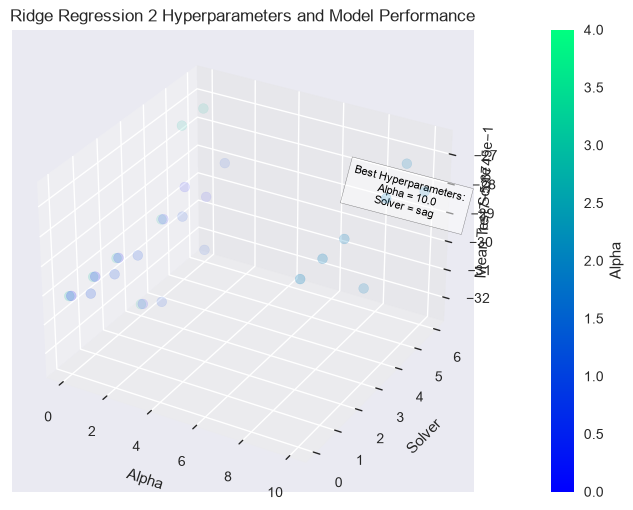

In [11]:
#Crerating a 3D scatter plot to visualise hyperparameters'
#performance for Ridge Model 2 and corresponding test scores
#On the plot, teh relationship between alpha and solver
# and mean test score (Ridge Model 2) is shown
# the best hyperparameters are annotated with text
# Creating a 3D figure
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
# From the grid search object, obtaining 
#hyperparameters and corresponding scores 
alpha = Ridge_Grid.cv_results_['param_alpha'].data.astype(float)
solver = Ridge_Grid.cv_results_['param_solver'].data
scores = Ridge_Grid.cv_results_['mean_test_score']
# Obtainig the best model's index 
best_model_index = scores.argmax()
# Defining a colormap based on the alpha parameter
cmap = plt.get_cmap('winter')
norm = colors.Normalize(vmin = 0, vmax = len(set(alpha)))
# Creating an array of colors based on the alpha parameter,
#where each category has a different color assigned
point_colors = [cmap(norm(list(set(alpha)).index(a))) for a in alpha]
# Mapping solver values to numbers
solver_mapping = {'auto': 0, 'svd': 1, 'cholesky': 2,
                  'lsqr': 3, 'sparse_cg': 4, 'sag': 5, 'saga': 6}
solver_numbers = [solver_mapping[s] for s in solver]
# Creating a scatter plot with hyperparameters on the x (alpha), 
#y (solver), and z (mean test score) axes, 
#and the model performance as each point's size
ax.scatter(alpha, solver_numbers, scores, c = point_colors,
           alpha=0.5, s=50)
# Setting axis labels and title
ax.set_xlabel('Alpha', labelpad=10)
ax.set_ylabel('Solver', labelpad=10)
ax.set_zlabel('Mean Test Score', labelpad=-5)
ax.set_title('Ridge Regression 2 Hyperparameters and Model Performance')
# Adding  a colorbar for the alpha parameter
cb = fig.colorbar(cm.ScalarMappable(norm=norm, 
                                    cmap=cmap), pad=0.1, ax=ax)
cb.set_label('Alpha')
# Adding text annotation for best Ridge2 hyperparameters
best_alpha = alpha[best_model_index]
best_solver = solver[best_model_index]
ax.text(best_alpha, solver_mapping[best_solver],
        scores[best_model_index],
        f"Best Hyperparameters:\nAlpha = {best_alpha}\nSolver = {best_solver}",
        color='black', fontsize=8, 
        bbox=dict(facecolor='white', alpha=0.5),
        zorder=0, ha='center', va='top', zdir='x')
plt.show();

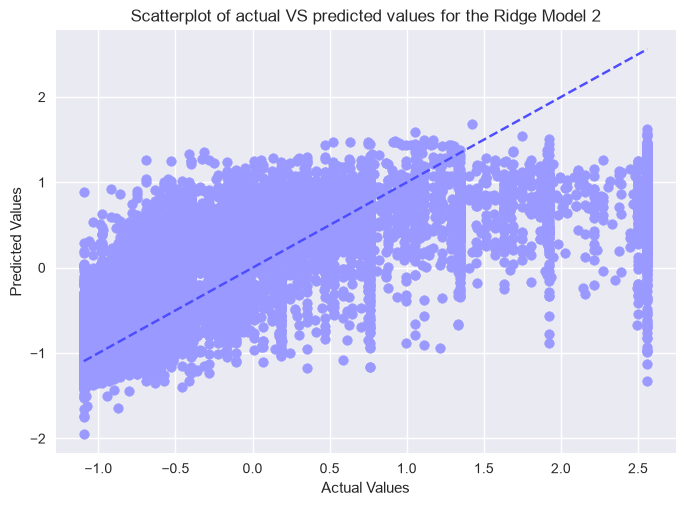

In [12]:
# Creating a scatterplot of actual VS predicted values for Ridge Model 2
plt.scatter(y_test_std, y_pred_test_Ridge_2, color = '#9999ff')
# Adding the plot title and axis labels
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Scatterplot of actual VS predicted values for the Ridge Model 2')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()], 
         [y_test_std.min(), y_test_std.max()], linestyle = '--', c = '#4d4dff')
plt.show();

## 4.2. RF_Regression_2

In [14]:
# Instantiating the RF model 2
RF_model_2 = RandomForestRegressor(n_estimators=100, random_state=28)
# Defining the cross-validation object
cv = KFold(n_splits=5, shuffle=True, random_state=28)
# Timing the training process
start_time_RF_2 = time.time()
# Fit the model to the training data
RF_model_2.fit(X_train2, y_train2_std.ravel())
# End time
end_time_RF_2 = time.time()
# Demonstrating the coefficients of the RF Regression Model 2
pd.DataFrame(RF_model_2.feature_importances_,
              df_merged.drop('price_dollars', axis = 1).columns,
              columns = ['Importances']).sort_values(by = 'Importances', 
                                                     ascending = False).round(4)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",28
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

,Importances
Entire home/apt,0.3316
longitude,0.1244
latitude,0.0873
Days_per_year_available,0.0522
Unnamed: 0,0.0436
Big_private_Studio_by_Astoria,0.0326
Piece_and_Quiet,0.0320
Prime_Stuite_with_large_bed_and_floor,0.0315
Quiet_East_Place_with_Garden,0.0314
Luxury_Place,0.0311


In [15]:
# Calculating the time taken for cross-validation
training_time_RF_2 = end_time_RF_2  - start_time_RF_2
print(f'Training time for RF Model 2: {training_time_RF_2:.4f} seconds')

Training time for RF Model 2: 34.3072 seconds


In [16]:
# Timing the training process
start_time_CV_RF_2 = time.time()
# Computing the mean R2, MSE, and MAE over the different folds
R2_RF_2_CV = cross_val_score(RF_model_2, X_train2, y_train2_std.ravel(), cv=cv, scoring='r2').mean()
MSE_RF_2_CV = -cross_val_score(RF_model_2, X_train2, y_train2_std.ravel(), cv=cv, scoring='neg_mean_squared_error').mean()
MAE_RF_2_CV = -cross_val_score(RF_model_2, X_train2, y_train2_std.ravel(), cv=cv, scoring='neg_mean_absolute_error').mean()
# End time
end_time_CV_RF_2 = time.time()

In [17]:
# Calculating the time taken for cross-validation
elapsed_time_CV_RF_2 = end_time_CV_RF_2 - start_time_CV_RF_2
print(f'The Cross-validation time for RF Model 2: {elapsed_time_CV_RF_2:.4f} seconds')
# Calculating the total training time for RF Model 2
total_training_time_RF_2 = training_time_RF_2 + elapsed_time_CV_RF_2
print(f'Total raining time for RF Model 2: {total_training_time_RF_2:.4f} seconds')

The Cross-validation time for RF Model 2: 371.5654 seconds
Total raining time for RF Model 2: 405.8726 seconds


In [18]:
# Predicting on the training set
y_pred_train_RF_2 = RF_model_2.predict(X_train2)
# Evaluating the RF model 2 on the training set
R2_RF_2_train = r2_score(y_train2_std, y_pred_train_RF_2)
MSE_RF_2_train = mean_squared_error(y_train2_std, y_pred_train_RF_2)
MAE_RF_2_train = mean_absolute_error(y_train2_std, y_pred_train_RF_2)
# Printing the evaluation metrics on the training set
print(f'The R-squared of the Random Forest 2 on the training set: {R2_RF_2_train * 100:.2f}%')
print(f'The MSE of the Random Forest 2 on the training set: {MSE_RF_2_train:.2f}')
print(f'The MAE of the Random Forest 2 on the training set: {MAE_RF_2_train:.2f}')

The R-squared of the Random Forest 2 on the training set: 93.62%
The MSE of the Random Forest 2 on the training set: 0.06
The MAE of the Random Forest 2 on the training set: 0.18


In [19]:
# Printing the mean R2, MSE, and MAE over the different folds
print(f'Mean R-squared of the Random Forest 2 for Cross-Validation: {R2_RF_2_CV * 100:.2f}%')
print(f'Mean MSE of the Random Forest 2 for Cross-Validation: {MSE_RF_2_CV:.2f}')
print(f'Mean MAE of the Random Forest 2 for Cross-Validation: {MAE_RF_2_CV:.2f}')

Mean R-squared of the Random Forest 2 for Cross-Validation: 53.91%
Mean MSE of the Random Forest 2 for Cross-Validation: 0.46
Mean MAE of the Random Forest 2 for Cross-Validation: 0.48


In [20]:
# Predicting on the test set
y_pred_test_RF_2 = RF_model_2.predict(X_test)
# Evaluating the RF model on the test set
R2_RF_2_test = r2_score(y_test_std, y_pred_test_RF_2)
MSE_RF_2_test = mean_squared_error(y_test_std, y_pred_test_RF_2)
MAE_RF_2_test = mean_absolute_error(y_test_std, y_pred_test_RF_2)
# Printing the evaluation metrics on the test set
print(f'The R-squared of the Random Forest 2 on the test set: {R2_RF_2_test * 100:.2f}%')
print(f'The MSE of the Random Forest 2 on the test set: {MSE_RF_2_test:.2f}')
print(f'The MAE of the Random Forest 2 on the test set: {MAE_RF_2_test:.2f}')

The R-squared of the Random Forest 2 on the test set: 55.13%
The MSE of the Random Forest 2 on the test set: 0.45
The MAE of the Random Forest 2 on the test set: 0.47


#### Visualising

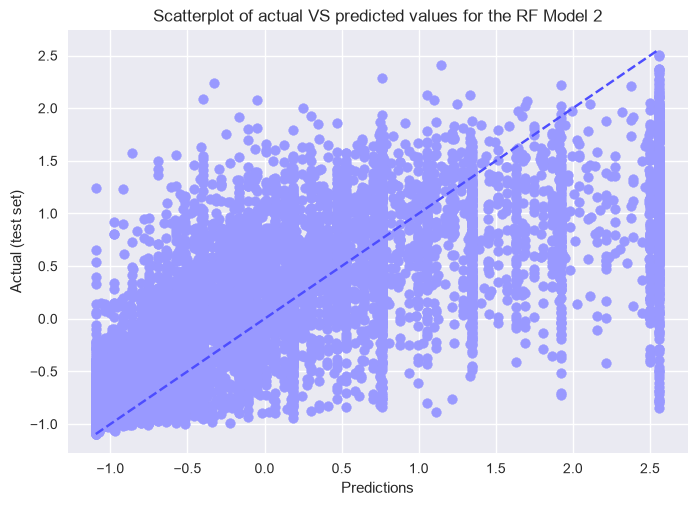

In [21]:
# plotting the scatter plot of actual VS Predicted Values for RF 2
plt.scatter(y_test_std, y_pred_test_RF_2, color = '#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle = '--', c = '#4d4dff')
#Adding axes labels and title
plt.xlabel('Predictions')
plt.ylabel('Actual (test set)')
plt.title('Scatterplot of actual VS predicted values for the RF Model 2')
plt.show();

## 4.3. RF_Regression_3: Grid Search

When using cv, the overfitting risk is reduced. However, upon too many hyperparameters in the grid search, a model that performs well on cv, yet, 
has a poor generalisation to test data can be selected. Thus, CONSTRAINING THE HYPERPARAMETER SEARCH SPACE  to mitigate this issue, selecting solely the hyperparameters considered the most important and limiting the possible values' range

In [23]:
# Defining the hyperparameter grid for the RF Regression
param_grid_RF_3 = {
    # number of trees in the forest 
    'n_estimators': [100, 500, 1000],
    #defining how deep each tree can go
    'max_depth': [5, 10, 20],
    #n features to consider upon determining the 
    #best tree split
    'max_features': [1.0, 'sqrt']
}
#1.0 - all features (the old 'auto' option, removed in scikit-learn 1.3)
#sqrt - sqrt from N features
#n_estimator controls for n_trees built in the ensemble
#max_depth - selecting deeper trees can capture more intricate 
#data patterns, however, present an overfitting risk
#thus, selecting 5,10,and 20
#max_features can aid to mitigate overfitting via limiting 
# N features trees can utilise 
#srt - sqrt from N features

In [24]:
# Instantiating the RF model
RF_model_3 = RandomForestRegressor(random_state=28)
# Defining the cross-validation object
cv = KFold(n_splits=5, shuffle=True, random_state=28)
# Creating a GridSearch object
RF_3_Grid = GridSearchCV(estimator=RF_model_3,
                         param_grid=param_grid_RF_3, cv=cv, 
                       scoring='neg_mean_squared_error',
                         n_jobs=-1, verbose=2)

In [25]:
# Timing the training process
start_time_grid_RF_3 = time.time()
# Fitting the GridSearch object on the training data
RF_3_Grid.fit(X_train2, y_train2_std.ravel())
# End time
end_time_grid_RF_3 = time.time()

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ....max_depth=5, max_features=1.0, n_estimators=100; total time=  12.7s
[CV] END ....max_depth=5, max_features=1.0, n_estimators=500; total time= 1.2min
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=500; total time=  13.1s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=500; total time=  19.5s
[CV] END ..max_depth=5, max_features=sqrt, n_estimators=1000; total time=  30.8s
[CV] END ...max_depth=10, max_features=1.0, n_estimators=100; total time=  21.3s
[CV] END ...max_depth=10, max_features=1.0, n_estimators=500; total time= 1.9min
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   4.9s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   5.0s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=500; total time=  19.8s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=500; total time=  20.3s
[CV] END .max_depth=10, max_features=sqrt, n_est

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ....max_depth=5, max_features=1.0, n_estimators=500; total time= 1.1min
[CV] END ...max_depth=5, max_features=1.0, n_estimators=1000; total time= 2.2min
[CV] END ..max_depth=10, max_features=1.0, n_estimators=1000; total time= 4.1min
[CV] END ...max_depth=20, max_features=1.0, n_estimators=500; total time= 2.8min
[CV] END ....max_depth=5, max_features=1.0, n_estimators=500; total time= 1.1min
[CV] END ...max_depth=5, max_features=1.0, n_estimators=1000; total time= 2.2min
[CV] END ..max_depth=10, max_features=1.0, n_estimators=1000; total time= 4.1min
[CV] END ...max_depth=20, max_features=1.0, n_estimators=500; total time= 2.8min
[CV] END ....max_depth=5, max_features=1.0, n_estimators=100; total time=  12.7s
[CV] END ....max_depth=5, max_features=1.0, n_estimators=500; total time= 1.1min
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=500; total time=  13.2s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=500; total time=  19.2s
[CV] END ..max_depth=5, max_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=28)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': [1.0, 'sqrt'], 'n_estimators': [100, 500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sph

In [26]:
# Calculating the elapsed time of the Grid Search for RF Model 3
elapsed_time_grid_RF_3 = end_time_grid_RF_3 - start_time_grid_RF_3
print(f"Grid search training time for RF Model 3: {elapsed_time_grid_RF_3:.4f} seconds")

Grid search training time for RF Model 3: 991.8777 seconds


In [27]:
# Obtaining the best hyperparameters
best_params_RF_3 = RF_3_Grid.best_params_
print(f'Best hyperparameters for Random Forest Regressor: {best_params_RF_3}')

Best hyperparameters for Random Forest Regressor: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 1000}


In [28]:
# Creating a Random Forest Regressor with the best hyperparameters
#unpacking the values from the best_params_RF_3 dictionnary (**)
RF_model_3_best = RandomForestRegressor(**best_params_RF_3, 
                                        random_state=28)
# Timing the training process
start_time_RF_3 = time.time()
# Fitting the model on the whole training data
RF_model_3_best.fit(X_train2, y_train2_std.ravel())
# End time
end_time_RF_3 = time.time()
# Demonstrating the coefficients of the Lasso Regression Model 
pd.DataFrame(RF_model_3_best.feature_importances_,
              df_merged.drop('price_dollars', axis = 1).columns,
              columns = ['Importances']).sort_values(by = 'Importances', 
                                                     ascending = False).round(4)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",28
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease

,Importances
Entire home/apt,0.1806
Private room,0.1281
longitude,0.1105
latitude,0.0774
Days_per_year_available,0.0498
Unnamed: 0,0.0410
Manhattan,0.0364
Big_private_Studio_by_Astoria,0.0296
Quiet_East_Place_with_Garden,0.0292
Luxury_Place,0.0291


In [29]:
# Calculating the time taken for cross-validation
training_time_RF_3 = end_time_RF_3  - start_time_RF_3
print(f'Training time for RF Model 3: {training_time_RF_3:.4f} seconds')
#Calculating the total tarining time with grid search
total_training_time_RF_3 = elapsed_time_grid_RF_3 + training_time_RF_3
print(f'Total raining time for RF Model 3: {total_training_time_RF_3:.4f} seconds')

Training time for RF Model 3: 69.9395 seconds
Total raining time for RF Model 3: 1061.8172 seconds


In [30]:
# Predicting on the training set
y_pred_train_RF_3 = RF_model_3_best.predict(X_train2)
# Evaluating theRF model on the training set
R2_RF_3_train = r2_score(y_train2_std, y_pred_train_RF_3)
MSE_RF_3_train = mean_squared_error(y_train2_std, y_pred_train_RF_3)
MAE_RF_3_train = mean_absolute_error(y_train2_std, y_pred_train_RF_3)
# Printing the evaluation metrics on the training set
print(f'The R-squared of the Random Forest 3 on the training set: {R2_RF_3_train * 100:.2f}%')
print(f'The MSE of the Random Forest 3 on the training set: {MSE_RF_3_train:.2f}')
print(f'The MAE of the Random Forest 3 on the training set: {MAE_RF_3_train:.2f}')

The R-squared of the Random Forest 3 on the training set: 88.90%
The MSE of the Random Forest 3 on the training set: 0.11
The MAE of the Random Forest 3 on the training set: 0.24


In [31]:
# Predicting on the test set
y_pred_test_RF_3 = RF_model_3_best.predict(X_test)
# Evaluaing the RF model on the test set
R2_RF_3_test = r2_score(y_test_std, y_pred_test_RF_3)
MSE_RF_3_test = mean_squared_error(y_test_std, y_pred_test_RF_3)
MAE_RF_3_test = mean_absolute_error(y_test_std, y_pred_test_RF_3)
# Printing the evaluation metrics on the test set
print(f'The R-squared of the Random Forest 3 on the test set: {R2_RF_3_test* 100:.2f}%')
print(f'The MSE of the Random Forest 3 on the test set: {MSE_RF_3_test:.2f}')
print(f'The MAE of the Random Forest 3 on the test set: {MAE_RF_3_test:.2f}')

The R-squared of the Random Forest 3 on the test set: 55.84%
The MSE of the Random Forest 3 on the test set: 0.44
The MAE of the Random Forest 3 on the test set: 0.47


#### Visualising

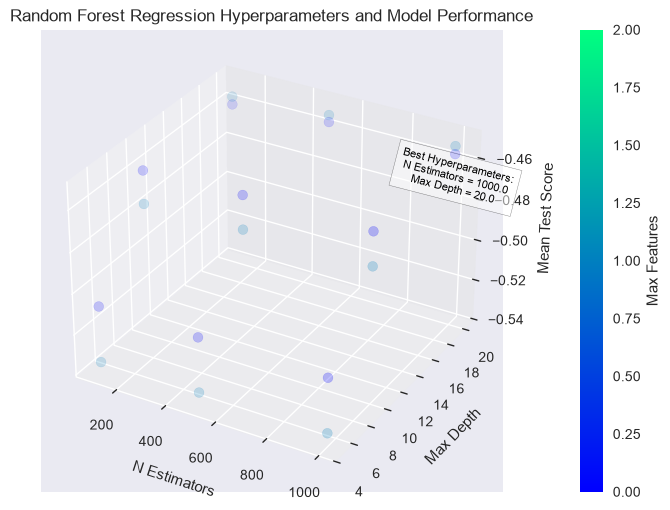

In [32]:
# Creating a 3D Scatter plot to visualise hyperparameters' performance
#for RF Model 3 and correspondoing Test Scores
#Each point will represent a different hyperparameter combination, 
#and each point's size - the RF Model's performance
# Creating a 3D figure
fig = plt.figure(figsize = (10, 6))
ax = fig.add_subplot(111, projection='3d')
# From the grid search object, obtaining hyperparameters 
#and corresponding scores
n_estimators = RF_3_Grid.cv_results_['param_n_estimators'].data.astype(float)
max_depth = RF_3_Grid.cv_results_['param_max_depth'].data.astype(float)
max_features = RF_3_Grid.cv_results_['param_max_features'].data
scores = RF_3_Grid.cv_results_['mean_test_score']
# Obtaining the best model's index
best_model_index = scores.argmax()
# Defining a colormap based on the 'max_features' parameter
cmap = plt.get_cmap('winter')
norm = colors.Normalize(vmin = 0, vmax = len(set(max_features)))
# Creating a colors list based on 'max_features' parameter, where each colour will 
#correspond to the unique parameter's value
#(maximum # features considered upon the DT node split)
point_colors = [cmap(norm(list(set(max_features)).index(mf))) for mf in max_features]
# Creating a scatter plot with the hyperparameters 
#on the x (n_estimators), y (max_depth)
# and z (mean test score) axes, and the model
#performance as each point's size
ax.scatter(n_estimators, max_depth, scores, c = point_colors, 
           alpha = 0.5, s = 50)
# Setting axes labels and title
ax.set_xlabel('N Estimators', labelpad = 10)
ax.set_ylabel('Max Depth', labelpad = 10)
ax.set_zlabel('Mean Test Score', labelpad = 10)
ax.set_title('Random Forest Regression Hyperparameters and Model Performance')
# Adding a colorbar for the 'max_features' parameter
cb = fig.colorbar(cm.ScalarMappable(norm = norm, cmap = cmap), pad = 0.1, ax = ax)
cb.set_label('Max Features')
# Adding text annotation for the best RF model's hyperparameters
best_n_estimators = n_estimators[best_model_index]
best_max_depth = max_depth[best_model_index]
ax.text(best_n_estimators, best_max_depth, scores[best_model_index],
        f"Best Hyperparameters:\nN Estimators = {best_n_estimators}\nMax Depth = {best_max_depth}",
        color = 'black', fontsize = 8, bbox = dict(facecolor = 'white', alpha = 0.5),
        zorder = 0, ha = 'center', va = 'top', zdir = 'x')
plt.show();

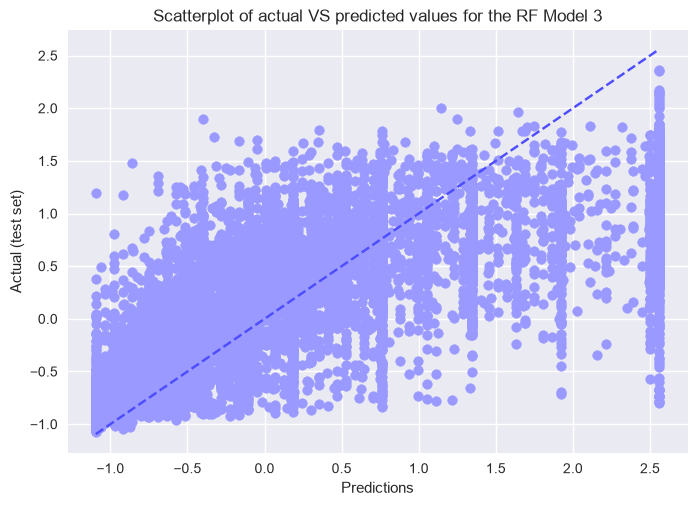

In [33]:
# plotting the scatter plot of Actual VS Predicted Values for RF Model 3
plt.scatter(y_test_std, y_pred_test_RF_3, color = '#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle = '--', c = '#4d4dff')
#ading axes labels and title
plt.xlabel('Predictions')
plt.ylabel('Actual (test set)')
plt.title('Scatterplot of actual VS predicted values for the RF Model 3')
plt.show();

## 4.4. XGB_2: Grid Search

Similarly to RF, selecting the 3 hyperparameters deemed the most important in determining the model's performance
(** same values for n_estimators and max_depth were utilised as for the RF grid)

In [4]:
# Defining the hyperparameter grid

#n_estimaors -> # trees / boosting rounds to build 
#in the ensemble
#max_depth - how deep the tree can go
param_grid_XGB_2 = {'n_estimators': [100, 500, 1000],
              'max_depth': [5, 10, 20],
              'learning_rate': [0.01, 0.1, 0.2]}
#learning rate/ shrinkage parameter -> controlling the 
#contribution of every tree to the final model
#(smaller lr - usually result in more conservative 
#models with less overfitting. however, they require 
#'boosting rounds ' to attain good performance

In [6]:
# Create an instance of XGBRegressor
XGB_model_2 = xgb.XGBRegressor(seed=28)
# Defining the cross-validation object
cv = KFold(n_splits=5, shuffle=True, random_state=28)
# Creating a GridSearchCV object with 5-fold cross validation
#n_jobs=-1 - due to computational constraints
grid_search_XGB_2 = GridSearchCV(estimator=XGB_model_2, param_grid=param_grid_XGB_2,
                                 scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

In [7]:
# Timing the grid search training process
start_time_grid_XGB_2 = time.time()
# Fit the grid search object on the training data
grid_search_XGB_2.fit(X_train2, y_train2_std.ravel())
# End time
end_time_grid_XGB_2 = time.time()

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [5, 10, ...], 'n_estimators': [100, 500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multicl

In [8]:
# Calculating the elapsed time of the Grid Search for RF Model 3
elapsed_time_grid_XGB_2 = end_time_grid_XGB_2 - start_time_grid_XGB_2
print(f"Grid search training time for XGB Model 2: {elapsed_time_grid_XGB_2:.4f} seconds")

Grid search training time for XGB Model 2: 2278.9145 seconds


In [9]:
best_params_XGB_2 = grid_search_XGB_2.best_params_
# Printing the best hyperparameters
print("Best Hyperparameters: ", best_params_XGB_2)

Best Hyperparameters:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [10]:
# Creating a XGBRegressor with the best hyperparameters
XGB_model_2_best = xgb.XGBRegressor(**best_params_XGB_2, seed=28)
# Timing the training process
start_time_XGB_2 = time.time()
# Fitting the model on the training data
XGB_model_2_best.fit(X_train2, y_train2_std.ravel())
# End time
end_time_XGB_2 = time.time()
# Demonstrating the coefficients of the Lasso Regression Model 
pd.DataFrame(XGB_model_2_best.feature_importances_,
              df_merged.drop('price_dollars', axis = 1).columns,
              columns = ['Importances']).sort_values(by = 'Importances', 
                                                     ascending = False).round(4)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


,Importances
Entire home/apt,0.7176
longitude,0.0559
latitude,0.0371
Manhattan,0.0299
Days_per_year_available,0.0256
minimum_nights,0.0230
number_of_reviews,0.0173
total_host_listings,0.0126
Unnamed: 0,0.0116
reviews_per_month,0.0100


In [11]:
# Calculating the time taken for training
training_time_XGB_2 = end_time_XGB_2 - start_time_XGB_2
print(f'Training time of XGB Model 2: {training_time_XGB_2:.4f} seconds')
#Calculating the total tarining time with grid search
total_training_time_XGB_2 = elapsed_time_grid_XGB_2 + training_time_XGB_2
print(f'Total raining time for XGB Model 2: {total_training_time_XGB_2 / 60 :.4f} mimutes')

Training time of XGB Model 2: 0.2643 seconds
Total raining time for XGB Model 2: 37.9863 mimutes


In [12]:
# Predicting the target values on the training data using the trained model
y_pred_XGB_2_train = XGB_model_2_best.predict(X_train2)
# Evaluating the model performance on the training data using the R2, MSE and MAE
R2_XGB_2_train = r2_score(y_train2_std, y_pred_XGB_2_train)
MSE_XGB_2_train = mean_squared_error(y_train2_std, y_pred_XGB_2_train)
MAE_XGB_2_train = mean_absolute_error(y_train2_std, y_pred_XGB_2_train)
#printing the scores
print(f'The R-squared of the XGBoost Regression 2 on the training set: {R2_XGB_2_train * 100:.2f}%')
print(f'The MSE of the XGBoost Regression 2 on the training set: {MSE_XGB_2_train:.2f}')
print(f'The MAE of the XGBoost Regression 2 on the training set is: {MAE_XGB_2_train:.2f}')

The R-squared of the XGBoost Regression 2 on the training set: 59.78%
The MSE of the XGBoost Regression 2 on the training set: 0.40
The MAE of the XGBoost Regression 2 on the training set is: 0.45


In [13]:
# Predicting the target values on the test data using the trained model
y_pred_XGB_2_test = XGB_model_2_best.predict(X_test)
# Evaluating the model performance on the test data using the R2, MSE and MAE
R2_XGB_2_test = r2_score(y_test_std, y_pred_XGB_2_test)
MSE_XGB_2_test = mean_squared_error(y_test_std, y_pred_XGB_2_test)
MAE_XGB_2_test = mean_absolute_error(y_test_std, y_pred_XGB_2_test)
#printing the scores
print(f'The R-squared of the XGBoost Regression 2 on the test set: {R2_XGB_2_test * 100:.2f}%')
print(f'The MSE of the XGBoost Regression 2 on the test set: {MSE_XGB_2_test:.2f}')
print(f'The MAE of the XGBoost Regression 2 on the test set is: {MAE_XGB_2_test:.2f}')

The R-squared of the XGBoost Regression 2 on the test set: 56.37%
The MSE of the XGBoost Regression 2 on the test set: 0.44
The MAE of the XGBoost Regression 2 on the test set is: 0.46


#### Visualising

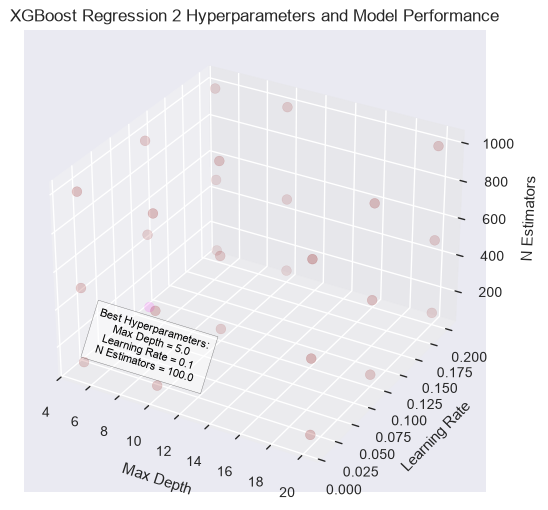

In [14]:
# Creating a 3D figure
fig = plt.figure(figsize = (10, 6))
ax = fig.add_subplot(111, projection ='3d')
# From the Grid Search Object, obtaining the best hyperparameters and corresponding scores
max_depth = grid_search_XGB_2.cv_results_['param_max_depth'].data.astype(float)
learning_rate = grid_search_XGB_2.cv_results_['param_learning_rate'].data.astype(float)
n_estimators = grid_search_XGB_2.cv_results_['param_n_estimators'].data.astype(float)
scores = grid_search_XGB_2.cv_results_['mean_test_score']
# Obtaining the best XGB Model's index 
best_model_index = scores.argmax()
# Defining the colour map and mormalising the scores
cmap = plt.get_cmap('cool') 
norm = colors.Normalize(vmin = scores.min(), vmax = scores.max())
# Creating a colours list assigning a bright colour to the best performing model
point_colors = [cmap(norm(score)) if i == best_model_index else colors.to_rgba('darkred') for i, score in enumerate(scores)]
# Creating a scatter plot with hyperparameters on the x (max_depth), y (learning_rate)
#and z (n_estimators) axes, and GXB 2 performance as each point's size
ax.scatter(max_depth, learning_rate, n_estimators, c = point_colors, alpha = 0.5, s = 50)
# Setting axes labels and title
ax.set_xlabel('Max Depth', labelpad = 10)
ax.set_ylabel('Learning Rate', labelpad = 10)
ax.set_zlabel('N Estimators', labelpad = 10)
ax.set_title('XGBoost Regression 2 Hyperparameters and Model Performance')
# Adding annotations for best XGB 2 hyperparameters
best_max_depth = max_depth[best_model_index]
best_learning_rate = learning_rate[best_model_index]
best_n_estimators = n_estimators[best_model_index]
ax.text(best_max_depth, best_learning_rate, best_n_estimators,
        f"Best Hyperparameters:\nMax Depth = {best_max_depth}\nLearning Rate = {best_learning_rate}\nN Estimators = {best_n_estimators}",
        color = 'black', fontsize = 8, bbox = dict(facecolor = 'white', alpha = 0.5),
        zorder = 0, ha = 'center', va = 'top', zdir = 'x')
plt.show();

/var/folders/30/5ygxtbks68d9_2ftg_q1wr2m0000gn/T/ipykernel_41228/138113848.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test_std.min(), y_test_std.max()],


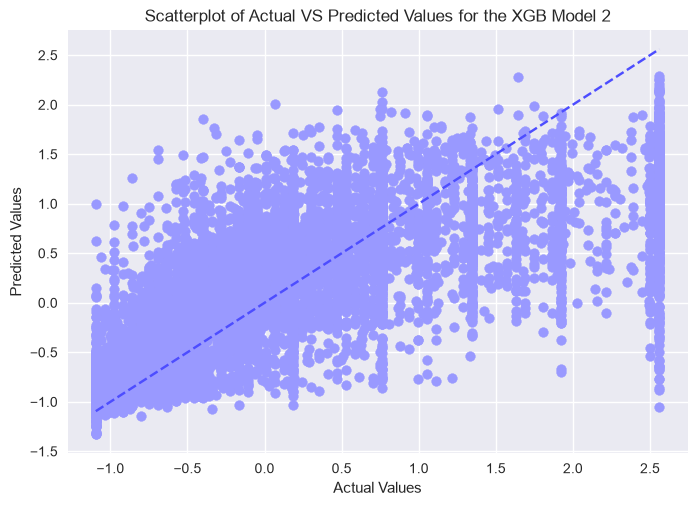

In [15]:
# Creating a scatterplot of actual VS predicted values for XGB 2
plt.scatter(y_test_std, y_pred_XGB_2_test, color = '#9999ff')
# Adding the plot title and axis labels
plt.title('Scatterplot of Actual VS Predicted Values for the XGB Model 2')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()], 
         [y_test_std.min(), y_test_std.max()], 'k--', c = '#4d4dff')
plt.show();

## 4.5. MLP_Model_9_Keras (increased the number of layers and neurons)

Increasing the number of layers and neurons to capture more intricate data patterns and obtain higher representation power. Additionally, deep neutworks possess larger capacity, resulting in implicit regularisation and capturing more intricate functions, yet are prone to overfitting (Srinivas & Babu, 2015).

In [4]:
#Defining the function to calculate the R2 score (coefficient of determination)  
#between true and predicted values
from keras import ops
def coeff_determination(y_true, y_pred):
    SS_res = ops.sum(ops.square(y_true-y_pred))
    SS_tot = ops.sum(ops.square(y_true - ops.mean(y_true)))
    return (1 - SS_res/(SS_tot + K.epsilon()))

In [6]:
#adding more layers and decreasing # neurons in each 
#subsequent layer
MLP_Model_Keras_9 = Sequential([
    keras.layers.Dense(units=64, input_dim=X_train_std.shape[1], 
                       activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(units=32, activation='relu', 
                       kernel_initializer='he_normal'),
    keras.layers.Dense(units=16, activation='relu',
                       kernel_initializer='he_normal'),
    keras.layers.Dense(units=8, activation='relu',
                       kernel_initializer='he_normal'),
    keras.layers.Dense(units=8, activation='relu', 
                       kernel_initializer='he_normal'),
    keras.layers.Dense(units=1)
])
opt = keras.optimizers.Adam(learning_rate=0.001)

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
MLP_Model_Keras_9.compile(optimizer=opt, loss='MSE', 
                   metrics=['mse', 'mae', coeff_determination])
start_time_Keras_9 =  time.time()
history_MLP_9 = MLP_Model_Keras_9.fit(X_train_std, y_train_std, 
                                              epochs=50, batch_size=32, 
                                              validation_data=(X_val_std, y_val_std), 
                                              verbose=0)
#end time
end_time_Keras_9 = time.time()

In [8]:
#calculating the training time
elapsed_time_Keras_9 = end_time_Keras_9 - start_time_Keras_9
print(f"Elapsed time: {elapsed_time_Keras_9:.2f} seconds")

Elapsed time: 32.84 seconds


In [9]:
#predicting on the test set 
y_pred_MLP_Keras_9_test = MLP_Model_Keras_9.predict(X_test_std)
# Evaluating MLP model on the test set
##utilising the evaluate() method is a method, specific to the Keras API 
#for Neural Networks
test_loss_MLP_Keras_9, test_mse_MLP_Keras_9, test_mae_MLP_Keras_9, test_r2_MLP_Keras_9 = MLP_Model_Keras_9.evaluate(X_test_std, 
                                                                     y_test_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_9_test = test_loss_MLP_Keras_9
R2_MLP_Keras_9_test = test_r2_MLP_Keras_9
MSE_MLP_Keras_9_test = test_mse_MLP_Keras_9
MAE_MLP_Keras_9_test = test_mae_MLP_Keras_9
#Printing the metrics on the test set
print(f'The loss MLP Keras Model 9 on the test set:  {loss_MLP_Keras_9_test:.4f}')
print(f'The R-squared of the MLP Keras Model 9 on the test set:  {R2_MLP_Keras_9_test:.4f}')
print(f'The MSE of the MLP Keras Model 9 on the test set:   {MSE_MLP_Keras_9_test:.4f}')
print(f'The MAE of the MLP Keras Model 9 on the test set:  {MAE_MLP_Keras_9_test:.4f}')

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - coeff_determination: 0.4230 - loss: 0.5405 - mae: 0.5170 - mse: 0.5405
The loss MLP Keras Model 9 on the test set:  0.5405
The R-squared of the MLP Keras Model 9 on the test set:  0.4230
The MSE of the MLP Keras Model 9 on the test set:   0.5405
The MAE of the MLP Keras Model 9 on the test set:  0.5170


#### Visualising

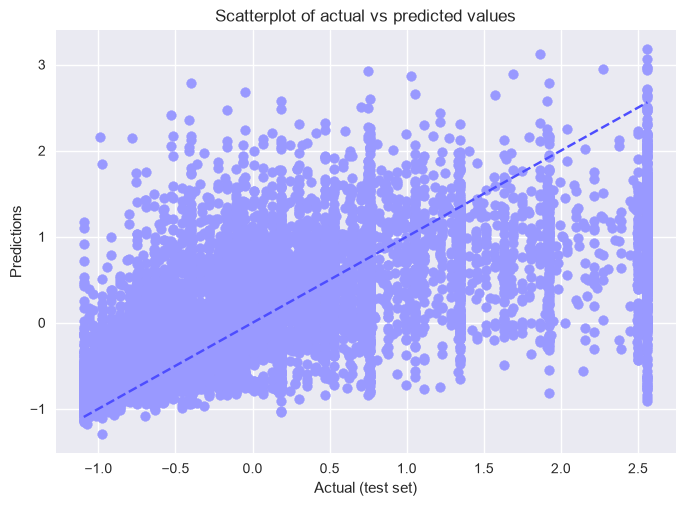

In [10]:
# plotting the scatter plot
plt.scatter(y_test_std, y_pred_MLP_Keras_9_test, color = '#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle = '--', c = '#4d4dff')
#adding the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual vs predicted values')
plt.show();

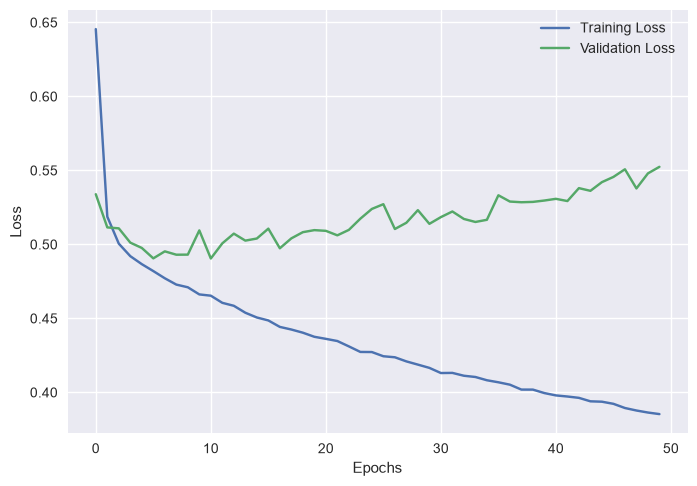

In [11]:
# Plotting the training and validation loss curves
plt.plot(history_MLP_9.history['loss'], label='Training Loss')
plt.plot(history_MLP_9.history['val_loss'], label='Validation Loss')
# Adding labels and legends
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

Given that the dataset could be small for the model architecture, it overfitted. Thus, next models will implement regularisation techniques to enhance generalisation.

## 4.6.MLP_10: Dropout Layers

This model will randomly deactivate a certain neurons' proportion upon training to prevent model's reliance on any single neuron, increasing network sparcity. Thus, 'noise' is introduced to the training process, averaging and increasing model generalisation(Taud & Mas, 2018). Adding higher droppout to initial features for the model to have higher robustness to noise and learn diverse input data representations.Gradually-decreasing dropout layers to allow the model to progressively-learn higher-level features.

In [13]:
MLP_Model_Keras_10 = Sequential([
    tf.keras.layers.Dense(units=64, input_dim=X_train_std.shape[1], activation='relu'),
    Dropout(0.5),
    tf.keras.layers.Dense(units=32, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.3),
    tf.keras.layers.Dense(units=16, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.3),
    tf.keras.layers.Dense(units=8, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    tf.keras.layers.Dense(units=8, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.1),
    tf.keras.layers.Dense(units=1)
])
#same optimiser
opt = keras.optimizers.Adam(learning_rate=0.001)
MLP_Model_Keras_10.compile(optimizer=opt, loss='MSE', 
                   metrics=['mse', 'mae', coeff_determination])

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
#start of training process
start_time_Keras_10 = time.time()
history_MLP_10 = MLP_Model_Keras_10.fit(X_train_std, y_train_std, 
                                              epochs=50, batch_size=32, 
                                              validation_data=(X_val_std, y_val_std), 
                                              verbose=0)
#end time
end_time_Keras_10 = time.time()

In [15]:
#calculating the training time
elapsed_time_Keras_10 = end_time_Keras_10 - start_time_Keras_10
print(f"Elapsed time: {elapsed_time_Keras_10:.2f} seconds")

Elapsed time: 34.97 seconds


In [16]:
#predicting on the test set 
y_pred_MLP_Keras_10_test = MLP_Model_Keras_10.predict(X_test_std)
test_loss_MLP_Keras_10, test_mse_MLP_Keras_10, test_mae_MLP_Keras_10, test_r2_MLP_Keras_10 = MLP_Model_Keras_10.evaluate(X_test_std, 
                                                                     y_test_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_10_test = test_loss_MLP_Keras_10
R2_MLP_Keras_10_test = test_r2_MLP_Keras_10
MSE_MLP_Keras_10_test = test_mse_MLP_Keras_10
MAE_MLP_Keras_10_test = test_mae_MLP_Keras_10
#Printing the metrics on the test set
#print(f'The loss MLP Keras Model 1 on the test set:  {loss_MLP_Keras_1_test:.4f}')
print(f'The R-squared of the MLP Keras Model 10 on the test set:  {R2_MLP_Keras_10_test:.4f}')
print(f'The MSE of the MLP Keras Model 10 on the test set:   {MSE_MLP_Keras_10_test:.4f}')
print(f'The MAE of the MLP Keras Model 10 on the test set:  {MAE_MLP_Keras_10_test:.4f}')

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - coeff_determination: 0.4696 - loss: 0.5112 - mae: 0.5316 - mse: 0.5112
The R-squared of the MLP Keras Model 10 on the test set:  0.4696
The MSE of the MLP Keras Model 10 on the test set:   0.5112
The MAE of the MLP Keras Model 10 on the test set:  0.5316


#### Visualising

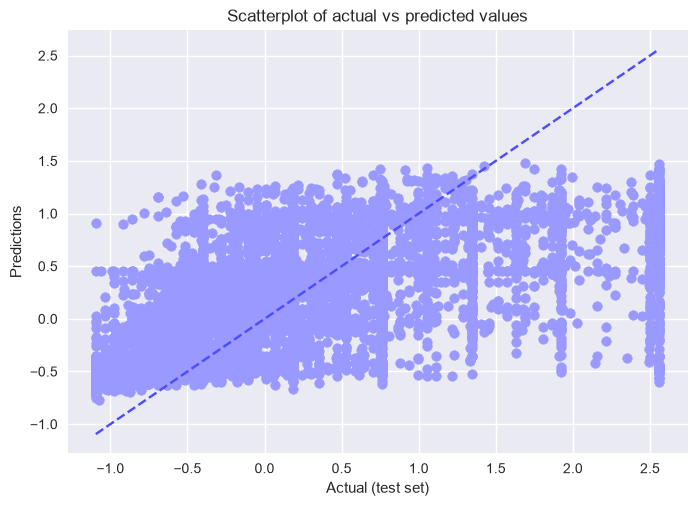

In [17]:
# plotting the scatter plot
plt.scatter(y_test_std, y_pred_MLP_Keras_10_test, color='#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle='--', c='#4d4dff')
# adding the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual vs predicted values')
plt.show();

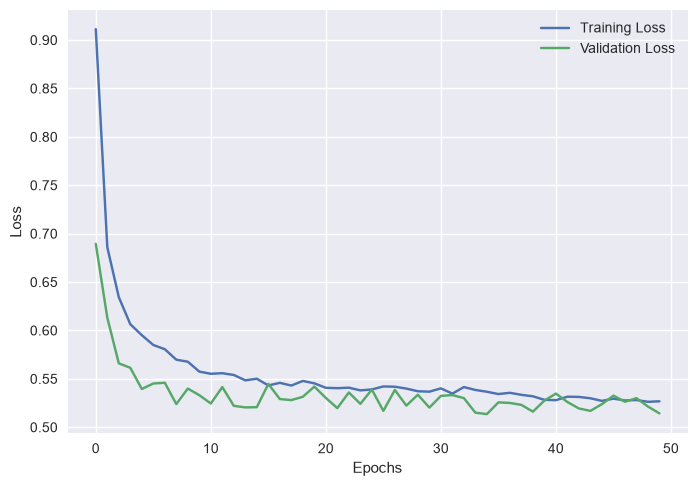

In [18]:
# Plotting the training and validation loss curves
plt.plot(history_MLP_10.history['loss'], label='Training Loss')
plt.plot(history_MLP_10.history['val_loss'], label='Validation Loss')
# Adding labels and legends
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

## 4.7. MLP_Model_11 (Reduced_Dropout and L1 Regularisation)

Combining Dropout and L1, since they have diverse mechanisms for overfitting prevention, complementing each other. L1 would boost the former regularisation via encouraging MLP weights' sparcity, preventing overfitting via indicating the model to focus on most important

In [20]:
MLP_Model_keras_11 = Sequential([
    keras.layers.Dense(units=64, input_dim=X_train_std.shape[1], activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=32, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=16, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=8, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=8, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=1)
])
#same optimiser
opt = keras.optimizers.Adam(learning_rate=0.001)
#utilising the same optimiser defined in Model 10
MLP_Model_keras_11.compile(optimizer=opt, loss='MSE',
                            metrics=['mse', 'mae', coeff_determination])

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
start_time_keras_11 = time.time()
history_MLP_11 = MLP_Model_keras_11.fit(X_train_std, y_train_std,
                                        epochs=50, batch_size=32,
                                        validation_data=(X_val_std, y_val_std),
                                        verbose=0)
end_time_keras_11 = time.time()

In [22]:
elapsed_time_keras_11 = end_time_keras_11 - start_time_keras_11
print(f"Elapsed time: {elapsed_time_keras_11:.2f} seconds")

Elapsed time: 34.92 seconds


In [23]:
# Predicting on the test set
y_pred_MLP_Keras_11_test = MLP_Model_keras_11.predict(X_test_std)
# Evaluating the performance of the MLP_Model_keras_11 on the test set
test_loss_MLP_keras_11, test_mse_MLP_keras_11, test_mae_MLP_keras_11, test_r2_MLP_keras_11 = MLP_Model_keras_11.evaluate(X_test_std, y_test_std)
# Saving the results to the variables to, consequently, compare the models
loss_MLP_keras_11_test = test_loss_MLP_keras_11
R2_MLP_keras_11_test = test_r2_MLP_keras_11
MSE_MLP_keras_11_test = test_mse_MLP_keras_11
MAE_MLP_keras_11_test = test_mae_MLP_keras_11
# Printing the metrics on the test set
print(f'The R-squared of the MLP_Model_keras_11 on the test set:  {R2_MLP_keras_11_test:.4f}')
print(f'The MSE of the MLP_Model_keras_11 on the test set:   {MSE_MLP_keras_11_test:.4f}')
print(f'The MAE of the MLP_Model_keras_11 on the test set:  {MAE_MLP_keras_11_test:.4f}')

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 319us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step - coeff_determination: 0.4918 - loss: 0.4886 - mae: 0.5108 - mse: 0.4886
The R-squared of the MLP_Model_keras_11 on the test set:  0.4918
The MSE of the MLP_Model_keras_11 on the test set:   0.4886
The MAE of the MLP_Model_keras_11 on the test set:  0.5108


#### Visualising

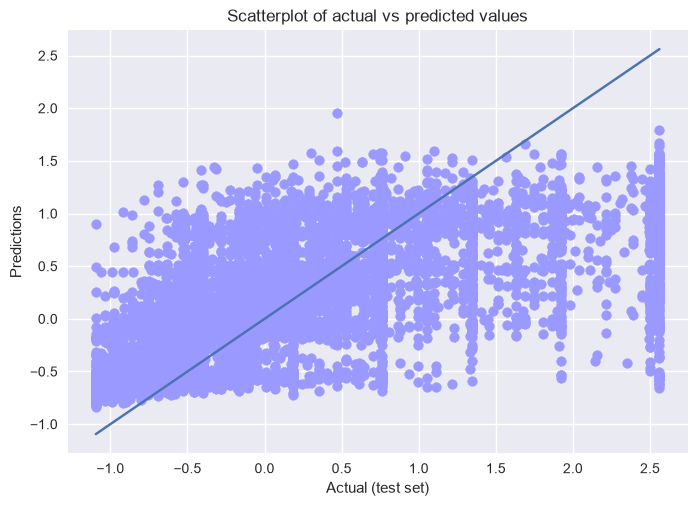

In [24]:
# plotting the scatter plot
plt.scatter(y_test_std, y_pred_MLP_Keras_11_test, color='#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()], [y_test_std.min(), y_test_std.max()])
# adding the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual vs predicted values')
plt.show();

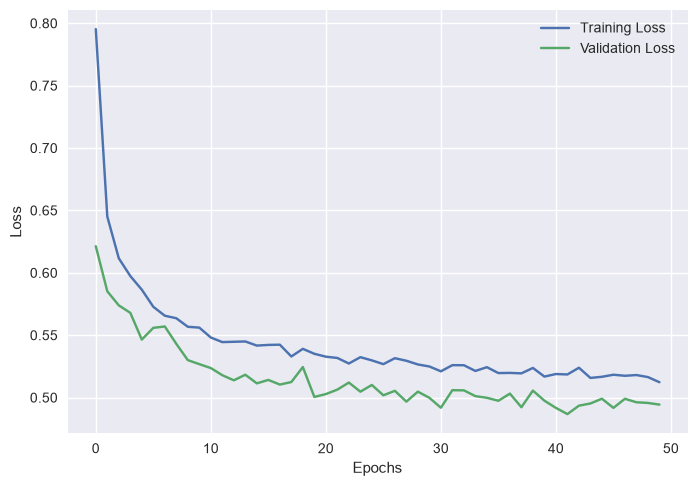

In [25]:
# Plotting the training and validation loss curves
plt.plot(history_MLP_11.history['loss'], label='Training Loss')
plt.plot(history_MLP_11.history['val_loss'], label='Validation Loss')
# Adding labels and legends
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

Traing and validation loss curve decrease together, however test predictive performance decreases. Thus, there could be an over-regularisation issue(Salehinejad&Valaee,2019).Thus, the next model will

## 4.8. MLP_12: Early_Stopping

Preventing overfitting via monitoring val_loss during traing and stopping after no improvement for 8 epochs.

In [9]:
# Defining the model architecture
MLP_Model_keras_12 = Sequential([
    keras.layers.Dense(units=64, input_dim=X_train_std.shape[1], activation='relu'),
    keras.layers.Dense(units=32, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(units=16, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(units=8, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(units=8, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(units=1)
])
#same optimiser
opt = keras.optimizers.Adam(learning_rate=0.001)
# Compiling the model
MLP_Model_keras_12.compile(optimizer=opt, loss='MSE', 
                   metrics=['mse', 'mae', coeff_determination])
# Setting up the early stopping
#monitor='val_loss' - monitoring val set loss during training
#patience -> epochs with no performance improvement after which training stops 
#verbose=1 - progress messages to be printed during training 
#mode='min' - making callack search for min val_loss value
#restore_best_weights=True - saving best performing model
# to shape predictions
early_stopping = EarlyStopping(monitor='val_loss', patience=8, 
                               verbose=1, mode='min', restore_best_weights=True)

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Training the model with early stopping callback
start_time_keras_12 = time.time()
history_MLP_12 = MLP_Model_keras_12.fit(X_train_std, y_train_std,
                                        epochs=50, batch_size=32,
                                        validation_data=(X_val_std, y_val_std),
                                        verbose=0,
                                        callbacks=[early_stopping])
end_time_keras_12 = time.time()

Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 7.


In [11]:
#training time
elapsed_time_keras_12 = end_time_keras_12 - start_time_keras_12
print(f"Elapsed time: {elapsed_time_keras_12:.2f} seconds")

Elapsed time: 10.85 seconds


In [12]:
# Making predictions on the test set
y_pred_MLP_Keras_12_test = MLP_Model_keras_12.predict(X_test_std)
# Evaluating the performance of the MLP_Model_keras_12 on the test set
test_loss_MLP_keras_12, test_mse_MLP_keras_12, test_mae_MLP_keras_12, test_r2_MLP_keras_12 = MLP_Model_keras_12.evaluate(X_test_std, y_test_std)
# Saving results to the variables to, consequently, compare the models
loss_MLP_keras_12_test = test_loss_MLP_keras_12
R2_MLP_keras_12_test = test_r2_MLP_keras_12
MSE_MLP_keras_12_test = test_mse_MLP_keras_12
MAE_MLP_keras_12_test = test_mae_MLP_keras_12
# Printing evaluation metrics on the test set
print(f'The R-squared of the MLP_Model_keras_12 on the test set:  {R2_MLP_keras_12_test:.4f}')
print(f'The MSE of the MLP_Model_keras_12 on the test set:   {MSE_MLP_keras_12_test:.4f}')
print(f'The MAE of the MLP_Model_keras_12 on the test set:  {MAE_MLP_keras_12_test:.4f}')

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 317us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - coeff_determination: 0.4968 - loss: 0.4782 - mae: 0.4899 - mse: 0.4782
The R-squared of the MLP_Model_keras_12 on the test set:  0.4968
The MSE of the MLP_Model_keras_12 on the test set:   0.4782
The MAE of the MLP_Model_keras_12 on the test set:  0.4899


With early_stopping, performance slightly improved.

#### Visualising

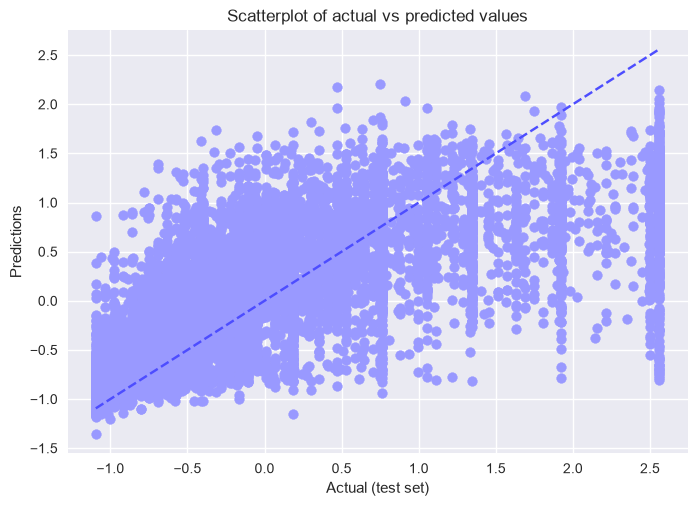

In [13]:
# plotting the scatter plot
plt.scatter(y_test_std, y_pred_MLP_Keras_12_test, color='#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle='--', c='#4d4dff')
# adding the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual vs predicted values')
plt.show();

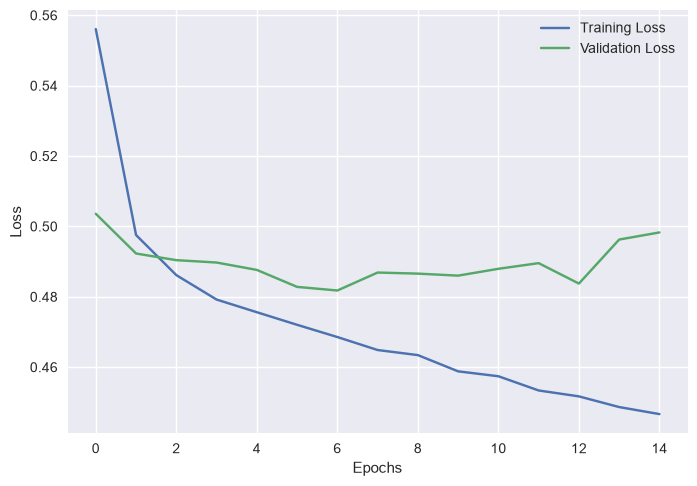

In [14]:
# Plotting the training and validation loss curves
plt.plot(history_MLP_12.history['loss'], label='Training Loss')
plt.plot(history_MLP_12.history['val_loss'], label='Validation Loss')
# Adding labels and legends
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

## 4.9. Last MLP Model (Grid Search Scikit-Learn)

In [5]:
# Defining the MLP regression model
MLP_model_13 = MLPRegressor(random_state=28, verbose=True)
# Defining the parameter grid
param_grid_MLP_13 = {'hidden_layer_sizes': [(50,), (50,50), (100,), (50,25), (100, ),],
              'max_iter': [50, 100, 150, 200],
              'alpha': [0.001, 0.01, 0.1]}
 #'dropout' -> not supported by Scikit-Learn

In [6]:
# Defining the cross-validation object
cv = KFold(n_splits=5, shuffle=True, random_state=28)
# Creating a GridSearchCV object with 5-fold cross validation
grid_search_MLP_13 = GridSearchCV(MLP_model_13, param_grid_MLP_13,
                                  cv=cv, scoring='neg_mean_squared_error')

In [7]:
# Timing the cross-validation training process
cv_start_time_MLP_13 = time.time()
# Cross-validation loop
R2_MLP_13_CV = []
MSE_MLP_13_CV = []
MAE_MLP_13_CV = []
for train_idx, val_idx in cv.split(X_train2_std):
    # Creating the training and validation sets
    X_train_fold = X_train2_std[train_idx]
    y_train_fold = y_train2_std[train_idx]
    X_val_fold = X_train2_std[val_idx]
    y_val_fold = y_train2_std[val_idx]
    # Fitting the model using the grid search object on the current fold
    grid_search_MLP_13.fit(X_train_fold, y_train_fold.ravel())
    # Making predictions on the validation set
    y_pred_val = grid_search_MLP_13.predict(X_val_fold)
    # Computing the R-squared, MSE, and MAE metrics on the validation set
    R2_MLP_13_CV.append(r2_score(y_val_fold.ravel(), y_pred_val.ravel()))
    MSE_MLP_13_CV.append(mean_squared_error(y_val_fold.ravel(), y_pred_val.ravel()))
    MAE_MLP_13_CV.append(mean_absolute_error(y_val_fold.ravel(), y_pred_val.ravel()))
# Computing the mean R2, MSE, and MAE over the different folds
mean_R2_MLP_13_CV = np.mean(R2_MLP_13_CV)
mean_MSE_MLP_13_CV = np.mean(MSE_MLP_13_CV)
mean_MAE_MLP_13_CV = np.mean(MAE_MLP_13_CV)
# End time
cv_end_time_MLP_13 = time.time()

Iteration 1, loss = 0.40888256
Iteration 2, loss = 0.27984380
Iteration 3, loss = 0.26637702
Iteration 4, loss = 0.25942859
Iteration 5, loss = 0.25473301
Iteration 6, loss = 0.25193238
Iteration 7, loss = 0.24937310
Iteration 8, loss = 0.24818210
Iteration 9, loss = 0.24628331
Iteration 10, loss = 0.24515168
Iteration 11, loss = 0.24411859
Iteration 12, loss = 0.24384573
Iteration 13, loss = 0.24252057
Iteration 14, loss = 0.24195917
Iteration 15, loss = 0.24128388
Iteration 16, loss = 0.24081362
Iteration 17, loss = 0.24020832
Iteration 18, loss = 0.23974943
Iteration 19, loss = 0.23913000
Iteration 20, loss = 0.23852011
Iteration 21, loss = 0.23840193
Iteration 22, loss = 0.23787039
Iteration 23, loss = 0.23840075
Iteration 24, loss = 0.23778091
Iteration 25, loss = 0.23723929
Iteration 26, loss = 0.23661013
Iteration 27, loss = 0.23708659
Iteration 28, loss = 0.23645872
Iteration 29, loss = 0.23640546
Iteration 30, loss = 0.23605936
Iteration 31, loss = 0.23573003
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25160010
Iteration 7, loss = 0.24900527
Iteration 8, loss = 0.24752711
Iteration 9, loss = 0.24590313
Iteration 10, loss = 0.24489014
Iteration 11, loss = 0.24367422
Iteration 12, loss = 0.24278377
Iteration 13, loss = 0.24197564
Iteration 14, loss = 0.24104949
Iteration 15, loss = 0.24057201
Iteration 16, loss = 0.23997271
Iteration 17, loss = 0.23977314
Iteration 18, loss = 0.23924985
Iteration 19, loss = 0.23902837
Iteration 20, loss = 0.23810873
Iteration 21, loss = 0.23785489
Iteration 22, loss = 0.23756410
Iteration 23, loss = 0.23655615
Iteration 24, loss = 0.23693923
Iteration 25, loss = 0.23621460
Iteration 26, loss = 0.23631424
Iteration 27, loss = 0.23596964
Iteration 28, loss = 0.23577688
Iteration 29, loss = 0.23560165
Iteration 30, loss = 0.23479792
Iteration 31, loss = 0.23503409
Iteration 32, loss = 0.23482818
Iteration 33, loss = 0.23441818
Iteration 34, loss = 0.23418660
Iteration 35, loss = 0.23409192
Iteration 36, loss = 0.23411685
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.39863092
Iteration 2, loss = 0.27266598
Iteration 3, loss = 0.25955018
Iteration 4, loss = 0.25301234
Iteration 5, loss = 0.24876534
Iteration 6, loss = 0.24554313
Iteration 7, loss = 0.24367594
Iteration 8, loss = 0.24204147
Iteration 9, loss = 0.24076813
Iteration 10, loss = 0.24014891
Iteration 11, loss = 0.23859439
Iteration 12, loss = 0.23787841
Iteration 13, loss = 0.23715173
Iteration 14, loss = 0.23669233
Iteration 15, loss = 0.23600004
Iteration 16, loss = 0.23543334
Iteration 17, loss = 0.23510805
Iteration 18, loss = 0.23450313
Iteration 19, loss = 0.23411906
Iteration 20, loss = 0.23365237
Iteration 21, loss = 0.23336447
Iteration 22, loss = 0.23290498
Iteration 23, loss = 0.23268653
Iteration 24, loss = 0.23246996
Iteration 25, loss = 0.23176687
Iteration 26, loss = 0.23152795
Iteration 27, loss = 0.23123839
Iteration 28, loss = 0.23108625
Iteration 29, loss = 0.23111248
Iteration 30, loss = 0.23112922
Iteration 31, loss = 0.23057983
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24882895
Iteration 7, loss = 0.24664744
Iteration 8, loss = 0.24500772
Iteration 9, loss = 0.24354162
Iteration 10, loss = 0.24234745
Iteration 11, loss = 0.24110705
Iteration 12, loss = 0.24057455
Iteration 13, loss = 0.23966150
Iteration 14, loss = 0.23895064
Iteration 15, loss = 0.23844555
Iteration 16, loss = 0.23803779
Iteration 17, loss = 0.23762554
Iteration 18, loss = 0.23700941
Iteration 19, loss = 0.23651461
Iteration 20, loss = 0.23608909
Iteration 21, loss = 0.23547883
Iteration 22, loss = 0.23515373
Iteration 23, loss = 0.23509708
Iteration 24, loss = 0.23427960
Iteration 25, loss = 0.23501648
Iteration 26, loss = 0.23422015
Iteration 27, loss = 0.23362209
Iteration 28, loss = 0.23342737
Iteration 29, loss = 0.23360557
Iteration 30, loss = 0.23326290
Iteration 31, loss = 0.23261446
Iteration 32, loss = 0.23257540
Iteration 33, loss = 0.23233524
Iteration 34, loss = 0.23253404
Iteration 35, loss = 0.23180642
Iteration 36, loss = 0.23151522
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26456435
Iteration 4, loss = 0.25758582
Iteration 5, loss = 0.25320705
Iteration 6, loss = 0.24986997
Iteration 7, loss = 0.24782540
Iteration 8, loss = 0.24586142
Iteration 9, loss = 0.24466172
Iteration 10, loss = 0.24343311
Iteration 11, loss = 0.24251227
Iteration 12, loss = 0.24174919
Iteration 13, loss = 0.24070320
Iteration 14, loss = 0.23996926
Iteration 15, loss = 0.23976234
Iteration 16, loss = 0.23907527
Iteration 17, loss = 0.23869523
Iteration 18, loss = 0.23807484
Iteration 19, loss = 0.23748654
Iteration 20, loss = 0.23716501
Iteration 21, loss = 0.23653010
Iteration 22, loss = 0.23631112
Iteration 23, loss = 0.23582569
Iteration 24, loss = 0.23563500
Iteration 25, loss = 0.23559688
Iteration 26, loss = 0.23512608
Iteration 27, loss = 0.23482990
Iteration 28, loss = 0.23462569
Iteration 29, loss = 0.23437485
Iteration 30, loss = 0.23415877
Iteration 31, loss = 0.23423315
Iteration 32, loss = 0.23373432
Iteration 33, loss = 0.23373601
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24628331
Iteration 10, loss = 0.24515168
Iteration 11, loss = 0.24411859
Iteration 12, loss = 0.24384573
Iteration 13, loss = 0.24252057
Iteration 14, loss = 0.24195917
Iteration 15, loss = 0.24128388
Iteration 16, loss = 0.24081362
Iteration 17, loss = 0.24020832
Iteration 18, loss = 0.23974943
Iteration 19, loss = 0.23913000
Iteration 20, loss = 0.23852011
Iteration 21, loss = 0.23840193
Iteration 22, loss = 0.23787039
Iteration 23, loss = 0.23840075
Iteration 24, loss = 0.23778091
Iteration 25, loss = 0.23723929
Iteration 26, loss = 0.23661013
Iteration 27, loss = 0.23708659
Iteration 28, loss = 0.23645872
Iteration 29, loss = 0.23640546
Iteration 30, loss = 0.23605936
Iteration 31, loss = 0.23573003
Iteration 32, loss = 0.23539807
Iteration 33, loss = 0.23519451
Iteration 34, loss = 0.23507673
Iteration 35, loss = 0.23501419
Iteration 36, loss = 0.23473736
Iteration 37, loss = 0.23445857
Iteration 38, loss = 0.23433198
Iteration 39, loss = 0.23419328
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27898586
Iteration 3, loss = 0.26592973
Iteration 4, loss = 0.25922983
Iteration 5, loss = 0.25451707
Iteration 6, loss = 0.25160010
Iteration 7, loss = 0.24900527
Iteration 8, loss = 0.24752711
Iteration 9, loss = 0.24590313
Iteration 10, loss = 0.24489014
Iteration 11, loss = 0.24367422
Iteration 12, loss = 0.24278377
Iteration 13, loss = 0.24197564
Iteration 14, loss = 0.24104949
Iteration 15, loss = 0.24057201
Iteration 16, loss = 0.23997271
Iteration 17, loss = 0.23977314
Iteration 18, loss = 0.23924985
Iteration 19, loss = 0.23902837
Iteration 20, loss = 0.23810873
Iteration 21, loss = 0.23785489
Iteration 22, loss = 0.23756410
Iteration 23, loss = 0.23655615
Iteration 24, loss = 0.23693923
Iteration 25, loss = 0.23621460
Iteration 26, loss = 0.23631424
Iteration 27, loss = 0.23596964
Iteration 28, loss = 0.23577688
Iteration 29, loss = 0.23560165
Iteration 30, loss = 0.23479792
Iteration 31, loss = 0.23503409
Iteration 32, loss = 0.23482818
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.39863092
Iteration 2, loss = 0.27266598
Iteration 3, loss = 0.25955018
Iteration 4, loss = 0.25301234
Iteration 5, loss = 0.24876534
Iteration 6, loss = 0.24554313
Iteration 7, loss = 0.24367594
Iteration 8, loss = 0.24204147
Iteration 9, loss = 0.24076813
Iteration 10, loss = 0.24014891
Iteration 11, loss = 0.23859439
Iteration 12, loss = 0.23787841
Iteration 13, loss = 0.23715173
Iteration 14, loss = 0.23669233
Iteration 15, loss = 0.23600004
Iteration 16, loss = 0.23543334
Iteration 17, loss = 0.23510805
Iteration 18, loss = 0.23450313
Iteration 19, loss = 0.23411906
Iteration 20, loss = 0.23365237
Iteration 21, loss = 0.23336447
Iteration 22, loss = 0.23290498
Iteration 23, loss = 0.23268653
Iteration 24, loss = 0.23246996
Iteration 25, loss = 0.23176687
Iteration 26, loss = 0.23152795
Iteration 27, loss = 0.23123839
Iteration 28, loss = 0.23108625
Iteration 29, loss = 0.23111248
Iteration 30, loss = 0.23112922
Iteration 31, loss = 0.23057983
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25657116
Iteration 5, loss = 0.25219817
Iteration 6, loss = 0.24882895
Iteration 7, loss = 0.24664744
Iteration 8, loss = 0.24500772
Iteration 9, loss = 0.24354162
Iteration 10, loss = 0.24234745
Iteration 11, loss = 0.24110705
Iteration 12, loss = 0.24057455
Iteration 13, loss = 0.23966150
Iteration 14, loss = 0.23895064
Iteration 15, loss = 0.23844555
Iteration 16, loss = 0.23803779
Iteration 17, loss = 0.23762554
Iteration 18, loss = 0.23700941
Iteration 19, loss = 0.23651461
Iteration 20, loss = 0.23608909
Iteration 21, loss = 0.23547883
Iteration 22, loss = 0.23515373
Iteration 23, loss = 0.23509708
Iteration 24, loss = 0.23427960
Iteration 25, loss = 0.23501648
Iteration 26, loss = 0.23422015
Iteration 27, loss = 0.23362209
Iteration 28, loss = 0.23342737
Iteration 29, loss = 0.23360557
Iteration 30, loss = 0.23326290
Iteration 31, loss = 0.23261446
Iteration 32, loss = 0.23257540
Iteration 33, loss = 0.23233524
Iteration 34, loss = 0.23253404
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24782540
Iteration 8, loss = 0.24586142
Iteration 9, loss = 0.24466172
Iteration 10, loss = 0.24343311
Iteration 11, loss = 0.24251227
Iteration 12, loss = 0.24174919
Iteration 13, loss = 0.24070320
Iteration 14, loss = 0.23996926
Iteration 15, loss = 0.23976234
Iteration 16, loss = 0.23907527
Iteration 17, loss = 0.23869523
Iteration 18, loss = 0.23807484
Iteration 19, loss = 0.23748654
Iteration 20, loss = 0.23716501
Iteration 21, loss = 0.23653010
Iteration 22, loss = 0.23631112
Iteration 23, loss = 0.23582569
Iteration 24, loss = 0.23563500
Iteration 25, loss = 0.23559688
Iteration 26, loss = 0.23512608
Iteration 27, loss = 0.23482990
Iteration 28, loss = 0.23462569
Iteration 29, loss = 0.23437485
Iteration 30, loss = 0.23415877
Iteration 31, loss = 0.23423315
Iteration 32, loss = 0.23373432
Iteration 33, loss = 0.23373601
Iteration 34, loss = 0.23295365
Iteration 35, loss = 0.23299339
Iteration 36, loss = 0.23294333
Iteration 37, loss = 0.23298287
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24937310
Iteration 8, loss = 0.24818210
Iteration 9, loss = 0.24628331
Iteration 10, loss = 0.24515168
Iteration 11, loss = 0.24411859
Iteration 12, loss = 0.24384573
Iteration 13, loss = 0.24252057
Iteration 14, loss = 0.24195917
Iteration 15, loss = 0.24128388
Iteration 16, loss = 0.24081362
Iteration 17, loss = 0.24020832
Iteration 18, loss = 0.23974943
Iteration 19, loss = 0.23913000
Iteration 20, loss = 0.23852011
Iteration 21, loss = 0.23840193
Iteration 22, loss = 0.23787039
Iteration 23, loss = 0.23840075
Iteration 24, loss = 0.23778091
Iteration 25, loss = 0.23723929
Iteration 26, loss = 0.23661013
Iteration 27, loss = 0.23708659
Iteration 28, loss = 0.23645872
Iteration 29, loss = 0.23640546
Iteration 30, loss = 0.23605936
Iteration 31, loss = 0.23573003
Iteration 32, loss = 0.23539807
Iteration 33, loss = 0.23519451
Iteration 34, loss = 0.23507673
Iteration 35, loss = 0.23501419
Iteration 36, loss = 0.23473736
Iteration 37, loss = 0.23445857
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26592973
Iteration 4, loss = 0.25922983
Iteration 5, loss = 0.25451707
Iteration 6, loss = 0.25160010
Iteration 7, loss = 0.24900527
Iteration 8, loss = 0.24752711
Iteration 9, loss = 0.24590313
Iteration 10, loss = 0.24489014
Iteration 11, loss = 0.24367422
Iteration 12, loss = 0.24278377
Iteration 13, loss = 0.24197564
Iteration 14, loss = 0.24104949
Iteration 15, loss = 0.24057201
Iteration 16, loss = 0.23997271
Iteration 17, loss = 0.23977314
Iteration 18, loss = 0.23924985
Iteration 19, loss = 0.23902837
Iteration 20, loss = 0.23810873
Iteration 21, loss = 0.23785489
Iteration 22, loss = 0.23756410
Iteration 23, loss = 0.23655615
Iteration 24, loss = 0.23693923
Iteration 25, loss = 0.23621460
Iteration 26, loss = 0.23631424
Iteration 27, loss = 0.23596964
Iteration 28, loss = 0.23577688
Iteration 29, loss = 0.23560165
Iteration 30, loss = 0.23479792
Iteration 31, loss = 0.23503409
Iteration 32, loss = 0.23482818
Iteration 33, loss = 0.23441818
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25301234
Iteration 5, loss = 0.24876534
Iteration 6, loss = 0.24554313
Iteration 7, loss = 0.24367594
Iteration 8, loss = 0.24204147
Iteration 9, loss = 0.24076813
Iteration 10, loss = 0.24014891
Iteration 11, loss = 0.23859439
Iteration 12, loss = 0.23787841
Iteration 13, loss = 0.23715173
Iteration 14, loss = 0.23669233
Iteration 15, loss = 0.23600004
Iteration 16, loss = 0.23543334
Iteration 17, loss = 0.23510805
Iteration 18, loss = 0.23450313
Iteration 19, loss = 0.23411906
Iteration 20, loss = 0.23365237
Iteration 21, loss = 0.23336447
Iteration 22, loss = 0.23290498
Iteration 23, loss = 0.23268653
Iteration 24, loss = 0.23246996
Iteration 25, loss = 0.23176687
Iteration 26, loss = 0.23152795
Iteration 27, loss = 0.23123839
Iteration 28, loss = 0.23108625
Iteration 29, loss = 0.23111248
Iteration 30, loss = 0.23112922
Iteration 31, loss = 0.23057983
Iteration 32, loss = 0.23040154
Iteration 33, loss = 0.23007465
Iteration 34, loss = 0.22978183
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25473301
Iteration 6, loss = 0.25193238
Iteration 7, loss = 0.24937310
Iteration 8, loss = 0.24818210
Iteration 9, loss = 0.24628331
Iteration 10, loss = 0.24515168
Iteration 11, loss = 0.24411859
Iteration 12, loss = 0.24384573
Iteration 13, loss = 0.24252057
Iteration 14, loss = 0.24195917
Iteration 15, loss = 0.24128388
Iteration 16, loss = 0.24081362
Iteration 17, loss = 0.24020832
Iteration 18, loss = 0.23974943
Iteration 19, loss = 0.23913000
Iteration 20, loss = 0.23852011
Iteration 21, loss = 0.23840193
Iteration 22, loss = 0.23787039
Iteration 23, loss = 0.23840075
Iteration 24, loss = 0.23778091
Iteration 25, loss = 0.23723929
Iteration 26, loss = 0.23661013
Iteration 27, loss = 0.23708659
Iteration 28, loss = 0.23645872
Iteration 29, loss = 0.23640546
Iteration 30, loss = 0.23605936
Iteration 31, loss = 0.23573003
Iteration 32, loss = 0.23539807
Iteration 33, loss = 0.23519451
Iteration 34, loss = 0.23507673
Iteration 35, loss = 0.23501419
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34669674
Iteration 2, loss = 0.26495154
Iteration 3, loss = 0.25535877
Iteration 4, loss = 0.25003128
Iteration 5, loss = 0.24616548
Iteration 6, loss = 0.24367675
Iteration 7, loss = 0.24099864
Iteration 8, loss = 0.23992260
Iteration 9, loss = 0.23785769
Iteration 10, loss = 0.23692504
Iteration 11, loss = 0.23583643
Iteration 12, loss = 0.23406902
Iteration 13, loss = 0.23384175
Iteration 14, loss = 0.23299895
Iteration 15, loss = 0.23180657
Iteration 16, loss = 0.23045336
Iteration 17, loss = 0.23007064
Iteration 18, loss = 0.22972444
Iteration 19, loss = 0.22849175
Iteration 20, loss = 0.22822393
Iteration 21, loss = 0.22637881
Iteration 22, loss = 0.22628588
Iteration 23, loss = 0.22592594
Iteration 24, loss = 0.22498726
Iteration 25, loss = 0.22447099
Iteration 26, loss = 0.22337691
Iteration 27, loss = 0.22356827
Iteration 28, loss = 0.22258735
Iteration 29, loss = 0.22163395
Iteration 30, loss = 0.22174648
Iteration 31, loss = 0.22078466
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24469828
Iteration 5, loss = 0.24150137
Iteration 6, loss = 0.23865623
Iteration 7, loss = 0.23629803
Iteration 8, loss = 0.23483821
Iteration 9, loss = 0.23364836
Iteration 10, loss = 0.23254580
Iteration 11, loss = 0.23153462
Iteration 12, loss = 0.23021622
Iteration 13, loss = 0.22981379
Iteration 14, loss = 0.22871967
Iteration 15, loss = 0.22810473
Iteration 16, loss = 0.22642517
Iteration 17, loss = 0.22631090
Iteration 18, loss = 0.22538944
Iteration 19, loss = 0.22472667
Iteration 20, loss = 0.22445995
Iteration 21, loss = 0.22330482
Iteration 22, loss = 0.22256020
Iteration 23, loss = 0.22158435
Iteration 24, loss = 0.22110265
Iteration 25, loss = 0.22094096
Iteration 26, loss = 0.22040437
Iteration 27, loss = 0.21937302
Iteration 28, loss = 0.21961514
Iteration 29, loss = 0.21863947
Iteration 30, loss = 0.21834042
Iteration 31, loss = 0.21811796
Iteration 32, loss = 0.21729217
Iteration 33, loss = 0.21698212
Iteration 34, loss = 0.21605252
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26197425
Iteration 3, loss = 0.25277819
Iteration 4, loss = 0.24749909
Iteration 5, loss = 0.24363392
Iteration 6, loss = 0.24146463
Iteration 7, loss = 0.23916480
Iteration 8, loss = 0.23724248
Iteration 9, loss = 0.23557166
Iteration 10, loss = 0.23500480
Iteration 11, loss = 0.23303036
Iteration 12, loss = 0.23193317
Iteration 13, loss = 0.23053782
Iteration 14, loss = 0.23016239
Iteration 15, loss = 0.22903954
Iteration 16, loss = 0.22891629
Iteration 17, loss = 0.22745309
Iteration 18, loss = 0.22697433
Iteration 19, loss = 0.22683212
Iteration 20, loss = 0.22609191
Iteration 21, loss = 0.22465296
Iteration 22, loss = 0.22431752
Iteration 23, loss = 0.22378900
Iteration 24, loss = 0.22356526
Iteration 25, loss = 0.22255503
Iteration 26, loss = 0.22175900
Iteration 27, loss = 0.22169598
Iteration 28, loss = 0.22049599
Iteration 29, loss = 0.22006458
Iteration 30, loss = 0.21955419
Iteration 31, loss = 0.21919460
Iteration 32, loss = 0.21911980
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24304701
Iteration 7, loss = 0.23988505
Iteration 8, loss = 0.23807672
Iteration 9, loss = 0.23722191
Iteration 10, loss = 0.23607936
Iteration 11, loss = 0.23437344
Iteration 12, loss = 0.23398327
Iteration 13, loss = 0.23290679
Iteration 14, loss = 0.23201779
Iteration 15, loss = 0.23130005
Iteration 16, loss = 0.23040958
Iteration 17, loss = 0.23002077
Iteration 18, loss = 0.22880636
Iteration 19, loss = 0.22828409
Iteration 20, loss = 0.22771402
Iteration 21, loss = 0.22710378
Iteration 22, loss = 0.22621205
Iteration 23, loss = 0.22550217
Iteration 24, loss = 0.22501819
Iteration 25, loss = 0.22475295
Iteration 26, loss = 0.22369783
Iteration 27, loss = 0.22394835
Iteration 28, loss = 0.22263283
Iteration 29, loss = 0.22263320
Iteration 30, loss = 0.22217615
Iteration 31, loss = 0.22167983
Iteration 32, loss = 0.22077008
Iteration 33, loss = 0.22044871
Iteration 34, loss = 0.22063611
Iteration 35, loss = 0.21915700
Iteration 36, loss = 0.21903835
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25007657
Iteration 5, loss = 0.24625951
Iteration 6, loss = 0.24413205
Iteration 7, loss = 0.24158930
Iteration 8, loss = 0.24024386
Iteration 9, loss = 0.23831299
Iteration 10, loss = 0.23658107
Iteration 11, loss = 0.23560575
Iteration 12, loss = 0.23521898
Iteration 13, loss = 0.23383653
Iteration 14, loss = 0.23266153
Iteration 15, loss = 0.23196477
Iteration 16, loss = 0.23136617
Iteration 17, loss = 0.23058501
Iteration 18, loss = 0.22989683
Iteration 19, loss = 0.22919035
Iteration 20, loss = 0.22963214
Iteration 21, loss = 0.22758489
Iteration 22, loss = 0.22647061
Iteration 23, loss = 0.22679155
Iteration 24, loss = 0.22586340
Iteration 25, loss = 0.22511365
Iteration 26, loss = 0.22507555
Iteration 27, loss = 0.22401876
Iteration 28, loss = 0.22348928
Iteration 29, loss = 0.22280502
Iteration 30, loss = 0.22246116
Iteration 31, loss = 0.22205254
Iteration 32, loss = 0.22097167
Iteration 33, loss = 0.22076867
Iteration 34, loss = 0.21965407
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24367675
Iteration 7, loss = 0.24099864
Iteration 8, loss = 0.23992260
Iteration 9, loss = 0.23785769
Iteration 10, loss = 0.23692504
Iteration 11, loss = 0.23583643
Iteration 12, loss = 0.23406902
Iteration 13, loss = 0.23384175
Iteration 14, loss = 0.23299895
Iteration 15, loss = 0.23180657
Iteration 16, loss = 0.23045336
Iteration 17, loss = 0.23007064
Iteration 18, loss = 0.22972444
Iteration 19, loss = 0.22849175
Iteration 20, loss = 0.22822393
Iteration 21, loss = 0.22637881
Iteration 22, loss = 0.22628588
Iteration 23, loss = 0.22592594
Iteration 24, loss = 0.22498726
Iteration 25, loss = 0.22447099
Iteration 26, loss = 0.22337691
Iteration 27, loss = 0.22356827
Iteration 28, loss = 0.22258735
Iteration 29, loss = 0.22163395
Iteration 30, loss = 0.22174648
Iteration 31, loss = 0.22078466
Iteration 32, loss = 0.22031538
Iteration 33, loss = 0.21956689
Iteration 34, loss = 0.21931762
Iteration 35, loss = 0.21813107
Iteration 36, loss = 0.21745153
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34088197
Iteration 2, loss = 0.25859841
Iteration 3, loss = 0.24975935
Iteration 4, loss = 0.24469828
Iteration 5, loss = 0.24150137
Iteration 6, loss = 0.23865623
Iteration 7, loss = 0.23629803
Iteration 8, loss = 0.23483821
Iteration 9, loss = 0.23364836
Iteration 10, loss = 0.23254580
Iteration 11, loss = 0.23153462
Iteration 12, loss = 0.23021622
Iteration 13, loss = 0.22981379
Iteration 14, loss = 0.22871967
Iteration 15, loss = 0.22810473
Iteration 16, loss = 0.22642517
Iteration 17, loss = 0.22631090
Iteration 18, loss = 0.22538944
Iteration 19, loss = 0.22472667
Iteration 20, loss = 0.22445995
Iteration 21, loss = 0.22330482
Iteration 22, loss = 0.22256020
Iteration 23, loss = 0.22158435
Iteration 24, loss = 0.22110265
Iteration 25, loss = 0.22094096
Iteration 26, loss = 0.22040437
Iteration 27, loss = 0.21937302
Iteration 28, loss = 0.21961514
Iteration 29, loss = 0.21863947
Iteration 30, loss = 0.21834042
Iteration 31, loss = 0.21811796
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26197425
Iteration 3, loss = 0.25277819
Iteration 4, loss = 0.24749909
Iteration 5, loss = 0.24363392
Iteration 6, loss = 0.24146463
Iteration 7, loss = 0.23916480
Iteration 8, loss = 0.23724248
Iteration 9, loss = 0.23557166
Iteration 10, loss = 0.23500480
Iteration 11, loss = 0.23303036
Iteration 12, loss = 0.23193317
Iteration 13, loss = 0.23053782
Iteration 14, loss = 0.23016239
Iteration 15, loss = 0.22903954
Iteration 16, loss = 0.22891629
Iteration 17, loss = 0.22745309
Iteration 18, loss = 0.22697433
Iteration 19, loss = 0.22683212
Iteration 20, loss = 0.22609191
Iteration 21, loss = 0.22465296
Iteration 22, loss = 0.22431752
Iteration 23, loss = 0.22378900
Iteration 24, loss = 0.22356526
Iteration 25, loss = 0.22255503
Iteration 26, loss = 0.22175900
Iteration 27, loss = 0.22169598
Iteration 28, loss = 0.22049599
Iteration 29, loss = 0.22006458
Iteration 30, loss = 0.21955419
Iteration 31, loss = 0.21919460
Iteration 32, loss = 0.21911980
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24915691
Iteration 5, loss = 0.24511360
Iteration 6, loss = 0.24304701
Iteration 7, loss = 0.23988505
Iteration 8, loss = 0.23807672
Iteration 9, loss = 0.23722191
Iteration 10, loss = 0.23607936
Iteration 11, loss = 0.23437344
Iteration 12, loss = 0.23398327
Iteration 13, loss = 0.23290679
Iteration 14, loss = 0.23201779
Iteration 15, loss = 0.23130005
Iteration 16, loss = 0.23040958
Iteration 17, loss = 0.23002077
Iteration 18, loss = 0.22880636
Iteration 19, loss = 0.22828409
Iteration 20, loss = 0.22771402
Iteration 21, loss = 0.22710378
Iteration 22, loss = 0.22621205
Iteration 23, loss = 0.22550217
Iteration 24, loss = 0.22501819
Iteration 25, loss = 0.22475295
Iteration 26, loss = 0.22369783
Iteration 27, loss = 0.22394835
Iteration 28, loss = 0.22263283
Iteration 29, loss = 0.22263320
Iteration 30, loss = 0.22217615
Iteration 31, loss = 0.22167983
Iteration 32, loss = 0.22077008
Iteration 33, loss = 0.22044871
Iteration 34, loss = 0.22063611
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25626729
Iteration 4, loss = 0.25007657
Iteration 5, loss = 0.24625951
Iteration 6, loss = 0.24413205
Iteration 7, loss = 0.24158930
Iteration 8, loss = 0.24024386
Iteration 9, loss = 0.23831299
Iteration 10, loss = 0.23658107
Iteration 11, loss = 0.23560575
Iteration 12, loss = 0.23521898
Iteration 13, loss = 0.23383653
Iteration 14, loss = 0.23266153
Iteration 15, loss = 0.23196477
Iteration 16, loss = 0.23136617
Iteration 17, loss = 0.23058501
Iteration 18, loss = 0.22989683
Iteration 19, loss = 0.22919035
Iteration 20, loss = 0.22963214
Iteration 21, loss = 0.22758489
Iteration 22, loss = 0.22647061
Iteration 23, loss = 0.22679155
Iteration 24, loss = 0.22586340
Iteration 25, loss = 0.22511365
Iteration 26, loss = 0.22507555
Iteration 27, loss = 0.22401876
Iteration 28, loss = 0.22348928
Iteration 29, loss = 0.22280502
Iteration 30, loss = 0.22246116
Iteration 31, loss = 0.22205254
Iteration 32, loss = 0.22097167
Iteration 33, loss = 0.22076867
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34669674
Iteration 2, loss = 0.26495154
Iteration 3, loss = 0.25535877
Iteration 4, loss = 0.25003128
Iteration 5, loss = 0.24616548
Iteration 6, loss = 0.24367675
Iteration 7, loss = 0.24099864
Iteration 8, loss = 0.23992260
Iteration 9, loss = 0.23785769
Iteration 10, loss = 0.23692504
Iteration 11, loss = 0.23583643
Iteration 12, loss = 0.23406902
Iteration 13, loss = 0.23384175
Iteration 14, loss = 0.23299895
Iteration 15, loss = 0.23180657
Iteration 16, loss = 0.23045336
Iteration 17, loss = 0.23007064
Iteration 18, loss = 0.22972444
Iteration 19, loss = 0.22849175
Iteration 20, loss = 0.22822393
Iteration 21, loss = 0.22637881
Iteration 22, loss = 0.22628588
Iteration 23, loss = 0.22592594
Iteration 24, loss = 0.22498726
Iteration 25, loss = 0.22447099
Iteration 26, loss = 0.22337691
Iteration 27, loss = 0.22356827
Iteration 28, loss = 0.22258735
Iteration 29, loss = 0.22163395
Iteration 30, loss = 0.22174648
Iteration 31, loss = 0.22078466
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24975935
Iteration 4, loss = 0.24469828
Iteration 5, loss = 0.24150137
Iteration 6, loss = 0.23865623
Iteration 7, loss = 0.23629803
Iteration 8, loss = 0.23483821
Iteration 9, loss = 0.23364836
Iteration 10, loss = 0.23254580
Iteration 11, loss = 0.23153462
Iteration 12, loss = 0.23021622
Iteration 13, loss = 0.22981379
Iteration 14, loss = 0.22871967
Iteration 15, loss = 0.22810473
Iteration 16, loss = 0.22642517
Iteration 17, loss = 0.22631090
Iteration 18, loss = 0.22538944
Iteration 19, loss = 0.22472667
Iteration 20, loss = 0.22445995
Iteration 21, loss = 0.22330482
Iteration 22, loss = 0.22256020
Iteration 23, loss = 0.22158435
Iteration 24, loss = 0.22110265
Iteration 25, loss = 0.22094096
Iteration 26, loss = 0.22040437
Iteration 27, loss = 0.21937302
Iteration 28, loss = 0.21961514
Iteration 29, loss = 0.21863947
Iteration 30, loss = 0.21834042
Iteration 31, loss = 0.21811796
Iteration 32, loss = 0.21729217
Iteration 33, loss = 0.21698212
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34468742
Iteration 2, loss = 0.26197425
Iteration 3, loss = 0.25277819
Iteration 4, loss = 0.24749909
Iteration 5, loss = 0.24363392
Iteration 6, loss = 0.24146463
Iteration 7, loss = 0.23916480
Iteration 8, loss = 0.23724248
Iteration 9, loss = 0.23557166
Iteration 10, loss = 0.23500480
Iteration 11, loss = 0.23303036
Iteration 12, loss = 0.23193317
Iteration 13, loss = 0.23053782
Iteration 14, loss = 0.23016239
Iteration 15, loss = 0.22903954
Iteration 16, loss = 0.22891629
Iteration 17, loss = 0.22745309
Iteration 18, loss = 0.22697433
Iteration 19, loss = 0.22683212
Iteration 20, loss = 0.22609191
Iteration 21, loss = 0.22465296
Iteration 22, loss = 0.22431752
Iteration 23, loss = 0.22378900
Iteration 24, loss = 0.22356526
Iteration 25, loss = 0.22255503
Iteration 26, loss = 0.22175900
Iteration 27, loss = 0.22169598
Iteration 28, loss = 0.22049599
Iteration 29, loss = 0.22006458
Iteration 30, loss = 0.21955419
Iteration 31, loss = 0.21919460
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24304701
Iteration 7, loss = 0.23988505
Iteration 8, loss = 0.23807672
Iteration 9, loss = 0.23722191
Iteration 10, loss = 0.23607936
Iteration 11, loss = 0.23437344
Iteration 12, loss = 0.23398327
Iteration 13, loss = 0.23290679
Iteration 14, loss = 0.23201779
Iteration 15, loss = 0.23130005
Iteration 16, loss = 0.23040958
Iteration 17, loss = 0.23002077
Iteration 18, loss = 0.22880636
Iteration 19, loss = 0.22828409
Iteration 20, loss = 0.22771402
Iteration 21, loss = 0.22710378
Iteration 22, loss = 0.22621205
Iteration 23, loss = 0.22550217
Iteration 24, loss = 0.22501819
Iteration 25, loss = 0.22475295
Iteration 26, loss = 0.22369783
Iteration 27, loss = 0.22394835
Iteration 28, loss = 0.22263283
Iteration 29, loss = 0.22263320
Iteration 30, loss = 0.22217615
Iteration 31, loss = 0.22167983
Iteration 32, loss = 0.22077008
Iteration 33, loss = 0.22044871
Iteration 34, loss = 0.22063611
Iteration 35, loss = 0.21915700
Iteration 36, loss = 0.21903835
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24413205
Iteration 7, loss = 0.24158930
Iteration 8, loss = 0.24024386
Iteration 9, loss = 0.23831299
Iteration 10, loss = 0.23658107
Iteration 11, loss = 0.23560575
Iteration 12, loss = 0.23521898
Iteration 13, loss = 0.23383653
Iteration 14, loss = 0.23266153
Iteration 15, loss = 0.23196477
Iteration 16, loss = 0.23136617
Iteration 17, loss = 0.23058501
Iteration 18, loss = 0.22989683
Iteration 19, loss = 0.22919035
Iteration 20, loss = 0.22963214
Iteration 21, loss = 0.22758489
Iteration 22, loss = 0.22647061
Iteration 23, loss = 0.22679155
Iteration 24, loss = 0.22586340
Iteration 25, loss = 0.22511365
Iteration 26, loss = 0.22507555
Iteration 27, loss = 0.22401876
Iteration 28, loss = 0.22348928
Iteration 29, loss = 0.22280502
Iteration 30, loss = 0.22246116
Iteration 31, loss = 0.22205254
Iteration 32, loss = 0.22097167
Iteration 33, loss = 0.22076867
Iteration 34, loss = 0.21965407
Iteration 35, loss = 0.21925613
Iteration 36, loss = 0.21960186
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25003128
Iteration 5, loss = 0.24616548
Iteration 6, loss = 0.24367675
Iteration 7, loss = 0.24099864
Iteration 8, loss = 0.23992260
Iteration 9, loss = 0.23785769
Iteration 10, loss = 0.23692504
Iteration 11, loss = 0.23583643
Iteration 12, loss = 0.23406902
Iteration 13, loss = 0.23384175
Iteration 14, loss = 0.23299895
Iteration 15, loss = 0.23180657
Iteration 16, loss = 0.23045336
Iteration 17, loss = 0.23007064
Iteration 18, loss = 0.22972444
Iteration 19, loss = 0.22849175
Iteration 20, loss = 0.22822393
Iteration 21, loss = 0.22637881
Iteration 22, loss = 0.22628588
Iteration 23, loss = 0.22592594
Iteration 24, loss = 0.22498726
Iteration 25, loss = 0.22447099
Iteration 26, loss = 0.22337691
Iteration 27, loss = 0.22356827
Iteration 28, loss = 0.22258735
Iteration 29, loss = 0.22163395
Iteration 30, loss = 0.22174648
Iteration 31, loss = 0.22078466
Iteration 32, loss = 0.22031538
Iteration 33, loss = 0.21956689
Iteration 34, loss = 0.21931762
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24469828
Iteration 5, loss = 0.24150137
Iteration 6, loss = 0.23865623
Iteration 7, loss = 0.23629803
Iteration 8, loss = 0.23483821
Iteration 9, loss = 0.23364836
Iteration 10, loss = 0.23254580
Iteration 11, loss = 0.23153462
Iteration 12, loss = 0.23021622
Iteration 13, loss = 0.22981379
Iteration 14, loss = 0.22871967
Iteration 15, loss = 0.22810473
Iteration 16, loss = 0.22642517
Iteration 17, loss = 0.22631090
Iteration 18, loss = 0.22538944
Iteration 19, loss = 0.22472667
Iteration 20, loss = 0.22445995
Iteration 21, loss = 0.22330482
Iteration 22, loss = 0.22256020
Iteration 23, loss = 0.22158435
Iteration 24, loss = 0.22110265
Iteration 25, loss = 0.22094096
Iteration 26, loss = 0.22040437
Iteration 27, loss = 0.21937302
Iteration 28, loss = 0.21961514
Iteration 29, loss = 0.21863947
Iteration 30, loss = 0.21834042
Iteration 31, loss = 0.21811796
Iteration 32, loss = 0.21729217
Iteration 33, loss = 0.21698212
Iteration 34, loss = 0.21605252
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26197425
Iteration 3, loss = 0.25277819
Iteration 4, loss = 0.24749909
Iteration 5, loss = 0.24363392
Iteration 6, loss = 0.24146463
Iteration 7, loss = 0.23916480
Iteration 8, loss = 0.23724248
Iteration 9, loss = 0.23557166
Iteration 10, loss = 0.23500480
Iteration 11, loss = 0.23303036
Iteration 12, loss = 0.23193317
Iteration 13, loss = 0.23053782
Iteration 14, loss = 0.23016239
Iteration 15, loss = 0.22903954
Iteration 16, loss = 0.22891629
Iteration 17, loss = 0.22745309
Iteration 18, loss = 0.22697433
Iteration 19, loss = 0.22683212
Iteration 20, loss = 0.22609191
Iteration 21, loss = 0.22465296
Iteration 22, loss = 0.22431752
Iteration 23, loss = 0.22378900
Iteration 24, loss = 0.22356526
Iteration 25, loss = 0.22255503
Iteration 26, loss = 0.22175900
Iteration 27, loss = 0.22169598
Iteration 28, loss = 0.22049599
Iteration 29, loss = 0.22006458
Iteration 30, loss = 0.21955419
Iteration 31, loss = 0.21919460
Iteration 32, loss = 0.21911980
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25416853
Iteration 4, loss = 0.24915691
Iteration 5, loss = 0.24511360
Iteration 6, loss = 0.24304701
Iteration 7, loss = 0.23988505
Iteration 8, loss = 0.23807672
Iteration 9, loss = 0.23722191
Iteration 10, loss = 0.23607936
Iteration 11, loss = 0.23437344
Iteration 12, loss = 0.23398327
Iteration 13, loss = 0.23290679
Iteration 14, loss = 0.23201779
Iteration 15, loss = 0.23130005
Iteration 16, loss = 0.23040958
Iteration 17, loss = 0.23002077
Iteration 18, loss = 0.22880636
Iteration 19, loss = 0.22828409
Iteration 20, loss = 0.22771402
Iteration 21, loss = 0.22710378
Iteration 22, loss = 0.22621205
Iteration 23, loss = 0.22550217
Iteration 24, loss = 0.22501819
Iteration 25, loss = 0.22475295
Iteration 26, loss = 0.22369783
Iteration 27, loss = 0.22394835
Iteration 28, loss = 0.22263283
Iteration 29, loss = 0.22263320
Iteration 30, loss = 0.22217615
Iteration 31, loss = 0.22167983
Iteration 32, loss = 0.22077008
Iteration 33, loss = 0.22044871
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25311610
Iteration 4, loss = 0.24894336
Iteration 5, loss = 0.24618625
Iteration 6, loss = 0.24434876
Iteration 7, loss = 0.24314992
Iteration 8, loss = 0.24151494
Iteration 9, loss = 0.24051029
Iteration 10, loss = 0.23945146
Iteration 11, loss = 0.23871738
Iteration 12, loss = 0.23815720
Iteration 13, loss = 0.23732652
Iteration 14, loss = 0.23700712
Iteration 15, loss = 0.23628889
Iteration 16, loss = 0.23580217
Iteration 17, loss = 0.23522496
Iteration 18, loss = 0.23527685
Iteration 19, loss = 0.23456580
Iteration 20, loss = 0.23450118
Iteration 21, loss = 0.23351228
Iteration 22, loss = 0.23305197
Iteration 23, loss = 0.23261357
Iteration 24, loss = 0.23205365
Iteration 25, loss = 0.23176069
Iteration 26, loss = 0.23198932
Iteration 27, loss = 0.23179698
Iteration 28, loss = 0.23097041
Iteration 29, loss = 0.23121875
Iteration 30, loss = 0.23033232
Iteration 31, loss = 0.23065766
Iteration 32, loss = 0.22963013
Iteration 33, loss = 0.22999899
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24523184
Iteration 6, loss = 0.24370401
Iteration 7, loss = 0.24183831
Iteration 8, loss = 0.24083835
Iteration 9, loss = 0.24010015
Iteration 10, loss = 0.23868442
Iteration 11, loss = 0.23815653
Iteration 12, loss = 0.23729294
Iteration 13, loss = 0.23708937
Iteration 14, loss = 0.23607582
Iteration 15, loss = 0.23619368
Iteration 16, loss = 0.23537042
Iteration 17, loss = 0.23477670
Iteration 18, loss = 0.23472007
Iteration 19, loss = 0.23448048
Iteration 20, loss = 0.23314823
Iteration 21, loss = 0.23273316
Iteration 22, loss = 0.23266384
Iteration 23, loss = 0.23209307
Iteration 24, loss = 0.23167221
Iteration 25, loss = 0.23122099
Iteration 26, loss = 0.23136078
Iteration 27, loss = 0.23019476
Iteration 28, loss = 0.23043378
Iteration 29, loss = 0.22971903
Iteration 30, loss = 0.22970112
Iteration 31, loss = 0.22917228
Iteration 32, loss = 0.22892141
Iteration 33, loss = 0.22872899
Iteration 34, loss = 0.22889704
Iteration 35, loss = 0.22842093
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25580814
Iteration 3, loss = 0.24746112
Iteration 4, loss = 0.24285669
Iteration 5, loss = 0.24094152
Iteration 6, loss = 0.23842200
Iteration 7, loss = 0.23730206
Iteration 8, loss = 0.23583133
Iteration 9, loss = 0.23484320
Iteration 10, loss = 0.23459019
Iteration 11, loss = 0.23396928
Iteration 12, loss = 0.23274136
Iteration 13, loss = 0.23216534
Iteration 14, loss = 0.23212267
Iteration 15, loss = 0.23137755
Iteration 16, loss = 0.23118606
Iteration 17, loss = 0.23041201
Iteration 18, loss = 0.22998910
Iteration 19, loss = 0.22978881
Iteration 20, loss = 0.22935871
Iteration 21, loss = 0.22865050
Iteration 22, loss = 0.22860767
Iteration 23, loss = 0.22850238
Iteration 24, loss = 0.22800789
Iteration 25, loss = 0.22731535
Iteration 26, loss = 0.22763510
Iteration 27, loss = 0.22694560
Iteration 28, loss = 0.22650998
Iteration 29, loss = 0.22612324
Iteration 30, loss = 0.22627521
Iteration 31, loss = 0.22627988
Iteration 32, loss = 0.22556712
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31761392
Iteration 2, loss = 0.25829055
Iteration 3, loss = 0.24991876
Iteration 4, loss = 0.24558086
Iteration 5, loss = 0.24302281
Iteration 6, loss = 0.24113714
Iteration 7, loss = 0.23952681
Iteration 8, loss = 0.23864069
Iteration 9, loss = 0.23747083
Iteration 10, loss = 0.23616139
Iteration 11, loss = 0.23592616
Iteration 12, loss = 0.23503429
Iteration 13, loss = 0.23390840
Iteration 14, loss = 0.23342406
Iteration 15, loss = 0.23326267
Iteration 16, loss = 0.23223069
Iteration 17, loss = 0.23167730
Iteration 18, loss = 0.23191455
Iteration 19, loss = 0.23090808
Iteration 20, loss = 0.23061145
Iteration 21, loss = 0.23029463
Iteration 22, loss = 0.23049909
Iteration 23, loss = 0.22933216
Iteration 24, loss = 0.22901957
Iteration 25, loss = 0.22855576
Iteration 26, loss = 0.22883151
Iteration 27, loss = 0.22836745
Iteration 28, loss = 0.22770142
Iteration 29, loss = 0.22772424
Iteration 30, loss = 0.22701946
Iteration 31, loss = 0.22692000
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24098248
Iteration 8, loss = 0.23979957
Iteration 9, loss = 0.23852160
Iteration 10, loss = 0.23765107
Iteration 11, loss = 0.23733411
Iteration 12, loss = 0.23649875
Iteration 13, loss = 0.23556043
Iteration 14, loss = 0.23559592
Iteration 15, loss = 0.23493595
Iteration 16, loss = 0.23469205
Iteration 17, loss = 0.23435582
Iteration 18, loss = 0.23355278
Iteration 19, loss = 0.23322051
Iteration 20, loss = 0.23338786
Iteration 21, loss = 0.23224902
Iteration 22, loss = 0.23168698
Iteration 23, loss = 0.23199562
Iteration 24, loss = 0.23063935
Iteration 25, loss = 0.23088415
Iteration 26, loss = 0.23063537
Iteration 27, loss = 0.23032592
Iteration 28, loss = 0.23022476
Iteration 29, loss = 0.22931111
Iteration 30, loss = 0.22933312
Iteration 31, loss = 0.22845037
Iteration 32, loss = 0.22912094
Iteration 33, loss = 0.22819903
Iteration 34, loss = 0.22801753
Iteration 35, loss = 0.22827342
Iteration 36, loss = 0.22729694
Iteration 37, loss = 0.22743206
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24434876
Iteration 7, loss = 0.24314992
Iteration 8, loss = 0.24151494
Iteration 9, loss = 0.24051029
Iteration 10, loss = 0.23945146
Iteration 11, loss = 0.23871738
Iteration 12, loss = 0.23815720
Iteration 13, loss = 0.23732652
Iteration 14, loss = 0.23700712
Iteration 15, loss = 0.23628889
Iteration 16, loss = 0.23580217
Iteration 17, loss = 0.23522496
Iteration 18, loss = 0.23527685
Iteration 19, loss = 0.23456580
Iteration 20, loss = 0.23450118
Iteration 21, loss = 0.23351228
Iteration 22, loss = 0.23305197
Iteration 23, loss = 0.23261357
Iteration 24, loss = 0.23205365
Iteration 25, loss = 0.23176069
Iteration 26, loss = 0.23198932
Iteration 27, loss = 0.23179698
Iteration 28, loss = 0.23097041
Iteration 29, loss = 0.23121875
Iteration 30, loss = 0.23033232
Iteration 31, loss = 0.23065766
Iteration 32, loss = 0.22963013
Iteration 33, loss = 0.22999899
Iteration 34, loss = 0.22961197
Iteration 35, loss = 0.22895946
Iteration 36, loss = 0.22897815
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24523184
Iteration 6, loss = 0.24370401
Iteration 7, loss = 0.24183831
Iteration 8, loss = 0.24083835
Iteration 9, loss = 0.24010015
Iteration 10, loss = 0.23868442
Iteration 11, loss = 0.23815653
Iteration 12, loss = 0.23729294
Iteration 13, loss = 0.23708937
Iteration 14, loss = 0.23607582
Iteration 15, loss = 0.23619368
Iteration 16, loss = 0.23537042
Iteration 17, loss = 0.23477670
Iteration 18, loss = 0.23472007
Iteration 19, loss = 0.23448048
Iteration 20, loss = 0.23314823
Iteration 21, loss = 0.23273316
Iteration 22, loss = 0.23266384
Iteration 23, loss = 0.23209307
Iteration 24, loss = 0.23167221
Iteration 25, loss = 0.23122099
Iteration 26, loss = 0.23136078
Iteration 27, loss = 0.23019476
Iteration 28, loss = 0.23043378
Iteration 29, loss = 0.22971903
Iteration 30, loss = 0.22970112
Iteration 31, loss = 0.22917228
Iteration 32, loss = 0.22892141
Iteration 33, loss = 0.22872899
Iteration 34, loss = 0.22889704
Iteration 35, loss = 0.22842093
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31385345
Iteration 2, loss = 0.25580814
Iteration 3, loss = 0.24746112
Iteration 4, loss = 0.24285669
Iteration 5, loss = 0.24094152
Iteration 6, loss = 0.23842200
Iteration 7, loss = 0.23730206
Iteration 8, loss = 0.23583133
Iteration 9, loss = 0.23484320
Iteration 10, loss = 0.23459019
Iteration 11, loss = 0.23396928
Iteration 12, loss = 0.23274136
Iteration 13, loss = 0.23216534
Iteration 14, loss = 0.23212267
Iteration 15, loss = 0.23137755
Iteration 16, loss = 0.23118606
Iteration 17, loss = 0.23041201
Iteration 18, loss = 0.22998910
Iteration 19, loss = 0.22978881
Iteration 20, loss = 0.22935871
Iteration 21, loss = 0.22865050
Iteration 22, loss = 0.22860767
Iteration 23, loss = 0.22850238
Iteration 24, loss = 0.22800789
Iteration 25, loss = 0.22731535
Iteration 26, loss = 0.22763510
Iteration 27, loss = 0.22694560
Iteration 28, loss = 0.22650998
Iteration 29, loss = 0.22612324
Iteration 30, loss = 0.22627521
Iteration 31, loss = 0.22627988
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24991876
Iteration 4, loss = 0.24558086
Iteration 5, loss = 0.24302281
Iteration 6, loss = 0.24113714
Iteration 7, loss = 0.23952681
Iteration 8, loss = 0.23864069
Iteration 9, loss = 0.23747083
Iteration 10, loss = 0.23616139
Iteration 11, loss = 0.23592616
Iteration 12, loss = 0.23503429
Iteration 13, loss = 0.23390840
Iteration 14, loss = 0.23342406
Iteration 15, loss = 0.23326267
Iteration 16, loss = 0.23223069
Iteration 17, loss = 0.23167730
Iteration 18, loss = 0.23191455
Iteration 19, loss = 0.23090808
Iteration 20, loss = 0.23061145
Iteration 21, loss = 0.23029463
Iteration 22, loss = 0.23049909
Iteration 23, loss = 0.22933216
Iteration 24, loss = 0.22901957
Iteration 25, loss = 0.22855576
Iteration 26, loss = 0.22883151
Iteration 27, loss = 0.22836745
Iteration 28, loss = 0.22770142
Iteration 29, loss = 0.22772424
Iteration 30, loss = 0.22701946
Iteration 31, loss = 0.22692000
Iteration 32, loss = 0.22695994
Iteration 33, loss = 0.22596814
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25101179
Iteration 4, loss = 0.24634501
Iteration 5, loss = 0.24385460
Iteration 6, loss = 0.24256844
Iteration 7, loss = 0.24098248
Iteration 8, loss = 0.23979957
Iteration 9, loss = 0.23852160
Iteration 10, loss = 0.23765107
Iteration 11, loss = 0.23733411
Iteration 12, loss = 0.23649875
Iteration 13, loss = 0.23556043
Iteration 14, loss = 0.23559592
Iteration 15, loss = 0.23493595
Iteration 16, loss = 0.23469205
Iteration 17, loss = 0.23435582
Iteration 18, loss = 0.23355278
Iteration 19, loss = 0.23322051
Iteration 20, loss = 0.23338786
Iteration 21, loss = 0.23224902
Iteration 22, loss = 0.23168698
Iteration 23, loss = 0.23199562
Iteration 24, loss = 0.23063935
Iteration 25, loss = 0.23088415
Iteration 26, loss = 0.23063537
Iteration 27, loss = 0.23032592
Iteration 28, loss = 0.23022476
Iteration 29, loss = 0.22931111
Iteration 30, loss = 0.22933312
Iteration 31, loss = 0.22845037
Iteration 32, loss = 0.22912094
Iteration 33, loss = 0.22819903
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31855819
Iteration 2, loss = 0.26243090
Iteration 3, loss = 0.25311610
Iteration 4, loss = 0.24894336
Iteration 5, loss = 0.24618625
Iteration 6, loss = 0.24434876
Iteration 7, loss = 0.24314992
Iteration 8, loss = 0.24151494
Iteration 9, loss = 0.24051029
Iteration 10, loss = 0.23945146
Iteration 11, loss = 0.23871738
Iteration 12, loss = 0.23815720
Iteration 13, loss = 0.23732652
Iteration 14, loss = 0.23700712
Iteration 15, loss = 0.23628889
Iteration 16, loss = 0.23580217
Iteration 17, loss = 0.23522496
Iteration 18, loss = 0.23527685
Iteration 19, loss = 0.23456580
Iteration 20, loss = 0.23450118
Iteration 21, loss = 0.23351228
Iteration 22, loss = 0.23305197
Iteration 23, loss = 0.23261357
Iteration 24, loss = 0.23205365
Iteration 25, loss = 0.23176069
Iteration 26, loss = 0.23198932
Iteration 27, loss = 0.23179698
Iteration 28, loss = 0.23097041
Iteration 29, loss = 0.23121875
Iteration 30, loss = 0.23033232
Iteration 31, loss = 0.23065766
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25580814
Iteration 3, loss = 0.24746112
Iteration 4, loss = 0.24285669
Iteration 5, loss = 0.24094152
Iteration 6, loss = 0.23842200
Iteration 7, loss = 0.23730206
Iteration 8, loss = 0.23583133
Iteration 9, loss = 0.23484320
Iteration 10, loss = 0.23459019
Iteration 11, loss = 0.23396928
Iteration 12, loss = 0.23274136
Iteration 13, loss = 0.23216534
Iteration 14, loss = 0.23212267
Iteration 15, loss = 0.23137755
Iteration 16, loss = 0.23118606
Iteration 17, loss = 0.23041201
Iteration 18, loss = 0.22998910
Iteration 19, loss = 0.22978881
Iteration 20, loss = 0.22935871
Iteration 21, loss = 0.22865050
Iteration 22, loss = 0.22860767
Iteration 23, loss = 0.22850238
Iteration 24, loss = 0.22800789
Iteration 25, loss = 0.22731535
Iteration 26, loss = 0.22763510
Iteration 27, loss = 0.22694560
Iteration 28, loss = 0.22650998
Iteration 29, loss = 0.22612324
Iteration 30, loss = 0.22627521
Iteration 31, loss = 0.22627988
Iteration 32, loss = 0.22556712
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24113714
Iteration 7, loss = 0.23952681
Iteration 8, loss = 0.23864069
Iteration 9, loss = 0.23747083
Iteration 10, loss = 0.23616139
Iteration 11, loss = 0.23592616
Iteration 12, loss = 0.23503429
Iteration 13, loss = 0.23390840
Iteration 14, loss = 0.23342406
Iteration 15, loss = 0.23326267
Iteration 16, loss = 0.23223069
Iteration 17, loss = 0.23167730
Iteration 18, loss = 0.23191455
Iteration 19, loss = 0.23090808
Iteration 20, loss = 0.23061145
Iteration 21, loss = 0.23029463
Iteration 22, loss = 0.23049909
Iteration 23, loss = 0.22933216
Iteration 24, loss = 0.22901957
Iteration 25, loss = 0.22855576
Iteration 26, loss = 0.22883151
Iteration 27, loss = 0.22836745
Iteration 28, loss = 0.22770142
Iteration 29, loss = 0.22772424
Iteration 30, loss = 0.22701946
Iteration 31, loss = 0.22692000
Iteration 32, loss = 0.22695994
Iteration 33, loss = 0.22596814
Iteration 34, loss = 0.22562298
Iteration 35, loss = 0.22612449
Iteration 36, loss = 0.22527798
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24385460
Iteration 6, loss = 0.24256844
Iteration 7, loss = 0.24098248
Iteration 8, loss = 0.23979957
Iteration 9, loss = 0.23852160
Iteration 10, loss = 0.23765107
Iteration 11, loss = 0.23733411
Iteration 12, loss = 0.23649875
Iteration 13, loss = 0.23556043
Iteration 14, loss = 0.23559592
Iteration 15, loss = 0.23493595
Iteration 16, loss = 0.23469205
Iteration 17, loss = 0.23435582
Iteration 18, loss = 0.23355278
Iteration 19, loss = 0.23322051
Iteration 20, loss = 0.23338786
Iteration 21, loss = 0.23224902
Iteration 22, loss = 0.23168698
Iteration 23, loss = 0.23199562
Iteration 24, loss = 0.23063935
Iteration 25, loss = 0.23088415
Iteration 26, loss = 0.23063537
Iteration 27, loss = 0.23032592
Iteration 28, loss = 0.23022476
Iteration 29, loss = 0.22931111
Iteration 30, loss = 0.22933312
Iteration 31, loss = 0.22845037
Iteration 32, loss = 0.22912094
Iteration 33, loss = 0.22819903
Iteration 34, loss = 0.22801753
Iteration 35, loss = 0.22827342
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26243090
Iteration 3, loss = 0.25311610
Iteration 4, loss = 0.24894336
Iteration 5, loss = 0.24618625
Iteration 6, loss = 0.24434876
Iteration 7, loss = 0.24314992
Iteration 8, loss = 0.24151494
Iteration 9, loss = 0.24051029
Iteration 10, loss = 0.23945146
Iteration 11, loss = 0.23871738
Iteration 12, loss = 0.23815720
Iteration 13, loss = 0.23732652
Iteration 14, loss = 0.23700712
Iteration 15, loss = 0.23628889
Iteration 16, loss = 0.23580217
Iteration 17, loss = 0.23522496
Iteration 18, loss = 0.23527685
Iteration 19, loss = 0.23456580
Iteration 20, loss = 0.23450118
Iteration 21, loss = 0.23351228
Iteration 22, loss = 0.23305197
Iteration 23, loss = 0.23261357
Iteration 24, loss = 0.23205365
Iteration 25, loss = 0.23176069
Iteration 26, loss = 0.23198932
Iteration 27, loss = 0.23179698
Iteration 28, loss = 0.23097041
Iteration 29, loss = 0.23121875
Iteration 30, loss = 0.23033232
Iteration 31, loss = 0.23065766
Iteration 32, loss = 0.22963013
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34349746
Iteration 2, loss = 0.26769985
Iteration 3, loss = 0.25846866
Iteration 4, loss = 0.25307236
Iteration 5, loss = 0.24997242
Iteration 6, loss = 0.24710716
Iteration 7, loss = 0.24425697
Iteration 8, loss = 0.24236301
Iteration 9, loss = 0.24158920
Iteration 10, loss = 0.24001155
Iteration 11, loss = 0.23860775
Iteration 12, loss = 0.23778186
Iteration 13, loss = 0.23651838
Iteration 14, loss = 0.23595417
Iteration 15, loss = 0.23477024
Iteration 16, loss = 0.23451197
Iteration 17, loss = 0.23353480
Iteration 18, loss = 0.23294881
Iteration 19, loss = 0.23225413
Iteration 20, loss = 0.23179611
Iteration 21, loss = 0.23194465
Iteration 22, loss = 0.23069000
Iteration 23, loss = 0.23025517
Iteration 24, loss = 0.23013386
Iteration 25, loss = 0.22995628
Iteration 26, loss = 0.22943962
Iteration 27, loss = 0.22918686
Iteration 28, loss = 0.22840402
Iteration 29, loss = 0.22911564
Iteration 30, loss = 0.22752855
Iteration 31, loss = 0.22772424
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23991009
Iteration 8, loss = 0.23832473
Iteration 9, loss = 0.23646707
Iteration 10, loss = 0.23507608
Iteration 11, loss = 0.23466311
Iteration 12, loss = 0.23302853
Iteration 13, loss = 0.23253529
Iteration 14, loss = 0.23150311
Iteration 15, loss = 0.23062577
Iteration 16, loss = 0.23034204
Iteration 17, loss = 0.22931839
Iteration 18, loss = 0.22929552
Iteration 19, loss = 0.22818442
Iteration 20, loss = 0.22737730
Iteration 21, loss = 0.22791761
Iteration 22, loss = 0.22657694
Iteration 23, loss = 0.22570484
Iteration 24, loss = 0.22534637
Iteration 25, loss = 0.22556150
Iteration 26, loss = 0.22479437
Iteration 27, loss = 0.22412242
Iteration 28, loss = 0.22431804
Iteration 29, loss = 0.22380251
Iteration 30, loss = 0.22309888
Iteration 31, loss = 0.22309624
Iteration 32, loss = 0.22234979
Iteration 33, loss = 0.22190126
Iteration 34, loss = 0.22219664
Iteration 35, loss = 0.22205732
Iteration 36, loss = 0.22179628
Iteration 37, loss = 0.22087035
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24419192
Iteration 7, loss = 0.24255146
Iteration 8, loss = 0.24060143
Iteration 9, loss = 0.23885891
Iteration 10, loss = 0.23769761
Iteration 11, loss = 0.23597491
Iteration 12, loss = 0.23563464
Iteration 13, loss = 0.23480975
Iteration 14, loss = 0.23333261
Iteration 15, loss = 0.23294427
Iteration 16, loss = 0.23202096
Iteration 17, loss = 0.23154197
Iteration 18, loss = 0.23152093
Iteration 19, loss = 0.22998382
Iteration 20, loss = 0.22968464
Iteration 21, loss = 0.22925649
Iteration 22, loss = 0.22928706
Iteration 23, loss = 0.22861841
Iteration 24, loss = 0.22829292
Iteration 25, loss = 0.22765206
Iteration 26, loss = 0.22633913
Iteration 27, loss = 0.22678021
Iteration 28, loss = 0.22618484
Iteration 29, loss = 0.22625172
Iteration 30, loss = 0.22529835
Iteration 31, loss = 0.22524265
Iteration 32, loss = 0.22428936
Iteration 33, loss = 0.22414638
Iteration 34, loss = 0.22350771
Iteration 35, loss = 0.22334719
Iteration 36, loss = 0.22275414
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25222352
Iteration 5, loss = 0.24848896
Iteration 6, loss = 0.24597284
Iteration 7, loss = 0.24342769
Iteration 8, loss = 0.24203871
Iteration 9, loss = 0.24108114
Iteration 10, loss = 0.23926572
Iteration 11, loss = 0.23774983
Iteration 12, loss = 0.23713366
Iteration 13, loss = 0.23638890
Iteration 14, loss = 0.23533555
Iteration 15, loss = 0.23429712
Iteration 16, loss = 0.23331414
Iteration 17, loss = 0.23321168
Iteration 18, loss = 0.23246048
Iteration 19, loss = 0.23146171
Iteration 20, loss = 0.23146792
Iteration 21, loss = 0.23044760
Iteration 22, loss = 0.22993813
Iteration 23, loss = 0.22883532
Iteration 24, loss = 0.22889242
Iteration 25, loss = 0.22854407
Iteration 26, loss = 0.22831142
Iteration 27, loss = 0.22750909
Iteration 28, loss = 0.22679303
Iteration 29, loss = 0.22641162
Iteration 30, loss = 0.22628568
Iteration 31, loss = 0.22638997
Iteration 32, loss = 0.22558685
Iteration 33, loss = 0.22494628
Iteration 34, loss = 0.22472877
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25933592
Iteration 4, loss = 0.25402487
Iteration 5, loss = 0.25012025
Iteration 6, loss = 0.24757966
Iteration 7, loss = 0.24577420
Iteration 8, loss = 0.24410075
Iteration 9, loss = 0.24246299
Iteration 10, loss = 0.24116898
Iteration 11, loss = 0.23955330
Iteration 12, loss = 0.23860619
Iteration 13, loss = 0.23798943
Iteration 14, loss = 0.23659393
Iteration 15, loss = 0.23585010
Iteration 16, loss = 0.23526954
Iteration 17, loss = 0.23459048
Iteration 18, loss = 0.23411501
Iteration 19, loss = 0.23333768
Iteration 20, loss = 0.23304621
Iteration 21, loss = 0.23188348
Iteration 22, loss = 0.23182839
Iteration 23, loss = 0.23069927
Iteration 24, loss = 0.23041401
Iteration 25, loss = 0.22959225
Iteration 26, loss = 0.22911665
Iteration 27, loss = 0.22917716
Iteration 28, loss = 0.22836306
Iteration 29, loss = 0.22854204
Iteration 30, loss = 0.22820172
Iteration 31, loss = 0.22768594
Iteration 32, loss = 0.22683369
Iteration 33, loss = 0.22693548
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34349746
Iteration 2, loss = 0.26769985
Iteration 3, loss = 0.25846866
Iteration 4, loss = 0.25307236
Iteration 5, loss = 0.24997242
Iteration 6, loss = 0.24710716
Iteration 7, loss = 0.24425697
Iteration 8, loss = 0.24236301
Iteration 9, loss = 0.24158920
Iteration 10, loss = 0.24001155
Iteration 11, loss = 0.23860775
Iteration 12, loss = 0.23778186
Iteration 13, loss = 0.23651838
Iteration 14, loss = 0.23595417
Iteration 15, loss = 0.23477024
Iteration 16, loss = 0.23451197
Iteration 17, loss = 0.23353480
Iteration 18, loss = 0.23294881
Iteration 19, loss = 0.23225413
Iteration 20, loss = 0.23179611
Iteration 21, loss = 0.23194465
Iteration 22, loss = 0.23069000
Iteration 23, loss = 0.23025517
Iteration 24, loss = 0.23013386
Iteration 25, loss = 0.22995628
Iteration 26, loss = 0.22943962
Iteration 27, loss = 0.22918686
Iteration 28, loss = 0.22840402
Iteration 29, loss = 0.22911564
Iteration 30, loss = 0.22752855
Iteration 31, loss = 0.22772424
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24204832
Iteration 7, loss = 0.23991009
Iteration 8, loss = 0.23832473
Iteration 9, loss = 0.23646707
Iteration 10, loss = 0.23507608
Iteration 11, loss = 0.23466311
Iteration 12, loss = 0.23302853
Iteration 13, loss = 0.23253529
Iteration 14, loss = 0.23150311
Iteration 15, loss = 0.23062577
Iteration 16, loss = 0.23034204
Iteration 17, loss = 0.22931839
Iteration 18, loss = 0.22929552
Iteration 19, loss = 0.22818442
Iteration 20, loss = 0.22737730
Iteration 21, loss = 0.22791761
Iteration 22, loss = 0.22657694
Iteration 23, loss = 0.22570484
Iteration 24, loss = 0.22534637
Iteration 25, loss = 0.22556150
Iteration 26, loss = 0.22479437
Iteration 27, loss = 0.22412242
Iteration 28, loss = 0.22431804
Iteration 29, loss = 0.22380251
Iteration 30, loss = 0.22309888
Iteration 31, loss = 0.22309624
Iteration 32, loss = 0.22234979
Iteration 33, loss = 0.22190126
Iteration 34, loss = 0.22219664
Iteration 35, loss = 0.22205732
Iteration 36, loss = 0.22179628
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26466531
Iteration 3, loss = 0.25563639
Iteration 4, loss = 0.25036551
Iteration 5, loss = 0.24652372
Iteration 6, loss = 0.24419192
Iteration 7, loss = 0.24255146
Iteration 8, loss = 0.24060143
Iteration 9, loss = 0.23885891
Iteration 10, loss = 0.23769761
Iteration 11, loss = 0.23597491
Iteration 12, loss = 0.23563464
Iteration 13, loss = 0.23480975
Iteration 14, loss = 0.23333261
Iteration 15, loss = 0.23294427
Iteration 16, loss = 0.23202096
Iteration 17, loss = 0.23154197
Iteration 18, loss = 0.23152093
Iteration 19, loss = 0.22998382
Iteration 20, loss = 0.22968464
Iteration 21, loss = 0.22925649
Iteration 22, loss = 0.22928706
Iteration 23, loss = 0.22861841
Iteration 24, loss = 0.22829292
Iteration 25, loss = 0.22765206
Iteration 26, loss = 0.22633913
Iteration 27, loss = 0.22678021
Iteration 28, loss = 0.22618484
Iteration 29, loss = 0.22625172
Iteration 30, loss = 0.22529835
Iteration 31, loss = 0.22524265
Iteration 32, loss = 0.22428936
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24342769
Iteration 8, loss = 0.24203871
Iteration 9, loss = 0.24108114
Iteration 10, loss = 0.23926572
Iteration 11, loss = 0.23774983
Iteration 12, loss = 0.23713366
Iteration 13, loss = 0.23638890
Iteration 14, loss = 0.23533555
Iteration 15, loss = 0.23429712
Iteration 16, loss = 0.23331414
Iteration 17, loss = 0.23321168
Iteration 18, loss = 0.23246048
Iteration 19, loss = 0.23146171
Iteration 20, loss = 0.23146792
Iteration 21, loss = 0.23044760
Iteration 22, loss = 0.22993813
Iteration 23, loss = 0.22883532
Iteration 24, loss = 0.22889242
Iteration 25, loss = 0.22854407
Iteration 26, loss = 0.22831142
Iteration 27, loss = 0.22750909
Iteration 28, loss = 0.22679303
Iteration 29, loss = 0.22641162
Iteration 30, loss = 0.22628568
Iteration 31, loss = 0.22638997
Iteration 32, loss = 0.22558685
Iteration 33, loss = 0.22494628
Iteration 34, loss = 0.22472877
Iteration 35, loss = 0.22390598
Iteration 36, loss = 0.22414917
Iteration 37, loss = 0.22358517
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25012025
Iteration 6, loss = 0.24757966
Iteration 7, loss = 0.24577420
Iteration 8, loss = 0.24410075
Iteration 9, loss = 0.24246299
Iteration 10, loss = 0.24116898
Iteration 11, loss = 0.23955330
Iteration 12, loss = 0.23860619
Iteration 13, loss = 0.23798943
Iteration 14, loss = 0.23659393
Iteration 15, loss = 0.23585010
Iteration 16, loss = 0.23526954
Iteration 17, loss = 0.23459048
Iteration 18, loss = 0.23411501
Iteration 19, loss = 0.23333768
Iteration 20, loss = 0.23304621
Iteration 21, loss = 0.23188348
Iteration 22, loss = 0.23182839
Iteration 23, loss = 0.23069927
Iteration 24, loss = 0.23041401
Iteration 25, loss = 0.22959225
Iteration 26, loss = 0.22911665
Iteration 27, loss = 0.22917716
Iteration 28, loss = 0.22836306
Iteration 29, loss = 0.22854204
Iteration 30, loss = 0.22820172
Iteration 31, loss = 0.22768594
Iteration 32, loss = 0.22683369
Iteration 33, loss = 0.22693548
Iteration 34, loss = 0.22638032
Iteration 35, loss = 0.22645809
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24425697
Iteration 8, loss = 0.24236301
Iteration 9, loss = 0.24158920
Iteration 10, loss = 0.24001155
Iteration 11, loss = 0.23860775
Iteration 12, loss = 0.23778186
Iteration 13, loss = 0.23651838
Iteration 14, loss = 0.23595417
Iteration 15, loss = 0.23477024
Iteration 16, loss = 0.23451197
Iteration 17, loss = 0.23353480
Iteration 18, loss = 0.23294881
Iteration 19, loss = 0.23225413
Iteration 20, loss = 0.23179611
Iteration 21, loss = 0.23194465
Iteration 22, loss = 0.23069000
Iteration 23, loss = 0.23025517
Iteration 24, loss = 0.23013386
Iteration 25, loss = 0.22995628
Iteration 26, loss = 0.22943962
Iteration 27, loss = 0.22918686
Iteration 28, loss = 0.22840402
Iteration 29, loss = 0.22911564
Iteration 30, loss = 0.22752855
Iteration 31, loss = 0.22772424
Iteration 32, loss = 0.22688404
Iteration 33, loss = 0.22666061
Iteration 34, loss = 0.22735511
Iteration 35, loss = 0.22683848
Iteration 36, loss = 0.22626662
Iteration 37, loss = 0.22573247
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24844696
Iteration 5, loss = 0.24436904
Iteration 6, loss = 0.24204832
Iteration 7, loss = 0.23991009
Iteration 8, loss = 0.23832473
Iteration 9, loss = 0.23646707
Iteration 10, loss = 0.23507608
Iteration 11, loss = 0.23466311
Iteration 12, loss = 0.23302853
Iteration 13, loss = 0.23253529
Iteration 14, loss = 0.23150311
Iteration 15, loss = 0.23062577
Iteration 16, loss = 0.23034204
Iteration 17, loss = 0.22931839
Iteration 18, loss = 0.22929552
Iteration 19, loss = 0.22818442
Iteration 20, loss = 0.22737730
Iteration 21, loss = 0.22791761
Iteration 22, loss = 0.22657694
Iteration 23, loss = 0.22570484
Iteration 24, loss = 0.22534637
Iteration 25, loss = 0.22556150
Iteration 26, loss = 0.22479437
Iteration 27, loss = 0.22412242
Iteration 28, loss = 0.22431804
Iteration 29, loss = 0.22380251
Iteration 30, loss = 0.22309888
Iteration 31, loss = 0.22309624
Iteration 32, loss = 0.22234979
Iteration 33, loss = 0.22190126
Iteration 34, loss = 0.22219664
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25036551
Iteration 5, loss = 0.24652372
Iteration 6, loss = 0.24419192
Iteration 7, loss = 0.24255146
Iteration 8, loss = 0.24060143
Iteration 9, loss = 0.23885891
Iteration 10, loss = 0.23769761
Iteration 11, loss = 0.23597491
Iteration 12, loss = 0.23563464
Iteration 13, loss = 0.23480975
Iteration 14, loss = 0.23333261
Iteration 15, loss = 0.23294427
Iteration 16, loss = 0.23202096
Iteration 17, loss = 0.23154197
Iteration 18, loss = 0.23152093
Iteration 19, loss = 0.22998382
Iteration 20, loss = 0.22968464
Iteration 21, loss = 0.22925649
Iteration 22, loss = 0.22928706
Iteration 23, loss = 0.22861841
Iteration 24, loss = 0.22829292
Iteration 25, loss = 0.22765206
Iteration 26, loss = 0.22633913
Iteration 27, loss = 0.22678021
Iteration 28, loss = 0.22618484
Iteration 29, loss = 0.22625172
Iteration 30, loss = 0.22529835
Iteration 31, loss = 0.22524265
Iteration 32, loss = 0.22428936
Iteration 33, loss = 0.22414638
Iteration 34, loss = 0.22350771
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25222352
Iteration 5, loss = 0.24848896
Iteration 6, loss = 0.24597284
Iteration 7, loss = 0.24342769
Iteration 8, loss = 0.24203871
Iteration 9, loss = 0.24108114
Iteration 10, loss = 0.23926572
Iteration 11, loss = 0.23774983
Iteration 12, loss = 0.23713366
Iteration 13, loss = 0.23638890
Iteration 14, loss = 0.23533555
Iteration 15, loss = 0.23429712
Iteration 16, loss = 0.23331414
Iteration 17, loss = 0.23321168
Iteration 18, loss = 0.23246048
Iteration 19, loss = 0.23146171
Iteration 20, loss = 0.23146792
Iteration 21, loss = 0.23044760
Iteration 22, loss = 0.22993813
Iteration 23, loss = 0.22883532
Iteration 24, loss = 0.22889242
Iteration 25, loss = 0.22854407
Iteration 26, loss = 0.22831142
Iteration 27, loss = 0.22750909
Iteration 28, loss = 0.22679303
Iteration 29, loss = 0.22641162
Iteration 30, loss = 0.22628568
Iteration 31, loss = 0.22638997
Iteration 32, loss = 0.22558685
Iteration 33, loss = 0.22494628
Iteration 34, loss = 0.22472877
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25402487
Iteration 5, loss = 0.25012025
Iteration 6, loss = 0.24757966
Iteration 7, loss = 0.24577420
Iteration 8, loss = 0.24410075
Iteration 9, loss = 0.24246299
Iteration 10, loss = 0.24116898
Iteration 11, loss = 0.23955330
Iteration 12, loss = 0.23860619
Iteration 13, loss = 0.23798943
Iteration 14, loss = 0.23659393
Iteration 15, loss = 0.23585010
Iteration 16, loss = 0.23526954
Iteration 17, loss = 0.23459048
Iteration 18, loss = 0.23411501
Iteration 19, loss = 0.23333768
Iteration 20, loss = 0.23304621
Iteration 21, loss = 0.23188348
Iteration 22, loss = 0.23182839
Iteration 23, loss = 0.23069927
Iteration 24, loss = 0.23041401
Iteration 25, loss = 0.22959225
Iteration 26, loss = 0.22911665
Iteration 27, loss = 0.22917716
Iteration 28, loss = 0.22836306
Iteration 29, loss = 0.22854204
Iteration 30, loss = 0.22820172
Iteration 31, loss = 0.22768594
Iteration 32, loss = 0.22683369
Iteration 33, loss = 0.22693548
Iteration 34, loss = 0.22638032
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.33778899
Iteration 2, loss = 0.26269394
Iteration 3, loss = 0.25309345
Iteration 4, loss = 0.24844696
Iteration 5, loss = 0.24436904
Iteration 6, loss = 0.24204832
Iteration 7, loss = 0.23991009
Iteration 8, loss = 0.23832473
Iteration 9, loss = 0.23646707
Iteration 10, loss = 0.23507608
Iteration 11, loss = 0.23466311
Iteration 12, loss = 0.23302853
Iteration 13, loss = 0.23253529
Iteration 14, loss = 0.23150311
Iteration 15, loss = 0.23062577
Iteration 16, loss = 0.23034204
Iteration 17, loss = 0.22931839
Iteration 18, loss = 0.22929552
Iteration 19, loss = 0.22818442
Iteration 20, loss = 0.22737730
Iteration 21, loss = 0.22791761
Iteration 22, loss = 0.22657694
Iteration 23, loss = 0.22570484
Iteration 24, loss = 0.22534637
Iteration 25, loss = 0.22556150
Iteration 26, loss = 0.22479437
Iteration 27, loss = 0.22412242
Iteration 28, loss = 0.22431804
Iteration 29, loss = 0.22380251
Iteration 30, loss = 0.22309888
Iteration 31, loss = 0.22309624
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24652372
Iteration 6, loss = 0.24419192
Iteration 7, loss = 0.24255146
Iteration 8, loss = 0.24060143
Iteration 9, loss = 0.23885891
Iteration 10, loss = 0.23769761
Iteration 11, loss = 0.23597491
Iteration 12, loss = 0.23563464
Iteration 13, loss = 0.23480975
Iteration 14, loss = 0.23333261
Iteration 15, loss = 0.23294427
Iteration 16, loss = 0.23202096
Iteration 17, loss = 0.23154197
Iteration 18, loss = 0.23152093
Iteration 19, loss = 0.22998382
Iteration 20, loss = 0.22968464
Iteration 21, loss = 0.22925649
Iteration 22, loss = 0.22928706
Iteration 23, loss = 0.22861841
Iteration 24, loss = 0.22829292
Iteration 25, loss = 0.22765206
Iteration 26, loss = 0.22633913
Iteration 27, loss = 0.22678021
Iteration 28, loss = 0.22618484
Iteration 29, loss = 0.22625172
Iteration 30, loss = 0.22529835
Iteration 31, loss = 0.22524265
Iteration 32, loss = 0.22428936
Iteration 33, loss = 0.22414638
Iteration 34, loss = 0.22350771
Iteration 35, loss = 0.22334719
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34683604
Iteration 2, loss = 0.26639329
Iteration 3, loss = 0.25718338
Iteration 4, loss = 0.25222352
Iteration 5, loss = 0.24848896
Iteration 6, loss = 0.24597284
Iteration 7, loss = 0.24342769
Iteration 8, loss = 0.24203871
Iteration 9, loss = 0.24108114
Iteration 10, loss = 0.23926572
Iteration 11, loss = 0.23774983
Iteration 12, loss = 0.23713366
Iteration 13, loss = 0.23638890
Iteration 14, loss = 0.23533555
Iteration 15, loss = 0.23429712
Iteration 16, loss = 0.23331414
Iteration 17, loss = 0.23321168
Iteration 18, loss = 0.23246048
Iteration 19, loss = 0.23146171
Iteration 20, loss = 0.23146792
Iteration 21, loss = 0.23044760
Iteration 22, loss = 0.22993813
Iteration 23, loss = 0.22883532
Iteration 24, loss = 0.22889242
Iteration 25, loss = 0.22854407
Iteration 26, loss = 0.22831142
Iteration 27, loss = 0.22750909
Iteration 28, loss = 0.22679303
Iteration 29, loss = 0.22641162
Iteration 30, loss = 0.22628568
Iteration 31, loss = 0.22638997
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24434876
Iteration 7, loss = 0.24314992
Iteration 8, loss = 0.24151494
Iteration 9, loss = 0.24051029
Iteration 10, loss = 0.23945146
Iteration 11, loss = 0.23871738
Iteration 12, loss = 0.23815720
Iteration 13, loss = 0.23732652
Iteration 14, loss = 0.23700712
Iteration 15, loss = 0.23628889
Iteration 16, loss = 0.23580217
Iteration 17, loss = 0.23522496
Iteration 18, loss = 0.23527685
Iteration 19, loss = 0.23456580
Iteration 20, loss = 0.23450118
Iteration 21, loss = 0.23351228
Iteration 22, loss = 0.23305197
Iteration 23, loss = 0.23261357
Iteration 24, loss = 0.23205365
Iteration 25, loss = 0.23176069
Iteration 26, loss = 0.23198932
Iteration 27, loss = 0.23179698
Iteration 28, loss = 0.23097041
Iteration 29, loss = 0.23121875
Iteration 30, loss = 0.23033232
Iteration 31, loss = 0.23065766
Iteration 32, loss = 0.22963013
Iteration 33, loss = 0.22999899
Iteration 34, loss = 0.22961197
Iteration 35, loss = 0.22895946
Iteration 36, loss = 0.22897815
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25242294
Iteration 4, loss = 0.24812022
Iteration 5, loss = 0.24523184
Iteration 6, loss = 0.24370401
Iteration 7, loss = 0.24183831
Iteration 8, loss = 0.24083835
Iteration 9, loss = 0.24010015
Iteration 10, loss = 0.23868442
Iteration 11, loss = 0.23815653
Iteration 12, loss = 0.23729294
Iteration 13, loss = 0.23708937
Iteration 14, loss = 0.23607582
Iteration 15, loss = 0.23619368
Iteration 16, loss = 0.23537042
Iteration 17, loss = 0.23477670
Iteration 18, loss = 0.23472007
Iteration 19, loss = 0.23448048
Iteration 20, loss = 0.23314823
Iteration 21, loss = 0.23273316
Iteration 22, loss = 0.23266384
Iteration 23, loss = 0.23209307
Iteration 24, loss = 0.23167221
Iteration 25, loss = 0.23122099
Iteration 26, loss = 0.23136078
Iteration 27, loss = 0.23019476
Iteration 28, loss = 0.23043378
Iteration 29, loss = 0.22971903
Iteration 30, loss = 0.22970112
Iteration 31, loss = 0.22917228
Iteration 32, loss = 0.22892141
Iteration 33, loss = 0.22872899
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25580814
Iteration 3, loss = 0.24746112
Iteration 4, loss = 0.24285669
Iteration 5, loss = 0.24094152
Iteration 6, loss = 0.23842200
Iteration 7, loss = 0.23730206
Iteration 8, loss = 0.23583133
Iteration 9, loss = 0.23484320
Iteration 10, loss = 0.23459019
Iteration 11, loss = 0.23396928
Iteration 12, loss = 0.23274136
Iteration 13, loss = 0.23216534
Iteration 14, loss = 0.23212267
Iteration 15, loss = 0.23137755
Iteration 16, loss = 0.23118606
Iteration 17, loss = 0.23041201
Iteration 18, loss = 0.22998910
Iteration 19, loss = 0.22978881
Iteration 20, loss = 0.22935871
Iteration 21, loss = 0.22865050
Iteration 22, loss = 0.22860767
Iteration 23, loss = 0.22850238
Iteration 24, loss = 0.22800789
Iteration 25, loss = 0.22731535
Iteration 26, loss = 0.22763510
Iteration 27, loss = 0.22694560
Iteration 28, loss = 0.22650998
Iteration 29, loss = 0.22612324
Iteration 30, loss = 0.22627521
Iteration 31, loss = 0.22627988
Iteration 32, loss = 0.22556712
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24558086
Iteration 5, loss = 0.24302281
Iteration 6, loss = 0.24113714
Iteration 7, loss = 0.23952681
Iteration 8, loss = 0.23864069
Iteration 9, loss = 0.23747083
Iteration 10, loss = 0.23616139
Iteration 11, loss = 0.23592616
Iteration 12, loss = 0.23503429
Iteration 13, loss = 0.23390840
Iteration 14, loss = 0.23342406
Iteration 15, loss = 0.23326267
Iteration 16, loss = 0.23223069
Iteration 17, loss = 0.23167730
Iteration 18, loss = 0.23191455
Iteration 19, loss = 0.23090808
Iteration 20, loss = 0.23061145
Iteration 21, loss = 0.23029463
Iteration 22, loss = 0.23049909
Iteration 23, loss = 0.22933216
Iteration 24, loss = 0.22901957
Iteration 25, loss = 0.22855576
Iteration 26, loss = 0.22883151
Iteration 27, loss = 0.22836745
Iteration 28, loss = 0.22770142
Iteration 29, loss = 0.22772424
Iteration 30, loss = 0.22701946
Iteration 31, loss = 0.22692000
Iteration 32, loss = 0.22695994
Iteration 33, loss = 0.22596814
Iteration 34, loss = 0.22562298
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32027896
Iteration 2, loss = 0.25990326
Iteration 3, loss = 0.25101179
Iteration 4, loss = 0.24634501
Iteration 5, loss = 0.24385460
Iteration 6, loss = 0.24256844
Iteration 7, loss = 0.24098248
Iteration 8, loss = 0.23979957
Iteration 9, loss = 0.23852160
Iteration 10, loss = 0.23765107
Iteration 11, loss = 0.23733411
Iteration 12, loss = 0.23649875
Iteration 13, loss = 0.23556043
Iteration 14, loss = 0.23559592
Iteration 15, loss = 0.23493595
Iteration 16, loss = 0.23469205
Iteration 17, loss = 0.23435582
Iteration 18, loss = 0.23355278
Iteration 19, loss = 0.23322051
Iteration 20, loss = 0.23338786
Iteration 21, loss = 0.23224902
Iteration 22, loss = 0.23168698
Iteration 23, loss = 0.23199562
Iteration 24, loss = 0.23063935
Iteration 25, loss = 0.23088415
Iteration 26, loss = 0.23063537
Iteration 27, loss = 0.23032592
Iteration 28, loss = 0.23022476
Iteration 29, loss = 0.22931111
Iteration 30, loss = 0.22933312
Iteration 31, loss = 0.22845037
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24618625
Iteration 6, loss = 0.24434876
Iteration 7, loss = 0.24314992
Iteration 8, loss = 0.24151494
Iteration 9, loss = 0.24051029
Iteration 10, loss = 0.23945146
Iteration 11, loss = 0.23871738
Iteration 12, loss = 0.23815720
Iteration 13, loss = 0.23732652
Iteration 14, loss = 0.23700712
Iteration 15, loss = 0.23628889
Iteration 16, loss = 0.23580217
Iteration 17, loss = 0.23522496
Iteration 18, loss = 0.23527685
Iteration 19, loss = 0.23456580
Iteration 20, loss = 0.23450118
Iteration 21, loss = 0.23351228
Iteration 22, loss = 0.23305197
Iteration 23, loss = 0.23261357
Iteration 24, loss = 0.23205365
Iteration 25, loss = 0.23176069
Iteration 26, loss = 0.23198932
Iteration 27, loss = 0.23179698
Iteration 28, loss = 0.23097041
Iteration 29, loss = 0.23121875
Iteration 30, loss = 0.23033232
Iteration 31, loss = 0.23065766
Iteration 32, loss = 0.22963013
Iteration 33, loss = 0.22999899
Iteration 34, loss = 0.22961197
Iteration 35, loss = 0.22895946
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31854321
Iteration 2, loss = 0.26095627
Iteration 3, loss = 0.25242294
Iteration 4, loss = 0.24812022
Iteration 5, loss = 0.24523184
Iteration 6, loss = 0.24370401
Iteration 7, loss = 0.24183831
Iteration 8, loss = 0.24083835
Iteration 9, loss = 0.24010015
Iteration 10, loss = 0.23868442
Iteration 11, loss = 0.23815653
Iteration 12, loss = 0.23729294
Iteration 13, loss = 0.23708937
Iteration 14, loss = 0.23607582
Iteration 15, loss = 0.23619368
Iteration 16, loss = 0.23537042
Iteration 17, loss = 0.23477670
Iteration 18, loss = 0.23472007
Iteration 19, loss = 0.23448048
Iteration 20, loss = 0.23314823
Iteration 21, loss = 0.23273316
Iteration 22, loss = 0.23266384
Iteration 23, loss = 0.23209307
Iteration 24, loss = 0.23167221
Iteration 25, loss = 0.23122099
Iteration 26, loss = 0.23136078
Iteration 27, loss = 0.23019476
Iteration 28, loss = 0.23043378
Iteration 29, loss = 0.22971903
Iteration 30, loss = 0.22970112
Iteration 31, loss = 0.22917228
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.23842200
Iteration 7, loss = 0.23730206
Iteration 8, loss = 0.23583133
Iteration 9, loss = 0.23484320
Iteration 10, loss = 0.23459019
Iteration 11, loss = 0.23396928
Iteration 12, loss = 0.23274136
Iteration 13, loss = 0.23216534
Iteration 14, loss = 0.23212267
Iteration 15, loss = 0.23137755
Iteration 16, loss = 0.23118606
Iteration 17, loss = 0.23041201
Iteration 18, loss = 0.22998910
Iteration 19, loss = 0.22978881
Iteration 20, loss = 0.22935871
Iteration 21, loss = 0.22865050
Iteration 22, loss = 0.22860767
Iteration 23, loss = 0.22850238
Iteration 24, loss = 0.22800789
Iteration 25, loss = 0.22731535
Iteration 26, loss = 0.22763510
Iteration 27, loss = 0.22694560
Iteration 28, loss = 0.22650998
Iteration 29, loss = 0.22612324
Iteration 30, loss = 0.22627521
Iteration 31, loss = 0.22627988
Iteration 32, loss = 0.22556712
Iteration 33, loss = 0.22505480
Iteration 34, loss = 0.22509190
Iteration 35, loss = 0.22472306
Iteration 36, loss = 0.22412327
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31761392
Iteration 2, loss = 0.25829055
Iteration 3, loss = 0.24991876
Iteration 4, loss = 0.24558086
Iteration 5, loss = 0.24302281
Iteration 6, loss = 0.24113714
Iteration 7, loss = 0.23952681
Iteration 8, loss = 0.23864069
Iteration 9, loss = 0.23747083
Iteration 10, loss = 0.23616139
Iteration 11, loss = 0.23592616
Iteration 12, loss = 0.23503429
Iteration 13, loss = 0.23390840
Iteration 14, loss = 0.23342406
Iteration 15, loss = 0.23326267
Iteration 16, loss = 0.23223069
Iteration 17, loss = 0.23167730
Iteration 18, loss = 0.23191455
Iteration 19, loss = 0.23090808
Iteration 20, loss = 0.23061145
Iteration 21, loss = 0.23029463
Iteration 22, loss = 0.23049909
Iteration 23, loss = 0.22933216
Iteration 24, loss = 0.22901957
Iteration 25, loss = 0.22855576
Iteration 26, loss = 0.22883151
Iteration 27, loss = 0.22836745
Iteration 28, loss = 0.22770142
Iteration 29, loss = 0.22772424
Iteration 30, loss = 0.22701946
Iteration 31, loss = 0.22692000
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25990326
Iteration 3, loss = 0.25101179
Iteration 4, loss = 0.24634501
Iteration 5, loss = 0.24385460
Iteration 6, loss = 0.24256844
Iteration 7, loss = 0.24098248
Iteration 8, loss = 0.23979957
Iteration 9, loss = 0.23852160
Iteration 10, loss = 0.23765107
Iteration 11, loss = 0.23733411
Iteration 12, loss = 0.23649875
Iteration 13, loss = 0.23556043
Iteration 14, loss = 0.23559592
Iteration 15, loss = 0.23493595
Iteration 16, loss = 0.23469205
Iteration 17, loss = 0.23435582
Iteration 18, loss = 0.23355278
Iteration 19, loss = 0.23322051
Iteration 20, loss = 0.23338786
Iteration 21, loss = 0.23224902
Iteration 22, loss = 0.23168698
Iteration 23, loss = 0.23199562
Iteration 24, loss = 0.23063935
Iteration 25, loss = 0.23088415
Iteration 26, loss = 0.23063537
Iteration 27, loss = 0.23032592
Iteration 28, loss = 0.23022476
Iteration 29, loss = 0.22931111
Iteration 30, loss = 0.22933312
Iteration 31, loss = 0.22845037
Iteration 32, loss = 0.22912094
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31855819
Iteration 2, loss = 0.26243090
Iteration 3, loss = 0.25311610
Iteration 4, loss = 0.24894336
Iteration 5, loss = 0.24618625
Iteration 6, loss = 0.24434876
Iteration 7, loss = 0.24314992
Iteration 8, loss = 0.24151494
Iteration 9, loss = 0.24051029
Iteration 10, loss = 0.23945146
Iteration 11, loss = 0.23871738
Iteration 12, loss = 0.23815720
Iteration 13, loss = 0.23732652
Iteration 14, loss = 0.23700712
Iteration 15, loss = 0.23628889
Iteration 16, loss = 0.23580217
Iteration 17, loss = 0.23522496
Iteration 18, loss = 0.23527685
Iteration 19, loss = 0.23456580
Iteration 20, loss = 0.23450118
Iteration 21, loss = 0.23351228
Iteration 22, loss = 0.23305197
Iteration 23, loss = 0.23261357
Iteration 24, loss = 0.23205365
Iteration 25, loss = 0.23176069
Iteration 26, loss = 0.23198932
Iteration 27, loss = 0.23179698
Iteration 28, loss = 0.23097041
Iteration 29, loss = 0.23121875
Iteration 30, loss = 0.23033232
Iteration 31, loss = 0.23065766
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24094152
Iteration 6, loss = 0.23842200
Iteration 7, loss = 0.23730206
Iteration 8, loss = 0.23583133
Iteration 9, loss = 0.23484320
Iteration 10, loss = 0.23459019
Iteration 11, loss = 0.23396928
Iteration 12, loss = 0.23274136
Iteration 13, loss = 0.23216534
Iteration 14, loss = 0.23212267
Iteration 15, loss = 0.23137755
Iteration 16, loss = 0.23118606
Iteration 17, loss = 0.23041201
Iteration 18, loss = 0.22998910
Iteration 19, loss = 0.22978881
Iteration 20, loss = 0.22935871
Iteration 21, loss = 0.22865050
Iteration 22, loss = 0.22860767
Iteration 23, loss = 0.22850238
Iteration 24, loss = 0.22800789
Iteration 25, loss = 0.22731535
Iteration 26, loss = 0.22763510
Iteration 27, loss = 0.22694560
Iteration 28, loss = 0.22650998
Iteration 29, loss = 0.22612324
Iteration 30, loss = 0.22627521
Iteration 31, loss = 0.22627988
Iteration 32, loss = 0.22556712
Iteration 33, loss = 0.22505480
Iteration 34, loss = 0.22509190
Iteration 35, loss = 0.22472306
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24991876
Iteration 4, loss = 0.24558086
Iteration 5, loss = 0.24302281
Iteration 6, loss = 0.24113714
Iteration 7, loss = 0.23952681
Iteration 8, loss = 0.23864069
Iteration 9, loss = 0.23747083
Iteration 10, loss = 0.23616139
Iteration 11, loss = 0.23592616
Iteration 12, loss = 0.23503429
Iteration 13, loss = 0.23390840
Iteration 14, loss = 0.23342406
Iteration 15, loss = 0.23326267
Iteration 16, loss = 0.23223069
Iteration 17, loss = 0.23167730
Iteration 18, loss = 0.23191455
Iteration 19, loss = 0.23090808
Iteration 20, loss = 0.23061145
Iteration 21, loss = 0.23029463
Iteration 22, loss = 0.23049909
Iteration 23, loss = 0.22933216
Iteration 24, loss = 0.22901957
Iteration 25, loss = 0.22855576
Iteration 26, loss = 0.22883151
Iteration 27, loss = 0.22836745
Iteration 28, loss = 0.22770142
Iteration 29, loss = 0.22772424
Iteration 30, loss = 0.22701946
Iteration 31, loss = 0.22692000
Iteration 32, loss = 0.22695994
Iteration 33, loss = 0.22596814
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25101179
Iteration 4, loss = 0.24634501
Iteration 5, loss = 0.24385460
Iteration 6, loss = 0.24256844
Iteration 7, loss = 0.24098248
Iteration 8, loss = 0.23979957
Iteration 9, loss = 0.23852160
Iteration 10, loss = 0.23765107
Iteration 11, loss = 0.23733411
Iteration 12, loss = 0.23649875
Iteration 13, loss = 0.23556043
Iteration 14, loss = 0.23559592
Iteration 15, loss = 0.23493595
Iteration 16, loss = 0.23469205
Iteration 17, loss = 0.23435582
Iteration 18, loss = 0.23355278
Iteration 19, loss = 0.23322051
Iteration 20, loss = 0.23338786
Iteration 21, loss = 0.23224902
Iteration 22, loss = 0.23168698
Iteration 23, loss = 0.23199562
Iteration 24, loss = 0.23063935
Iteration 25, loss = 0.23088415
Iteration 26, loss = 0.23063537
Iteration 27, loss = 0.23032592
Iteration 28, loss = 0.23022476
Iteration 29, loss = 0.22931111
Iteration 30, loss = 0.22933312
Iteration 31, loss = 0.22845037
Iteration 32, loss = 0.22912094
Iteration 33, loss = 0.22819903
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24894336
Iteration 5, loss = 0.24618625
Iteration 6, loss = 0.24434876
Iteration 7, loss = 0.24314992
Iteration 8, loss = 0.24151494
Iteration 9, loss = 0.24051029
Iteration 10, loss = 0.23945146
Iteration 11, loss = 0.23871738
Iteration 12, loss = 0.23815720
Iteration 13, loss = 0.23732652
Iteration 14, loss = 0.23700712
Iteration 15, loss = 0.23628889
Iteration 16, loss = 0.23580217
Iteration 17, loss = 0.23522496
Iteration 18, loss = 0.23527685
Iteration 19, loss = 0.23456580
Iteration 20, loss = 0.23450118
Iteration 21, loss = 0.23351228
Iteration 22, loss = 0.23305197
Iteration 23, loss = 0.23261357
Iteration 24, loss = 0.23205365
Iteration 25, loss = 0.23176069
Iteration 26, loss = 0.23198932
Iteration 27, loss = 0.23179698
Iteration 28, loss = 0.23097041
Iteration 29, loss = 0.23121875
Iteration 30, loss = 0.23033232
Iteration 31, loss = 0.23065766
Iteration 32, loss = 0.22963013
Iteration 33, loss = 0.22999899
Iteration 34, loss = 0.22961197
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25237608
Iteration 7, loss = 0.24977104
Iteration 8, loss = 0.24830018
Iteration 9, loss = 0.24666493
Iteration 10, loss = 0.24565635
Iteration 11, loss = 0.24442386
Iteration 12, loss = 0.24352886
Iteration 13, loss = 0.24271361
Iteration 14, loss = 0.24177025
Iteration 15, loss = 0.24131587
Iteration 16, loss = 0.24070993
Iteration 17, loss = 0.24052152
Iteration 18, loss = 0.24001330
Iteration 19, loss = 0.23977153
Iteration 20, loss = 0.23887708
Iteration 21, loss = 0.23861563
Iteration 22, loss = 0.23831388
Iteration 23, loss = 0.23733185
Iteration 24, loss = 0.23768828
Iteration 25, loss = 0.23694827
Iteration 26, loss = 0.23703765
Iteration 27, loss = 0.23669802
Iteration 28, loss = 0.23648711
Iteration 29, loss = 0.23631812
Iteration 30, loss = 0.23551882
Iteration 31, loss = 0.23575821
Iteration 32, loss = 0.23552091
Iteration 33, loss = 0.23512784
Iteration 34, loss = 0.23492641
Iteration 35, loss = 0.23480270
Iteration 36, loss = 0.23488162
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25378192
Iteration 5, loss = 0.24953115
Iteration 6, loss = 0.24630230
Iteration 7, loss = 0.24442088
Iteration 8, loss = 0.24278615
Iteration 9, loss = 0.24150755
Iteration 10, loss = 0.24086748
Iteration 11, loss = 0.23930015
Iteration 12, loss = 0.23859448
Iteration 13, loss = 0.23783754
Iteration 14, loss = 0.23738553
Iteration 15, loss = 0.23668186
Iteration 16, loss = 0.23610686
Iteration 17, loss = 0.23578647
Iteration 18, loss = 0.23519552
Iteration 19, loss = 0.23480275
Iteration 20, loss = 0.23434460
Iteration 21, loss = 0.23405159
Iteration 22, loss = 0.23359720
Iteration 23, loss = 0.23340174
Iteration 24, loss = 0.23320452
Iteration 25, loss = 0.23248621
Iteration 26, loss = 0.23227206
Iteration 27, loss = 0.23200318
Iteration 28, loss = 0.23185342
Iteration 29, loss = 0.23188300
Iteration 30, loss = 0.23192113
Iteration 31, loss = 0.23137031
Iteration 32, loss = 0.23122843
Iteration 33, loss = 0.23089399
Iteration 34, loss = 0.23063706
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27738986
Iteration 3, loss = 0.26438940
Iteration 4, loss = 0.25733180
Iteration 5, loss = 0.25295572
Iteration 6, loss = 0.24958790
Iteration 7, loss = 0.24741442
Iteration 8, loss = 0.24576613
Iteration 9, loss = 0.24429255
Iteration 10, loss = 0.24309994
Iteration 11, loss = 0.24184815
Iteration 12, loss = 0.24131847
Iteration 13, loss = 0.24040888
Iteration 14, loss = 0.23970354
Iteration 15, loss = 0.23920848
Iteration 16, loss = 0.23880473
Iteration 17, loss = 0.23835211
Iteration 18, loss = 0.23775614
Iteration 19, loss = 0.23724900
Iteration 20, loss = 0.23685069
Iteration 21, loss = 0.23622807
Iteration 22, loss = 0.23592920
Iteration 23, loss = 0.23586943
Iteration 24, loss = 0.23503395
Iteration 25, loss = 0.23580060
Iteration 26, loss = 0.23501562
Iteration 27, loss = 0.23442009
Iteration 28, loss = 0.23422339
Iteration 29, loss = 0.23442191
Iteration 30, loss = 0.23405694
Iteration 31, loss = 0.23343000
Iteration 32, loss = 0.23339370
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25397766
Iteration 6, loss = 0.25062732
Iteration 7, loss = 0.24856065
Iteration 8, loss = 0.24660938
Iteration 9, loss = 0.24541362
Iteration 10, loss = 0.24419551
Iteration 11, loss = 0.24326640
Iteration 12, loss = 0.24251113
Iteration 13, loss = 0.24147262
Iteration 14, loss = 0.24074101
Iteration 15, loss = 0.24053191
Iteration 16, loss = 0.23983762
Iteration 17, loss = 0.23945549
Iteration 18, loss = 0.23882850
Iteration 19, loss = 0.23824149
Iteration 20, loss = 0.23792186
Iteration 21, loss = 0.23731753
Iteration 22, loss = 0.23705418
Iteration 23, loss = 0.23657141
Iteration 24, loss = 0.23637375
Iteration 25, loss = 0.23632554
Iteration 26, loss = 0.23586003
Iteration 27, loss = 0.23556098
Iteration 28, loss = 0.23534601
Iteration 29, loss = 0.23513663
Iteration 30, loss = 0.23493054
Iteration 31, loss = 0.23499878
Iteration 32, loss = 0.23451554
Iteration 33, loss = 0.23446855
Iteration 34, loss = 0.23372377
Iteration 35, loss = 0.23375893
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24893587
Iteration 9, loss = 0.24703597
Iteration 10, loss = 0.24591377
Iteration 11, loss = 0.24487007
Iteration 12, loss = 0.24457019
Iteration 13, loss = 0.24325618
Iteration 14, loss = 0.24269821
Iteration 15, loss = 0.24200771
Iteration 16, loss = 0.24153564
Iteration 17, loss = 0.24093660
Iteration 18, loss = 0.24046495
Iteration 19, loss = 0.23985756
Iteration 20, loss = 0.23924018
Iteration 21, loss = 0.23915777
Iteration 22, loss = 0.23862299
Iteration 23, loss = 0.23917016
Iteration 24, loss = 0.23858161
Iteration 25, loss = 0.23802175
Iteration 26, loss = 0.23739814
Iteration 27, loss = 0.23791261
Iteration 28, loss = 0.23731563
Iteration 29, loss = 0.23729716
Iteration 30, loss = 0.23695908
Iteration 31, loss = 0.23662944
Iteration 32, loss = 0.23629589
Iteration 33, loss = 0.23607570
Iteration 34, loss = 0.23597451
Iteration 35, loss = 0.23591767
Iteration 36, loss = 0.23562976
Iteration 37, loss = 0.23538396
Iteration 38, loss = 0.23522227
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26670200
Iteration 4, loss = 0.25998990
Iteration 5, loss = 0.25528772
Iteration 6, loss = 0.25237608
Iteration 7, loss = 0.24977104
Iteration 8, loss = 0.24830018
Iteration 9, loss = 0.24666493
Iteration 10, loss = 0.24565635
Iteration 11, loss = 0.24442386
Iteration 12, loss = 0.24352886
Iteration 13, loss = 0.24271361
Iteration 14, loss = 0.24177025
Iteration 15, loss = 0.24131587
Iteration 16, loss = 0.24070993
Iteration 17, loss = 0.24052152
Iteration 18, loss = 0.24001330
Iteration 19, loss = 0.23977153
Iteration 20, loss = 0.23887708
Iteration 21, loss = 0.23861563
Iteration 22, loss = 0.23831388
Iteration 23, loss = 0.23733185
Iteration 24, loss = 0.23768828
Iteration 25, loss = 0.23694827
Iteration 26, loss = 0.23703765
Iteration 27, loss = 0.23669802
Iteration 28, loss = 0.23648711
Iteration 29, loss = 0.23631812
Iteration 30, loss = 0.23551882
Iteration 31, loss = 0.23575821
Iteration 32, loss = 0.23552091
Iteration 33, loss = 0.23512784
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.39944970
Iteration 2, loss = 0.27345514
Iteration 3, loss = 0.26032927
Iteration 4, loss = 0.25378192
Iteration 5, loss = 0.24953115
Iteration 6, loss = 0.24630230
Iteration 7, loss = 0.24442088
Iteration 8, loss = 0.24278615
Iteration 9, loss = 0.24150755
Iteration 10, loss = 0.24086748
Iteration 11, loss = 0.23930015
Iteration 12, loss = 0.23859448
Iteration 13, loss = 0.23783754
Iteration 14, loss = 0.23738553
Iteration 15, loss = 0.23668186
Iteration 16, loss = 0.23610686
Iteration 17, loss = 0.23578647
Iteration 18, loss = 0.23519552
Iteration 19, loss = 0.23480275
Iteration 20, loss = 0.23434460
Iteration 21, loss = 0.23405159
Iteration 22, loss = 0.23359720
Iteration 23, loss = 0.23340174
Iteration 24, loss = 0.23320452
Iteration 25, loss = 0.23248621
Iteration 26, loss = 0.23227206
Iteration 27, loss = 0.23200318
Iteration 28, loss = 0.23185342
Iteration 29, loss = 0.23188300
Iteration 30, loss = 0.23192113
Iteration 31, loss = 0.23137031
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25295572
Iteration 6, loss = 0.24958790
Iteration 7, loss = 0.24741442
Iteration 8, loss = 0.24576613
Iteration 9, loss = 0.24429255
Iteration 10, loss = 0.24309994
Iteration 11, loss = 0.24184815
Iteration 12, loss = 0.24131847
Iteration 13, loss = 0.24040888
Iteration 14, loss = 0.23970354
Iteration 15, loss = 0.23920848
Iteration 16, loss = 0.23880473
Iteration 17, loss = 0.23835211
Iteration 18, loss = 0.23775614
Iteration 19, loss = 0.23724900
Iteration 20, loss = 0.23685069
Iteration 21, loss = 0.23622807
Iteration 22, loss = 0.23592920
Iteration 23, loss = 0.23586943
Iteration 24, loss = 0.23503395
Iteration 25, loss = 0.23580060
Iteration 26, loss = 0.23501562
Iteration 27, loss = 0.23442009
Iteration 28, loss = 0.23422339
Iteration 29, loss = 0.23442191
Iteration 30, loss = 0.23405694
Iteration 31, loss = 0.23343000
Iteration 32, loss = 0.23339370
Iteration 33, loss = 0.23311937
Iteration 34, loss = 0.23333053
Iteration 35, loss = 0.23260097
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25397766
Iteration 6, loss = 0.25062732
Iteration 7, loss = 0.24856065
Iteration 8, loss = 0.24660938
Iteration 9, loss = 0.24541362
Iteration 10, loss = 0.24419551
Iteration 11, loss = 0.24326640
Iteration 12, loss = 0.24251113
Iteration 13, loss = 0.24147262
Iteration 14, loss = 0.24074101
Iteration 15, loss = 0.24053191
Iteration 16, loss = 0.23983762
Iteration 17, loss = 0.23945549
Iteration 18, loss = 0.23882850
Iteration 19, loss = 0.23824149
Iteration 20, loss = 0.23792186
Iteration 21, loss = 0.23731753
Iteration 22, loss = 0.23705418
Iteration 23, loss = 0.23657141
Iteration 24, loss = 0.23637375
Iteration 25, loss = 0.23632554
Iteration 26, loss = 0.23586003
Iteration 27, loss = 0.23556098
Iteration 28, loss = 0.23534601
Iteration 29, loss = 0.23513663
Iteration 30, loss = 0.23493054
Iteration 31, loss = 0.23499878
Iteration 32, loss = 0.23451554
Iteration 33, loss = 0.23446855
Iteration 34, loss = 0.23372377
Iteration 35, loss = 0.23375893
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25550973
Iteration 6, loss = 0.25271795
Iteration 7, loss = 0.25013017
Iteration 8, loss = 0.24893587
Iteration 9, loss = 0.24703597
Iteration 10, loss = 0.24591377
Iteration 11, loss = 0.24487007
Iteration 12, loss = 0.24457019
Iteration 13, loss = 0.24325618
Iteration 14, loss = 0.24269821
Iteration 15, loss = 0.24200771
Iteration 16, loss = 0.24153564
Iteration 17, loss = 0.24093660
Iteration 18, loss = 0.24046495
Iteration 19, loss = 0.23985756
Iteration 20, loss = 0.23924018
Iteration 21, loss = 0.23915777
Iteration 22, loss = 0.23862299
Iteration 23, loss = 0.23917016
Iteration 24, loss = 0.23858161
Iteration 25, loss = 0.23802175
Iteration 26, loss = 0.23739814
Iteration 27, loss = 0.23791261
Iteration 28, loss = 0.23731563
Iteration 29, loss = 0.23729716
Iteration 30, loss = 0.23695908
Iteration 31, loss = 0.23662944
Iteration 32, loss = 0.23629589
Iteration 33, loss = 0.23607570
Iteration 34, loss = 0.23597451
Iteration 35, loss = 0.23591767
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25237608
Iteration 7, loss = 0.24977104
Iteration 8, loss = 0.24830018
Iteration 9, loss = 0.24666493
Iteration 10, loss = 0.24565635
Iteration 11, loss = 0.24442386
Iteration 12, loss = 0.24352886
Iteration 13, loss = 0.24271361
Iteration 14, loss = 0.24177025
Iteration 15, loss = 0.24131587
Iteration 16, loss = 0.24070993
Iteration 17, loss = 0.24052152
Iteration 18, loss = 0.24001330
Iteration 19, loss = 0.23977153
Iteration 20, loss = 0.23887708
Iteration 21, loss = 0.23861563
Iteration 22, loss = 0.23831388
Iteration 23, loss = 0.23733185
Iteration 24, loss = 0.23768828
Iteration 25, loss = 0.23694827
Iteration 26, loss = 0.23703765
Iteration 27, loss = 0.23669802
Iteration 28, loss = 0.23648711
Iteration 29, loss = 0.23631812
Iteration 30, loss = 0.23551882
Iteration 31, loss = 0.23575821
Iteration 32, loss = 0.23552091
Iteration 33, loss = 0.23512784
Iteration 34, loss = 0.23492641
Iteration 35, loss = 0.23480270
Iteration 36, loss = 0.23488162
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25835617
Iteration 5, loss = 0.25397766
Iteration 6, loss = 0.25062732
Iteration 7, loss = 0.24856065
Iteration 8, loss = 0.24660938
Iteration 9, loss = 0.24541362
Iteration 10, loss = 0.24419551
Iteration 11, loss = 0.24326640
Iteration 12, loss = 0.24251113
Iteration 13, loss = 0.24147262
Iteration 14, loss = 0.24074101
Iteration 15, loss = 0.24053191
Iteration 16, loss = 0.23983762
Iteration 17, loss = 0.23945549
Iteration 18, loss = 0.23882850
Iteration 19, loss = 0.23824149
Iteration 20, loss = 0.23792186
Iteration 21, loss = 0.23731753
Iteration 22, loss = 0.23705418
Iteration 23, loss = 0.23657141
Iteration 24, loss = 0.23637375
Iteration 25, loss = 0.23632554
Iteration 26, loss = 0.23586003
Iteration 27, loss = 0.23556098
Iteration 28, loss = 0.23534601
Iteration 29, loss = 0.23513663
Iteration 30, loss = 0.23493054
Iteration 31, loss = 0.23499878
Iteration 32, loss = 0.23451554
Iteration 33, loss = 0.23446855
Iteration 34, loss = 0.23372377
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25550973
Iteration 6, loss = 0.25271795
Iteration 7, loss = 0.25013017
Iteration 8, loss = 0.24893587
Iteration 9, loss = 0.24703597
Iteration 10, loss = 0.24591377
Iteration 11, loss = 0.24487007
Iteration 12, loss = 0.24457019
Iteration 13, loss = 0.24325618
Iteration 14, loss = 0.24269821
Iteration 15, loss = 0.24200771
Iteration 16, loss = 0.24153564
Iteration 17, loss = 0.24093660
Iteration 18, loss = 0.24046495
Iteration 19, loss = 0.23985756
Iteration 20, loss = 0.23924018
Iteration 21, loss = 0.23915777
Iteration 22, loss = 0.23862299
Iteration 23, loss = 0.23917016
Iteration 24, loss = 0.23858161
Iteration 25, loss = 0.23802175
Iteration 26, loss = 0.23739814
Iteration 27, loss = 0.23791261
Iteration 28, loss = 0.23731563
Iteration 29, loss = 0.23729716
Iteration 30, loss = 0.23695908
Iteration 31, loss = 0.23662944
Iteration 32, loss = 0.23629589
Iteration 33, loss = 0.23607570
Iteration 34, loss = 0.23597451
Iteration 35, loss = 0.23591767
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25727636
Iteration 4, loss = 0.25192949
Iteration 5, loss = 0.24803474
Iteration 6, loss = 0.24563267
Iteration 7, loss = 0.24296206
Iteration 8, loss = 0.24179942
Iteration 9, loss = 0.23976763
Iteration 10, loss = 0.23883068
Iteration 11, loss = 0.23765082
Iteration 12, loss = 0.23590131
Iteration 13, loss = 0.23584453
Iteration 14, loss = 0.23491351
Iteration 15, loss = 0.23373191
Iteration 16, loss = 0.23251216
Iteration 17, loss = 0.23221337
Iteration 18, loss = 0.23182493
Iteration 19, loss = 0.23060596
Iteration 20, loss = 0.23056107
Iteration 21, loss = 0.22870937
Iteration 22, loss = 0.22873328
Iteration 23, loss = 0.22845760
Iteration 24, loss = 0.22755375
Iteration 25, loss = 0.22694077
Iteration 26, loss = 0.22596004
Iteration 27, loss = 0.22616504
Iteration 28, loss = 0.22516186
Iteration 29, loss = 0.22425517
Iteration 30, loss = 0.22441713
Iteration 31, loss = 0.22365550
Iteration 32, loss = 0.22331777
Iteration 33, loss = 0.22254190
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24648520
Iteration 5, loss = 0.24335035
Iteration 6, loss = 0.24046473
Iteration 7, loss = 0.23818913
Iteration 8, loss = 0.23668245
Iteration 9, loss = 0.23541713
Iteration 10, loss = 0.23441081
Iteration 11, loss = 0.23345394
Iteration 12, loss = 0.23208586
Iteration 13, loss = 0.23173389
Iteration 14, loss = 0.23061908
Iteration 15, loss = 0.23004914
Iteration 16, loss = 0.22840230
Iteration 17, loss = 0.22825616
Iteration 18, loss = 0.22741748
Iteration 19, loss = 0.22679933
Iteration 20, loss = 0.22642124
Iteration 21, loss = 0.22529919
Iteration 22, loss = 0.22478892
Iteration 23, loss = 0.22362385
Iteration 24, loss = 0.22336584
Iteration 25, loss = 0.22312219
Iteration 26, loss = 0.22266288
Iteration 27, loss = 0.22177922
Iteration 28, loss = 0.22178550
Iteration 29, loss = 0.22105228
Iteration 30, loss = 0.22085113
Iteration 31, loss = 0.22069485
Iteration 32, loss = 0.22004328
Iteration 33, loss = 0.21959520
Iteration 34, loss = 0.21896732
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26392160
Iteration 3, loss = 0.25471947
Iteration 4, loss = 0.24944988
Iteration 5, loss = 0.24564250
Iteration 6, loss = 0.24342859
Iteration 7, loss = 0.24121817
Iteration 8, loss = 0.23918337
Iteration 9, loss = 0.23754261
Iteration 10, loss = 0.23695649
Iteration 11, loss = 0.23500641
Iteration 12, loss = 0.23395691
Iteration 13, loss = 0.23257378
Iteration 14, loss = 0.23227472
Iteration 15, loss = 0.23121426
Iteration 16, loss = 0.23101488
Iteration 17, loss = 0.22973523
Iteration 18, loss = 0.22926459
Iteration 19, loss = 0.22916641
Iteration 20, loss = 0.22833652
Iteration 21, loss = 0.22699566
Iteration 22, loss = 0.22677979
Iteration 23, loss = 0.22619498
Iteration 24, loss = 0.22598366
Iteration 25, loss = 0.22510335
Iteration 26, loss = 0.22438524
Iteration 27, loss = 0.22429137
Iteration 28, loss = 0.22311335
Iteration 29, loss = 0.22269191
Iteration 30, loss = 0.22217931
Iteration 31, loss = 0.22183195
Iteration 32, loss = 0.22179666
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25102435
Iteration 5, loss = 0.24697663
Iteration 6, loss = 0.24493142
Iteration 7, loss = 0.24184105
Iteration 8, loss = 0.24003044
Iteration 9, loss = 0.23915604
Iteration 10, loss = 0.23802173
Iteration 11, loss = 0.23636164
Iteration 12, loss = 0.23586357
Iteration 13, loss = 0.23480611
Iteration 14, loss = 0.23392663
Iteration 15, loss = 0.23338186
Iteration 16, loss = 0.23246083
Iteration 17, loss = 0.23213408
Iteration 18, loss = 0.23100447
Iteration 19, loss = 0.23061114
Iteration 20, loss = 0.22997457
Iteration 21, loss = 0.22942720
Iteration 22, loss = 0.22860139
Iteration 23, loss = 0.22774546
Iteration 24, loss = 0.22742253
Iteration 25, loss = 0.22716779
Iteration 26, loss = 0.22591415
Iteration 27, loss = 0.22634578
Iteration 28, loss = 0.22498644
Iteration 29, loss = 0.22508987
Iteration 30, loss = 0.22471920
Iteration 31, loss = 0.22401761
Iteration 32, loss = 0.22327425
Iteration 33, loss = 0.22276614
Iteration 34, loss = 0.22293672
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24808799
Iteration 6, loss = 0.24595586
Iteration 7, loss = 0.24343838
Iteration 8, loss = 0.24202533
Iteration 9, loss = 0.24009304
Iteration 10, loss = 0.23835071
Iteration 11, loss = 0.23743533
Iteration 12, loss = 0.23698579
Iteration 13, loss = 0.23557921
Iteration 14, loss = 0.23445574
Iteration 15, loss = 0.23377071
Iteration 16, loss = 0.23331503
Iteration 17, loss = 0.23235967
Iteration 18, loss = 0.23175387
Iteration 19, loss = 0.23103531
Iteration 20, loss = 0.23146497
Iteration 21, loss = 0.22947091
Iteration 22, loss = 0.22849862
Iteration 23, loss = 0.22889554
Iteration 24, loss = 0.22776161
Iteration 25, loss = 0.22719192
Iteration 26, loss = 0.22713842
Iteration 27, loss = 0.22607428
Iteration 28, loss = 0.22571399
Iteration 29, loss = 0.22517083
Iteration 30, loss = 0.22451005
Iteration 31, loss = 0.22417680
Iteration 32, loss = 0.22326564
Iteration 33, loss = 0.22317437
Iteration 34, loss = 0.22192987
Iteration 35, loss = 0.22167362
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25727636
Iteration 4, loss = 0.25192949
Iteration 5, loss = 0.24803474
Iteration 6, loss = 0.24563267
Iteration 7, loss = 0.24296206
Iteration 8, loss = 0.24179942
Iteration 9, loss = 0.23976763
Iteration 10, loss = 0.23883068
Iteration 11, loss = 0.23765082
Iteration 12, loss = 0.23590131
Iteration 13, loss = 0.23584453
Iteration 14, loss = 0.23491351
Iteration 15, loss = 0.23373191
Iteration 16, loss = 0.23251216
Iteration 17, loss = 0.23221337
Iteration 18, loss = 0.23182493
Iteration 19, loss = 0.23060596
Iteration 20, loss = 0.23056107
Iteration 21, loss = 0.22870937
Iteration 22, loss = 0.22873328
Iteration 23, loss = 0.22845760
Iteration 24, loss = 0.22755375
Iteration 25, loss = 0.22694077
Iteration 26, loss = 0.22596004
Iteration 27, loss = 0.22616504
Iteration 28, loss = 0.22516186
Iteration 29, loss = 0.22425517
Iteration 30, loss = 0.22441713
Iteration 31, loss = 0.22365550
Iteration 32, loss = 0.22331777
Iteration 33, loss = 0.22254190
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24648520
Iteration 5, loss = 0.24335035
Iteration 6, loss = 0.24046473
Iteration 7, loss = 0.23818913
Iteration 8, loss = 0.23668245
Iteration 9, loss = 0.23541713
Iteration 10, loss = 0.23441081
Iteration 11, loss = 0.23345394
Iteration 12, loss = 0.23208586
Iteration 13, loss = 0.23173389
Iteration 14, loss = 0.23061908
Iteration 15, loss = 0.23004914
Iteration 16, loss = 0.22840230
Iteration 17, loss = 0.22825616
Iteration 18, loss = 0.22741748
Iteration 19, loss = 0.22679933
Iteration 20, loss = 0.22642124
Iteration 21, loss = 0.22529919
Iteration 22, loss = 0.22478892
Iteration 23, loss = 0.22362385
Iteration 24, loss = 0.22336584
Iteration 25, loss = 0.22312219
Iteration 26, loss = 0.22266288
Iteration 27, loss = 0.22177922
Iteration 28, loss = 0.22178550
Iteration 29, loss = 0.22105228
Iteration 30, loss = 0.22085113
Iteration 31, loss = 0.22069485
Iteration 32, loss = 0.22004328
Iteration 33, loss = 0.21959520
Iteration 34, loss = 0.21896732
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34666488
Iteration 2, loss = 0.26392160
Iteration 3, loss = 0.25471947
Iteration 4, loss = 0.24944988
Iteration 5, loss = 0.24564250
Iteration 6, loss = 0.24342859
Iteration 7, loss = 0.24121817
Iteration 8, loss = 0.23918337
Iteration 9, loss = 0.23754261
Iteration 10, loss = 0.23695649
Iteration 11, loss = 0.23500641
Iteration 12, loss = 0.23395691
Iteration 13, loss = 0.23257378
Iteration 14, loss = 0.23227472
Iteration 15, loss = 0.23121426
Iteration 16, loss = 0.23101488
Iteration 17, loss = 0.22973523
Iteration 18, loss = 0.22926459
Iteration 19, loss = 0.22916641
Iteration 20, loss = 0.22833652
Iteration 21, loss = 0.22699566
Iteration 22, loss = 0.22677979
Iteration 23, loss = 0.22619498
Iteration 24, loss = 0.22598366
Iteration 25, loss = 0.22510335
Iteration 26, loss = 0.22438524
Iteration 27, loss = 0.22429137
Iteration 28, loss = 0.22311335
Iteration 29, loss = 0.22269191
Iteration 30, loss = 0.22217931
Iteration 31, loss = 0.22183195
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25102435
Iteration 5, loss = 0.24697663
Iteration 6, loss = 0.24493142
Iteration 7, loss = 0.24184105
Iteration 8, loss = 0.24003044
Iteration 9, loss = 0.23915604
Iteration 10, loss = 0.23802173
Iteration 11, loss = 0.23636164
Iteration 12, loss = 0.23586357
Iteration 13, loss = 0.23480611
Iteration 14, loss = 0.23392663
Iteration 15, loss = 0.23338186
Iteration 16, loss = 0.23246083
Iteration 17, loss = 0.23213408
Iteration 18, loss = 0.23100447
Iteration 19, loss = 0.23061114
Iteration 20, loss = 0.22997457
Iteration 21, loss = 0.22942720
Iteration 22, loss = 0.22860139
Iteration 23, loss = 0.22774546
Iteration 24, loss = 0.22742253
Iteration 25, loss = 0.22716779
Iteration 26, loss = 0.22591415
Iteration 27, loss = 0.22634578
Iteration 28, loss = 0.22498644
Iteration 29, loss = 0.22508987
Iteration 30, loss = 0.22471920
Iteration 31, loss = 0.22401761
Iteration 32, loss = 0.22327425
Iteration 33, loss = 0.22276614
Iteration 34, loss = 0.22293672
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34720311
Iteration 2, loss = 0.26718790
Iteration 3, loss = 0.25815519
Iteration 4, loss = 0.25197308
Iteration 5, loss = 0.24808799
Iteration 6, loss = 0.24595586
Iteration 7, loss = 0.24343838
Iteration 8, loss = 0.24202533
Iteration 9, loss = 0.24009304
Iteration 10, loss = 0.23835071
Iteration 11, loss = 0.23743533
Iteration 12, loss = 0.23698579
Iteration 13, loss = 0.23557921
Iteration 14, loss = 0.23445574
Iteration 15, loss = 0.23377071
Iteration 16, loss = 0.23331503
Iteration 17, loss = 0.23235967
Iteration 18, loss = 0.23175387
Iteration 19, loss = 0.23103531
Iteration 20, loss = 0.23146497
Iteration 21, loss = 0.22947091
Iteration 22, loss = 0.22849862
Iteration 23, loss = 0.22889554
Iteration 24, loss = 0.22776161
Iteration 25, loss = 0.22719192
Iteration 26, loss = 0.22713842
Iteration 27, loss = 0.22607428
Iteration 28, loss = 0.22571399
Iteration 29, loss = 0.22517083
Iteration 30, loss = 0.22451005
Iteration 31, loss = 0.22417680
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25727636
Iteration 4, loss = 0.25192949
Iteration 5, loss = 0.24803474
Iteration 6, loss = 0.24563267
Iteration 7, loss = 0.24296206
Iteration 8, loss = 0.24179942
Iteration 9, loss = 0.23976763
Iteration 10, loss = 0.23883068
Iteration 11, loss = 0.23765082
Iteration 12, loss = 0.23590131
Iteration 13, loss = 0.23584453
Iteration 14, loss = 0.23491351
Iteration 15, loss = 0.23373191
Iteration 16, loss = 0.23251216
Iteration 17, loss = 0.23221337
Iteration 18, loss = 0.23182493
Iteration 19, loss = 0.23060596
Iteration 20, loss = 0.23056107
Iteration 21, loss = 0.22870937
Iteration 22, loss = 0.22873328
Iteration 23, loss = 0.22845760
Iteration 24, loss = 0.22755375
Iteration 25, loss = 0.22694077
Iteration 26, loss = 0.22596004
Iteration 27, loss = 0.22616504
Iteration 28, loss = 0.22516186
Iteration 29, loss = 0.22425517
Iteration 30, loss = 0.22441713
Iteration 31, loss = 0.22365550
Iteration 32, loss = 0.22331777
Iteration 33, loss = 0.22254190
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25163120
Iteration 4, loss = 0.24648520
Iteration 5, loss = 0.24335035
Iteration 6, loss = 0.24046473
Iteration 7, loss = 0.23818913
Iteration 8, loss = 0.23668245
Iteration 9, loss = 0.23541713
Iteration 10, loss = 0.23441081
Iteration 11, loss = 0.23345394
Iteration 12, loss = 0.23208586
Iteration 13, loss = 0.23173389
Iteration 14, loss = 0.23061908
Iteration 15, loss = 0.23004914
Iteration 16, loss = 0.22840230
Iteration 17, loss = 0.22825616
Iteration 18, loss = 0.22741748
Iteration 19, loss = 0.22679933
Iteration 20, loss = 0.22642124
Iteration 21, loss = 0.22529919
Iteration 22, loss = 0.22478892
Iteration 23, loss = 0.22362385
Iteration 24, loss = 0.22336584
Iteration 25, loss = 0.22312219
Iteration 26, loss = 0.22266288
Iteration 27, loss = 0.22177922
Iteration 28, loss = 0.22178550
Iteration 29, loss = 0.22105228
Iteration 30, loss = 0.22085113
Iteration 31, loss = 0.22069485
Iteration 32, loss = 0.22004328
Iteration 33, loss = 0.21959520
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24342859
Iteration 7, loss = 0.24121817
Iteration 8, loss = 0.23918337
Iteration 9, loss = 0.23754261
Iteration 10, loss = 0.23695649
Iteration 11, loss = 0.23500641
Iteration 12, loss = 0.23395691
Iteration 13, loss = 0.23257378
Iteration 14, loss = 0.23227472
Iteration 15, loss = 0.23121426
Iteration 16, loss = 0.23101488
Iteration 17, loss = 0.22973523
Iteration 18, loss = 0.22926459
Iteration 19, loss = 0.22916641
Iteration 20, loss = 0.22833652
Iteration 21, loss = 0.22699566
Iteration 22, loss = 0.22677979
Iteration 23, loss = 0.22619498
Iteration 24, loss = 0.22598366
Iteration 25, loss = 0.22510335
Iteration 26, loss = 0.22438524
Iteration 27, loss = 0.22429137
Iteration 28, loss = 0.22311335
Iteration 29, loss = 0.22269191
Iteration 30, loss = 0.22217931
Iteration 31, loss = 0.22183195
Iteration 32, loss = 0.22179666
Iteration 33, loss = 0.22121221
Iteration 34, loss = 0.22147924
Iteration 35, loss = 0.22048624
Iteration 36, loss = 0.21994474
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24697663
Iteration 6, loss = 0.24493142
Iteration 7, loss = 0.24184105
Iteration 8, loss = 0.24003044
Iteration 9, loss = 0.23915604
Iteration 10, loss = 0.23802173
Iteration 11, loss = 0.23636164
Iteration 12, loss = 0.23586357
Iteration 13, loss = 0.23480611
Iteration 14, loss = 0.23392663
Iteration 15, loss = 0.23338186
Iteration 16, loss = 0.23246083
Iteration 17, loss = 0.23213408
Iteration 18, loss = 0.23100447
Iteration 19, loss = 0.23061114
Iteration 20, loss = 0.22997457
Iteration 21, loss = 0.22942720
Iteration 22, loss = 0.22860139
Iteration 23, loss = 0.22774546
Iteration 24, loss = 0.22742253
Iteration 25, loss = 0.22716779
Iteration 26, loss = 0.22591415
Iteration 27, loss = 0.22634578
Iteration 28, loss = 0.22498644
Iteration 29, loss = 0.22508987
Iteration 30, loss = 0.22471920
Iteration 31, loss = 0.22401761
Iteration 32, loss = 0.22327425
Iteration 33, loss = 0.22276614
Iteration 34, loss = 0.22293672
Iteration 35, loss = 0.22156436
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34720311
Iteration 2, loss = 0.26718790
Iteration 3, loss = 0.25815519
Iteration 4, loss = 0.25197308
Iteration 5, loss = 0.24808799
Iteration 6, loss = 0.24595586
Iteration 7, loss = 0.24343838
Iteration 8, loss = 0.24202533
Iteration 9, loss = 0.24009304
Iteration 10, loss = 0.23835071
Iteration 11, loss = 0.23743533
Iteration 12, loss = 0.23698579
Iteration 13, loss = 0.23557921
Iteration 14, loss = 0.23445574
Iteration 15, loss = 0.23377071
Iteration 16, loss = 0.23331503
Iteration 17, loss = 0.23235967
Iteration 18, loss = 0.23175387
Iteration 19, loss = 0.23103531
Iteration 20, loss = 0.23146497
Iteration 21, loss = 0.22947091
Iteration 22, loss = 0.22849862
Iteration 23, loss = 0.22889554
Iteration 24, loss = 0.22776161
Iteration 25, loss = 0.22719192
Iteration 26, loss = 0.22713842
Iteration 27, loss = 0.22607428
Iteration 28, loss = 0.22571399
Iteration 29, loss = 0.22517083
Iteration 30, loss = 0.22451005
Iteration 31, loss = 0.22417680
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25727636
Iteration 4, loss = 0.25192949
Iteration 5, loss = 0.24803474
Iteration 6, loss = 0.24563267
Iteration 7, loss = 0.24296206
Iteration 8, loss = 0.24179942
Iteration 9, loss = 0.23976763
Iteration 10, loss = 0.23883068
Iteration 11, loss = 0.23765082
Iteration 12, loss = 0.23590131
Iteration 13, loss = 0.23584453
Iteration 14, loss = 0.23491351
Iteration 15, loss = 0.23373191
Iteration 16, loss = 0.23251216
Iteration 17, loss = 0.23221337
Iteration 18, loss = 0.23182493
Iteration 19, loss = 0.23060596
Iteration 20, loss = 0.23056107
Iteration 21, loss = 0.22870937
Iteration 22, loss = 0.22873328
Iteration 23, loss = 0.22845760
Iteration 24, loss = 0.22755375
Iteration 25, loss = 0.22694077
Iteration 26, loss = 0.22596004
Iteration 27, loss = 0.22616504
Iteration 28, loss = 0.22516186
Iteration 29, loss = 0.22425517
Iteration 30, loss = 0.22441713
Iteration 31, loss = 0.22365550
Iteration 32, loss = 0.22331777
Iteration 33, loss = 0.22254190
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25163120
Iteration 4, loss = 0.24648520
Iteration 5, loss = 0.24335035
Iteration 6, loss = 0.24046473
Iteration 7, loss = 0.23818913
Iteration 8, loss = 0.23668245
Iteration 9, loss = 0.23541713
Iteration 10, loss = 0.23441081
Iteration 11, loss = 0.23345394
Iteration 12, loss = 0.23208586
Iteration 13, loss = 0.23173389
Iteration 14, loss = 0.23061908
Iteration 15, loss = 0.23004914
Iteration 16, loss = 0.22840230
Iteration 17, loss = 0.22825616
Iteration 18, loss = 0.22741748
Iteration 19, loss = 0.22679933
Iteration 20, loss = 0.22642124
Iteration 21, loss = 0.22529919
Iteration 22, loss = 0.22478892
Iteration 23, loss = 0.22362385
Iteration 24, loss = 0.22336584
Iteration 25, loss = 0.22312219
Iteration 26, loss = 0.22266288
Iteration 27, loss = 0.22177922
Iteration 28, loss = 0.22178550
Iteration 29, loss = 0.22105228
Iteration 30, loss = 0.22085113
Iteration 31, loss = 0.22069485
Iteration 32, loss = 0.22004328
Iteration 33, loss = 0.21959520
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25471947
Iteration 4, loss = 0.24944988
Iteration 5, loss = 0.24564250
Iteration 6, loss = 0.24342859
Iteration 7, loss = 0.24121817
Iteration 8, loss = 0.23918337
Iteration 9, loss = 0.23754261
Iteration 10, loss = 0.23695649
Iteration 11, loss = 0.23500641
Iteration 12, loss = 0.23395691
Iteration 13, loss = 0.23257378
Iteration 14, loss = 0.23227472
Iteration 15, loss = 0.23121426
Iteration 16, loss = 0.23101488
Iteration 17, loss = 0.22973523
Iteration 18, loss = 0.22926459
Iteration 19, loss = 0.22916641
Iteration 20, loss = 0.22833652
Iteration 21, loss = 0.22699566
Iteration 22, loss = 0.22677979
Iteration 23, loss = 0.22619498
Iteration 24, loss = 0.22598366
Iteration 25, loss = 0.22510335
Iteration 26, loss = 0.22438524
Iteration 27, loss = 0.22429137
Iteration 28, loss = 0.22311335
Iteration 29, loss = 0.22269191
Iteration 30, loss = 0.22217931
Iteration 31, loss = 0.22183195
Iteration 32, loss = 0.22179666
Iteration 33, loss = 0.22121221
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34606321
Iteration 2, loss = 0.26456449
Iteration 3, loss = 0.25606615
Iteration 4, loss = 0.25102435
Iteration 5, loss = 0.24697663
Iteration 6, loss = 0.24493142
Iteration 7, loss = 0.24184105
Iteration 8, loss = 0.24003044
Iteration 9, loss = 0.23915604
Iteration 10, loss = 0.23802173
Iteration 11, loss = 0.23636164
Iteration 12, loss = 0.23586357
Iteration 13, loss = 0.23480611
Iteration 14, loss = 0.23392663
Iteration 15, loss = 0.23338186
Iteration 16, loss = 0.23246083
Iteration 17, loss = 0.23213408
Iteration 18, loss = 0.23100447
Iteration 19, loss = 0.23061114
Iteration 20, loss = 0.22997457
Iteration 21, loss = 0.22942720
Iteration 22, loss = 0.22860139
Iteration 23, loss = 0.22774546
Iteration 24, loss = 0.22742253
Iteration 25, loss = 0.22716779
Iteration 26, loss = 0.22591415
Iteration 27, loss = 0.22634578
Iteration 28, loss = 0.22498644
Iteration 29, loss = 0.22508987
Iteration 30, loss = 0.22471920
Iteration 31, loss = 0.22401761
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24905067
Iteration 5, loss = 0.24618527
Iteration 6, loss = 0.24466296
Iteration 7, loss = 0.24283609
Iteration 8, loss = 0.24185380
Iteration 9, loss = 0.24110989
Iteration 10, loss = 0.23970602
Iteration 11, loss = 0.23918647
Iteration 12, loss = 0.23833313
Iteration 13, loss = 0.23811530
Iteration 14, loss = 0.23711339
Iteration 15, loss = 0.23722938
Iteration 16, loss = 0.23641084
Iteration 17, loss = 0.23580223
Iteration 18, loss = 0.23573521
Iteration 19, loss = 0.23548880
Iteration 20, loss = 0.23417987
Iteration 21, loss = 0.23375347
Iteration 22, loss = 0.23362909
Iteration 23, loss = 0.23302374
Iteration 24, loss = 0.23261560
Iteration 25, loss = 0.23212035
Iteration 26, loss = 0.23229470
Iteration 27, loss = 0.23108919
Iteration 28, loss = 0.23127182
Iteration 29, loss = 0.23055185
Iteration 30, loss = 0.23050727
Iteration 31, loss = 0.22997635
Iteration 32, loss = 0.22974783
Iteration 33, loss = 0.22954986
Iteration 34, loss = 0.22971665
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31482272
Iteration 2, loss = 0.25676152
Iteration 3, loss = 0.24841487
Iteration 4, loss = 0.24381414
Iteration 5, loss = 0.24188973
Iteration 6, loss = 0.23939634
Iteration 7, loss = 0.23826755
Iteration 8, loss = 0.23680889
Iteration 9, loss = 0.23583289
Iteration 10, loss = 0.23558241
Iteration 11, loss = 0.23495820
Iteration 12, loss = 0.23373880
Iteration 13, loss = 0.23320202
Iteration 14, loss = 0.23314538
Iteration 15, loss = 0.23242428
Iteration 16, loss = 0.23219564
Iteration 17, loss = 0.23145850
Iteration 18, loss = 0.23105164
Iteration 19, loss = 0.23081759
Iteration 20, loss = 0.23045024
Iteration 21, loss = 0.22971968
Iteration 22, loss = 0.22969017
Iteration 23, loss = 0.22959250
Iteration 24, loss = 0.22912250
Iteration 25, loss = 0.22844163
Iteration 26, loss = 0.22872946
Iteration 27, loss = 0.22807640
Iteration 28, loss = 0.22762981
Iteration 29, loss = 0.22720354
Iteration 30, loss = 0.22743434
Iteration 31, loss = 0.22742788
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24655213
Iteration 5, loss = 0.24398841
Iteration 6, loss = 0.24209928
Iteration 7, loss = 0.24049481
Iteration 8, loss = 0.23956702
Iteration 9, loss = 0.23843576
Iteration 10, loss = 0.23714351
Iteration 11, loss = 0.23694202
Iteration 12, loss = 0.23604736
Iteration 13, loss = 0.23492186
Iteration 14, loss = 0.23444231
Iteration 15, loss = 0.23428972
Iteration 16, loss = 0.23328310
Iteration 17, loss = 0.23268903
Iteration 18, loss = 0.23294011
Iteration 19, loss = 0.23197667
Iteration 20, loss = 0.23173339
Iteration 21, loss = 0.23140454
Iteration 22, loss = 0.23162556
Iteration 23, loss = 0.23047162
Iteration 24, loss = 0.23015243
Iteration 25, loss = 0.22970932
Iteration 26, loss = 0.22998006
Iteration 27, loss = 0.22957239
Iteration 28, loss = 0.22891586
Iteration 29, loss = 0.22894249
Iteration 30, loss = 0.22826308
Iteration 31, loss = 0.22816337
Iteration 32, loss = 0.22822765
Iteration 33, loss = 0.22721220
Iteration 34, loss = 0.22690671
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24353858
Iteration 7, loss = 0.24195993
Iteration 8, loss = 0.24078080
Iteration 9, loss = 0.23951994
Iteration 10, loss = 0.23867441
Iteration 11, loss = 0.23834150
Iteration 12, loss = 0.23754312
Iteration 13, loss = 0.23663620
Iteration 14, loss = 0.23665648
Iteration 15, loss = 0.23601489
Iteration 16, loss = 0.23577333
Iteration 17, loss = 0.23545738
Iteration 18, loss = 0.23465200
Iteration 19, loss = 0.23432891
Iteration 20, loss = 0.23451790
Iteration 21, loss = 0.23335108
Iteration 22, loss = 0.23279493
Iteration 23, loss = 0.23308724
Iteration 24, loss = 0.23177099
Iteration 25, loss = 0.23197087
Iteration 26, loss = 0.23176760
Iteration 27, loss = 0.23151217
Iteration 28, loss = 0.23144790
Iteration 29, loss = 0.23055753
Iteration 30, loss = 0.23063757
Iteration 31, loss = 0.22977702
Iteration 32, loss = 0.23049152
Iteration 33, loss = 0.22956321
Iteration 34, loss = 0.22944661
Iteration 35, loss = 0.22971751
Iteration 36, loss = 0.22877041
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26338213
Iteration 3, loss = 0.25406837
Iteration 4, loss = 0.24989540
Iteration 5, loss = 0.24714333
Iteration 6, loss = 0.24529547
Iteration 7, loss = 0.24408233
Iteration 8, loss = 0.24243711
Iteration 9, loss = 0.24146224
Iteration 10, loss = 0.24041906
Iteration 11, loss = 0.23971006
Iteration 12, loss = 0.23914676
Iteration 13, loss = 0.23833155
Iteration 14, loss = 0.23803708
Iteration 15, loss = 0.23732603
Iteration 16, loss = 0.23684408
Iteration 17, loss = 0.23630095
Iteration 18, loss = 0.23635589
Iteration 19, loss = 0.23567689
Iteration 20, loss = 0.23559620
Iteration 21, loss = 0.23467471
Iteration 22, loss = 0.23418584
Iteration 23, loss = 0.23377824
Iteration 24, loss = 0.23327309
Iteration 25, loss = 0.23296232
Iteration 26, loss = 0.23321074
Iteration 27, loss = 0.23299323
Iteration 28, loss = 0.23217248
Iteration 29, loss = 0.23245608
Iteration 30, loss = 0.23158111
Iteration 31, loss = 0.23189561
Iteration 32, loss = 0.23088399
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24905067
Iteration 5, loss = 0.24618527
Iteration 6, loss = 0.24466296
Iteration 7, loss = 0.24283609
Iteration 8, loss = 0.24185380
Iteration 9, loss = 0.24110989
Iteration 10, loss = 0.23970602
Iteration 11, loss = 0.23918647
Iteration 12, loss = 0.23833313
Iteration 13, loss = 0.23811530
Iteration 14, loss = 0.23711339
Iteration 15, loss = 0.23722938
Iteration 16, loss = 0.23641084
Iteration 17, loss = 0.23580223
Iteration 18, loss = 0.23573521
Iteration 19, loss = 0.23548880
Iteration 20, loss = 0.23417987
Iteration 21, loss = 0.23375347
Iteration 22, loss = 0.23362909
Iteration 23, loss = 0.23302374
Iteration 24, loss = 0.23261560
Iteration 25, loss = 0.23212035
Iteration 26, loss = 0.23229470
Iteration 27, loss = 0.23108919
Iteration 28, loss = 0.23127182
Iteration 29, loss = 0.23055185
Iteration 30, loss = 0.23050727
Iteration 31, loss = 0.22997635
Iteration 32, loss = 0.22974783
Iteration 33, loss = 0.22954986
Iteration 34, loss = 0.22971665
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24381414
Iteration 5, loss = 0.24188973
Iteration 6, loss = 0.23939634
Iteration 7, loss = 0.23826755
Iteration 8, loss = 0.23680889
Iteration 9, loss = 0.23583289
Iteration 10, loss = 0.23558241
Iteration 11, loss = 0.23495820
Iteration 12, loss = 0.23373880
Iteration 13, loss = 0.23320202
Iteration 14, loss = 0.23314538
Iteration 15, loss = 0.23242428
Iteration 16, loss = 0.23219564
Iteration 17, loss = 0.23145850
Iteration 18, loss = 0.23105164
Iteration 19, loss = 0.23081759
Iteration 20, loss = 0.23045024
Iteration 21, loss = 0.22971968
Iteration 22, loss = 0.22969017
Iteration 23, loss = 0.22959250
Iteration 24, loss = 0.22912250
Iteration 25, loss = 0.22844163
Iteration 26, loss = 0.22872946
Iteration 27, loss = 0.22807640
Iteration 28, loss = 0.22762981
Iteration 29, loss = 0.22720354
Iteration 30, loss = 0.22743434
Iteration 31, loss = 0.22742788
Iteration 32, loss = 0.22674264
Iteration 33, loss = 0.22621877
Iteration 34, loss = 0.22625595
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24209928
Iteration 7, loss = 0.24049481
Iteration 8, loss = 0.23956702
Iteration 9, loss = 0.23843576
Iteration 10, loss = 0.23714351
Iteration 11, loss = 0.23694202
Iteration 12, loss = 0.23604736
Iteration 13, loss = 0.23492186
Iteration 14, loss = 0.23444231
Iteration 15, loss = 0.23428972
Iteration 16, loss = 0.23328310
Iteration 17, loss = 0.23268903
Iteration 18, loss = 0.23294011
Iteration 19, loss = 0.23197667
Iteration 20, loss = 0.23173339
Iteration 21, loss = 0.23140454
Iteration 22, loss = 0.23162556
Iteration 23, loss = 0.23047162
Iteration 24, loss = 0.23015243
Iteration 25, loss = 0.22970932
Iteration 26, loss = 0.22998006
Iteration 27, loss = 0.22957239
Iteration 28, loss = 0.22891586
Iteration 29, loss = 0.22894249
Iteration 30, loss = 0.22826308
Iteration 31, loss = 0.22816337
Iteration 32, loss = 0.22822765
Iteration 33, loss = 0.22721220
Iteration 34, loss = 0.22690671
Iteration 35, loss = 0.22738431
Iteration 36, loss = 0.22661215
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24729812
Iteration 5, loss = 0.24481525
Iteration 6, loss = 0.24353858
Iteration 7, loss = 0.24195993
Iteration 8, loss = 0.24078080
Iteration 9, loss = 0.23951994
Iteration 10, loss = 0.23867441
Iteration 11, loss = 0.23834150
Iteration 12, loss = 0.23754312
Iteration 13, loss = 0.23663620
Iteration 14, loss = 0.23665648
Iteration 15, loss = 0.23601489
Iteration 16, loss = 0.23577333
Iteration 17, loss = 0.23545738
Iteration 18, loss = 0.23465200
Iteration 19, loss = 0.23432891
Iteration 20, loss = 0.23451790
Iteration 21, loss = 0.23335108
Iteration 22, loss = 0.23279493
Iteration 23, loss = 0.23308724
Iteration 24, loss = 0.23177099
Iteration 25, loss = 0.23197087
Iteration 26, loss = 0.23176760
Iteration 27, loss = 0.23151217
Iteration 28, loss = 0.23144790
Iteration 29, loss = 0.23055753
Iteration 30, loss = 0.23063757
Iteration 31, loss = 0.22977702
Iteration 32, loss = 0.23049152
Iteration 33, loss = 0.22956321
Iteration 34, loss = 0.22944661
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24714333
Iteration 6, loss = 0.24529547
Iteration 7, loss = 0.24408233
Iteration 8, loss = 0.24243711
Iteration 9, loss = 0.24146224
Iteration 10, loss = 0.24041906
Iteration 11, loss = 0.23971006
Iteration 12, loss = 0.23914676
Iteration 13, loss = 0.23833155
Iteration 14, loss = 0.23803708
Iteration 15, loss = 0.23732603
Iteration 16, loss = 0.23684408
Iteration 17, loss = 0.23630095
Iteration 18, loss = 0.23635589
Iteration 19, loss = 0.23567689
Iteration 20, loss = 0.23559620
Iteration 21, loss = 0.23467471
Iteration 22, loss = 0.23418584
Iteration 23, loss = 0.23377824
Iteration 24, loss = 0.23327309
Iteration 25, loss = 0.23296232
Iteration 26, loss = 0.23321074
Iteration 27, loss = 0.23299323
Iteration 28, loss = 0.23217248
Iteration 29, loss = 0.23245608
Iteration 30, loss = 0.23158111
Iteration 31, loss = 0.23189561
Iteration 32, loss = 0.23088399
Iteration 33, loss = 0.23123550
Iteration 34, loss = 0.23088083
Iteration 35, loss = 0.23025181
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31482272
Iteration 2, loss = 0.25676152
Iteration 3, loss = 0.24841487
Iteration 4, loss = 0.24381414
Iteration 5, loss = 0.24188973
Iteration 6, loss = 0.23939634
Iteration 7, loss = 0.23826755
Iteration 8, loss = 0.23680889
Iteration 9, loss = 0.23583289
Iteration 10, loss = 0.23558241
Iteration 11, loss = 0.23495820
Iteration 12, loss = 0.23373880
Iteration 13, loss = 0.23320202
Iteration 14, loss = 0.23314538
Iteration 15, loss = 0.23242428
Iteration 16, loss = 0.23219564
Iteration 17, loss = 0.23145850
Iteration 18, loss = 0.23105164
Iteration 19, loss = 0.23081759
Iteration 20, loss = 0.23045024
Iteration 21, loss = 0.22971968
Iteration 22, loss = 0.22969017
Iteration 23, loss = 0.22959250
Iteration 24, loss = 0.22912250
Iteration 25, loss = 0.22844163
Iteration 26, loss = 0.22872946
Iteration 27, loss = 0.22807640
Iteration 28, loss = 0.22762981
Iteration 29, loss = 0.22720354
Iteration 30, loss = 0.22743434
Iteration 31, loss = 0.22742788
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31858300
Iteration 2, loss = 0.25923458
Iteration 3, loss = 0.25087845
Iteration 4, loss = 0.24655213
Iteration 5, loss = 0.24398841
Iteration 6, loss = 0.24209928
Iteration 7, loss = 0.24049481
Iteration 8, loss = 0.23956702
Iteration 9, loss = 0.23843576
Iteration 10, loss = 0.23714351
Iteration 11, loss = 0.23694202
Iteration 12, loss = 0.23604736
Iteration 13, loss = 0.23492186
Iteration 14, loss = 0.23444231
Iteration 15, loss = 0.23428972
Iteration 16, loss = 0.23328310
Iteration 17, loss = 0.23268903
Iteration 18, loss = 0.23294011
Iteration 19, loss = 0.23197667
Iteration 20, loss = 0.23173339
Iteration 21, loss = 0.23140454
Iteration 22, loss = 0.23162556
Iteration 23, loss = 0.23047162
Iteration 24, loss = 0.23015243
Iteration 25, loss = 0.22970932
Iteration 26, loss = 0.22998006
Iteration 27, loss = 0.22957239
Iteration 28, loss = 0.22891586
Iteration 29, loss = 0.22894249
Iteration 30, loss = 0.22826308
Iteration 31, loss = 0.22816337
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26338213
Iteration 3, loss = 0.25406837
Iteration 4, loss = 0.24989540
Iteration 5, loss = 0.24714333
Iteration 6, loss = 0.24529547
Iteration 7, loss = 0.24408233
Iteration 8, loss = 0.24243711
Iteration 9, loss = 0.24146224
Iteration 10, loss = 0.24041906
Iteration 11, loss = 0.23971006
Iteration 12, loss = 0.23914676
Iteration 13, loss = 0.23833155
Iteration 14, loss = 0.23803708
Iteration 15, loss = 0.23732603
Iteration 16, loss = 0.23684408
Iteration 17, loss = 0.23630095
Iteration 18, loss = 0.23635589
Iteration 19, loss = 0.23567689
Iteration 20, loss = 0.23559620
Iteration 21, loss = 0.23467471
Iteration 22, loss = 0.23418584
Iteration 23, loss = 0.23377824
Iteration 24, loss = 0.23327309
Iteration 25, loss = 0.23296232
Iteration 26, loss = 0.23321074
Iteration 27, loss = 0.23299323
Iteration 28, loss = 0.23217248
Iteration 29, loss = 0.23245608
Iteration 30, loss = 0.23158111
Iteration 31, loss = 0.23189561
Iteration 32, loss = 0.23088399
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25148798
Iteration 6, loss = 0.24864948
Iteration 7, loss = 0.24575207
Iteration 8, loss = 0.24384163
Iteration 9, loss = 0.24304348
Iteration 10, loss = 0.24151432
Iteration 11, loss = 0.24006300
Iteration 12, loss = 0.23924017
Iteration 13, loss = 0.23803197
Iteration 14, loss = 0.23744245
Iteration 15, loss = 0.23625116
Iteration 16, loss = 0.23595308
Iteration 17, loss = 0.23485169
Iteration 18, loss = 0.23430981
Iteration 19, loss = 0.23349360
Iteration 20, loss = 0.23308534
Iteration 21, loss = 0.23322407
Iteration 22, loss = 0.23198096
Iteration 23, loss = 0.23159416
Iteration 24, loss = 0.23163637
Iteration 25, loss = 0.23131254
Iteration 26, loss = 0.23073663
Iteration 27, loss = 0.23059916
Iteration 28, loss = 0.22982867
Iteration 29, loss = 0.23028024
Iteration 30, loss = 0.22894496
Iteration 31, loss = 0.22913900
Iteration 32, loss = 0.22824467
Iteration 33, loss = 0.22787595
Iteration 34, loss = 0.22842779
Iteration 35, loss = 0.22780448
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25458401
Iteration 4, loss = 0.25003593
Iteration 5, loss = 0.24589954
Iteration 6, loss = 0.24349134
Iteration 7, loss = 0.24127345
Iteration 8, loss = 0.23974118
Iteration 9, loss = 0.23790168
Iteration 10, loss = 0.23657873
Iteration 11, loss = 0.23612788
Iteration 12, loss = 0.23450718
Iteration 13, loss = 0.23409688
Iteration 14, loss = 0.23300159
Iteration 15, loss = 0.23222865
Iteration 16, loss = 0.23199168
Iteration 17, loss = 0.23096388
Iteration 18, loss = 0.23089040
Iteration 19, loss = 0.22987646
Iteration 20, loss = 0.22911472
Iteration 21, loss = 0.22957816
Iteration 22, loss = 0.22842925
Iteration 23, loss = 0.22743244
Iteration 24, loss = 0.22710990
Iteration 25, loss = 0.22737155
Iteration 26, loss = 0.22658316
Iteration 27, loss = 0.22596411
Iteration 28, loss = 0.22621972
Iteration 29, loss = 0.22565798
Iteration 30, loss = 0.22499133
Iteration 31, loss = 0.22484005
Iteration 32, loss = 0.22431995
Iteration 33, loss = 0.22384875
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26627086
Iteration 3, loss = 0.25718469
Iteration 4, loss = 0.25188585
Iteration 5, loss = 0.24803333
Iteration 6, loss = 0.24568476
Iteration 7, loss = 0.24407062
Iteration 8, loss = 0.24206929
Iteration 9, loss = 0.24036301
Iteration 10, loss = 0.23916275
Iteration 11, loss = 0.23741645
Iteration 12, loss = 0.23701360
Iteration 13, loss = 0.23616264
Iteration 14, loss = 0.23478715
Iteration 15, loss = 0.23441591
Iteration 16, loss = 0.23344572
Iteration 17, loss = 0.23307222
Iteration 18, loss = 0.23305414
Iteration 19, loss = 0.23165041
Iteration 20, loss = 0.23136883
Iteration 21, loss = 0.23093573
Iteration 22, loss = 0.23090236
Iteration 23, loss = 0.23018871
Iteration 24, loss = 0.22987358
Iteration 25, loss = 0.22924175
Iteration 26, loss = 0.22787458
Iteration 27, loss = 0.22837603
Iteration 28, loss = 0.22779908
Iteration 29, loss = 0.22791045
Iteration 30, loss = 0.22693162
Iteration 31, loss = 0.22683401
Iteration 32, loss = 0.22587143
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24742031
Iteration 7, loss = 0.24487484
Iteration 8, loss = 0.24345064
Iteration 9, loss = 0.24257781
Iteration 10, loss = 0.24074315
Iteration 11, loss = 0.23921751
Iteration 12, loss = 0.23860760
Iteration 13, loss = 0.23795802
Iteration 14, loss = 0.23686903
Iteration 15, loss = 0.23585325
Iteration 16, loss = 0.23486703
Iteration 17, loss = 0.23469079
Iteration 18, loss = 0.23396087
Iteration 19, loss = 0.23290567
Iteration 20, loss = 0.23304892
Iteration 21, loss = 0.23197201
Iteration 22, loss = 0.23150942
Iteration 23, loss = 0.23032128
Iteration 24, loss = 0.23052271
Iteration 25, loss = 0.23016513
Iteration 26, loss = 0.22983814
Iteration 27, loss = 0.22905190
Iteration 28, loss = 0.22842033
Iteration 29, loss = 0.22790922
Iteration 30, loss = 0.22776835
Iteration 31, loss = 0.22790074
Iteration 32, loss = 0.22726087
Iteration 33, loss = 0.22637110
Iteration 34, loss = 0.22606589
Iteration 35, loss = 0.22530333
Iteration 36, loss = 0.22560797
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34753820
Iteration 2, loss = 0.27013818
Iteration 3, loss = 0.26082254
Iteration 4, loss = 0.25553198
Iteration 5, loss = 0.25160680
Iteration 6, loss = 0.24906694
Iteration 7, loss = 0.24729894
Iteration 8, loss = 0.24561067
Iteration 9, loss = 0.24397595
Iteration 10, loss = 0.24268221
Iteration 11, loss = 0.24111667
Iteration 12, loss = 0.24012537
Iteration 13, loss = 0.23950417
Iteration 14, loss = 0.23816278
Iteration 15, loss = 0.23746711
Iteration 16, loss = 0.23684703
Iteration 17, loss = 0.23614387
Iteration 18, loss = 0.23564839
Iteration 19, loss = 0.23484420
Iteration 20, loss = 0.23459676
Iteration 21, loss = 0.23340160
Iteration 22, loss = 0.23349590
Iteration 23, loss = 0.23241409
Iteration 24, loss = 0.23203737
Iteration 25, loss = 0.23128786
Iteration 26, loss = 0.23083913
Iteration 27, loss = 0.23088601
Iteration 28, loss = 0.23009555
Iteration 29, loss = 0.23025570
Iteration 30, loss = 0.22990101
Iteration 31, loss = 0.22947051
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34506701
Iteration 2, loss = 0.26921866
Iteration 3, loss = 0.25998354
Iteration 4, loss = 0.25454358
Iteration 5, loss = 0.25148798
Iteration 6, loss = 0.24864948
Iteration 7, loss = 0.24575207
Iteration 8, loss = 0.24384163
Iteration 9, loss = 0.24304348
Iteration 10, loss = 0.24151432
Iteration 11, loss = 0.24006300
Iteration 12, loss = 0.23924017
Iteration 13, loss = 0.23803197
Iteration 14, loss = 0.23744245
Iteration 15, loss = 0.23625116
Iteration 16, loss = 0.23595308
Iteration 17, loss = 0.23485169
Iteration 18, loss = 0.23430981
Iteration 19, loss = 0.23349360
Iteration 20, loss = 0.23308534
Iteration 21, loss = 0.23322407
Iteration 22, loss = 0.23198096
Iteration 23, loss = 0.23159416
Iteration 24, loss = 0.23163637
Iteration 25, loss = 0.23131254
Iteration 26, loss = 0.23073663
Iteration 27, loss = 0.23059916
Iteration 28, loss = 0.22982867
Iteration 29, loss = 0.23028024
Iteration 30, loss = 0.22894496
Iteration 31, loss = 0.22913900
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24589954
Iteration 6, loss = 0.24349134
Iteration 7, loss = 0.24127345
Iteration 8, loss = 0.23974118
Iteration 9, loss = 0.23790168
Iteration 10, loss = 0.23657873
Iteration 11, loss = 0.23612788
Iteration 12, loss = 0.23450718
Iteration 13, loss = 0.23409688
Iteration 14, loss = 0.23300159
Iteration 15, loss = 0.23222865
Iteration 16, loss = 0.23199168
Iteration 17, loss = 0.23096388
Iteration 18, loss = 0.23089040
Iteration 19, loss = 0.22987646
Iteration 20, loss = 0.22911472
Iteration 21, loss = 0.22957816
Iteration 22, loss = 0.22842925
Iteration 23, loss = 0.22743244
Iteration 24, loss = 0.22710990
Iteration 25, loss = 0.22737155
Iteration 26, loss = 0.22658316
Iteration 27, loss = 0.22596411
Iteration 28, loss = 0.22621972
Iteration 29, loss = 0.22565798
Iteration 30, loss = 0.22499133
Iteration 31, loss = 0.22484005
Iteration 32, loss = 0.22431995
Iteration 33, loss = 0.22384875
Iteration 34, loss = 0.22412177
Iteration 35, loss = 0.22405603
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34007704
Iteration 2, loss = 0.26627086
Iteration 3, loss = 0.25718469
Iteration 4, loss = 0.25188585
Iteration 5, loss = 0.24803333
Iteration 6, loss = 0.24568476
Iteration 7, loss = 0.24407062
Iteration 8, loss = 0.24206929
Iteration 9, loss = 0.24036301
Iteration 10, loss = 0.23916275
Iteration 11, loss = 0.23741645
Iteration 12, loss = 0.23701360
Iteration 13, loss = 0.23616264
Iteration 14, loss = 0.23478715
Iteration 15, loss = 0.23441591
Iteration 16, loss = 0.23344572
Iteration 17, loss = 0.23307222
Iteration 18, loss = 0.23305414
Iteration 19, loss = 0.23165041
Iteration 20, loss = 0.23136883
Iteration 21, loss = 0.23093573
Iteration 22, loss = 0.23090236
Iteration 23, loss = 0.23018871
Iteration 24, loss = 0.22987358
Iteration 25, loss = 0.22924175
Iteration 26, loss = 0.22787458
Iteration 27, loss = 0.22837603
Iteration 28, loss = 0.22779908
Iteration 29, loss = 0.22791045
Iteration 30, loss = 0.22693162
Iteration 31, loss = 0.22683401
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24999450
Iteration 6, loss = 0.24742031
Iteration 7, loss = 0.24487484
Iteration 8, loss = 0.24345064
Iteration 9, loss = 0.24257781
Iteration 10, loss = 0.24074315
Iteration 11, loss = 0.23921751
Iteration 12, loss = 0.23860760
Iteration 13, loss = 0.23795802
Iteration 14, loss = 0.23686903
Iteration 15, loss = 0.23585325
Iteration 16, loss = 0.23486703
Iteration 17, loss = 0.23469079
Iteration 18, loss = 0.23396087
Iteration 19, loss = 0.23290567
Iteration 20, loss = 0.23304892
Iteration 21, loss = 0.23197201
Iteration 22, loss = 0.23150942
Iteration 23, loss = 0.23032128
Iteration 24, loss = 0.23052271
Iteration 25, loss = 0.23016513
Iteration 26, loss = 0.22983814
Iteration 27, loss = 0.22905190
Iteration 28, loss = 0.22842033
Iteration 29, loss = 0.22790922
Iteration 30, loss = 0.22776835
Iteration 31, loss = 0.22790074
Iteration 32, loss = 0.22726087
Iteration 33, loss = 0.22637110
Iteration 34, loss = 0.22606589
Iteration 35, loss = 0.22530333
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24906694
Iteration 7, loss = 0.24729894
Iteration 8, loss = 0.24561067
Iteration 9, loss = 0.24397595
Iteration 10, loss = 0.24268221
Iteration 11, loss = 0.24111667
Iteration 12, loss = 0.24012537
Iteration 13, loss = 0.23950417
Iteration 14, loss = 0.23816278
Iteration 15, loss = 0.23746711
Iteration 16, loss = 0.23684703
Iteration 17, loss = 0.23614387
Iteration 18, loss = 0.23564839
Iteration 19, loss = 0.23484420
Iteration 20, loss = 0.23459676
Iteration 21, loss = 0.23340160
Iteration 22, loss = 0.23349590
Iteration 23, loss = 0.23241409
Iteration 24, loss = 0.23203737
Iteration 25, loss = 0.23128786
Iteration 26, loss = 0.23083913
Iteration 27, loss = 0.23088601
Iteration 28, loss = 0.23009555
Iteration 29, loss = 0.23025570
Iteration 30, loss = 0.22990101
Iteration 31, loss = 0.22947051
Iteration 32, loss = 0.22859730
Iteration 33, loss = 0.22861580
Iteration 34, loss = 0.22808064
Iteration 35, loss = 0.22815284
Iteration 36, loss = 0.22687941
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26921866
Iteration 3, loss = 0.25998354
Iteration 4, loss = 0.25454358
Iteration 5, loss = 0.25148798
Iteration 6, loss = 0.24864948
Iteration 7, loss = 0.24575207
Iteration 8, loss = 0.24384163
Iteration 9, loss = 0.24304348
Iteration 10, loss = 0.24151432
Iteration 11, loss = 0.24006300
Iteration 12, loss = 0.23924017
Iteration 13, loss = 0.23803197
Iteration 14, loss = 0.23744245
Iteration 15, loss = 0.23625116
Iteration 16, loss = 0.23595308
Iteration 17, loss = 0.23485169
Iteration 18, loss = 0.23430981
Iteration 19, loss = 0.23349360
Iteration 20, loss = 0.23308534
Iteration 21, loss = 0.23322407
Iteration 22, loss = 0.23198096
Iteration 23, loss = 0.23159416
Iteration 24, loss = 0.23163637
Iteration 25, loss = 0.23131254
Iteration 26, loss = 0.23073663
Iteration 27, loss = 0.23059916
Iteration 28, loss = 0.22982867
Iteration 29, loss = 0.23028024
Iteration 30, loss = 0.22894496
Iteration 31, loss = 0.22913900
Iteration 32, loss = 0.22824467
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.33935986
Iteration 2, loss = 0.26422884
Iteration 3, loss = 0.25458401
Iteration 4, loss = 0.25003593
Iteration 5, loss = 0.24589954
Iteration 6, loss = 0.24349134
Iteration 7, loss = 0.24127345
Iteration 8, loss = 0.23974118
Iteration 9, loss = 0.23790168
Iteration 10, loss = 0.23657873
Iteration 11, loss = 0.23612788
Iteration 12, loss = 0.23450718
Iteration 13, loss = 0.23409688
Iteration 14, loss = 0.23300159
Iteration 15, loss = 0.23222865
Iteration 16, loss = 0.23199168
Iteration 17, loss = 0.23096388
Iteration 18, loss = 0.23089040
Iteration 19, loss = 0.22987646
Iteration 20, loss = 0.22911472
Iteration 21, loss = 0.22957816
Iteration 22, loss = 0.22842925
Iteration 23, loss = 0.22743244
Iteration 24, loss = 0.22710990
Iteration 25, loss = 0.22737155
Iteration 26, loss = 0.22658316
Iteration 27, loss = 0.22596411
Iteration 28, loss = 0.22621972
Iteration 29, loss = 0.22565798
Iteration 30, loss = 0.22499133
Iteration 31, loss = 0.22484005
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24568476
Iteration 7, loss = 0.24407062
Iteration 8, loss = 0.24206929
Iteration 9, loss = 0.24036301
Iteration 10, loss = 0.23916275
Iteration 11, loss = 0.23741645
Iteration 12, loss = 0.23701360
Iteration 13, loss = 0.23616264
Iteration 14, loss = 0.23478715
Iteration 15, loss = 0.23441591
Iteration 16, loss = 0.23344572
Iteration 17, loss = 0.23307222
Iteration 18, loss = 0.23305414
Iteration 19, loss = 0.23165041
Iteration 20, loss = 0.23136883
Iteration 21, loss = 0.23093573
Iteration 22, loss = 0.23090236
Iteration 23, loss = 0.23018871
Iteration 24, loss = 0.22987358
Iteration 25, loss = 0.22924175
Iteration 26, loss = 0.22787458
Iteration 27, loss = 0.22837603
Iteration 28, loss = 0.22779908
Iteration 29, loss = 0.22791045
Iteration 30, loss = 0.22693162
Iteration 31, loss = 0.22683401
Iteration 32, loss = 0.22587143
Iteration 33, loss = 0.22573379
Iteration 34, loss = 0.22507908
Iteration 35, loss = 0.22488418
Iteration 36, loss = 0.22427374
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25870075
Iteration 4, loss = 0.25371508
Iteration 5, loss = 0.24999450
Iteration 6, loss = 0.24742031
Iteration 7, loss = 0.24487484
Iteration 8, loss = 0.24345064
Iteration 9, loss = 0.24257781
Iteration 10, loss = 0.24074315
Iteration 11, loss = 0.23921751
Iteration 12, loss = 0.23860760
Iteration 13, loss = 0.23795802
Iteration 14, loss = 0.23686903
Iteration 15, loss = 0.23585325
Iteration 16, loss = 0.23486703
Iteration 17, loss = 0.23469079
Iteration 18, loss = 0.23396087
Iteration 19, loss = 0.23290567
Iteration 20, loss = 0.23304892
Iteration 21, loss = 0.23197201
Iteration 22, loss = 0.23150942
Iteration 23, loss = 0.23032128
Iteration 24, loss = 0.23052271
Iteration 25, loss = 0.23016513
Iteration 26, loss = 0.22983814
Iteration 27, loss = 0.22905190
Iteration 28, loss = 0.22842033
Iteration 29, loss = 0.22790922
Iteration 30, loss = 0.22776835
Iteration 31, loss = 0.22790074
Iteration 32, loss = 0.22726087
Iteration 33, loss = 0.22637110
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24906694
Iteration 7, loss = 0.24729894
Iteration 8, loss = 0.24561067
Iteration 9, loss = 0.24397595
Iteration 10, loss = 0.24268221
Iteration 11, loss = 0.24111667
Iteration 12, loss = 0.24012537
Iteration 13, loss = 0.23950417
Iteration 14, loss = 0.23816278
Iteration 15, loss = 0.23746711
Iteration 16, loss = 0.23684703
Iteration 17, loss = 0.23614387
Iteration 18, loss = 0.23564839
Iteration 19, loss = 0.23484420
Iteration 20, loss = 0.23459676
Iteration 21, loss = 0.23340160
Iteration 22, loss = 0.23349590
Iteration 23, loss = 0.23241409
Iteration 24, loss = 0.23203737
Iteration 25, loss = 0.23128786
Iteration 26, loss = 0.23083913
Iteration 27, loss = 0.23088601
Iteration 28, loss = 0.23009555
Iteration 29, loss = 0.23025570
Iteration 30, loss = 0.22990101
Iteration 31, loss = 0.22947051
Iteration 32, loss = 0.22859730
Iteration 33, loss = 0.22861580
Iteration 34, loss = 0.22808064
Iteration 35, loss = 0.22815284
Iteration 36, loss = 0.22687941
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34506701
Iteration 2, loss = 0.26921866
Iteration 3, loss = 0.25998354
Iteration 4, loss = 0.25454358
Iteration 5, loss = 0.25148798
Iteration 6, loss = 0.24864948
Iteration 7, loss = 0.24575207
Iteration 8, loss = 0.24384163
Iteration 9, loss = 0.24304348
Iteration 10, loss = 0.24151432
Iteration 11, loss = 0.24006300
Iteration 12, loss = 0.23924017
Iteration 13, loss = 0.23803197
Iteration 14, loss = 0.23744245
Iteration 15, loss = 0.23625116
Iteration 16, loss = 0.23595308
Iteration 17, loss = 0.23485169
Iteration 18, loss = 0.23430981
Iteration 19, loss = 0.23349360
Iteration 20, loss = 0.23308534
Iteration 21, loss = 0.23322407
Iteration 22, loss = 0.23198096
Iteration 23, loss = 0.23159416
Iteration 24, loss = 0.23163637
Iteration 25, loss = 0.23131254
Iteration 26, loss = 0.23073663
Iteration 27, loss = 0.23059916
Iteration 28, loss = 0.22982867
Iteration 29, loss = 0.23028024
Iteration 30, loss = 0.22894496
Iteration 31, loss = 0.22913900
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25870075
Iteration 4, loss = 0.25371508
Iteration 5, loss = 0.24999450
Iteration 6, loss = 0.24742031
Iteration 7, loss = 0.24487484
Iteration 8, loss = 0.24345064
Iteration 9, loss = 0.24257781
Iteration 10, loss = 0.24074315
Iteration 11, loss = 0.23921751
Iteration 12, loss = 0.23860760
Iteration 13, loss = 0.23795802
Iteration 14, loss = 0.23686903
Iteration 15, loss = 0.23585325
Iteration 16, loss = 0.23486703
Iteration 17, loss = 0.23469079
Iteration 18, loss = 0.23396087
Iteration 19, loss = 0.23290567
Iteration 20, loss = 0.23304892
Iteration 21, loss = 0.23197201
Iteration 22, loss = 0.23150942
Iteration 23, loss = 0.23032128
Iteration 24, loss = 0.23052271
Iteration 25, loss = 0.23016513
Iteration 26, loss = 0.22983814
Iteration 27, loss = 0.22905190
Iteration 28, loss = 0.22842033
Iteration 29, loss = 0.22790922
Iteration 30, loss = 0.22776835
Iteration 31, loss = 0.22790074
Iteration 32, loss = 0.22726087
Iteration 33, loss = 0.22637110
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31951930
Iteration 2, loss = 0.26338213
Iteration 3, loss = 0.25406837
Iteration 4, loss = 0.24989540
Iteration 5, loss = 0.24714333
Iteration 6, loss = 0.24529547
Iteration 7, loss = 0.24408233
Iteration 8, loss = 0.24243711
Iteration 9, loss = 0.24146224
Iteration 10, loss = 0.24041906
Iteration 11, loss = 0.23971006
Iteration 12, loss = 0.23914676
Iteration 13, loss = 0.23833155
Iteration 14, loss = 0.23803708
Iteration 15, loss = 0.23732603
Iteration 16, loss = 0.23684408
Iteration 17, loss = 0.23630095
Iteration 18, loss = 0.23635589
Iteration 19, loss = 0.23567689
Iteration 20, loss = 0.23559620
Iteration 21, loss = 0.23467471
Iteration 22, loss = 0.23418584
Iteration 23, loss = 0.23377824
Iteration 24, loss = 0.23327309
Iteration 25, loss = 0.23296232
Iteration 26, loss = 0.23321074
Iteration 27, loss = 0.23299323
Iteration 28, loss = 0.23217248
Iteration 29, loss = 0.23245608
Iteration 30, loss = 0.23158111
Iteration 31, loss = 0.23189561
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31951203
Iteration 2, loss = 0.26190160
Iteration 3, loss = 0.25336183
Iteration 4, loss = 0.24905067
Iteration 5, loss = 0.24618527
Iteration 6, loss = 0.24466296
Iteration 7, loss = 0.24283609
Iteration 8, loss = 0.24185380
Iteration 9, loss = 0.24110989
Iteration 10, loss = 0.23970602
Iteration 11, loss = 0.23918647
Iteration 12, loss = 0.23833313
Iteration 13, loss = 0.23811530
Iteration 14, loss = 0.23711339
Iteration 15, loss = 0.23722938
Iteration 16, loss = 0.23641084
Iteration 17, loss = 0.23580223
Iteration 18, loss = 0.23573521
Iteration 19, loss = 0.23548880
Iteration 20, loss = 0.23417987
Iteration 21, loss = 0.23375347
Iteration 22, loss = 0.23362909
Iteration 23, loss = 0.23302374
Iteration 24, loss = 0.23261560
Iteration 25, loss = 0.23212035
Iteration 26, loss = 0.23229470
Iteration 27, loss = 0.23108919
Iteration 28, loss = 0.23127182
Iteration 29, loss = 0.23055185
Iteration 30, loss = 0.23050727
Iteration 31, loss = 0.22997635
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31482272
Iteration 2, loss = 0.25676152
Iteration 3, loss = 0.24841487
Iteration 4, loss = 0.24381414
Iteration 5, loss = 0.24188973
Iteration 6, loss = 0.23939634
Iteration 7, loss = 0.23826755
Iteration 8, loss = 0.23680889
Iteration 9, loss = 0.23583289
Iteration 10, loss = 0.23558241
Iteration 11, loss = 0.23495820
Iteration 12, loss = 0.23373880
Iteration 13, loss = 0.23320202
Iteration 14, loss = 0.23314538
Iteration 15, loss = 0.23242428
Iteration 16, loss = 0.23219564
Iteration 17, loss = 0.23145850
Iteration 18, loss = 0.23105164
Iteration 19, loss = 0.23081759
Iteration 20, loss = 0.23045024
Iteration 21, loss = 0.22971968
Iteration 22, loss = 0.22969017
Iteration 23, loss = 0.22959250
Iteration 24, loss = 0.22912250
Iteration 25, loss = 0.22844163
Iteration 26, loss = 0.22872946
Iteration 27, loss = 0.22807640
Iteration 28, loss = 0.22762981
Iteration 29, loss = 0.22720354
Iteration 30, loss = 0.22743434
Iteration 31, loss = 0.22742788
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31858300
Iteration 2, loss = 0.25923458
Iteration 3, loss = 0.25087845
Iteration 4, loss = 0.24655213
Iteration 5, loss = 0.24398841
Iteration 6, loss = 0.24209928
Iteration 7, loss = 0.24049481
Iteration 8, loss = 0.23956702
Iteration 9, loss = 0.23843576
Iteration 10, loss = 0.23714351
Iteration 11, loss = 0.23694202
Iteration 12, loss = 0.23604736
Iteration 13, loss = 0.23492186
Iteration 14, loss = 0.23444231
Iteration 15, loss = 0.23428972
Iteration 16, loss = 0.23328310
Iteration 17, loss = 0.23268903
Iteration 18, loss = 0.23294011
Iteration 19, loss = 0.23197667
Iteration 20, loss = 0.23173339
Iteration 21, loss = 0.23140454
Iteration 22, loss = 0.23162556
Iteration 23, loss = 0.23047162
Iteration 24, loss = 0.23015243
Iteration 25, loss = 0.22970932
Iteration 26, loss = 0.22998006
Iteration 27, loss = 0.22957239
Iteration 28, loss = 0.22891586
Iteration 29, loss = 0.22894249
Iteration 30, loss = 0.22826308
Iteration 31, loss = 0.22816337
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24481525
Iteration 6, loss = 0.24353858
Iteration 7, loss = 0.24195993
Iteration 8, loss = 0.24078080
Iteration 9, loss = 0.23951994
Iteration 10, loss = 0.23867441
Iteration 11, loss = 0.23834150
Iteration 12, loss = 0.23754312
Iteration 13, loss = 0.23663620
Iteration 14, loss = 0.23665648
Iteration 15, loss = 0.23601489
Iteration 16, loss = 0.23577333
Iteration 17, loss = 0.23545738
Iteration 18, loss = 0.23465200
Iteration 19, loss = 0.23432891
Iteration 20, loss = 0.23451790
Iteration 21, loss = 0.23335108
Iteration 22, loss = 0.23279493
Iteration 23, loss = 0.23308724
Iteration 24, loss = 0.23177099
Iteration 25, loss = 0.23197087
Iteration 26, loss = 0.23176760
Iteration 27, loss = 0.23151217
Iteration 28, loss = 0.23144790
Iteration 29, loss = 0.23055753
Iteration 30, loss = 0.23063757
Iteration 31, loss = 0.22977702
Iteration 32, loss = 0.23049152
Iteration 33, loss = 0.22956321
Iteration 34, loss = 0.22944661
Iteration 35, loss = 0.22971751
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24714333
Iteration 6, loss = 0.24529547
Iteration 7, loss = 0.24408233
Iteration 8, loss = 0.24243711
Iteration 9, loss = 0.24146224
Iteration 10, loss = 0.24041906
Iteration 11, loss = 0.23971006
Iteration 12, loss = 0.23914676
Iteration 13, loss = 0.23833155
Iteration 14, loss = 0.23803708
Iteration 15, loss = 0.23732603
Iteration 16, loss = 0.23684408
Iteration 17, loss = 0.23630095
Iteration 18, loss = 0.23635589
Iteration 19, loss = 0.23567689
Iteration 20, loss = 0.23559620
Iteration 21, loss = 0.23467471
Iteration 22, loss = 0.23418584
Iteration 23, loss = 0.23377824
Iteration 24, loss = 0.23327309
Iteration 25, loss = 0.23296232
Iteration 26, loss = 0.23321074
Iteration 27, loss = 0.23299323
Iteration 28, loss = 0.23217248
Iteration 29, loss = 0.23245608
Iteration 30, loss = 0.23158111
Iteration 31, loss = 0.23189561
Iteration 32, loss = 0.23088399
Iteration 33, loss = 0.23123550
Iteration 34, loss = 0.23088083
Iteration 35, loss = 0.23025181
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31951203
Iteration 2, loss = 0.26190160
Iteration 3, loss = 0.25336183
Iteration 4, loss = 0.24905067
Iteration 5, loss = 0.24618527
Iteration 6, loss = 0.24466296
Iteration 7, loss = 0.24283609
Iteration 8, loss = 0.24185380
Iteration 9, loss = 0.24110989
Iteration 10, loss = 0.23970602
Iteration 11, loss = 0.23918647
Iteration 12, loss = 0.23833313
Iteration 13, loss = 0.23811530
Iteration 14, loss = 0.23711339
Iteration 15, loss = 0.23722938
Iteration 16, loss = 0.23641084
Iteration 17, loss = 0.23580223
Iteration 18, loss = 0.23573521
Iteration 19, loss = 0.23548880
Iteration 20, loss = 0.23417987
Iteration 21, loss = 0.23375347
Iteration 22, loss = 0.23362909
Iteration 23, loss = 0.23302374
Iteration 24, loss = 0.23261560
Iteration 25, loss = 0.23212035
Iteration 26, loss = 0.23229470
Iteration 27, loss = 0.23108919
Iteration 28, loss = 0.23127182
Iteration 29, loss = 0.23055185
Iteration 30, loss = 0.23050727
Iteration 31, loss = 0.22997635
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25676152
Iteration 3, loss = 0.24841487
Iteration 4, loss = 0.24381414
Iteration 5, loss = 0.24188973
Iteration 6, loss = 0.23939634
Iteration 7, loss = 0.23826755
Iteration 8, loss = 0.23680889
Iteration 9, loss = 0.23583289
Iteration 10, loss = 0.23558241
Iteration 11, loss = 0.23495820
Iteration 12, loss = 0.23373880
Iteration 13, loss = 0.23320202
Iteration 14, loss = 0.23314538
Iteration 15, loss = 0.23242428
Iteration 16, loss = 0.23219564
Iteration 17, loss = 0.23145850
Iteration 18, loss = 0.23105164
Iteration 19, loss = 0.23081759
Iteration 20, loss = 0.23045024
Iteration 21, loss = 0.22971968
Iteration 22, loss = 0.22969017
Iteration 23, loss = 0.22959250
Iteration 24, loss = 0.22912250
Iteration 25, loss = 0.22844163
Iteration 26, loss = 0.22872946
Iteration 27, loss = 0.22807640
Iteration 28, loss = 0.22762981
Iteration 29, loss = 0.22720354
Iteration 30, loss = 0.22743434
Iteration 31, loss = 0.22742788
Iteration 32, loss = 0.22674264
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24209928
Iteration 7, loss = 0.24049481
Iteration 8, loss = 0.23956702
Iteration 9, loss = 0.23843576
Iteration 10, loss = 0.23714351
Iteration 11, loss = 0.23694202
Iteration 12, loss = 0.23604736
Iteration 13, loss = 0.23492186
Iteration 14, loss = 0.23444231
Iteration 15, loss = 0.23428972
Iteration 16, loss = 0.23328310
Iteration 17, loss = 0.23268903
Iteration 18, loss = 0.23294011
Iteration 19, loss = 0.23197667
Iteration 20, loss = 0.23173339
Iteration 21, loss = 0.23140454
Iteration 22, loss = 0.23162556
Iteration 23, loss = 0.23047162
Iteration 24, loss = 0.23015243
Iteration 25, loss = 0.22970932
Iteration 26, loss = 0.22998006
Iteration 27, loss = 0.22957239
Iteration 28, loss = 0.22891586
Iteration 29, loss = 0.22894249
Iteration 30, loss = 0.22826308
Iteration 31, loss = 0.22816337
Iteration 32, loss = 0.22822765
Iteration 33, loss = 0.22721220
Iteration 34, loss = 0.22690671
Iteration 35, loss = 0.22738431
Iteration 36, loss = 0.22661215
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32124418
Iteration 2, loss = 0.26086205
Iteration 3, loss = 0.25196876
Iteration 4, loss = 0.24729812
Iteration 5, loss = 0.24481525
Iteration 6, loss = 0.24353858
Iteration 7, loss = 0.24195993
Iteration 8, loss = 0.24078080
Iteration 9, loss = 0.23951994
Iteration 10, loss = 0.23867441
Iteration 11, loss = 0.23834150
Iteration 12, loss = 0.23754312
Iteration 13, loss = 0.23663620
Iteration 14, loss = 0.23665648
Iteration 15, loss = 0.23601489
Iteration 16, loss = 0.23577333
Iteration 17, loss = 0.23545738
Iteration 18, loss = 0.23465200
Iteration 19, loss = 0.23432891
Iteration 20, loss = 0.23451790
Iteration 21, loss = 0.23335108
Iteration 22, loss = 0.23279493
Iteration 23, loss = 0.23308724
Iteration 24, loss = 0.23177099
Iteration 25, loss = 0.23197087
Iteration 26, loss = 0.23176760
Iteration 27, loss = 0.23151217
Iteration 28, loss = 0.23144790
Iteration 29, loss = 0.23055753
Iteration 30, loss = 0.23063757
Iteration 31, loss = 0.22977702
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24529547
Iteration 7, loss = 0.24408233
Iteration 8, loss = 0.24243711
Iteration 9, loss = 0.24146224
Iteration 10, loss = 0.24041906
Iteration 11, loss = 0.23971006
Iteration 12, loss = 0.23914676
Iteration 13, loss = 0.23833155
Iteration 14, loss = 0.23803708
Iteration 15, loss = 0.23732603
Iteration 16, loss = 0.23684408
Iteration 17, loss = 0.23630095
Iteration 18, loss = 0.23635589
Iteration 19, loss = 0.23567689
Iteration 20, loss = 0.23559620
Iteration 21, loss = 0.23467471
Iteration 22, loss = 0.23418584
Iteration 23, loss = 0.23377824
Iteration 24, loss = 0.23327309
Iteration 25, loss = 0.23296232
Iteration 26, loss = 0.23321074
Iteration 27, loss = 0.23299323
Iteration 28, loss = 0.23217248
Iteration 29, loss = 0.23245608
Iteration 30, loss = 0.23158111
Iteration 31, loss = 0.23189561
Iteration 32, loss = 0.23088399
Iteration 33, loss = 0.23123550
Iteration 34, loss = 0.23088083
Iteration 35, loss = 0.23025181
Iteration 36, loss = 0.23029003
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25676152
Iteration 3, loss = 0.24841487
Iteration 4, loss = 0.24381414
Iteration 5, loss = 0.24188973
Iteration 6, loss = 0.23939634
Iteration 7, loss = 0.23826755
Iteration 8, loss = 0.23680889
Iteration 9, loss = 0.23583289
Iteration 10, loss = 0.23558241
Iteration 11, loss = 0.23495820
Iteration 12, loss = 0.23373880
Iteration 13, loss = 0.23320202
Iteration 14, loss = 0.23314538
Iteration 15, loss = 0.23242428
Iteration 16, loss = 0.23219564
Iteration 17, loss = 0.23145850
Iteration 18, loss = 0.23105164
Iteration 19, loss = 0.23081759
Iteration 20, loss = 0.23045024
Iteration 21, loss = 0.22971968
Iteration 22, loss = 0.22969017
Iteration 23, loss = 0.22959250
Iteration 24, loss = 0.22912250
Iteration 25, loss = 0.22844163
Iteration 26, loss = 0.22872946
Iteration 27, loss = 0.22807640
Iteration 28, loss = 0.22762981
Iteration 29, loss = 0.22720354
Iteration 30, loss = 0.22743434
Iteration 31, loss = 0.22742788
Iteration 32, loss = 0.22674264
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25923458
Iteration 3, loss = 0.25087845
Iteration 4, loss = 0.24655213
Iteration 5, loss = 0.24398841
Iteration 6, loss = 0.24209928
Iteration 7, loss = 0.24049481
Iteration 8, loss = 0.23956702
Iteration 9, loss = 0.23843576
Iteration 10, loss = 0.23714351
Iteration 11, loss = 0.23694202
Iteration 12, loss = 0.23604736
Iteration 13, loss = 0.23492186
Iteration 14, loss = 0.23444231
Iteration 15, loss = 0.23428972
Iteration 16, loss = 0.23328310
Iteration 17, loss = 0.23268903
Iteration 18, loss = 0.23294011
Iteration 19, loss = 0.23197667
Iteration 20, loss = 0.23173339
Iteration 21, loss = 0.23140454
Iteration 22, loss = 0.23162556
Iteration 23, loss = 0.23047162
Iteration 24, loss = 0.23015243
Iteration 25, loss = 0.22970932
Iteration 26, loss = 0.22998006
Iteration 27, loss = 0.22957239
Iteration 28, loss = 0.22891586
Iteration 29, loss = 0.22894249
Iteration 30, loss = 0.22826308
Iteration 31, loss = 0.22816337
Iteration 32, loss = 0.22822765
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24989540
Iteration 5, loss = 0.24714333
Iteration 6, loss = 0.24529547
Iteration 7, loss = 0.24408233
Iteration 8, loss = 0.24243711
Iteration 9, loss = 0.24146224
Iteration 10, loss = 0.24041906
Iteration 11, loss = 0.23971006
Iteration 12, loss = 0.23914676
Iteration 13, loss = 0.23833155
Iteration 14, loss = 0.23803708
Iteration 15, loss = 0.23732603
Iteration 16, loss = 0.23684408
Iteration 17, loss = 0.23630095
Iteration 18, loss = 0.23635589
Iteration 19, loss = 0.23567689
Iteration 20, loss = 0.23559620
Iteration 21, loss = 0.23467471
Iteration 22, loss = 0.23418584
Iteration 23, loss = 0.23377824
Iteration 24, loss = 0.23327309
Iteration 25, loss = 0.23296232
Iteration 26, loss = 0.23321074
Iteration 27, loss = 0.23299323
Iteration 28, loss = 0.23217248
Iteration 29, loss = 0.23245608
Iteration 30, loss = 0.23158111
Iteration 31, loss = 0.23189561
Iteration 32, loss = 0.23088399
Iteration 33, loss = 0.23123550
Iteration 34, loss = 0.23088083
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27388216
Iteration 4, loss = 0.26687471
Iteration 5, loss = 0.26196571
Iteration 6, loss = 0.25886516
Iteration 7, loss = 0.25608636
Iteration 8, loss = 0.25445755
Iteration 9, loss = 0.25268499
Iteration 10, loss = 0.25153573
Iteration 11, loss = 0.25018408
Iteration 12, loss = 0.24921858
Iteration 13, loss = 0.24834081
Iteration 14, loss = 0.24728591
Iteration 15, loss = 0.24671226
Iteration 16, loss = 0.24597477
Iteration 17, loss = 0.24560159
Iteration 18, loss = 0.24502147
Iteration 19, loss = 0.24466690
Iteration 20, loss = 0.24372196
Iteration 21, loss = 0.24344608
Iteration 22, loss = 0.24308893
Iteration 23, loss = 0.24213233
Iteration 24, loss = 0.24248782
Iteration 25, loss = 0.24174433
Iteration 26, loss = 0.24176031
Iteration 27, loss = 0.24149678
Iteration 28, loss = 0.24122765
Iteration 29, loss = 0.24108221
Iteration 30, loss = 0.24021633
Iteration 31, loss = 0.24054307
Iteration 32, loss = 0.24038663
Iteration 33, loss = 0.23991695
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25279892
Iteration 7, loss = 0.25070741
Iteration 8, loss = 0.24888657
Iteration 9, loss = 0.24742804
Iteration 10, loss = 0.24659109
Iteration 11, loss = 0.24487558
Iteration 12, loss = 0.24407199
Iteration 13, loss = 0.24321590
Iteration 14, loss = 0.24265976
Iteration 15, loss = 0.24190565
Iteration 16, loss = 0.24126926
Iteration 17, loss = 0.24084995
Iteration 18, loss = 0.24024994
Iteration 19, loss = 0.23979655
Iteration 20, loss = 0.23927577
Iteration 21, loss = 0.23898338
Iteration 22, loss = 0.23850314
Iteration 23, loss = 0.23821902
Iteration 24, loss = 0.23801995
Iteration 25, loss = 0.23725026
Iteration 26, loss = 0.23697908
Iteration 27, loss = 0.23667963
Iteration 28, loss = 0.23651229
Iteration 29, loss = 0.23649166
Iteration 30, loss = 0.23652504
Iteration 31, loss = 0.23596052
Iteration 32, loss = 0.23587441
Iteration 33, loss = 0.23544085
Iteration 34, loss = 0.23517443
Iteration 35, loss = 0.23493725
Iteration 36, loss = 0.23500749
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28487331
Iteration 3, loss = 0.27151861
Iteration 4, loss = 0.26416116
Iteration 5, loss = 0.25953196
Iteration 6, loss = 0.25596242
Iteration 7, loss = 0.25356375
Iteration 8, loss = 0.25170413
Iteration 9, loss = 0.25011360
Iteration 10, loss = 0.24874991
Iteration 11, loss = 0.24738299
Iteration 12, loss = 0.24674865
Iteration 13, loss = 0.24572131
Iteration 14, loss = 0.24493137
Iteration 15, loss = 0.24436055
Iteration 16, loss = 0.24387891
Iteration 17, loss = 0.24340101
Iteration 18, loss = 0.24278222
Iteration 19, loss = 0.24220584
Iteration 20, loss = 0.24179277
Iteration 21, loss = 0.24119166
Iteration 22, loss = 0.24081724
Iteration 23, loss = 0.24066725
Iteration 24, loss = 0.23982576
Iteration 25, loss = 0.24061189
Iteration 26, loss = 0.23972537
Iteration 27, loss = 0.23910775
Iteration 28, loss = 0.23888472
Iteration 29, loss = 0.23907987
Iteration 30, loss = 0.23872133
Iteration 31, loss = 0.23808087
Iteration 32, loss = 0.23809414
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26522769
Iteration 5, loss = 0.26069665
Iteration 6, loss = 0.25715239
Iteration 7, loss = 0.25490980
Iteration 8, loss = 0.25277670
Iteration 9, loss = 0.25138369
Iteration 10, loss = 0.25001177
Iteration 11, loss = 0.24896817
Iteration 12, loss = 0.24808062
Iteration 13, loss = 0.24692637
Iteration 14, loss = 0.24605582
Iteration 15, loss = 0.24579907
Iteration 16, loss = 0.24503314
Iteration 17, loss = 0.24455604
Iteration 18, loss = 0.24392029
Iteration 19, loss = 0.24331392
Iteration 20, loss = 0.24291116
Iteration 21, loss = 0.24232123
Iteration 22, loss = 0.24200058
Iteration 23, loss = 0.24146895
Iteration 24, loss = 0.24131212
Iteration 25, loss = 0.24120124
Iteration 26, loss = 0.24068362
Iteration 27, loss = 0.24036000
Iteration 28, loss = 0.24016646
Iteration 29, loss = 0.23982365
Iteration 30, loss = 0.23955105
Iteration 31, loss = 0.23957714
Iteration 32, loss = 0.23910492
Iteration 33, loss = 0.23903853
Iteration 34, loss = 0.23833512
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.41778073
Iteration 2, loss = 0.28814476
Iteration 3, loss = 0.27432445
Iteration 4, loss = 0.26712978
Iteration 5, loss = 0.26222889
Iteration 6, loss = 0.25925785
Iteration 7, loss = 0.25642194
Iteration 8, loss = 0.25503653
Iteration 9, loss = 0.25295326
Iteration 10, loss = 0.25166965
Iteration 11, loss = 0.25044684
Iteration 12, loss = 0.25004961
Iteration 13, loss = 0.24866120
Iteration 14, loss = 0.24803326
Iteration 15, loss = 0.24727091
Iteration 16, loss = 0.24677997
Iteration 17, loss = 0.24611538
Iteration 18, loss = 0.24555383
Iteration 19, loss = 0.24494395
Iteration 20, loss = 0.24429944
Iteration 21, loss = 0.24410365
Iteration 22, loss = 0.24353415
Iteration 23, loss = 0.24405547
Iteration 24, loss = 0.24341767
Iteration 25, loss = 0.24283104
Iteration 26, loss = 0.24217111
Iteration 27, loss = 0.24261902
Iteration 28, loss = 0.24197553
Iteration 29, loss = 0.24194570
Iteration 30, loss = 0.24152311
Iteration 31, loss = 0.24128713
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25886516
Iteration 7, loss = 0.25608636
Iteration 8, loss = 0.25445755
Iteration 9, loss = 0.25268499
Iteration 10, loss = 0.25153573
Iteration 11, loss = 0.25018408
Iteration 12, loss = 0.24921858
Iteration 13, loss = 0.24834081
Iteration 14, loss = 0.24728591
Iteration 15, loss = 0.24671226
Iteration 16, loss = 0.24597477
Iteration 17, loss = 0.24560159
Iteration 18, loss = 0.24502147
Iteration 19, loss = 0.24466690
Iteration 20, loss = 0.24372196
Iteration 21, loss = 0.24344608
Iteration 22, loss = 0.24308893
Iteration 23, loss = 0.24213233
Iteration 24, loss = 0.24248782
Iteration 25, loss = 0.24174433
Iteration 26, loss = 0.24176031
Iteration 27, loss = 0.24149678
Iteration 28, loss = 0.24122765
Iteration 29, loss = 0.24108221
Iteration 30, loss = 0.24021633
Iteration 31, loss = 0.24054307
Iteration 32, loss = 0.24038663
Iteration 33, loss = 0.23991695
Iteration 34, loss = 0.23973014
Iteration 35, loss = 0.23963453
Iteration 36, loss = 0.23960885
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40751716
Iteration 2, loss = 0.28099666
Iteration 3, loss = 0.26752816
Iteration 4, loss = 0.26070472
Iteration 5, loss = 0.25623531
Iteration 6, loss = 0.25279892
Iteration 7, loss = 0.25070741
Iteration 8, loss = 0.24888657
Iteration 9, loss = 0.24742804
Iteration 10, loss = 0.24659109
Iteration 11, loss = 0.24487558
Iteration 12, loss = 0.24407199
Iteration 13, loss = 0.24321590
Iteration 14, loss = 0.24265976
Iteration 15, loss = 0.24190565
Iteration 16, loss = 0.24126926
Iteration 17, loss = 0.24084995
Iteration 18, loss = 0.24024994
Iteration 19, loss = 0.23979655
Iteration 20, loss = 0.23927577
Iteration 21, loss = 0.23898338
Iteration 22, loss = 0.23850314
Iteration 23, loss = 0.23821902
Iteration 24, loss = 0.23801995
Iteration 25, loss = 0.23725026
Iteration 26, loss = 0.23697908
Iteration 27, loss = 0.23667963
Iteration 28, loss = 0.23651229
Iteration 29, loss = 0.23649166
Iteration 30, loss = 0.23652504
Iteration 31, loss = 0.23596052
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27151861
Iteration 4, loss = 0.26416116
Iteration 5, loss = 0.25953196
Iteration 6, loss = 0.25596242
Iteration 7, loss = 0.25356375
Iteration 8, loss = 0.25170413
Iteration 9, loss = 0.25011360
Iteration 10, loss = 0.24874991
Iteration 11, loss = 0.24738299
Iteration 12, loss = 0.24674865
Iteration 13, loss = 0.24572131
Iteration 14, loss = 0.24493137
Iteration 15, loss = 0.24436055
Iteration 16, loss = 0.24387891
Iteration 17, loss = 0.24340101
Iteration 18, loss = 0.24278222
Iteration 19, loss = 0.24220584
Iteration 20, loss = 0.24179277
Iteration 21, loss = 0.24119166
Iteration 22, loss = 0.24081724
Iteration 23, loss = 0.24066725
Iteration 24, loss = 0.23982576
Iteration 25, loss = 0.24061189
Iteration 26, loss = 0.23972537
Iteration 27, loss = 0.23910775
Iteration 28, loss = 0.23888472
Iteration 29, loss = 0.23907987
Iteration 30, loss = 0.23872133
Iteration 31, loss = 0.23808087
Iteration 32, loss = 0.23809414
Iteration 33, loss = 0.23774924
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25715239
Iteration 7, loss = 0.25490980
Iteration 8, loss = 0.25277670
Iteration 9, loss = 0.25138369
Iteration 10, loss = 0.25001177
Iteration 11, loss = 0.24896817
Iteration 12, loss = 0.24808062
Iteration 13, loss = 0.24692637
Iteration 14, loss = 0.24605582
Iteration 15, loss = 0.24579907
Iteration 16, loss = 0.24503314
Iteration 17, loss = 0.24455604
Iteration 18, loss = 0.24392029
Iteration 19, loss = 0.24331392
Iteration 20, loss = 0.24291116
Iteration 21, loss = 0.24232123
Iteration 22, loss = 0.24200058
Iteration 23, loss = 0.24146895
Iteration 24, loss = 0.24131212
Iteration 25, loss = 0.24120124
Iteration 26, loss = 0.24068362
Iteration 27, loss = 0.24036000
Iteration 28, loss = 0.24016646
Iteration 29, loss = 0.23982365
Iteration 30, loss = 0.23955105
Iteration 31, loss = 0.23957714
Iteration 32, loss = 0.23910492
Iteration 33, loss = 0.23903853
Iteration 34, loss = 0.23833512
Iteration 35, loss = 0.23833532
Iteration 36, loss = 0.23821990
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.25166965
Iteration 11, loss = 0.25044684
Iteration 12, loss = 0.25004961
Iteration 13, loss = 0.24866120
Iteration 14, loss = 0.24803326
Iteration 15, loss = 0.24727091
Iteration 16, loss = 0.24677997
Iteration 17, loss = 0.24611538
Iteration 18, loss = 0.24555383
Iteration 19, loss = 0.24494395
Iteration 20, loss = 0.24429944
Iteration 21, loss = 0.24410365
Iteration 22, loss = 0.24353415
Iteration 23, loss = 0.24405547
Iteration 24, loss = 0.24341767
Iteration 25, loss = 0.24283104
Iteration 26, loss = 0.24217111
Iteration 27, loss = 0.24261902
Iteration 28, loss = 0.24197553
Iteration 29, loss = 0.24194570
Iteration 30, loss = 0.24152311
Iteration 31, loss = 0.24128713
Iteration 32, loss = 0.24094339
Iteration 33, loss = 0.24067638
Iteration 34, loss = 0.24053045
Iteration 35, loss = 0.24051819
Iteration 36, loss = 0.24016749
Iteration 37, loss = 0.23982189
Iteration 38, loss = 0.23967622
Iteration 39, loss = 0.23948090
Iteration 40, loss = 0.23921089
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36820218
Iteration 2, loss = 0.28534962
Iteration 3, loss = 0.27475542
Iteration 4, loss = 0.26866157
Iteration 5, loss = 0.26412873
Iteration 6, loss = 0.26122243
Iteration 7, loss = 0.25813246
Iteration 8, loss = 0.25650209
Iteration 9, loss = 0.25425720
Iteration 10, loss = 0.25296919
Iteration 11, loss = 0.25165738
Iteration 12, loss = 0.24976595
Iteration 13, loss = 0.24953808
Iteration 14, loss = 0.24860252
Iteration 15, loss = 0.24728919
Iteration 16, loss = 0.24594579
Iteration 17, loss = 0.24554669
Iteration 18, loss = 0.24524949
Iteration 19, loss = 0.24410332
Iteration 20, loss = 0.24384340
Iteration 21, loss = 0.24207578
Iteration 22, loss = 0.24203572
Iteration 23, loss = 0.24186444
Iteration 24, loss = 0.24087475
Iteration 25, loss = 0.24030724
Iteration 26, loss = 0.23961390
Iteration 27, loss = 0.23980025
Iteration 28, loss = 0.23893959
Iteration 29, loss = 0.23825104
Iteration 30, loss = 0.23863094
Iteration 31, loss = 0.23816090
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27884854
Iteration 3, loss = 0.26904051
Iteration 4, loss = 0.26310670
Iteration 5, loss = 0.25919929
Iteration 6, loss = 0.25587106
Iteration 7, loss = 0.25320836
Iteration 8, loss = 0.25132004
Iteration 9, loss = 0.24972079
Iteration 10, loss = 0.24831053
Iteration 11, loss = 0.24710140
Iteration 12, loss = 0.24558268
Iteration 13, loss = 0.24501843
Iteration 14, loss = 0.24382522
Iteration 15, loss = 0.24312913
Iteration 16, loss = 0.24142871
Iteration 17, loss = 0.24108386
Iteration 18, loss = 0.24037220
Iteration 19, loss = 0.23984392
Iteration 20, loss = 0.23907591
Iteration 21, loss = 0.23834296
Iteration 22, loss = 0.23770072
Iteration 23, loss = 0.23660889
Iteration 24, loss = 0.23622980
Iteration 25, loss = 0.23605137
Iteration 26, loss = 0.23567733
Iteration 27, loss = 0.23507032
Iteration 28, loss = 0.23523850
Iteration 29, loss = 0.23432421
Iteration 30, loss = 0.23407648
Iteration 31, loss = 0.23400319
Iteration 32, loss = 0.23335836
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26614559
Iteration 5, loss = 0.26175038
Iteration 6, loss = 0.25909131
Iteration 7, loss = 0.25647793
Iteration 8, loss = 0.25410037
Iteration 9, loss = 0.25208359
Iteration 10, loss = 0.25126000
Iteration 11, loss = 0.24918281
Iteration 12, loss = 0.24790206
Iteration 13, loss = 0.24660413
Iteration 14, loss = 0.24595066
Iteration 15, loss = 0.24488162
Iteration 16, loss = 0.24459671
Iteration 17, loss = 0.24315270
Iteration 18, loss = 0.24257909
Iteration 19, loss = 0.24251243
Iteration 20, loss = 0.24154896
Iteration 21, loss = 0.24038127
Iteration 22, loss = 0.24005208
Iteration 23, loss = 0.23949450
Iteration 24, loss = 0.23917485
Iteration 25, loss = 0.23837528
Iteration 26, loss = 0.23752298
Iteration 27, loss = 0.23757350
Iteration 28, loss = 0.23637890
Iteration 29, loss = 0.23603705
Iteration 30, loss = 0.23572466
Iteration 31, loss = 0.23568108
Iteration 32, loss = 0.23521969
Iteration 33, loss = 0.23491694
Iteration 34, loss = 0.23511738
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26306853
Iteration 6, loss = 0.26051763
Iteration 7, loss = 0.25700153
Iteration 8, loss = 0.25484410
Iteration 9, loss = 0.25358255
Iteration 10, loss = 0.25207109
Iteration 11, loss = 0.25014467
Iteration 12, loss = 0.24945511
Iteration 13, loss = 0.24824179
Iteration 14, loss = 0.24727485
Iteration 15, loss = 0.24644136
Iteration 16, loss = 0.24547275
Iteration 17, loss = 0.24499340
Iteration 18, loss = 0.24384958
Iteration 19, loss = 0.24353888
Iteration 20, loss = 0.24306568
Iteration 21, loss = 0.24238021
Iteration 22, loss = 0.24155169
Iteration 23, loss = 0.24101871
Iteration 24, loss = 0.24081224
Iteration 25, loss = 0.24051161
Iteration 26, loss = 0.23942812
Iteration 27, loss = 0.24008174
Iteration 28, loss = 0.23879850
Iteration 29, loss = 0.23886537
Iteration 30, loss = 0.23866587
Iteration 31, loss = 0.23805496
Iteration 32, loss = 0.23748842
Iteration 33, loss = 0.23749655
Iteration 34, loss = 0.23757554
Iteration 35, loss = 0.23673379
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36666543
Iteration 2, loss = 0.28552967
Iteration 3, loss = 0.27561069
Iteration 4, loss = 0.26864548
Iteration 5, loss = 0.26411240
Iteration 6, loss = 0.26153014
Iteration 7, loss = 0.25864347
Iteration 8, loss = 0.25684663
Iteration 9, loss = 0.25476155
Iteration 10, loss = 0.25281943
Iteration 11, loss = 0.25171367
Iteration 12, loss = 0.25118566
Iteration 13, loss = 0.24969103
Iteration 14, loss = 0.24839960
Iteration 15, loss = 0.24768866
Iteration 16, loss = 0.24707860
Iteration 17, loss = 0.24604759
Iteration 18, loss = 0.24553369
Iteration 19, loss = 0.24478673
Iteration 20, loss = 0.24502444
Iteration 21, loss = 0.24339279
Iteration 22, loss = 0.24223894
Iteration 23, loss = 0.24254485
Iteration 24, loss = 0.24189591
Iteration 25, loss = 0.24123251
Iteration 26, loss = 0.24131726
Iteration 27, loss = 0.24056948
Iteration 28, loss = 0.23978076
Iteration 29, loss = 0.23949725
Iteration 30, loss = 0.23892772
Iteration 31, loss = 0.23877462
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27475542
Iteration 4, loss = 0.26866157
Iteration 5, loss = 0.26412873
Iteration 6, loss = 0.26122243
Iteration 7, loss = 0.25813246
Iteration 8, loss = 0.25650209
Iteration 9, loss = 0.25425720
Iteration 10, loss = 0.25296919
Iteration 11, loss = 0.25165738
Iteration 12, loss = 0.24976595
Iteration 13, loss = 0.24953808
Iteration 14, loss = 0.24860252
Iteration 15, loss = 0.24728919
Iteration 16, loss = 0.24594579
Iteration 17, loss = 0.24554669
Iteration 18, loss = 0.24524949
Iteration 19, loss = 0.24410332
Iteration 20, loss = 0.24384340
Iteration 21, loss = 0.24207578
Iteration 22, loss = 0.24203572
Iteration 23, loss = 0.24186444
Iteration 24, loss = 0.24087475
Iteration 25, loss = 0.24030724
Iteration 26, loss = 0.23961390
Iteration 27, loss = 0.23980025
Iteration 28, loss = 0.23893959
Iteration 29, loss = 0.23825104
Iteration 30, loss = 0.23863094
Iteration 31, loss = 0.23816090
Iteration 32, loss = 0.23760286
Iteration 33, loss = 0.23696702
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26310670
Iteration 5, loss = 0.25919929
Iteration 6, loss = 0.25587106
Iteration 7, loss = 0.25320836
Iteration 8, loss = 0.25132004
Iteration 9, loss = 0.24972079
Iteration 10, loss = 0.24831053
Iteration 11, loss = 0.24710140
Iteration 12, loss = 0.24558268
Iteration 13, loss = 0.24501843
Iteration 14, loss = 0.24382522
Iteration 15, loss = 0.24312913
Iteration 16, loss = 0.24142871
Iteration 17, loss = 0.24108386
Iteration 18, loss = 0.24037220
Iteration 19, loss = 0.23984392
Iteration 20, loss = 0.23907591
Iteration 21, loss = 0.23834296
Iteration 22, loss = 0.23770072
Iteration 23, loss = 0.23660889
Iteration 24, loss = 0.23622980
Iteration 25, loss = 0.23605137
Iteration 26, loss = 0.23567733
Iteration 27, loss = 0.23507032
Iteration 28, loss = 0.23523850
Iteration 29, loss = 0.23432421
Iteration 30, loss = 0.23407648
Iteration 31, loss = 0.23400319
Iteration 32, loss = 0.23335836
Iteration 33, loss = 0.23292786
Iteration 34, loss = 0.23249575
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26614559
Iteration 5, loss = 0.26175038
Iteration 6, loss = 0.25909131
Iteration 7, loss = 0.25647793
Iteration 8, loss = 0.25410037
Iteration 9, loss = 0.25208359
Iteration 10, loss = 0.25126000
Iteration 11, loss = 0.24918281
Iteration 12, loss = 0.24790206
Iteration 13, loss = 0.24660413
Iteration 14, loss = 0.24595066
Iteration 15, loss = 0.24488162
Iteration 16, loss = 0.24459671
Iteration 17, loss = 0.24315270
Iteration 18, loss = 0.24257909
Iteration 19, loss = 0.24251243
Iteration 20, loss = 0.24154896
Iteration 21, loss = 0.24038127
Iteration 22, loss = 0.24005208
Iteration 23, loss = 0.23949450
Iteration 24, loss = 0.23917485
Iteration 25, loss = 0.23837528
Iteration 26, loss = 0.23752298
Iteration 27, loss = 0.23757350
Iteration 28, loss = 0.23637890
Iteration 29, loss = 0.23603705
Iteration 30, loss = 0.23572466
Iteration 31, loss = 0.23568108
Iteration 32, loss = 0.23521969
Iteration 33, loss = 0.23491694
Iteration 34, loss = 0.23511738
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36560941
Iteration 2, loss = 0.28292036
Iteration 3, loss = 0.27352775
Iteration 4, loss = 0.26771326
Iteration 5, loss = 0.26306853
Iteration 6, loss = 0.26051763
Iteration 7, loss = 0.25700153
Iteration 8, loss = 0.25484410
Iteration 9, loss = 0.25358255
Iteration 10, loss = 0.25207109
Iteration 11, loss = 0.25014467
Iteration 12, loss = 0.24945511
Iteration 13, loss = 0.24824179
Iteration 14, loss = 0.24727485
Iteration 15, loss = 0.24644136
Iteration 16, loss = 0.24547275
Iteration 17, loss = 0.24499340
Iteration 18, loss = 0.24384958
Iteration 19, loss = 0.24353888
Iteration 20, loss = 0.24306568
Iteration 21, loss = 0.24238021
Iteration 22, loss = 0.24155169
Iteration 23, loss = 0.24101871
Iteration 24, loss = 0.24081224
Iteration 25, loss = 0.24051161
Iteration 26, loss = 0.23942812
Iteration 27, loss = 0.24008174
Iteration 28, loss = 0.23879850
Iteration 29, loss = 0.23886537
Iteration 30, loss = 0.23866587
Iteration 31, loss = 0.23805496
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36666543
Iteration 2, loss = 0.28552967
Iteration 3, loss = 0.27561069
Iteration 4, loss = 0.26864548
Iteration 5, loss = 0.26411240
Iteration 6, loss = 0.26153014
Iteration 7, loss = 0.25864347
Iteration 8, loss = 0.25684663
Iteration 9, loss = 0.25476155
Iteration 10, loss = 0.25281943
Iteration 11, loss = 0.25171367
Iteration 12, loss = 0.25118566
Iteration 13, loss = 0.24969103
Iteration 14, loss = 0.24839960
Iteration 15, loss = 0.24768866
Iteration 16, loss = 0.24707860
Iteration 17, loss = 0.24604759
Iteration 18, loss = 0.24553369
Iteration 19, loss = 0.24478673
Iteration 20, loss = 0.24502444
Iteration 21, loss = 0.24339279
Iteration 22, loss = 0.24223894
Iteration 23, loss = 0.24254485
Iteration 24, loss = 0.24189591
Iteration 25, loss = 0.24123251
Iteration 26, loss = 0.24131726
Iteration 27, loss = 0.24056948
Iteration 28, loss = 0.23978076
Iteration 29, loss = 0.23949725
Iteration 30, loss = 0.23892772
Iteration 31, loss = 0.23877462
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36820218
Iteration 2, loss = 0.28534962
Iteration 3, loss = 0.27475542
Iteration 4, loss = 0.26866157
Iteration 5, loss = 0.26412873
Iteration 6, loss = 0.26122243
Iteration 7, loss = 0.25813246
Iteration 8, loss = 0.25650209
Iteration 9, loss = 0.25425720
Iteration 10, loss = 0.25296919
Iteration 11, loss = 0.25165738
Iteration 12, loss = 0.24976595
Iteration 13, loss = 0.24953808
Iteration 14, loss = 0.24860252
Iteration 15, loss = 0.24728919
Iteration 16, loss = 0.24594579
Iteration 17, loss = 0.24554669
Iteration 18, loss = 0.24524949
Iteration 19, loss = 0.24410332
Iteration 20, loss = 0.24384340
Iteration 21, loss = 0.24207578
Iteration 22, loss = 0.24203572
Iteration 23, loss = 0.24186444
Iteration 24, loss = 0.24087475
Iteration 25, loss = 0.24030724
Iteration 26, loss = 0.23961390
Iteration 27, loss = 0.23980025
Iteration 28, loss = 0.23893959
Iteration 29, loss = 0.23825104
Iteration 30, loss = 0.23863094
Iteration 31, loss = 0.23816090
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26175038
Iteration 6, loss = 0.25909131
Iteration 7, loss = 0.25647793
Iteration 8, loss = 0.25410037
Iteration 9, loss = 0.25208359
Iteration 10, loss = 0.25126000
Iteration 11, loss = 0.24918281
Iteration 12, loss = 0.24790206
Iteration 13, loss = 0.24660413
Iteration 14, loss = 0.24595066
Iteration 15, loss = 0.24488162
Iteration 16, loss = 0.24459671
Iteration 17, loss = 0.24315270
Iteration 18, loss = 0.24257909
Iteration 19, loss = 0.24251243
Iteration 20, loss = 0.24154896
Iteration 21, loss = 0.24038127
Iteration 22, loss = 0.24005208
Iteration 23, loss = 0.23949450
Iteration 24, loss = 0.23917485
Iteration 25, loss = 0.23837528
Iteration 26, loss = 0.23752298
Iteration 27, loss = 0.23757350
Iteration 28, loss = 0.23637890
Iteration 29, loss = 0.23603705
Iteration 30, loss = 0.23572466
Iteration 31, loss = 0.23568108
Iteration 32, loss = 0.23521969
Iteration 33, loss = 0.23491694
Iteration 34, loss = 0.23511738
Iteration 35, loss = 0.23447845
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36560941
Iteration 2, loss = 0.28292036
Iteration 3, loss = 0.27352775
Iteration 4, loss = 0.26771326
Iteration 5, loss = 0.26306853
Iteration 6, loss = 0.26051763
Iteration 7, loss = 0.25700153
Iteration 8, loss = 0.25484410
Iteration 9, loss = 0.25358255
Iteration 10, loss = 0.25207109
Iteration 11, loss = 0.25014467
Iteration 12, loss = 0.24945511
Iteration 13, loss = 0.24824179
Iteration 14, loss = 0.24727485
Iteration 15, loss = 0.24644136
Iteration 16, loss = 0.24547275
Iteration 17, loss = 0.24499340
Iteration 18, loss = 0.24384958
Iteration 19, loss = 0.24353888
Iteration 20, loss = 0.24306568
Iteration 21, loss = 0.24238021
Iteration 22, loss = 0.24155169
Iteration 23, loss = 0.24101871
Iteration 24, loss = 0.24081224
Iteration 25, loss = 0.24051161
Iteration 26, loss = 0.23942812
Iteration 27, loss = 0.24008174
Iteration 28, loss = 0.23879850
Iteration 29, loss = 0.23886537
Iteration 30, loss = 0.23866587
Iteration 31, loss = 0.23805496
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26864548
Iteration 5, loss = 0.26411240
Iteration 6, loss = 0.26153014
Iteration 7, loss = 0.25864347
Iteration 8, loss = 0.25684663
Iteration 9, loss = 0.25476155
Iteration 10, loss = 0.25281943
Iteration 11, loss = 0.25171367
Iteration 12, loss = 0.25118566
Iteration 13, loss = 0.24969103
Iteration 14, loss = 0.24839960
Iteration 15, loss = 0.24768866
Iteration 16, loss = 0.24707860
Iteration 17, loss = 0.24604759
Iteration 18, loss = 0.24553369
Iteration 19, loss = 0.24478673
Iteration 20, loss = 0.24502444
Iteration 21, loss = 0.24339279
Iteration 22, loss = 0.24223894
Iteration 23, loss = 0.24254485
Iteration 24, loss = 0.24189591
Iteration 25, loss = 0.24123251
Iteration 26, loss = 0.24131726
Iteration 27, loss = 0.24056948
Iteration 28, loss = 0.23978076
Iteration 29, loss = 0.23949725
Iteration 30, loss = 0.23892772
Iteration 31, loss = 0.23877462
Iteration 32, loss = 0.23796516
Iteration 33, loss = 0.23785285
Iteration 34, loss = 0.23705734
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25053200
Iteration 8, loss = 0.24938641
Iteration 9, loss = 0.24849338
Iteration 10, loss = 0.24699021
Iteration 11, loss = 0.24638782
Iteration 12, loss = 0.24542714
Iteration 13, loss = 0.24509546
Iteration 14, loss = 0.24399027
Iteration 15, loss = 0.24399673
Iteration 16, loss = 0.24316758
Iteration 17, loss = 0.24256516
Iteration 18, loss = 0.24235803
Iteration 19, loss = 0.24223310
Iteration 20, loss = 0.24095151
Iteration 21, loss = 0.24050433
Iteration 22, loss = 0.24041960
Iteration 23, loss = 0.23986505
Iteration 24, loss = 0.23949275
Iteration 25, loss = 0.23902021
Iteration 26, loss = 0.23918707
Iteration 27, loss = 0.23810974
Iteration 28, loss = 0.23824286
Iteration 29, loss = 0.23767848
Iteration 30, loss = 0.23769126
Iteration 31, loss = 0.23727938
Iteration 32, loss = 0.23709054
Iteration 33, loss = 0.23693691
Iteration 34, loss = 0.23732265
Iteration 35, loss = 0.23688129
Iteration 36, loss = 0.23613663
Iteration 37, loss = 0.23581715
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24723287
Iteration 7, loss = 0.24595817
Iteration 8, loss = 0.24429961
Iteration 9, loss = 0.24320369
Iteration 10, loss = 0.24278948
Iteration 11, loss = 0.24207293
Iteration 12, loss = 0.24072024
Iteration 13, loss = 0.24007025
Iteration 14, loss = 0.23991260
Iteration 15, loss = 0.23903920
Iteration 16, loss = 0.23889133
Iteration 17, loss = 0.23795128
Iteration 18, loss = 0.23753256
Iteration 19, loss = 0.23723277
Iteration 20, loss = 0.23684353
Iteration 21, loss = 0.23616021
Iteration 22, loss = 0.23604027
Iteration 23, loss = 0.23586245
Iteration 24, loss = 0.23544375
Iteration 25, loss = 0.23484047
Iteration 26, loss = 0.23502418
Iteration 27, loss = 0.23442643
Iteration 28, loss = 0.23401304
Iteration 29, loss = 0.23365481
Iteration 30, loss = 0.23384829
Iteration 31, loss = 0.23372070
Iteration 32, loss = 0.23321704
Iteration 33, loss = 0.23260650
Iteration 34, loss = 0.23270778
Iteration 35, loss = 0.23240495
Iteration 36, loss = 0.23190521
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25212427
Iteration 6, loss = 0.25001567
Iteration 7, loss = 0.24824161
Iteration 8, loss = 0.24706531
Iteration 9, loss = 0.24584306
Iteration 10, loss = 0.24440442
Iteration 11, loss = 0.24405758
Iteration 12, loss = 0.24306382
Iteration 13, loss = 0.24192181
Iteration 14, loss = 0.24137748
Iteration 15, loss = 0.24121159
Iteration 16, loss = 0.24017945
Iteration 17, loss = 0.23953605
Iteration 18, loss = 0.23975979
Iteration 19, loss = 0.23875521
Iteration 20, loss = 0.23859033
Iteration 21, loss = 0.23819406
Iteration 22, loss = 0.23851336
Iteration 23, loss = 0.23732228
Iteration 24, loss = 0.23700920
Iteration 25, loss = 0.23655211
Iteration 26, loss = 0.23681913
Iteration 27, loss = 0.23642504
Iteration 28, loss = 0.23574295
Iteration 29, loss = 0.23585144
Iteration 30, loss = 0.23529837
Iteration 31, loss = 0.23503376
Iteration 32, loss = 0.23520402
Iteration 33, loss = 0.23426037
Iteration 34, loss = 0.23393745
Iteration 35, loss = 0.23434477
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26988000
Iteration 3, loss = 0.26066326
Iteration 4, loss = 0.25569201
Iteration 5, loss = 0.25293388
Iteration 6, loss = 0.25143495
Iteration 7, loss = 0.24968091
Iteration 8, loss = 0.24829404
Iteration 9, loss = 0.24688879
Iteration 10, loss = 0.24588085
Iteration 11, loss = 0.24548653
Iteration 12, loss = 0.24454179
Iteration 13, loss = 0.24351754
Iteration 14, loss = 0.24340516
Iteration 15, loss = 0.24271892
Iteration 16, loss = 0.24234262
Iteration 17, loss = 0.24190320
Iteration 18, loss = 0.24115061
Iteration 19, loss = 0.24079234
Iteration 20, loss = 0.24080467
Iteration 21, loss = 0.23961132
Iteration 22, loss = 0.23907564
Iteration 23, loss = 0.23935184
Iteration 24, loss = 0.23805236
Iteration 25, loss = 0.23835506
Iteration 26, loss = 0.23815974
Iteration 27, loss = 0.23791511
Iteration 28, loss = 0.23790131
Iteration 29, loss = 0.23709529
Iteration 30, loss = 0.23723860
Iteration 31, loss = 0.23638584
Iteration 32, loss = 0.23705956
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27239418
Iteration 3, loss = 0.26273250
Iteration 4, loss = 0.25824452
Iteration 5, loss = 0.25517808
Iteration 6, loss = 0.25312007
Iteration 7, loss = 0.25169151
Iteration 8, loss = 0.24995131
Iteration 9, loss = 0.24883712
Iteration 10, loss = 0.24768812
Iteration 11, loss = 0.24687446
Iteration 12, loss = 0.24621488
Iteration 13, loss = 0.24532432
Iteration 14, loss = 0.24497874
Iteration 15, loss = 0.24428225
Iteration 16, loss = 0.24373743
Iteration 17, loss = 0.24317794
Iteration 18, loss = 0.24317408
Iteration 19, loss = 0.24242888
Iteration 20, loss = 0.24242583
Iteration 21, loss = 0.24162709
Iteration 22, loss = 0.24109979
Iteration 23, loss = 0.24070545
Iteration 24, loss = 0.24028854
Iteration 25, loss = 0.23998605
Iteration 26, loss = 0.24024708
Iteration 27, loss = 0.24003254
Iteration 28, loss = 0.23926529
Iteration 29, loss = 0.23957553
Iteration 30, loss = 0.23884480
Iteration 31, loss = 0.23913581
Iteration 32, loss = 0.23825150
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25432335
Iteration 6, loss = 0.25261248
Iteration 7, loss = 0.25053200
Iteration 8, loss = 0.24938641
Iteration 9, loss = 0.24849338
Iteration 10, loss = 0.24699021
Iteration 11, loss = 0.24638782
Iteration 12, loss = 0.24542714
Iteration 13, loss = 0.24509546
Iteration 14, loss = 0.24399027
Iteration 15, loss = 0.24399673
Iteration 16, loss = 0.24316758
Iteration 17, loss = 0.24256516
Iteration 18, loss = 0.24235803
Iteration 19, loss = 0.24223310
Iteration 20, loss = 0.24095151
Iteration 21, loss = 0.24050433
Iteration 22, loss = 0.24041960
Iteration 23, loss = 0.23986505
Iteration 24, loss = 0.23949275
Iteration 25, loss = 0.23902021
Iteration 26, loss = 0.23918707
Iteration 27, loss = 0.23810974
Iteration 28, loss = 0.23824286
Iteration 29, loss = 0.23767848
Iteration 30, loss = 0.23769126
Iteration 31, loss = 0.23727938
Iteration 32, loss = 0.23709054
Iteration 33, loss = 0.23693691
Iteration 34, loss = 0.23732265
Iteration 35, loss = 0.23688129
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25708733
Iteration 4, loss = 0.25216697
Iteration 5, loss = 0.24994293
Iteration 6, loss = 0.24723287
Iteration 7, loss = 0.24595817
Iteration 8, loss = 0.24429961
Iteration 9, loss = 0.24320369
Iteration 10, loss = 0.24278948
Iteration 11, loss = 0.24207293
Iteration 12, loss = 0.24072024
Iteration 13, loss = 0.24007025
Iteration 14, loss = 0.23991260
Iteration 15, loss = 0.23903920
Iteration 16, loss = 0.23889133
Iteration 17, loss = 0.23795128
Iteration 18, loss = 0.23753256
Iteration 19, loss = 0.23723277
Iteration 20, loss = 0.23684353
Iteration 21, loss = 0.23616021
Iteration 22, loss = 0.23604027
Iteration 23, loss = 0.23586245
Iteration 24, loss = 0.23544375
Iteration 25, loss = 0.23484047
Iteration 26, loss = 0.23502418
Iteration 27, loss = 0.23442643
Iteration 28, loss = 0.23401304
Iteration 29, loss = 0.23365481
Iteration 30, loss = 0.23384829
Iteration 31, loss = 0.23372070
Iteration 32, loss = 0.23321704
Iteration 33, loss = 0.23260650
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25494627
Iteration 5, loss = 0.25212427
Iteration 6, loss = 0.25001567
Iteration 7, loss = 0.24824161
Iteration 8, loss = 0.24706531
Iteration 9, loss = 0.24584306
Iteration 10, loss = 0.24440442
Iteration 11, loss = 0.24405758
Iteration 12, loss = 0.24306382
Iteration 13, loss = 0.24192181
Iteration 14, loss = 0.24137748
Iteration 15, loss = 0.24121159
Iteration 16, loss = 0.24017945
Iteration 17, loss = 0.23953605
Iteration 18, loss = 0.23975979
Iteration 19, loss = 0.23875521
Iteration 20, loss = 0.23859033
Iteration 21, loss = 0.23819406
Iteration 22, loss = 0.23851336
Iteration 23, loss = 0.23732228
Iteration 24, loss = 0.23700920
Iteration 25, loss = 0.23655211
Iteration 26, loss = 0.23681913
Iteration 27, loss = 0.23642504
Iteration 28, loss = 0.23574295
Iteration 29, loss = 0.23585144
Iteration 30, loss = 0.23529837
Iteration 31, loss = 0.23503376
Iteration 32, loss = 0.23520402
Iteration 33, loss = 0.23426037
Iteration 34, loss = 0.23393745
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26066326
Iteration 4, loss = 0.25569201
Iteration 5, loss = 0.25293388
Iteration 6, loss = 0.25143495
Iteration 7, loss = 0.24968091
Iteration 8, loss = 0.24829404
Iteration 9, loss = 0.24688879
Iteration 10, loss = 0.24588085
Iteration 11, loss = 0.24548653
Iteration 12, loss = 0.24454179
Iteration 13, loss = 0.24351754
Iteration 14, loss = 0.24340516
Iteration 15, loss = 0.24271892
Iteration 16, loss = 0.24234262
Iteration 17, loss = 0.24190320
Iteration 18, loss = 0.24115061
Iteration 19, loss = 0.24079234
Iteration 20, loss = 0.24080467
Iteration 21, loss = 0.23961132
Iteration 22, loss = 0.23907564
Iteration 23, loss = 0.23935184
Iteration 24, loss = 0.23805236
Iteration 25, loss = 0.23835506
Iteration 26, loss = 0.23815974
Iteration 27, loss = 0.23791511
Iteration 28, loss = 0.23790131
Iteration 29, loss = 0.23709529
Iteration 30, loss = 0.23723860
Iteration 31, loss = 0.23638584
Iteration 32, loss = 0.23705956
Iteration 33, loss = 0.23614962
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32903560
Iteration 2, loss = 0.27239418
Iteration 3, loss = 0.26273250
Iteration 4, loss = 0.25824452
Iteration 5, loss = 0.25517808
Iteration 6, loss = 0.25312007
Iteration 7, loss = 0.25169151
Iteration 8, loss = 0.24995131
Iteration 9, loss = 0.24883712
Iteration 10, loss = 0.24768812
Iteration 11, loss = 0.24687446
Iteration 12, loss = 0.24621488
Iteration 13, loss = 0.24532432
Iteration 14, loss = 0.24497874
Iteration 15, loss = 0.24428225
Iteration 16, loss = 0.24373743
Iteration 17, loss = 0.24317794
Iteration 18, loss = 0.24317408
Iteration 19, loss = 0.24242888
Iteration 20, loss = 0.24242583
Iteration 21, loss = 0.24162709
Iteration 22, loss = 0.24109979
Iteration 23, loss = 0.24070545
Iteration 24, loss = 0.24028854
Iteration 25, loss = 0.23998605
Iteration 26, loss = 0.24024708
Iteration 27, loss = 0.24003254
Iteration 28, loss = 0.23926529
Iteration 29, loss = 0.23957553
Iteration 30, loss = 0.23884480
Iteration 31, loss = 0.23913581
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.33075511
Iteration 2, loss = 0.26988000
Iteration 3, loss = 0.26066326
Iteration 4, loss = 0.25569201
Iteration 5, loss = 0.25293388
Iteration 6, loss = 0.25143495
Iteration 7, loss = 0.24968091
Iteration 8, loss = 0.24829404
Iteration 9, loss = 0.24688879
Iteration 10, loss = 0.24588085
Iteration 11, loss = 0.24548653
Iteration 12, loss = 0.24454179
Iteration 13, loss = 0.24351754
Iteration 14, loss = 0.24340516
Iteration 15, loss = 0.24271892
Iteration 16, loss = 0.24234262
Iteration 17, loss = 0.24190320
Iteration 18, loss = 0.24115061
Iteration 19, loss = 0.24079234
Iteration 20, loss = 0.24080467
Iteration 21, loss = 0.23961132
Iteration 22, loss = 0.23907564
Iteration 23, loss = 0.23935184
Iteration 24, loss = 0.23805236
Iteration 25, loss = 0.23835506
Iteration 26, loss = 0.23815974
Iteration 27, loss = 0.23791511
Iteration 28, loss = 0.23790131
Iteration 29, loss = 0.23709529
Iteration 30, loss = 0.23723860
Iteration 31, loss = 0.23638584
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25312007
Iteration 7, loss = 0.25169151
Iteration 8, loss = 0.24995131
Iteration 9, loss = 0.24883712
Iteration 10, loss = 0.24768812
Iteration 11, loss = 0.24687446
Iteration 12, loss = 0.24621488
Iteration 13, loss = 0.24532432
Iteration 14, loss = 0.24497874
Iteration 15, loss = 0.24428225
Iteration 16, loss = 0.24373743
Iteration 17, loss = 0.24317794
Iteration 18, loss = 0.24317408
Iteration 19, loss = 0.24242888
Iteration 20, loss = 0.24242583
Iteration 21, loss = 0.24162709
Iteration 22, loss = 0.24109979
Iteration 23, loss = 0.24070545
Iteration 24, loss = 0.24028854
Iteration 25, loss = 0.23998605
Iteration 26, loss = 0.24024708
Iteration 27, loss = 0.24003254
Iteration 28, loss = 0.23926529
Iteration 29, loss = 0.23957553
Iteration 30, loss = 0.23884480
Iteration 31, loss = 0.23913581
Iteration 32, loss = 0.23825150
Iteration 33, loss = 0.23863257
Iteration 34, loss = 0.23829342
Iteration 35, loss = 0.23774552
Iteration 36, loss = 0.23782374
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28400230
Iteration 3, loss = 0.27415562
Iteration 4, loss = 0.26813021
Iteration 5, loss = 0.26451855
Iteration 6, loss = 0.26127917
Iteration 7, loss = 0.25803370
Iteration 8, loss = 0.25576688
Iteration 9, loss = 0.25469338
Iteration 10, loss = 0.25295347
Iteration 11, loss = 0.25126679
Iteration 12, loss = 0.25015750
Iteration 13, loss = 0.24890412
Iteration 14, loss = 0.24811425
Iteration 15, loss = 0.24687373
Iteration 16, loss = 0.24658332
Iteration 17, loss = 0.24541097
Iteration 18, loss = 0.24483310
Iteration 19, loss = 0.24415010
Iteration 20, loss = 0.24355530
Iteration 21, loss = 0.24370719
Iteration 22, loss = 0.24242255
Iteration 23, loss = 0.24184599
Iteration 24, loss = 0.24178265
Iteration 25, loss = 0.24165531
Iteration 26, loss = 0.24096731
Iteration 27, loss = 0.24082062
Iteration 28, loss = 0.24005077
Iteration 29, loss = 0.24019058
Iteration 30, loss = 0.23916829
Iteration 31, loss = 0.23929196
Iteration 32, loss = 0.23859662
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35491620
Iteration 2, loss = 0.27899691
Iteration 3, loss = 0.26869364
Iteration 4, loss = 0.26351594
Iteration 5, loss = 0.25894616
Iteration 6, loss = 0.25609864
Iteration 7, loss = 0.25351711
Iteration 8, loss = 0.25173508
Iteration 9, loss = 0.24951797
Iteration 10, loss = 0.24798434
Iteration 11, loss = 0.24727425
Iteration 12, loss = 0.24552059
Iteration 13, loss = 0.24486332
Iteration 14, loss = 0.24381361
Iteration 15, loss = 0.24289036
Iteration 16, loss = 0.24223268
Iteration 17, loss = 0.24122594
Iteration 18, loss = 0.24119235
Iteration 19, loss = 0.24015114
Iteration 20, loss = 0.23917604
Iteration 21, loss = 0.23965546
Iteration 22, loss = 0.23844444
Iteration 23, loss = 0.23749890
Iteration 24, loss = 0.23724098
Iteration 25, loss = 0.23721981
Iteration 26, loss = 0.23656730
Iteration 27, loss = 0.23595674
Iteration 28, loss = 0.23599822
Iteration 29, loss = 0.23538655
Iteration 30, loss = 0.23502232
Iteration 31, loss = 0.23477136
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25804436
Iteration 7, loss = 0.25594894
Iteration 8, loss = 0.25356405
Iteration 9, loss = 0.25145662
Iteration 10, loss = 0.25007721
Iteration 11, loss = 0.24828576
Iteration 12, loss = 0.24761643
Iteration 13, loss = 0.24669432
Iteration 14, loss = 0.24522254
Iteration 15, loss = 0.24470196
Iteration 16, loss = 0.24356865
Iteration 17, loss = 0.24290963
Iteration 18, loss = 0.24282175
Iteration 19, loss = 0.24132231
Iteration 20, loss = 0.24084453
Iteration 21, loss = 0.24049485
Iteration 22, loss = 0.24026758
Iteration 23, loss = 0.23966133
Iteration 24, loss = 0.23923386
Iteration 25, loss = 0.23849529
Iteration 26, loss = 0.23738481
Iteration 27, loss = 0.23776883
Iteration 28, loss = 0.23700096
Iteration 29, loss = 0.23729210
Iteration 30, loss = 0.23641437
Iteration 31, loss = 0.23622329
Iteration 32, loss = 0.23541418
Iteration 33, loss = 0.23514040
Iteration 34, loss = 0.23463803
Iteration 35, loss = 0.23449207
Iteration 36, loss = 0.23382484
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26295121
Iteration 6, loss = 0.25986317
Iteration 7, loss = 0.25698747
Iteration 8, loss = 0.25527608
Iteration 9, loss = 0.25409349
Iteration 10, loss = 0.25208124
Iteration 11, loss = 0.25039237
Iteration 12, loss = 0.24951291
Iteration 13, loss = 0.24868084
Iteration 14, loss = 0.24746970
Iteration 15, loss = 0.24647786
Iteration 16, loss = 0.24537769
Iteration 17, loss = 0.24503627
Iteration 18, loss = 0.24431967
Iteration 19, loss = 0.24329740
Iteration 20, loss = 0.24317992
Iteration 21, loss = 0.24221804
Iteration 22, loss = 0.24186811
Iteration 23, loss = 0.24071687
Iteration 24, loss = 0.24056545
Iteration 25, loss = 0.24039549
Iteration 26, loss = 0.23990696
Iteration 27, loss = 0.23902058
Iteration 28, loss = 0.23862034
Iteration 29, loss = 0.23824431
Iteration 30, loss = 0.23805845
Iteration 31, loss = 0.23806014
Iteration 32, loss = 0.23746375
Iteration 33, loss = 0.23681346
Iteration 34, loss = 0.23666609
Iteration 35, loss = 0.23585535
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27498921
Iteration 4, loss = 0.26914812
Iteration 5, loss = 0.26472142
Iteration 6, loss = 0.26175696
Iteration 7, loss = 0.25964920
Iteration 8, loss = 0.25764618
Iteration 9, loss = 0.25574568
Iteration 10, loss = 0.25418437
Iteration 11, loss = 0.25246306
Iteration 12, loss = 0.25110823
Iteration 13, loss = 0.25043600
Iteration 14, loss = 0.24901906
Iteration 15, loss = 0.24819986
Iteration 16, loss = 0.24746079
Iteration 17, loss = 0.24664216
Iteration 18, loss = 0.24599838
Iteration 19, loss = 0.24525251
Iteration 20, loss = 0.24470041
Iteration 21, loss = 0.24354854
Iteration 22, loss = 0.24345863
Iteration 23, loss = 0.24259605
Iteration 24, loss = 0.24226440
Iteration 25, loss = 0.24132980
Iteration 26, loss = 0.24112962
Iteration 27, loss = 0.24111800
Iteration 28, loss = 0.24043240
Iteration 29, loss = 0.24063090
Iteration 30, loss = 0.24019504
Iteration 31, loss = 0.23991454
Iteration 32, loss = 0.23883400
Iteration 33, loss = 0.23915180
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36060801
Iteration 2, loss = 0.28400230
Iteration 3, loss = 0.27415562
Iteration 4, loss = 0.26813021
Iteration 5, loss = 0.26451855
Iteration 6, loss = 0.26127917
Iteration 7, loss = 0.25803370
Iteration 8, loss = 0.25576688
Iteration 9, loss = 0.25469338
Iteration 10, loss = 0.25295347
Iteration 11, loss = 0.25126679
Iteration 12, loss = 0.25015750
Iteration 13, loss = 0.24890412
Iteration 14, loss = 0.24811425
Iteration 15, loss = 0.24687373
Iteration 16, loss = 0.24658332
Iteration 17, loss = 0.24541097
Iteration 18, loss = 0.24483310
Iteration 19, loss = 0.24415010
Iteration 20, loss = 0.24355530
Iteration 21, loss = 0.24370719
Iteration 22, loss = 0.24242255
Iteration 23, loss = 0.24184599
Iteration 24, loss = 0.24178265
Iteration 25, loss = 0.24165531
Iteration 26, loss = 0.24096731
Iteration 27, loss = 0.24082062
Iteration 28, loss = 0.24005077
Iteration 29, loss = 0.24019058
Iteration 30, loss = 0.23916829
Iteration 31, loss = 0.23929196
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25609864
Iteration 7, loss = 0.25351711
Iteration 8, loss = 0.25173508
Iteration 9, loss = 0.24951797
Iteration 10, loss = 0.24798434
Iteration 11, loss = 0.24727425
Iteration 12, loss = 0.24552059
Iteration 13, loss = 0.24486332
Iteration 14, loss = 0.24381361
Iteration 15, loss = 0.24289036
Iteration 16, loss = 0.24223268
Iteration 17, loss = 0.24122594
Iteration 18, loss = 0.24119235
Iteration 19, loss = 0.24015114
Iteration 20, loss = 0.23917604
Iteration 21, loss = 0.23965546
Iteration 22, loss = 0.23844444
Iteration 23, loss = 0.23749890
Iteration 24, loss = 0.23724098
Iteration 25, loss = 0.23721981
Iteration 26, loss = 0.23656730
Iteration 27, loss = 0.23595674
Iteration 28, loss = 0.23599822
Iteration 29, loss = 0.23538655
Iteration 30, loss = 0.23502232
Iteration 31, loss = 0.23477136
Iteration 32, loss = 0.23420599
Iteration 33, loss = 0.23364452
Iteration 34, loss = 0.23393532
Iteration 35, loss = 0.23384118
Iteration 36, loss = 0.23358019
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35557990
Iteration 2, loss = 0.28098686
Iteration 3, loss = 0.27127048
Iteration 4, loss = 0.26536578
Iteration 5, loss = 0.26094506
Iteration 6, loss = 0.25804436
Iteration 7, loss = 0.25594894
Iteration 8, loss = 0.25356405
Iteration 9, loss = 0.25145662
Iteration 10, loss = 0.25007721
Iteration 11, loss = 0.24828576
Iteration 12, loss = 0.24761643
Iteration 13, loss = 0.24669432
Iteration 14, loss = 0.24522254
Iteration 15, loss = 0.24470196
Iteration 16, loss = 0.24356865
Iteration 17, loss = 0.24290963
Iteration 18, loss = 0.24282175
Iteration 19, loss = 0.24132231
Iteration 20, loss = 0.24084453
Iteration 21, loss = 0.24049485
Iteration 22, loss = 0.24026758
Iteration 23, loss = 0.23966133
Iteration 24, loss = 0.23923386
Iteration 25, loss = 0.23849529
Iteration 26, loss = 0.23738481
Iteration 27, loss = 0.23776883
Iteration 28, loss = 0.23700096
Iteration 29, loss = 0.23729210
Iteration 30, loss = 0.23641437
Iteration 31, loss = 0.23622329
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25986317
Iteration 7, loss = 0.25698747
Iteration 8, loss = 0.25527608
Iteration 9, loss = 0.25409349
Iteration 10, loss = 0.25208124
Iteration 11, loss = 0.25039237
Iteration 12, loss = 0.24951291
Iteration 13, loss = 0.24868084
Iteration 14, loss = 0.24746970
Iteration 15, loss = 0.24647786
Iteration 16, loss = 0.24537769
Iteration 17, loss = 0.24503627
Iteration 18, loss = 0.24431967
Iteration 19, loss = 0.24329740
Iteration 20, loss = 0.24317992
Iteration 21, loss = 0.24221804
Iteration 22, loss = 0.24186811
Iteration 23, loss = 0.24071687
Iteration 24, loss = 0.24056545
Iteration 25, loss = 0.24039549
Iteration 26, loss = 0.23990696
Iteration 27, loss = 0.23902058
Iteration 28, loss = 0.23862034
Iteration 29, loss = 0.23824431
Iteration 30, loss = 0.23805845
Iteration 31, loss = 0.23806014
Iteration 32, loss = 0.23746375
Iteration 33, loss = 0.23681346
Iteration 34, loss = 0.23666609
Iteration 35, loss = 0.23585535
Iteration 36, loss = 0.23593989
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26914812
Iteration 5, loss = 0.26472142
Iteration 6, loss = 0.26175696
Iteration 7, loss = 0.25964920
Iteration 8, loss = 0.25764618
Iteration 9, loss = 0.25574568
Iteration 10, loss = 0.25418437
Iteration 11, loss = 0.25246306
Iteration 12, loss = 0.25110823
Iteration 13, loss = 0.25043600
Iteration 14, loss = 0.24901906
Iteration 15, loss = 0.24819986
Iteration 16, loss = 0.24746079
Iteration 17, loss = 0.24664216
Iteration 18, loss = 0.24599838
Iteration 19, loss = 0.24525251
Iteration 20, loss = 0.24470041
Iteration 21, loss = 0.24354854
Iteration 22, loss = 0.24345863
Iteration 23, loss = 0.24259605
Iteration 24, loss = 0.24226440
Iteration 25, loss = 0.24132980
Iteration 26, loss = 0.24112962
Iteration 27, loss = 0.24111800
Iteration 28, loss = 0.24043240
Iteration 29, loss = 0.24063090
Iteration 30, loss = 0.24019504
Iteration 31, loss = 0.23991454
Iteration 32, loss = 0.23883400
Iteration 33, loss = 0.23915180
Iteration 34, loss = 0.23875560
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36060801
Iteration 2, loss = 0.28400230
Iteration 3, loss = 0.27415562
Iteration 4, loss = 0.26813021
Iteration 5, loss = 0.26451855
Iteration 6, loss = 0.26127917
Iteration 7, loss = 0.25803370
Iteration 8, loss = 0.25576688
Iteration 9, loss = 0.25469338
Iteration 10, loss = 0.25295347
Iteration 11, loss = 0.25126679
Iteration 12, loss = 0.25015750
Iteration 13, loss = 0.24890412
Iteration 14, loss = 0.24811425
Iteration 15, loss = 0.24687373
Iteration 16, loss = 0.24658332
Iteration 17, loss = 0.24541097
Iteration 18, loss = 0.24483310
Iteration 19, loss = 0.24415010
Iteration 20, loss = 0.24355530
Iteration 21, loss = 0.24370719
Iteration 22, loss = 0.24242255
Iteration 23, loss = 0.24184599
Iteration 24, loss = 0.24178265
Iteration 25, loss = 0.24165531
Iteration 26, loss = 0.24096731
Iteration 27, loss = 0.24082062
Iteration 28, loss = 0.24005077
Iteration 29, loss = 0.24019058
Iteration 30, loss = 0.23916829
Iteration 31, loss = 0.23929196
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27899691
Iteration 3, loss = 0.26869364
Iteration 4, loss = 0.26351594
Iteration 5, loss = 0.25894616
Iteration 6, loss = 0.25609864
Iteration 7, loss = 0.25351711
Iteration 8, loss = 0.25173508
Iteration 9, loss = 0.24951797
Iteration 10, loss = 0.24798434
Iteration 11, loss = 0.24727425
Iteration 12, loss = 0.24552059
Iteration 13, loss = 0.24486332
Iteration 14, loss = 0.24381361
Iteration 15, loss = 0.24289036
Iteration 16, loss = 0.24223268
Iteration 17, loss = 0.24122594
Iteration 18, loss = 0.24119235
Iteration 19, loss = 0.24015114
Iteration 20, loss = 0.23917604
Iteration 21, loss = 0.23965546
Iteration 22, loss = 0.23844444
Iteration 23, loss = 0.23749890
Iteration 24, loss = 0.23724098
Iteration 25, loss = 0.23721981
Iteration 26, loss = 0.23656730
Iteration 27, loss = 0.23595674
Iteration 28, loss = 0.23599822
Iteration 29, loss = 0.23538655
Iteration 30, loss = 0.23502232
Iteration 31, loss = 0.23477136
Iteration 32, loss = 0.23420599
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26472142
Iteration 6, loss = 0.26175696
Iteration 7, loss = 0.25964920
Iteration 8, loss = 0.25764618
Iteration 9, loss = 0.25574568
Iteration 10, loss = 0.25418437
Iteration 11, loss = 0.25246306
Iteration 12, loss = 0.25110823
Iteration 13, loss = 0.25043600
Iteration 14, loss = 0.24901906
Iteration 15, loss = 0.24819986
Iteration 16, loss = 0.24746079
Iteration 17, loss = 0.24664216
Iteration 18, loss = 0.24599838
Iteration 19, loss = 0.24525251
Iteration 20, loss = 0.24470041
Iteration 21, loss = 0.24354854
Iteration 22, loss = 0.24345863
Iteration 23, loss = 0.24259605
Iteration 24, loss = 0.24226440
Iteration 25, loss = 0.24132980
Iteration 26, loss = 0.24112962
Iteration 27, loss = 0.24111800
Iteration 28, loss = 0.24043240
Iteration 29, loss = 0.24063090
Iteration 30, loss = 0.24019504
Iteration 31, loss = 0.23991454
Iteration 32, loss = 0.23883400
Iteration 33, loss = 0.23915180
Iteration 34, loss = 0.23875560
Iteration 35, loss = 0.23857924
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27899691
Iteration 3, loss = 0.26869364
Iteration 4, loss = 0.26351594
Iteration 5, loss = 0.25894616
Iteration 6, loss = 0.25609864
Iteration 7, loss = 0.25351711
Iteration 8, loss = 0.25173508
Iteration 9, loss = 0.24951797
Iteration 10, loss = 0.24798434
Iteration 11, loss = 0.24727425
Iteration 12, loss = 0.24552059
Iteration 13, loss = 0.24486332
Iteration 14, loss = 0.24381361
Iteration 15, loss = 0.24289036
Iteration 16, loss = 0.24223268
Iteration 17, loss = 0.24122594
Iteration 18, loss = 0.24119235
Iteration 19, loss = 0.24015114
Iteration 20, loss = 0.23917604
Iteration 21, loss = 0.23965546
Iteration 22, loss = 0.23844444
Iteration 23, loss = 0.23749890
Iteration 24, loss = 0.23724098
Iteration 25, loss = 0.23721981
Iteration 26, loss = 0.23656730
Iteration 27, loss = 0.23595674
Iteration 28, loss = 0.23599822
Iteration 29, loss = 0.23538655
Iteration 30, loss = 0.23502232
Iteration 31, loss = 0.23477136
Iteration 32, loss = 0.23420599
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25261248
Iteration 7, loss = 0.25053200
Iteration 8, loss = 0.24938641
Iteration 9, loss = 0.24849338
Iteration 10, loss = 0.24699021
Iteration 11, loss = 0.24638782
Iteration 12, loss = 0.24542714
Iteration 13, loss = 0.24509546
Iteration 14, loss = 0.24399027
Iteration 15, loss = 0.24399673
Iteration 16, loss = 0.24316758
Iteration 17, loss = 0.24256516
Iteration 18, loss = 0.24235803
Iteration 19, loss = 0.24223310
Iteration 20, loss = 0.24095151
Iteration 21, loss = 0.24050433
Iteration 22, loss = 0.24041960
Iteration 23, loss = 0.23986505
Iteration 24, loss = 0.23949275
Iteration 25, loss = 0.23902021
Iteration 26, loss = 0.23918707
Iteration 27, loss = 0.23810974
Iteration 28, loss = 0.23824286
Iteration 29, loss = 0.23767848
Iteration 30, loss = 0.23769126
Iteration 31, loss = 0.23727938
Iteration 32, loss = 0.23709054
Iteration 33, loss = 0.23693691
Iteration 34, loss = 0.23732265
Iteration 35, loss = 0.23688129
Iteration 36, loss = 0.23613663
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25216697
Iteration 5, loss = 0.24994293
Iteration 6, loss = 0.24723287
Iteration 7, loss = 0.24595817
Iteration 8, loss = 0.24429961
Iteration 9, loss = 0.24320369
Iteration 10, loss = 0.24278948
Iteration 11, loss = 0.24207293
Iteration 12, loss = 0.24072024
Iteration 13, loss = 0.24007025
Iteration 14, loss = 0.23991260
Iteration 15, loss = 0.23903920
Iteration 16, loss = 0.23889133
Iteration 17, loss = 0.23795128
Iteration 18, loss = 0.23753256
Iteration 19, loss = 0.23723277
Iteration 20, loss = 0.23684353
Iteration 21, loss = 0.23616021
Iteration 22, loss = 0.23604027
Iteration 23, loss = 0.23586245
Iteration 24, loss = 0.23544375
Iteration 25, loss = 0.23484047
Iteration 26, loss = 0.23502418
Iteration 27, loss = 0.23442643
Iteration 28, loss = 0.23401304
Iteration 29, loss = 0.23365481
Iteration 30, loss = 0.23384829
Iteration 31, loss = 0.23372070
Iteration 32, loss = 0.23321704
Iteration 33, loss = 0.23260650
Iteration 34, loss = 0.23270778
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24824161
Iteration 8, loss = 0.24706531
Iteration 9, loss = 0.24584306
Iteration 10, loss = 0.24440442
Iteration 11, loss = 0.24405758
Iteration 12, loss = 0.24306382
Iteration 13, loss = 0.24192181
Iteration 14, loss = 0.24137748
Iteration 15, loss = 0.24121159
Iteration 16, loss = 0.24017945
Iteration 17, loss = 0.23953605
Iteration 18, loss = 0.23975979
Iteration 19, loss = 0.23875521
Iteration 20, loss = 0.23859033
Iteration 21, loss = 0.23819406
Iteration 22, loss = 0.23851336
Iteration 23, loss = 0.23732228
Iteration 24, loss = 0.23700920
Iteration 25, loss = 0.23655211
Iteration 26, loss = 0.23681913
Iteration 27, loss = 0.23642504
Iteration 28, loss = 0.23574295
Iteration 29, loss = 0.23585144
Iteration 30, loss = 0.23529837
Iteration 31, loss = 0.23503376
Iteration 32, loss = 0.23520402
Iteration 33, loss = 0.23426037
Iteration 34, loss = 0.23393745
Iteration 35, loss = 0.23434477
Iteration 36, loss = 0.23376832
Iteration 37, loss = 0.23356811
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25143495
Iteration 7, loss = 0.24968091
Iteration 8, loss = 0.24829404
Iteration 9, loss = 0.24688879
Iteration 10, loss = 0.24588085
Iteration 11, loss = 0.24548653
Iteration 12, loss = 0.24454179
Iteration 13, loss = 0.24351754
Iteration 14, loss = 0.24340516
Iteration 15, loss = 0.24271892
Iteration 16, loss = 0.24234262
Iteration 17, loss = 0.24190320
Iteration 18, loss = 0.24115061
Iteration 19, loss = 0.24079234
Iteration 20, loss = 0.24080467
Iteration 21, loss = 0.23961132
Iteration 22, loss = 0.23907564
Iteration 23, loss = 0.23935184
Iteration 24, loss = 0.23805236
Iteration 25, loss = 0.23835506
Iteration 26, loss = 0.23815974
Iteration 27, loss = 0.23791511
Iteration 28, loss = 0.23790131
Iteration 29, loss = 0.23709529
Iteration 30, loss = 0.23723860
Iteration 31, loss = 0.23638584
Iteration 32, loss = 0.23705956
Iteration 33, loss = 0.23614962
Iteration 34, loss = 0.23615791
Iteration 35, loss = 0.23637696
Iteration 36, loss = 0.23544413
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25824452
Iteration 5, loss = 0.25517808
Iteration 6, loss = 0.25312007
Iteration 7, loss = 0.25169151
Iteration 8, loss = 0.24995131
Iteration 9, loss = 0.24883712
Iteration 10, loss = 0.24768812
Iteration 11, loss = 0.24687446
Iteration 12, loss = 0.24621488
Iteration 13, loss = 0.24532432
Iteration 14, loss = 0.24497874
Iteration 15, loss = 0.24428225
Iteration 16, loss = 0.24373743
Iteration 17, loss = 0.24317794
Iteration 18, loss = 0.24317408
Iteration 19, loss = 0.24242888
Iteration 20, loss = 0.24242583
Iteration 21, loss = 0.24162709
Iteration 22, loss = 0.24109979
Iteration 23, loss = 0.24070545
Iteration 24, loss = 0.24028854
Iteration 25, loss = 0.23998605
Iteration 26, loss = 0.24024708
Iteration 27, loss = 0.24003254
Iteration 28, loss = 0.23926529
Iteration 29, loss = 0.23957553
Iteration 30, loss = 0.23884480
Iteration 31, loss = 0.23913581
Iteration 32, loss = 0.23825150
Iteration 33, loss = 0.23863257
Iteration 34, loss = 0.23829342
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25432335
Iteration 6, loss = 0.25261248
Iteration 7, loss = 0.25053200
Iteration 8, loss = 0.24938641
Iteration 9, loss = 0.24849338
Iteration 10, loss = 0.24699021
Iteration 11, loss = 0.24638782
Iteration 12, loss = 0.24542714
Iteration 13, loss = 0.24509546
Iteration 14, loss = 0.24399027
Iteration 15, loss = 0.24399673
Iteration 16, loss = 0.24316758
Iteration 17, loss = 0.24256516
Iteration 18, loss = 0.24235803
Iteration 19, loss = 0.24223310
Iteration 20, loss = 0.24095151
Iteration 21, loss = 0.24050433
Iteration 22, loss = 0.24041960
Iteration 23, loss = 0.23986505
Iteration 24, loss = 0.23949275
Iteration 25, loss = 0.23902021
Iteration 26, loss = 0.23918707
Iteration 27, loss = 0.23810974
Iteration 28, loss = 0.23824286
Iteration 29, loss = 0.23767848
Iteration 30, loss = 0.23769126
Iteration 31, loss = 0.23727938
Iteration 32, loss = 0.23709054
Iteration 33, loss = 0.23693691
Iteration 34, loss = 0.23732265
Iteration 35, loss = 0.23688129
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25708733
Iteration 4, loss = 0.25216697
Iteration 5, loss = 0.24994293
Iteration 6, loss = 0.24723287
Iteration 7, loss = 0.24595817
Iteration 8, loss = 0.24429961
Iteration 9, loss = 0.24320369
Iteration 10, loss = 0.24278948
Iteration 11, loss = 0.24207293
Iteration 12, loss = 0.24072024
Iteration 13, loss = 0.24007025
Iteration 14, loss = 0.23991260
Iteration 15, loss = 0.23903920
Iteration 16, loss = 0.23889133
Iteration 17, loss = 0.23795128
Iteration 18, loss = 0.23753256
Iteration 19, loss = 0.23723277
Iteration 20, loss = 0.23684353
Iteration 21, loss = 0.23616021
Iteration 22, loss = 0.23604027
Iteration 23, loss = 0.23586245
Iteration 24, loss = 0.23544375
Iteration 25, loss = 0.23484047
Iteration 26, loss = 0.23502418
Iteration 27, loss = 0.23442643
Iteration 28, loss = 0.23401304
Iteration 29, loss = 0.23365481
Iteration 30, loss = 0.23384829
Iteration 31, loss = 0.23372070
Iteration 32, loss = 0.23321704
Iteration 33, loss = 0.23260650
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25001567
Iteration 7, loss = 0.24824161
Iteration 8, loss = 0.24706531
Iteration 9, loss = 0.24584306
Iteration 10, loss = 0.24440442
Iteration 11, loss = 0.24405758
Iteration 12, loss = 0.24306382
Iteration 13, loss = 0.24192181
Iteration 14, loss = 0.24137748
Iteration 15, loss = 0.24121159
Iteration 16, loss = 0.24017945
Iteration 17, loss = 0.23953605
Iteration 18, loss = 0.23975979
Iteration 19, loss = 0.23875521
Iteration 20, loss = 0.23859033
Iteration 21, loss = 0.23819406
Iteration 22, loss = 0.23851336
Iteration 23, loss = 0.23732228
Iteration 24, loss = 0.23700920
Iteration 25, loss = 0.23655211
Iteration 26, loss = 0.23681913
Iteration 27, loss = 0.23642504
Iteration 28, loss = 0.23574295
Iteration 29, loss = 0.23585144
Iteration 30, loss = 0.23529837
Iteration 31, loss = 0.23503376
Iteration 32, loss = 0.23520402
Iteration 33, loss = 0.23426037
Iteration 34, loss = 0.23393745
Iteration 35, loss = 0.23434477
Iteration 36, loss = 0.23376832
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26066326
Iteration 4, loss = 0.25569201
Iteration 5, loss = 0.25293388
Iteration 6, loss = 0.25143495
Iteration 7, loss = 0.24968091
Iteration 8, loss = 0.24829404
Iteration 9, loss = 0.24688879
Iteration 10, loss = 0.24588085
Iteration 11, loss = 0.24548653
Iteration 12, loss = 0.24454179
Iteration 13, loss = 0.24351754
Iteration 14, loss = 0.24340516
Iteration 15, loss = 0.24271892
Iteration 16, loss = 0.24234262
Iteration 17, loss = 0.24190320
Iteration 18, loss = 0.24115061
Iteration 19, loss = 0.24079234
Iteration 20, loss = 0.24080467
Iteration 21, loss = 0.23961132
Iteration 22, loss = 0.23907564
Iteration 23, loss = 0.23935184
Iteration 24, loss = 0.23805236
Iteration 25, loss = 0.23835506
Iteration 26, loss = 0.23815974
Iteration 27, loss = 0.23791511
Iteration 28, loss = 0.23790131
Iteration 29, loss = 0.23709529
Iteration 30, loss = 0.23723860
Iteration 31, loss = 0.23638584
Iteration 32, loss = 0.23705956
Iteration 33, loss = 0.23614962
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25169151
Iteration 8, loss = 0.24995131
Iteration 9, loss = 0.24883712
Iteration 10, loss = 0.24768812
Iteration 11, loss = 0.24687446
Iteration 12, loss = 0.24621488
Iteration 13, loss = 0.24532432
Iteration 14, loss = 0.24497874
Iteration 15, loss = 0.24428225
Iteration 16, loss = 0.24373743
Iteration 17, loss = 0.24317794
Iteration 18, loss = 0.24317408
Iteration 19, loss = 0.24242888
Iteration 20, loss = 0.24242583
Iteration 21, loss = 0.24162709
Iteration 22, loss = 0.24109979
Iteration 23, loss = 0.24070545
Iteration 24, loss = 0.24028854
Iteration 25, loss = 0.23998605
Iteration 26, loss = 0.24024708
Iteration 27, loss = 0.24003254
Iteration 28, loss = 0.23926529
Iteration 29, loss = 0.23957553
Iteration 30, loss = 0.23884480
Iteration 31, loss = 0.23913581
Iteration 32, loss = 0.23825150
Iteration 33, loss = 0.23863257
Iteration 34, loss = 0.23829342
Iteration 35, loss = 0.23774552
Iteration 36, loss = 0.23782374
Iteration 37, loss = 0.23734739
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25569201
Iteration 5, loss = 0.25293388
Iteration 6, loss = 0.25143495
Iteration 7, loss = 0.24968091
Iteration 8, loss = 0.24829404
Iteration 9, loss = 0.24688879
Iteration 10, loss = 0.24588085
Iteration 11, loss = 0.24548653
Iteration 12, loss = 0.24454179
Iteration 13, loss = 0.24351754
Iteration 14, loss = 0.24340516
Iteration 15, loss = 0.24271892
Iteration 16, loss = 0.24234262
Iteration 17, loss = 0.24190320
Iteration 18, loss = 0.24115061
Iteration 19, loss = 0.24079234
Iteration 20, loss = 0.24080467
Iteration 21, loss = 0.23961132
Iteration 22, loss = 0.23907564
Iteration 23, loss = 0.23935184
Iteration 24, loss = 0.23805236
Iteration 25, loss = 0.23835506
Iteration 26, loss = 0.23815974
Iteration 27, loss = 0.23791511
Iteration 28, loss = 0.23790131
Iteration 29, loss = 0.23709529
Iteration 30, loss = 0.23723860
Iteration 31, loss = 0.23638584
Iteration 32, loss = 0.23705956
Iteration 33, loss = 0.23614962
Iteration 34, loss = 0.23615791
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25824452
Iteration 5, loss = 0.25517808
Iteration 6, loss = 0.25312007
Iteration 7, loss = 0.25169151
Iteration 8, loss = 0.24995131
Iteration 9, loss = 0.24883712
Iteration 10, loss = 0.24768812
Iteration 11, loss = 0.24687446
Iteration 12, loss = 0.24621488
Iteration 13, loss = 0.24532432
Iteration 14, loss = 0.24497874
Iteration 15, loss = 0.24428225
Iteration 16, loss = 0.24373743
Iteration 17, loss = 0.24317794
Iteration 18, loss = 0.24317408
Iteration 19, loss = 0.24242888
Iteration 20, loss = 0.24242583
Iteration 21, loss = 0.24162709
Iteration 22, loss = 0.24109979
Iteration 23, loss = 0.24070545
Iteration 24, loss = 0.24028854
Iteration 25, loss = 0.23998605
Iteration 26, loss = 0.24024708
Iteration 27, loss = 0.24003254
Iteration 28, loss = 0.23926529
Iteration 29, loss = 0.23957553
Iteration 30, loss = 0.23884480
Iteration 31, loss = 0.23913581
Iteration 32, loss = 0.23825150
Iteration 33, loss = 0.23863257
Iteration 34, loss = 0.23829342
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(... verbose=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'hidden_layer_sizes': [(50,), (50, ...), ...], 'max_iter': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support fo

Iteration 1, loss = 0.40137681
Iteration 2, loss = 0.27380675
Iteration 3, loss = 0.26098017
Iteration 4, loss = 0.25475165
Iteration 5, loss = 0.25039630
Iteration 6, loss = 0.24740156
Iteration 7, loss = 0.24528773
Iteration 8, loss = 0.24334771
Iteration 9, loss = 0.24236485
Iteration 10, loss = 0.24144398
Iteration 11, loss = 0.24049007
Iteration 12, loss = 0.23961552
Iteration 13, loss = 0.23897667
Iteration 14, loss = 0.23844895
Iteration 15, loss = 0.23765647
Iteration 16, loss = 0.23736579
Iteration 17, loss = 0.23649761
Iteration 18, loss = 0.23668670
Iteration 19, loss = 0.23606931
Iteration 20, loss = 0.23528979
Iteration 21, loss = 0.23516768
Iteration 22, loss = 0.23463187
Iteration 23, loss = 0.23424471
Iteration 24, loss = 0.23388637
Iteration 25, loss = 0.23369924
Iteration 26, loss = 0.23369003
Iteration 27, loss = 0.23289395
Iteration 28, loss = 0.23266134
Iteration 29, loss = 0.23259409
Iteration 30, loss = 0.23211564
Iteration 31, loss = 0.23221982
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24415625
Iteration 10, loss = 0.24290936
Iteration 11, loss = 0.24194188
Iteration 12, loss = 0.24088670
Iteration 13, loss = 0.24020573
Iteration 14, loss = 0.23947844
Iteration 15, loss = 0.23898380
Iteration 16, loss = 0.23818066
Iteration 17, loss = 0.23779846
Iteration 18, loss = 0.23742391
Iteration 19, loss = 0.23713768
Iteration 20, loss = 0.23659175
Iteration 21, loss = 0.23620262
Iteration 22, loss = 0.23575222
Iteration 23, loss = 0.23551821
Iteration 24, loss = 0.23491749
Iteration 25, loss = 0.23525044
Iteration 26, loss = 0.23462565
Iteration 27, loss = 0.23395198
Iteration 28, loss = 0.23404323
Iteration 29, loss = 0.23385471
Iteration 30, loss = 0.23347476
Iteration 31, loss = 0.23347967
Iteration 32, loss = 0.23309433
Iteration 33, loss = 0.23248021
Iteration 34, loss = 0.23242768
Iteration 35, loss = 0.23236984
Iteration 36, loss = 0.23244143
Iteration 37, loss = 0.23220356
Iteration 38, loss = 0.23211068
Iteration 39, loss = 0.23176653
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24366478
Iteration 9, loss = 0.24184790
Iteration 10, loss = 0.24096107
Iteration 11, loss = 0.23986139
Iteration 12, loss = 0.23979186
Iteration 13, loss = 0.23882298
Iteration 14, loss = 0.23755563
Iteration 15, loss = 0.23721498
Iteration 16, loss = 0.23701383
Iteration 17, loss = 0.23616098
Iteration 18, loss = 0.23571166
Iteration 19, loss = 0.23550407
Iteration 20, loss = 0.23494781
Iteration 21, loss = 0.23466220
Iteration 22, loss = 0.23433671
Iteration 23, loss = 0.23439881
Iteration 24, loss = 0.23380875
Iteration 25, loss = 0.23397238
Iteration 26, loss = 0.23316347
Iteration 27, loss = 0.23304713
Iteration 28, loss = 0.23256489
Iteration 29, loss = 0.23258565
Iteration 30, loss = 0.23233533
Iteration 31, loss = 0.23221593
Iteration 32, loss = 0.23187736
Iteration 33, loss = 0.23148931
Iteration 34, loss = 0.23149026
Iteration 35, loss = 0.23110678
Iteration 36, loss = 0.23123050
Iteration 37, loss = 0.23085737
Iteration 38, loss = 0.23065100
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26019812
Iteration 4, loss = 0.25342057
Iteration 5, loss = 0.24873118
Iteration 6, loss = 0.24579669
Iteration 7, loss = 0.24371844
Iteration 8, loss = 0.24196730
Iteration 9, loss = 0.24101939
Iteration 10, loss = 0.23981066
Iteration 11, loss = 0.23919685
Iteration 12, loss = 0.23821014
Iteration 13, loss = 0.23738405
Iteration 14, loss = 0.23639656
Iteration 15, loss = 0.23628578
Iteration 16, loss = 0.23562449
Iteration 17, loss = 0.23501586
Iteration 18, loss = 0.23467428
Iteration 19, loss = 0.23430160
Iteration 20, loss = 0.23333156
Iteration 21, loss = 0.23320084
Iteration 22, loss = 0.23317578
Iteration 23, loss = 0.23245363
Iteration 24, loss = 0.23202984
Iteration 25, loss = 0.23167548
Iteration 26, loss = 0.23148761
Iteration 27, loss = 0.23126598
Iteration 28, loss = 0.23119008
Iteration 29, loss = 0.23067394
Iteration 30, loss = 0.23080314
Iteration 31, loss = 0.23036256
Iteration 32, loss = 0.23011071
Iteration 33, loss = 0.23003547
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24253438
Iteration 11, loss = 0.24124437
Iteration 12, loss = 0.24022161
Iteration 13, loss = 0.23968712
Iteration 14, loss = 0.23904789
Iteration 15, loss = 0.23814923
Iteration 16, loss = 0.23749217
Iteration 17, loss = 0.23703737
Iteration 18, loss = 0.23630355
Iteration 19, loss = 0.23606004
Iteration 20, loss = 0.23536890
Iteration 21, loss = 0.23447555
Iteration 22, loss = 0.23460058
Iteration 23, loss = 0.23400069
Iteration 24, loss = 0.23342176
Iteration 25, loss = 0.23337466
Iteration 26, loss = 0.23344647
Iteration 27, loss = 0.23267988
Iteration 28, loss = 0.23278490
Iteration 29, loss = 0.23240836
Iteration 30, loss = 0.23198201
Iteration 31, loss = 0.23189576
Iteration 32, loss = 0.23193520
Iteration 33, loss = 0.23143408
Iteration 34, loss = 0.23115734
Iteration 35, loss = 0.23078911
Iteration 36, loss = 0.23058398
Iteration 37, loss = 0.23075267
Iteration 38, loss = 0.23014081
Iteration 39, loss = 0.23017677
Iteration 40, loss = 0.23003164
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24528773
Iteration 8, loss = 0.24334771
Iteration 9, loss = 0.24236485
Iteration 10, loss = 0.24144398
Iteration 11, loss = 0.24049007
Iteration 12, loss = 0.23961552
Iteration 13, loss = 0.23897667
Iteration 14, loss = 0.23844895
Iteration 15, loss = 0.23765647
Iteration 16, loss = 0.23736579
Iteration 17, loss = 0.23649761
Iteration 18, loss = 0.23668670
Iteration 19, loss = 0.23606931
Iteration 20, loss = 0.23528979
Iteration 21, loss = 0.23516768
Iteration 22, loss = 0.23463187
Iteration 23, loss = 0.23424471
Iteration 24, loss = 0.23388637
Iteration 25, loss = 0.23369924
Iteration 26, loss = 0.23369003
Iteration 27, loss = 0.23289395
Iteration 28, loss = 0.23266134
Iteration 29, loss = 0.23259409
Iteration 30, loss = 0.23211564
Iteration 31, loss = 0.23221982
Iteration 32, loss = 0.23152017
Iteration 33, loss = 0.23138020
Iteration 34, loss = 0.23111445
Iteration 35, loss = 0.23133584
Iteration 36, loss = 0.23100502
Iteration 37, loss = 0.23077195
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25763509
Iteration 5, loss = 0.25304557
Iteration 6, loss = 0.24939236
Iteration 7, loss = 0.24730671
Iteration 8, loss = 0.24567370
Iteration 9, loss = 0.24415625
Iteration 10, loss = 0.24290936
Iteration 11, loss = 0.24194188
Iteration 12, loss = 0.24088670
Iteration 13, loss = 0.24020573
Iteration 14, loss = 0.23947844
Iteration 15, loss = 0.23898380
Iteration 16, loss = 0.23818066
Iteration 17, loss = 0.23779846
Iteration 18, loss = 0.23742391
Iteration 19, loss = 0.23713768
Iteration 20, loss = 0.23659175
Iteration 21, loss = 0.23620262
Iteration 22, loss = 0.23575222
Iteration 23, loss = 0.23551821
Iteration 24, loss = 0.23491749
Iteration 25, loss = 0.23525044
Iteration 26, loss = 0.23462565
Iteration 27, loss = 0.23395198
Iteration 28, loss = 0.23404323
Iteration 29, loss = 0.23385471
Iteration 30, loss = 0.23347476
Iteration 31, loss = 0.23347967
Iteration 32, loss = 0.23309433
Iteration 33, loss = 0.23248021
Iteration 34, loss = 0.23242768
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24366478
Iteration 9, loss = 0.24184790
Iteration 10, loss = 0.24096107
Iteration 11, loss = 0.23986139
Iteration 12, loss = 0.23979186
Iteration 13, loss = 0.23882298
Iteration 14, loss = 0.23755563
Iteration 15, loss = 0.23721498
Iteration 16, loss = 0.23701383
Iteration 17, loss = 0.23616098
Iteration 18, loss = 0.23571166
Iteration 19, loss = 0.23550407
Iteration 20, loss = 0.23494781
Iteration 21, loss = 0.23466220
Iteration 22, loss = 0.23433671
Iteration 23, loss = 0.23439881
Iteration 24, loss = 0.23380875
Iteration 25, loss = 0.23397238
Iteration 26, loss = 0.23316347
Iteration 27, loss = 0.23304713
Iteration 28, loss = 0.23256489
Iteration 29, loss = 0.23258565
Iteration 30, loss = 0.23233533
Iteration 31, loss = 0.23221593
Iteration 32, loss = 0.23187736
Iteration 33, loss = 0.23148931
Iteration 34, loss = 0.23149026
Iteration 35, loss = 0.23110678
Iteration 36, loss = 0.23123050
Iteration 37, loss = 0.23085737
Iteration 38, loss = 0.23065100
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24579669
Iteration 7, loss = 0.24371844
Iteration 8, loss = 0.24196730
Iteration 9, loss = 0.24101939
Iteration 10, loss = 0.23981066
Iteration 11, loss = 0.23919685
Iteration 12, loss = 0.23821014
Iteration 13, loss = 0.23738405
Iteration 14, loss = 0.23639656
Iteration 15, loss = 0.23628578
Iteration 16, loss = 0.23562449
Iteration 17, loss = 0.23501586
Iteration 18, loss = 0.23467428
Iteration 19, loss = 0.23430160
Iteration 20, loss = 0.23333156
Iteration 21, loss = 0.23320084
Iteration 22, loss = 0.23317578
Iteration 23, loss = 0.23245363
Iteration 24, loss = 0.23202984
Iteration 25, loss = 0.23167548
Iteration 26, loss = 0.23148761
Iteration 27, loss = 0.23126598
Iteration 28, loss = 0.23119008
Iteration 29, loss = 0.23067394
Iteration 30, loss = 0.23080314
Iteration 31, loss = 0.23036256
Iteration 32, loss = 0.23011071
Iteration 33, loss = 0.23003547
Iteration 34, loss = 0.22952107
Iteration 35, loss = 0.22917223
Iteration 36, loss = 0.22934618
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40602406
Iteration 2, loss = 0.27638653
Iteration 3, loss = 0.26332646
Iteration 4, loss = 0.25621372
Iteration 5, loss = 0.25194616
Iteration 6, loss = 0.24864995
Iteration 7, loss = 0.24624983
Iteration 8, loss = 0.24487518
Iteration 9, loss = 0.24338229
Iteration 10, loss = 0.24253438
Iteration 11, loss = 0.24124437
Iteration 12, loss = 0.24022161
Iteration 13, loss = 0.23968712
Iteration 14, loss = 0.23904789
Iteration 15, loss = 0.23814923
Iteration 16, loss = 0.23749217
Iteration 17, loss = 0.23703737
Iteration 18, loss = 0.23630355
Iteration 19, loss = 0.23606004
Iteration 20, loss = 0.23536890
Iteration 21, loss = 0.23447555
Iteration 22, loss = 0.23460058
Iteration 23, loss = 0.23400069
Iteration 24, loss = 0.23342176
Iteration 25, loss = 0.23337466
Iteration 26, loss = 0.23344647
Iteration 27, loss = 0.23267988
Iteration 28, loss = 0.23278490
Iteration 29, loss = 0.23240836
Iteration 30, loss = 0.23198201
Iteration 31, loss = 0.23189576
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26098017
Iteration 4, loss = 0.25475165
Iteration 5, loss = 0.25039630
Iteration 6, loss = 0.24740156
Iteration 7, loss = 0.24528773
Iteration 8, loss = 0.24334771
Iteration 9, loss = 0.24236485
Iteration 10, loss = 0.24144398
Iteration 11, loss = 0.24049007
Iteration 12, loss = 0.23961552
Iteration 13, loss = 0.23897667
Iteration 14, loss = 0.23844895
Iteration 15, loss = 0.23765647
Iteration 16, loss = 0.23736579
Iteration 17, loss = 0.23649761
Iteration 18, loss = 0.23668670
Iteration 19, loss = 0.23606931
Iteration 20, loss = 0.23528979
Iteration 21, loss = 0.23516768
Iteration 22, loss = 0.23463187
Iteration 23, loss = 0.23424471
Iteration 24, loss = 0.23388637
Iteration 25, loss = 0.23369924
Iteration 26, loss = 0.23369003
Iteration 27, loss = 0.23289395
Iteration 28, loss = 0.23266134
Iteration 29, loss = 0.23259409
Iteration 30, loss = 0.23211564
Iteration 31, loss = 0.23221982
Iteration 32, loss = 0.23152017
Iteration 33, loss = 0.23138020
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24196730
Iteration 9, loss = 0.24101939
Iteration 10, loss = 0.23981066
Iteration 11, loss = 0.23919685
Iteration 12, loss = 0.23821014
Iteration 13, loss = 0.23738405
Iteration 14, loss = 0.23639656
Iteration 15, loss = 0.23628578
Iteration 16, loss = 0.23562449
Iteration 17, loss = 0.23501586
Iteration 18, loss = 0.23467428
Iteration 19, loss = 0.23430160
Iteration 20, loss = 0.23333156
Iteration 21, loss = 0.23320084
Iteration 22, loss = 0.23317578
Iteration 23, loss = 0.23245363
Iteration 24, loss = 0.23202984
Iteration 25, loss = 0.23167548
Iteration 26, loss = 0.23148761
Iteration 27, loss = 0.23126598
Iteration 28, loss = 0.23119008
Iteration 29, loss = 0.23067394
Iteration 30, loss = 0.23080314
Iteration 31, loss = 0.23036256
Iteration 32, loss = 0.23011071
Iteration 33, loss = 0.23003547
Iteration 34, loss = 0.22952107
Iteration 35, loss = 0.22917223
Iteration 36, loss = 0.22934618
Iteration 37, loss = 0.22915236
Iteration 38, loss = 0.22884513
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27638653
Iteration 3, loss = 0.26332646
Iteration 4, loss = 0.25621372
Iteration 5, loss = 0.25194616
Iteration 6, loss = 0.24864995
Iteration 7, loss = 0.24624983
Iteration 8, loss = 0.24487518
Iteration 9, loss = 0.24338229
Iteration 10, loss = 0.24253438
Iteration 11, loss = 0.24124437
Iteration 12, loss = 0.24022161
Iteration 13, loss = 0.23968712
Iteration 14, loss = 0.23904789
Iteration 15, loss = 0.23814923
Iteration 16, loss = 0.23749217
Iteration 17, loss = 0.23703737
Iteration 18, loss = 0.23630355
Iteration 19, loss = 0.23606004
Iteration 20, loss = 0.23536890
Iteration 21, loss = 0.23447555
Iteration 22, loss = 0.23460058
Iteration 23, loss = 0.23400069
Iteration 24, loss = 0.23342176
Iteration 25, loss = 0.23337466
Iteration 26, loss = 0.23344647
Iteration 27, loss = 0.23267988
Iteration 28, loss = 0.23278490
Iteration 29, loss = 0.23240836
Iteration 30, loss = 0.23198201
Iteration 31, loss = 0.23189576
Iteration 32, loss = 0.23193520
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24397733
Iteration 6, loss = 0.24120958
Iteration 7, loss = 0.23890155
Iteration 8, loss = 0.23789866
Iteration 9, loss = 0.23633805
Iteration 10, loss = 0.23519116
Iteration 11, loss = 0.23403081
Iteration 12, loss = 0.23253682
Iteration 13, loss = 0.23171717
Iteration 14, loss = 0.23156613
Iteration 15, loss = 0.23022656
Iteration 16, loss = 0.22983421
Iteration 17, loss = 0.22898855
Iteration 18, loss = 0.22771805
Iteration 19, loss = 0.22782418
Iteration 20, loss = 0.22689104
Iteration 21, loss = 0.22542391
Iteration 22, loss = 0.22565644
Iteration 23, loss = 0.22479092
Iteration 24, loss = 0.22486881
Iteration 25, loss = 0.22437988
Iteration 26, loss = 0.22329737
Iteration 27, loss = 0.22281884
Iteration 28, loss = 0.22209452
Iteration 29, loss = 0.22136183
Iteration 30, loss = 0.22087754
Iteration 31, loss = 0.22068240
Iteration 32, loss = 0.21987612
Iteration 33, loss = 0.21887600
Iteration 34, loss = 0.21894006
Iteration 35, loss = 0.21818779
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24587356
Iteration 5, loss = 0.24222910
Iteration 6, loss = 0.23912139
Iteration 7, loss = 0.23718906
Iteration 8, loss = 0.23586110
Iteration 9, loss = 0.23398918
Iteration 10, loss = 0.23393317
Iteration 11, loss = 0.23186628
Iteration 12, loss = 0.23093053
Iteration 13, loss = 0.22947613
Iteration 14, loss = 0.22946567
Iteration 15, loss = 0.22817005
Iteration 16, loss = 0.22771768
Iteration 17, loss = 0.22675534
Iteration 18, loss = 0.22596641
Iteration 19, loss = 0.22531825
Iteration 20, loss = 0.22453837
Iteration 21, loss = 0.22457135
Iteration 22, loss = 0.22366955
Iteration 23, loss = 0.22259498
Iteration 24, loss = 0.22256878
Iteration 25, loss = 0.22119276
Iteration 26, loss = 0.22080748
Iteration 27, loss = 0.22095645
Iteration 28, loss = 0.21958428
Iteration 29, loss = 0.21897508
Iteration 30, loss = 0.21933457
Iteration 31, loss = 0.21850632
Iteration 32, loss = 0.21854919
Iteration 33, loss = 0.21785852
Iteration 34, loss = 0.21715463
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24967440
Iteration 4, loss = 0.24435538
Iteration 5, loss = 0.24033332
Iteration 6, loss = 0.23789023
Iteration 7, loss = 0.23544180
Iteration 8, loss = 0.23414902
Iteration 9, loss = 0.23312313
Iteration 10, loss = 0.23135599
Iteration 11, loss = 0.23100228
Iteration 12, loss = 0.22972821
Iteration 13, loss = 0.22890410
Iteration 14, loss = 0.22849135
Iteration 15, loss = 0.22776407
Iteration 16, loss = 0.22594096
Iteration 17, loss = 0.22581202
Iteration 18, loss = 0.22536236
Iteration 19, loss = 0.22406678
Iteration 20, loss = 0.22337212
Iteration 21, loss = 0.22348543
Iteration 22, loss = 0.22242637
Iteration 23, loss = 0.22188615
Iteration 24, loss = 0.22078661
Iteration 25, loss = 0.22096236
Iteration 26, loss = 0.22019696
Iteration 27, loss = 0.21959880
Iteration 28, loss = 0.21965198
Iteration 29, loss = 0.21897165
Iteration 30, loss = 0.21774471
Iteration 31, loss = 0.21728893
Iteration 32, loss = 0.21646384
Iteration 33, loss = 0.21672478
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24407124
Iteration 6, loss = 0.24093724
Iteration 7, loss = 0.23958884
Iteration 8, loss = 0.23741408
Iteration 9, loss = 0.23576781
Iteration 10, loss = 0.23384623
Iteration 11, loss = 0.23318525
Iteration 12, loss = 0.23177349
Iteration 13, loss = 0.23080869
Iteration 14, loss = 0.22974828
Iteration 15, loss = 0.22960428
Iteration 16, loss = 0.22855444
Iteration 17, loss = 0.22792284
Iteration 18, loss = 0.22703646
Iteration 19, loss = 0.22658940
Iteration 20, loss = 0.22536853
Iteration 21, loss = 0.22469567
Iteration 22, loss = 0.22368990
Iteration 23, loss = 0.22327449
Iteration 24, loss = 0.22312888
Iteration 25, loss = 0.22210153
Iteration 26, loss = 0.22223678
Iteration 27, loss = 0.22131351
Iteration 28, loss = 0.22092902
Iteration 29, loss = 0.21983569
Iteration 30, loss = 0.21925505
Iteration 31, loss = 0.21860164
Iteration 32, loss = 0.21763371
Iteration 33, loss = 0.21813967
Iteration 34, loss = 0.21699929
Iteration 35, loss = 0.21579577
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34043815
Iteration 2, loss = 0.25997047
Iteration 3, loss = 0.25177603
Iteration 4, loss = 0.24660855
Iteration 5, loss = 0.24273654
Iteration 6, loss = 0.23988141
Iteration 7, loss = 0.23790664
Iteration 8, loss = 0.23620534
Iteration 9, loss = 0.23568536
Iteration 10, loss = 0.23317757
Iteration 11, loss = 0.23196241
Iteration 12, loss = 0.23182748
Iteration 13, loss = 0.23055658
Iteration 14, loss = 0.22919939
Iteration 15, loss = 0.22904771
Iteration 16, loss = 0.22763255
Iteration 17, loss = 0.22744490
Iteration 18, loss = 0.22661034
Iteration 19, loss = 0.22586016
Iteration 20, loss = 0.22553353
Iteration 21, loss = 0.22434425
Iteration 22, loss = 0.22465971
Iteration 23, loss = 0.22307487
Iteration 24, loss = 0.22344627
Iteration 25, loss = 0.22179270
Iteration 26, loss = 0.22131922
Iteration 27, loss = 0.22123984
Iteration 28, loss = 0.22041286
Iteration 29, loss = 0.21944069
Iteration 30, loss = 0.21924025
Iteration 31, loss = 0.21795025
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24397733
Iteration 6, loss = 0.24120958
Iteration 7, loss = 0.23890155
Iteration 8, loss = 0.23789866
Iteration 9, loss = 0.23633805
Iteration 10, loss = 0.23519116
Iteration 11, loss = 0.23403081
Iteration 12, loss = 0.23253682
Iteration 13, loss = 0.23171717
Iteration 14, loss = 0.23156613
Iteration 15, loss = 0.23022656
Iteration 16, loss = 0.22983421
Iteration 17, loss = 0.22898855
Iteration 18, loss = 0.22771805
Iteration 19, loss = 0.22782418
Iteration 20, loss = 0.22689104
Iteration 21, loss = 0.22542391
Iteration 22, loss = 0.22565644
Iteration 23, loss = 0.22479092
Iteration 24, loss = 0.22486881
Iteration 25, loss = 0.22437988
Iteration 26, loss = 0.22329737
Iteration 27, loss = 0.22281884
Iteration 28, loss = 0.22209452
Iteration 29, loss = 0.22136183
Iteration 30, loss = 0.22087754
Iteration 31, loss = 0.22068240
Iteration 32, loss = 0.21987612
Iteration 33, loss = 0.21887600
Iteration 34, loss = 0.21894006
Iteration 35, loss = 0.21818779
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.23912139
Iteration 7, loss = 0.23718906
Iteration 8, loss = 0.23586110
Iteration 9, loss = 0.23398918
Iteration 10, loss = 0.23393317
Iteration 11, loss = 0.23186628
Iteration 12, loss = 0.23093053
Iteration 13, loss = 0.22947613
Iteration 14, loss = 0.22946567
Iteration 15, loss = 0.22817005
Iteration 16, loss = 0.22771768
Iteration 17, loss = 0.22675534
Iteration 18, loss = 0.22596641
Iteration 19, loss = 0.22531825
Iteration 20, loss = 0.22453837
Iteration 21, loss = 0.22457135
Iteration 22, loss = 0.22366955
Iteration 23, loss = 0.22259498
Iteration 24, loss = 0.22256878
Iteration 25, loss = 0.22119276
Iteration 26, loss = 0.22080748
Iteration 27, loss = 0.22095645
Iteration 28, loss = 0.21958428
Iteration 29, loss = 0.21897508
Iteration 30, loss = 0.21933457
Iteration 31, loss = 0.21850632
Iteration 32, loss = 0.21854919
Iteration 33, loss = 0.21785852
Iteration 34, loss = 0.21715463
Iteration 35, loss = 0.21674441
Iteration 36, loss = 0.21653497
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24435538
Iteration 5, loss = 0.24033332
Iteration 6, loss = 0.23789023
Iteration 7, loss = 0.23544180
Iteration 8, loss = 0.23414902
Iteration 9, loss = 0.23312313
Iteration 10, loss = 0.23135599
Iteration 11, loss = 0.23100228
Iteration 12, loss = 0.22972821
Iteration 13, loss = 0.22890410
Iteration 14, loss = 0.22849135
Iteration 15, loss = 0.22776407
Iteration 16, loss = 0.22594096
Iteration 17, loss = 0.22581202
Iteration 18, loss = 0.22536236
Iteration 19, loss = 0.22406678
Iteration 20, loss = 0.22337212
Iteration 21, loss = 0.22348543
Iteration 22, loss = 0.22242637
Iteration 23, loss = 0.22188615
Iteration 24, loss = 0.22078661
Iteration 25, loss = 0.22096236
Iteration 26, loss = 0.22019696
Iteration 27, loss = 0.21959880
Iteration 28, loss = 0.21965198
Iteration 29, loss = 0.21897165
Iteration 30, loss = 0.21774471
Iteration 31, loss = 0.21728893
Iteration 32, loss = 0.21646384
Iteration 33, loss = 0.21672478
Iteration 34, loss = 0.21662570
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24772298
Iteration 5, loss = 0.24407124
Iteration 6, loss = 0.24093724
Iteration 7, loss = 0.23958884
Iteration 8, loss = 0.23741408
Iteration 9, loss = 0.23576781
Iteration 10, loss = 0.23384623
Iteration 11, loss = 0.23318525
Iteration 12, loss = 0.23177349
Iteration 13, loss = 0.23080869
Iteration 14, loss = 0.22974828
Iteration 15, loss = 0.22960428
Iteration 16, loss = 0.22855444
Iteration 17, loss = 0.22792284
Iteration 18, loss = 0.22703646
Iteration 19, loss = 0.22658940
Iteration 20, loss = 0.22536853
Iteration 21, loss = 0.22469567
Iteration 22, loss = 0.22368990
Iteration 23, loss = 0.22327449
Iteration 24, loss = 0.22312888
Iteration 25, loss = 0.22210153
Iteration 26, loss = 0.22223678
Iteration 27, loss = 0.22131351
Iteration 28, loss = 0.22092902
Iteration 29, loss = 0.21983569
Iteration 30, loss = 0.21925505
Iteration 31, loss = 0.21860164
Iteration 32, loss = 0.21763371
Iteration 33, loss = 0.21813967
Iteration 34, loss = 0.21699929
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.23988141
Iteration 7, loss = 0.23790664
Iteration 8, loss = 0.23620534
Iteration 9, loss = 0.23568536
Iteration 10, loss = 0.23317757
Iteration 11, loss = 0.23196241
Iteration 12, loss = 0.23182748
Iteration 13, loss = 0.23055658
Iteration 14, loss = 0.22919939
Iteration 15, loss = 0.22904771
Iteration 16, loss = 0.22763255
Iteration 17, loss = 0.22744490
Iteration 18, loss = 0.22661034
Iteration 19, loss = 0.22586016
Iteration 20, loss = 0.22553353
Iteration 21, loss = 0.22434425
Iteration 22, loss = 0.22465971
Iteration 23, loss = 0.22307487
Iteration 24, loss = 0.22344627
Iteration 25, loss = 0.22179270
Iteration 26, loss = 0.22131922
Iteration 27, loss = 0.22123984
Iteration 28, loss = 0.22041286
Iteration 29, loss = 0.21944069
Iteration 30, loss = 0.21924025
Iteration 31, loss = 0.21795025
Iteration 32, loss = 0.21807877
Iteration 33, loss = 0.21730500
Iteration 34, loss = 0.21669894
Iteration 35, loss = 0.21698576
Iteration 36, loss = 0.21550580
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34555716
Iteration 2, loss = 0.26229658
Iteration 3, loss = 0.25406907
Iteration 4, loss = 0.24826634
Iteration 5, loss = 0.24397733
Iteration 6, loss = 0.24120958
Iteration 7, loss = 0.23890155
Iteration 8, loss = 0.23789866
Iteration 9, loss = 0.23633805
Iteration 10, loss = 0.23519116
Iteration 11, loss = 0.23403081
Iteration 12, loss = 0.23253682
Iteration 13, loss = 0.23171717
Iteration 14, loss = 0.23156613
Iteration 15, loss = 0.23022656
Iteration 16, loss = 0.22983421
Iteration 17, loss = 0.22898855
Iteration 18, loss = 0.22771805
Iteration 19, loss = 0.22782418
Iteration 20, loss = 0.22689104
Iteration 21, loss = 0.22542391
Iteration 22, loss = 0.22565644
Iteration 23, loss = 0.22479092
Iteration 24, loss = 0.22486881
Iteration 25, loss = 0.22437988
Iteration 26, loss = 0.22329737
Iteration 27, loss = 0.22281884
Iteration 28, loss = 0.22209452
Iteration 29, loss = 0.22136183
Iteration 30, loss = 0.22087754
Iteration 31, loss = 0.22068240
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.23912139
Iteration 7, loss = 0.23718906
Iteration 8, loss = 0.23586110
Iteration 9, loss = 0.23398918
Iteration 10, loss = 0.23393317
Iteration 11, loss = 0.23186628
Iteration 12, loss = 0.23093053
Iteration 13, loss = 0.22947613
Iteration 14, loss = 0.22946567
Iteration 15, loss = 0.22817005
Iteration 16, loss = 0.22771768
Iteration 17, loss = 0.22675534
Iteration 18, loss = 0.22596641
Iteration 19, loss = 0.22531825
Iteration 20, loss = 0.22453837
Iteration 21, loss = 0.22457135
Iteration 22, loss = 0.22366955
Iteration 23, loss = 0.22259498
Iteration 24, loss = 0.22256878
Iteration 25, loss = 0.22119276
Iteration 26, loss = 0.22080748
Iteration 27, loss = 0.22095645
Iteration 28, loss = 0.21958428
Iteration 29, loss = 0.21897508
Iteration 30, loss = 0.21933457
Iteration 31, loss = 0.21850632
Iteration 32, loss = 0.21854919
Iteration 33, loss = 0.21785852
Iteration 34, loss = 0.21715463
Iteration 35, loss = 0.21674441
Iteration 36, loss = 0.21653497
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24033332
Iteration 6, loss = 0.23789023
Iteration 7, loss = 0.23544180
Iteration 8, loss = 0.23414902
Iteration 9, loss = 0.23312313
Iteration 10, loss = 0.23135599
Iteration 11, loss = 0.23100228
Iteration 12, loss = 0.22972821
Iteration 13, loss = 0.22890410
Iteration 14, loss = 0.22849135
Iteration 15, loss = 0.22776407
Iteration 16, loss = 0.22594096
Iteration 17, loss = 0.22581202
Iteration 18, loss = 0.22536236
Iteration 19, loss = 0.22406678
Iteration 20, loss = 0.22337212
Iteration 21, loss = 0.22348543
Iteration 22, loss = 0.22242637
Iteration 23, loss = 0.22188615
Iteration 24, loss = 0.22078661
Iteration 25, loss = 0.22096236
Iteration 26, loss = 0.22019696
Iteration 27, loss = 0.21959880
Iteration 28, loss = 0.21965198
Iteration 29, loss = 0.21897165
Iteration 30, loss = 0.21774471
Iteration 31, loss = 0.21728893
Iteration 32, loss = 0.21646384
Iteration 33, loss = 0.21672478
Iteration 34, loss = 0.21662570
Iteration 35, loss = 0.21520072
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24772298
Iteration 5, loss = 0.24407124
Iteration 6, loss = 0.24093724
Iteration 7, loss = 0.23958884
Iteration 8, loss = 0.23741408
Iteration 9, loss = 0.23576781
Iteration 10, loss = 0.23384623
Iteration 11, loss = 0.23318525
Iteration 12, loss = 0.23177349
Iteration 13, loss = 0.23080869
Iteration 14, loss = 0.22974828
Iteration 15, loss = 0.22960428
Iteration 16, loss = 0.22855444
Iteration 17, loss = 0.22792284
Iteration 18, loss = 0.22703646
Iteration 19, loss = 0.22658940
Iteration 20, loss = 0.22536853
Iteration 21, loss = 0.22469567
Iteration 22, loss = 0.22368990
Iteration 23, loss = 0.22327449
Iteration 24, loss = 0.22312888
Iteration 25, loss = 0.22210153
Iteration 26, loss = 0.22223678
Iteration 27, loss = 0.22131351
Iteration 28, loss = 0.22092902
Iteration 29, loss = 0.21983569
Iteration 30, loss = 0.21925505
Iteration 31, loss = 0.21860164
Iteration 32, loss = 0.21763371
Iteration 33, loss = 0.21813967
Iteration 34, loss = 0.21699929
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24273654
Iteration 6, loss = 0.23988141
Iteration 7, loss = 0.23790664
Iteration 8, loss = 0.23620534
Iteration 9, loss = 0.23568536
Iteration 10, loss = 0.23317757
Iteration 11, loss = 0.23196241
Iteration 12, loss = 0.23182748
Iteration 13, loss = 0.23055658
Iteration 14, loss = 0.22919939
Iteration 15, loss = 0.22904771
Iteration 16, loss = 0.22763255
Iteration 17, loss = 0.22744490
Iteration 18, loss = 0.22661034
Iteration 19, loss = 0.22586016
Iteration 20, loss = 0.22553353
Iteration 21, loss = 0.22434425
Iteration 22, loss = 0.22465971
Iteration 23, loss = 0.22307487
Iteration 24, loss = 0.22344627
Iteration 25, loss = 0.22179270
Iteration 26, loss = 0.22131922
Iteration 27, loss = 0.22123984
Iteration 28, loss = 0.22041286
Iteration 29, loss = 0.21944069
Iteration 30, loss = 0.21924025
Iteration 31, loss = 0.21795025
Iteration 32, loss = 0.21807877
Iteration 33, loss = 0.21730500
Iteration 34, loss = 0.21669894
Iteration 35, loss = 0.21698576
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34555716
Iteration 2, loss = 0.26229658
Iteration 3, loss = 0.25406907
Iteration 4, loss = 0.24826634
Iteration 5, loss = 0.24397733
Iteration 6, loss = 0.24120958
Iteration 7, loss = 0.23890155
Iteration 8, loss = 0.23789866
Iteration 9, loss = 0.23633805
Iteration 10, loss = 0.23519116
Iteration 11, loss = 0.23403081
Iteration 12, loss = 0.23253682
Iteration 13, loss = 0.23171717
Iteration 14, loss = 0.23156613
Iteration 15, loss = 0.23022656
Iteration 16, loss = 0.22983421
Iteration 17, loss = 0.22898855
Iteration 18, loss = 0.22771805
Iteration 19, loss = 0.22782418
Iteration 20, loss = 0.22689104
Iteration 21, loss = 0.22542391
Iteration 22, loss = 0.22565644
Iteration 23, loss = 0.22479092
Iteration 24, loss = 0.22486881
Iteration 25, loss = 0.22437988
Iteration 26, loss = 0.22329737
Iteration 27, loss = 0.22281884
Iteration 28, loss = 0.22209452
Iteration 29, loss = 0.22136183
Iteration 30, loss = 0.22087754
Iteration 31, loss = 0.22068240
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24222910
Iteration 6, loss = 0.23912139
Iteration 7, loss = 0.23718906
Iteration 8, loss = 0.23586110
Iteration 9, loss = 0.23398918
Iteration 10, loss = 0.23393317
Iteration 11, loss = 0.23186628
Iteration 12, loss = 0.23093053
Iteration 13, loss = 0.22947613
Iteration 14, loss = 0.22946567
Iteration 15, loss = 0.22817005
Iteration 16, loss = 0.22771768
Iteration 17, loss = 0.22675534
Iteration 18, loss = 0.22596641
Iteration 19, loss = 0.22531825
Iteration 20, loss = 0.22453837
Iteration 21, loss = 0.22457135
Iteration 22, loss = 0.22366955
Iteration 23, loss = 0.22259498
Iteration 24, loss = 0.22256878
Iteration 25, loss = 0.22119276
Iteration 26, loss = 0.22080748
Iteration 27, loss = 0.22095645
Iteration 28, loss = 0.21958428
Iteration 29, loss = 0.21897508
Iteration 30, loss = 0.21933457
Iteration 31, loss = 0.21850632
Iteration 32, loss = 0.21854919
Iteration 33, loss = 0.21785852
Iteration 34, loss = 0.21715463
Iteration 35, loss = 0.21674441
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24435538
Iteration 5, loss = 0.24033332
Iteration 6, loss = 0.23789023
Iteration 7, loss = 0.23544180
Iteration 8, loss = 0.23414902
Iteration 9, loss = 0.23312313
Iteration 10, loss = 0.23135599
Iteration 11, loss = 0.23100228
Iteration 12, loss = 0.22972821
Iteration 13, loss = 0.22890410
Iteration 14, loss = 0.22849135
Iteration 15, loss = 0.22776407
Iteration 16, loss = 0.22594096
Iteration 17, loss = 0.22581202
Iteration 18, loss = 0.22536236
Iteration 19, loss = 0.22406678
Iteration 20, loss = 0.22337212
Iteration 21, loss = 0.22348543
Iteration 22, loss = 0.22242637
Iteration 23, loss = 0.22188615
Iteration 24, loss = 0.22078661
Iteration 25, loss = 0.22096236
Iteration 26, loss = 0.22019696
Iteration 27, loss = 0.21959880
Iteration 28, loss = 0.21965198
Iteration 29, loss = 0.21897165
Iteration 30, loss = 0.21774471
Iteration 31, loss = 0.21728893
Iteration 32, loss = 0.21646384
Iteration 33, loss = 0.21672478
Iteration 34, loss = 0.21662570
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24772298
Iteration 5, loss = 0.24407124
Iteration 6, loss = 0.24093724
Iteration 7, loss = 0.23958884
Iteration 8, loss = 0.23741408
Iteration 9, loss = 0.23576781
Iteration 10, loss = 0.23384623
Iteration 11, loss = 0.23318525
Iteration 12, loss = 0.23177349
Iteration 13, loss = 0.23080869
Iteration 14, loss = 0.22974828
Iteration 15, loss = 0.22960428
Iteration 16, loss = 0.22855444
Iteration 17, loss = 0.22792284
Iteration 18, loss = 0.22703646
Iteration 19, loss = 0.22658940
Iteration 20, loss = 0.22536853
Iteration 21, loss = 0.22469567
Iteration 22, loss = 0.22368990
Iteration 23, loss = 0.22327449
Iteration 24, loss = 0.22312888
Iteration 25, loss = 0.22210153
Iteration 26, loss = 0.22223678
Iteration 27, loss = 0.22131351
Iteration 28, loss = 0.22092902
Iteration 29, loss = 0.21983569
Iteration 30, loss = 0.21925505
Iteration 31, loss = 0.21860164
Iteration 32, loss = 0.21763371
Iteration 33, loss = 0.21813967
Iteration 34, loss = 0.21699929
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24233583
Iteration 6, loss = 0.24050544
Iteration 7, loss = 0.23904395
Iteration 8, loss = 0.23851851
Iteration 9, loss = 0.23705869
Iteration 10, loss = 0.23564288
Iteration 11, loss = 0.23524879
Iteration 12, loss = 0.23401225
Iteration 13, loss = 0.23331010
Iteration 14, loss = 0.23374923
Iteration 15, loss = 0.23249892
Iteration 16, loss = 0.23228278
Iteration 17, loss = 0.23121808
Iteration 18, loss = 0.23096276
Iteration 19, loss = 0.23054916
Iteration 20, loss = 0.23002914
Iteration 21, loss = 0.22968357
Iteration 22, loss = 0.22857993
Iteration 23, loss = 0.22934265
Iteration 24, loss = 0.22808395
Iteration 25, loss = 0.22719858
Iteration 26, loss = 0.22783427
Iteration 27, loss = 0.22727291
Iteration 28, loss = 0.22662774
Iteration 29, loss = 0.22618131
Iteration 30, loss = 0.22608736
Iteration 31, loss = 0.22611404
Iteration 32, loss = 0.22543645
Iteration 33, loss = 0.22527050
Iteration 34, loss = 0.22436367
Iteration 35, loss = 0.22415482
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24089393
Iteration 8, loss = 0.23981107
Iteration 9, loss = 0.23925354
Iteration 10, loss = 0.23798997
Iteration 11, loss = 0.23787631
Iteration 12, loss = 0.23657534
Iteration 13, loss = 0.23564062
Iteration 14, loss = 0.23510352
Iteration 15, loss = 0.23437088
Iteration 16, loss = 0.23449130
Iteration 17, loss = 0.23384059
Iteration 18, loss = 0.23286393
Iteration 19, loss = 0.23247118
Iteration 20, loss = 0.23176529
Iteration 21, loss = 0.23175388
Iteration 22, loss = 0.23103133
Iteration 23, loss = 0.23091849
Iteration 24, loss = 0.23074732
Iteration 25, loss = 0.23061327
Iteration 26, loss = 0.22972018
Iteration 27, loss = 0.22954383
Iteration 28, loss = 0.22922620
Iteration 29, loss = 0.22882516
Iteration 30, loss = 0.22866807
Iteration 31, loss = 0.22809566
Iteration 32, loss = 0.22841125
Iteration 33, loss = 0.22774545
Iteration 34, loss = 0.22765931
Iteration 35, loss = 0.22719311
Iteration 36, loss = 0.22687394
Iteration 37, loss = 0.22695155
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24226955
Iteration 6, loss = 0.24040029
Iteration 7, loss = 0.23920058
Iteration 8, loss = 0.23821633
Iteration 9, loss = 0.23692757
Iteration 10, loss = 0.23631998
Iteration 11, loss = 0.23566524
Iteration 12, loss = 0.23463254
Iteration 13, loss = 0.23413635
Iteration 14, loss = 0.23404760
Iteration 15, loss = 0.23311888
Iteration 16, loss = 0.23243199
Iteration 17, loss = 0.23201723
Iteration 18, loss = 0.23197891
Iteration 19, loss = 0.23132776
Iteration 20, loss = 0.23102941
Iteration 21, loss = 0.23044867
Iteration 22, loss = 0.23025787
Iteration 23, loss = 0.22960352
Iteration 24, loss = 0.22955300
Iteration 25, loss = 0.22977226
Iteration 26, loss = 0.22868888
Iteration 27, loss = 0.22843344
Iteration 28, loss = 0.22832478
Iteration 29, loss = 0.22800047
Iteration 30, loss = 0.22729797
Iteration 31, loss = 0.22725044
Iteration 32, loss = 0.22652756
Iteration 33, loss = 0.22687359
Iteration 34, loss = 0.22657954
Iteration 35, loss = 0.22616775
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31564366
Iteration 2, loss = 0.25614995
Iteration 3, loss = 0.24705005
Iteration 4, loss = 0.24334722
Iteration 5, loss = 0.24147470
Iteration 6, loss = 0.23889875
Iteration 7, loss = 0.23726690
Iteration 8, loss = 0.23676352
Iteration 9, loss = 0.23546709
Iteration 10, loss = 0.23445780
Iteration 11, loss = 0.23418899
Iteration 12, loss = 0.23354867
Iteration 13, loss = 0.23266506
Iteration 14, loss = 0.23189411
Iteration 15, loss = 0.23175811
Iteration 16, loss = 0.23067867
Iteration 17, loss = 0.23042513
Iteration 18, loss = 0.23035476
Iteration 19, loss = 0.22926293
Iteration 20, loss = 0.22868987
Iteration 21, loss = 0.22868461
Iteration 22, loss = 0.22839186
Iteration 23, loss = 0.22763502
Iteration 24, loss = 0.22755349
Iteration 25, loss = 0.22710746
Iteration 26, loss = 0.22669301
Iteration 27, loss = 0.22662706
Iteration 28, loss = 0.22592512
Iteration 29, loss = 0.22557540
Iteration 30, loss = 0.22566209
Iteration 31, loss = 0.22553650
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24030011
Iteration 8, loss = 0.23872178
Iteration 9, loss = 0.23723477
Iteration 10, loss = 0.23605602
Iteration 11, loss = 0.23555013
Iteration 12, loss = 0.23499014
Iteration 13, loss = 0.23394899
Iteration 14, loss = 0.23424202
Iteration 15, loss = 0.23301064
Iteration 16, loss = 0.23288357
Iteration 17, loss = 0.23262414
Iteration 18, loss = 0.23220556
Iteration 19, loss = 0.23149383
Iteration 20, loss = 0.23081228
Iteration 21, loss = 0.23064338
Iteration 22, loss = 0.23014811
Iteration 23, loss = 0.22948273
Iteration 24, loss = 0.22895256
Iteration 25, loss = 0.22864723
Iteration 26, loss = 0.22857410
Iteration 27, loss = 0.22819275
Iteration 28, loss = 0.22817303
Iteration 29, loss = 0.22807095
Iteration 30, loss = 0.22795675
Iteration 31, loss = 0.22744769
Iteration 32, loss = 0.22703746
Iteration 33, loss = 0.22665310
Iteration 34, loss = 0.22632509
Iteration 35, loss = 0.22578450
Iteration 36, loss = 0.22570075
Iteration 37, loss = 0.22516286
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24489846
Iteration 5, loss = 0.24233583
Iteration 6, loss = 0.24050544
Iteration 7, loss = 0.23904395
Iteration 8, loss = 0.23851851
Iteration 9, loss = 0.23705869
Iteration 10, loss = 0.23564288
Iteration 11, loss = 0.23524879
Iteration 12, loss = 0.23401225
Iteration 13, loss = 0.23331010
Iteration 14, loss = 0.23374923
Iteration 15, loss = 0.23249892
Iteration 16, loss = 0.23228278
Iteration 17, loss = 0.23121808
Iteration 18, loss = 0.23096276
Iteration 19, loss = 0.23054916
Iteration 20, loss = 0.23002914
Iteration 21, loss = 0.22968357
Iteration 22, loss = 0.22857993
Iteration 23, loss = 0.22934265
Iteration 24, loss = 0.22808395
Iteration 25, loss = 0.22719858
Iteration 26, loss = 0.22783427
Iteration 27, loss = 0.22727291
Iteration 28, loss = 0.22662774
Iteration 29, loss = 0.22618131
Iteration 30, loss = 0.22608736
Iteration 31, loss = 0.22611404
Iteration 32, loss = 0.22543645
Iteration 33, loss = 0.22527050
Iteration 34, loss = 0.22436367
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24701760
Iteration 5, loss = 0.24479549
Iteration 6, loss = 0.24260898
Iteration 7, loss = 0.24089393
Iteration 8, loss = 0.23981107
Iteration 9, loss = 0.23925354
Iteration 10, loss = 0.23798997
Iteration 11, loss = 0.23787631
Iteration 12, loss = 0.23657534
Iteration 13, loss = 0.23564062
Iteration 14, loss = 0.23510352
Iteration 15, loss = 0.23437088
Iteration 16, loss = 0.23449130
Iteration 17, loss = 0.23384059
Iteration 18, loss = 0.23286393
Iteration 19, loss = 0.23247118
Iteration 20, loss = 0.23176529
Iteration 21, loss = 0.23175388
Iteration 22, loss = 0.23103133
Iteration 23, loss = 0.23091849
Iteration 24, loss = 0.23074732
Iteration 25, loss = 0.23061327
Iteration 26, loss = 0.22972018
Iteration 27, loss = 0.22954383
Iteration 28, loss = 0.22922620
Iteration 29, loss = 0.22882516
Iteration 30, loss = 0.22866807
Iteration 31, loss = 0.22809566
Iteration 32, loss = 0.22841125
Iteration 33, loss = 0.22774545
Iteration 34, loss = 0.22765931
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25800272
Iteration 3, loss = 0.24887163
Iteration 4, loss = 0.24488341
Iteration 5, loss = 0.24226955
Iteration 6, loss = 0.24040029
Iteration 7, loss = 0.23920058
Iteration 8, loss = 0.23821633
Iteration 9, loss = 0.23692757
Iteration 10, loss = 0.23631998
Iteration 11, loss = 0.23566524
Iteration 12, loss = 0.23463254
Iteration 13, loss = 0.23413635
Iteration 14, loss = 0.23404760
Iteration 15, loss = 0.23311888
Iteration 16, loss = 0.23243199
Iteration 17, loss = 0.23201723
Iteration 18, loss = 0.23197891
Iteration 19, loss = 0.23132776
Iteration 20, loss = 0.23102941
Iteration 21, loss = 0.23044867
Iteration 22, loss = 0.23025787
Iteration 23, loss = 0.22960352
Iteration 24, loss = 0.22955300
Iteration 25, loss = 0.22977226
Iteration 26, loss = 0.22868888
Iteration 27, loss = 0.22843344
Iteration 28, loss = 0.22832478
Iteration 29, loss = 0.22800047
Iteration 30, loss = 0.22729797
Iteration 31, loss = 0.22725044
Iteration 32, loss = 0.22652756
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23726690
Iteration 8, loss = 0.23676352
Iteration 9, loss = 0.23546709
Iteration 10, loss = 0.23445780
Iteration 11, loss = 0.23418899
Iteration 12, loss = 0.23354867
Iteration 13, loss = 0.23266506
Iteration 14, loss = 0.23189411
Iteration 15, loss = 0.23175811
Iteration 16, loss = 0.23067867
Iteration 17, loss = 0.23042513
Iteration 18, loss = 0.23035476
Iteration 19, loss = 0.22926293
Iteration 20, loss = 0.22868987
Iteration 21, loss = 0.22868461
Iteration 22, loss = 0.22839186
Iteration 23, loss = 0.22763502
Iteration 24, loss = 0.22755349
Iteration 25, loss = 0.22710746
Iteration 26, loss = 0.22669301
Iteration 27, loss = 0.22662706
Iteration 28, loss = 0.22592512
Iteration 29, loss = 0.22557540
Iteration 30, loss = 0.22566209
Iteration 31, loss = 0.22553650
Iteration 32, loss = 0.22487306
Iteration 33, loss = 0.22468070
Iteration 34, loss = 0.22475378
Iteration 35, loss = 0.22377470
Iteration 36, loss = 0.22430983
Iteration 37, loss = 0.22399405
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25129096
Iteration 4, loss = 0.24640106
Iteration 5, loss = 0.24324421
Iteration 6, loss = 0.24135893
Iteration 7, loss = 0.24030011
Iteration 8, loss = 0.23872178
Iteration 9, loss = 0.23723477
Iteration 10, loss = 0.23605602
Iteration 11, loss = 0.23555013
Iteration 12, loss = 0.23499014
Iteration 13, loss = 0.23394899
Iteration 14, loss = 0.23424202
Iteration 15, loss = 0.23301064
Iteration 16, loss = 0.23288357
Iteration 17, loss = 0.23262414
Iteration 18, loss = 0.23220556
Iteration 19, loss = 0.23149383
Iteration 20, loss = 0.23081228
Iteration 21, loss = 0.23064338
Iteration 22, loss = 0.23014811
Iteration 23, loss = 0.22948273
Iteration 24, loss = 0.22895256
Iteration 25, loss = 0.22864723
Iteration 26, loss = 0.22857410
Iteration 27, loss = 0.22819275
Iteration 28, loss = 0.22817303
Iteration 29, loss = 0.22807095
Iteration 30, loss = 0.22795675
Iteration 31, loss = 0.22744769
Iteration 32, loss = 0.22703746
Iteration 33, loss = 0.22665310
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31728388
Iteration 2, loss = 0.25802659
Iteration 3, loss = 0.24909189
Iteration 4, loss = 0.24489846
Iteration 5, loss = 0.24233583
Iteration 6, loss = 0.24050544
Iteration 7, loss = 0.23904395
Iteration 8, loss = 0.23851851
Iteration 9, loss = 0.23705869
Iteration 10, loss = 0.23564288
Iteration 11, loss = 0.23524879
Iteration 12, loss = 0.23401225
Iteration 13, loss = 0.23331010
Iteration 14, loss = 0.23374923
Iteration 15, loss = 0.23249892
Iteration 16, loss = 0.23228278
Iteration 17, loss = 0.23121808
Iteration 18, loss = 0.23096276
Iteration 19, loss = 0.23054916
Iteration 20, loss = 0.23002914
Iteration 21, loss = 0.22968357
Iteration 22, loss = 0.22857993
Iteration 23, loss = 0.22934265
Iteration 24, loss = 0.22808395
Iteration 25, loss = 0.22719858
Iteration 26, loss = 0.22783427
Iteration 27, loss = 0.22727291
Iteration 28, loss = 0.22662774
Iteration 29, loss = 0.22618131
Iteration 30, loss = 0.22608736
Iteration 31, loss = 0.22611404
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24089393
Iteration 8, loss = 0.23981107
Iteration 9, loss = 0.23925354
Iteration 10, loss = 0.23798997
Iteration 11, loss = 0.23787631
Iteration 12, loss = 0.23657534
Iteration 13, loss = 0.23564062
Iteration 14, loss = 0.23510352
Iteration 15, loss = 0.23437088
Iteration 16, loss = 0.23449130
Iteration 17, loss = 0.23384059
Iteration 18, loss = 0.23286393
Iteration 19, loss = 0.23247118
Iteration 20, loss = 0.23176529
Iteration 21, loss = 0.23175388
Iteration 22, loss = 0.23103133
Iteration 23, loss = 0.23091849
Iteration 24, loss = 0.23074732
Iteration 25, loss = 0.23061327
Iteration 26, loss = 0.22972018
Iteration 27, loss = 0.22954383
Iteration 28, loss = 0.22922620
Iteration 29, loss = 0.22882516
Iteration 30, loss = 0.22866807
Iteration 31, loss = 0.22809566
Iteration 32, loss = 0.22841125
Iteration 33, loss = 0.22774545
Iteration 34, loss = 0.22765931
Iteration 35, loss = 0.22719311
Iteration 36, loss = 0.22687394
Iteration 37, loss = 0.22695155
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25800272
Iteration 3, loss = 0.24887163
Iteration 4, loss = 0.24488341
Iteration 5, loss = 0.24226955
Iteration 6, loss = 0.24040029
Iteration 7, loss = 0.23920058
Iteration 8, loss = 0.23821633
Iteration 9, loss = 0.23692757
Iteration 10, loss = 0.23631998
Iteration 11, loss = 0.23566524
Iteration 12, loss = 0.23463254
Iteration 13, loss = 0.23413635
Iteration 14, loss = 0.23404760
Iteration 15, loss = 0.23311888
Iteration 16, loss = 0.23243199
Iteration 17, loss = 0.23201723
Iteration 18, loss = 0.23197891
Iteration 19, loss = 0.23132776
Iteration 20, loss = 0.23102941
Iteration 21, loss = 0.23044867
Iteration 22, loss = 0.23025787
Iteration 23, loss = 0.22960352
Iteration 24, loss = 0.22955300
Iteration 25, loss = 0.22977226
Iteration 26, loss = 0.22868888
Iteration 27, loss = 0.22843344
Iteration 28, loss = 0.22832478
Iteration 29, loss = 0.22800047
Iteration 30, loss = 0.22729797
Iteration 31, loss = 0.22725044
Iteration 32, loss = 0.22652756
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.23889875
Iteration 7, loss = 0.23726690
Iteration 8, loss = 0.23676352
Iteration 9, loss = 0.23546709
Iteration 10, loss = 0.23445780
Iteration 11, loss = 0.23418899
Iteration 12, loss = 0.23354867
Iteration 13, loss = 0.23266506
Iteration 14, loss = 0.23189411
Iteration 15, loss = 0.23175811
Iteration 16, loss = 0.23067867
Iteration 17, loss = 0.23042513
Iteration 18, loss = 0.23035476
Iteration 19, loss = 0.22926293
Iteration 20, loss = 0.22868987
Iteration 21, loss = 0.22868461
Iteration 22, loss = 0.22839186
Iteration 23, loss = 0.22763502
Iteration 24, loss = 0.22755349
Iteration 25, loss = 0.22710746
Iteration 26, loss = 0.22669301
Iteration 27, loss = 0.22662706
Iteration 28, loss = 0.22592512
Iteration 29, loss = 0.22557540
Iteration 30, loss = 0.22566209
Iteration 31, loss = 0.22553650
Iteration 32, loss = 0.22487306
Iteration 33, loss = 0.22468070
Iteration 34, loss = 0.22475378
Iteration 35, loss = 0.22377470
Iteration 36, loss = 0.22430983
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31913464
Iteration 2, loss = 0.26035270
Iteration 3, loss = 0.25129096
Iteration 4, loss = 0.24640106
Iteration 5, loss = 0.24324421
Iteration 6, loss = 0.24135893
Iteration 7, loss = 0.24030011
Iteration 8, loss = 0.23872178
Iteration 9, loss = 0.23723477
Iteration 10, loss = 0.23605602
Iteration 11, loss = 0.23555013
Iteration 12, loss = 0.23499014
Iteration 13, loss = 0.23394899
Iteration 14, loss = 0.23424202
Iteration 15, loss = 0.23301064
Iteration 16, loss = 0.23288357
Iteration 17, loss = 0.23262414
Iteration 18, loss = 0.23220556
Iteration 19, loss = 0.23149383
Iteration 20, loss = 0.23081228
Iteration 21, loss = 0.23064338
Iteration 22, loss = 0.23014811
Iteration 23, loss = 0.22948273
Iteration 24, loss = 0.22895256
Iteration 25, loss = 0.22864723
Iteration 26, loss = 0.22857410
Iteration 27, loss = 0.22819275
Iteration 28, loss = 0.22817303
Iteration 29, loss = 0.22807095
Iteration 30, loss = 0.22795675
Iteration 31, loss = 0.22744769
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25698818
Iteration 4, loss = 0.25210445
Iteration 5, loss = 0.24847842
Iteration 6, loss = 0.24471090
Iteration 7, loss = 0.24278648
Iteration 8, loss = 0.24141975
Iteration 9, loss = 0.23987248
Iteration 10, loss = 0.23836330
Iteration 11, loss = 0.23740212
Iteration 12, loss = 0.23638348
Iteration 13, loss = 0.23577019
Iteration 14, loss = 0.23454728
Iteration 15, loss = 0.23373135
Iteration 16, loss = 0.23294699
Iteration 17, loss = 0.23187931
Iteration 18, loss = 0.23226236
Iteration 19, loss = 0.23131822
Iteration 20, loss = 0.23109143
Iteration 21, loss = 0.23034757
Iteration 22, loss = 0.23046070
Iteration 23, loss = 0.22895242
Iteration 24, loss = 0.22870761
Iteration 25, loss = 0.22829316
Iteration 26, loss = 0.22812237
Iteration 27, loss = 0.22717051
Iteration 28, loss = 0.22659376
Iteration 29, loss = 0.22688914
Iteration 30, loss = 0.22731398
Iteration 31, loss = 0.22637730
Iteration 32, loss = 0.22604917
Iteration 33, loss = 0.22538019
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25032436
Iteration 5, loss = 0.24663927
Iteration 6, loss = 0.24382392
Iteration 7, loss = 0.24164887
Iteration 8, loss = 0.24006535
Iteration 9, loss = 0.23837769
Iteration 10, loss = 0.23743273
Iteration 11, loss = 0.23665706
Iteration 12, loss = 0.23553020
Iteration 13, loss = 0.23448691
Iteration 14, loss = 0.23330866
Iteration 15, loss = 0.23294508
Iteration 16, loss = 0.23229697
Iteration 17, loss = 0.23148697
Iteration 18, loss = 0.23113750
Iteration 19, loss = 0.23024610
Iteration 20, loss = 0.22974107
Iteration 21, loss = 0.22951319
Iteration 22, loss = 0.22923978
Iteration 23, loss = 0.22877971
Iteration 24, loss = 0.22787761
Iteration 25, loss = 0.22744830
Iteration 26, loss = 0.22732438
Iteration 27, loss = 0.22707109
Iteration 28, loss = 0.22629370
Iteration 29, loss = 0.22649300
Iteration 30, loss = 0.22599138
Iteration 31, loss = 0.22531602
Iteration 32, loss = 0.22504636
Iteration 33, loss = 0.22461917
Iteration 34, loss = 0.22446172
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25335079
Iteration 4, loss = 0.24768566
Iteration 5, loss = 0.24440461
Iteration 6, loss = 0.24177047
Iteration 7, loss = 0.23957098
Iteration 8, loss = 0.23739261
Iteration 9, loss = 0.23644793
Iteration 10, loss = 0.23470466
Iteration 11, loss = 0.23357572
Iteration 12, loss = 0.23280591
Iteration 13, loss = 0.23200053
Iteration 14, loss = 0.23141602
Iteration 15, loss = 0.23035878
Iteration 16, loss = 0.23025409
Iteration 17, loss = 0.22953379
Iteration 18, loss = 0.22915191
Iteration 19, loss = 0.22858826
Iteration 20, loss = 0.22765997
Iteration 21, loss = 0.22703149
Iteration 22, loss = 0.22710488
Iteration 23, loss = 0.22671897
Iteration 24, loss = 0.22614637
Iteration 25, loss = 0.22515465
Iteration 26, loss = 0.22489390
Iteration 27, loss = 0.22488713
Iteration 28, loss = 0.22437831
Iteration 29, loss = 0.22367664
Iteration 30, loss = 0.22383773
Iteration 31, loss = 0.22267809
Iteration 32, loss = 0.22339301
Iteration 33, loss = 0.22286703
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34531840
Iteration 2, loss = 0.26636838
Iteration 3, loss = 0.25630227
Iteration 4, loss = 0.25084561
Iteration 5, loss = 0.24714924
Iteration 6, loss = 0.24408607
Iteration 7, loss = 0.24215182
Iteration 8, loss = 0.23969100
Iteration 9, loss = 0.23801643
Iteration 10, loss = 0.23733083
Iteration 11, loss = 0.23583650
Iteration 12, loss = 0.23469237
Iteration 13, loss = 0.23402449
Iteration 14, loss = 0.23335893
Iteration 15, loss = 0.23199690
Iteration 16, loss = 0.23202285
Iteration 17, loss = 0.23112482
Iteration 18, loss = 0.23050134
Iteration 19, loss = 0.23045224
Iteration 20, loss = 0.22985281
Iteration 21, loss = 0.22887053
Iteration 22, loss = 0.22906636
Iteration 23, loss = 0.22799121
Iteration 24, loss = 0.22753610
Iteration 25, loss = 0.22768634
Iteration 26, loss = 0.22697366
Iteration 27, loss = 0.22650786
Iteration 28, loss = 0.22568105
Iteration 29, loss = 0.22538999
Iteration 30, loss = 0.22501776
Iteration 31, loss = 0.22465516
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24541484
Iteration 6, loss = 0.24269938
Iteration 7, loss = 0.24040210
Iteration 8, loss = 0.23911104
Iteration 9, loss = 0.23766215
Iteration 10, loss = 0.23618241
Iteration 11, loss = 0.23543767
Iteration 12, loss = 0.23443512
Iteration 13, loss = 0.23299486
Iteration 14, loss = 0.23248982
Iteration 15, loss = 0.23158558
Iteration 16, loss = 0.23088111
Iteration 17, loss = 0.23092449
Iteration 18, loss = 0.22960025
Iteration 19, loss = 0.22937003
Iteration 20, loss = 0.22916438
Iteration 21, loss = 0.22808806
Iteration 22, loss = 0.22820565
Iteration 23, loss = 0.22739664
Iteration 24, loss = 0.22661944
Iteration 25, loss = 0.22656806
Iteration 26, loss = 0.22700092
Iteration 27, loss = 0.22611693
Iteration 28, loss = 0.22534633
Iteration 29, loss = 0.22498373
Iteration 30, loss = 0.22497439
Iteration 31, loss = 0.22449854
Iteration 32, loss = 0.22362321
Iteration 33, loss = 0.22369707
Iteration 34, loss = 0.22298451
Iteration 35, loss = 0.22300979
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24471090
Iteration 7, loss = 0.24278648
Iteration 8, loss = 0.24141975
Iteration 9, loss = 0.23987248
Iteration 10, loss = 0.23836330
Iteration 11, loss = 0.23740212
Iteration 12, loss = 0.23638348
Iteration 13, loss = 0.23577019
Iteration 14, loss = 0.23454728
Iteration 15, loss = 0.23373135
Iteration 16, loss = 0.23294699
Iteration 17, loss = 0.23187931
Iteration 18, loss = 0.23226236
Iteration 19, loss = 0.23131822
Iteration 20, loss = 0.23109143
Iteration 21, loss = 0.23034757
Iteration 22, loss = 0.23046070
Iteration 23, loss = 0.22895242
Iteration 24, loss = 0.22870761
Iteration 25, loss = 0.22829316
Iteration 26, loss = 0.22812237
Iteration 27, loss = 0.22717051
Iteration 28, loss = 0.22659376
Iteration 29, loss = 0.22688914
Iteration 30, loss = 0.22731398
Iteration 31, loss = 0.22637730
Iteration 32, loss = 0.22604917
Iteration 33, loss = 0.22538019
Iteration 34, loss = 0.22494621
Iteration 35, loss = 0.22527159
Iteration 36, loss = 0.22470526
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24164887
Iteration 8, loss = 0.24006535
Iteration 9, loss = 0.23837769
Iteration 10, loss = 0.23743273
Iteration 11, loss = 0.23665706
Iteration 12, loss = 0.23553020
Iteration 13, loss = 0.23448691
Iteration 14, loss = 0.23330866
Iteration 15, loss = 0.23294508
Iteration 16, loss = 0.23229697
Iteration 17, loss = 0.23148697
Iteration 18, loss = 0.23113750
Iteration 19, loss = 0.23024610
Iteration 20, loss = 0.22974107
Iteration 21, loss = 0.22951319
Iteration 22, loss = 0.22923978
Iteration 23, loss = 0.22877971
Iteration 24, loss = 0.22787761
Iteration 25, loss = 0.22744830
Iteration 26, loss = 0.22732438
Iteration 27, loss = 0.22707109
Iteration 28, loss = 0.22629370
Iteration 29, loss = 0.22649300
Iteration 30, loss = 0.22599138
Iteration 31, loss = 0.22531602
Iteration 32, loss = 0.22504636
Iteration 33, loss = 0.22461917
Iteration 34, loss = 0.22446172
Iteration 35, loss = 0.22375499
Iteration 36, loss = 0.22356977
Iteration 37, loss = 0.22352585
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26311259
Iteration 3, loss = 0.25335079
Iteration 4, loss = 0.24768566
Iteration 5, loss = 0.24440461
Iteration 6, loss = 0.24177047
Iteration 7, loss = 0.23957098
Iteration 8, loss = 0.23739261
Iteration 9, loss = 0.23644793
Iteration 10, loss = 0.23470466
Iteration 11, loss = 0.23357572
Iteration 12, loss = 0.23280591
Iteration 13, loss = 0.23200053
Iteration 14, loss = 0.23141602
Iteration 15, loss = 0.23035878
Iteration 16, loss = 0.23025409
Iteration 17, loss = 0.22953379
Iteration 18, loss = 0.22915191
Iteration 19, loss = 0.22858826
Iteration 20, loss = 0.22765997
Iteration 21, loss = 0.22703149
Iteration 22, loss = 0.22710488
Iteration 23, loss = 0.22671897
Iteration 24, loss = 0.22614637
Iteration 25, loss = 0.22515465
Iteration 26, loss = 0.22489390
Iteration 27, loss = 0.22488713
Iteration 28, loss = 0.22437831
Iteration 29, loss = 0.22367664
Iteration 30, loss = 0.22383773
Iteration 31, loss = 0.22267809
Iteration 32, loss = 0.22339301
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34531840
Iteration 2, loss = 0.26636838
Iteration 3, loss = 0.25630227
Iteration 4, loss = 0.25084561
Iteration 5, loss = 0.24714924
Iteration 6, loss = 0.24408607
Iteration 7, loss = 0.24215182
Iteration 8, loss = 0.23969100
Iteration 9, loss = 0.23801643
Iteration 10, loss = 0.23733083
Iteration 11, loss = 0.23583650
Iteration 12, loss = 0.23469237
Iteration 13, loss = 0.23402449
Iteration 14, loss = 0.23335893
Iteration 15, loss = 0.23199690
Iteration 16, loss = 0.23202285
Iteration 17, loss = 0.23112482
Iteration 18, loss = 0.23050134
Iteration 19, loss = 0.23045224
Iteration 20, loss = 0.22985281
Iteration 21, loss = 0.22887053
Iteration 22, loss = 0.22906636
Iteration 23, loss = 0.22799121
Iteration 24, loss = 0.22753610
Iteration 25, loss = 0.22768634
Iteration 26, loss = 0.22697366
Iteration 27, loss = 0.22650786
Iteration 28, loss = 0.22568105
Iteration 29, loss = 0.22538999
Iteration 30, loss = 0.22501776
Iteration 31, loss = 0.22465516
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24953561
Iteration 5, loss = 0.24541484
Iteration 6, loss = 0.24269938
Iteration 7, loss = 0.24040210
Iteration 8, loss = 0.23911104
Iteration 9, loss = 0.23766215
Iteration 10, loss = 0.23618241
Iteration 11, loss = 0.23543767
Iteration 12, loss = 0.23443512
Iteration 13, loss = 0.23299486
Iteration 14, loss = 0.23248982
Iteration 15, loss = 0.23158558
Iteration 16, loss = 0.23088111
Iteration 17, loss = 0.23092449
Iteration 18, loss = 0.22960025
Iteration 19, loss = 0.22937003
Iteration 20, loss = 0.22916438
Iteration 21, loss = 0.22808806
Iteration 22, loss = 0.22820565
Iteration 23, loss = 0.22739664
Iteration 24, loss = 0.22661944
Iteration 25, loss = 0.22656806
Iteration 26, loss = 0.22700092
Iteration 27, loss = 0.22611693
Iteration 28, loss = 0.22534633
Iteration 29, loss = 0.22498373
Iteration 30, loss = 0.22497439
Iteration 31, loss = 0.22449854
Iteration 32, loss = 0.22362321
Iteration 33, loss = 0.22369707
Iteration 34, loss = 0.22298451
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24847842
Iteration 6, loss = 0.24471090
Iteration 7, loss = 0.24278648
Iteration 8, loss = 0.24141975
Iteration 9, loss = 0.23987248
Iteration 10, loss = 0.23836330
Iteration 11, loss = 0.23740212
Iteration 12, loss = 0.23638348
Iteration 13, loss = 0.23577019
Iteration 14, loss = 0.23454728
Iteration 15, loss = 0.23373135
Iteration 16, loss = 0.23294699
Iteration 17, loss = 0.23187931
Iteration 18, loss = 0.23226236
Iteration 19, loss = 0.23131822
Iteration 20, loss = 0.23109143
Iteration 21, loss = 0.23034757
Iteration 22, loss = 0.23046070
Iteration 23, loss = 0.22895242
Iteration 24, loss = 0.22870761
Iteration 25, loss = 0.22829316
Iteration 26, loss = 0.22812237
Iteration 27, loss = 0.22717051
Iteration 28, loss = 0.22659376
Iteration 29, loss = 0.22688914
Iteration 30, loss = 0.22731398
Iteration 31, loss = 0.22637730
Iteration 32, loss = 0.22604917
Iteration 33, loss = 0.22538019
Iteration 34, loss = 0.22494621
Iteration 35, loss = 0.22527159
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25576952
Iteration 4, loss = 0.25032436
Iteration 5, loss = 0.24663927
Iteration 6, loss = 0.24382392
Iteration 7, loss = 0.24164887
Iteration 8, loss = 0.24006535
Iteration 9, loss = 0.23837769
Iteration 10, loss = 0.23743273
Iteration 11, loss = 0.23665706
Iteration 12, loss = 0.23553020
Iteration 13, loss = 0.23448691
Iteration 14, loss = 0.23330866
Iteration 15, loss = 0.23294508
Iteration 16, loss = 0.23229697
Iteration 17, loss = 0.23148697
Iteration 18, loss = 0.23113750
Iteration 19, loss = 0.23024610
Iteration 20, loss = 0.22974107
Iteration 21, loss = 0.22951319
Iteration 22, loss = 0.22923978
Iteration 23, loss = 0.22877971
Iteration 24, loss = 0.22787761
Iteration 25, loss = 0.22744830
Iteration 26, loss = 0.22732438
Iteration 27, loss = 0.22707109
Iteration 28, loss = 0.22629370
Iteration 29, loss = 0.22649300
Iteration 30, loss = 0.22599138
Iteration 31, loss = 0.22531602
Iteration 32, loss = 0.22504636
Iteration 33, loss = 0.22461917
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24177047
Iteration 7, loss = 0.23957098
Iteration 8, loss = 0.23739261
Iteration 9, loss = 0.23644793
Iteration 10, loss = 0.23470466
Iteration 11, loss = 0.23357572
Iteration 12, loss = 0.23280591
Iteration 13, loss = 0.23200053
Iteration 14, loss = 0.23141602
Iteration 15, loss = 0.23035878
Iteration 16, loss = 0.23025409
Iteration 17, loss = 0.22953379
Iteration 18, loss = 0.22915191
Iteration 19, loss = 0.22858826
Iteration 20, loss = 0.22765997
Iteration 21, loss = 0.22703149
Iteration 22, loss = 0.22710488
Iteration 23, loss = 0.22671897
Iteration 24, loss = 0.22614637
Iteration 25, loss = 0.22515465
Iteration 26, loss = 0.22489390
Iteration 27, loss = 0.22488713
Iteration 28, loss = 0.22437831
Iteration 29, loss = 0.22367664
Iteration 30, loss = 0.22383773
Iteration 31, loss = 0.22267809
Iteration 32, loss = 0.22339301
Iteration 33, loss = 0.22286703
Iteration 34, loss = 0.22187531
Iteration 35, loss = 0.22299461
Iteration 36, loss = 0.22203431
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26636838
Iteration 3, loss = 0.25630227
Iteration 4, loss = 0.25084561
Iteration 5, loss = 0.24714924
Iteration 6, loss = 0.24408607
Iteration 7, loss = 0.24215182
Iteration 8, loss = 0.23969100
Iteration 9, loss = 0.23801643
Iteration 10, loss = 0.23733083
Iteration 11, loss = 0.23583650
Iteration 12, loss = 0.23469237
Iteration 13, loss = 0.23402449
Iteration 14, loss = 0.23335893
Iteration 15, loss = 0.23199690
Iteration 16, loss = 0.23202285
Iteration 17, loss = 0.23112482
Iteration 18, loss = 0.23050134
Iteration 19, loss = 0.23045224
Iteration 20, loss = 0.22985281
Iteration 21, loss = 0.22887053
Iteration 22, loss = 0.22906636
Iteration 23, loss = 0.22799121
Iteration 24, loss = 0.22753610
Iteration 25, loss = 0.22768634
Iteration 26, loss = 0.22697366
Iteration 27, loss = 0.22650786
Iteration 28, loss = 0.22568105
Iteration 29, loss = 0.22538999
Iteration 30, loss = 0.22501776
Iteration 31, loss = 0.22465516
Iteration 32, loss = 0.22456480
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24953561
Iteration 5, loss = 0.24541484
Iteration 6, loss = 0.24269938
Iteration 7, loss = 0.24040210
Iteration 8, loss = 0.23911104
Iteration 9, loss = 0.23766215
Iteration 10, loss = 0.23618241
Iteration 11, loss = 0.23543767
Iteration 12, loss = 0.23443512
Iteration 13, loss = 0.23299486
Iteration 14, loss = 0.23248982
Iteration 15, loss = 0.23158558
Iteration 16, loss = 0.23088111
Iteration 17, loss = 0.23092449
Iteration 18, loss = 0.22960025
Iteration 19, loss = 0.22937003
Iteration 20, loss = 0.22916438
Iteration 21, loss = 0.22808806
Iteration 22, loss = 0.22820565
Iteration 23, loss = 0.22739664
Iteration 24, loss = 0.22661944
Iteration 25, loss = 0.22656806
Iteration 26, loss = 0.22700092
Iteration 27, loss = 0.22611693
Iteration 28, loss = 0.22534633
Iteration 29, loss = 0.22498373
Iteration 30, loss = 0.22497439
Iteration 31, loss = 0.22449854
Iteration 32, loss = 0.22362321
Iteration 33, loss = 0.22369707
Iteration 34, loss = 0.22298451
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25335079
Iteration 4, loss = 0.24768566
Iteration 5, loss = 0.24440461
Iteration 6, loss = 0.24177047
Iteration 7, loss = 0.23957098
Iteration 8, loss = 0.23739261
Iteration 9, loss = 0.23644793
Iteration 10, loss = 0.23470466
Iteration 11, loss = 0.23357572
Iteration 12, loss = 0.23280591
Iteration 13, loss = 0.23200053
Iteration 14, loss = 0.23141602
Iteration 15, loss = 0.23035878
Iteration 16, loss = 0.23025409
Iteration 17, loss = 0.22953379
Iteration 18, loss = 0.22915191
Iteration 19, loss = 0.22858826
Iteration 20, loss = 0.22765997
Iteration 21, loss = 0.22703149
Iteration 22, loss = 0.22710488
Iteration 23, loss = 0.22671897
Iteration 24, loss = 0.22614637
Iteration 25, loss = 0.22515465
Iteration 26, loss = 0.22489390
Iteration 27, loss = 0.22488713
Iteration 28, loss = 0.22437831
Iteration 29, loss = 0.22367664
Iteration 30, loss = 0.22383773
Iteration 31, loss = 0.22267809
Iteration 32, loss = 0.22339301
Iteration 33, loss = 0.22286703
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25084561
Iteration 5, loss = 0.24714924
Iteration 6, loss = 0.24408607
Iteration 7, loss = 0.24215182
Iteration 8, loss = 0.23969100
Iteration 9, loss = 0.23801643
Iteration 10, loss = 0.23733083
Iteration 11, loss = 0.23583650
Iteration 12, loss = 0.23469237
Iteration 13, loss = 0.23402449
Iteration 14, loss = 0.23335893
Iteration 15, loss = 0.23199690
Iteration 16, loss = 0.23202285
Iteration 17, loss = 0.23112482
Iteration 18, loss = 0.23050134
Iteration 19, loss = 0.23045224
Iteration 20, loss = 0.22985281
Iteration 21, loss = 0.22887053
Iteration 22, loss = 0.22906636
Iteration 23, loss = 0.22799121
Iteration 24, loss = 0.22753610
Iteration 25, loss = 0.22768634
Iteration 26, loss = 0.22697366
Iteration 27, loss = 0.22650786
Iteration 28, loss = 0.22568105
Iteration 29, loss = 0.22538999
Iteration 30, loss = 0.22501776
Iteration 31, loss = 0.22465516
Iteration 32, loss = 0.22456480
Iteration 33, loss = 0.22366931
Iteration 34, loss = 0.22363395
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25802659
Iteration 3, loss = 0.24909189
Iteration 4, loss = 0.24489846
Iteration 5, loss = 0.24233583
Iteration 6, loss = 0.24050544
Iteration 7, loss = 0.23904395
Iteration 8, loss = 0.23851851
Iteration 9, loss = 0.23705869
Iteration 10, loss = 0.23564288
Iteration 11, loss = 0.23524879
Iteration 12, loss = 0.23401225
Iteration 13, loss = 0.23331010
Iteration 14, loss = 0.23374923
Iteration 15, loss = 0.23249892
Iteration 16, loss = 0.23228278
Iteration 17, loss = 0.23121808
Iteration 18, loss = 0.23096276
Iteration 19, loss = 0.23054916
Iteration 20, loss = 0.23002914
Iteration 21, loss = 0.22968357
Iteration 22, loss = 0.22857993
Iteration 23, loss = 0.22934265
Iteration 24, loss = 0.22808395
Iteration 25, loss = 0.22719858
Iteration 26, loss = 0.22783427
Iteration 27, loss = 0.22727291
Iteration 28, loss = 0.22662774
Iteration 29, loss = 0.22618131
Iteration 30, loss = 0.22608736
Iteration 31, loss = 0.22611404
Iteration 32, loss = 0.22543645
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24260898
Iteration 7, loss = 0.24089393
Iteration 8, loss = 0.23981107
Iteration 9, loss = 0.23925354
Iteration 10, loss = 0.23798997
Iteration 11, loss = 0.23787631
Iteration 12, loss = 0.23657534
Iteration 13, loss = 0.23564062
Iteration 14, loss = 0.23510352
Iteration 15, loss = 0.23437088
Iteration 16, loss = 0.23449130
Iteration 17, loss = 0.23384059
Iteration 18, loss = 0.23286393
Iteration 19, loss = 0.23247118
Iteration 20, loss = 0.23176529
Iteration 21, loss = 0.23175388
Iteration 22, loss = 0.23103133
Iteration 23, loss = 0.23091849
Iteration 24, loss = 0.23074732
Iteration 25, loss = 0.23061327
Iteration 26, loss = 0.22972018
Iteration 27, loss = 0.22954383
Iteration 28, loss = 0.22922620
Iteration 29, loss = 0.22882516
Iteration 30, loss = 0.22866807
Iteration 31, loss = 0.22809566
Iteration 32, loss = 0.22841125
Iteration 33, loss = 0.22774545
Iteration 34, loss = 0.22765931
Iteration 35, loss = 0.22719311
Iteration 36, loss = 0.22687394
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23920058
Iteration 8, loss = 0.23821633
Iteration 9, loss = 0.23692757
Iteration 10, loss = 0.23631998
Iteration 11, loss = 0.23566524
Iteration 12, loss = 0.23463254
Iteration 13, loss = 0.23413635
Iteration 14, loss = 0.23404760
Iteration 15, loss = 0.23311888
Iteration 16, loss = 0.23243199
Iteration 17, loss = 0.23201723
Iteration 18, loss = 0.23197891
Iteration 19, loss = 0.23132776
Iteration 20, loss = 0.23102941
Iteration 21, loss = 0.23044867
Iteration 22, loss = 0.23025787
Iteration 23, loss = 0.22960352
Iteration 24, loss = 0.22955300
Iteration 25, loss = 0.22977226
Iteration 26, loss = 0.22868888
Iteration 27, loss = 0.22843344
Iteration 28, loss = 0.22832478
Iteration 29, loss = 0.22800047
Iteration 30, loss = 0.22729797
Iteration 31, loss = 0.22725044
Iteration 32, loss = 0.22652756
Iteration 33, loss = 0.22687359
Iteration 34, loss = 0.22657954
Iteration 35, loss = 0.22616775
Iteration 36, loss = 0.22595102
Iteration 37, loss = 0.22513005
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24705005
Iteration 4, loss = 0.24334722
Iteration 5, loss = 0.24147470
Iteration 6, loss = 0.23889875
Iteration 7, loss = 0.23726690
Iteration 8, loss = 0.23676352
Iteration 9, loss = 0.23546709
Iteration 10, loss = 0.23445780
Iteration 11, loss = 0.23418899
Iteration 12, loss = 0.23354867
Iteration 13, loss = 0.23266506
Iteration 14, loss = 0.23189411
Iteration 15, loss = 0.23175811
Iteration 16, loss = 0.23067867
Iteration 17, loss = 0.23042513
Iteration 18, loss = 0.23035476
Iteration 19, loss = 0.22926293
Iteration 20, loss = 0.22868987
Iteration 21, loss = 0.22868461
Iteration 22, loss = 0.22839186
Iteration 23, loss = 0.22763502
Iteration 24, loss = 0.22755349
Iteration 25, loss = 0.22710746
Iteration 26, loss = 0.22669301
Iteration 27, loss = 0.22662706
Iteration 28, loss = 0.22592512
Iteration 29, loss = 0.22557540
Iteration 30, loss = 0.22566209
Iteration 31, loss = 0.22553650
Iteration 32, loss = 0.22487306
Iteration 33, loss = 0.22468070
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24640106
Iteration 5, loss = 0.24324421
Iteration 6, loss = 0.24135893
Iteration 7, loss = 0.24030011
Iteration 8, loss = 0.23872178
Iteration 9, loss = 0.23723477
Iteration 10, loss = 0.23605602
Iteration 11, loss = 0.23555013
Iteration 12, loss = 0.23499014
Iteration 13, loss = 0.23394899
Iteration 14, loss = 0.23424202
Iteration 15, loss = 0.23301064
Iteration 16, loss = 0.23288357
Iteration 17, loss = 0.23262414
Iteration 18, loss = 0.23220556
Iteration 19, loss = 0.23149383
Iteration 20, loss = 0.23081228
Iteration 21, loss = 0.23064338
Iteration 22, loss = 0.23014811
Iteration 23, loss = 0.22948273
Iteration 24, loss = 0.22895256
Iteration 25, loss = 0.22864723
Iteration 26, loss = 0.22857410
Iteration 27, loss = 0.22819275
Iteration 28, loss = 0.22817303
Iteration 29, loss = 0.22807095
Iteration 30, loss = 0.22795675
Iteration 31, loss = 0.22744769
Iteration 32, loss = 0.22703746
Iteration 33, loss = 0.22665310
Iteration 34, loss = 0.22632509
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24050544
Iteration 7, loss = 0.23904395
Iteration 8, loss = 0.23851851
Iteration 9, loss = 0.23705869
Iteration 10, loss = 0.23564288
Iteration 11, loss = 0.23524879
Iteration 12, loss = 0.23401225
Iteration 13, loss = 0.23331010
Iteration 14, loss = 0.23374923
Iteration 15, loss = 0.23249892
Iteration 16, loss = 0.23228278
Iteration 17, loss = 0.23121808
Iteration 18, loss = 0.23096276
Iteration 19, loss = 0.23054916
Iteration 20, loss = 0.23002914
Iteration 21, loss = 0.22968357
Iteration 22, loss = 0.22857993
Iteration 23, loss = 0.22934265
Iteration 24, loss = 0.22808395
Iteration 25, loss = 0.22719858
Iteration 26, loss = 0.22783427
Iteration 27, loss = 0.22727291
Iteration 28, loss = 0.22662774
Iteration 29, loss = 0.22618131
Iteration 30, loss = 0.22608736
Iteration 31, loss = 0.22611404
Iteration 32, loss = 0.22543645
Iteration 33, loss = 0.22527050
Iteration 34, loss = 0.22436367
Iteration 35, loss = 0.22415482
Iteration 36, loss = 0.22474549
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24260898
Iteration 7, loss = 0.24089393
Iteration 8, loss = 0.23981107
Iteration 9, loss = 0.23925354
Iteration 10, loss = 0.23798997
Iteration 11, loss = 0.23787631
Iteration 12, loss = 0.23657534
Iteration 13, loss = 0.23564062
Iteration 14, loss = 0.23510352
Iteration 15, loss = 0.23437088
Iteration 16, loss = 0.23449130
Iteration 17, loss = 0.23384059
Iteration 18, loss = 0.23286393
Iteration 19, loss = 0.23247118
Iteration 20, loss = 0.23176529
Iteration 21, loss = 0.23175388
Iteration 22, loss = 0.23103133
Iteration 23, loss = 0.23091849
Iteration 24, loss = 0.23074732
Iteration 25, loss = 0.23061327
Iteration 26, loss = 0.22972018
Iteration 27, loss = 0.22954383
Iteration 28, loss = 0.22922620
Iteration 29, loss = 0.22882516
Iteration 30, loss = 0.22866807
Iteration 31, loss = 0.22809566
Iteration 32, loss = 0.22841125
Iteration 33, loss = 0.22774545
Iteration 34, loss = 0.22765931
Iteration 35, loss = 0.22719311
Iteration 36, loss = 0.22687394
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23920058
Iteration 8, loss = 0.23821633
Iteration 9, loss = 0.23692757
Iteration 10, loss = 0.23631998
Iteration 11, loss = 0.23566524
Iteration 12, loss = 0.23463254
Iteration 13, loss = 0.23413635
Iteration 14, loss = 0.23404760
Iteration 15, loss = 0.23311888
Iteration 16, loss = 0.23243199
Iteration 17, loss = 0.23201723
Iteration 18, loss = 0.23197891
Iteration 19, loss = 0.23132776
Iteration 20, loss = 0.23102941
Iteration 21, loss = 0.23044867
Iteration 22, loss = 0.23025787
Iteration 23, loss = 0.22960352
Iteration 24, loss = 0.22955300
Iteration 25, loss = 0.22977226
Iteration 26, loss = 0.22868888
Iteration 27, loss = 0.22843344
Iteration 28, loss = 0.22832478
Iteration 29, loss = 0.22800047
Iteration 30, loss = 0.22729797
Iteration 31, loss = 0.22725044
Iteration 32, loss = 0.22652756
Iteration 33, loss = 0.22687359
Iteration 34, loss = 0.22657954
Iteration 35, loss = 0.22616775
Iteration 36, loss = 0.22595102
Iteration 37, loss = 0.22513005
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24147470
Iteration 6, loss = 0.23889875
Iteration 7, loss = 0.23726690
Iteration 8, loss = 0.23676352
Iteration 9, loss = 0.23546709
Iteration 10, loss = 0.23445780
Iteration 11, loss = 0.23418899
Iteration 12, loss = 0.23354867
Iteration 13, loss = 0.23266506
Iteration 14, loss = 0.23189411
Iteration 15, loss = 0.23175811
Iteration 16, loss = 0.23067867
Iteration 17, loss = 0.23042513
Iteration 18, loss = 0.23035476
Iteration 19, loss = 0.22926293
Iteration 20, loss = 0.22868987
Iteration 21, loss = 0.22868461
Iteration 22, loss = 0.22839186
Iteration 23, loss = 0.22763502
Iteration 24, loss = 0.22755349
Iteration 25, loss = 0.22710746
Iteration 26, loss = 0.22669301
Iteration 27, loss = 0.22662706
Iteration 28, loss = 0.22592512
Iteration 29, loss = 0.22557540
Iteration 30, loss = 0.22566209
Iteration 31, loss = 0.22553650
Iteration 32, loss = 0.22487306
Iteration 33, loss = 0.22468070
Iteration 34, loss = 0.22475378
Iteration 35, loss = 0.22377470
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31913464
Iteration 2, loss = 0.26035270
Iteration 3, loss = 0.25129096
Iteration 4, loss = 0.24640106
Iteration 5, loss = 0.24324421
Iteration 6, loss = 0.24135893
Iteration 7, loss = 0.24030011
Iteration 8, loss = 0.23872178
Iteration 9, loss = 0.23723477
Iteration 10, loss = 0.23605602
Iteration 11, loss = 0.23555013
Iteration 12, loss = 0.23499014
Iteration 13, loss = 0.23394899
Iteration 14, loss = 0.23424202
Iteration 15, loss = 0.23301064
Iteration 16, loss = 0.23288357
Iteration 17, loss = 0.23262414
Iteration 18, loss = 0.23220556
Iteration 19, loss = 0.23149383
Iteration 20, loss = 0.23081228
Iteration 21, loss = 0.23064338
Iteration 22, loss = 0.23014811
Iteration 23, loss = 0.22948273
Iteration 24, loss = 0.22895256
Iteration 25, loss = 0.22864723
Iteration 26, loss = 0.22857410
Iteration 27, loss = 0.22819275
Iteration 28, loss = 0.22817303
Iteration 29, loss = 0.22807095
Iteration 30, loss = 0.22795675
Iteration 31, loss = 0.22744769
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24489846
Iteration 5, loss = 0.24233583
Iteration 6, loss = 0.24050544
Iteration 7, loss = 0.23904395
Iteration 8, loss = 0.23851851
Iteration 9, loss = 0.23705869
Iteration 10, loss = 0.23564288
Iteration 11, loss = 0.23524879
Iteration 12, loss = 0.23401225
Iteration 13, loss = 0.23331010
Iteration 14, loss = 0.23374923
Iteration 15, loss = 0.23249892
Iteration 16, loss = 0.23228278
Iteration 17, loss = 0.23121808
Iteration 18, loss = 0.23096276
Iteration 19, loss = 0.23054916
Iteration 20, loss = 0.23002914
Iteration 21, loss = 0.22968357
Iteration 22, loss = 0.22857993
Iteration 23, loss = 0.22934265
Iteration 24, loss = 0.22808395
Iteration 25, loss = 0.22719858
Iteration 26, loss = 0.22783427
Iteration 27, loss = 0.22727291
Iteration 28, loss = 0.22662774
Iteration 29, loss = 0.22618131
Iteration 30, loss = 0.22608736
Iteration 31, loss = 0.22611404
Iteration 32, loss = 0.22543645
Iteration 33, loss = 0.22527050
Iteration 34, loss = 0.22436367
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25070672
Iteration 4, loss = 0.24701760
Iteration 5, loss = 0.24479549
Iteration 6, loss = 0.24260898
Iteration 7, loss = 0.24089393
Iteration 8, loss = 0.23981107
Iteration 9, loss = 0.23925354
Iteration 10, loss = 0.23798997
Iteration 11, loss = 0.23787631
Iteration 12, loss = 0.23657534
Iteration 13, loss = 0.23564062
Iteration 14, loss = 0.23510352
Iteration 15, loss = 0.23437088
Iteration 16, loss = 0.23449130
Iteration 17, loss = 0.23384059
Iteration 18, loss = 0.23286393
Iteration 19, loss = 0.23247118
Iteration 20, loss = 0.23176529
Iteration 21, loss = 0.23175388
Iteration 22, loss = 0.23103133
Iteration 23, loss = 0.23091849
Iteration 24, loss = 0.23074732
Iteration 25, loss = 0.23061327
Iteration 26, loss = 0.22972018
Iteration 27, loss = 0.22954383
Iteration 28, loss = 0.22922620
Iteration 29, loss = 0.22882516
Iteration 30, loss = 0.22866807
Iteration 31, loss = 0.22809566
Iteration 32, loss = 0.22841125
Iteration 33, loss = 0.22774545
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24040029
Iteration 7, loss = 0.23920058
Iteration 8, loss = 0.23821633
Iteration 9, loss = 0.23692757
Iteration 10, loss = 0.23631998
Iteration 11, loss = 0.23566524
Iteration 12, loss = 0.23463254
Iteration 13, loss = 0.23413635
Iteration 14, loss = 0.23404760
Iteration 15, loss = 0.23311888
Iteration 16, loss = 0.23243199
Iteration 17, loss = 0.23201723
Iteration 18, loss = 0.23197891
Iteration 19, loss = 0.23132776
Iteration 20, loss = 0.23102941
Iteration 21, loss = 0.23044867
Iteration 22, loss = 0.23025787
Iteration 23, loss = 0.22960352
Iteration 24, loss = 0.22955300
Iteration 25, loss = 0.22977226
Iteration 26, loss = 0.22868888
Iteration 27, loss = 0.22843344
Iteration 28, loss = 0.22832478
Iteration 29, loss = 0.22800047
Iteration 30, loss = 0.22729797
Iteration 31, loss = 0.22725044
Iteration 32, loss = 0.22652756
Iteration 33, loss = 0.22687359
Iteration 34, loss = 0.22657954
Iteration 35, loss = 0.22616775
Iteration 36, loss = 0.22595102
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24147470
Iteration 6, loss = 0.23889875
Iteration 7, loss = 0.23726690
Iteration 8, loss = 0.23676352
Iteration 9, loss = 0.23546709
Iteration 10, loss = 0.23445780
Iteration 11, loss = 0.23418899
Iteration 12, loss = 0.23354867
Iteration 13, loss = 0.23266506
Iteration 14, loss = 0.23189411
Iteration 15, loss = 0.23175811
Iteration 16, loss = 0.23067867
Iteration 17, loss = 0.23042513
Iteration 18, loss = 0.23035476
Iteration 19, loss = 0.22926293
Iteration 20, loss = 0.22868987
Iteration 21, loss = 0.22868461
Iteration 22, loss = 0.22839186
Iteration 23, loss = 0.22763502
Iteration 24, loss = 0.22755349
Iteration 25, loss = 0.22710746
Iteration 26, loss = 0.22669301
Iteration 27, loss = 0.22662706
Iteration 28, loss = 0.22592512
Iteration 29, loss = 0.22557540
Iteration 30, loss = 0.22566209
Iteration 31, loss = 0.22553650
Iteration 32, loss = 0.22487306
Iteration 33, loss = 0.22468070
Iteration 34, loss = 0.22475378
Iteration 35, loss = 0.22377470
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24640106
Iteration 5, loss = 0.24324421
Iteration 6, loss = 0.24135893
Iteration 7, loss = 0.24030011
Iteration 8, loss = 0.23872178
Iteration 9, loss = 0.23723477
Iteration 10, loss = 0.23605602
Iteration 11, loss = 0.23555013
Iteration 12, loss = 0.23499014
Iteration 13, loss = 0.23394899
Iteration 14, loss = 0.23424202
Iteration 15, loss = 0.23301064
Iteration 16, loss = 0.23288357
Iteration 17, loss = 0.23262414
Iteration 18, loss = 0.23220556
Iteration 19, loss = 0.23149383
Iteration 20, loss = 0.23081228
Iteration 21, loss = 0.23064338
Iteration 22, loss = 0.23014811
Iteration 23, loss = 0.22948273
Iteration 24, loss = 0.22895256
Iteration 25, loss = 0.22864723
Iteration 26, loss = 0.22857410
Iteration 27, loss = 0.22819275
Iteration 28, loss = 0.22817303
Iteration 29, loss = 0.22807095
Iteration 30, loss = 0.22795675
Iteration 31, loss = 0.22744769
Iteration 32, loss = 0.22703746
Iteration 33, loss = 0.22665310
Iteration 34, loss = 0.22632509
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25380441
Iteration 6, loss = 0.25013060
Iteration 7, loss = 0.24804568
Iteration 8, loss = 0.24640595
Iteration 9, loss = 0.24486746
Iteration 10, loss = 0.24362465
Iteration 11, loss = 0.24264239
Iteration 12, loss = 0.24157530
Iteration 13, loss = 0.24090123
Iteration 14, loss = 0.24015840
Iteration 15, loss = 0.23966973
Iteration 16, loss = 0.23888044
Iteration 17, loss = 0.23849797
Iteration 18, loss = 0.23815027
Iteration 19, loss = 0.23785090
Iteration 20, loss = 0.23732835
Iteration 21, loss = 0.23694366
Iteration 22, loss = 0.23650124
Iteration 23, loss = 0.23628905
Iteration 24, loss = 0.23568513
Iteration 25, loss = 0.23598594
Iteration 26, loss = 0.23537050
Iteration 27, loss = 0.23473372
Iteration 28, loss = 0.23480439
Iteration 29, loss = 0.23466025
Iteration 30, loss = 0.23431065
Iteration 31, loss = 0.23430387
Iteration 32, loss = 0.23393287
Iteration 33, loss = 0.23335307
Iteration 34, loss = 0.23329295
Iteration 35, loss = 0.23321549
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24263193
Iteration 10, loss = 0.24175523
Iteration 11, loss = 0.24063932
Iteration 12, loss = 0.24056084
Iteration 13, loss = 0.23960064
Iteration 14, loss = 0.23834095
Iteration 15, loss = 0.23800645
Iteration 16, loss = 0.23781909
Iteration 17, loss = 0.23698136
Iteration 18, loss = 0.23650588
Iteration 19, loss = 0.23627679
Iteration 20, loss = 0.23571629
Iteration 21, loss = 0.23545220
Iteration 22, loss = 0.23511590
Iteration 23, loss = 0.23520837
Iteration 24, loss = 0.23460502
Iteration 25, loss = 0.23479676
Iteration 26, loss = 0.23399111
Iteration 27, loss = 0.23389356
Iteration 28, loss = 0.23339841
Iteration 29, loss = 0.23340641
Iteration 30, loss = 0.23316664
Iteration 31, loss = 0.23301480
Iteration 32, loss = 0.23271904
Iteration 33, loss = 0.23236401
Iteration 34, loss = 0.23236271
Iteration 35, loss = 0.23199778
Iteration 36, loss = 0.23215461
Iteration 37, loss = 0.23174943
Iteration 38, loss = 0.23154445
Iteration 39, loss = 0.23175385
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24175388
Iteration 10, loss = 0.24055265
Iteration 11, loss = 0.23991570
Iteration 12, loss = 0.23892087
Iteration 13, loss = 0.23807398
Iteration 14, loss = 0.23711611
Iteration 15, loss = 0.23699132
Iteration 16, loss = 0.23632666
Iteration 17, loss = 0.23571588
Iteration 18, loss = 0.23538019
Iteration 19, loss = 0.23502012
Iteration 20, loss = 0.23404002
Iteration 21, loss = 0.23390536
Iteration 22, loss = 0.23388813
Iteration 23, loss = 0.23313397
Iteration 24, loss = 0.23273157
Iteration 25, loss = 0.23239209
Iteration 26, loss = 0.23219902
Iteration 27, loss = 0.23197132
Iteration 28, loss = 0.23191717
Iteration 29, loss = 0.23138131
Iteration 30, loss = 0.23149551
Iteration 31, loss = 0.23110682
Iteration 32, loss = 0.23082830
Iteration 33, loss = 0.23076580
Iteration 34, loss = 0.23030388
Iteration 35, loss = 0.22992217
Iteration 36, loss = 0.23010854
Iteration 37, loss = 0.22994390
Iteration 38, loss = 0.22965278
Iteration 39, loss = 0.22951081
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24415921
Iteration 10, loss = 0.24330973
Iteration 11, loss = 0.24199178
Iteration 12, loss = 0.24096538
Iteration 13, loss = 0.24041173
Iteration 14, loss = 0.23978426
Iteration 15, loss = 0.23889258
Iteration 16, loss = 0.23821837
Iteration 17, loss = 0.23775746
Iteration 18, loss = 0.23703000
Iteration 19, loss = 0.23677493
Iteration 20, loss = 0.23607899
Iteration 21, loss = 0.23517839
Iteration 22, loss = 0.23532523
Iteration 23, loss = 0.23474264
Iteration 24, loss = 0.23418109
Iteration 25, loss = 0.23416360
Iteration 26, loss = 0.23422936
Iteration 27, loss = 0.23345330
Iteration 28, loss = 0.23354643
Iteration 29, loss = 0.23321008
Iteration 30, loss = 0.23280209
Iteration 31, loss = 0.23271278
Iteration 32, loss = 0.23273785
Iteration 33, loss = 0.23223246
Iteration 34, loss = 0.23195134
Iteration 35, loss = 0.23157406
Iteration 36, loss = 0.23135940
Iteration 37, loss = 0.23152999
Iteration 38, loss = 0.23091803
Iteration 39, loss = 0.23095524
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24411917
Iteration 9, loss = 0.24311592
Iteration 10, loss = 0.24219003
Iteration 11, loss = 0.24123175
Iteration 12, loss = 0.24037334
Iteration 13, loss = 0.23972753
Iteration 14, loss = 0.23920583
Iteration 15, loss = 0.23843960
Iteration 16, loss = 0.23814690
Iteration 17, loss = 0.23726234
Iteration 18, loss = 0.23744422
Iteration 19, loss = 0.23683635
Iteration 20, loss = 0.23605954
Iteration 21, loss = 0.23594285
Iteration 22, loss = 0.23542948
Iteration 23, loss = 0.23503710
Iteration 24, loss = 0.23470255
Iteration 25, loss = 0.23450273
Iteration 26, loss = 0.23451583
Iteration 27, loss = 0.23375417
Iteration 28, loss = 0.23352931
Iteration 29, loss = 0.23345933
Iteration 30, loss = 0.23299143
Iteration 31, loss = 0.23308493
Iteration 32, loss = 0.23237683
Iteration 33, loss = 0.23221712
Iteration 34, loss = 0.23196938
Iteration 35, loss = 0.23217319
Iteration 36, loss = 0.23183475
Iteration 37, loss = 0.23163721
Iteration 38, loss = 0.23137117
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25013060
Iteration 7, loss = 0.24804568
Iteration 8, loss = 0.24640595
Iteration 9, loss = 0.24486746
Iteration 10, loss = 0.24362465
Iteration 11, loss = 0.24264239
Iteration 12, loss = 0.24157530
Iteration 13, loss = 0.24090123
Iteration 14, loss = 0.24015840
Iteration 15, loss = 0.23966973
Iteration 16, loss = 0.23888044
Iteration 17, loss = 0.23849797
Iteration 18, loss = 0.23815027
Iteration 19, loss = 0.23785090
Iteration 20, loss = 0.23732835
Iteration 21, loss = 0.23694366
Iteration 22, loss = 0.23650124
Iteration 23, loss = 0.23628905
Iteration 24, loss = 0.23568513
Iteration 25, loss = 0.23598594
Iteration 26, loss = 0.23537050
Iteration 27, loss = 0.23473372
Iteration 28, loss = 0.23480439
Iteration 29, loss = 0.23466025
Iteration 30, loss = 0.23431065
Iteration 31, loss = 0.23430387
Iteration 32, loss = 0.23393287
Iteration 33, loss = 0.23335307
Iteration 34, loss = 0.23329295
Iteration 35, loss = 0.23321549
Iteration 36, loss = 0.23333652
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26219898
Iteration 4, loss = 0.25526008
Iteration 5, loss = 0.25110086
Iteration 6, loss = 0.24766358
Iteration 7, loss = 0.24577028
Iteration 8, loss = 0.24443416
Iteration 9, loss = 0.24263193
Iteration 10, loss = 0.24175523
Iteration 11, loss = 0.24063932
Iteration 12, loss = 0.24056084
Iteration 13, loss = 0.23960064
Iteration 14, loss = 0.23834095
Iteration 15, loss = 0.23800645
Iteration 16, loss = 0.23781909
Iteration 17, loss = 0.23698136
Iteration 18, loss = 0.23650588
Iteration 19, loss = 0.23627679
Iteration 20, loss = 0.23571629
Iteration 21, loss = 0.23545220
Iteration 22, loss = 0.23511590
Iteration 23, loss = 0.23520837
Iteration 24, loss = 0.23460502
Iteration 25, loss = 0.23479676
Iteration 26, loss = 0.23399111
Iteration 27, loss = 0.23389356
Iteration 28, loss = 0.23339841
Iteration 29, loss = 0.23340641
Iteration 30, loss = 0.23316664
Iteration 31, loss = 0.23301480
Iteration 32, loss = 0.23271904
Iteration 33, loss = 0.23236401
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24446459
Iteration 8, loss = 0.24271335
Iteration 9, loss = 0.24175388
Iteration 10, loss = 0.24055265
Iteration 11, loss = 0.23991570
Iteration 12, loss = 0.23892087
Iteration 13, loss = 0.23807398
Iteration 14, loss = 0.23711611
Iteration 15, loss = 0.23699132
Iteration 16, loss = 0.23632666
Iteration 17, loss = 0.23571588
Iteration 18, loss = 0.23538019
Iteration 19, loss = 0.23502012
Iteration 20, loss = 0.23404002
Iteration 21, loss = 0.23390536
Iteration 22, loss = 0.23388813
Iteration 23, loss = 0.23313397
Iteration 24, loss = 0.23273157
Iteration 25, loss = 0.23239209
Iteration 26, loss = 0.23219902
Iteration 27, loss = 0.23197132
Iteration 28, loss = 0.23191717
Iteration 29, loss = 0.23138131
Iteration 30, loss = 0.23149551
Iteration 31, loss = 0.23110682
Iteration 32, loss = 0.23082830
Iteration 33, loss = 0.23076580
Iteration 34, loss = 0.23030388
Iteration 35, loss = 0.22992217
Iteration 36, loss = 0.23010854
Iteration 37, loss = 0.22994390
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25272328
Iteration 6, loss = 0.24942806
Iteration 7, loss = 0.24703435
Iteration 8, loss = 0.24564903
Iteration 9, loss = 0.24415921
Iteration 10, loss = 0.24330973
Iteration 11, loss = 0.24199178
Iteration 12, loss = 0.24096538
Iteration 13, loss = 0.24041173
Iteration 14, loss = 0.23978426
Iteration 15, loss = 0.23889258
Iteration 16, loss = 0.23821837
Iteration 17, loss = 0.23775746
Iteration 18, loss = 0.23703000
Iteration 19, loss = 0.23677493
Iteration 20, loss = 0.23607899
Iteration 21, loss = 0.23517839
Iteration 22, loss = 0.23532523
Iteration 23, loss = 0.23474264
Iteration 24, loss = 0.23418109
Iteration 25, loss = 0.23416360
Iteration 26, loss = 0.23422936
Iteration 27, loss = 0.23345330
Iteration 28, loss = 0.23354643
Iteration 29, loss = 0.23321008
Iteration 30, loss = 0.23280209
Iteration 31, loss = 0.23271278
Iteration 32, loss = 0.23273785
Iteration 33, loss = 0.23223246
Iteration 34, loss = 0.23195134
Iteration 35, loss = 0.23157406
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24263193
Iteration 10, loss = 0.24175523
Iteration 11, loss = 0.24063932
Iteration 12, loss = 0.24056084
Iteration 13, loss = 0.23960064
Iteration 14, loss = 0.23834095
Iteration 15, loss = 0.23800645
Iteration 16, loss = 0.23781909
Iteration 17, loss = 0.23698136
Iteration 18, loss = 0.23650588
Iteration 19, loss = 0.23627679
Iteration 20, loss = 0.23571629
Iteration 21, loss = 0.23545220
Iteration 22, loss = 0.23511590
Iteration 23, loss = 0.23520837
Iteration 24, loss = 0.23460502
Iteration 25, loss = 0.23479676
Iteration 26, loss = 0.23399111
Iteration 27, loss = 0.23389356
Iteration 28, loss = 0.23339841
Iteration 29, loss = 0.23340641
Iteration 30, loss = 0.23316664
Iteration 31, loss = 0.23301480
Iteration 32, loss = 0.23271904
Iteration 33, loss = 0.23236401
Iteration 34, loss = 0.23236271
Iteration 35, loss = 0.23199778
Iteration 36, loss = 0.23215461
Iteration 37, loss = 0.23174943
Iteration 38, loss = 0.23154445
Iteration 39, loss = 0.23175385
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24446459
Iteration 8, loss = 0.24271335
Iteration 9, loss = 0.24175388
Iteration 10, loss = 0.24055265
Iteration 11, loss = 0.23991570
Iteration 12, loss = 0.23892087
Iteration 13, loss = 0.23807398
Iteration 14, loss = 0.23711611
Iteration 15, loss = 0.23699132
Iteration 16, loss = 0.23632666
Iteration 17, loss = 0.23571588
Iteration 18, loss = 0.23538019
Iteration 19, loss = 0.23502012
Iteration 20, loss = 0.23404002
Iteration 21, loss = 0.23390536
Iteration 22, loss = 0.23388813
Iteration 23, loss = 0.23313397
Iteration 24, loss = 0.23273157
Iteration 25, loss = 0.23239209
Iteration 26, loss = 0.23219902
Iteration 27, loss = 0.23197132
Iteration 28, loss = 0.23191717
Iteration 29, loss = 0.23138131
Iteration 30, loss = 0.23149551
Iteration 31, loss = 0.23110682
Iteration 32, loss = 0.23082830
Iteration 33, loss = 0.23076580
Iteration 34, loss = 0.23030388
Iteration 35, loss = 0.22992217
Iteration 36, loss = 0.23010854
Iteration 37, loss = 0.22994390
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26423940
Iteration 3, loss = 0.25596326
Iteration 4, loss = 0.25012575
Iteration 5, loss = 0.24590257
Iteration 6, loss = 0.24313824
Iteration 7, loss = 0.24089537
Iteration 8, loss = 0.23992857
Iteration 9, loss = 0.23836372
Iteration 10, loss = 0.23725221
Iteration 11, loss = 0.23613755
Iteration 12, loss = 0.23465540
Iteration 13, loss = 0.23372989
Iteration 14, loss = 0.23362964
Iteration 15, loss = 0.23232413
Iteration 16, loss = 0.23207375
Iteration 17, loss = 0.23124553
Iteration 18, loss = 0.22993863
Iteration 19, loss = 0.23001433
Iteration 20, loss = 0.22923667
Iteration 21, loss = 0.22787824
Iteration 22, loss = 0.22800566
Iteration 23, loss = 0.22720385
Iteration 24, loss = 0.22701912
Iteration 25, loss = 0.22682462
Iteration 26, loss = 0.22560269
Iteration 27, loss = 0.22523588
Iteration 28, loss = 0.22462764
Iteration 29, loss = 0.22392296
Iteration 30, loss = 0.22340253
Iteration 31, loss = 0.22322411
Iteration 32, loss = 0.22247786
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24784035
Iteration 5, loss = 0.24427247
Iteration 6, loss = 0.24105876
Iteration 7, loss = 0.23916144
Iteration 8, loss = 0.23784435
Iteration 9, loss = 0.23596934
Iteration 10, loss = 0.23581742
Iteration 11, loss = 0.23380898
Iteration 12, loss = 0.23282293
Iteration 13, loss = 0.23152468
Iteration 14, loss = 0.23143783
Iteration 15, loss = 0.23026477
Iteration 16, loss = 0.22971098
Iteration 17, loss = 0.22871750
Iteration 18, loss = 0.22798285
Iteration 19, loss = 0.22740442
Iteration 20, loss = 0.22640534
Iteration 21, loss = 0.22642772
Iteration 22, loss = 0.22553227
Iteration 23, loss = 0.22458890
Iteration 24, loss = 0.22455503
Iteration 25, loss = 0.22323138
Iteration 26, loss = 0.22279694
Iteration 27, loss = 0.22310586
Iteration 28, loss = 0.22168799
Iteration 29, loss = 0.22115167
Iteration 30, loss = 0.22146258
Iteration 31, loss = 0.22049506
Iteration 32, loss = 0.22081175
Iteration 33, loss = 0.22024753
Iteration 34, loss = 0.21944842
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26047855
Iteration 3, loss = 0.25162201
Iteration 4, loss = 0.24627559
Iteration 5, loss = 0.24227056
Iteration 6, loss = 0.23981312
Iteration 7, loss = 0.23734589
Iteration 8, loss = 0.23599166
Iteration 9, loss = 0.23498059
Iteration 10, loss = 0.23323366
Iteration 11, loss = 0.23281408
Iteration 12, loss = 0.23152531
Iteration 13, loss = 0.23077015
Iteration 14, loss = 0.23033002
Iteration 15, loss = 0.22961719
Iteration 16, loss = 0.22788140
Iteration 17, loss = 0.22779961
Iteration 18, loss = 0.22728840
Iteration 19, loss = 0.22607113
Iteration 20, loss = 0.22524342
Iteration 21, loss = 0.22548917
Iteration 22, loss = 0.22437753
Iteration 23, loss = 0.22396049
Iteration 24, loss = 0.22279029
Iteration 25, loss = 0.22294485
Iteration 26, loss = 0.22222830
Iteration 27, loss = 0.22179120
Iteration 28, loss = 0.22174641
Iteration 29, loss = 0.22102872
Iteration 30, loss = 0.21985523
Iteration 31, loss = 0.21964649
Iteration 32, loss = 0.21853329
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24596647
Iteration 6, loss = 0.24283217
Iteration 7, loss = 0.24144038
Iteration 8, loss = 0.23928682
Iteration 9, loss = 0.23769358
Iteration 10, loss = 0.23575339
Iteration 11, loss = 0.23519506
Iteration 12, loss = 0.23383986
Iteration 13, loss = 0.23291469
Iteration 14, loss = 0.23196349
Iteration 15, loss = 0.23180551
Iteration 16, loss = 0.23079143
Iteration 17, loss = 0.23012019
Iteration 18, loss = 0.22925079
Iteration 19, loss = 0.22887740
Iteration 20, loss = 0.22755035
Iteration 21, loss = 0.22687831
Iteration 22, loss = 0.22604969
Iteration 23, loss = 0.22545033
Iteration 24, loss = 0.22536934
Iteration 25, loss = 0.22442613
Iteration 26, loss = 0.22453446
Iteration 27, loss = 0.22373696
Iteration 28, loss = 0.22341073
Iteration 29, loss = 0.22228119
Iteration 30, loss = 0.22181654
Iteration 31, loss = 0.22117802
Iteration 32, loss = 0.22024623
Iteration 33, loss = 0.22061539
Iteration 34, loss = 0.21954168
Iteration 35, loss = 0.21870558
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25369934
Iteration 4, loss = 0.24849143
Iteration 5, loss = 0.24458723
Iteration 6, loss = 0.24179889
Iteration 7, loss = 0.23979603
Iteration 8, loss = 0.23810963
Iteration 9, loss = 0.23767201
Iteration 10, loss = 0.23509252
Iteration 11, loss = 0.23392306
Iteration 12, loss = 0.23369598
Iteration 13, loss = 0.23254846
Iteration 14, loss = 0.23116832
Iteration 15, loss = 0.23111597
Iteration 16, loss = 0.22970603
Iteration 17, loss = 0.22936648
Iteration 18, loss = 0.22866619
Iteration 19, loss = 0.22795973
Iteration 20, loss = 0.22742267
Iteration 21, loss = 0.22646825
Iteration 22, loss = 0.22665988
Iteration 23, loss = 0.22508903
Iteration 24, loss = 0.22575611
Iteration 25, loss = 0.22403348
Iteration 26, loss = 0.22376402
Iteration 27, loss = 0.22361025
Iteration 28, loss = 0.22299652
Iteration 29, loss = 0.22202133
Iteration 30, loss = 0.22179335
Iteration 31, loss = 0.22051889
Iteration 32, loss = 0.22075204
Iteration 33, loss = 0.21982285
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25596326
Iteration 4, loss = 0.25012575
Iteration 5, loss = 0.24590257
Iteration 6, loss = 0.24313824
Iteration 7, loss = 0.24089537
Iteration 8, loss = 0.23992857
Iteration 9, loss = 0.23836372
Iteration 10, loss = 0.23725221
Iteration 11, loss = 0.23613755
Iteration 12, loss = 0.23465540
Iteration 13, loss = 0.23372989
Iteration 14, loss = 0.23362964
Iteration 15, loss = 0.23232413
Iteration 16, loss = 0.23207375
Iteration 17, loss = 0.23124553
Iteration 18, loss = 0.22993863
Iteration 19, loss = 0.23001433
Iteration 20, loss = 0.22923667
Iteration 21, loss = 0.22787824
Iteration 22, loss = 0.22800566
Iteration 23, loss = 0.22720385
Iteration 24, loss = 0.22701912
Iteration 25, loss = 0.22682462
Iteration 26, loss = 0.22560269
Iteration 27, loss = 0.22523588
Iteration 28, loss = 0.22462764
Iteration 29, loss = 0.22392296
Iteration 30, loss = 0.22340253
Iteration 31, loss = 0.22322411
Iteration 32, loss = 0.22247786
Iteration 33, loss = 0.22147222
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24427247
Iteration 6, loss = 0.24105876
Iteration 7, loss = 0.23916144
Iteration 8, loss = 0.23784435
Iteration 9, loss = 0.23596934
Iteration 10, loss = 0.23581742
Iteration 11, loss = 0.23380898
Iteration 12, loss = 0.23282293
Iteration 13, loss = 0.23152468
Iteration 14, loss = 0.23143783
Iteration 15, loss = 0.23026477
Iteration 16, loss = 0.22971098
Iteration 17, loss = 0.22871750
Iteration 18, loss = 0.22798285
Iteration 19, loss = 0.22740442
Iteration 20, loss = 0.22640534
Iteration 21, loss = 0.22642772
Iteration 22, loss = 0.22553227
Iteration 23, loss = 0.22458890
Iteration 24, loss = 0.22455503
Iteration 25, loss = 0.22323138
Iteration 26, loss = 0.22279694
Iteration 27, loss = 0.22310586
Iteration 28, loss = 0.22168799
Iteration 29, loss = 0.22115167
Iteration 30, loss = 0.22146258
Iteration 31, loss = 0.22049506
Iteration 32, loss = 0.22081175
Iteration 33, loss = 0.22024753
Iteration 34, loss = 0.21944842
Iteration 35, loss = 0.21886368
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26047855
Iteration 3, loss = 0.25162201
Iteration 4, loss = 0.24627559
Iteration 5, loss = 0.24227056
Iteration 6, loss = 0.23981312
Iteration 7, loss = 0.23734589
Iteration 8, loss = 0.23599166
Iteration 9, loss = 0.23498059
Iteration 10, loss = 0.23323366
Iteration 11, loss = 0.23281408
Iteration 12, loss = 0.23152531
Iteration 13, loss = 0.23077015
Iteration 14, loss = 0.23033002
Iteration 15, loss = 0.22961719
Iteration 16, loss = 0.22788140
Iteration 17, loss = 0.22779961
Iteration 18, loss = 0.22728840
Iteration 19, loss = 0.22607113
Iteration 20, loss = 0.22524342
Iteration 21, loss = 0.22548917
Iteration 22, loss = 0.22437753
Iteration 23, loss = 0.22396049
Iteration 24, loss = 0.22279029
Iteration 25, loss = 0.22294485
Iteration 26, loss = 0.22222830
Iteration 27, loss = 0.22179120
Iteration 28, loss = 0.22174641
Iteration 29, loss = 0.22102872
Iteration 30, loss = 0.21985523
Iteration 31, loss = 0.21964649
Iteration 32, loss = 0.21853329
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26433192
Iteration 3, loss = 0.25514262
Iteration 4, loss = 0.24961665
Iteration 5, loss = 0.24596647
Iteration 6, loss = 0.24283217
Iteration 7, loss = 0.24144038
Iteration 8, loss = 0.23928682
Iteration 9, loss = 0.23769358
Iteration 10, loss = 0.23575339
Iteration 11, loss = 0.23519506
Iteration 12, loss = 0.23383986
Iteration 13, loss = 0.23291469
Iteration 14, loss = 0.23196349
Iteration 15, loss = 0.23180551
Iteration 16, loss = 0.23079143
Iteration 17, loss = 0.23012019
Iteration 18, loss = 0.22925079
Iteration 19, loss = 0.22887740
Iteration 20, loss = 0.22755035
Iteration 21, loss = 0.22687831
Iteration 22, loss = 0.22604969
Iteration 23, loss = 0.22545033
Iteration 24, loss = 0.22536934
Iteration 25, loss = 0.22442613
Iteration 26, loss = 0.22453446
Iteration 27, loss = 0.22373696
Iteration 28, loss = 0.22341073
Iteration 29, loss = 0.22228119
Iteration 30, loss = 0.22181654
Iteration 31, loss = 0.22117802
Iteration 32, loss = 0.22024623
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34241617
Iteration 2, loss = 0.26191530
Iteration 3, loss = 0.25369934
Iteration 4, loss = 0.24849143
Iteration 5, loss = 0.24458723
Iteration 6, loss = 0.24179889
Iteration 7, loss = 0.23979603
Iteration 8, loss = 0.23810963
Iteration 9, loss = 0.23767201
Iteration 10, loss = 0.23509252
Iteration 11, loss = 0.23392306
Iteration 12, loss = 0.23369598
Iteration 13, loss = 0.23254846
Iteration 14, loss = 0.23116832
Iteration 15, loss = 0.23111597
Iteration 16, loss = 0.22970603
Iteration 17, loss = 0.22936648
Iteration 18, loss = 0.22866619
Iteration 19, loss = 0.22795973
Iteration 20, loss = 0.22742267
Iteration 21, loss = 0.22646825
Iteration 22, loss = 0.22665988
Iteration 23, loss = 0.22508903
Iteration 24, loss = 0.22575611
Iteration 25, loss = 0.22403348
Iteration 26, loss = 0.22376402
Iteration 27, loss = 0.22361025
Iteration 28, loss = 0.22299652
Iteration 29, loss = 0.22202133
Iteration 30, loss = 0.22179335
Iteration 31, loss = 0.22051889
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24313824
Iteration 7, loss = 0.24089537
Iteration 8, loss = 0.23992857
Iteration 9, loss = 0.23836372
Iteration 10, loss = 0.23725221
Iteration 11, loss = 0.23613755
Iteration 12, loss = 0.23465540
Iteration 13, loss = 0.23372989
Iteration 14, loss = 0.23362964
Iteration 15, loss = 0.23232413
Iteration 16, loss = 0.23207375
Iteration 17, loss = 0.23124553
Iteration 18, loss = 0.22993863
Iteration 19, loss = 0.23001433
Iteration 20, loss = 0.22923667
Iteration 21, loss = 0.22787824
Iteration 22, loss = 0.22800566
Iteration 23, loss = 0.22720385
Iteration 24, loss = 0.22701912
Iteration 25, loss = 0.22682462
Iteration 26, loss = 0.22560269
Iteration 27, loss = 0.22523588
Iteration 28, loss = 0.22462764
Iteration 29, loss = 0.22392296
Iteration 30, loss = 0.22340253
Iteration 31, loss = 0.22322411
Iteration 32, loss = 0.22247786
Iteration 33, loss = 0.22147222
Iteration 34, loss = 0.22158631
Iteration 35, loss = 0.22108169
Iteration 36, loss = 0.22052867
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34373742
Iteration 2, loss = 0.26222950
Iteration 3, loss = 0.25287042
Iteration 4, loss = 0.24784035
Iteration 5, loss = 0.24427247
Iteration 6, loss = 0.24105876
Iteration 7, loss = 0.23916144
Iteration 8, loss = 0.23784435
Iteration 9, loss = 0.23596934
Iteration 10, loss = 0.23581742
Iteration 11, loss = 0.23380898
Iteration 12, loss = 0.23282293
Iteration 13, loss = 0.23152468
Iteration 14, loss = 0.23143783
Iteration 15, loss = 0.23026477
Iteration 16, loss = 0.22971098
Iteration 17, loss = 0.22871750
Iteration 18, loss = 0.22798285
Iteration 19, loss = 0.22740442
Iteration 20, loss = 0.22640534
Iteration 21, loss = 0.22642772
Iteration 22, loss = 0.22553227
Iteration 23, loss = 0.22458890
Iteration 24, loss = 0.22455503
Iteration 25, loss = 0.22323138
Iteration 26, loss = 0.22279694
Iteration 27, loss = 0.22310586
Iteration 28, loss = 0.22168799
Iteration 29, loss = 0.22115167
Iteration 30, loss = 0.22146258
Iteration 31, loss = 0.22049506
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26047855
Iteration 3, loss = 0.25162201
Iteration 4, loss = 0.24627559
Iteration 5, loss = 0.24227056
Iteration 6, loss = 0.23981312
Iteration 7, loss = 0.23734589
Iteration 8, loss = 0.23599166
Iteration 9, loss = 0.23498059
Iteration 10, loss = 0.23323366
Iteration 11, loss = 0.23281408
Iteration 12, loss = 0.23152531
Iteration 13, loss = 0.23077015
Iteration 14, loss = 0.23033002
Iteration 15, loss = 0.22961719
Iteration 16, loss = 0.22788140
Iteration 17, loss = 0.22779961
Iteration 18, loss = 0.22728840
Iteration 19, loss = 0.22607113
Iteration 20, loss = 0.22524342
Iteration 21, loss = 0.22548917
Iteration 22, loss = 0.22437753
Iteration 23, loss = 0.22396049
Iteration 24, loss = 0.22279029
Iteration 25, loss = 0.22294485
Iteration 26, loss = 0.22222830
Iteration 27, loss = 0.22179120
Iteration 28, loss = 0.22174641
Iteration 29, loss = 0.22102872
Iteration 30, loss = 0.21985523
Iteration 31, loss = 0.21964649
Iteration 32, loss = 0.21853329
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34849668
Iteration 2, loss = 0.26433192
Iteration 3, loss = 0.25514262
Iteration 4, loss = 0.24961665
Iteration 5, loss = 0.24596647
Iteration 6, loss = 0.24283217
Iteration 7, loss = 0.24144038
Iteration 8, loss = 0.23928682
Iteration 9, loss = 0.23769358
Iteration 10, loss = 0.23575339
Iteration 11, loss = 0.23519506
Iteration 12, loss = 0.23383986
Iteration 13, loss = 0.23291469
Iteration 14, loss = 0.23196349
Iteration 15, loss = 0.23180551
Iteration 16, loss = 0.23079143
Iteration 17, loss = 0.23012019
Iteration 18, loss = 0.22925079
Iteration 19, loss = 0.22887740
Iteration 20, loss = 0.22755035
Iteration 21, loss = 0.22687831
Iteration 22, loss = 0.22604969
Iteration 23, loss = 0.22545033
Iteration 24, loss = 0.22536934
Iteration 25, loss = 0.22442613
Iteration 26, loss = 0.22453446
Iteration 27, loss = 0.22373696
Iteration 28, loss = 0.22341073
Iteration 29, loss = 0.22228119
Iteration 30, loss = 0.22181654
Iteration 31, loss = 0.22117802
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34241617
Iteration 2, loss = 0.26191530
Iteration 3, loss = 0.25369934
Iteration 4, loss = 0.24849143
Iteration 5, loss = 0.24458723
Iteration 6, loss = 0.24179889
Iteration 7, loss = 0.23979603
Iteration 8, loss = 0.23810963
Iteration 9, loss = 0.23767201
Iteration 10, loss = 0.23509252
Iteration 11, loss = 0.23392306
Iteration 12, loss = 0.23369598
Iteration 13, loss = 0.23254846
Iteration 14, loss = 0.23116832
Iteration 15, loss = 0.23111597
Iteration 16, loss = 0.22970603
Iteration 17, loss = 0.22936648
Iteration 18, loss = 0.22866619
Iteration 19, loss = 0.22795973
Iteration 20, loss = 0.22742267
Iteration 21, loss = 0.22646825
Iteration 22, loss = 0.22665988
Iteration 23, loss = 0.22508903
Iteration 24, loss = 0.22575611
Iteration 25, loss = 0.22403348
Iteration 26, loss = 0.22376402
Iteration 27, loss = 0.22361025
Iteration 28, loss = 0.22299652
Iteration 29, loss = 0.22202133
Iteration 30, loss = 0.22179335
Iteration 31, loss = 0.22051889
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24590257
Iteration 6, loss = 0.24313824
Iteration 7, loss = 0.24089537
Iteration 8, loss = 0.23992857
Iteration 9, loss = 0.23836372
Iteration 10, loss = 0.23725221
Iteration 11, loss = 0.23613755
Iteration 12, loss = 0.23465540
Iteration 13, loss = 0.23372989
Iteration 14, loss = 0.23362964
Iteration 15, loss = 0.23232413
Iteration 16, loss = 0.23207375
Iteration 17, loss = 0.23124553
Iteration 18, loss = 0.22993863
Iteration 19, loss = 0.23001433
Iteration 20, loss = 0.22923667
Iteration 21, loss = 0.22787824
Iteration 22, loss = 0.22800566
Iteration 23, loss = 0.22720385
Iteration 24, loss = 0.22701912
Iteration 25, loss = 0.22682462
Iteration 26, loss = 0.22560269
Iteration 27, loss = 0.22523588
Iteration 28, loss = 0.22462764
Iteration 29, loss = 0.22392296
Iteration 30, loss = 0.22340253
Iteration 31, loss = 0.22322411
Iteration 32, loss = 0.22247786
Iteration 33, loss = 0.22147222
Iteration 34, loss = 0.22158631
Iteration 35, loss = 0.22108169
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25287042
Iteration 4, loss = 0.24784035
Iteration 5, loss = 0.24427247
Iteration 6, loss = 0.24105876
Iteration 7, loss = 0.23916144
Iteration 8, loss = 0.23784435
Iteration 9, loss = 0.23596934
Iteration 10, loss = 0.23581742
Iteration 11, loss = 0.23380898
Iteration 12, loss = 0.23282293
Iteration 13, loss = 0.23152468
Iteration 14, loss = 0.23143783
Iteration 15, loss = 0.23026477
Iteration 16, loss = 0.22971098
Iteration 17, loss = 0.22871750
Iteration 18, loss = 0.22798285
Iteration 19, loss = 0.22740442
Iteration 20, loss = 0.22640534
Iteration 21, loss = 0.22642772
Iteration 22, loss = 0.22553227
Iteration 23, loss = 0.22458890
Iteration 24, loss = 0.22455503
Iteration 25, loss = 0.22323138
Iteration 26, loss = 0.22279694
Iteration 27, loss = 0.22310586
Iteration 28, loss = 0.22168799
Iteration 29, loss = 0.22115167
Iteration 30, loss = 0.22146258
Iteration 31, loss = 0.22049506
Iteration 32, loss = 0.22081175
Iteration 33, loss = 0.22024753
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34411307
Iteration 2, loss = 0.26047855
Iteration 3, loss = 0.25162201
Iteration 4, loss = 0.24627559
Iteration 5, loss = 0.24227056
Iteration 6, loss = 0.23981312
Iteration 7, loss = 0.23734589
Iteration 8, loss = 0.23599166
Iteration 9, loss = 0.23498059
Iteration 10, loss = 0.23323366
Iteration 11, loss = 0.23281408
Iteration 12, loss = 0.23152531
Iteration 13, loss = 0.23077015
Iteration 14, loss = 0.23033002
Iteration 15, loss = 0.22961719
Iteration 16, loss = 0.22788140
Iteration 17, loss = 0.22779961
Iteration 18, loss = 0.22728840
Iteration 19, loss = 0.22607113
Iteration 20, loss = 0.22524342
Iteration 21, loss = 0.22548917
Iteration 22, loss = 0.22437753
Iteration 23, loss = 0.22396049
Iteration 24, loss = 0.22279029
Iteration 25, loss = 0.22294485
Iteration 26, loss = 0.22222830
Iteration 27, loss = 0.22179120
Iteration 28, loss = 0.22174641
Iteration 29, loss = 0.22102872
Iteration 30, loss = 0.21985523
Iteration 31, loss = 0.21964649
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25898837
Iteration 3, loss = 0.25004483
Iteration 4, loss = 0.24584983
Iteration 5, loss = 0.24329190
Iteration 6, loss = 0.24145811
Iteration 7, loss = 0.23999297
Iteration 8, loss = 0.23951779
Iteration 9, loss = 0.23801101
Iteration 10, loss = 0.23659100
Iteration 11, loss = 0.23622634
Iteration 12, loss = 0.23500008
Iteration 13, loss = 0.23430640
Iteration 14, loss = 0.23475869
Iteration 15, loss = 0.23351828
Iteration 16, loss = 0.23328226
Iteration 17, loss = 0.23223129
Iteration 18, loss = 0.23199208
Iteration 19, loss = 0.23159167
Iteration 20, loss = 0.23111649
Iteration 21, loss = 0.23074588
Iteration 22, loss = 0.22967172
Iteration 23, loss = 0.23046324
Iteration 24, loss = 0.22924686
Iteration 25, loss = 0.22838451
Iteration 26, loss = 0.22908042
Iteration 27, loss = 0.22852340
Iteration 28, loss = 0.22789071
Iteration 29, loss = 0.22750001
Iteration 30, loss = 0.22739180
Iteration 31, loss = 0.22739717
Iteration 32, loss = 0.22674282
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25165543
Iteration 4, loss = 0.24796229
Iteration 5, loss = 0.24576198
Iteration 6, loss = 0.24356153
Iteration 7, loss = 0.24186600
Iteration 8, loss = 0.24078858
Iteration 9, loss = 0.24020739
Iteration 10, loss = 0.23895024
Iteration 11, loss = 0.23880292
Iteration 12, loss = 0.23753141
Iteration 13, loss = 0.23660831
Iteration 14, loss = 0.23605835
Iteration 15, loss = 0.23534174
Iteration 16, loss = 0.23546989
Iteration 17, loss = 0.23481681
Iteration 18, loss = 0.23382519
Iteration 19, loss = 0.23342204
Iteration 20, loss = 0.23276607
Iteration 21, loss = 0.23270467
Iteration 22, loss = 0.23200309
Iteration 23, loss = 0.23187887
Iteration 24, loss = 0.23172951
Iteration 25, loss = 0.23160636
Iteration 26, loss = 0.23072004
Iteration 27, loss = 0.23055785
Iteration 28, loss = 0.23024259
Iteration 29, loss = 0.22985663
Iteration 30, loss = 0.22969634
Iteration 31, loss = 0.22912776
Iteration 32, loss = 0.22944923
Iteration 33, loss = 0.22880741
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24135285
Iteration 7, loss = 0.24017481
Iteration 8, loss = 0.23917415
Iteration 9, loss = 0.23789180
Iteration 10, loss = 0.23730498
Iteration 11, loss = 0.23667091
Iteration 12, loss = 0.23564303
Iteration 13, loss = 0.23516418
Iteration 14, loss = 0.23506116
Iteration 15, loss = 0.23413431
Iteration 16, loss = 0.23343718
Iteration 17, loss = 0.23304154
Iteration 18, loss = 0.23298939
Iteration 19, loss = 0.23234815
Iteration 20, loss = 0.23206221
Iteration 21, loss = 0.23146734
Iteration 22, loss = 0.23127654
Iteration 23, loss = 0.23064168
Iteration 24, loss = 0.23058706
Iteration 25, loss = 0.23083165
Iteration 26, loss = 0.22972537
Iteration 27, loss = 0.22948511
Iteration 28, loss = 0.22941891
Iteration 29, loss = 0.22914888
Iteration 30, loss = 0.22842396
Iteration 31, loss = 0.22840473
Iteration 32, loss = 0.22773871
Iteration 33, loss = 0.22813523
Iteration 34, loss = 0.22786144
Iteration 35, loss = 0.22742551
Iteration 36, loss = 0.22725257
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25710730
Iteration 3, loss = 0.24799671
Iteration 4, loss = 0.24430167
Iteration 5, loss = 0.24243981
Iteration 6, loss = 0.23986501
Iteration 7, loss = 0.23825497
Iteration 8, loss = 0.23775096
Iteration 9, loss = 0.23648544
Iteration 10, loss = 0.23548044
Iteration 11, loss = 0.23522421
Iteration 12, loss = 0.23455610
Iteration 13, loss = 0.23368736
Iteration 14, loss = 0.23287984
Iteration 15, loss = 0.23272679
Iteration 16, loss = 0.23164333
Iteration 17, loss = 0.23146115
Iteration 18, loss = 0.23136615
Iteration 19, loss = 0.23036199
Iteration 20, loss = 0.22978804
Iteration 21, loss = 0.22978207
Iteration 22, loss = 0.22951150
Iteration 23, loss = 0.22875590
Iteration 24, loss = 0.22867237
Iteration 25, loss = 0.22825299
Iteration 26, loss = 0.22783549
Iteration 27, loss = 0.22781869
Iteration 28, loss = 0.22714111
Iteration 29, loss = 0.22684630
Iteration 30, loss = 0.22693444
Iteration 31, loss = 0.22681936
Iteration 32, loss = 0.22618333
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24735447
Iteration 5, loss = 0.24422091
Iteration 6, loss = 0.24233936
Iteration 7, loss = 0.24130017
Iteration 8, loss = 0.23972283
Iteration 9, loss = 0.23824796
Iteration 10, loss = 0.23709203
Iteration 11, loss = 0.23659720
Iteration 12, loss = 0.23602445
Iteration 13, loss = 0.23499263
Iteration 14, loss = 0.23526219
Iteration 15, loss = 0.23403508
Iteration 16, loss = 0.23391894
Iteration 17, loss = 0.23370340
Iteration 18, loss = 0.23328693
Iteration 19, loss = 0.23256260
Iteration 20, loss = 0.23193284
Iteration 21, loss = 0.23179675
Iteration 22, loss = 0.23128762
Iteration 23, loss = 0.23064590
Iteration 24, loss = 0.23012070
Iteration 25, loss = 0.22983956
Iteration 26, loss = 0.22976654
Iteration 27, loss = 0.22940757
Iteration 28, loss = 0.22936474
Iteration 29, loss = 0.22928731
Iteration 30, loss = 0.22916955
Iteration 31, loss = 0.22873132
Iteration 32, loss = 0.22827902
Iteration 33, loss = 0.22797884
Iteration 34, loss = 0.22768381
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24329190
Iteration 6, loss = 0.24145811
Iteration 7, loss = 0.23999297
Iteration 8, loss = 0.23951779
Iteration 9, loss = 0.23801101
Iteration 10, loss = 0.23659100
Iteration 11, loss = 0.23622634
Iteration 12, loss = 0.23500008
Iteration 13, loss = 0.23430640
Iteration 14, loss = 0.23475869
Iteration 15, loss = 0.23351828
Iteration 16, loss = 0.23328226
Iteration 17, loss = 0.23223129
Iteration 18, loss = 0.23199208
Iteration 19, loss = 0.23159167
Iteration 20, loss = 0.23111649
Iteration 21, loss = 0.23074588
Iteration 22, loss = 0.22967172
Iteration 23, loss = 0.23046324
Iteration 24, loss = 0.22924686
Iteration 25, loss = 0.22838451
Iteration 26, loss = 0.22908042
Iteration 27, loss = 0.22852340
Iteration 28, loss = 0.22789071
Iteration 29, loss = 0.22750001
Iteration 30, loss = 0.22739180
Iteration 31, loss = 0.22739717
Iteration 32, loss = 0.22674282
Iteration 33, loss = 0.22654351
Iteration 34, loss = 0.22564948
Iteration 35, loss = 0.22536717
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24796229
Iteration 5, loss = 0.24576198
Iteration 6, loss = 0.24356153
Iteration 7, loss = 0.24186600
Iteration 8, loss = 0.24078858
Iteration 9, loss = 0.24020739
Iteration 10, loss = 0.23895024
Iteration 11, loss = 0.23880292
Iteration 12, loss = 0.23753141
Iteration 13, loss = 0.23660831
Iteration 14, loss = 0.23605835
Iteration 15, loss = 0.23534174
Iteration 16, loss = 0.23546989
Iteration 17, loss = 0.23481681
Iteration 18, loss = 0.23382519
Iteration 19, loss = 0.23342204
Iteration 20, loss = 0.23276607
Iteration 21, loss = 0.23270467
Iteration 22, loss = 0.23200309
Iteration 23, loss = 0.23187887
Iteration 24, loss = 0.23172951
Iteration 25, loss = 0.23160636
Iteration 26, loss = 0.23072004
Iteration 27, loss = 0.23055785
Iteration 28, loss = 0.23024259
Iteration 29, loss = 0.22985663
Iteration 30, loss = 0.22969634
Iteration 31, loss = 0.22912776
Iteration 32, loss = 0.22944923
Iteration 33, loss = 0.22880741
Iteration 34, loss = 0.22875904
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24321282
Iteration 6, loss = 0.24135285
Iteration 7, loss = 0.24017481
Iteration 8, loss = 0.23917415
Iteration 9, loss = 0.23789180
Iteration 10, loss = 0.23730498
Iteration 11, loss = 0.23667091
Iteration 12, loss = 0.23564303
Iteration 13, loss = 0.23516418
Iteration 14, loss = 0.23506116
Iteration 15, loss = 0.23413431
Iteration 16, loss = 0.23343718
Iteration 17, loss = 0.23304154
Iteration 18, loss = 0.23298939
Iteration 19, loss = 0.23234815
Iteration 20, loss = 0.23206221
Iteration 21, loss = 0.23146734
Iteration 22, loss = 0.23127654
Iteration 23, loss = 0.23064168
Iteration 24, loss = 0.23058706
Iteration 25, loss = 0.23083165
Iteration 26, loss = 0.22972537
Iteration 27, loss = 0.22948511
Iteration 28, loss = 0.22941891
Iteration 29, loss = 0.22914888
Iteration 30, loss = 0.22842396
Iteration 31, loss = 0.22840473
Iteration 32, loss = 0.22773871
Iteration 33, loss = 0.22813523
Iteration 34, loss = 0.22786144
Iteration 35, loss = 0.22742551
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24799671
Iteration 4, loss = 0.24430167
Iteration 5, loss = 0.24243981
Iteration 6, loss = 0.23986501
Iteration 7, loss = 0.23825497
Iteration 8, loss = 0.23775096
Iteration 9, loss = 0.23648544
Iteration 10, loss = 0.23548044
Iteration 11, loss = 0.23522421
Iteration 12, loss = 0.23455610
Iteration 13, loss = 0.23368736
Iteration 14, loss = 0.23287984
Iteration 15, loss = 0.23272679
Iteration 16, loss = 0.23164333
Iteration 17, loss = 0.23146115
Iteration 18, loss = 0.23136615
Iteration 19, loss = 0.23036199
Iteration 20, loss = 0.22978804
Iteration 21, loss = 0.22978207
Iteration 22, loss = 0.22951150
Iteration 23, loss = 0.22875590
Iteration 24, loss = 0.22867237
Iteration 25, loss = 0.22825299
Iteration 26, loss = 0.22783549
Iteration 27, loss = 0.22781869
Iteration 28, loss = 0.22714111
Iteration 29, loss = 0.22684630
Iteration 30, loss = 0.22693444
Iteration 31, loss = 0.22681936
Iteration 32, loss = 0.22618333
Iteration 33, loss = 0.22599314
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24735447
Iteration 5, loss = 0.24422091
Iteration 6, loss = 0.24233936
Iteration 7, loss = 0.24130017
Iteration 8, loss = 0.23972283
Iteration 9, loss = 0.23824796
Iteration 10, loss = 0.23709203
Iteration 11, loss = 0.23659720
Iteration 12, loss = 0.23602445
Iteration 13, loss = 0.23499263
Iteration 14, loss = 0.23526219
Iteration 15, loss = 0.23403508
Iteration 16, loss = 0.23391894
Iteration 17, loss = 0.23370340
Iteration 18, loss = 0.23328693
Iteration 19, loss = 0.23256260
Iteration 20, loss = 0.23193284
Iteration 21, loss = 0.23179675
Iteration 22, loss = 0.23128762
Iteration 23, loss = 0.23064590
Iteration 24, loss = 0.23012070
Iteration 25, loss = 0.22983956
Iteration 26, loss = 0.22976654
Iteration 27, loss = 0.22940757
Iteration 28, loss = 0.22936474
Iteration 29, loss = 0.22928731
Iteration 30, loss = 0.22916955
Iteration 31, loss = 0.22873132
Iteration 32, loss = 0.22827902
Iteration 33, loss = 0.22797884
Iteration 34, loss = 0.22768381
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23999297
Iteration 8, loss = 0.23951779
Iteration 9, loss = 0.23801101
Iteration 10, loss = 0.23659100
Iteration 11, loss = 0.23622634
Iteration 12, loss = 0.23500008
Iteration 13, loss = 0.23430640
Iteration 14, loss = 0.23475869
Iteration 15, loss = 0.23351828
Iteration 16, loss = 0.23328226
Iteration 17, loss = 0.23223129
Iteration 18, loss = 0.23199208
Iteration 19, loss = 0.23159167
Iteration 20, loss = 0.23111649
Iteration 21, loss = 0.23074588
Iteration 22, loss = 0.22967172
Iteration 23, loss = 0.23046324
Iteration 24, loss = 0.22924686
Iteration 25, loss = 0.22838451
Iteration 26, loss = 0.22908042
Iteration 27, loss = 0.22852340
Iteration 28, loss = 0.22789071
Iteration 29, loss = 0.22750001
Iteration 30, loss = 0.22739180
Iteration 31, loss = 0.22739717
Iteration 32, loss = 0.22674282
Iteration 33, loss = 0.22654351
Iteration 34, loss = 0.22564948
Iteration 35, loss = 0.22536717
Iteration 36, loss = 0.22601421
Iteration 37, loss = 0.22503141
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26015392
Iteration 3, loss = 0.25165543
Iteration 4, loss = 0.24796229
Iteration 5, loss = 0.24576198
Iteration 6, loss = 0.24356153
Iteration 7, loss = 0.24186600
Iteration 8, loss = 0.24078858
Iteration 9, loss = 0.24020739
Iteration 10, loss = 0.23895024
Iteration 11, loss = 0.23880292
Iteration 12, loss = 0.23753141
Iteration 13, loss = 0.23660831
Iteration 14, loss = 0.23605835
Iteration 15, loss = 0.23534174
Iteration 16, loss = 0.23546989
Iteration 17, loss = 0.23481681
Iteration 18, loss = 0.23382519
Iteration 19, loss = 0.23342204
Iteration 20, loss = 0.23276607
Iteration 21, loss = 0.23270467
Iteration 22, loss = 0.23200309
Iteration 23, loss = 0.23187887
Iteration 24, loss = 0.23172951
Iteration 25, loss = 0.23160636
Iteration 26, loss = 0.23072004
Iteration 27, loss = 0.23055785
Iteration 28, loss = 0.23024259
Iteration 29, loss = 0.22985663
Iteration 30, loss = 0.22969634
Iteration 31, loss = 0.22912776
Iteration 32, loss = 0.22944923
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24581889
Iteration 5, loss = 0.24321282
Iteration 6, loss = 0.24135285
Iteration 7, loss = 0.24017481
Iteration 8, loss = 0.23917415
Iteration 9, loss = 0.23789180
Iteration 10, loss = 0.23730498
Iteration 11, loss = 0.23667091
Iteration 12, loss = 0.23564303
Iteration 13, loss = 0.23516418
Iteration 14, loss = 0.23506116
Iteration 15, loss = 0.23413431
Iteration 16, loss = 0.23343718
Iteration 17, loss = 0.23304154
Iteration 18, loss = 0.23298939
Iteration 19, loss = 0.23234815
Iteration 20, loss = 0.23206221
Iteration 21, loss = 0.23146734
Iteration 22, loss = 0.23127654
Iteration 23, loss = 0.23064168
Iteration 24, loss = 0.23058706
Iteration 25, loss = 0.23083165
Iteration 26, loss = 0.22972537
Iteration 27, loss = 0.22948511
Iteration 28, loss = 0.22941891
Iteration 29, loss = 0.22914888
Iteration 30, loss = 0.22842396
Iteration 31, loss = 0.22840473
Iteration 32, loss = 0.22773871
Iteration 33, loss = 0.22813523
Iteration 34, loss = 0.22786144
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24799671
Iteration 4, loss = 0.24430167
Iteration 5, loss = 0.24243981
Iteration 6, loss = 0.23986501
Iteration 7, loss = 0.23825497
Iteration 8, loss = 0.23775096
Iteration 9, loss = 0.23648544
Iteration 10, loss = 0.23548044
Iteration 11, loss = 0.23522421
Iteration 12, loss = 0.23455610
Iteration 13, loss = 0.23368736
Iteration 14, loss = 0.23287984
Iteration 15, loss = 0.23272679
Iteration 16, loss = 0.23164333
Iteration 17, loss = 0.23146115
Iteration 18, loss = 0.23136615
Iteration 19, loss = 0.23036199
Iteration 20, loss = 0.22978804
Iteration 21, loss = 0.22978207
Iteration 22, loss = 0.22951150
Iteration 23, loss = 0.22875590
Iteration 24, loss = 0.22867237
Iteration 25, loss = 0.22825299
Iteration 26, loss = 0.22783549
Iteration 27, loss = 0.22781869
Iteration 28, loss = 0.22714111
Iteration 29, loss = 0.22684630
Iteration 30, loss = 0.22693444
Iteration 31, loss = 0.22681936
Iteration 32, loss = 0.22618333
Iteration 33, loss = 0.22599314
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25224535
Iteration 4, loss = 0.24735447
Iteration 5, loss = 0.24422091
Iteration 6, loss = 0.24233936
Iteration 7, loss = 0.24130017
Iteration 8, loss = 0.23972283
Iteration 9, loss = 0.23824796
Iteration 10, loss = 0.23709203
Iteration 11, loss = 0.23659720
Iteration 12, loss = 0.23602445
Iteration 13, loss = 0.23499263
Iteration 14, loss = 0.23526219
Iteration 15, loss = 0.23403508
Iteration 16, loss = 0.23391894
Iteration 17, loss = 0.23370340
Iteration 18, loss = 0.23328693
Iteration 19, loss = 0.23256260
Iteration 20, loss = 0.23193284
Iteration 21, loss = 0.23179675
Iteration 22, loss = 0.23128762
Iteration 23, loss = 0.23064590
Iteration 24, loss = 0.23012070
Iteration 25, loss = 0.22983956
Iteration 26, loss = 0.22976654
Iteration 27, loss = 0.22940757
Iteration 28, loss = 0.22936474
Iteration 29, loss = 0.22928731
Iteration 30, loss = 0.22916955
Iteration 31, loss = 0.22873132
Iteration 32, loss = 0.22827902
Iteration 33, loss = 0.22797884
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24584983
Iteration 5, loss = 0.24329190
Iteration 6, loss = 0.24145811
Iteration 7, loss = 0.23999297
Iteration 8, loss = 0.23951779
Iteration 9, loss = 0.23801101
Iteration 10, loss = 0.23659100
Iteration 11, loss = 0.23622634
Iteration 12, loss = 0.23500008
Iteration 13, loss = 0.23430640
Iteration 14, loss = 0.23475869
Iteration 15, loss = 0.23351828
Iteration 16, loss = 0.23328226
Iteration 17, loss = 0.23223129
Iteration 18, loss = 0.23199208
Iteration 19, loss = 0.23159167
Iteration 20, loss = 0.23111649
Iteration 21, loss = 0.23074588
Iteration 22, loss = 0.22967172
Iteration 23, loss = 0.23046324
Iteration 24, loss = 0.22924686
Iteration 25, loss = 0.22838451
Iteration 26, loss = 0.22908042
Iteration 27, loss = 0.22852340
Iteration 28, loss = 0.22789071
Iteration 29, loss = 0.22750001
Iteration 30, loss = 0.22739180
Iteration 31, loss = 0.22739717
Iteration 32, loss = 0.22674282
Iteration 33, loss = 0.22654351
Iteration 34, loss = 0.22564948
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31829893
Iteration 2, loss = 0.25896054
Iteration 3, loss = 0.24982483
Iteration 4, loss = 0.24581889
Iteration 5, loss = 0.24321282
Iteration 6, loss = 0.24135285
Iteration 7, loss = 0.24017481
Iteration 8, loss = 0.23917415
Iteration 9, loss = 0.23789180
Iteration 10, loss = 0.23730498
Iteration 11, loss = 0.23667091
Iteration 12, loss = 0.23564303
Iteration 13, loss = 0.23516418
Iteration 14, loss = 0.23506116
Iteration 15, loss = 0.23413431
Iteration 16, loss = 0.23343718
Iteration 17, loss = 0.23304154
Iteration 18, loss = 0.23298939
Iteration 19, loss = 0.23234815
Iteration 20, loss = 0.23206221
Iteration 21, loss = 0.23146734
Iteration 22, loss = 0.23127654
Iteration 23, loss = 0.23064168
Iteration 24, loss = 0.23058706
Iteration 25, loss = 0.23083165
Iteration 26, loss = 0.22972537
Iteration 27, loss = 0.22948511
Iteration 28, loss = 0.22941891
Iteration 29, loss = 0.22914888
Iteration 30, loss = 0.22842396
Iteration 31, loss = 0.22840473
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26559312
Iteration 3, loss = 0.25601152
Iteration 4, loss = 0.25104170
Iteration 5, loss = 0.24682274
Iteration 6, loss = 0.24415001
Iteration 7, loss = 0.24186015
Iteration 8, loss = 0.24058778
Iteration 9, loss = 0.23916040
Iteration 10, loss = 0.23764698
Iteration 11, loss = 0.23695138
Iteration 12, loss = 0.23594703
Iteration 13, loss = 0.23445536
Iteration 14, loss = 0.23384577
Iteration 15, loss = 0.23300207
Iteration 16, loss = 0.23224314
Iteration 17, loss = 0.23237318
Iteration 18, loss = 0.23103710
Iteration 19, loss = 0.23084185
Iteration 20, loss = 0.23056384
Iteration 21, loss = 0.22949876
Iteration 22, loss = 0.22972391
Iteration 23, loss = 0.22902038
Iteration 24, loss = 0.22819728
Iteration 25, loss = 0.22818906
Iteration 26, loss = 0.22857762
Iteration 27, loss = 0.22774972
Iteration 28, loss = 0.22683920
Iteration 29, loss = 0.22648408
Iteration 30, loss = 0.22649701
Iteration 31, loss = 0.22594368
Iteration 32, loss = 0.22519714
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24620171
Iteration 7, loss = 0.24429337
Iteration 8, loss = 0.24300347
Iteration 9, loss = 0.24147374
Iteration 10, loss = 0.24002832
Iteration 11, loss = 0.23909234
Iteration 12, loss = 0.23796784
Iteration 13, loss = 0.23747795
Iteration 14, loss = 0.23632100
Iteration 15, loss = 0.23539536
Iteration 16, loss = 0.23466288
Iteration 17, loss = 0.23362209
Iteration 18, loss = 0.23395062
Iteration 19, loss = 0.23307534
Iteration 20, loss = 0.23281194
Iteration 21, loss = 0.23202906
Iteration 22, loss = 0.23216779
Iteration 23, loss = 0.23074808
Iteration 24, loss = 0.23051508
Iteration 25, loss = 0.23008553
Iteration 26, loss = 0.22982811
Iteration 27, loss = 0.22893490
Iteration 28, loss = 0.22833699
Iteration 29, loss = 0.22856934
Iteration 30, loss = 0.22900909
Iteration 31, loss = 0.22797678
Iteration 32, loss = 0.22765950
Iteration 33, loss = 0.22701460
Iteration 34, loss = 0.22645032
Iteration 35, loss = 0.22694935
Iteration 36, loss = 0.22632172
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25179328
Iteration 5, loss = 0.24810107
Iteration 6, loss = 0.24524461
Iteration 7, loss = 0.24312836
Iteration 8, loss = 0.24149615
Iteration 9, loss = 0.23984781
Iteration 10, loss = 0.23880333
Iteration 11, loss = 0.23807457
Iteration 12, loss = 0.23693472
Iteration 13, loss = 0.23586438
Iteration 14, loss = 0.23467516
Iteration 15, loss = 0.23437054
Iteration 16, loss = 0.23370968
Iteration 17, loss = 0.23291373
Iteration 18, loss = 0.23270236
Iteration 19, loss = 0.23172322
Iteration 20, loss = 0.23129444
Iteration 21, loss = 0.23112160
Iteration 22, loss = 0.23086010
Iteration 23, loss = 0.23040831
Iteration 24, loss = 0.22953545
Iteration 25, loss = 0.22912288
Iteration 26, loss = 0.22900940
Iteration 27, loss = 0.22874961
Iteration 28, loss = 0.22796744
Iteration 29, loss = 0.22808143
Iteration 30, loss = 0.22780786
Iteration 31, loss = 0.22695820
Iteration 32, loss = 0.22666918
Iteration 33, loss = 0.22632837
Iteration 34, loss = 0.22617481
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34206299
Iteration 2, loss = 0.26463941
Iteration 3, loss = 0.25482584
Iteration 4, loss = 0.24910333
Iteration 5, loss = 0.24580934
Iteration 6, loss = 0.24315862
Iteration 7, loss = 0.24092193
Iteration 8, loss = 0.23881852
Iteration 9, loss = 0.23790120
Iteration 10, loss = 0.23622298
Iteration 11, loss = 0.23508191
Iteration 12, loss = 0.23438983
Iteration 13, loss = 0.23359816
Iteration 14, loss = 0.23306329
Iteration 15, loss = 0.23199524
Iteration 16, loss = 0.23193791
Iteration 17, loss = 0.23122863
Iteration 18, loss = 0.23082885
Iteration 19, loss = 0.23037179
Iteration 20, loss = 0.22942290
Iteration 21, loss = 0.22876354
Iteration 22, loss = 0.22892214
Iteration 23, loss = 0.22860361
Iteration 24, loss = 0.22797207
Iteration 25, loss = 0.22697963
Iteration 26, loss = 0.22672060
Iteration 27, loss = 0.22681313
Iteration 28, loss = 0.22623753
Iteration 29, loss = 0.22565874
Iteration 30, loss = 0.22578667
Iteration 31, loss = 0.22447589
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24556309
Iteration 7, loss = 0.24363012
Iteration 8, loss = 0.24125178
Iteration 9, loss = 0.23955565
Iteration 10, loss = 0.23891883
Iteration 11, loss = 0.23749615
Iteration 12, loss = 0.23638365
Iteration 13, loss = 0.23575824
Iteration 14, loss = 0.23498457
Iteration 15, loss = 0.23366217
Iteration 16, loss = 0.23356129
Iteration 17, loss = 0.23269407
Iteration 18, loss = 0.23197537
Iteration 19, loss = 0.23181019
Iteration 20, loss = 0.23137876
Iteration 21, loss = 0.23035972
Iteration 22, loss = 0.23034072
Iteration 23, loss = 0.22944669
Iteration 24, loss = 0.22913065
Iteration 25, loss = 0.22925544
Iteration 26, loss = 0.22863647
Iteration 27, loss = 0.22812140
Iteration 28, loss = 0.22740503
Iteration 29, loss = 0.22715579
Iteration 30, loss = 0.22673868
Iteration 31, loss = 0.22651702
Iteration 32, loss = 0.22635061
Iteration 33, loss = 0.22563891
Iteration 34, loss = 0.22550016
Iteration 35, loss = 0.22602062
Iteration 36, loss = 0.22485583
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25601152
Iteration 4, loss = 0.25104170
Iteration 5, loss = 0.24682274
Iteration 6, loss = 0.24415001
Iteration 7, loss = 0.24186015
Iteration 8, loss = 0.24058778
Iteration 9, loss = 0.23916040
Iteration 10, loss = 0.23764698
Iteration 11, loss = 0.23695138
Iteration 12, loss = 0.23594703
Iteration 13, loss = 0.23445536
Iteration 14, loss = 0.23384577
Iteration 15, loss = 0.23300207
Iteration 16, loss = 0.23224314
Iteration 17, loss = 0.23237318
Iteration 18, loss = 0.23103710
Iteration 19, loss = 0.23084185
Iteration 20, loss = 0.23056384
Iteration 21, loss = 0.22949876
Iteration 22, loss = 0.22972391
Iteration 23, loss = 0.22902038
Iteration 24, loss = 0.22819728
Iteration 25, loss = 0.22818906
Iteration 26, loss = 0.22857762
Iteration 27, loss = 0.22774972
Iteration 28, loss = 0.22683920
Iteration 29, loss = 0.22648408
Iteration 30, loss = 0.22649701
Iteration 31, loss = 0.22594368
Iteration 32, loss = 0.22519714
Iteration 33, loss = 0.22517465
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24991963
Iteration 6, loss = 0.24620171
Iteration 7, loss = 0.24429337
Iteration 8, loss = 0.24300347
Iteration 9, loss = 0.24147374
Iteration 10, loss = 0.24002832
Iteration 11, loss = 0.23909234
Iteration 12, loss = 0.23796784
Iteration 13, loss = 0.23747795
Iteration 14, loss = 0.23632100
Iteration 15, loss = 0.23539536
Iteration 16, loss = 0.23466288
Iteration 17, loss = 0.23362209
Iteration 18, loss = 0.23395062
Iteration 19, loss = 0.23307534
Iteration 20, loss = 0.23281194
Iteration 21, loss = 0.23202906
Iteration 22, loss = 0.23216779
Iteration 23, loss = 0.23074808
Iteration 24, loss = 0.23051508
Iteration 25, loss = 0.23008553
Iteration 26, loss = 0.22982811
Iteration 27, loss = 0.22893490
Iteration 28, loss = 0.22833699
Iteration 29, loss = 0.22856934
Iteration 30, loss = 0.22900909
Iteration 31, loss = 0.22797678
Iteration 32, loss = 0.22765950
Iteration 33, loss = 0.22701460
Iteration 34, loss = 0.22645032
Iteration 35, loss = 0.22694935
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24810107
Iteration 6, loss = 0.24524461
Iteration 7, loss = 0.24312836
Iteration 8, loss = 0.24149615
Iteration 9, loss = 0.23984781
Iteration 10, loss = 0.23880333
Iteration 11, loss = 0.23807457
Iteration 12, loss = 0.23693472
Iteration 13, loss = 0.23586438
Iteration 14, loss = 0.23467516
Iteration 15, loss = 0.23437054
Iteration 16, loss = 0.23370968
Iteration 17, loss = 0.23291373
Iteration 18, loss = 0.23270236
Iteration 19, loss = 0.23172322
Iteration 20, loss = 0.23129444
Iteration 21, loss = 0.23112160
Iteration 22, loss = 0.23086010
Iteration 23, loss = 0.23040831
Iteration 24, loss = 0.22953545
Iteration 25, loss = 0.22912288
Iteration 26, loss = 0.22900940
Iteration 27, loss = 0.22874961
Iteration 28, loss = 0.22796744
Iteration 29, loss = 0.22808143
Iteration 30, loss = 0.22780786
Iteration 31, loss = 0.22695820
Iteration 32, loss = 0.22666918
Iteration 33, loss = 0.22632837
Iteration 34, loss = 0.22617481
Iteration 35, loss = 0.22555490
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25482584
Iteration 4, loss = 0.24910333
Iteration 5, loss = 0.24580934
Iteration 6, loss = 0.24315862
Iteration 7, loss = 0.24092193
Iteration 8, loss = 0.23881852
Iteration 9, loss = 0.23790120
Iteration 10, loss = 0.23622298
Iteration 11, loss = 0.23508191
Iteration 12, loss = 0.23438983
Iteration 13, loss = 0.23359816
Iteration 14, loss = 0.23306329
Iteration 15, loss = 0.23199524
Iteration 16, loss = 0.23193791
Iteration 17, loss = 0.23122863
Iteration 18, loss = 0.23082885
Iteration 19, loss = 0.23037179
Iteration 20, loss = 0.22942290
Iteration 21, loss = 0.22876354
Iteration 22, loss = 0.22892214
Iteration 23, loss = 0.22860361
Iteration 24, loss = 0.22797207
Iteration 25, loss = 0.22697963
Iteration 26, loss = 0.22672060
Iteration 27, loss = 0.22681313
Iteration 28, loss = 0.22623753
Iteration 29, loss = 0.22565874
Iteration 30, loss = 0.22578667
Iteration 31, loss = 0.22447589
Iteration 32, loss = 0.22520531
Iteration 33, loss = 0.22469880
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34688965
Iteration 2, loss = 0.26792116
Iteration 3, loss = 0.25779970
Iteration 4, loss = 0.25234093
Iteration 5, loss = 0.24867929
Iteration 6, loss = 0.24556309
Iteration 7, loss = 0.24363012
Iteration 8, loss = 0.24125178
Iteration 9, loss = 0.23955565
Iteration 10, loss = 0.23891883
Iteration 11, loss = 0.23749615
Iteration 12, loss = 0.23638365
Iteration 13, loss = 0.23575824
Iteration 14, loss = 0.23498457
Iteration 15, loss = 0.23366217
Iteration 16, loss = 0.23356129
Iteration 17, loss = 0.23269407
Iteration 18, loss = 0.23197537
Iteration 19, loss = 0.23181019
Iteration 20, loss = 0.23137876
Iteration 21, loss = 0.23035972
Iteration 22, loss = 0.23034072
Iteration 23, loss = 0.22944669
Iteration 24, loss = 0.22913065
Iteration 25, loss = 0.22925544
Iteration 26, loss = 0.22863647
Iteration 27, loss = 0.22812140
Iteration 28, loss = 0.22740503
Iteration 29, loss = 0.22715579
Iteration 30, loss = 0.22673868
Iteration 31, loss = 0.22651702
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26559312
Iteration 3, loss = 0.25601152
Iteration 4, loss = 0.25104170
Iteration 5, loss = 0.24682274
Iteration 6, loss = 0.24415001
Iteration 7, loss = 0.24186015
Iteration 8, loss = 0.24058778
Iteration 9, loss = 0.23916040
Iteration 10, loss = 0.23764698
Iteration 11, loss = 0.23695138
Iteration 12, loss = 0.23594703
Iteration 13, loss = 0.23445536
Iteration 14, loss = 0.23384577
Iteration 15, loss = 0.23300207
Iteration 16, loss = 0.23224314
Iteration 17, loss = 0.23237318
Iteration 18, loss = 0.23103710
Iteration 19, loss = 0.23084185
Iteration 20, loss = 0.23056384
Iteration 21, loss = 0.22949876
Iteration 22, loss = 0.22972391
Iteration 23, loss = 0.22902038
Iteration 24, loss = 0.22819728
Iteration 25, loss = 0.22818906
Iteration 26, loss = 0.22857762
Iteration 27, loss = 0.22774972
Iteration 28, loss = 0.22683920
Iteration 29, loss = 0.22648408
Iteration 30, loss = 0.22649701
Iteration 31, loss = 0.22594368
Iteration 32, loss = 0.22519714
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26851127
Iteration 3, loss = 0.25856343
Iteration 4, loss = 0.25367014
Iteration 5, loss = 0.24991963
Iteration 6, loss = 0.24620171
Iteration 7, loss = 0.24429337
Iteration 8, loss = 0.24300347
Iteration 9, loss = 0.24147374
Iteration 10, loss = 0.24002832
Iteration 11, loss = 0.23909234
Iteration 12, loss = 0.23796784
Iteration 13, loss = 0.23747795
Iteration 14, loss = 0.23632100
Iteration 15, loss = 0.23539536
Iteration 16, loss = 0.23466288
Iteration 17, loss = 0.23362209
Iteration 18, loss = 0.23395062
Iteration 19, loss = 0.23307534
Iteration 20, loss = 0.23281194
Iteration 21, loss = 0.23202906
Iteration 22, loss = 0.23216779
Iteration 23, loss = 0.23074808
Iteration 24, loss = 0.23051508
Iteration 25, loss = 0.23008553
Iteration 26, loss = 0.22982811
Iteration 27, loss = 0.22893490
Iteration 28, loss = 0.22833699
Iteration 29, loss = 0.22856934
Iteration 30, loss = 0.22900909
Iteration 31, loss = 0.22797678
Iteration 32, loss = 0.22765950
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24810107
Iteration 6, loss = 0.24524461
Iteration 7, loss = 0.24312836
Iteration 8, loss = 0.24149615
Iteration 9, loss = 0.23984781
Iteration 10, loss = 0.23880333
Iteration 11, loss = 0.23807457
Iteration 12, loss = 0.23693472
Iteration 13, loss = 0.23586438
Iteration 14, loss = 0.23467516
Iteration 15, loss = 0.23437054
Iteration 16, loss = 0.23370968
Iteration 17, loss = 0.23291373
Iteration 18, loss = 0.23270236
Iteration 19, loss = 0.23172322
Iteration 20, loss = 0.23129444
Iteration 21, loss = 0.23112160
Iteration 22, loss = 0.23086010
Iteration 23, loss = 0.23040831
Iteration 24, loss = 0.22953545
Iteration 25, loss = 0.22912288
Iteration 26, loss = 0.22900940
Iteration 27, loss = 0.22874961
Iteration 28, loss = 0.22796744
Iteration 29, loss = 0.22808143
Iteration 30, loss = 0.22780786
Iteration 31, loss = 0.22695820
Iteration 32, loss = 0.22666918
Iteration 33, loss = 0.22632837
Iteration 34, loss = 0.22617481
Iteration 35, loss = 0.22555490
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24092193
Iteration 8, loss = 0.23881852
Iteration 9, loss = 0.23790120
Iteration 10, loss = 0.23622298
Iteration 11, loss = 0.23508191
Iteration 12, loss = 0.23438983
Iteration 13, loss = 0.23359816
Iteration 14, loss = 0.23306329
Iteration 15, loss = 0.23199524
Iteration 16, loss = 0.23193791
Iteration 17, loss = 0.23122863
Iteration 18, loss = 0.23082885
Iteration 19, loss = 0.23037179
Iteration 20, loss = 0.22942290
Iteration 21, loss = 0.22876354
Iteration 22, loss = 0.22892214
Iteration 23, loss = 0.22860361
Iteration 24, loss = 0.22797207
Iteration 25, loss = 0.22697963
Iteration 26, loss = 0.22672060
Iteration 27, loss = 0.22681313
Iteration 28, loss = 0.22623753
Iteration 29, loss = 0.22565874
Iteration 30, loss = 0.22578667
Iteration 31, loss = 0.22447589
Iteration 32, loss = 0.22520531
Iteration 33, loss = 0.22469880
Iteration 34, loss = 0.22366080
Iteration 35, loss = 0.22476469
Iteration 36, loss = 0.22384404
Iteration 37, loss = 0.22331441
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34688965
Iteration 2, loss = 0.26792116
Iteration 3, loss = 0.25779970
Iteration 4, loss = 0.25234093
Iteration 5, loss = 0.24867929
Iteration 6, loss = 0.24556309
Iteration 7, loss = 0.24363012
Iteration 8, loss = 0.24125178
Iteration 9, loss = 0.23955565
Iteration 10, loss = 0.23891883
Iteration 11, loss = 0.23749615
Iteration 12, loss = 0.23638365
Iteration 13, loss = 0.23575824
Iteration 14, loss = 0.23498457
Iteration 15, loss = 0.23366217
Iteration 16, loss = 0.23356129
Iteration 17, loss = 0.23269407
Iteration 18, loss = 0.23197537
Iteration 19, loss = 0.23181019
Iteration 20, loss = 0.23137876
Iteration 21, loss = 0.23035972
Iteration 22, loss = 0.23034072
Iteration 23, loss = 0.22944669
Iteration 24, loss = 0.22913065
Iteration 25, loss = 0.22925544
Iteration 26, loss = 0.22863647
Iteration 27, loss = 0.22812140
Iteration 28, loss = 0.22740503
Iteration 29, loss = 0.22715579
Iteration 30, loss = 0.22673868
Iteration 31, loss = 0.22651702
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25104170
Iteration 5, loss = 0.24682274
Iteration 6, loss = 0.24415001
Iteration 7, loss = 0.24186015
Iteration 8, loss = 0.24058778
Iteration 9, loss = 0.23916040
Iteration 10, loss = 0.23764698
Iteration 11, loss = 0.23695138
Iteration 12, loss = 0.23594703
Iteration 13, loss = 0.23445536
Iteration 14, loss = 0.23384577
Iteration 15, loss = 0.23300207
Iteration 16, loss = 0.23224314
Iteration 17, loss = 0.23237318
Iteration 18, loss = 0.23103710
Iteration 19, loss = 0.23084185
Iteration 20, loss = 0.23056384
Iteration 21, loss = 0.22949876
Iteration 22, loss = 0.22972391
Iteration 23, loss = 0.22902038
Iteration 24, loss = 0.22819728
Iteration 25, loss = 0.22818906
Iteration 26, loss = 0.22857762
Iteration 27, loss = 0.22774972
Iteration 28, loss = 0.22683920
Iteration 29, loss = 0.22648408
Iteration 30, loss = 0.22649701
Iteration 31, loss = 0.22594368
Iteration 32, loss = 0.22519714
Iteration 33, loss = 0.22517465
Iteration 34, loss = 0.22455610
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26851127
Iteration 3, loss = 0.25856343
Iteration 4, loss = 0.25367014
Iteration 5, loss = 0.24991963
Iteration 6, loss = 0.24620171
Iteration 7, loss = 0.24429337
Iteration 8, loss = 0.24300347
Iteration 9, loss = 0.24147374
Iteration 10, loss = 0.24002832
Iteration 11, loss = 0.23909234
Iteration 12, loss = 0.23796784
Iteration 13, loss = 0.23747795
Iteration 14, loss = 0.23632100
Iteration 15, loss = 0.23539536
Iteration 16, loss = 0.23466288
Iteration 17, loss = 0.23362209
Iteration 18, loss = 0.23395062
Iteration 19, loss = 0.23307534
Iteration 20, loss = 0.23281194
Iteration 21, loss = 0.23202906
Iteration 22, loss = 0.23216779
Iteration 23, loss = 0.23074808
Iteration 24, loss = 0.23051508
Iteration 25, loss = 0.23008553
Iteration 26, loss = 0.22982811
Iteration 27, loss = 0.22893490
Iteration 28, loss = 0.22833699
Iteration 29, loss = 0.22856934
Iteration 30, loss = 0.22900909
Iteration 31, loss = 0.22797678
Iteration 32, loss = 0.22765950
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34685093
Iteration 2, loss = 0.26721193
Iteration 3, loss = 0.25724641
Iteration 4, loss = 0.25179328
Iteration 5, loss = 0.24810107
Iteration 6, loss = 0.24524461
Iteration 7, loss = 0.24312836
Iteration 8, loss = 0.24149615
Iteration 9, loss = 0.23984781
Iteration 10, loss = 0.23880333
Iteration 11, loss = 0.23807457
Iteration 12, loss = 0.23693472
Iteration 13, loss = 0.23586438
Iteration 14, loss = 0.23467516
Iteration 15, loss = 0.23437054
Iteration 16, loss = 0.23370968
Iteration 17, loss = 0.23291373
Iteration 18, loss = 0.23270236
Iteration 19, loss = 0.23172322
Iteration 20, loss = 0.23129444
Iteration 21, loss = 0.23112160
Iteration 22, loss = 0.23086010
Iteration 23, loss = 0.23040831
Iteration 24, loss = 0.22953545
Iteration 25, loss = 0.22912288
Iteration 26, loss = 0.22900940
Iteration 27, loss = 0.22874961
Iteration 28, loss = 0.22796744
Iteration 29, loss = 0.22808143
Iteration 30, loss = 0.22780786
Iteration 31, loss = 0.22695820
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34206299
Iteration 2, loss = 0.26463941
Iteration 3, loss = 0.25482584
Iteration 4, loss = 0.24910333
Iteration 5, loss = 0.24580934
Iteration 6, loss = 0.24315862
Iteration 7, loss = 0.24092193
Iteration 8, loss = 0.23881852
Iteration 9, loss = 0.23790120
Iteration 10, loss = 0.23622298
Iteration 11, loss = 0.23508191
Iteration 12, loss = 0.23438983
Iteration 13, loss = 0.23359816
Iteration 14, loss = 0.23306329
Iteration 15, loss = 0.23199524
Iteration 16, loss = 0.23193791
Iteration 17, loss = 0.23122863
Iteration 18, loss = 0.23082885
Iteration 19, loss = 0.23037179
Iteration 20, loss = 0.22942290
Iteration 21, loss = 0.22876354
Iteration 22, loss = 0.22892214
Iteration 23, loss = 0.22860361
Iteration 24, loss = 0.22797207
Iteration 25, loss = 0.22697963
Iteration 26, loss = 0.22672060
Iteration 27, loss = 0.22681313
Iteration 28, loss = 0.22623753
Iteration 29, loss = 0.22565874
Iteration 30, loss = 0.22578667
Iteration 31, loss = 0.22447589
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34688965
Iteration 2, loss = 0.26792116
Iteration 3, loss = 0.25779970
Iteration 4, loss = 0.25234093
Iteration 5, loss = 0.24867929
Iteration 6, loss = 0.24556309
Iteration 7, loss = 0.24363012
Iteration 8, loss = 0.24125178
Iteration 9, loss = 0.23955565
Iteration 10, loss = 0.23891883
Iteration 11, loss = 0.23749615
Iteration 12, loss = 0.23638365
Iteration 13, loss = 0.23575824
Iteration 14, loss = 0.23498457
Iteration 15, loss = 0.23366217
Iteration 16, loss = 0.23356129
Iteration 17, loss = 0.23269407
Iteration 18, loss = 0.23197537
Iteration 19, loss = 0.23181019
Iteration 20, loss = 0.23137876
Iteration 21, loss = 0.23035972
Iteration 22, loss = 0.23034072
Iteration 23, loss = 0.22944669
Iteration 24, loss = 0.22913065
Iteration 25, loss = 0.22925544
Iteration 26, loss = 0.22863647
Iteration 27, loss = 0.22812140
Iteration 28, loss = 0.22740503
Iteration 29, loss = 0.22715579
Iteration 30, loss = 0.22673868
Iteration 31, loss = 0.22651702
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24186600
Iteration 8, loss = 0.24078858
Iteration 9, loss = 0.24020739
Iteration 10, loss = 0.23895024
Iteration 11, loss = 0.23880292
Iteration 12, loss = 0.23753141
Iteration 13, loss = 0.23660831
Iteration 14, loss = 0.23605835
Iteration 15, loss = 0.23534174
Iteration 16, loss = 0.23546989
Iteration 17, loss = 0.23481681
Iteration 18, loss = 0.23382519
Iteration 19, loss = 0.23342204
Iteration 20, loss = 0.23276607
Iteration 21, loss = 0.23270467
Iteration 22, loss = 0.23200309
Iteration 23, loss = 0.23187887
Iteration 24, loss = 0.23172951
Iteration 25, loss = 0.23160636
Iteration 26, loss = 0.23072004
Iteration 27, loss = 0.23055785
Iteration 28, loss = 0.23024259
Iteration 29, loss = 0.22985663
Iteration 30, loss = 0.22969634
Iteration 31, loss = 0.22912776
Iteration 32, loss = 0.22944923
Iteration 33, loss = 0.22880741
Iteration 34, loss = 0.22875904
Iteration 35, loss = 0.22833441
Iteration 36, loss = 0.22804706
Iteration 37, loss = 0.22811820
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24982483
Iteration 4, loss = 0.24581889
Iteration 5, loss = 0.24321282
Iteration 6, loss = 0.24135285
Iteration 7, loss = 0.24017481
Iteration 8, loss = 0.23917415
Iteration 9, loss = 0.23789180
Iteration 10, loss = 0.23730498
Iteration 11, loss = 0.23667091
Iteration 12, loss = 0.23564303
Iteration 13, loss = 0.23516418
Iteration 14, loss = 0.23506116
Iteration 15, loss = 0.23413431
Iteration 16, loss = 0.23343718
Iteration 17, loss = 0.23304154
Iteration 18, loss = 0.23298939
Iteration 19, loss = 0.23234815
Iteration 20, loss = 0.23206221
Iteration 21, loss = 0.23146734
Iteration 22, loss = 0.23127654
Iteration 23, loss = 0.23064168
Iteration 24, loss = 0.23058706
Iteration 25, loss = 0.23083165
Iteration 26, loss = 0.22972537
Iteration 27, loss = 0.22948511
Iteration 28, loss = 0.22941891
Iteration 29, loss = 0.22914888
Iteration 30, loss = 0.22842396
Iteration 31, loss = 0.22840473
Iteration 32, loss = 0.22773871
Iteration 33, loss = 0.22813523
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25710730
Iteration 3, loss = 0.24799671
Iteration 4, loss = 0.24430167
Iteration 5, loss = 0.24243981
Iteration 6, loss = 0.23986501
Iteration 7, loss = 0.23825497
Iteration 8, loss = 0.23775096
Iteration 9, loss = 0.23648544
Iteration 10, loss = 0.23548044
Iteration 11, loss = 0.23522421
Iteration 12, loss = 0.23455610
Iteration 13, loss = 0.23368736
Iteration 14, loss = 0.23287984
Iteration 15, loss = 0.23272679
Iteration 16, loss = 0.23164333
Iteration 17, loss = 0.23146115
Iteration 18, loss = 0.23136615
Iteration 19, loss = 0.23036199
Iteration 20, loss = 0.22978804
Iteration 21, loss = 0.22978207
Iteration 22, loss = 0.22951150
Iteration 23, loss = 0.22875590
Iteration 24, loss = 0.22867237
Iteration 25, loss = 0.22825299
Iteration 26, loss = 0.22783549
Iteration 27, loss = 0.22781869
Iteration 28, loss = 0.22714111
Iteration 29, loss = 0.22684630
Iteration 30, loss = 0.22693444
Iteration 31, loss = 0.22681936
Iteration 32, loss = 0.22618333
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24422091
Iteration 6, loss = 0.24233936
Iteration 7, loss = 0.24130017
Iteration 8, loss = 0.23972283
Iteration 9, loss = 0.23824796
Iteration 10, loss = 0.23709203
Iteration 11, loss = 0.23659720
Iteration 12, loss = 0.23602445
Iteration 13, loss = 0.23499263
Iteration 14, loss = 0.23526219
Iteration 15, loss = 0.23403508
Iteration 16, loss = 0.23391894
Iteration 17, loss = 0.23370340
Iteration 18, loss = 0.23328693
Iteration 19, loss = 0.23256260
Iteration 20, loss = 0.23193284
Iteration 21, loss = 0.23179675
Iteration 22, loss = 0.23128762
Iteration 23, loss = 0.23064590
Iteration 24, loss = 0.23012070
Iteration 25, loss = 0.22983956
Iteration 26, loss = 0.22976654
Iteration 27, loss = 0.22940757
Iteration 28, loss = 0.22936474
Iteration 29, loss = 0.22928731
Iteration 30, loss = 0.22916955
Iteration 31, loss = 0.22873132
Iteration 32, loss = 0.22827902
Iteration 33, loss = 0.22797884
Iteration 34, loss = 0.22768381
Iteration 35, loss = 0.22715114
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31824269
Iteration 2, loss = 0.25898837
Iteration 3, loss = 0.25004483
Iteration 4, loss = 0.24584983
Iteration 5, loss = 0.24329190
Iteration 6, loss = 0.24145811
Iteration 7, loss = 0.23999297
Iteration 8, loss = 0.23951779
Iteration 9, loss = 0.23801101
Iteration 10, loss = 0.23659100
Iteration 11, loss = 0.23622634
Iteration 12, loss = 0.23500008
Iteration 13, loss = 0.23430640
Iteration 14, loss = 0.23475869
Iteration 15, loss = 0.23351828
Iteration 16, loss = 0.23328226
Iteration 17, loss = 0.23223129
Iteration 18, loss = 0.23199208
Iteration 19, loss = 0.23159167
Iteration 20, loss = 0.23111649
Iteration 21, loss = 0.23074588
Iteration 22, loss = 0.22967172
Iteration 23, loss = 0.23046324
Iteration 24, loss = 0.22924686
Iteration 25, loss = 0.22838451
Iteration 26, loss = 0.22908042
Iteration 27, loss = 0.22852340
Iteration 28, loss = 0.22789071
Iteration 29, loss = 0.22750001
Iteration 30, loss = 0.22739180
Iteration 31, loss = 0.22739717
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26015392
Iteration 3, loss = 0.25165543
Iteration 4, loss = 0.24796229
Iteration 5, loss = 0.24576198
Iteration 6, loss = 0.24356153
Iteration 7, loss = 0.24186600
Iteration 8, loss = 0.24078858
Iteration 9, loss = 0.24020739
Iteration 10, loss = 0.23895024
Iteration 11, loss = 0.23880292
Iteration 12, loss = 0.23753141
Iteration 13, loss = 0.23660831
Iteration 14, loss = 0.23605835
Iteration 15, loss = 0.23534174
Iteration 16, loss = 0.23546989
Iteration 17, loss = 0.23481681
Iteration 18, loss = 0.23382519
Iteration 19, loss = 0.23342204
Iteration 20, loss = 0.23276607
Iteration 21, loss = 0.23270467
Iteration 22, loss = 0.23200309
Iteration 23, loss = 0.23187887
Iteration 24, loss = 0.23172951
Iteration 25, loss = 0.23160636
Iteration 26, loss = 0.23072004
Iteration 27, loss = 0.23055785
Iteration 28, loss = 0.23024259
Iteration 29, loss = 0.22985663
Iteration 30, loss = 0.22969634
Iteration 31, loss = 0.22912776
Iteration 32, loss = 0.22944923
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24017481
Iteration 8, loss = 0.23917415
Iteration 9, loss = 0.23789180
Iteration 10, loss = 0.23730498
Iteration 11, loss = 0.23667091
Iteration 12, loss = 0.23564303
Iteration 13, loss = 0.23516418
Iteration 14, loss = 0.23506116
Iteration 15, loss = 0.23413431
Iteration 16, loss = 0.23343718
Iteration 17, loss = 0.23304154
Iteration 18, loss = 0.23298939
Iteration 19, loss = 0.23234815
Iteration 20, loss = 0.23206221
Iteration 21, loss = 0.23146734
Iteration 22, loss = 0.23127654
Iteration 23, loss = 0.23064168
Iteration 24, loss = 0.23058706
Iteration 25, loss = 0.23083165
Iteration 26, loss = 0.22972537
Iteration 27, loss = 0.22948511
Iteration 28, loss = 0.22941891
Iteration 29, loss = 0.22914888
Iteration 30, loss = 0.22842396
Iteration 31, loss = 0.22840473
Iteration 32, loss = 0.22773871
Iteration 33, loss = 0.22813523
Iteration 34, loss = 0.22786144
Iteration 35, loss = 0.22742551
Iteration 36, loss = 0.22725257
Iteration 37, loss = 0.22645739
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24799671
Iteration 4, loss = 0.24430167
Iteration 5, loss = 0.24243981
Iteration 6, loss = 0.23986501
Iteration 7, loss = 0.23825497
Iteration 8, loss = 0.23775096
Iteration 9, loss = 0.23648544
Iteration 10, loss = 0.23548044
Iteration 11, loss = 0.23522421
Iteration 12, loss = 0.23455610
Iteration 13, loss = 0.23368736
Iteration 14, loss = 0.23287984
Iteration 15, loss = 0.23272679
Iteration 16, loss = 0.23164333
Iteration 17, loss = 0.23146115
Iteration 18, loss = 0.23136615
Iteration 19, loss = 0.23036199
Iteration 20, loss = 0.22978804
Iteration 21, loss = 0.22978207
Iteration 22, loss = 0.22951150
Iteration 23, loss = 0.22875590
Iteration 24, loss = 0.22867237
Iteration 25, loss = 0.22825299
Iteration 26, loss = 0.22783549
Iteration 27, loss = 0.22781869
Iteration 28, loss = 0.22714111
Iteration 29, loss = 0.22684630
Iteration 30, loss = 0.22693444
Iteration 31, loss = 0.22681936
Iteration 32, loss = 0.22618333
Iteration 33, loss = 0.22599314
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24130017
Iteration 8, loss = 0.23972283
Iteration 9, loss = 0.23824796
Iteration 10, loss = 0.23709203
Iteration 11, loss = 0.23659720
Iteration 12, loss = 0.23602445
Iteration 13, loss = 0.23499263
Iteration 14, loss = 0.23526219
Iteration 15, loss = 0.23403508
Iteration 16, loss = 0.23391894
Iteration 17, loss = 0.23370340
Iteration 18, loss = 0.23328693
Iteration 19, loss = 0.23256260
Iteration 20, loss = 0.23193284
Iteration 21, loss = 0.23179675
Iteration 22, loss = 0.23128762
Iteration 23, loss = 0.23064590
Iteration 24, loss = 0.23012070
Iteration 25, loss = 0.22983956
Iteration 26, loss = 0.22976654
Iteration 27, loss = 0.22940757
Iteration 28, loss = 0.22936474
Iteration 29, loss = 0.22928731
Iteration 30, loss = 0.22916955
Iteration 31, loss = 0.22873132
Iteration 32, loss = 0.22827902
Iteration 33, loss = 0.22797884
Iteration 34, loss = 0.22768381
Iteration 35, loss = 0.22715114
Iteration 36, loss = 0.22713455
Iteration 37, loss = 0.22659205
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25004483
Iteration 4, loss = 0.24584983
Iteration 5, loss = 0.24329190
Iteration 6, loss = 0.24145811
Iteration 7, loss = 0.23999297
Iteration 8, loss = 0.23951779
Iteration 9, loss = 0.23801101
Iteration 10, loss = 0.23659100
Iteration 11, loss = 0.23622634
Iteration 12, loss = 0.23500008
Iteration 13, loss = 0.23430640
Iteration 14, loss = 0.23475869
Iteration 15, loss = 0.23351828
Iteration 16, loss = 0.23328226
Iteration 17, loss = 0.23223129
Iteration 18, loss = 0.23199208
Iteration 19, loss = 0.23159167
Iteration 20, loss = 0.23111649
Iteration 21, loss = 0.23074588
Iteration 22, loss = 0.22967172
Iteration 23, loss = 0.23046324
Iteration 24, loss = 0.22924686
Iteration 25, loss = 0.22838451
Iteration 26, loss = 0.22908042
Iteration 27, loss = 0.22852340
Iteration 28, loss = 0.22789071
Iteration 29, loss = 0.22750001
Iteration 30, loss = 0.22739180
Iteration 31, loss = 0.22739717
Iteration 32, loss = 0.22674282
Iteration 33, loss = 0.22654351
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26015392
Iteration 3, loss = 0.25165543
Iteration 4, loss = 0.24796229
Iteration 5, loss = 0.24576198
Iteration 6, loss = 0.24356153
Iteration 7, loss = 0.24186600
Iteration 8, loss = 0.24078858
Iteration 9, loss = 0.24020739
Iteration 10, loss = 0.23895024
Iteration 11, loss = 0.23880292
Iteration 12, loss = 0.23753141
Iteration 13, loss = 0.23660831
Iteration 14, loss = 0.23605835
Iteration 15, loss = 0.23534174
Iteration 16, loss = 0.23546989
Iteration 17, loss = 0.23481681
Iteration 18, loss = 0.23382519
Iteration 19, loss = 0.23342204
Iteration 20, loss = 0.23276607
Iteration 21, loss = 0.23270467
Iteration 22, loss = 0.23200309
Iteration 23, loss = 0.23187887
Iteration 24, loss = 0.23172951
Iteration 25, loss = 0.23160636
Iteration 26, loss = 0.23072004
Iteration 27, loss = 0.23055785
Iteration 28, loss = 0.23024259
Iteration 29, loss = 0.22985663
Iteration 30, loss = 0.22969634
Iteration 31, loss = 0.22912776
Iteration 32, loss = 0.22944923
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24135285
Iteration 7, loss = 0.24017481
Iteration 8, loss = 0.23917415
Iteration 9, loss = 0.23789180
Iteration 10, loss = 0.23730498
Iteration 11, loss = 0.23667091
Iteration 12, loss = 0.23564303
Iteration 13, loss = 0.23516418
Iteration 14, loss = 0.23506116
Iteration 15, loss = 0.23413431
Iteration 16, loss = 0.23343718
Iteration 17, loss = 0.23304154
Iteration 18, loss = 0.23298939
Iteration 19, loss = 0.23234815
Iteration 20, loss = 0.23206221
Iteration 21, loss = 0.23146734
Iteration 22, loss = 0.23127654
Iteration 23, loss = 0.23064168
Iteration 24, loss = 0.23058706
Iteration 25, loss = 0.23083165
Iteration 26, loss = 0.22972537
Iteration 27, loss = 0.22948511
Iteration 28, loss = 0.22941891
Iteration 29, loss = 0.22914888
Iteration 30, loss = 0.22842396
Iteration 31, loss = 0.22840473
Iteration 32, loss = 0.22773871
Iteration 33, loss = 0.22813523
Iteration 34, loss = 0.22786144
Iteration 35, loss = 0.22742551
Iteration 36, loss = 0.22725257
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25710730
Iteration 3, loss = 0.24799671
Iteration 4, loss = 0.24430167
Iteration 5, loss = 0.24243981
Iteration 6, loss = 0.23986501
Iteration 7, loss = 0.23825497
Iteration 8, loss = 0.23775096
Iteration 9, loss = 0.23648544
Iteration 10, loss = 0.23548044
Iteration 11, loss = 0.23522421
Iteration 12, loss = 0.23455610
Iteration 13, loss = 0.23368736
Iteration 14, loss = 0.23287984
Iteration 15, loss = 0.23272679
Iteration 16, loss = 0.23164333
Iteration 17, loss = 0.23146115
Iteration 18, loss = 0.23136615
Iteration 19, loss = 0.23036199
Iteration 20, loss = 0.22978804
Iteration 21, loss = 0.22978207
Iteration 22, loss = 0.22951150
Iteration 23, loss = 0.22875590
Iteration 24, loss = 0.22867237
Iteration 25, loss = 0.22825299
Iteration 26, loss = 0.22783549
Iteration 27, loss = 0.22781869
Iteration 28, loss = 0.22714111
Iteration 29, loss = 0.22684630
Iteration 30, loss = 0.22693444
Iteration 31, loss = 0.22681936
Iteration 32, loss = 0.22618333
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24735447
Iteration 5, loss = 0.24422091
Iteration 6, loss = 0.24233936
Iteration 7, loss = 0.24130017
Iteration 8, loss = 0.23972283
Iteration 9, loss = 0.23824796
Iteration 10, loss = 0.23709203
Iteration 11, loss = 0.23659720
Iteration 12, loss = 0.23602445
Iteration 13, loss = 0.23499263
Iteration 14, loss = 0.23526219
Iteration 15, loss = 0.23403508
Iteration 16, loss = 0.23391894
Iteration 17, loss = 0.23370340
Iteration 18, loss = 0.23328693
Iteration 19, loss = 0.23256260
Iteration 20, loss = 0.23193284
Iteration 21, loss = 0.23179675
Iteration 22, loss = 0.23128762
Iteration 23, loss = 0.23064590
Iteration 24, loss = 0.23012070
Iteration 25, loss = 0.22983956
Iteration 26, loss = 0.22976654
Iteration 27, loss = 0.22940757
Iteration 28, loss = 0.22936474
Iteration 29, loss = 0.22928731
Iteration 30, loss = 0.22916955
Iteration 31, loss = 0.22873132
Iteration 32, loss = 0.22827902
Iteration 33, loss = 0.22797884
Iteration 34, loss = 0.22768381
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23999297
Iteration 8, loss = 0.23951779
Iteration 9, loss = 0.23801101
Iteration 10, loss = 0.23659100
Iteration 11, loss = 0.23622634
Iteration 12, loss = 0.23500008
Iteration 13, loss = 0.23430640
Iteration 14, loss = 0.23475869
Iteration 15, loss = 0.23351828
Iteration 16, loss = 0.23328226
Iteration 17, loss = 0.23223129
Iteration 18, loss = 0.23199208
Iteration 19, loss = 0.23159167
Iteration 20, loss = 0.23111649
Iteration 21, loss = 0.23074588
Iteration 22, loss = 0.22967172
Iteration 23, loss = 0.23046324
Iteration 24, loss = 0.22924686
Iteration 25, loss = 0.22838451
Iteration 26, loss = 0.22908042
Iteration 27, loss = 0.22852340
Iteration 28, loss = 0.22789071
Iteration 29, loss = 0.22750001
Iteration 30, loss = 0.22739180
Iteration 31, loss = 0.22739717
Iteration 32, loss = 0.22674282
Iteration 33, loss = 0.22654351
Iteration 34, loss = 0.22564948
Iteration 35, loss = 0.22536717
Iteration 36, loss = 0.22601421
Iteration 37, loss = 0.22503141
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25896054
Iteration 3, loss = 0.24982483
Iteration 4, loss = 0.24581889
Iteration 5, loss = 0.24321282
Iteration 6, loss = 0.24135285
Iteration 7, loss = 0.24017481
Iteration 8, loss = 0.23917415
Iteration 9, loss = 0.23789180
Iteration 10, loss = 0.23730498
Iteration 11, loss = 0.23667091
Iteration 12, loss = 0.23564303
Iteration 13, loss = 0.23516418
Iteration 14, loss = 0.23506116
Iteration 15, loss = 0.23413431
Iteration 16, loss = 0.23343718
Iteration 17, loss = 0.23304154
Iteration 18, loss = 0.23298939
Iteration 19, loss = 0.23234815
Iteration 20, loss = 0.23206221
Iteration 21, loss = 0.23146734
Iteration 22, loss = 0.23127654
Iteration 23, loss = 0.23064168
Iteration 24, loss = 0.23058706
Iteration 25, loss = 0.23083165
Iteration 26, loss = 0.22972537
Iteration 27, loss = 0.22948511
Iteration 28, loss = 0.22941891
Iteration 29, loss = 0.22914888
Iteration 30, loss = 0.22842396
Iteration 31, loss = 0.22840473
Iteration 32, loss = 0.22773871
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25781772
Iteration 6, loss = 0.25461886
Iteration 7, loss = 0.25224615
Iteration 8, loss = 0.25015776
Iteration 9, loss = 0.24898806
Iteration 10, loss = 0.24793790
Iteration 11, loss = 0.24682781
Iteration 12, loss = 0.24578400
Iteration 13, loss = 0.24500184
Iteration 14, loss = 0.24437349
Iteration 15, loss = 0.24354491
Iteration 16, loss = 0.24318909
Iteration 17, loss = 0.24219386
Iteration 18, loss = 0.24230778
Iteration 19, loss = 0.24161775
Iteration 20, loss = 0.24081135
Iteration 21, loss = 0.24062556
Iteration 22, loss = 0.24012489
Iteration 23, loss = 0.23969768
Iteration 24, loss = 0.23935139
Iteration 25, loss = 0.23912902
Iteration 26, loss = 0.23910648
Iteration 27, loss = 0.23835317
Iteration 28, loss = 0.23811944
Iteration 29, loss = 0.23807504
Iteration 30, loss = 0.23755932
Iteration 31, loss = 0.23768769
Iteration 32, loss = 0.23692616
Iteration 33, loss = 0.23680383
Iteration 34, loss = 0.23656162
Iteration 35, loss = 0.23675399
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26048334
Iteration 6, loss = 0.25658214
Iteration 7, loss = 0.25430436
Iteration 8, loss = 0.25249449
Iteration 9, loss = 0.25079292
Iteration 10, loss = 0.24940103
Iteration 11, loss = 0.24830447
Iteration 12, loss = 0.24712643
Iteration 13, loss = 0.24636906
Iteration 14, loss = 0.24552341
Iteration 15, loss = 0.24489913
Iteration 16, loss = 0.24399786
Iteration 17, loss = 0.24355266
Iteration 18, loss = 0.24316315
Iteration 19, loss = 0.24283402
Iteration 20, loss = 0.24229603
Iteration 21, loss = 0.24186430
Iteration 22, loss = 0.24138385
Iteration 23, loss = 0.24112767
Iteration 24, loss = 0.24045066
Iteration 25, loss = 0.24077939
Iteration 26, loss = 0.24017730
Iteration 27, loss = 0.23948356
Iteration 28, loss = 0.23954463
Iteration 29, loss = 0.23941468
Iteration 30, loss = 0.23903493
Iteration 31, loss = 0.23901334
Iteration 32, loss = 0.23867542
Iteration 33, loss = 0.23805447
Iteration 34, loss = 0.23790719
Iteration 35, loss = 0.23787781
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26938649
Iteration 4, loss = 0.26219964
Iteration 5, loss = 0.25784352
Iteration 6, loss = 0.25417997
Iteration 7, loss = 0.25211364
Iteration 8, loss = 0.25058547
Iteration 9, loss = 0.24862914
Iteration 10, loss = 0.24756638
Iteration 11, loss = 0.24628201
Iteration 12, loss = 0.24605056
Iteration 13, loss = 0.24501702
Iteration 14, loss = 0.24363153
Iteration 15, loss = 0.24320810
Iteration 16, loss = 0.24289524
Iteration 17, loss = 0.24201267
Iteration 18, loss = 0.24148731
Iteration 19, loss = 0.24118406
Iteration 20, loss = 0.24055605
Iteration 21, loss = 0.24032181
Iteration 22, loss = 0.23993305
Iteration 23, loss = 0.24000951
Iteration 24, loss = 0.23932689
Iteration 25, loss = 0.23942291
Iteration 26, loss = 0.23860386
Iteration 27, loss = 0.23855167
Iteration 28, loss = 0.23794131
Iteration 29, loss = 0.23794291
Iteration 30, loss = 0.23771764
Iteration 31, loss = 0.23758074
Iteration 32, loss = 0.23731258
Iteration 33, loss = 0.23689485
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40566593
Iteration 2, loss = 0.28141094
Iteration 3, loss = 0.26809965
Iteration 4, loss = 0.26102620
Iteration 5, loss = 0.25613713
Iteration 6, loss = 0.25303602
Iteration 7, loss = 0.25067488
Iteration 8, loss = 0.24871545
Iteration 9, loss = 0.24756337
Iteration 10, loss = 0.24620520
Iteration 11, loss = 0.24538795
Iteration 12, loss = 0.24421740
Iteration 13, loss = 0.24331892
Iteration 14, loss = 0.24221040
Iteration 15, loss = 0.24201634
Iteration 16, loss = 0.24124018
Iteration 17, loss = 0.24058313
Iteration 18, loss = 0.24020716
Iteration 19, loss = 0.23982643
Iteration 20, loss = 0.23878975
Iteration 21, loss = 0.23860960
Iteration 22, loss = 0.23860416
Iteration 23, loss = 0.23781664
Iteration 24, loss = 0.23740437
Iteration 25, loss = 0.23701558
Iteration 26, loss = 0.23682269
Iteration 27, loss = 0.23665276
Iteration 28, loss = 0.23652832
Iteration 29, loss = 0.23595675
Iteration 30, loss = 0.23618662
Iteration 31, loss = 0.23568848
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24912602
Iteration 11, loss = 0.24769179
Iteration 12, loss = 0.24656269
Iteration 13, loss = 0.24593622
Iteration 14, loss = 0.24519068
Iteration 15, loss = 0.24424310
Iteration 16, loss = 0.24344217
Iteration 17, loss = 0.24291960
Iteration 18, loss = 0.24221917
Iteration 19, loss = 0.24194509
Iteration 20, loss = 0.24122083
Iteration 21, loss = 0.24033078
Iteration 22, loss = 0.24046465
Iteration 23, loss = 0.23983854
Iteration 24, loss = 0.23924777
Iteration 25, loss = 0.23915449
Iteration 26, loss = 0.23919722
Iteration 27, loss = 0.23843400
Iteration 28, loss = 0.23852994
Iteration 29, loss = 0.23822484
Iteration 30, loss = 0.23784289
Iteration 31, loss = 0.23771014
Iteration 32, loss = 0.23769115
Iteration 33, loss = 0.23715274
Iteration 34, loss = 0.23693372
Iteration 35, loss = 0.23652014
Iteration 36, loss = 0.23631264
Iteration 37, loss = 0.23653540
Iteration 38, loss = 0.23586018
Iteration 39, loss = 0.23590330
Iteration 40, loss = 0.23587681
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24898806
Iteration 10, loss = 0.24793790
Iteration 11, loss = 0.24682781
Iteration 12, loss = 0.24578400
Iteration 13, loss = 0.24500184
Iteration 14, loss = 0.24437349
Iteration 15, loss = 0.24354491
Iteration 16, loss = 0.24318909
Iteration 17, loss = 0.24219386
Iteration 18, loss = 0.24230778
Iteration 19, loss = 0.24161775
Iteration 20, loss = 0.24081135
Iteration 21, loss = 0.24062556
Iteration 22, loss = 0.24012489
Iteration 23, loss = 0.23969768
Iteration 24, loss = 0.23935139
Iteration 25, loss = 0.23912902
Iteration 26, loss = 0.23910648
Iteration 27, loss = 0.23835317
Iteration 28, loss = 0.23811944
Iteration 29, loss = 0.23807504
Iteration 30, loss = 0.23755932
Iteration 31, loss = 0.23768769
Iteration 32, loss = 0.23692616
Iteration 33, loss = 0.23680383
Iteration 34, loss = 0.23656162
Iteration 35, loss = 0.23675399
Iteration 36, loss = 0.23641229
Iteration 37, loss = 0.23616073
Iteration 38, loss = 0.23598245
Iteration 39, loss = 0.23544072
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.41421447
Iteration 2, loss = 0.28573913
Iteration 3, loss = 0.27251017
Iteration 4, loss = 0.26529019
Iteration 5, loss = 0.26048334
Iteration 6, loss = 0.25658214
Iteration 7, loss = 0.25430436
Iteration 8, loss = 0.25249449
Iteration 9, loss = 0.25079292
Iteration 10, loss = 0.24940103
Iteration 11, loss = 0.24830447
Iteration 12, loss = 0.24712643
Iteration 13, loss = 0.24636906
Iteration 14, loss = 0.24552341
Iteration 15, loss = 0.24489913
Iteration 16, loss = 0.24399786
Iteration 17, loss = 0.24355266
Iteration 18, loss = 0.24316315
Iteration 19, loss = 0.24283402
Iteration 20, loss = 0.24229603
Iteration 21, loss = 0.24186430
Iteration 22, loss = 0.24138385
Iteration 23, loss = 0.24112767
Iteration 24, loss = 0.24045066
Iteration 25, loss = 0.24077939
Iteration 26, loss = 0.24017730
Iteration 27, loss = 0.23948356
Iteration 28, loss = 0.23954463
Iteration 29, loss = 0.23941468
Iteration 30, loss = 0.23903493
Iteration 31, loss = 0.23901334
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26219964
Iteration 5, loss = 0.25784352
Iteration 6, loss = 0.25417997
Iteration 7, loss = 0.25211364
Iteration 8, loss = 0.25058547
Iteration 9, loss = 0.24862914
Iteration 10, loss = 0.24756638
Iteration 11, loss = 0.24628201
Iteration 12, loss = 0.24605056
Iteration 13, loss = 0.24501702
Iteration 14, loss = 0.24363153
Iteration 15, loss = 0.24320810
Iteration 16, loss = 0.24289524
Iteration 17, loss = 0.24201267
Iteration 18, loss = 0.24148731
Iteration 19, loss = 0.24118406
Iteration 20, loss = 0.24055605
Iteration 21, loss = 0.24032181
Iteration 22, loss = 0.23993305
Iteration 23, loss = 0.24000951
Iteration 24, loss = 0.23932689
Iteration 25, loss = 0.23942291
Iteration 26, loss = 0.23860386
Iteration 27, loss = 0.23855167
Iteration 28, loss = 0.23794131
Iteration 29, loss = 0.23794291
Iteration 30, loss = 0.23771764
Iteration 31, loss = 0.23758074
Iteration 32, loss = 0.23731258
Iteration 33, loss = 0.23689485
Iteration 34, loss = 0.23691944
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26809965
Iteration 4, loss = 0.26102620
Iteration 5, loss = 0.25613713
Iteration 6, loss = 0.25303602
Iteration 7, loss = 0.25067488
Iteration 8, loss = 0.24871545
Iteration 9, loss = 0.24756337
Iteration 10, loss = 0.24620520
Iteration 11, loss = 0.24538795
Iteration 12, loss = 0.24421740
Iteration 13, loss = 0.24331892
Iteration 14, loss = 0.24221040
Iteration 15, loss = 0.24201634
Iteration 16, loss = 0.24124018
Iteration 17, loss = 0.24058313
Iteration 18, loss = 0.24020716
Iteration 19, loss = 0.23982643
Iteration 20, loss = 0.23878975
Iteration 21, loss = 0.23860960
Iteration 22, loss = 0.23860416
Iteration 23, loss = 0.23781664
Iteration 24, loss = 0.23740437
Iteration 25, loss = 0.23701558
Iteration 26, loss = 0.23682269
Iteration 27, loss = 0.23665276
Iteration 28, loss = 0.23652832
Iteration 29, loss = 0.23595675
Iteration 30, loss = 0.23618662
Iteration 31, loss = 0.23568848
Iteration 32, loss = 0.23541648
Iteration 33, loss = 0.23534898
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28473809
Iteration 3, loss = 0.27133080
Iteration 4, loss = 0.26392767
Iteration 5, loss = 0.25945879
Iteration 6, loss = 0.25598722
Iteration 7, loss = 0.25335342
Iteration 8, loss = 0.25179093
Iteration 9, loss = 0.25012287
Iteration 10, loss = 0.24912602
Iteration 11, loss = 0.24769179
Iteration 12, loss = 0.24656269
Iteration 13, loss = 0.24593622
Iteration 14, loss = 0.24519068
Iteration 15, loss = 0.24424310
Iteration 16, loss = 0.24344217
Iteration 17, loss = 0.24291960
Iteration 18, loss = 0.24221917
Iteration 19, loss = 0.24194509
Iteration 20, loss = 0.24122083
Iteration 21, loss = 0.24033078
Iteration 22, loss = 0.24046465
Iteration 23, loss = 0.23983854
Iteration 24, loss = 0.23924777
Iteration 25, loss = 0.23915449
Iteration 26, loss = 0.23919722
Iteration 27, loss = 0.23843400
Iteration 28, loss = 0.23852994
Iteration 29, loss = 0.23822484
Iteration 30, loss = 0.23784289
Iteration 31, loss = 0.23771014
Iteration 32, loss = 0.23769115
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28208540
Iteration 3, loss = 0.26890853
Iteration 4, loss = 0.26241212
Iteration 5, loss = 0.25781772
Iteration 6, loss = 0.25461886
Iteration 7, loss = 0.25224615
Iteration 8, loss = 0.25015776
Iteration 9, loss = 0.24898806
Iteration 10, loss = 0.24793790
Iteration 11, loss = 0.24682781
Iteration 12, loss = 0.24578400
Iteration 13, loss = 0.24500184
Iteration 14, loss = 0.24437349
Iteration 15, loss = 0.24354491
Iteration 16, loss = 0.24318909
Iteration 17, loss = 0.24219386
Iteration 18, loss = 0.24230778
Iteration 19, loss = 0.24161775
Iteration 20, loss = 0.24081135
Iteration 21, loss = 0.24062556
Iteration 22, loss = 0.24012489
Iteration 23, loss = 0.23969768
Iteration 24, loss = 0.23935139
Iteration 25, loss = 0.23912902
Iteration 26, loss = 0.23910648
Iteration 27, loss = 0.23835317
Iteration 28, loss = 0.23811944
Iteration 29, loss = 0.23807504
Iteration 30, loss = 0.23755932
Iteration 31, loss = 0.23768769
Iteration 32, loss = 0.23692616
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.41022773
Iteration 2, loss = 0.28208540
Iteration 3, loss = 0.26890853
Iteration 4, loss = 0.26241212
Iteration 5, loss = 0.25781772
Iteration 6, loss = 0.25461886
Iteration 7, loss = 0.25224615
Iteration 8, loss = 0.25015776
Iteration 9, loss = 0.24898806
Iteration 10, loss = 0.24793790
Iteration 11, loss = 0.24682781
Iteration 12, loss = 0.24578400
Iteration 13, loss = 0.24500184
Iteration 14, loss = 0.24437349
Iteration 15, loss = 0.24354491
Iteration 16, loss = 0.24318909
Iteration 17, loss = 0.24219386
Iteration 18, loss = 0.24230778
Iteration 19, loss = 0.24161775
Iteration 20, loss = 0.24081135
Iteration 21, loss = 0.24062556
Iteration 22, loss = 0.24012489
Iteration 23, loss = 0.23969768
Iteration 24, loss = 0.23935139
Iteration 25, loss = 0.23912902
Iteration 26, loss = 0.23910648
Iteration 27, loss = 0.23835317
Iteration 28, loss = 0.23811944
Iteration 29, loss = 0.23807504
Iteration 30, loss = 0.23755932
Iteration 31, loss = 0.23768769
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26195470
Iteration 6, loss = 0.25874238
Iteration 7, loss = 0.25610061
Iteration 8, loss = 0.25469933
Iteration 9, loss = 0.25289665
Iteration 10, loss = 0.25138813
Iteration 11, loss = 0.24992560
Iteration 12, loss = 0.24848699
Iteration 13, loss = 0.24750457
Iteration 14, loss = 0.24710166
Iteration 15, loss = 0.24558953
Iteration 16, loss = 0.24530897
Iteration 17, loss = 0.24449026
Iteration 18, loss = 0.24318161
Iteration 19, loss = 0.24313351
Iteration 20, loss = 0.24235031
Iteration 21, loss = 0.24102971
Iteration 22, loss = 0.24134377
Iteration 23, loss = 0.24054892
Iteration 24, loss = 0.24030939
Iteration 25, loss = 0.24025453
Iteration 26, loss = 0.23929152
Iteration 27, loss = 0.23896893
Iteration 28, loss = 0.23840754
Iteration 29, loss = 0.23781605
Iteration 30, loss = 0.23716929
Iteration 31, loss = 0.23721807
Iteration 32, loss = 0.23662397
Iteration 33, loss = 0.23583233
Iteration 34, loss = 0.23597177
Iteration 35, loss = 0.23528936
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36329457
Iteration 2, loss = 0.28067234
Iteration 3, loss = 0.27041113
Iteration 4, loss = 0.26456873
Iteration 5, loss = 0.26040352
Iteration 6, loss = 0.25678232
Iteration 7, loss = 0.25448511
Iteration 8, loss = 0.25272754
Iteration 9, loss = 0.25061402
Iteration 10, loss = 0.25035713
Iteration 11, loss = 0.24812659
Iteration 12, loss = 0.24697788
Iteration 13, loss = 0.24549498
Iteration 14, loss = 0.24530250
Iteration 15, loss = 0.24399158
Iteration 16, loss = 0.24336835
Iteration 17, loss = 0.24225473
Iteration 18, loss = 0.24160716
Iteration 19, loss = 0.24101430
Iteration 20, loss = 0.24019846
Iteration 21, loss = 0.24028183
Iteration 22, loss = 0.23950768
Iteration 23, loss = 0.23869081
Iteration 24, loss = 0.23858192
Iteration 25, loss = 0.23748040
Iteration 26, loss = 0.23710687
Iteration 27, loss = 0.23717115
Iteration 28, loss = 0.23596516
Iteration 29, loss = 0.23563244
Iteration 30, loss = 0.23583534
Iteration 31, loss = 0.23501217
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26909317
Iteration 4, loss = 0.26295534
Iteration 5, loss = 0.25842719
Iteration 6, loss = 0.25546762
Iteration 7, loss = 0.25261582
Iteration 8, loss = 0.25085578
Iteration 9, loss = 0.24951861
Iteration 10, loss = 0.24757999
Iteration 11, loss = 0.24690290
Iteration 12, loss = 0.24553852
Iteration 13, loss = 0.24435903
Iteration 14, loss = 0.24399723
Iteration 15, loss = 0.24304049
Iteration 16, loss = 0.24122548
Iteration 17, loss = 0.24106060
Iteration 18, loss = 0.24051077
Iteration 19, loss = 0.23924598
Iteration 20, loss = 0.23854943
Iteration 21, loss = 0.23860909
Iteration 22, loss = 0.23761720
Iteration 23, loss = 0.23727298
Iteration 24, loss = 0.23624429
Iteration 25, loss = 0.23640696
Iteration 26, loss = 0.23583406
Iteration 27, loss = 0.23525916
Iteration 28, loss = 0.23562079
Iteration 29, loss = 0.23472303
Iteration 30, loss = 0.23375220
Iteration 31, loss = 0.23380470
Iteration 32, loss = 0.23283858
Iteration 33, loss = 0.23321586
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28268932
Iteration 3, loss = 0.27260913
Iteration 4, loss = 0.26633740
Iteration 5, loss = 0.26207967
Iteration 6, loss = 0.25847356
Iteration 7, loss = 0.25670865
Iteration 8, loss = 0.25409543
Iteration 9, loss = 0.25228280
Iteration 10, loss = 0.25012240
Iteration 11, loss = 0.24941881
Iteration 12, loss = 0.24791139
Iteration 13, loss = 0.24676121
Iteration 14, loss = 0.24593599
Iteration 15, loss = 0.24551598
Iteration 16, loss = 0.24448900
Iteration 17, loss = 0.24377324
Iteration 18, loss = 0.24300906
Iteration 19, loss = 0.24243169
Iteration 20, loss = 0.24141317
Iteration 21, loss = 0.24081529
Iteration 22, loss = 0.23983033
Iteration 23, loss = 0.23950220
Iteration 24, loss = 0.23930959
Iteration 25, loss = 0.23858888
Iteration 26, loss = 0.23863156
Iteration 27, loss = 0.23816787
Iteration 28, loss = 0.23787017
Iteration 29, loss = 0.23709778
Iteration 30, loss = 0.23637416
Iteration 31, loss = 0.23592562
Iteration 32, loss = 0.23575205
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26065905
Iteration 6, loss = 0.25738120
Iteration 7, loss = 0.25494427
Iteration 8, loss = 0.25292997
Iteration 9, loss = 0.25204184
Iteration 10, loss = 0.24940207
Iteration 11, loss = 0.24797269
Iteration 12, loss = 0.24735372
Iteration 13, loss = 0.24621961
Iteration 14, loss = 0.24478165
Iteration 15, loss = 0.24448430
Iteration 16, loss = 0.24303165
Iteration 17, loss = 0.24258988
Iteration 18, loss = 0.24190065
Iteration 19, loss = 0.24120846
Iteration 20, loss = 0.24071993
Iteration 21, loss = 0.23964447
Iteration 22, loss = 0.23989873
Iteration 23, loss = 0.23860151
Iteration 24, loss = 0.23949543
Iteration 25, loss = 0.23777667
Iteration 26, loss = 0.23735153
Iteration 27, loss = 0.23746028
Iteration 28, loss = 0.23680213
Iteration 29, loss = 0.23613303
Iteration 30, loss = 0.23598794
Iteration 31, loss = 0.23483390
Iteration 32, loss = 0.23512710
Iteration 33, loss = 0.23441804
Iteration 34, loss = 0.23392948
Iteration 35, loss = 0.23431910
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27338897
Iteration 4, loss = 0.26678794
Iteration 5, loss = 0.26195470
Iteration 6, loss = 0.25874238
Iteration 7, loss = 0.25610061
Iteration 8, loss = 0.25469933
Iteration 9, loss = 0.25289665
Iteration 10, loss = 0.25138813
Iteration 11, loss = 0.24992560
Iteration 12, loss = 0.24848699
Iteration 13, loss = 0.24750457
Iteration 14, loss = 0.24710166
Iteration 15, loss = 0.24558953
Iteration 16, loss = 0.24530897
Iteration 17, loss = 0.24449026
Iteration 18, loss = 0.24318161
Iteration 19, loss = 0.24313351
Iteration 20, loss = 0.24235031
Iteration 21, loss = 0.24102971
Iteration 22, loss = 0.24134377
Iteration 23, loss = 0.24054892
Iteration 24, loss = 0.24030939
Iteration 25, loss = 0.24025453
Iteration 26, loss = 0.23929152
Iteration 27, loss = 0.23896893
Iteration 28, loss = 0.23840754
Iteration 29, loss = 0.23781605
Iteration 30, loss = 0.23716929
Iteration 31, loss = 0.23721807
Iteration 32, loss = 0.23662397
Iteration 33, loss = 0.23583233
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28067234
Iteration 3, loss = 0.27041113
Iteration 4, loss = 0.26456873
Iteration 5, loss = 0.26040352
Iteration 6, loss = 0.25678232
Iteration 7, loss = 0.25448511
Iteration 8, loss = 0.25272754
Iteration 9, loss = 0.25061402
Iteration 10, loss = 0.25035713
Iteration 11, loss = 0.24812659
Iteration 12, loss = 0.24697788
Iteration 13, loss = 0.24549498
Iteration 14, loss = 0.24530250
Iteration 15, loss = 0.24399158
Iteration 16, loss = 0.24336835
Iteration 17, loss = 0.24225473
Iteration 18, loss = 0.24160716
Iteration 19, loss = 0.24101430
Iteration 20, loss = 0.24019846
Iteration 21, loss = 0.24028183
Iteration 22, loss = 0.23950768
Iteration 23, loss = 0.23869081
Iteration 24, loss = 0.23858192
Iteration 25, loss = 0.23748040
Iteration 26, loss = 0.23710687
Iteration 27, loss = 0.23717115
Iteration 28, loss = 0.23596516
Iteration 29, loss = 0.23563244
Iteration 30, loss = 0.23583534
Iteration 31, loss = 0.23501217
Iteration 32, loss = 0.23535904
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26909317
Iteration 4, loss = 0.26295534
Iteration 5, loss = 0.25842719
Iteration 6, loss = 0.25546762
Iteration 7, loss = 0.25261582
Iteration 8, loss = 0.25085578
Iteration 9, loss = 0.24951861
Iteration 10, loss = 0.24757999
Iteration 11, loss = 0.24690290
Iteration 12, loss = 0.24553852
Iteration 13, loss = 0.24435903
Iteration 14, loss = 0.24399723
Iteration 15, loss = 0.24304049
Iteration 16, loss = 0.24122548
Iteration 17, loss = 0.24106060
Iteration 18, loss = 0.24051077
Iteration 19, loss = 0.23924598
Iteration 20, loss = 0.23854943
Iteration 21, loss = 0.23860909
Iteration 22, loss = 0.23761720
Iteration 23, loss = 0.23727298
Iteration 24, loss = 0.23624429
Iteration 25, loss = 0.23640696
Iteration 26, loss = 0.23583406
Iteration 27, loss = 0.23525916
Iteration 28, loss = 0.23562079
Iteration 29, loss = 0.23472303
Iteration 30, loss = 0.23375220
Iteration 31, loss = 0.23380470
Iteration 32, loss = 0.23283858
Iteration 33, loss = 0.23321586
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25847356
Iteration 7, loss = 0.25670865
Iteration 8, loss = 0.25409543
Iteration 9, loss = 0.25228280
Iteration 10, loss = 0.25012240
Iteration 11, loss = 0.24941881
Iteration 12, loss = 0.24791139
Iteration 13, loss = 0.24676121
Iteration 14, loss = 0.24593599
Iteration 15, loss = 0.24551598
Iteration 16, loss = 0.24448900
Iteration 17, loss = 0.24377324
Iteration 18, loss = 0.24300906
Iteration 19, loss = 0.24243169
Iteration 20, loss = 0.24141317
Iteration 21, loss = 0.24081529
Iteration 22, loss = 0.23983033
Iteration 23, loss = 0.23950220
Iteration 24, loss = 0.23930959
Iteration 25, loss = 0.23858888
Iteration 26, loss = 0.23863156
Iteration 27, loss = 0.23816787
Iteration 28, loss = 0.23787017
Iteration 29, loss = 0.23709778
Iteration 30, loss = 0.23637416
Iteration 31, loss = 0.23592562
Iteration 32, loss = 0.23575205
Iteration 33, loss = 0.23608248
Iteration 34, loss = 0.23503150
Iteration 35, loss = 0.23438177
Iteration 36, loss = 0.23447033
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26065905
Iteration 6, loss = 0.25738120
Iteration 7, loss = 0.25494427
Iteration 8, loss = 0.25292997
Iteration 9, loss = 0.25204184
Iteration 10, loss = 0.24940207
Iteration 11, loss = 0.24797269
Iteration 12, loss = 0.24735372
Iteration 13, loss = 0.24621961
Iteration 14, loss = 0.24478165
Iteration 15, loss = 0.24448430
Iteration 16, loss = 0.24303165
Iteration 17, loss = 0.24258988
Iteration 18, loss = 0.24190065
Iteration 19, loss = 0.24120846
Iteration 20, loss = 0.24071993
Iteration 21, loss = 0.23964447
Iteration 22, loss = 0.23989873
Iteration 23, loss = 0.23860151
Iteration 24, loss = 0.23949543
Iteration 25, loss = 0.23777667
Iteration 26, loss = 0.23735153
Iteration 27, loss = 0.23746028
Iteration 28, loss = 0.23680213
Iteration 29, loss = 0.23613303
Iteration 30, loss = 0.23598794
Iteration 31, loss = 0.23483390
Iteration 32, loss = 0.23512710
Iteration 33, loss = 0.23441804
Iteration 34, loss = 0.23392948
Iteration 35, loss = 0.23431910
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26678794
Iteration 5, loss = 0.26195470
Iteration 6, loss = 0.25874238
Iteration 7, loss = 0.25610061
Iteration 8, loss = 0.25469933
Iteration 9, loss = 0.25289665
Iteration 10, loss = 0.25138813
Iteration 11, loss = 0.24992560
Iteration 12, loss = 0.24848699
Iteration 13, loss = 0.24750457
Iteration 14, loss = 0.24710166
Iteration 15, loss = 0.24558953
Iteration 16, loss = 0.24530897
Iteration 17, loss = 0.24449026
Iteration 18, loss = 0.24318161
Iteration 19, loss = 0.24313351
Iteration 20, loss = 0.24235031
Iteration 21, loss = 0.24102971
Iteration 22, loss = 0.24134377
Iteration 23, loss = 0.24054892
Iteration 24, loss = 0.24030939
Iteration 25, loss = 0.24025453
Iteration 26, loss = 0.23929152
Iteration 27, loss = 0.23896893
Iteration 28, loss = 0.23840754
Iteration 29, loss = 0.23781605
Iteration 30, loss = 0.23716929
Iteration 31, loss = 0.23721807
Iteration 32, loss = 0.23662397
Iteration 33, loss = 0.23583233
Iteration 34, loss = 0.23597177
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26040352
Iteration 6, loss = 0.25678232
Iteration 7, loss = 0.25448511
Iteration 8, loss = 0.25272754
Iteration 9, loss = 0.25061402
Iteration 10, loss = 0.25035713
Iteration 11, loss = 0.24812659
Iteration 12, loss = 0.24697788
Iteration 13, loss = 0.24549498
Iteration 14, loss = 0.24530250
Iteration 15, loss = 0.24399158
Iteration 16, loss = 0.24336835
Iteration 17, loss = 0.24225473
Iteration 18, loss = 0.24160716
Iteration 19, loss = 0.24101430
Iteration 20, loss = 0.24019846
Iteration 21, loss = 0.24028183
Iteration 22, loss = 0.23950768
Iteration 23, loss = 0.23869081
Iteration 24, loss = 0.23858192
Iteration 25, loss = 0.23748040
Iteration 26, loss = 0.23710687
Iteration 27, loss = 0.23717115
Iteration 28, loss = 0.23596516
Iteration 29, loss = 0.23563244
Iteration 30, loss = 0.23583534
Iteration 31, loss = 0.23501217
Iteration 32, loss = 0.23535904
Iteration 33, loss = 0.23469708
Iteration 34, loss = 0.23432587
Iteration 35, loss = 0.23377113
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25738120
Iteration 7, loss = 0.25494427
Iteration 8, loss = 0.25292997
Iteration 9, loss = 0.25204184
Iteration 10, loss = 0.24940207
Iteration 11, loss = 0.24797269
Iteration 12, loss = 0.24735372
Iteration 13, loss = 0.24621961
Iteration 14, loss = 0.24478165
Iteration 15, loss = 0.24448430
Iteration 16, loss = 0.24303165
Iteration 17, loss = 0.24258988
Iteration 18, loss = 0.24190065
Iteration 19, loss = 0.24120846
Iteration 20, loss = 0.24071993
Iteration 21, loss = 0.23964447
Iteration 22, loss = 0.23989873
Iteration 23, loss = 0.23860151
Iteration 24, loss = 0.23949543
Iteration 25, loss = 0.23777667
Iteration 26, loss = 0.23735153
Iteration 27, loss = 0.23746028
Iteration 28, loss = 0.23680213
Iteration 29, loss = 0.23613303
Iteration 30, loss = 0.23598794
Iteration 31, loss = 0.23483390
Iteration 32, loss = 0.23512710
Iteration 33, loss = 0.23441804
Iteration 34, loss = 0.23392948
Iteration 35, loss = 0.23431910
Iteration 36, loss = 0.23326447
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36702603
Iteration 2, loss = 0.28257621
Iteration 3, loss = 0.27338897
Iteration 4, loss = 0.26678794
Iteration 5, loss = 0.26195470
Iteration 6, loss = 0.25874238
Iteration 7, loss = 0.25610061
Iteration 8, loss = 0.25469933
Iteration 9, loss = 0.25289665
Iteration 10, loss = 0.25138813
Iteration 11, loss = 0.24992560
Iteration 12, loss = 0.24848699
Iteration 13, loss = 0.24750457
Iteration 14, loss = 0.24710166
Iteration 15, loss = 0.24558953
Iteration 16, loss = 0.24530897
Iteration 17, loss = 0.24449026
Iteration 18, loss = 0.24318161
Iteration 19, loss = 0.24313351
Iteration 20, loss = 0.24235031
Iteration 21, loss = 0.24102971
Iteration 22, loss = 0.24134377
Iteration 23, loss = 0.24054892
Iteration 24, loss = 0.24030939
Iteration 25, loss = 0.24025453
Iteration 26, loss = 0.23929152
Iteration 27, loss = 0.23896893
Iteration 28, loss = 0.23840754
Iteration 29, loss = 0.23781605
Iteration 30, loss = 0.23716929
Iteration 31, loss = 0.23721807
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26040352
Iteration 6, loss = 0.25678232
Iteration 7, loss = 0.25448511
Iteration 8, loss = 0.25272754
Iteration 9, loss = 0.25061402
Iteration 10, loss = 0.25035713
Iteration 11, loss = 0.24812659
Iteration 12, loss = 0.24697788
Iteration 13, loss = 0.24549498
Iteration 14, loss = 0.24530250
Iteration 15, loss = 0.24399158
Iteration 16, loss = 0.24336835
Iteration 17, loss = 0.24225473
Iteration 18, loss = 0.24160716
Iteration 19, loss = 0.24101430
Iteration 20, loss = 0.24019846
Iteration 21, loss = 0.24028183
Iteration 22, loss = 0.23950768
Iteration 23, loss = 0.23869081
Iteration 24, loss = 0.23858192
Iteration 25, loss = 0.23748040
Iteration 26, loss = 0.23710687
Iteration 27, loss = 0.23717115
Iteration 28, loss = 0.23596516
Iteration 29, loss = 0.23563244
Iteration 30, loss = 0.23583534
Iteration 31, loss = 0.23501217
Iteration 32, loss = 0.23535904
Iteration 33, loss = 0.23469708
Iteration 34, loss = 0.23432587
Iteration 35, loss = 0.23377113
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32714209
Iteration 2, loss = 0.26918005
Iteration 3, loss = 0.26033383
Iteration 4, loss = 0.25631750
Iteration 5, loss = 0.25381667
Iteration 6, loss = 0.25140504
Iteration 7, loss = 0.24953317
Iteration 8, loss = 0.24829605
Iteration 9, loss = 0.24757518
Iteration 10, loss = 0.24620682
Iteration 11, loss = 0.24584749
Iteration 12, loss = 0.24456687
Iteration 13, loss = 0.24359772
Iteration 14, loss = 0.24302350
Iteration 15, loss = 0.24232462
Iteration 16, loss = 0.24245856
Iteration 17, loss = 0.24175869
Iteration 18, loss = 0.24077337
Iteration 19, loss = 0.24035897
Iteration 20, loss = 0.23960030
Iteration 21, loss = 0.23959899
Iteration 22, loss = 0.23886900
Iteration 23, loss = 0.23885602
Iteration 24, loss = 0.23856868
Iteration 25, loss = 0.23845158
Iteration 26, loss = 0.23768120
Iteration 27, loss = 0.23746896
Iteration 28, loss = 0.23723492
Iteration 29, loss = 0.23685587
Iteration 30, loss = 0.23672793
Iteration 31, loss = 0.23617077
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24928261
Iteration 7, loss = 0.24790246
Iteration 8, loss = 0.24670178
Iteration 9, loss = 0.24530285
Iteration 10, loss = 0.24460059
Iteration 11, loss = 0.24385109
Iteration 12, loss = 0.24274923
Iteration 13, loss = 0.24216670
Iteration 14, loss = 0.24202716
Iteration 15, loss = 0.24103123
Iteration 16, loss = 0.24033799
Iteration 17, loss = 0.23990757
Iteration 18, loss = 0.23975257
Iteration 19, loss = 0.23920262
Iteration 20, loss = 0.23882937
Iteration 21, loss = 0.23818726
Iteration 22, loss = 0.23799791
Iteration 23, loss = 0.23742944
Iteration 24, loss = 0.23720578
Iteration 25, loss = 0.23741738
Iteration 26, loss = 0.23635292
Iteration 27, loss = 0.23617322
Iteration 28, loss = 0.23605224
Iteration 29, loss = 0.23592323
Iteration 30, loss = 0.23517505
Iteration 31, loss = 0.23503871
Iteration 32, loss = 0.23451248
Iteration 33, loss = 0.23480413
Iteration 34, loss = 0.23457084
Iteration 35, loss = 0.23427569
Iteration 36, loss = 0.23396595
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25271889
Iteration 5, loss = 0.25053658
Iteration 6, loss = 0.24773024
Iteration 7, loss = 0.24590469
Iteration 8, loss = 0.24519394
Iteration 9, loss = 0.24380391
Iteration 10, loss = 0.24264878
Iteration 11, loss = 0.24233705
Iteration 12, loss = 0.24155580
Iteration 13, loss = 0.24062473
Iteration 14, loss = 0.23975911
Iteration 15, loss = 0.23957586
Iteration 16, loss = 0.23851802
Iteration 17, loss = 0.23814165
Iteration 18, loss = 0.23816559
Iteration 19, loss = 0.23710581
Iteration 20, loss = 0.23657003
Iteration 21, loss = 0.23650790
Iteration 22, loss = 0.23627085
Iteration 23, loss = 0.23548370
Iteration 24, loss = 0.23546894
Iteration 25, loss = 0.23511854
Iteration 26, loss = 0.23460164
Iteration 27, loss = 0.23453305
Iteration 28, loss = 0.23395700
Iteration 29, loss = 0.23362513
Iteration 30, loss = 0.23377756
Iteration 31, loss = 0.23353611
Iteration 32, loss = 0.23295452
Iteration 33, loss = 0.23279734
Iteration 34, loss = 0.23290005
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26098538
Iteration 4, loss = 0.25582037
Iteration 5, loss = 0.25245009
Iteration 6, loss = 0.25034599
Iteration 7, loss = 0.24912604
Iteration 8, loss = 0.24740459
Iteration 9, loss = 0.24580523
Iteration 10, loss = 0.24452031
Iteration 11, loss = 0.24396015
Iteration 12, loss = 0.24331302
Iteration 13, loss = 0.24223706
Iteration 14, loss = 0.24238087
Iteration 15, loss = 0.24115595
Iteration 16, loss = 0.24099420
Iteration 17, loss = 0.24076201
Iteration 18, loss = 0.24038450
Iteration 19, loss = 0.23950822
Iteration 20, loss = 0.23889166
Iteration 21, loss = 0.23874200
Iteration 22, loss = 0.23826248
Iteration 23, loss = 0.23758526
Iteration 24, loss = 0.23705267
Iteration 25, loss = 0.23682476
Iteration 26, loss = 0.23675177
Iteration 27, loss = 0.23635031
Iteration 28, loss = 0.23629457
Iteration 29, loss = 0.23627587
Iteration 30, loss = 0.23625827
Iteration 31, loss = 0.23575492
Iteration 32, loss = 0.23522481
Iteration 33, loss = 0.23501480
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26799694
Iteration 3, loss = 0.25872158
Iteration 4, loss = 0.25421786
Iteration 5, loss = 0.25140258
Iteration 6, loss = 0.24936972
Iteration 7, loss = 0.24765739
Iteration 8, loss = 0.24705470
Iteration 9, loss = 0.24542964
Iteration 10, loss = 0.24392541
Iteration 11, loss = 0.24342246
Iteration 12, loss = 0.24213494
Iteration 13, loss = 0.24139648
Iteration 14, loss = 0.24184593
Iteration 15, loss = 0.24045163
Iteration 16, loss = 0.24023221
Iteration 17, loss = 0.23919889
Iteration 18, loss = 0.23894224
Iteration 19, loss = 0.23843731
Iteration 20, loss = 0.23806478
Iteration 21, loss = 0.23771284
Iteration 22, loss = 0.23675044
Iteration 23, loss = 0.23753575
Iteration 24, loss = 0.23624698
Iteration 25, loss = 0.23542001
Iteration 26, loss = 0.23615115
Iteration 27, loss = 0.23577686
Iteration 28, loss = 0.23506307
Iteration 29, loss = 0.23478273
Iteration 30, loss = 0.23480032
Iteration 31, loss = 0.23468524
Iteration 32, loss = 0.23418203
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25381667
Iteration 6, loss = 0.25140504
Iteration 7, loss = 0.24953317
Iteration 8, loss = 0.24829605
Iteration 9, loss = 0.24757518
Iteration 10, loss = 0.24620682
Iteration 11, loss = 0.24584749
Iteration 12, loss = 0.24456687
Iteration 13, loss = 0.24359772
Iteration 14, loss = 0.24302350
Iteration 15, loss = 0.24232462
Iteration 16, loss = 0.24245856
Iteration 17, loss = 0.24175869
Iteration 18, loss = 0.24077337
Iteration 19, loss = 0.24035897
Iteration 20, loss = 0.23960030
Iteration 21, loss = 0.23959899
Iteration 22, loss = 0.23886900
Iteration 23, loss = 0.23885602
Iteration 24, loss = 0.23856868
Iteration 25, loss = 0.23845158
Iteration 26, loss = 0.23768120
Iteration 27, loss = 0.23746896
Iteration 28, loss = 0.23723492
Iteration 29, loss = 0.23685587
Iteration 30, loss = 0.23672793
Iteration 31, loss = 0.23617077
Iteration 32, loss = 0.23642153
Iteration 33, loss = 0.23588527
Iteration 34, loss = 0.23578562
Iteration 35, loss = 0.23544188
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25674170
Iteration 4, loss = 0.25271889
Iteration 5, loss = 0.25053658
Iteration 6, loss = 0.24773024
Iteration 7, loss = 0.24590469
Iteration 8, loss = 0.24519394
Iteration 9, loss = 0.24380391
Iteration 10, loss = 0.24264878
Iteration 11, loss = 0.24233705
Iteration 12, loss = 0.24155580
Iteration 13, loss = 0.24062473
Iteration 14, loss = 0.23975911
Iteration 15, loss = 0.23957586
Iteration 16, loss = 0.23851802
Iteration 17, loss = 0.23814165
Iteration 18, loss = 0.23816559
Iteration 19, loss = 0.23710581
Iteration 20, loss = 0.23657003
Iteration 21, loss = 0.23650790
Iteration 22, loss = 0.23627085
Iteration 23, loss = 0.23548370
Iteration 24, loss = 0.23546894
Iteration 25, loss = 0.23511854
Iteration 26, loss = 0.23460164
Iteration 27, loss = 0.23453305
Iteration 28, loss = 0.23395700
Iteration 29, loss = 0.23362513
Iteration 30, loss = 0.23377756
Iteration 31, loss = 0.23353611
Iteration 32, loss = 0.23295452
Iteration 33, loss = 0.23279734
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25034599
Iteration 7, loss = 0.24912604
Iteration 8, loss = 0.24740459
Iteration 9, loss = 0.24580523
Iteration 10, loss = 0.24452031
Iteration 11, loss = 0.24396015
Iteration 12, loss = 0.24331302
Iteration 13, loss = 0.24223706
Iteration 14, loss = 0.24238087
Iteration 15, loss = 0.24115595
Iteration 16, loss = 0.24099420
Iteration 17, loss = 0.24076201
Iteration 18, loss = 0.24038450
Iteration 19, loss = 0.23950822
Iteration 20, loss = 0.23889166
Iteration 21, loss = 0.23874200
Iteration 22, loss = 0.23826248
Iteration 23, loss = 0.23758526
Iteration 24, loss = 0.23705267
Iteration 25, loss = 0.23682476
Iteration 26, loss = 0.23675177
Iteration 27, loss = 0.23635031
Iteration 28, loss = 0.23629457
Iteration 29, loss = 0.23627587
Iteration 30, loss = 0.23625827
Iteration 31, loss = 0.23575492
Iteration 32, loss = 0.23522481
Iteration 33, loss = 0.23501480
Iteration 34, loss = 0.23468511
Iteration 35, loss = 0.23437025
Iteration 36, loss = 0.23423055
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25872158
Iteration 4, loss = 0.25421786
Iteration 5, loss = 0.25140258
Iteration 6, loss = 0.24936972
Iteration 7, loss = 0.24765739
Iteration 8, loss = 0.24705470
Iteration 9, loss = 0.24542964
Iteration 10, loss = 0.24392541
Iteration 11, loss = 0.24342246
Iteration 12, loss = 0.24213494
Iteration 13, loss = 0.24139648
Iteration 14, loss = 0.24184593
Iteration 15, loss = 0.24045163
Iteration 16, loss = 0.24023221
Iteration 17, loss = 0.23919889
Iteration 18, loss = 0.23894224
Iteration 19, loss = 0.23843731
Iteration 20, loss = 0.23806478
Iteration 21, loss = 0.23771284
Iteration 22, loss = 0.23675044
Iteration 23, loss = 0.23753575
Iteration 24, loss = 0.23624698
Iteration 25, loss = 0.23542001
Iteration 26, loss = 0.23615115
Iteration 27, loss = 0.23577686
Iteration 28, loss = 0.23506307
Iteration 29, loss = 0.23478273
Iteration 30, loss = 0.23480032
Iteration 31, loss = 0.23468524
Iteration 32, loss = 0.23418203
Iteration 33, loss = 0.23409474
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25140504
Iteration 7, loss = 0.24953317
Iteration 8, loss = 0.24829605
Iteration 9, loss = 0.24757518
Iteration 10, loss = 0.24620682
Iteration 11, loss = 0.24584749
Iteration 12, loss = 0.24456687
Iteration 13, loss = 0.24359772
Iteration 14, loss = 0.24302350
Iteration 15, loss = 0.24232462
Iteration 16, loss = 0.24245856
Iteration 17, loss = 0.24175869
Iteration 18, loss = 0.24077337
Iteration 19, loss = 0.24035897
Iteration 20, loss = 0.23960030
Iteration 21, loss = 0.23959899
Iteration 22, loss = 0.23886900
Iteration 23, loss = 0.23885602
Iteration 24, loss = 0.23856868
Iteration 25, loss = 0.23845158
Iteration 26, loss = 0.23768120
Iteration 27, loss = 0.23746896
Iteration 28, loss = 0.23723492
Iteration 29, loss = 0.23685587
Iteration 30, loss = 0.23672793
Iteration 31, loss = 0.23617077
Iteration 32, loss = 0.23642153
Iteration 33, loss = 0.23588527
Iteration 34, loss = 0.23578562
Iteration 35, loss = 0.23544188
Iteration 36, loss = 0.23508971
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32963490
Iteration 2, loss = 0.27035131
Iteration 3, loss = 0.26098538
Iteration 4, loss = 0.25582037
Iteration 5, loss = 0.25245009
Iteration 6, loss = 0.25034599
Iteration 7, loss = 0.24912604
Iteration 8, loss = 0.24740459
Iteration 9, loss = 0.24580523
Iteration 10, loss = 0.24452031
Iteration 11, loss = 0.24396015
Iteration 12, loss = 0.24331302
Iteration 13, loss = 0.24223706
Iteration 14, loss = 0.24238087
Iteration 15, loss = 0.24115595
Iteration 16, loss = 0.24099420
Iteration 17, loss = 0.24076201
Iteration 18, loss = 0.24038450
Iteration 19, loss = 0.23950822
Iteration 20, loss = 0.23889166
Iteration 21, loss = 0.23874200
Iteration 22, loss = 0.23826248
Iteration 23, loss = 0.23758526
Iteration 24, loss = 0.23705267
Iteration 25, loss = 0.23682476
Iteration 26, loss = 0.23675177
Iteration 27, loss = 0.23635031
Iteration 28, loss = 0.23629457
Iteration 29, loss = 0.23627587
Iteration 30, loss = 0.23625827
Iteration 31, loss = 0.23575492
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26706143
Iteration 5, loss = 0.26291741
Iteration 6, loss = 0.25884806
Iteration 7, loss = 0.25652811
Iteration 8, loss = 0.25481891
Iteration 9, loss = 0.25304831
Iteration 10, loss = 0.25131910
Iteration 11, loss = 0.25004734
Iteration 12, loss = 0.24880259
Iteration 13, loss = 0.24825099
Iteration 14, loss = 0.24697696
Iteration 15, loss = 0.24600423
Iteration 16, loss = 0.24518825
Iteration 17, loss = 0.24418911
Iteration 18, loss = 0.24422761
Iteration 19, loss = 0.24331540
Iteration 20, loss = 0.24312369
Iteration 21, loss = 0.24199420
Iteration 22, loss = 0.24214401
Iteration 23, loss = 0.24077612
Iteration 24, loss = 0.24044024
Iteration 25, loss = 0.23988381
Iteration 26, loss = 0.23965420
Iteration 27, loss = 0.23864678
Iteration 28, loss = 0.23813539
Iteration 29, loss = 0.23828789
Iteration 30, loss = 0.23876250
Iteration 31, loss = 0.23755331
Iteration 32, loss = 0.23741267
Iteration 33, loss = 0.23681526
Iteration 34, loss = 0.23637696
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36241638
Iteration 2, loss = 0.28202256
Iteration 3, loss = 0.27141692
Iteration 4, loss = 0.26542742
Iteration 5, loss = 0.26121012
Iteration 6, loss = 0.25791848
Iteration 7, loss = 0.25538233
Iteration 8, loss = 0.25323133
Iteration 9, loss = 0.25140438
Iteration 10, loss = 0.25002549
Iteration 11, loss = 0.24912716
Iteration 12, loss = 0.24778093
Iteration 13, loss = 0.24661924
Iteration 14, loss = 0.24536760
Iteration 15, loss = 0.24471323
Iteration 16, loss = 0.24402527
Iteration 17, loss = 0.24320270
Iteration 18, loss = 0.24262486
Iteration 19, loss = 0.24176813
Iteration 20, loss = 0.24126484
Iteration 21, loss = 0.24079783
Iteration 22, loss = 0.24053456
Iteration 23, loss = 0.24015917
Iteration 24, loss = 0.23917547
Iteration 25, loss = 0.23864188
Iteration 26, loss = 0.23852666
Iteration 27, loss = 0.23816227
Iteration 28, loss = 0.23750623
Iteration 29, loss = 0.23750136
Iteration 30, loss = 0.23728446
Iteration 31, loss = 0.23661973
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25304782
Iteration 8, loss = 0.25073825
Iteration 9, loss = 0.24954077
Iteration 10, loss = 0.24772787
Iteration 11, loss = 0.24644053
Iteration 12, loss = 0.24563594
Iteration 13, loss = 0.24460402
Iteration 14, loss = 0.24389511
Iteration 15, loss = 0.24268504
Iteration 16, loss = 0.24237890
Iteration 17, loss = 0.24140090
Iteration 18, loss = 0.24091272
Iteration 19, loss = 0.24025918
Iteration 20, loss = 0.23945692
Iteration 21, loss = 0.23868244
Iteration 22, loss = 0.23871289
Iteration 23, loss = 0.23845453
Iteration 24, loss = 0.23790108
Iteration 25, loss = 0.23687170
Iteration 26, loss = 0.23665517
Iteration 27, loss = 0.23660734
Iteration 28, loss = 0.23616673
Iteration 29, loss = 0.23555072
Iteration 30, loss = 0.23569189
Iteration 31, loss = 0.23455786
Iteration 32, loss = 0.23527788
Iteration 33, loss = 0.23482381
Iteration 34, loss = 0.23390277
Iteration 35, loss = 0.23464088
Iteration 36, loss = 0.23392558
Iteration 37, loss = 0.23349190
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27200732
Iteration 4, loss = 0.26598245
Iteration 5, loss = 0.26186331
Iteration 6, loss = 0.25849503
Iteration 7, loss = 0.25614931
Iteration 8, loss = 0.25335193
Iteration 9, loss = 0.25140270
Iteration 10, loss = 0.25035951
Iteration 11, loss = 0.24881362
Iteration 12, loss = 0.24748927
Iteration 13, loss = 0.24670674
Iteration 14, loss = 0.24589961
Iteration 15, loss = 0.24432132
Iteration 16, loss = 0.24420080
Iteration 17, loss = 0.24315285
Iteration 18, loss = 0.24240309
Iteration 19, loss = 0.24208381
Iteration 20, loss = 0.24171574
Iteration 21, loss = 0.24067588
Iteration 22, loss = 0.24068029
Iteration 23, loss = 0.23964658
Iteration 24, loss = 0.23925041
Iteration 25, loss = 0.23936962
Iteration 26, loss = 0.23883626
Iteration 27, loss = 0.23850185
Iteration 28, loss = 0.23779120
Iteration 29, loss = 0.23746739
Iteration 30, loss = 0.23713069
Iteration 31, loss = 0.23675007
Iteration 32, loss = 0.23655864
Iteration 33, loss = 0.23594843
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28037565
Iteration 3, loss = 0.27012441
Iteration 4, loss = 0.26458583
Iteration 5, loss = 0.25993367
Iteration 6, loss = 0.25681743
Iteration 7, loss = 0.25421616
Iteration 8, loss = 0.25267246
Iteration 9, loss = 0.25095067
Iteration 10, loss = 0.24927028
Iteration 11, loss = 0.24840754
Iteration 12, loss = 0.24724873
Iteration 13, loss = 0.24556622
Iteration 14, loss = 0.24482990
Iteration 15, loss = 0.24396716
Iteration 16, loss = 0.24322544
Iteration 17, loss = 0.24312901
Iteration 18, loss = 0.24172884
Iteration 19, loss = 0.24139505
Iteration 20, loss = 0.24107993
Iteration 21, loss = 0.23984040
Iteration 22, loss = 0.23995256
Iteration 23, loss = 0.23920104
Iteration 24, loss = 0.23835006
Iteration 25, loss = 0.23838012
Iteration 26, loss = 0.23869964
Iteration 27, loss = 0.23793331
Iteration 28, loss = 0.23696065
Iteration 29, loss = 0.23675352
Iteration 30, loss = 0.23671596
Iteration 31, loss = 0.23620180
Iteration 32, loss = 0.23539136
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25884806
Iteration 7, loss = 0.25652811
Iteration 8, loss = 0.25481891
Iteration 9, loss = 0.25304831
Iteration 10, loss = 0.25131910
Iteration 11, loss = 0.25004734
Iteration 12, loss = 0.24880259
Iteration 13, loss = 0.24825099
Iteration 14, loss = 0.24697696
Iteration 15, loss = 0.24600423
Iteration 16, loss = 0.24518825
Iteration 17, loss = 0.24418911
Iteration 18, loss = 0.24422761
Iteration 19, loss = 0.24331540
Iteration 20, loss = 0.24312369
Iteration 21, loss = 0.24199420
Iteration 22, loss = 0.24214401
Iteration 23, loss = 0.24077612
Iteration 24, loss = 0.24044024
Iteration 25, loss = 0.23988381
Iteration 26, loss = 0.23965420
Iteration 27, loss = 0.23864678
Iteration 28, loss = 0.23813539
Iteration 29, loss = 0.23828789
Iteration 30, loss = 0.23876250
Iteration 31, loss = 0.23755331
Iteration 32, loss = 0.23741267
Iteration 33, loss = 0.23681526
Iteration 34, loss = 0.23637696
Iteration 35, loss = 0.23673243
Iteration 36, loss = 0.23609033
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26542742
Iteration 5, loss = 0.26121012
Iteration 6, loss = 0.25791848
Iteration 7, loss = 0.25538233
Iteration 8, loss = 0.25323133
Iteration 9, loss = 0.25140438
Iteration 10, loss = 0.25002549
Iteration 11, loss = 0.24912716
Iteration 12, loss = 0.24778093
Iteration 13, loss = 0.24661924
Iteration 14, loss = 0.24536760
Iteration 15, loss = 0.24471323
Iteration 16, loss = 0.24402527
Iteration 17, loss = 0.24320270
Iteration 18, loss = 0.24262486
Iteration 19, loss = 0.24176813
Iteration 20, loss = 0.24126484
Iteration 21, loss = 0.24079783
Iteration 22, loss = 0.24053456
Iteration 23, loss = 0.24015917
Iteration 24, loss = 0.23917547
Iteration 25, loss = 0.23864188
Iteration 26, loss = 0.23852666
Iteration 27, loss = 0.23816227
Iteration 28, loss = 0.23750623
Iteration 29, loss = 0.23750136
Iteration 30, loss = 0.23728446
Iteration 31, loss = 0.23661973
Iteration 32, loss = 0.23598140
Iteration 33, loss = 0.23605861
Iteration 34, loss = 0.23569295
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35759368
Iteration 2, loss = 0.27939809
Iteration 3, loss = 0.26886945
Iteration 4, loss = 0.26260446
Iteration 5, loss = 0.25877793
Iteration 6, loss = 0.25563519
Iteration 7, loss = 0.25304782
Iteration 8, loss = 0.25073825
Iteration 9, loss = 0.24954077
Iteration 10, loss = 0.24772787
Iteration 11, loss = 0.24644053
Iteration 12, loss = 0.24563594
Iteration 13, loss = 0.24460402
Iteration 14, loss = 0.24389511
Iteration 15, loss = 0.24268504
Iteration 16, loss = 0.24237890
Iteration 17, loss = 0.24140090
Iteration 18, loss = 0.24091272
Iteration 19, loss = 0.24025918
Iteration 20, loss = 0.23945692
Iteration 21, loss = 0.23868244
Iteration 22, loss = 0.23871289
Iteration 23, loss = 0.23845453
Iteration 24, loss = 0.23790108
Iteration 25, loss = 0.23687170
Iteration 26, loss = 0.23665517
Iteration 27, loss = 0.23660734
Iteration 28, loss = 0.23616673
Iteration 29, loss = 0.23555072
Iteration 30, loss = 0.23569189
Iteration 31, loss = 0.23455786
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26186331
Iteration 6, loss = 0.25849503
Iteration 7, loss = 0.25614931
Iteration 8, loss = 0.25335193
Iteration 9, loss = 0.25140270
Iteration 10, loss = 0.25035951
Iteration 11, loss = 0.24881362
Iteration 12, loss = 0.24748927
Iteration 13, loss = 0.24670674
Iteration 14, loss = 0.24589961
Iteration 15, loss = 0.24432132
Iteration 16, loss = 0.24420080
Iteration 17, loss = 0.24315285
Iteration 18, loss = 0.24240309
Iteration 19, loss = 0.24208381
Iteration 20, loss = 0.24171574
Iteration 21, loss = 0.24067588
Iteration 22, loss = 0.24068029
Iteration 23, loss = 0.23964658
Iteration 24, loss = 0.23925041
Iteration 25, loss = 0.23936962
Iteration 26, loss = 0.23883626
Iteration 27, loss = 0.23850185
Iteration 28, loss = 0.23779120
Iteration 29, loss = 0.23746739
Iteration 30, loss = 0.23713069
Iteration 31, loss = 0.23675007
Iteration 32, loss = 0.23655864
Iteration 33, loss = 0.23594843
Iteration 34, loss = 0.23584037
Iteration 35, loss = 0.23628454
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28037565
Iteration 3, loss = 0.27012441
Iteration 4, loss = 0.26458583
Iteration 5, loss = 0.25993367
Iteration 6, loss = 0.25681743
Iteration 7, loss = 0.25421616
Iteration 8, loss = 0.25267246
Iteration 9, loss = 0.25095067
Iteration 10, loss = 0.24927028
Iteration 11, loss = 0.24840754
Iteration 12, loss = 0.24724873
Iteration 13, loss = 0.24556622
Iteration 14, loss = 0.24482990
Iteration 15, loss = 0.24396716
Iteration 16, loss = 0.24322544
Iteration 17, loss = 0.24312901
Iteration 18, loss = 0.24172884
Iteration 19, loss = 0.24139505
Iteration 20, loss = 0.24107993
Iteration 21, loss = 0.23984040
Iteration 22, loss = 0.23995256
Iteration 23, loss = 0.23920104
Iteration 24, loss = 0.23835006
Iteration 25, loss = 0.23838012
Iteration 26, loss = 0.23869964
Iteration 27, loss = 0.23793331
Iteration 28, loss = 0.23696065
Iteration 29, loss = 0.23675352
Iteration 30, loss = 0.23671596
Iteration 31, loss = 0.23620180
Iteration 32, loss = 0.23539136
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27141692
Iteration 4, loss = 0.26542742
Iteration 5, loss = 0.26121012
Iteration 6, loss = 0.25791848
Iteration 7, loss = 0.25538233
Iteration 8, loss = 0.25323133
Iteration 9, loss = 0.25140438
Iteration 10, loss = 0.25002549
Iteration 11, loss = 0.24912716
Iteration 12, loss = 0.24778093
Iteration 13, loss = 0.24661924
Iteration 14, loss = 0.24536760
Iteration 15, loss = 0.24471323
Iteration 16, loss = 0.24402527
Iteration 17, loss = 0.24320270
Iteration 18, loss = 0.24262486
Iteration 19, loss = 0.24176813
Iteration 20, loss = 0.24126484
Iteration 21, loss = 0.24079783
Iteration 22, loss = 0.24053456
Iteration 23, loss = 0.24015917
Iteration 24, loss = 0.23917547
Iteration 25, loss = 0.23864188
Iteration 26, loss = 0.23852666
Iteration 27, loss = 0.23816227
Iteration 28, loss = 0.23750623
Iteration 29, loss = 0.23750136
Iteration 30, loss = 0.23728446
Iteration 31, loss = 0.23661973
Iteration 32, loss = 0.23598140
Iteration 33, loss = 0.23605861
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26260446
Iteration 5, loss = 0.25877793
Iteration 6, loss = 0.25563519
Iteration 7, loss = 0.25304782
Iteration 8, loss = 0.25073825
Iteration 9, loss = 0.24954077
Iteration 10, loss = 0.24772787
Iteration 11, loss = 0.24644053
Iteration 12, loss = 0.24563594
Iteration 13, loss = 0.24460402
Iteration 14, loss = 0.24389511
Iteration 15, loss = 0.24268504
Iteration 16, loss = 0.24237890
Iteration 17, loss = 0.24140090
Iteration 18, loss = 0.24091272
Iteration 19, loss = 0.24025918
Iteration 20, loss = 0.23945692
Iteration 21, loss = 0.23868244
Iteration 22, loss = 0.23871289
Iteration 23, loss = 0.23845453
Iteration 24, loss = 0.23790108
Iteration 25, loss = 0.23687170
Iteration 26, loss = 0.23665517
Iteration 27, loss = 0.23660734
Iteration 28, loss = 0.23616673
Iteration 29, loss = 0.23555072
Iteration 30, loss = 0.23569189
Iteration 31, loss = 0.23455786
Iteration 32, loss = 0.23527788
Iteration 33, loss = 0.23482381
Iteration 34, loss = 0.23390277
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26598245
Iteration 5, loss = 0.26186331
Iteration 6, loss = 0.25849503
Iteration 7, loss = 0.25614931
Iteration 8, loss = 0.25335193
Iteration 9, loss = 0.25140270
Iteration 10, loss = 0.25035951
Iteration 11, loss = 0.24881362
Iteration 12, loss = 0.24748927
Iteration 13, loss = 0.24670674
Iteration 14, loss = 0.24589961
Iteration 15, loss = 0.24432132
Iteration 16, loss = 0.24420080
Iteration 17, loss = 0.24315285
Iteration 18, loss = 0.24240309
Iteration 19, loss = 0.24208381
Iteration 20, loss = 0.24171574
Iteration 21, loss = 0.24067588
Iteration 22, loss = 0.24068029
Iteration 23, loss = 0.23964658
Iteration 24, loss = 0.23925041
Iteration 25, loss = 0.23936962
Iteration 26, loss = 0.23883626
Iteration 27, loss = 0.23850185
Iteration 28, loss = 0.23779120
Iteration 29, loss = 0.23746739
Iteration 30, loss = 0.23713069
Iteration 31, loss = 0.23675007
Iteration 32, loss = 0.23655864
Iteration 33, loss = 0.23594843
Iteration 34, loss = 0.23584037
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25421616
Iteration 8, loss = 0.25267246
Iteration 9, loss = 0.25095067
Iteration 10, loss = 0.24927028
Iteration 11, loss = 0.24840754
Iteration 12, loss = 0.24724873
Iteration 13, loss = 0.24556622
Iteration 14, loss = 0.24482990
Iteration 15, loss = 0.24396716
Iteration 16, loss = 0.24322544
Iteration 17, loss = 0.24312901
Iteration 18, loss = 0.24172884
Iteration 19, loss = 0.24139505
Iteration 20, loss = 0.24107993
Iteration 21, loss = 0.23984040
Iteration 22, loss = 0.23995256
Iteration 23, loss = 0.23920104
Iteration 24, loss = 0.23835006
Iteration 25, loss = 0.23838012
Iteration 26, loss = 0.23869964
Iteration 27, loss = 0.23793331
Iteration 28, loss = 0.23696065
Iteration 29, loss = 0.23675352
Iteration 30, loss = 0.23671596
Iteration 31, loss = 0.23620180
Iteration 32, loss = 0.23539136
Iteration 33, loss = 0.23541928
Iteration 34, loss = 0.23480801
Iteration 35, loss = 0.23472710
Iteration 36, loss = 0.23512694
Iteration 37, loss = 0.23403407
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25849503
Iteration 7, loss = 0.25614931
Iteration 8, loss = 0.25335193
Iteration 9, loss = 0.25140270
Iteration 10, loss = 0.25035951
Iteration 11, loss = 0.24881362
Iteration 12, loss = 0.24748927
Iteration 13, loss = 0.24670674
Iteration 14, loss = 0.24589961
Iteration 15, loss = 0.24432132
Iteration 16, loss = 0.24420080
Iteration 17, loss = 0.24315285
Iteration 18, loss = 0.24240309
Iteration 19, loss = 0.24208381
Iteration 20, loss = 0.24171574
Iteration 21, loss = 0.24067588
Iteration 22, loss = 0.24068029
Iteration 23, loss = 0.23964658
Iteration 24, loss = 0.23925041
Iteration 25, loss = 0.23936962
Iteration 26, loss = 0.23883626
Iteration 27, loss = 0.23850185
Iteration 28, loss = 0.23779120
Iteration 29, loss = 0.23746739
Iteration 30, loss = 0.23713069
Iteration 31, loss = 0.23675007
Iteration 32, loss = 0.23655864
Iteration 33, loss = 0.23594843
Iteration 34, loss = 0.23584037
Iteration 35, loss = 0.23628454
Iteration 36, loss = 0.23524039
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32714209
Iteration 2, loss = 0.26918005
Iteration 3, loss = 0.26033383
Iteration 4, loss = 0.25631750
Iteration 5, loss = 0.25381667
Iteration 6, loss = 0.25140504
Iteration 7, loss = 0.24953317
Iteration 8, loss = 0.24829605
Iteration 9, loss = 0.24757518
Iteration 10, loss = 0.24620682
Iteration 11, loss = 0.24584749
Iteration 12, loss = 0.24456687
Iteration 13, loss = 0.24359772
Iteration 14, loss = 0.24302350
Iteration 15, loss = 0.24232462
Iteration 16, loss = 0.24245856
Iteration 17, loss = 0.24175869
Iteration 18, loss = 0.24077337
Iteration 19, loss = 0.24035897
Iteration 20, loss = 0.23960030
Iteration 21, loss = 0.23959899
Iteration 22, loss = 0.23886900
Iteration 23, loss = 0.23885602
Iteration 24, loss = 0.23856868
Iteration 25, loss = 0.23845158
Iteration 26, loss = 0.23768120
Iteration 27, loss = 0.23746896
Iteration 28, loss = 0.23723492
Iteration 29, loss = 0.23685587
Iteration 30, loss = 0.23672793
Iteration 31, loss = 0.23617077
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25416683
Iteration 5, loss = 0.25133094
Iteration 6, loss = 0.24928261
Iteration 7, loss = 0.24790246
Iteration 8, loss = 0.24670178
Iteration 9, loss = 0.24530285
Iteration 10, loss = 0.24460059
Iteration 11, loss = 0.24385109
Iteration 12, loss = 0.24274923
Iteration 13, loss = 0.24216670
Iteration 14, loss = 0.24202716
Iteration 15, loss = 0.24103123
Iteration 16, loss = 0.24033799
Iteration 17, loss = 0.23990757
Iteration 18, loss = 0.23975257
Iteration 19, loss = 0.23920262
Iteration 20, loss = 0.23882937
Iteration 21, loss = 0.23818726
Iteration 22, loss = 0.23799791
Iteration 23, loss = 0.23742944
Iteration 24, loss = 0.23720578
Iteration 25, loss = 0.23741738
Iteration 26, loss = 0.23635292
Iteration 27, loss = 0.23617322
Iteration 28, loss = 0.23605224
Iteration 29, loss = 0.23592323
Iteration 30, loss = 0.23517505
Iteration 31, loss = 0.23503871
Iteration 32, loss = 0.23451248
Iteration 33, loss = 0.23480413
Iteration 34, loss = 0.23457084
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25674170
Iteration 4, loss = 0.25271889
Iteration 5, loss = 0.25053658
Iteration 6, loss = 0.24773024
Iteration 7, loss = 0.24590469
Iteration 8, loss = 0.24519394
Iteration 9, loss = 0.24380391
Iteration 10, loss = 0.24264878
Iteration 11, loss = 0.24233705
Iteration 12, loss = 0.24155580
Iteration 13, loss = 0.24062473
Iteration 14, loss = 0.23975911
Iteration 15, loss = 0.23957586
Iteration 16, loss = 0.23851802
Iteration 17, loss = 0.23814165
Iteration 18, loss = 0.23816559
Iteration 19, loss = 0.23710581
Iteration 20, loss = 0.23657003
Iteration 21, loss = 0.23650790
Iteration 22, loss = 0.23627085
Iteration 23, loss = 0.23548370
Iteration 24, loss = 0.23546894
Iteration 25, loss = 0.23511854
Iteration 26, loss = 0.23460164
Iteration 27, loss = 0.23453305
Iteration 28, loss = 0.23395700
Iteration 29, loss = 0.23362513
Iteration 30, loss = 0.23377756
Iteration 31, loss = 0.23353611
Iteration 32, loss = 0.23295452
Iteration 33, loss = 0.23279734
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25034599
Iteration 7, loss = 0.24912604
Iteration 8, loss = 0.24740459
Iteration 9, loss = 0.24580523
Iteration 10, loss = 0.24452031
Iteration 11, loss = 0.24396015
Iteration 12, loss = 0.24331302
Iteration 13, loss = 0.24223706
Iteration 14, loss = 0.24238087
Iteration 15, loss = 0.24115595
Iteration 16, loss = 0.24099420
Iteration 17, loss = 0.24076201
Iteration 18, loss = 0.24038450
Iteration 19, loss = 0.23950822
Iteration 20, loss = 0.23889166
Iteration 21, loss = 0.23874200
Iteration 22, loss = 0.23826248
Iteration 23, loss = 0.23758526
Iteration 24, loss = 0.23705267
Iteration 25, loss = 0.23682476
Iteration 26, loss = 0.23675177
Iteration 27, loss = 0.23635031
Iteration 28, loss = 0.23629457
Iteration 29, loss = 0.23627587
Iteration 30, loss = 0.23625827
Iteration 31, loss = 0.23575492
Iteration 32, loss = 0.23522481
Iteration 33, loss = 0.23501480
Iteration 34, loss = 0.23468511
Iteration 35, loss = 0.23437025
Iteration 36, loss = 0.23423055
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26799694
Iteration 3, loss = 0.25872158
Iteration 4, loss = 0.25421786
Iteration 5, loss = 0.25140258
Iteration 6, loss = 0.24936972
Iteration 7, loss = 0.24765739
Iteration 8, loss = 0.24705470
Iteration 9, loss = 0.24542964
Iteration 10, loss = 0.24392541
Iteration 11, loss = 0.24342246
Iteration 12, loss = 0.24213494
Iteration 13, loss = 0.24139648
Iteration 14, loss = 0.24184593
Iteration 15, loss = 0.24045163
Iteration 16, loss = 0.24023221
Iteration 17, loss = 0.23919889
Iteration 18, loss = 0.23894224
Iteration 19, loss = 0.23843731
Iteration 20, loss = 0.23806478
Iteration 21, loss = 0.23771284
Iteration 22, loss = 0.23675044
Iteration 23, loss = 0.23753575
Iteration 24, loss = 0.23624698
Iteration 25, loss = 0.23542001
Iteration 26, loss = 0.23615115
Iteration 27, loss = 0.23577686
Iteration 28, loss = 0.23506307
Iteration 29, loss = 0.23478273
Iteration 30, loss = 0.23480032
Iteration 31, loss = 0.23468524
Iteration 32, loss = 0.23418203
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25381667
Iteration 6, loss = 0.25140504
Iteration 7, loss = 0.24953317
Iteration 8, loss = 0.24829605
Iteration 9, loss = 0.24757518
Iteration 10, loss = 0.24620682
Iteration 11, loss = 0.24584749
Iteration 12, loss = 0.24456687
Iteration 13, loss = 0.24359772
Iteration 14, loss = 0.24302350
Iteration 15, loss = 0.24232462
Iteration 16, loss = 0.24245856
Iteration 17, loss = 0.24175869
Iteration 18, loss = 0.24077337
Iteration 19, loss = 0.24035897
Iteration 20, loss = 0.23960030
Iteration 21, loss = 0.23959899
Iteration 22, loss = 0.23886900
Iteration 23, loss = 0.23885602
Iteration 24, loss = 0.23856868
Iteration 25, loss = 0.23845158
Iteration 26, loss = 0.23768120
Iteration 27, loss = 0.23746896
Iteration 28, loss = 0.23723492
Iteration 29, loss = 0.23685587
Iteration 30, loss = 0.23672793
Iteration 31, loss = 0.23617077
Iteration 32, loss = 0.23642153
Iteration 33, loss = 0.23588527
Iteration 34, loss = 0.23578562
Iteration 35, loss = 0.23544188
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25674170
Iteration 4, loss = 0.25271889
Iteration 5, loss = 0.25053658
Iteration 6, loss = 0.24773024
Iteration 7, loss = 0.24590469
Iteration 8, loss = 0.24519394
Iteration 9, loss = 0.24380391
Iteration 10, loss = 0.24264878
Iteration 11, loss = 0.24233705
Iteration 12, loss = 0.24155580
Iteration 13, loss = 0.24062473
Iteration 14, loss = 0.23975911
Iteration 15, loss = 0.23957586
Iteration 16, loss = 0.23851802
Iteration 17, loss = 0.23814165
Iteration 18, loss = 0.23816559
Iteration 19, loss = 0.23710581
Iteration 20, loss = 0.23657003
Iteration 21, loss = 0.23650790
Iteration 22, loss = 0.23627085
Iteration 23, loss = 0.23548370
Iteration 24, loss = 0.23546894
Iteration 25, loss = 0.23511854
Iteration 26, loss = 0.23460164
Iteration 27, loss = 0.23453305
Iteration 28, loss = 0.23395700
Iteration 29, loss = 0.23362513
Iteration 30, loss = 0.23377756
Iteration 31, loss = 0.23353611
Iteration 32, loss = 0.23295452
Iteration 33, loss = 0.23279734
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32963490
Iteration 2, loss = 0.27035131
Iteration 3, loss = 0.26098538
Iteration 4, loss = 0.25582037
Iteration 5, loss = 0.25245009
Iteration 6, loss = 0.25034599
Iteration 7, loss = 0.24912604
Iteration 8, loss = 0.24740459
Iteration 9, loss = 0.24580523
Iteration 10, loss = 0.24452031
Iteration 11, loss = 0.24396015
Iteration 12, loss = 0.24331302
Iteration 13, loss = 0.24223706
Iteration 14, loss = 0.24238087
Iteration 15, loss = 0.24115595
Iteration 16, loss = 0.24099420
Iteration 17, loss = 0.24076201
Iteration 18, loss = 0.24038450
Iteration 19, loss = 0.23950822
Iteration 20, loss = 0.23889166
Iteration 21, loss = 0.23874200
Iteration 22, loss = 0.23826248
Iteration 23, loss = 0.23758526
Iteration 24, loss = 0.23705267
Iteration 25, loss = 0.23682476
Iteration 26, loss = 0.23675177
Iteration 27, loss = 0.23635031
Iteration 28, loss = 0.23629457
Iteration 29, loss = 0.23627587
Iteration 30, loss = 0.23625827
Iteration 31, loss = 0.23575492
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25140258
Iteration 6, loss = 0.24936972
Iteration 7, loss = 0.24765739
Iteration 8, loss = 0.24705470
Iteration 9, loss = 0.24542964
Iteration 10, loss = 0.24392541
Iteration 11, loss = 0.24342246
Iteration 12, loss = 0.24213494
Iteration 13, loss = 0.24139648
Iteration 14, loss = 0.24184593
Iteration 15, loss = 0.24045163
Iteration 16, loss = 0.24023221
Iteration 17, loss = 0.23919889
Iteration 18, loss = 0.23894224
Iteration 19, loss = 0.23843731
Iteration 20, loss = 0.23806478
Iteration 21, loss = 0.23771284
Iteration 22, loss = 0.23675044
Iteration 23, loss = 0.23753575
Iteration 24, loss = 0.23624698
Iteration 25, loss = 0.23542001
Iteration 26, loss = 0.23615115
Iteration 27, loss = 0.23577686
Iteration 28, loss = 0.23506307
Iteration 29, loss = 0.23478273
Iteration 30, loss = 0.23480032
Iteration 31, loss = 0.23468524
Iteration 32, loss = 0.23418203
Iteration 33, loss = 0.23409474
Iteration 34, loss = 0.23328662
Iteration 35, loss = 0.23319181
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25381667
Iteration 6, loss = 0.25140504
Iteration 7, loss = 0.24953317
Iteration 8, loss = 0.24829605
Iteration 9, loss = 0.24757518
Iteration 10, loss = 0.24620682
Iteration 11, loss = 0.24584749
Iteration 12, loss = 0.24456687
Iteration 13, loss = 0.24359772
Iteration 14, loss = 0.24302350
Iteration 15, loss = 0.24232462
Iteration 16, loss = 0.24245856
Iteration 17, loss = 0.24175869
Iteration 18, loss = 0.24077337
Iteration 19, loss = 0.24035897
Iteration 20, loss = 0.23960030
Iteration 21, loss = 0.23959899
Iteration 22, loss = 0.23886900
Iteration 23, loss = 0.23885602
Iteration 24, loss = 0.23856868
Iteration 25, loss = 0.23845158
Iteration 26, loss = 0.23768120
Iteration 27, loss = 0.23746896
Iteration 28, loss = 0.23723492
Iteration 29, loss = 0.23685587
Iteration 30, loss = 0.23672793
Iteration 31, loss = 0.23617077
Iteration 32, loss = 0.23642153
Iteration 33, loss = 0.23588527
Iteration 34, loss = 0.23578562
Iteration 35, loss = 0.23544188
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27035131
Iteration 3, loss = 0.26098538
Iteration 4, loss = 0.25582037
Iteration 5, loss = 0.25245009
Iteration 6, loss = 0.25034599
Iteration 7, loss = 0.24912604
Iteration 8, loss = 0.24740459
Iteration 9, loss = 0.24580523
Iteration 10, loss = 0.24452031
Iteration 11, loss = 0.24396015
Iteration 12, loss = 0.24331302
Iteration 13, loss = 0.24223706
Iteration 14, loss = 0.24238087
Iteration 15, loss = 0.24115595
Iteration 16, loss = 0.24099420
Iteration 17, loss = 0.24076201
Iteration 18, loss = 0.24038450
Iteration 19, loss = 0.23950822
Iteration 20, loss = 0.23889166
Iteration 21, loss = 0.23874200
Iteration 22, loss = 0.23826248
Iteration 23, loss = 0.23758526
Iteration 24, loss = 0.23705267
Iteration 25, loss = 0.23682476
Iteration 26, loss = 0.23675177
Iteration 27, loss = 0.23635031
Iteration 28, loss = 0.23629457
Iteration 29, loss = 0.23627587
Iteration 30, loss = 0.23625827
Iteration 31, loss = 0.23575492
Iteration 32, loss = 0.23522481
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(... verbose=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'hidden_layer_sizes': [(50,), (50, ...), ...], 'max_iter': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support fo

Iteration 1, loss = 0.40565777
Iteration 2, loss = 0.27644874
Iteration 3, loss = 0.26303336
Iteration 4, loss = 0.25580055
Iteration 5, loss = 0.25142382
Iteration 6, loss = 0.24798740
Iteration 7, loss = 0.24590129
Iteration 8, loss = 0.24376819
Iteration 9, loss = 0.24218720
Iteration 10, loss = 0.24128829
Iteration 11, loss = 0.24031784
Iteration 12, loss = 0.23914934
Iteration 13, loss = 0.23839311
Iteration 14, loss = 0.23763707
Iteration 15, loss = 0.23739635
Iteration 16, loss = 0.23629109
Iteration 17, loss = 0.23603411
Iteration 18, loss = 0.23564037
Iteration 19, loss = 0.23523269
Iteration 20, loss = 0.23444558
Iteration 21, loss = 0.23443436
Iteration 22, loss = 0.23358003
Iteration 23, loss = 0.23340953
Iteration 24, loss = 0.23375479
Iteration 25, loss = 0.23289886
Iteration 26, loss = 0.23254122
Iteration 27, loss = 0.23192476
Iteration 28, loss = 0.23198666
Iteration 29, loss = 0.23219971
Iteration 30, loss = 0.23122165
Iteration 31, loss = 0.23161244
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24588581
Iteration 9, loss = 0.24436435
Iteration 10, loss = 0.24292892
Iteration 11, loss = 0.24177046
Iteration 12, loss = 0.24097891
Iteration 13, loss = 0.24037662
Iteration 14, loss = 0.23941723
Iteration 15, loss = 0.23897293
Iteration 16, loss = 0.23838376
Iteration 17, loss = 0.23785846
Iteration 18, loss = 0.23744724
Iteration 19, loss = 0.23674726
Iteration 20, loss = 0.23627224
Iteration 21, loss = 0.23655418
Iteration 22, loss = 0.23567552
Iteration 23, loss = 0.23541841
Iteration 24, loss = 0.23522542
Iteration 25, loss = 0.23479957
Iteration 26, loss = 0.23474056
Iteration 27, loss = 0.23445599
Iteration 28, loss = 0.23421076
Iteration 29, loss = 0.23385065
Iteration 30, loss = 0.23359650
Iteration 31, loss = 0.23351861
Iteration 32, loss = 0.23311975
Iteration 33, loss = 0.23261605
Iteration 34, loss = 0.23243543
Iteration 35, loss = 0.23226039
Iteration 36, loss = 0.23220902
Iteration 37, loss = 0.23200305
Iteration 38, loss = 0.23198680
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24832488
Iteration 8, loss = 0.24661157
Iteration 9, loss = 0.24527242
Iteration 10, loss = 0.24418012
Iteration 11, loss = 0.24304214
Iteration 12, loss = 0.24210577
Iteration 13, loss = 0.24127579
Iteration 14, loss = 0.24047990
Iteration 15, loss = 0.24007348
Iteration 16, loss = 0.23954247
Iteration 17, loss = 0.23908534
Iteration 18, loss = 0.23852006
Iteration 19, loss = 0.23781249
Iteration 20, loss = 0.23772221
Iteration 21, loss = 0.23738281
Iteration 22, loss = 0.23713461
Iteration 23, loss = 0.23635713
Iteration 24, loss = 0.23657206
Iteration 25, loss = 0.23589756
Iteration 26, loss = 0.23560873
Iteration 27, loss = 0.23552178
Iteration 28, loss = 0.23516659
Iteration 29, loss = 0.23495575
Iteration 30, loss = 0.23448335
Iteration 31, loss = 0.23399846
Iteration 32, loss = 0.23413012
Iteration 33, loss = 0.23349796
Iteration 34, loss = 0.23346934
Iteration 35, loss = 0.23349304
Iteration 36, loss = 0.23291218
Iteration 37, loss = 0.23272588
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24504139
Iteration 8, loss = 0.24328299
Iteration 9, loss = 0.24176987
Iteration 10, loss = 0.24091241
Iteration 11, loss = 0.23994178
Iteration 12, loss = 0.23913286
Iteration 13, loss = 0.23815847
Iteration 14, loss = 0.23762477
Iteration 15, loss = 0.23733612
Iteration 16, loss = 0.23654770
Iteration 17, loss = 0.23611172
Iteration 18, loss = 0.23560895
Iteration 19, loss = 0.23564125
Iteration 20, loss = 0.23509663
Iteration 21, loss = 0.23470495
Iteration 22, loss = 0.23411989
Iteration 23, loss = 0.23425885
Iteration 24, loss = 0.23360001
Iteration 25, loss = 0.23339434
Iteration 26, loss = 0.23309867
Iteration 27, loss = 0.23269101
Iteration 28, loss = 0.23273307
Iteration 29, loss = 0.23233034
Iteration 30, loss = 0.23216422
Iteration 31, loss = 0.23181376
Iteration 32, loss = 0.23165175
Iteration 33, loss = 0.23101084
Iteration 34, loss = 0.23173758
Iteration 35, loss = 0.23098581
Iteration 36, loss = 0.23095807
Iteration 37, loss = 0.23066595
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24911147
Iteration 7, loss = 0.24678823
Iteration 8, loss = 0.24500412
Iteration 9, loss = 0.24353176
Iteration 10, loss = 0.24236832
Iteration 11, loss = 0.24113393
Iteration 12, loss = 0.24007905
Iteration 13, loss = 0.23947054
Iteration 14, loss = 0.23898398
Iteration 15, loss = 0.23810539
Iteration 16, loss = 0.23754930
Iteration 17, loss = 0.23688211
Iteration 18, loss = 0.23615754
Iteration 19, loss = 0.23605725
Iteration 20, loss = 0.23538186
Iteration 21, loss = 0.23482964
Iteration 22, loss = 0.23441823
Iteration 23, loss = 0.23436653
Iteration 24, loss = 0.23432855
Iteration 25, loss = 0.23366895
Iteration 26, loss = 0.23337643
Iteration 27, loss = 0.23304130
Iteration 28, loss = 0.23289446
Iteration 29, loss = 0.23255070
Iteration 30, loss = 0.23224691
Iteration 31, loss = 0.23229875
Iteration 32, loss = 0.23170407
Iteration 33, loss = 0.23152079
Iteration 34, loss = 0.23143924
Iteration 35, loss = 0.23131687
Iteration 36, loss = 0.23087839
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24218720
Iteration 10, loss = 0.24128829
Iteration 11, loss = 0.24031784
Iteration 12, loss = 0.23914934
Iteration 13, loss = 0.23839311
Iteration 14, loss = 0.23763707
Iteration 15, loss = 0.23739635
Iteration 16, loss = 0.23629109
Iteration 17, loss = 0.23603411
Iteration 18, loss = 0.23564037
Iteration 19, loss = 0.23523269
Iteration 20, loss = 0.23444558
Iteration 21, loss = 0.23443436
Iteration 22, loss = 0.23358003
Iteration 23, loss = 0.23340953
Iteration 24, loss = 0.23375479
Iteration 25, loss = 0.23289886
Iteration 26, loss = 0.23254122
Iteration 27, loss = 0.23192476
Iteration 28, loss = 0.23198666
Iteration 29, loss = 0.23219971
Iteration 30, loss = 0.23122165
Iteration 31, loss = 0.23161244
Iteration 32, loss = 0.23070215
Iteration 33, loss = 0.23056961
Iteration 34, loss = 0.23086658
Iteration 35, loss = 0.23019008
Iteration 36, loss = 0.23001904
Iteration 37, loss = 0.22991724
Iteration 38, loss = 0.22963431
Iteration 39, loss = 0.22951605
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25305279
Iteration 6, loss = 0.24987213
Iteration 7, loss = 0.24745887
Iteration 8, loss = 0.24588581
Iteration 9, loss = 0.24436435
Iteration 10, loss = 0.24292892
Iteration 11, loss = 0.24177046
Iteration 12, loss = 0.24097891
Iteration 13, loss = 0.24037662
Iteration 14, loss = 0.23941723
Iteration 15, loss = 0.23897293
Iteration 16, loss = 0.23838376
Iteration 17, loss = 0.23785846
Iteration 18, loss = 0.23744724
Iteration 19, loss = 0.23674726
Iteration 20, loss = 0.23627224
Iteration 21, loss = 0.23655418
Iteration 22, loss = 0.23567552
Iteration 23, loss = 0.23541841
Iteration 24, loss = 0.23522542
Iteration 25, loss = 0.23479957
Iteration 26, loss = 0.23474056
Iteration 27, loss = 0.23445599
Iteration 28, loss = 0.23421076
Iteration 29, loss = 0.23385065
Iteration 30, loss = 0.23359650
Iteration 31, loss = 0.23351861
Iteration 32, loss = 0.23311975
Iteration 33, loss = 0.23261605
Iteration 34, loss = 0.23243543
Iteration 35, loss = 0.23226039
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24661157
Iteration 9, loss = 0.24527242
Iteration 10, loss = 0.24418012
Iteration 11, loss = 0.24304214
Iteration 12, loss = 0.24210577
Iteration 13, loss = 0.24127579
Iteration 14, loss = 0.24047990
Iteration 15, loss = 0.24007348
Iteration 16, loss = 0.23954247
Iteration 17, loss = 0.23908534
Iteration 18, loss = 0.23852006
Iteration 19, loss = 0.23781249
Iteration 20, loss = 0.23772221
Iteration 21, loss = 0.23738281
Iteration 22, loss = 0.23713461
Iteration 23, loss = 0.23635713
Iteration 24, loss = 0.23657206
Iteration 25, loss = 0.23589756
Iteration 26, loss = 0.23560873
Iteration 27, loss = 0.23552178
Iteration 28, loss = 0.23516659
Iteration 29, loss = 0.23495575
Iteration 30, loss = 0.23448335
Iteration 31, loss = 0.23399846
Iteration 32, loss = 0.23413012
Iteration 33, loss = 0.23349796
Iteration 34, loss = 0.23346934
Iteration 35, loss = 0.23349304
Iteration 36, loss = 0.23291218
Iteration 37, loss = 0.23272588
Iteration 38, loss = 0.23282412
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24176987
Iteration 10, loss = 0.24091241
Iteration 11, loss = 0.23994178
Iteration 12, loss = 0.23913286
Iteration 13, loss = 0.23815847
Iteration 14, loss = 0.23762477
Iteration 15, loss = 0.23733612
Iteration 16, loss = 0.23654770
Iteration 17, loss = 0.23611172
Iteration 18, loss = 0.23560895
Iteration 19, loss = 0.23564125
Iteration 20, loss = 0.23509663
Iteration 21, loss = 0.23470495
Iteration 22, loss = 0.23411989
Iteration 23, loss = 0.23425885
Iteration 24, loss = 0.23360001
Iteration 25, loss = 0.23339434
Iteration 26, loss = 0.23309867
Iteration 27, loss = 0.23269101
Iteration 28, loss = 0.23273307
Iteration 29, loss = 0.23233034
Iteration 30, loss = 0.23216422
Iteration 31, loss = 0.23181376
Iteration 32, loss = 0.23165175
Iteration 33, loss = 0.23101084
Iteration 34, loss = 0.23173758
Iteration 35, loss = 0.23098581
Iteration 36, loss = 0.23095807
Iteration 37, loss = 0.23066595
Iteration 38, loss = 0.23031297
Iteration 39, loss = 0.23011310
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26385168
Iteration 4, loss = 0.25690725
Iteration 5, loss = 0.25241860
Iteration 6, loss = 0.24911147
Iteration 7, loss = 0.24678823
Iteration 8, loss = 0.24500412
Iteration 9, loss = 0.24353176
Iteration 10, loss = 0.24236832
Iteration 11, loss = 0.24113393
Iteration 12, loss = 0.24007905
Iteration 13, loss = 0.23947054
Iteration 14, loss = 0.23898398
Iteration 15, loss = 0.23810539
Iteration 16, loss = 0.23754930
Iteration 17, loss = 0.23688211
Iteration 18, loss = 0.23615754
Iteration 19, loss = 0.23605725
Iteration 20, loss = 0.23538186
Iteration 21, loss = 0.23482964
Iteration 22, loss = 0.23441823
Iteration 23, loss = 0.23436653
Iteration 24, loss = 0.23432855
Iteration 25, loss = 0.23366895
Iteration 26, loss = 0.23337643
Iteration 27, loss = 0.23304130
Iteration 28, loss = 0.23289446
Iteration 29, loss = 0.23255070
Iteration 30, loss = 0.23224691
Iteration 31, loss = 0.23229875
Iteration 32, loss = 0.23170407
Iteration 33, loss = 0.23152079
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24128829
Iteration 11, loss = 0.24031784
Iteration 12, loss = 0.23914934
Iteration 13, loss = 0.23839311
Iteration 14, loss = 0.23763707
Iteration 15, loss = 0.23739635
Iteration 16, loss = 0.23629109
Iteration 17, loss = 0.23603411
Iteration 18, loss = 0.23564037
Iteration 19, loss = 0.23523269
Iteration 20, loss = 0.23444558
Iteration 21, loss = 0.23443436
Iteration 22, loss = 0.23358003
Iteration 23, loss = 0.23340953
Iteration 24, loss = 0.23375479
Iteration 25, loss = 0.23289886
Iteration 26, loss = 0.23254122
Iteration 27, loss = 0.23192476
Iteration 28, loss = 0.23198666
Iteration 29, loss = 0.23219971
Iteration 30, loss = 0.23122165
Iteration 31, loss = 0.23161244
Iteration 32, loss = 0.23070215
Iteration 33, loss = 0.23056961
Iteration 34, loss = 0.23086658
Iteration 35, loss = 0.23019008
Iteration 36, loss = 0.23001904
Iteration 37, loss = 0.22991724
Iteration 38, loss = 0.22963431
Iteration 39, loss = 0.22951605
Iteration 40, loss = 0.22924805
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40233600
Iteration 2, loss = 0.27660773
Iteration 3, loss = 0.26385168
Iteration 4, loss = 0.25690725
Iteration 5, loss = 0.25241860
Iteration 6, loss = 0.24911147
Iteration 7, loss = 0.24678823
Iteration 8, loss = 0.24500412
Iteration 9, loss = 0.24353176
Iteration 10, loss = 0.24236832
Iteration 11, loss = 0.24113393
Iteration 12, loss = 0.24007905
Iteration 13, loss = 0.23947054
Iteration 14, loss = 0.23898398
Iteration 15, loss = 0.23810539
Iteration 16, loss = 0.23754930
Iteration 17, loss = 0.23688211
Iteration 18, loss = 0.23615754
Iteration 19, loss = 0.23605725
Iteration 20, loss = 0.23538186
Iteration 21, loss = 0.23482964
Iteration 22, loss = 0.23441823
Iteration 23, loss = 0.23436653
Iteration 24, loss = 0.23432855
Iteration 25, loss = 0.23366895
Iteration 26, loss = 0.23337643
Iteration 27, loss = 0.23304130
Iteration 28, loss = 0.23289446
Iteration 29, loss = 0.23255070
Iteration 30, loss = 0.23224691
Iteration 31, loss = 0.23229875
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24159071
Iteration 7, loss = 0.23919333
Iteration 8, loss = 0.23776991
Iteration 9, loss = 0.23571160
Iteration 10, loss = 0.23454399
Iteration 11, loss = 0.23415945
Iteration 12, loss = 0.23260807
Iteration 13, loss = 0.23185122
Iteration 14, loss = 0.23058356
Iteration 15, loss = 0.23009359
Iteration 16, loss = 0.22936921
Iteration 17, loss = 0.22891041
Iteration 18, loss = 0.22821243
Iteration 19, loss = 0.22692157
Iteration 20, loss = 0.22602620
Iteration 21, loss = 0.22662121
Iteration 22, loss = 0.22506234
Iteration 23, loss = 0.22448455
Iteration 24, loss = 0.22413187
Iteration 25, loss = 0.22355634
Iteration 26, loss = 0.22307873
Iteration 27, loss = 0.22320796
Iteration 28, loss = 0.22224396
Iteration 29, loss = 0.22112662
Iteration 30, loss = 0.22127154
Iteration 31, loss = 0.22051001
Iteration 32, loss = 0.22002791
Iteration 33, loss = 0.21974240
Iteration 34, loss = 0.21908297
Iteration 35, loss = 0.21856341
Iteration 36, loss = 0.21810709
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25434574
Iteration 4, loss = 0.24904606
Iteration 5, loss = 0.24481129
Iteration 6, loss = 0.24198458
Iteration 7, loss = 0.24001029
Iteration 8, loss = 0.23832781
Iteration 9, loss = 0.23649565
Iteration 10, loss = 0.23591603
Iteration 11, loss = 0.23400200
Iteration 12, loss = 0.23320571
Iteration 13, loss = 0.23251836
Iteration 14, loss = 0.23135586
Iteration 15, loss = 0.23111638
Iteration 16, loss = 0.23021585
Iteration 17, loss = 0.22957226
Iteration 18, loss = 0.22892145
Iteration 19, loss = 0.22798539
Iteration 20, loss = 0.22698088
Iteration 21, loss = 0.22668796
Iteration 22, loss = 0.22585981
Iteration 23, loss = 0.22555549
Iteration 24, loss = 0.22531750
Iteration 25, loss = 0.22437746
Iteration 26, loss = 0.22428016
Iteration 27, loss = 0.22307469
Iteration 28, loss = 0.22305042
Iteration 29, loss = 0.22203959
Iteration 30, loss = 0.22126751
Iteration 31, loss = 0.22173900
Iteration 32, loss = 0.22056245
Iteration 33, loss = 0.21971048
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26025201
Iteration 3, loss = 0.25160858
Iteration 4, loss = 0.24604359
Iteration 5, loss = 0.24232101
Iteration 6, loss = 0.23933912
Iteration 7, loss = 0.23751438
Iteration 8, loss = 0.23521939
Iteration 9, loss = 0.23480417
Iteration 10, loss = 0.23297326
Iteration 11, loss = 0.23177908
Iteration 12, loss = 0.23075214
Iteration 13, loss = 0.23034869
Iteration 14, loss = 0.22963650
Iteration 15, loss = 0.22794618
Iteration 16, loss = 0.22697815
Iteration 17, loss = 0.22651251
Iteration 18, loss = 0.22546445
Iteration 19, loss = 0.22503450
Iteration 20, loss = 0.22429814
Iteration 21, loss = 0.22390634
Iteration 22, loss = 0.22427223
Iteration 23, loss = 0.22239154
Iteration 24, loss = 0.22177015
Iteration 25, loss = 0.22112931
Iteration 26, loss = 0.22025375
Iteration 27, loss = 0.21999075
Iteration 28, loss = 0.21893793
Iteration 29, loss = 0.21872015
Iteration 30, loss = 0.21792635
Iteration 31, loss = 0.21786538
Iteration 32, loss = 0.21681145
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24335385
Iteration 6, loss = 0.24074288
Iteration 7, loss = 0.23869878
Iteration 8, loss = 0.23685885
Iteration 9, loss = 0.23523232
Iteration 10, loss = 0.23380979
Iteration 11, loss = 0.23309048
Iteration 12, loss = 0.23191436
Iteration 13, loss = 0.23125744
Iteration 14, loss = 0.23002392
Iteration 15, loss = 0.22869776
Iteration 16, loss = 0.22788054
Iteration 17, loss = 0.22766121
Iteration 18, loss = 0.22660843
Iteration 19, loss = 0.22653024
Iteration 20, loss = 0.22515483
Iteration 21, loss = 0.22395287
Iteration 22, loss = 0.22364714
Iteration 23, loss = 0.22309024
Iteration 24, loss = 0.22291322
Iteration 25, loss = 0.22174262
Iteration 26, loss = 0.22124143
Iteration 27, loss = 0.22113042
Iteration 28, loss = 0.22041731
Iteration 29, loss = 0.21957049
Iteration 30, loss = 0.21879700
Iteration 31, loss = 0.21905004
Iteration 32, loss = 0.21819091
Iteration 33, loss = 0.21776441
Iteration 34, loss = 0.21763399
Iteration 35, loss = 0.21697398
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25153481
Iteration 4, loss = 0.24554310
Iteration 5, loss = 0.24207048
Iteration 6, loss = 0.23903160
Iteration 7, loss = 0.23691984
Iteration 8, loss = 0.23449902
Iteration 9, loss = 0.23363469
Iteration 10, loss = 0.23260616
Iteration 11, loss = 0.23088304
Iteration 12, loss = 0.23010380
Iteration 13, loss = 0.22883508
Iteration 14, loss = 0.22795523
Iteration 15, loss = 0.22782086
Iteration 16, loss = 0.22649213
Iteration 17, loss = 0.22620596
Iteration 18, loss = 0.22524045
Iteration 19, loss = 0.22442070
Iteration 20, loss = 0.22349993
Iteration 21, loss = 0.22348106
Iteration 22, loss = 0.22274746
Iteration 23, loss = 0.22254103
Iteration 24, loss = 0.22149171
Iteration 25, loss = 0.22039291
Iteration 26, loss = 0.21993548
Iteration 27, loss = 0.21965100
Iteration 28, loss = 0.21915053
Iteration 29, loss = 0.21853647
Iteration 30, loss = 0.21874258
Iteration 31, loss = 0.21793321
Iteration 32, loss = 0.21741302
Iteration 33, loss = 0.21669270
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24855215
Iteration 5, loss = 0.24436333
Iteration 6, loss = 0.24159071
Iteration 7, loss = 0.23919333
Iteration 8, loss = 0.23776991
Iteration 9, loss = 0.23571160
Iteration 10, loss = 0.23454399
Iteration 11, loss = 0.23415945
Iteration 12, loss = 0.23260807
Iteration 13, loss = 0.23185122
Iteration 14, loss = 0.23058356
Iteration 15, loss = 0.23009359
Iteration 16, loss = 0.22936921
Iteration 17, loss = 0.22891041
Iteration 18, loss = 0.22821243
Iteration 19, loss = 0.22692157
Iteration 20, loss = 0.22602620
Iteration 21, loss = 0.22662121
Iteration 22, loss = 0.22506234
Iteration 23, loss = 0.22448455
Iteration 24, loss = 0.22413187
Iteration 25, loss = 0.22355634
Iteration 26, loss = 0.22307873
Iteration 27, loss = 0.22320796
Iteration 28, loss = 0.22224396
Iteration 29, loss = 0.22112662
Iteration 30, loss = 0.22127154
Iteration 31, loss = 0.22051001
Iteration 32, loss = 0.22002791
Iteration 33, loss = 0.21974240
Iteration 34, loss = 0.21908297
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34501294
Iteration 2, loss = 0.26375182
Iteration 3, loss = 0.25434574
Iteration 4, loss = 0.24904606
Iteration 5, loss = 0.24481129
Iteration 6, loss = 0.24198458
Iteration 7, loss = 0.24001029
Iteration 8, loss = 0.23832781
Iteration 9, loss = 0.23649565
Iteration 10, loss = 0.23591603
Iteration 11, loss = 0.23400200
Iteration 12, loss = 0.23320571
Iteration 13, loss = 0.23251836
Iteration 14, loss = 0.23135586
Iteration 15, loss = 0.23111638
Iteration 16, loss = 0.23021585
Iteration 17, loss = 0.22957226
Iteration 18, loss = 0.22892145
Iteration 19, loss = 0.22798539
Iteration 20, loss = 0.22698088
Iteration 21, loss = 0.22668796
Iteration 22, loss = 0.22585981
Iteration 23, loss = 0.22555549
Iteration 24, loss = 0.22531750
Iteration 25, loss = 0.22437746
Iteration 26, loss = 0.22428016
Iteration 27, loss = 0.22307469
Iteration 28, loss = 0.22305042
Iteration 29, loss = 0.22203959
Iteration 30, loss = 0.22126751
Iteration 31, loss = 0.22173900
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24232101
Iteration 6, loss = 0.23933912
Iteration 7, loss = 0.23751438
Iteration 8, loss = 0.23521939
Iteration 9, loss = 0.23480417
Iteration 10, loss = 0.23297326
Iteration 11, loss = 0.23177908
Iteration 12, loss = 0.23075214
Iteration 13, loss = 0.23034869
Iteration 14, loss = 0.22963650
Iteration 15, loss = 0.22794618
Iteration 16, loss = 0.22697815
Iteration 17, loss = 0.22651251
Iteration 18, loss = 0.22546445
Iteration 19, loss = 0.22503450
Iteration 20, loss = 0.22429814
Iteration 21, loss = 0.22390634
Iteration 22, loss = 0.22427223
Iteration 23, loss = 0.22239154
Iteration 24, loss = 0.22177015
Iteration 25, loss = 0.22112931
Iteration 26, loss = 0.22025375
Iteration 27, loss = 0.21999075
Iteration 28, loss = 0.21893793
Iteration 29, loss = 0.21872015
Iteration 30, loss = 0.21792635
Iteration 31, loss = 0.21786538
Iteration 32, loss = 0.21681145
Iteration 33, loss = 0.21657694
Iteration 34, loss = 0.21632041
Iteration 35, loss = 0.21581837
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26231094
Iteration 3, loss = 0.25322791
Iteration 4, loss = 0.24731906
Iteration 5, loss = 0.24335385
Iteration 6, loss = 0.24074288
Iteration 7, loss = 0.23869878
Iteration 8, loss = 0.23685885
Iteration 9, loss = 0.23523232
Iteration 10, loss = 0.23380979
Iteration 11, loss = 0.23309048
Iteration 12, loss = 0.23191436
Iteration 13, loss = 0.23125744
Iteration 14, loss = 0.23002392
Iteration 15, loss = 0.22869776
Iteration 16, loss = 0.22788054
Iteration 17, loss = 0.22766121
Iteration 18, loss = 0.22660843
Iteration 19, loss = 0.22653024
Iteration 20, loss = 0.22515483
Iteration 21, loss = 0.22395287
Iteration 22, loss = 0.22364714
Iteration 23, loss = 0.22309024
Iteration 24, loss = 0.22291322
Iteration 25, loss = 0.22174262
Iteration 26, loss = 0.22124143
Iteration 27, loss = 0.22113042
Iteration 28, loss = 0.22041731
Iteration 29, loss = 0.21957049
Iteration 30, loss = 0.21879700
Iteration 31, loss = 0.21905004
Iteration 32, loss = 0.21819091
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25153481
Iteration 4, loss = 0.24554310
Iteration 5, loss = 0.24207048
Iteration 6, loss = 0.23903160
Iteration 7, loss = 0.23691984
Iteration 8, loss = 0.23449902
Iteration 9, loss = 0.23363469
Iteration 10, loss = 0.23260616
Iteration 11, loss = 0.23088304
Iteration 12, loss = 0.23010380
Iteration 13, loss = 0.22883508
Iteration 14, loss = 0.22795523
Iteration 15, loss = 0.22782086
Iteration 16, loss = 0.22649213
Iteration 17, loss = 0.22620596
Iteration 18, loss = 0.22524045
Iteration 19, loss = 0.22442070
Iteration 20, loss = 0.22349993
Iteration 21, loss = 0.22348106
Iteration 22, loss = 0.22274746
Iteration 23, loss = 0.22254103
Iteration 24, loss = 0.22149171
Iteration 25, loss = 0.22039291
Iteration 26, loss = 0.21993548
Iteration 27, loss = 0.21965100
Iteration 28, loss = 0.21915053
Iteration 29, loss = 0.21853647
Iteration 30, loss = 0.21874258
Iteration 31, loss = 0.21793321
Iteration 32, loss = 0.21741302
Iteration 33, loss = 0.21669270
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24855215
Iteration 5, loss = 0.24436333
Iteration 6, loss = 0.24159071
Iteration 7, loss = 0.23919333
Iteration 8, loss = 0.23776991
Iteration 9, loss = 0.23571160
Iteration 10, loss = 0.23454399
Iteration 11, loss = 0.23415945
Iteration 12, loss = 0.23260807
Iteration 13, loss = 0.23185122
Iteration 14, loss = 0.23058356
Iteration 15, loss = 0.23009359
Iteration 16, loss = 0.22936921
Iteration 17, loss = 0.22891041
Iteration 18, loss = 0.22821243
Iteration 19, loss = 0.22692157
Iteration 20, loss = 0.22602620
Iteration 21, loss = 0.22662121
Iteration 22, loss = 0.22506234
Iteration 23, loss = 0.22448455
Iteration 24, loss = 0.22413187
Iteration 25, loss = 0.22355634
Iteration 26, loss = 0.22307873
Iteration 27, loss = 0.22320796
Iteration 28, loss = 0.22224396
Iteration 29, loss = 0.22112662
Iteration 30, loss = 0.22127154
Iteration 31, loss = 0.22051001
Iteration 32, loss = 0.22002791
Iteration 33, loss = 0.21974240
Iteration 34, loss = 0.21908297
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25434574
Iteration 4, loss = 0.24904606
Iteration 5, loss = 0.24481129
Iteration 6, loss = 0.24198458
Iteration 7, loss = 0.24001029
Iteration 8, loss = 0.23832781
Iteration 9, loss = 0.23649565
Iteration 10, loss = 0.23591603
Iteration 11, loss = 0.23400200
Iteration 12, loss = 0.23320571
Iteration 13, loss = 0.23251836
Iteration 14, loss = 0.23135586
Iteration 15, loss = 0.23111638
Iteration 16, loss = 0.23021585
Iteration 17, loss = 0.22957226
Iteration 18, loss = 0.22892145
Iteration 19, loss = 0.22798539
Iteration 20, loss = 0.22698088
Iteration 21, loss = 0.22668796
Iteration 22, loss = 0.22585981
Iteration 23, loss = 0.22555549
Iteration 24, loss = 0.22531750
Iteration 25, loss = 0.22437746
Iteration 26, loss = 0.22428016
Iteration 27, loss = 0.22307469
Iteration 28, loss = 0.22305042
Iteration 29, loss = 0.22203959
Iteration 30, loss = 0.22126751
Iteration 31, loss = 0.22173900
Iteration 32, loss = 0.22056245
Iteration 33, loss = 0.21971048
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25160858
Iteration 4, loss = 0.24604359
Iteration 5, loss = 0.24232101
Iteration 6, loss = 0.23933912
Iteration 7, loss = 0.23751438
Iteration 8, loss = 0.23521939
Iteration 9, loss = 0.23480417
Iteration 10, loss = 0.23297326
Iteration 11, loss = 0.23177908
Iteration 12, loss = 0.23075214
Iteration 13, loss = 0.23034869
Iteration 14, loss = 0.22963650
Iteration 15, loss = 0.22794618
Iteration 16, loss = 0.22697815
Iteration 17, loss = 0.22651251
Iteration 18, loss = 0.22546445
Iteration 19, loss = 0.22503450
Iteration 20, loss = 0.22429814
Iteration 21, loss = 0.22390634
Iteration 22, loss = 0.22427223
Iteration 23, loss = 0.22239154
Iteration 24, loss = 0.22177015
Iteration 25, loss = 0.22112931
Iteration 26, loss = 0.22025375
Iteration 27, loss = 0.21999075
Iteration 28, loss = 0.21893793
Iteration 29, loss = 0.21872015
Iteration 30, loss = 0.21792635
Iteration 31, loss = 0.21786538
Iteration 32, loss = 0.21681145
Iteration 33, loss = 0.21657694
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34556397
Iteration 2, loss = 0.26231094
Iteration 3, loss = 0.25322791
Iteration 4, loss = 0.24731906
Iteration 5, loss = 0.24335385
Iteration 6, loss = 0.24074288
Iteration 7, loss = 0.23869878
Iteration 8, loss = 0.23685885
Iteration 9, loss = 0.23523232
Iteration 10, loss = 0.23380979
Iteration 11, loss = 0.23309048
Iteration 12, loss = 0.23191436
Iteration 13, loss = 0.23125744
Iteration 14, loss = 0.23002392
Iteration 15, loss = 0.22869776
Iteration 16, loss = 0.22788054
Iteration 17, loss = 0.22766121
Iteration 18, loss = 0.22660843
Iteration 19, loss = 0.22653024
Iteration 20, loss = 0.22515483
Iteration 21, loss = 0.22395287
Iteration 22, loss = 0.22364714
Iteration 23, loss = 0.22309024
Iteration 24, loss = 0.22291322
Iteration 25, loss = 0.22174262
Iteration 26, loss = 0.22124143
Iteration 27, loss = 0.22113042
Iteration 28, loss = 0.22041731
Iteration 29, loss = 0.21957049
Iteration 30, loss = 0.21879700
Iteration 31, loss = 0.21905004
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24554310
Iteration 5, loss = 0.24207048
Iteration 6, loss = 0.23903160
Iteration 7, loss = 0.23691984
Iteration 8, loss = 0.23449902
Iteration 9, loss = 0.23363469
Iteration 10, loss = 0.23260616
Iteration 11, loss = 0.23088304
Iteration 12, loss = 0.23010380
Iteration 13, loss = 0.22883508
Iteration 14, loss = 0.22795523
Iteration 15, loss = 0.22782086
Iteration 16, loss = 0.22649213
Iteration 17, loss = 0.22620596
Iteration 18, loss = 0.22524045
Iteration 19, loss = 0.22442070
Iteration 20, loss = 0.22349993
Iteration 21, loss = 0.22348106
Iteration 22, loss = 0.22274746
Iteration 23, loss = 0.22254103
Iteration 24, loss = 0.22149171
Iteration 25, loss = 0.22039291
Iteration 26, loss = 0.21993548
Iteration 27, loss = 0.21965100
Iteration 28, loss = 0.21915053
Iteration 29, loss = 0.21853647
Iteration 30, loss = 0.21874258
Iteration 31, loss = 0.21793321
Iteration 32, loss = 0.21741302
Iteration 33, loss = 0.21669270
Iteration 34, loss = 0.21686888
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24436333
Iteration 6, loss = 0.24159071
Iteration 7, loss = 0.23919333
Iteration 8, loss = 0.23776991
Iteration 9, loss = 0.23571160
Iteration 10, loss = 0.23454399
Iteration 11, loss = 0.23415945
Iteration 12, loss = 0.23260807
Iteration 13, loss = 0.23185122
Iteration 14, loss = 0.23058356
Iteration 15, loss = 0.23009359
Iteration 16, loss = 0.22936921
Iteration 17, loss = 0.22891041
Iteration 18, loss = 0.22821243
Iteration 19, loss = 0.22692157
Iteration 20, loss = 0.22602620
Iteration 21, loss = 0.22662121
Iteration 22, loss = 0.22506234
Iteration 23, loss = 0.22448455
Iteration 24, loss = 0.22413187
Iteration 25, loss = 0.22355634
Iteration 26, loss = 0.22307873
Iteration 27, loss = 0.22320796
Iteration 28, loss = 0.22224396
Iteration 29, loss = 0.22112662
Iteration 30, loss = 0.22127154
Iteration 31, loss = 0.22051001
Iteration 32, loss = 0.22002791
Iteration 33, loss = 0.21974240
Iteration 34, loss = 0.21908297
Iteration 35, loss = 0.21856341
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26375182
Iteration 3, loss = 0.25434574
Iteration 4, loss = 0.24904606
Iteration 5, loss = 0.24481129
Iteration 6, loss = 0.24198458
Iteration 7, loss = 0.24001029
Iteration 8, loss = 0.23832781
Iteration 9, loss = 0.23649565
Iteration 10, loss = 0.23591603
Iteration 11, loss = 0.23400200
Iteration 12, loss = 0.23320571
Iteration 13, loss = 0.23251836
Iteration 14, loss = 0.23135586
Iteration 15, loss = 0.23111638
Iteration 16, loss = 0.23021585
Iteration 17, loss = 0.22957226
Iteration 18, loss = 0.22892145
Iteration 19, loss = 0.22798539
Iteration 20, loss = 0.22698088
Iteration 21, loss = 0.22668796
Iteration 22, loss = 0.22585981
Iteration 23, loss = 0.22555549
Iteration 24, loss = 0.22531750
Iteration 25, loss = 0.22437746
Iteration 26, loss = 0.22428016
Iteration 27, loss = 0.22307469
Iteration 28, loss = 0.22305042
Iteration 29, loss = 0.22203959
Iteration 30, loss = 0.22126751
Iteration 31, loss = 0.22173900
Iteration 32, loss = 0.22056245
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26025201
Iteration 3, loss = 0.25160858
Iteration 4, loss = 0.24604359
Iteration 5, loss = 0.24232101
Iteration 6, loss = 0.23933912
Iteration 7, loss = 0.23751438
Iteration 8, loss = 0.23521939
Iteration 9, loss = 0.23480417
Iteration 10, loss = 0.23297326
Iteration 11, loss = 0.23177908
Iteration 12, loss = 0.23075214
Iteration 13, loss = 0.23034869
Iteration 14, loss = 0.22963650
Iteration 15, loss = 0.22794618
Iteration 16, loss = 0.22697815
Iteration 17, loss = 0.22651251
Iteration 18, loss = 0.22546445
Iteration 19, loss = 0.22503450
Iteration 20, loss = 0.22429814
Iteration 21, loss = 0.22390634
Iteration 22, loss = 0.22427223
Iteration 23, loss = 0.22239154
Iteration 24, loss = 0.22177015
Iteration 25, loss = 0.22112931
Iteration 26, loss = 0.22025375
Iteration 27, loss = 0.21999075
Iteration 28, loss = 0.21893793
Iteration 29, loss = 0.21872015
Iteration 30, loss = 0.21792635
Iteration 31, loss = 0.21786538
Iteration 32, loss = 0.21681145
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26231094
Iteration 3, loss = 0.25322791
Iteration 4, loss = 0.24731906
Iteration 5, loss = 0.24335385
Iteration 6, loss = 0.24074288
Iteration 7, loss = 0.23869878
Iteration 8, loss = 0.23685885
Iteration 9, loss = 0.23523232
Iteration 10, loss = 0.23380979
Iteration 11, loss = 0.23309048
Iteration 12, loss = 0.23191436
Iteration 13, loss = 0.23125744
Iteration 14, loss = 0.23002392
Iteration 15, loss = 0.22869776
Iteration 16, loss = 0.22788054
Iteration 17, loss = 0.22766121
Iteration 18, loss = 0.22660843
Iteration 19, loss = 0.22653024
Iteration 20, loss = 0.22515483
Iteration 21, loss = 0.22395287
Iteration 22, loss = 0.22364714
Iteration 23, loss = 0.22309024
Iteration 24, loss = 0.22291322
Iteration 25, loss = 0.22174262
Iteration 26, loss = 0.22124143
Iteration 27, loss = 0.22113042
Iteration 28, loss = 0.22041731
Iteration 29, loss = 0.21957049
Iteration 30, loss = 0.21879700
Iteration 31, loss = 0.21905004
Iteration 32, loss = 0.21819091
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.23950347
Iteration 7, loss = 0.23821010
Iteration 8, loss = 0.23651786
Iteration 9, loss = 0.23577176
Iteration 10, loss = 0.23558698
Iteration 11, loss = 0.23399043
Iteration 12, loss = 0.23307127
Iteration 13, loss = 0.23271151
Iteration 14, loss = 0.23225304
Iteration 15, loss = 0.23176397
Iteration 16, loss = 0.23068571
Iteration 17, loss = 0.23028026
Iteration 18, loss = 0.23080140
Iteration 19, loss = 0.23025149
Iteration 20, loss = 0.22972119
Iteration 21, loss = 0.22889220
Iteration 22, loss = 0.22874810
Iteration 23, loss = 0.22813146
Iteration 24, loss = 0.22809605
Iteration 25, loss = 0.22720151
Iteration 26, loss = 0.22721417
Iteration 27, loss = 0.22690890
Iteration 28, loss = 0.22650036
Iteration 29, loss = 0.22599799
Iteration 30, loss = 0.22580789
Iteration 31, loss = 0.22553041
Iteration 32, loss = 0.22568060
Iteration 33, loss = 0.22492329
Iteration 34, loss = 0.22459392
Iteration 35, loss = 0.22406508
Iteration 36, loss = 0.22444251
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25964501
Iteration 3, loss = 0.25049828
Iteration 4, loss = 0.24617862
Iteration 5, loss = 0.24368826
Iteration 6, loss = 0.24182003
Iteration 7, loss = 0.23997563
Iteration 8, loss = 0.23934517
Iteration 9, loss = 0.23778830
Iteration 10, loss = 0.23719862
Iteration 11, loss = 0.23588382
Iteration 12, loss = 0.23577401
Iteration 13, loss = 0.23546472
Iteration 14, loss = 0.23414433
Iteration 15, loss = 0.23339177
Iteration 16, loss = 0.23256843
Iteration 17, loss = 0.23247460
Iteration 18, loss = 0.23167015
Iteration 19, loss = 0.23180694
Iteration 20, loss = 0.23136513
Iteration 21, loss = 0.23052909
Iteration 22, loss = 0.23057051
Iteration 23, loss = 0.23055657
Iteration 24, loss = 0.22967860
Iteration 25, loss = 0.22945254
Iteration 26, loss = 0.22899357
Iteration 27, loss = 0.22941960
Iteration 28, loss = 0.22876516
Iteration 29, loss = 0.22815838
Iteration 30, loss = 0.22777402
Iteration 31, loss = 0.22766396
Iteration 32, loss = 0.22694899
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31568109
Iteration 2, loss = 0.26013087
Iteration 3, loss = 0.25129238
Iteration 4, loss = 0.24733634
Iteration 5, loss = 0.24502318
Iteration 6, loss = 0.24269874
Iteration 7, loss = 0.24111391
Iteration 8, loss = 0.24049511
Iteration 9, loss = 0.23885771
Iteration 10, loss = 0.23825218
Iteration 11, loss = 0.23746085
Iteration 12, loss = 0.23690307
Iteration 13, loss = 0.23609460
Iteration 14, loss = 0.23557093
Iteration 15, loss = 0.23512679
Iteration 16, loss = 0.23396800
Iteration 17, loss = 0.23360898
Iteration 18, loss = 0.23369074
Iteration 19, loss = 0.23268157
Iteration 20, loss = 0.23280752
Iteration 21, loss = 0.23178299
Iteration 22, loss = 0.23145351
Iteration 23, loss = 0.23125324
Iteration 24, loss = 0.23082355
Iteration 25, loss = 0.23094830
Iteration 26, loss = 0.23032553
Iteration 27, loss = 0.22946877
Iteration 28, loss = 0.22903816
Iteration 29, loss = 0.22869019
Iteration 30, loss = 0.22866755
Iteration 31, loss = 0.22879145
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24152839
Iteration 6, loss = 0.24007996
Iteration 7, loss = 0.23860780
Iteration 8, loss = 0.23754413
Iteration 9, loss = 0.23593532
Iteration 10, loss = 0.23511422
Iteration 11, loss = 0.23434635
Iteration 12, loss = 0.23368028
Iteration 13, loss = 0.23291419
Iteration 14, loss = 0.23291670
Iteration 15, loss = 0.23162114
Iteration 16, loss = 0.23111234
Iteration 17, loss = 0.23071259
Iteration 18, loss = 0.23029152
Iteration 19, loss = 0.23017298
Iteration 20, loss = 0.22986705
Iteration 21, loss = 0.22949645
Iteration 22, loss = 0.22923201
Iteration 23, loss = 0.22825795
Iteration 24, loss = 0.22814905
Iteration 25, loss = 0.22760114
Iteration 26, loss = 0.22752674
Iteration 27, loss = 0.22716677
Iteration 28, loss = 0.22738243
Iteration 29, loss = 0.22689231
Iteration 30, loss = 0.22629555
Iteration 31, loss = 0.22592633
Iteration 32, loss = 0.22612683
Iteration 33, loss = 0.22527415
Iteration 34, loss = 0.22569243
Iteration 35, loss = 0.22511291
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24594598
Iteration 5, loss = 0.24334918
Iteration 6, loss = 0.24112890
Iteration 7, loss = 0.23989665
Iteration 8, loss = 0.23829964
Iteration 9, loss = 0.23764993
Iteration 10, loss = 0.23616975
Iteration 11, loss = 0.23534932
Iteration 12, loss = 0.23472116
Iteration 13, loss = 0.23417453
Iteration 14, loss = 0.23303093
Iteration 15, loss = 0.23320129
Iteration 16, loss = 0.23261284
Iteration 17, loss = 0.23217036
Iteration 18, loss = 0.23171542
Iteration 19, loss = 0.23098026
Iteration 20, loss = 0.23053850
Iteration 21, loss = 0.23073124
Iteration 22, loss = 0.22981782
Iteration 23, loss = 0.22988489
Iteration 24, loss = 0.22925116
Iteration 25, loss = 0.22865277
Iteration 26, loss = 0.22823583
Iteration 27, loss = 0.22840230
Iteration 28, loss = 0.22811424
Iteration 29, loss = 0.22716545
Iteration 30, loss = 0.22702585
Iteration 31, loss = 0.22641115
Iteration 32, loss = 0.22663996
Iteration 33, loss = 0.22677263
Iteration 34, loss = 0.22654039
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24834315
Iteration 4, loss = 0.24429258
Iteration 5, loss = 0.24153053
Iteration 6, loss = 0.23950347
Iteration 7, loss = 0.23821010
Iteration 8, loss = 0.23651786
Iteration 9, loss = 0.23577176
Iteration 10, loss = 0.23558698
Iteration 11, loss = 0.23399043
Iteration 12, loss = 0.23307127
Iteration 13, loss = 0.23271151
Iteration 14, loss = 0.23225304
Iteration 15, loss = 0.23176397
Iteration 16, loss = 0.23068571
Iteration 17, loss = 0.23028026
Iteration 18, loss = 0.23080140
Iteration 19, loss = 0.23025149
Iteration 20, loss = 0.22972119
Iteration 21, loss = 0.22889220
Iteration 22, loss = 0.22874810
Iteration 23, loss = 0.22813146
Iteration 24, loss = 0.22809605
Iteration 25, loss = 0.22720151
Iteration 26, loss = 0.22721417
Iteration 27, loss = 0.22690890
Iteration 28, loss = 0.22650036
Iteration 29, loss = 0.22599799
Iteration 30, loss = 0.22580789
Iteration 31, loss = 0.22553041
Iteration 32, loss = 0.22568060
Iteration 33, loss = 0.22492329
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23997563
Iteration 8, loss = 0.23934517
Iteration 9, loss = 0.23778830
Iteration 10, loss = 0.23719862
Iteration 11, loss = 0.23588382
Iteration 12, loss = 0.23577401
Iteration 13, loss = 0.23546472
Iteration 14, loss = 0.23414433
Iteration 15, loss = 0.23339177
Iteration 16, loss = 0.23256843
Iteration 17, loss = 0.23247460
Iteration 18, loss = 0.23167015
Iteration 19, loss = 0.23180694
Iteration 20, loss = 0.23136513
Iteration 21, loss = 0.23052909
Iteration 22, loss = 0.23057051
Iteration 23, loss = 0.23055657
Iteration 24, loss = 0.22967860
Iteration 25, loss = 0.22945254
Iteration 26, loss = 0.22899357
Iteration 27, loss = 0.22941960
Iteration 28, loss = 0.22876516
Iteration 29, loss = 0.22815838
Iteration 30, loss = 0.22777402
Iteration 31, loss = 0.22766396
Iteration 32, loss = 0.22694899
Iteration 33, loss = 0.22679988
Iteration 34, loss = 0.22690071
Iteration 35, loss = 0.22686004
Iteration 36, loss = 0.22650187
Iteration 37, loss = 0.22603394
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24269874
Iteration 7, loss = 0.24111391
Iteration 8, loss = 0.24049511
Iteration 9, loss = 0.23885771
Iteration 10, loss = 0.23825218
Iteration 11, loss = 0.23746085
Iteration 12, loss = 0.23690307
Iteration 13, loss = 0.23609460
Iteration 14, loss = 0.23557093
Iteration 15, loss = 0.23512679
Iteration 16, loss = 0.23396800
Iteration 17, loss = 0.23360898
Iteration 18, loss = 0.23369074
Iteration 19, loss = 0.23268157
Iteration 20, loss = 0.23280752
Iteration 21, loss = 0.23178299
Iteration 22, loss = 0.23145351
Iteration 23, loss = 0.23125324
Iteration 24, loss = 0.23082355
Iteration 25, loss = 0.23094830
Iteration 26, loss = 0.23032553
Iteration 27, loss = 0.22946877
Iteration 28, loss = 0.22903816
Iteration 29, loss = 0.22869019
Iteration 30, loss = 0.22866755
Iteration 31, loss = 0.22879145
Iteration 32, loss = 0.22855034
Iteration 33, loss = 0.22738391
Iteration 34, loss = 0.22744206
Iteration 35, loss = 0.22702867
Iteration 36, loss = 0.22713472
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24816646
Iteration 4, loss = 0.24389667
Iteration 5, loss = 0.24152839
Iteration 6, loss = 0.24007996
Iteration 7, loss = 0.23860780
Iteration 8, loss = 0.23754413
Iteration 9, loss = 0.23593532
Iteration 10, loss = 0.23511422
Iteration 11, loss = 0.23434635
Iteration 12, loss = 0.23368028
Iteration 13, loss = 0.23291419
Iteration 14, loss = 0.23291670
Iteration 15, loss = 0.23162114
Iteration 16, loss = 0.23111234
Iteration 17, loss = 0.23071259
Iteration 18, loss = 0.23029152
Iteration 19, loss = 0.23017298
Iteration 20, loss = 0.22986705
Iteration 21, loss = 0.22949645
Iteration 22, loss = 0.22923201
Iteration 23, loss = 0.22825795
Iteration 24, loss = 0.22814905
Iteration 25, loss = 0.22760114
Iteration 26, loss = 0.22752674
Iteration 27, loss = 0.22716677
Iteration 28, loss = 0.22738243
Iteration 29, loss = 0.22689231
Iteration 30, loss = 0.22629555
Iteration 31, loss = 0.22592633
Iteration 32, loss = 0.22612683
Iteration 33, loss = 0.22527415
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25929150
Iteration 3, loss = 0.24985103
Iteration 4, loss = 0.24594598
Iteration 5, loss = 0.24334918
Iteration 6, loss = 0.24112890
Iteration 7, loss = 0.23989665
Iteration 8, loss = 0.23829964
Iteration 9, loss = 0.23764993
Iteration 10, loss = 0.23616975
Iteration 11, loss = 0.23534932
Iteration 12, loss = 0.23472116
Iteration 13, loss = 0.23417453
Iteration 14, loss = 0.23303093
Iteration 15, loss = 0.23320129
Iteration 16, loss = 0.23261284
Iteration 17, loss = 0.23217036
Iteration 18, loss = 0.23171542
Iteration 19, loss = 0.23098026
Iteration 20, loss = 0.23053850
Iteration 21, loss = 0.23073124
Iteration 22, loss = 0.22981782
Iteration 23, loss = 0.22988489
Iteration 24, loss = 0.22925116
Iteration 25, loss = 0.22865277
Iteration 26, loss = 0.22823583
Iteration 27, loss = 0.22840230
Iteration 28, loss = 0.22811424
Iteration 29, loss = 0.22716545
Iteration 30, loss = 0.22702585
Iteration 31, loss = 0.22641115
Iteration 32, loss = 0.22663996
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23821010
Iteration 8, loss = 0.23651786
Iteration 9, loss = 0.23577176
Iteration 10, loss = 0.23558698
Iteration 11, loss = 0.23399043
Iteration 12, loss = 0.23307127
Iteration 13, loss = 0.23271151
Iteration 14, loss = 0.23225304
Iteration 15, loss = 0.23176397
Iteration 16, loss = 0.23068571
Iteration 17, loss = 0.23028026
Iteration 18, loss = 0.23080140
Iteration 19, loss = 0.23025149
Iteration 20, loss = 0.22972119
Iteration 21, loss = 0.22889220
Iteration 22, loss = 0.22874810
Iteration 23, loss = 0.22813146
Iteration 24, loss = 0.22809605
Iteration 25, loss = 0.22720151
Iteration 26, loss = 0.22721417
Iteration 27, loss = 0.22690890
Iteration 28, loss = 0.22650036
Iteration 29, loss = 0.22599799
Iteration 30, loss = 0.22580789
Iteration 31, loss = 0.22553041
Iteration 32, loss = 0.22568060
Iteration 33, loss = 0.22492329
Iteration 34, loss = 0.22459392
Iteration 35, loss = 0.22406508
Iteration 36, loss = 0.22444251
Iteration 37, loss = 0.22407402
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31778556
Iteration 2, loss = 0.25964501
Iteration 3, loss = 0.25049828
Iteration 4, loss = 0.24617862
Iteration 5, loss = 0.24368826
Iteration 6, loss = 0.24182003
Iteration 7, loss = 0.23997563
Iteration 8, loss = 0.23934517
Iteration 9, loss = 0.23778830
Iteration 10, loss = 0.23719862
Iteration 11, loss = 0.23588382
Iteration 12, loss = 0.23577401
Iteration 13, loss = 0.23546472
Iteration 14, loss = 0.23414433
Iteration 15, loss = 0.23339177
Iteration 16, loss = 0.23256843
Iteration 17, loss = 0.23247460
Iteration 18, loss = 0.23167015
Iteration 19, loss = 0.23180694
Iteration 20, loss = 0.23136513
Iteration 21, loss = 0.23052909
Iteration 22, loss = 0.23057051
Iteration 23, loss = 0.23055657
Iteration 24, loss = 0.22967860
Iteration 25, loss = 0.22945254
Iteration 26, loss = 0.22899357
Iteration 27, loss = 0.22941960
Iteration 28, loss = 0.22876516
Iteration 29, loss = 0.22815838
Iteration 30, loss = 0.22777402
Iteration 31, loss = 0.22766396
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24733634
Iteration 5, loss = 0.24502318
Iteration 6, loss = 0.24269874
Iteration 7, loss = 0.24111391
Iteration 8, loss = 0.24049511
Iteration 9, loss = 0.23885771
Iteration 10, loss = 0.23825218
Iteration 11, loss = 0.23746085
Iteration 12, loss = 0.23690307
Iteration 13, loss = 0.23609460
Iteration 14, loss = 0.23557093
Iteration 15, loss = 0.23512679
Iteration 16, loss = 0.23396800
Iteration 17, loss = 0.23360898
Iteration 18, loss = 0.23369074
Iteration 19, loss = 0.23268157
Iteration 20, loss = 0.23280752
Iteration 21, loss = 0.23178299
Iteration 22, loss = 0.23145351
Iteration 23, loss = 0.23125324
Iteration 24, loss = 0.23082355
Iteration 25, loss = 0.23094830
Iteration 26, loss = 0.23032553
Iteration 27, loss = 0.22946877
Iteration 28, loss = 0.22903816
Iteration 29, loss = 0.22869019
Iteration 30, loss = 0.22866755
Iteration 31, loss = 0.22879145
Iteration 32, loss = 0.22855034
Iteration 33, loss = 0.22738391
Iteration 34, loss = 0.22744206
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31573365
Iteration 2, loss = 0.25677734
Iteration 3, loss = 0.24816646
Iteration 4, loss = 0.24389667
Iteration 5, loss = 0.24152839
Iteration 6, loss = 0.24007996
Iteration 7, loss = 0.23860780
Iteration 8, loss = 0.23754413
Iteration 9, loss = 0.23593532
Iteration 10, loss = 0.23511422
Iteration 11, loss = 0.23434635
Iteration 12, loss = 0.23368028
Iteration 13, loss = 0.23291419
Iteration 14, loss = 0.23291670
Iteration 15, loss = 0.23162114
Iteration 16, loss = 0.23111234
Iteration 17, loss = 0.23071259
Iteration 18, loss = 0.23029152
Iteration 19, loss = 0.23017298
Iteration 20, loss = 0.22986705
Iteration 21, loss = 0.22949645
Iteration 22, loss = 0.22923201
Iteration 23, loss = 0.22825795
Iteration 24, loss = 0.22814905
Iteration 25, loss = 0.22760114
Iteration 26, loss = 0.22752674
Iteration 27, loss = 0.22716677
Iteration 28, loss = 0.22738243
Iteration 29, loss = 0.22689231
Iteration 30, loss = 0.22629555
Iteration 31, loss = 0.22592633
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24594598
Iteration 5, loss = 0.24334918
Iteration 6, loss = 0.24112890
Iteration 7, loss = 0.23989665
Iteration 8, loss = 0.23829964
Iteration 9, loss = 0.23764993
Iteration 10, loss = 0.23616975
Iteration 11, loss = 0.23534932
Iteration 12, loss = 0.23472116
Iteration 13, loss = 0.23417453
Iteration 14, loss = 0.23303093
Iteration 15, loss = 0.23320129
Iteration 16, loss = 0.23261284
Iteration 17, loss = 0.23217036
Iteration 18, loss = 0.23171542
Iteration 19, loss = 0.23098026
Iteration 20, loss = 0.23053850
Iteration 21, loss = 0.23073124
Iteration 22, loss = 0.22981782
Iteration 23, loss = 0.22988489
Iteration 24, loss = 0.22925116
Iteration 25, loss = 0.22865277
Iteration 26, loss = 0.22823583
Iteration 27, loss = 0.22840230
Iteration 28, loss = 0.22811424
Iteration 29, loss = 0.22716545
Iteration 30, loss = 0.22702585
Iteration 31, loss = 0.22641115
Iteration 32, loss = 0.22663996
Iteration 33, loss = 0.22677263
Iteration 34, loss = 0.22654039
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.23950347
Iteration 7, loss = 0.23821010
Iteration 8, loss = 0.23651786
Iteration 9, loss = 0.23577176
Iteration 10, loss = 0.23558698
Iteration 11, loss = 0.23399043
Iteration 12, loss = 0.23307127
Iteration 13, loss = 0.23271151
Iteration 14, loss = 0.23225304
Iteration 15, loss = 0.23176397
Iteration 16, loss = 0.23068571
Iteration 17, loss = 0.23028026
Iteration 18, loss = 0.23080140
Iteration 19, loss = 0.23025149
Iteration 20, loss = 0.22972119
Iteration 21, loss = 0.22889220
Iteration 22, loss = 0.22874810
Iteration 23, loss = 0.22813146
Iteration 24, loss = 0.22809605
Iteration 25, loss = 0.22720151
Iteration 26, loss = 0.22721417
Iteration 27, loss = 0.22690890
Iteration 28, loss = 0.22650036
Iteration 29, loss = 0.22599799
Iteration 30, loss = 0.22580789
Iteration 31, loss = 0.22553041
Iteration 32, loss = 0.22568060
Iteration 33, loss = 0.22492329
Iteration 34, loss = 0.22459392
Iteration 35, loss = 0.22406508
Iteration 36, loss = 0.22444251
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24617862
Iteration 5, loss = 0.24368826
Iteration 6, loss = 0.24182003
Iteration 7, loss = 0.23997563
Iteration 8, loss = 0.23934517
Iteration 9, loss = 0.23778830
Iteration 10, loss = 0.23719862
Iteration 11, loss = 0.23588382
Iteration 12, loss = 0.23577401
Iteration 13, loss = 0.23546472
Iteration 14, loss = 0.23414433
Iteration 15, loss = 0.23339177
Iteration 16, loss = 0.23256843
Iteration 17, loss = 0.23247460
Iteration 18, loss = 0.23167015
Iteration 19, loss = 0.23180694
Iteration 20, loss = 0.23136513
Iteration 21, loss = 0.23052909
Iteration 22, loss = 0.23057051
Iteration 23, loss = 0.23055657
Iteration 24, loss = 0.22967860
Iteration 25, loss = 0.22945254
Iteration 26, loss = 0.22899357
Iteration 27, loss = 0.22941960
Iteration 28, loss = 0.22876516
Iteration 29, loss = 0.22815838
Iteration 30, loss = 0.22777402
Iteration 31, loss = 0.22766396
Iteration 32, loss = 0.22694899
Iteration 33, loss = 0.22679988
Iteration 34, loss = 0.22690071
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24509571
Iteration 6, loss = 0.24223721
Iteration 7, loss = 0.23998545
Iteration 8, loss = 0.23847009
Iteration 9, loss = 0.23748762
Iteration 10, loss = 0.23587822
Iteration 11, loss = 0.23476250
Iteration 12, loss = 0.23368124
Iteration 13, loss = 0.23255497
Iteration 14, loss = 0.23185174
Iteration 15, loss = 0.23124364
Iteration 16, loss = 0.23082793
Iteration 17, loss = 0.23039337
Iteration 18, loss = 0.22980476
Iteration 19, loss = 0.22887615
Iteration 20, loss = 0.22828652
Iteration 21, loss = 0.22823326
Iteration 22, loss = 0.22747532
Iteration 23, loss = 0.22657677
Iteration 24, loss = 0.22659482
Iteration 25, loss = 0.22547556
Iteration 26, loss = 0.22562954
Iteration 27, loss = 0.22531486
Iteration 28, loss = 0.22462692
Iteration 29, loss = 0.22423796
Iteration 30, loss = 0.22483457
Iteration 31, loss = 0.22339182
Iteration 32, loss = 0.22354524
Iteration 33, loss = 0.22262869
Iteration 34, loss = 0.22221274
Iteration 35, loss = 0.22241336
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25658173
Iteration 4, loss = 0.25137158
Iteration 5, loss = 0.24764795
Iteration 6, loss = 0.24496758
Iteration 7, loss = 0.24302775
Iteration 8, loss = 0.24085188
Iteration 9, loss = 0.23935862
Iteration 10, loss = 0.23837997
Iteration 11, loss = 0.23668211
Iteration 12, loss = 0.23617368
Iteration 13, loss = 0.23568385
Iteration 14, loss = 0.23440915
Iteration 15, loss = 0.23345832
Iteration 16, loss = 0.23317911
Iteration 17, loss = 0.23165152
Iteration 18, loss = 0.23131660
Iteration 19, loss = 0.23070147
Iteration 20, loss = 0.23083306
Iteration 21, loss = 0.22950082
Iteration 22, loss = 0.22954078
Iteration 23, loss = 0.22840449
Iteration 24, loss = 0.22822862
Iteration 25, loss = 0.22729387
Iteration 26, loss = 0.22703759
Iteration 27, loss = 0.22664011
Iteration 28, loss = 0.22686175
Iteration 29, loss = 0.22588392
Iteration 30, loss = 0.22572883
Iteration 31, loss = 0.22524590
Iteration 32, loss = 0.22475343
Iteration 33, loss = 0.22449947
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26668256
Iteration 3, loss = 0.25708261
Iteration 4, loss = 0.25235707
Iteration 5, loss = 0.24876381
Iteration 6, loss = 0.24632203
Iteration 7, loss = 0.24347636
Iteration 8, loss = 0.24194073
Iteration 9, loss = 0.24040992
Iteration 10, loss = 0.23895373
Iteration 11, loss = 0.23787764
Iteration 12, loss = 0.23739755
Iteration 13, loss = 0.23700990
Iteration 14, loss = 0.23572813
Iteration 15, loss = 0.23449109
Iteration 16, loss = 0.23401037
Iteration 17, loss = 0.23333830
Iteration 18, loss = 0.23240283
Iteration 19, loss = 0.23238227
Iteration 20, loss = 0.23102585
Iteration 21, loss = 0.23124642
Iteration 22, loss = 0.23052137
Iteration 23, loss = 0.22954914
Iteration 24, loss = 0.22987673
Iteration 25, loss = 0.22906227
Iteration 26, loss = 0.22820118
Iteration 27, loss = 0.22798381
Iteration 28, loss = 0.22726590
Iteration 29, loss = 0.22787193
Iteration 30, loss = 0.22766838
Iteration 31, loss = 0.22618596
Iteration 32, loss = 0.22623272
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24107076
Iteration 8, loss = 0.23889270
Iteration 9, loss = 0.23739255
Iteration 10, loss = 0.23601445
Iteration 11, loss = 0.23493807
Iteration 12, loss = 0.23356772
Iteration 13, loss = 0.23302709
Iteration 14, loss = 0.23229251
Iteration 15, loss = 0.23160773
Iteration 16, loss = 0.23140594
Iteration 17, loss = 0.23013001
Iteration 18, loss = 0.22961258
Iteration 19, loss = 0.22885750
Iteration 20, loss = 0.22852330
Iteration 21, loss = 0.22824381
Iteration 22, loss = 0.22738398
Iteration 23, loss = 0.22734834
Iteration 24, loss = 0.22698734
Iteration 25, loss = 0.22578766
Iteration 26, loss = 0.22544057
Iteration 27, loss = 0.22529992
Iteration 28, loss = 0.22443652
Iteration 29, loss = 0.22466081
Iteration 30, loss = 0.22422837
Iteration 31, loss = 0.22395841
Iteration 32, loss = 0.22356567
Iteration 33, loss = 0.22302064
Iteration 34, loss = 0.22256531
Iteration 35, loss = 0.22193944
Iteration 36, loss = 0.22199512
Iteration 37, loss = 0.22135703
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25630663
Iteration 4, loss = 0.25073834
Iteration 5, loss = 0.24721099
Iteration 6, loss = 0.24520783
Iteration 7, loss = 0.24315315
Iteration 8, loss = 0.24234419
Iteration 9, loss = 0.23958873
Iteration 10, loss = 0.23831407
Iteration 11, loss = 0.23665950
Iteration 12, loss = 0.23601942
Iteration 13, loss = 0.23600761
Iteration 14, loss = 0.23401870
Iteration 15, loss = 0.23300138
Iteration 16, loss = 0.23271468
Iteration 17, loss = 0.23208375
Iteration 18, loss = 0.23160993
Iteration 19, loss = 0.23130102
Iteration 20, loss = 0.23010334
Iteration 21, loss = 0.22938001
Iteration 22, loss = 0.22847346
Iteration 23, loss = 0.22834410
Iteration 24, loss = 0.22770830
Iteration 25, loss = 0.22772229
Iteration 26, loss = 0.22713111
Iteration 27, loss = 0.22692996
Iteration 28, loss = 0.22559585
Iteration 29, loss = 0.22532689
Iteration 30, loss = 0.22499940
Iteration 31, loss = 0.22501405
Iteration 32, loss = 0.22398309
Iteration 33, loss = 0.22405308
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26404853
Iteration 3, loss = 0.25412348
Iteration 4, loss = 0.24894603
Iteration 5, loss = 0.24509571
Iteration 6, loss = 0.24223721
Iteration 7, loss = 0.23998545
Iteration 8, loss = 0.23847009
Iteration 9, loss = 0.23748762
Iteration 10, loss = 0.23587822
Iteration 11, loss = 0.23476250
Iteration 12, loss = 0.23368124
Iteration 13, loss = 0.23255497
Iteration 14, loss = 0.23185174
Iteration 15, loss = 0.23124364
Iteration 16, loss = 0.23082793
Iteration 17, loss = 0.23039337
Iteration 18, loss = 0.22980476
Iteration 19, loss = 0.22887615
Iteration 20, loss = 0.22828652
Iteration 21, loss = 0.22823326
Iteration 22, loss = 0.22747532
Iteration 23, loss = 0.22657677
Iteration 24, loss = 0.22659482
Iteration 25, loss = 0.22547556
Iteration 26, loss = 0.22562954
Iteration 27, loss = 0.22531486
Iteration 28, loss = 0.22462692
Iteration 29, loss = 0.22423796
Iteration 30, loss = 0.22483457
Iteration 31, loss = 0.22339182
Iteration 32, loss = 0.22354524
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25137158
Iteration 5, loss = 0.24764795
Iteration 6, loss = 0.24496758
Iteration 7, loss = 0.24302775
Iteration 8, loss = 0.24085188
Iteration 9, loss = 0.23935862
Iteration 10, loss = 0.23837997
Iteration 11, loss = 0.23668211
Iteration 12, loss = 0.23617368
Iteration 13, loss = 0.23568385
Iteration 14, loss = 0.23440915
Iteration 15, loss = 0.23345832
Iteration 16, loss = 0.23317911
Iteration 17, loss = 0.23165152
Iteration 18, loss = 0.23131660
Iteration 19, loss = 0.23070147
Iteration 20, loss = 0.23083306
Iteration 21, loss = 0.22950082
Iteration 22, loss = 0.22954078
Iteration 23, loss = 0.22840449
Iteration 24, loss = 0.22822862
Iteration 25, loss = 0.22729387
Iteration 26, loss = 0.22703759
Iteration 27, loss = 0.22664011
Iteration 28, loss = 0.22686175
Iteration 29, loss = 0.22588392
Iteration 30, loss = 0.22572883
Iteration 31, loss = 0.22524590
Iteration 32, loss = 0.22475343
Iteration 33, loss = 0.22449947
Iteration 34, loss = 0.22465133
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24347636
Iteration 8, loss = 0.24194073
Iteration 9, loss = 0.24040992
Iteration 10, loss = 0.23895373
Iteration 11, loss = 0.23787764
Iteration 12, loss = 0.23739755
Iteration 13, loss = 0.23700990
Iteration 14, loss = 0.23572813
Iteration 15, loss = 0.23449109
Iteration 16, loss = 0.23401037
Iteration 17, loss = 0.23333830
Iteration 18, loss = 0.23240283
Iteration 19, loss = 0.23238227
Iteration 20, loss = 0.23102585
Iteration 21, loss = 0.23124642
Iteration 22, loss = 0.23052137
Iteration 23, loss = 0.22954914
Iteration 24, loss = 0.22987673
Iteration 25, loss = 0.22906227
Iteration 26, loss = 0.22820118
Iteration 27, loss = 0.22798381
Iteration 28, loss = 0.22726590
Iteration 29, loss = 0.22787193
Iteration 30, loss = 0.22766838
Iteration 31, loss = 0.22618596
Iteration 32, loss = 0.22623272
Iteration 33, loss = 0.22535499
Iteration 34, loss = 0.22601124
Iteration 35, loss = 0.22453871
Iteration 36, loss = 0.22462490
Iteration 37, loss = 0.22459409
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24107076
Iteration 8, loss = 0.23889270
Iteration 9, loss = 0.23739255
Iteration 10, loss = 0.23601445
Iteration 11, loss = 0.23493807
Iteration 12, loss = 0.23356772
Iteration 13, loss = 0.23302709
Iteration 14, loss = 0.23229251
Iteration 15, loss = 0.23160773
Iteration 16, loss = 0.23140594
Iteration 17, loss = 0.23013001
Iteration 18, loss = 0.22961258
Iteration 19, loss = 0.22885750
Iteration 20, loss = 0.22852330
Iteration 21, loss = 0.22824381
Iteration 22, loss = 0.22738398
Iteration 23, loss = 0.22734834
Iteration 24, loss = 0.22698734
Iteration 25, loss = 0.22578766
Iteration 26, loss = 0.22544057
Iteration 27, loss = 0.22529992
Iteration 28, loss = 0.22443652
Iteration 29, loss = 0.22466081
Iteration 30, loss = 0.22422837
Iteration 31, loss = 0.22395841
Iteration 32, loss = 0.22356567
Iteration 33, loss = 0.22302064
Iteration 34, loss = 0.22256531
Iteration 35, loss = 0.22193944
Iteration 36, loss = 0.22199512
Iteration 37, loss = 0.22135703
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25073834
Iteration 5, loss = 0.24721099
Iteration 6, loss = 0.24520783
Iteration 7, loss = 0.24315315
Iteration 8, loss = 0.24234419
Iteration 9, loss = 0.23958873
Iteration 10, loss = 0.23831407
Iteration 11, loss = 0.23665950
Iteration 12, loss = 0.23601942
Iteration 13, loss = 0.23600761
Iteration 14, loss = 0.23401870
Iteration 15, loss = 0.23300138
Iteration 16, loss = 0.23271468
Iteration 17, loss = 0.23208375
Iteration 18, loss = 0.23160993
Iteration 19, loss = 0.23130102
Iteration 20, loss = 0.23010334
Iteration 21, loss = 0.22938001
Iteration 22, loss = 0.22847346
Iteration 23, loss = 0.22834410
Iteration 24, loss = 0.22770830
Iteration 25, loss = 0.22772229
Iteration 26, loss = 0.22713111
Iteration 27, loss = 0.22692996
Iteration 28, loss = 0.22559585
Iteration 29, loss = 0.22532689
Iteration 30, loss = 0.22499940
Iteration 31, loss = 0.22501405
Iteration 32, loss = 0.22398309
Iteration 33, loss = 0.22405308
Iteration 34, loss = 0.22363085
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34002930
Iteration 2, loss = 0.26404853
Iteration 3, loss = 0.25412348
Iteration 4, loss = 0.24894603
Iteration 5, loss = 0.24509571
Iteration 6, loss = 0.24223721
Iteration 7, loss = 0.23998545
Iteration 8, loss = 0.23847009
Iteration 9, loss = 0.23748762
Iteration 10, loss = 0.23587822
Iteration 11, loss = 0.23476250
Iteration 12, loss = 0.23368124
Iteration 13, loss = 0.23255497
Iteration 14, loss = 0.23185174
Iteration 15, loss = 0.23124364
Iteration 16, loss = 0.23082793
Iteration 17, loss = 0.23039337
Iteration 18, loss = 0.22980476
Iteration 19, loss = 0.22887615
Iteration 20, loss = 0.22828652
Iteration 21, loss = 0.22823326
Iteration 22, loss = 0.22747532
Iteration 23, loss = 0.22657677
Iteration 24, loss = 0.22659482
Iteration 25, loss = 0.22547556
Iteration 26, loss = 0.22562954
Iteration 27, loss = 0.22531486
Iteration 28, loss = 0.22462692
Iteration 29, loss = 0.22423796
Iteration 30, loss = 0.22483457
Iteration 31, loss = 0.22339182
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24496758
Iteration 7, loss = 0.24302775
Iteration 8, loss = 0.24085188
Iteration 9, loss = 0.23935862
Iteration 10, loss = 0.23837997
Iteration 11, loss = 0.23668211
Iteration 12, loss = 0.23617368
Iteration 13, loss = 0.23568385
Iteration 14, loss = 0.23440915
Iteration 15, loss = 0.23345832
Iteration 16, loss = 0.23317911
Iteration 17, loss = 0.23165152
Iteration 18, loss = 0.23131660
Iteration 19, loss = 0.23070147
Iteration 20, loss = 0.23083306
Iteration 21, loss = 0.22950082
Iteration 22, loss = 0.22954078
Iteration 23, loss = 0.22840449
Iteration 24, loss = 0.22822862
Iteration 25, loss = 0.22729387
Iteration 26, loss = 0.22703759
Iteration 27, loss = 0.22664011
Iteration 28, loss = 0.22686175
Iteration 29, loss = 0.22588392
Iteration 30, loss = 0.22572883
Iteration 31, loss = 0.22524590
Iteration 32, loss = 0.22475343
Iteration 33, loss = 0.22449947
Iteration 34, loss = 0.22465133
Iteration 35, loss = 0.22418863
Iteration 36, loss = 0.22373722
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25708261
Iteration 4, loss = 0.25235707
Iteration 5, loss = 0.24876381
Iteration 6, loss = 0.24632203
Iteration 7, loss = 0.24347636
Iteration 8, loss = 0.24194073
Iteration 9, loss = 0.24040992
Iteration 10, loss = 0.23895373
Iteration 11, loss = 0.23787764
Iteration 12, loss = 0.23739755
Iteration 13, loss = 0.23700990
Iteration 14, loss = 0.23572813
Iteration 15, loss = 0.23449109
Iteration 16, loss = 0.23401037
Iteration 17, loss = 0.23333830
Iteration 18, loss = 0.23240283
Iteration 19, loss = 0.23238227
Iteration 20, loss = 0.23102585
Iteration 21, loss = 0.23124642
Iteration 22, loss = 0.23052137
Iteration 23, loss = 0.22954914
Iteration 24, loss = 0.22987673
Iteration 25, loss = 0.22906227
Iteration 26, loss = 0.22820118
Iteration 27, loss = 0.22798381
Iteration 28, loss = 0.22726590
Iteration 29, loss = 0.22787193
Iteration 30, loss = 0.22766838
Iteration 31, loss = 0.22618596
Iteration 32, loss = 0.22623272
Iteration 33, loss = 0.22535499
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34088020
Iteration 2, loss = 0.26286478
Iteration 3, loss = 0.25374426
Iteration 4, loss = 0.24885906
Iteration 5, loss = 0.24561934
Iteration 6, loss = 0.24307332
Iteration 7, loss = 0.24107076
Iteration 8, loss = 0.23889270
Iteration 9, loss = 0.23739255
Iteration 10, loss = 0.23601445
Iteration 11, loss = 0.23493807
Iteration 12, loss = 0.23356772
Iteration 13, loss = 0.23302709
Iteration 14, loss = 0.23229251
Iteration 15, loss = 0.23160773
Iteration 16, loss = 0.23140594
Iteration 17, loss = 0.23013001
Iteration 18, loss = 0.22961258
Iteration 19, loss = 0.22885750
Iteration 20, loss = 0.22852330
Iteration 21, loss = 0.22824381
Iteration 22, loss = 0.22738398
Iteration 23, loss = 0.22734834
Iteration 24, loss = 0.22698734
Iteration 25, loss = 0.22578766
Iteration 26, loss = 0.22544057
Iteration 27, loss = 0.22529992
Iteration 28, loss = 0.22443652
Iteration 29, loss = 0.22466081
Iteration 30, loss = 0.22422837
Iteration 31, loss = 0.22395841
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25073834
Iteration 5, loss = 0.24721099
Iteration 6, loss = 0.24520783
Iteration 7, loss = 0.24315315
Iteration 8, loss = 0.24234419
Iteration 9, loss = 0.23958873
Iteration 10, loss = 0.23831407
Iteration 11, loss = 0.23665950
Iteration 12, loss = 0.23601942
Iteration 13, loss = 0.23600761
Iteration 14, loss = 0.23401870
Iteration 15, loss = 0.23300138
Iteration 16, loss = 0.23271468
Iteration 17, loss = 0.23208375
Iteration 18, loss = 0.23160993
Iteration 19, loss = 0.23130102
Iteration 20, loss = 0.23010334
Iteration 21, loss = 0.22938001
Iteration 22, loss = 0.22847346
Iteration 23, loss = 0.22834410
Iteration 24, loss = 0.22770830
Iteration 25, loss = 0.22772229
Iteration 26, loss = 0.22713111
Iteration 27, loss = 0.22692996
Iteration 28, loss = 0.22559585
Iteration 29, loss = 0.22532689
Iteration 30, loss = 0.22499940
Iteration 31, loss = 0.22501405
Iteration 32, loss = 0.22398309
Iteration 33, loss = 0.22405308
Iteration 34, loss = 0.22363085
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26404853
Iteration 3, loss = 0.25412348
Iteration 4, loss = 0.24894603
Iteration 5, loss = 0.24509571
Iteration 6, loss = 0.24223721
Iteration 7, loss = 0.23998545
Iteration 8, loss = 0.23847009
Iteration 9, loss = 0.23748762
Iteration 10, loss = 0.23587822
Iteration 11, loss = 0.23476250
Iteration 12, loss = 0.23368124
Iteration 13, loss = 0.23255497
Iteration 14, loss = 0.23185174
Iteration 15, loss = 0.23124364
Iteration 16, loss = 0.23082793
Iteration 17, loss = 0.23039337
Iteration 18, loss = 0.22980476
Iteration 19, loss = 0.22887615
Iteration 20, loss = 0.22828652
Iteration 21, loss = 0.22823326
Iteration 22, loss = 0.22747532
Iteration 23, loss = 0.22657677
Iteration 24, loss = 0.22659482
Iteration 25, loss = 0.22547556
Iteration 26, loss = 0.22562954
Iteration 27, loss = 0.22531486
Iteration 28, loss = 0.22462692
Iteration 29, loss = 0.22423796
Iteration 30, loss = 0.22483457
Iteration 31, loss = 0.22339182
Iteration 32, loss = 0.22354524
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24302775
Iteration 8, loss = 0.24085188
Iteration 9, loss = 0.23935862
Iteration 10, loss = 0.23837997
Iteration 11, loss = 0.23668211
Iteration 12, loss = 0.23617368
Iteration 13, loss = 0.23568385
Iteration 14, loss = 0.23440915
Iteration 15, loss = 0.23345832
Iteration 16, loss = 0.23317911
Iteration 17, loss = 0.23165152
Iteration 18, loss = 0.23131660
Iteration 19, loss = 0.23070147
Iteration 20, loss = 0.23083306
Iteration 21, loss = 0.22950082
Iteration 22, loss = 0.22954078
Iteration 23, loss = 0.22840449
Iteration 24, loss = 0.22822862
Iteration 25, loss = 0.22729387
Iteration 26, loss = 0.22703759
Iteration 27, loss = 0.22664011
Iteration 28, loss = 0.22686175
Iteration 29, loss = 0.22588392
Iteration 30, loss = 0.22572883
Iteration 31, loss = 0.22524590
Iteration 32, loss = 0.22475343
Iteration 33, loss = 0.22449947
Iteration 34, loss = 0.22465133
Iteration 35, loss = 0.22418863
Iteration 36, loss = 0.22373722
Iteration 37, loss = 0.22296929
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25235707
Iteration 5, loss = 0.24876381
Iteration 6, loss = 0.24632203
Iteration 7, loss = 0.24347636
Iteration 8, loss = 0.24194073
Iteration 9, loss = 0.24040992
Iteration 10, loss = 0.23895373
Iteration 11, loss = 0.23787764
Iteration 12, loss = 0.23739755
Iteration 13, loss = 0.23700990
Iteration 14, loss = 0.23572813
Iteration 15, loss = 0.23449109
Iteration 16, loss = 0.23401037
Iteration 17, loss = 0.23333830
Iteration 18, loss = 0.23240283
Iteration 19, loss = 0.23238227
Iteration 20, loss = 0.23102585
Iteration 21, loss = 0.23124642
Iteration 22, loss = 0.23052137
Iteration 23, loss = 0.22954914
Iteration 24, loss = 0.22987673
Iteration 25, loss = 0.22906227
Iteration 26, loss = 0.22820118
Iteration 27, loss = 0.22798381
Iteration 28, loss = 0.22726590
Iteration 29, loss = 0.22787193
Iteration 30, loss = 0.22766838
Iteration 31, loss = 0.22618596
Iteration 32, loss = 0.22623272
Iteration 33, loss = 0.22535499
Iteration 34, loss = 0.22601124
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24307332
Iteration 7, loss = 0.24107076
Iteration 8, loss = 0.23889270
Iteration 9, loss = 0.23739255
Iteration 10, loss = 0.23601445
Iteration 11, loss = 0.23493807
Iteration 12, loss = 0.23356772
Iteration 13, loss = 0.23302709
Iteration 14, loss = 0.23229251
Iteration 15, loss = 0.23160773
Iteration 16, loss = 0.23140594
Iteration 17, loss = 0.23013001
Iteration 18, loss = 0.22961258
Iteration 19, loss = 0.22885750
Iteration 20, loss = 0.22852330
Iteration 21, loss = 0.22824381
Iteration 22, loss = 0.22738398
Iteration 23, loss = 0.22734834
Iteration 24, loss = 0.22698734
Iteration 25, loss = 0.22578766
Iteration 26, loss = 0.22544057
Iteration 27, loss = 0.22529992
Iteration 28, loss = 0.22443652
Iteration 29, loss = 0.22466081
Iteration 30, loss = 0.22422837
Iteration 31, loss = 0.22395841
Iteration 32, loss = 0.22356567
Iteration 33, loss = 0.22302064
Iteration 34, loss = 0.22256531
Iteration 35, loss = 0.22193944
Iteration 36, loss = 0.22199512
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25073834
Iteration 5, loss = 0.24721099
Iteration 6, loss = 0.24520783
Iteration 7, loss = 0.24315315
Iteration 8, loss = 0.24234419
Iteration 9, loss = 0.23958873
Iteration 10, loss = 0.23831407
Iteration 11, loss = 0.23665950
Iteration 12, loss = 0.23601942
Iteration 13, loss = 0.23600761
Iteration 14, loss = 0.23401870
Iteration 15, loss = 0.23300138
Iteration 16, loss = 0.23271468
Iteration 17, loss = 0.23208375
Iteration 18, loss = 0.23160993
Iteration 19, loss = 0.23130102
Iteration 20, loss = 0.23010334
Iteration 21, loss = 0.22938001
Iteration 22, loss = 0.22847346
Iteration 23, loss = 0.22834410
Iteration 24, loss = 0.22770830
Iteration 25, loss = 0.22772229
Iteration 26, loss = 0.22713111
Iteration 27, loss = 0.22692996
Iteration 28, loss = 0.22559585
Iteration 29, loss = 0.22532689
Iteration 30, loss = 0.22499940
Iteration 31, loss = 0.22501405
Iteration 32, loss = 0.22398309
Iteration 33, loss = 0.22405308
Iteration 34, loss = 0.22363085
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24834315
Iteration 4, loss = 0.24429258
Iteration 5, loss = 0.24153053
Iteration 6, loss = 0.23950347
Iteration 7, loss = 0.23821010
Iteration 8, loss = 0.23651786
Iteration 9, loss = 0.23577176
Iteration 10, loss = 0.23558698
Iteration 11, loss = 0.23399043
Iteration 12, loss = 0.23307127
Iteration 13, loss = 0.23271151
Iteration 14, loss = 0.23225304
Iteration 15, loss = 0.23176397
Iteration 16, loss = 0.23068571
Iteration 17, loss = 0.23028026
Iteration 18, loss = 0.23080140
Iteration 19, loss = 0.23025149
Iteration 20, loss = 0.22972119
Iteration 21, loss = 0.22889220
Iteration 22, loss = 0.22874810
Iteration 23, loss = 0.22813146
Iteration 24, loss = 0.22809605
Iteration 25, loss = 0.22720151
Iteration 26, loss = 0.22721417
Iteration 27, loss = 0.22690890
Iteration 28, loss = 0.22650036
Iteration 29, loss = 0.22599799
Iteration 30, loss = 0.22580789
Iteration 31, loss = 0.22553041
Iteration 32, loss = 0.22568060
Iteration 33, loss = 0.22492329
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24368826
Iteration 6, loss = 0.24182003
Iteration 7, loss = 0.23997563
Iteration 8, loss = 0.23934517
Iteration 9, loss = 0.23778830
Iteration 10, loss = 0.23719862
Iteration 11, loss = 0.23588382
Iteration 12, loss = 0.23577401
Iteration 13, loss = 0.23546472
Iteration 14, loss = 0.23414433
Iteration 15, loss = 0.23339177
Iteration 16, loss = 0.23256843
Iteration 17, loss = 0.23247460
Iteration 18, loss = 0.23167015
Iteration 19, loss = 0.23180694
Iteration 20, loss = 0.23136513
Iteration 21, loss = 0.23052909
Iteration 22, loss = 0.23057051
Iteration 23, loss = 0.23055657
Iteration 24, loss = 0.22967860
Iteration 25, loss = 0.22945254
Iteration 26, loss = 0.22899357
Iteration 27, loss = 0.22941960
Iteration 28, loss = 0.22876516
Iteration 29, loss = 0.22815838
Iteration 30, loss = 0.22777402
Iteration 31, loss = 0.22766396
Iteration 32, loss = 0.22694899
Iteration 33, loss = 0.22679988
Iteration 34, loss = 0.22690071
Iteration 35, loss = 0.22686004
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24502318
Iteration 6, loss = 0.24269874
Iteration 7, loss = 0.24111391
Iteration 8, loss = 0.24049511
Iteration 9, loss = 0.23885771
Iteration 10, loss = 0.23825218
Iteration 11, loss = 0.23746085
Iteration 12, loss = 0.23690307
Iteration 13, loss = 0.23609460
Iteration 14, loss = 0.23557093
Iteration 15, loss = 0.23512679
Iteration 16, loss = 0.23396800
Iteration 17, loss = 0.23360898
Iteration 18, loss = 0.23369074
Iteration 19, loss = 0.23268157
Iteration 20, loss = 0.23280752
Iteration 21, loss = 0.23178299
Iteration 22, loss = 0.23145351
Iteration 23, loss = 0.23125324
Iteration 24, loss = 0.23082355
Iteration 25, loss = 0.23094830
Iteration 26, loss = 0.23032553
Iteration 27, loss = 0.22946877
Iteration 28, loss = 0.22903816
Iteration 29, loss = 0.22869019
Iteration 30, loss = 0.22866755
Iteration 31, loss = 0.22879145
Iteration 32, loss = 0.22855034
Iteration 33, loss = 0.22738391
Iteration 34, loss = 0.22744206
Iteration 35, loss = 0.22702867
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25677734
Iteration 3, loss = 0.24816646
Iteration 4, loss = 0.24389667
Iteration 5, loss = 0.24152839
Iteration 6, loss = 0.24007996
Iteration 7, loss = 0.23860780
Iteration 8, loss = 0.23754413
Iteration 9, loss = 0.23593532
Iteration 10, loss = 0.23511422
Iteration 11, loss = 0.23434635
Iteration 12, loss = 0.23368028
Iteration 13, loss = 0.23291419
Iteration 14, loss = 0.23291670
Iteration 15, loss = 0.23162114
Iteration 16, loss = 0.23111234
Iteration 17, loss = 0.23071259
Iteration 18, loss = 0.23029152
Iteration 19, loss = 0.23017298
Iteration 20, loss = 0.22986705
Iteration 21, loss = 0.22949645
Iteration 22, loss = 0.22923201
Iteration 23, loss = 0.22825795
Iteration 24, loss = 0.22814905
Iteration 25, loss = 0.22760114
Iteration 26, loss = 0.22752674
Iteration 27, loss = 0.22716677
Iteration 28, loss = 0.22738243
Iteration 29, loss = 0.22689231
Iteration 30, loss = 0.22629555
Iteration 31, loss = 0.22592633
Iteration 32, loss = 0.22612683
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24334918
Iteration 6, loss = 0.24112890
Iteration 7, loss = 0.23989665
Iteration 8, loss = 0.23829964
Iteration 9, loss = 0.23764993
Iteration 10, loss = 0.23616975
Iteration 11, loss = 0.23534932
Iteration 12, loss = 0.23472116
Iteration 13, loss = 0.23417453
Iteration 14, loss = 0.23303093
Iteration 15, loss = 0.23320129
Iteration 16, loss = 0.23261284
Iteration 17, loss = 0.23217036
Iteration 18, loss = 0.23171542
Iteration 19, loss = 0.23098026
Iteration 20, loss = 0.23053850
Iteration 21, loss = 0.23073124
Iteration 22, loss = 0.22981782
Iteration 23, loss = 0.22988489
Iteration 24, loss = 0.22925116
Iteration 25, loss = 0.22865277
Iteration 26, loss = 0.22823583
Iteration 27, loss = 0.22840230
Iteration 28, loss = 0.22811424
Iteration 29, loss = 0.22716545
Iteration 30, loss = 0.22702585
Iteration 31, loss = 0.22641115
Iteration 32, loss = 0.22663996
Iteration 33, loss = 0.22677263
Iteration 34, loss = 0.22654039
Iteration 35, loss = 0.22564728
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31524914
Iteration 2, loss = 0.25772890
Iteration 3, loss = 0.24834315
Iteration 4, loss = 0.24429258
Iteration 5, loss = 0.24153053
Iteration 6, loss = 0.23950347
Iteration 7, loss = 0.23821010
Iteration 8, loss = 0.23651786
Iteration 9, loss = 0.23577176
Iteration 10, loss = 0.23558698
Iteration 11, loss = 0.23399043
Iteration 12, loss = 0.23307127
Iteration 13, loss = 0.23271151
Iteration 14, loss = 0.23225304
Iteration 15, loss = 0.23176397
Iteration 16, loss = 0.23068571
Iteration 17, loss = 0.23028026
Iteration 18, loss = 0.23080140
Iteration 19, loss = 0.23025149
Iteration 20, loss = 0.22972119
Iteration 21, loss = 0.22889220
Iteration 22, loss = 0.22874810
Iteration 23, loss = 0.22813146
Iteration 24, loss = 0.22809605
Iteration 25, loss = 0.22720151
Iteration 26, loss = 0.22721417
Iteration 27, loss = 0.22690890
Iteration 28, loss = 0.22650036
Iteration 29, loss = 0.22599799
Iteration 30, loss = 0.22580789
Iteration 31, loss = 0.22553041
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24182003
Iteration 7, loss = 0.23997563
Iteration 8, loss = 0.23934517
Iteration 9, loss = 0.23778830
Iteration 10, loss = 0.23719862
Iteration 11, loss = 0.23588382
Iteration 12, loss = 0.23577401
Iteration 13, loss = 0.23546472
Iteration 14, loss = 0.23414433
Iteration 15, loss = 0.23339177
Iteration 16, loss = 0.23256843
Iteration 17, loss = 0.23247460
Iteration 18, loss = 0.23167015
Iteration 19, loss = 0.23180694
Iteration 20, loss = 0.23136513
Iteration 21, loss = 0.23052909
Iteration 22, loss = 0.23057051
Iteration 23, loss = 0.23055657
Iteration 24, loss = 0.22967860
Iteration 25, loss = 0.22945254
Iteration 26, loss = 0.22899357
Iteration 27, loss = 0.22941960
Iteration 28, loss = 0.22876516
Iteration 29, loss = 0.22815838
Iteration 30, loss = 0.22777402
Iteration 31, loss = 0.22766396
Iteration 32, loss = 0.22694899
Iteration 33, loss = 0.22679988
Iteration 34, loss = 0.22690071
Iteration 35, loss = 0.22686004
Iteration 36, loss = 0.22650187
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24269874
Iteration 7, loss = 0.24111391
Iteration 8, loss = 0.24049511
Iteration 9, loss = 0.23885771
Iteration 10, loss = 0.23825218
Iteration 11, loss = 0.23746085
Iteration 12, loss = 0.23690307
Iteration 13, loss = 0.23609460
Iteration 14, loss = 0.23557093
Iteration 15, loss = 0.23512679
Iteration 16, loss = 0.23396800
Iteration 17, loss = 0.23360898
Iteration 18, loss = 0.23369074
Iteration 19, loss = 0.23268157
Iteration 20, loss = 0.23280752
Iteration 21, loss = 0.23178299
Iteration 22, loss = 0.23145351
Iteration 23, loss = 0.23125324
Iteration 24, loss = 0.23082355
Iteration 25, loss = 0.23094830
Iteration 26, loss = 0.23032553
Iteration 27, loss = 0.22946877
Iteration 28, loss = 0.22903816
Iteration 29, loss = 0.22869019
Iteration 30, loss = 0.22866755
Iteration 31, loss = 0.22879145
Iteration 32, loss = 0.22855034
Iteration 33, loss = 0.22738391
Iteration 34, loss = 0.22744206
Iteration 35, loss = 0.22702867
Iteration 36, loss = 0.22713472
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24389667
Iteration 5, loss = 0.24152839
Iteration 6, loss = 0.24007996
Iteration 7, loss = 0.23860780
Iteration 8, loss = 0.23754413
Iteration 9, loss = 0.23593532
Iteration 10, loss = 0.23511422
Iteration 11, loss = 0.23434635
Iteration 12, loss = 0.23368028
Iteration 13, loss = 0.23291419
Iteration 14, loss = 0.23291670
Iteration 15, loss = 0.23162114
Iteration 16, loss = 0.23111234
Iteration 17, loss = 0.23071259
Iteration 18, loss = 0.23029152
Iteration 19, loss = 0.23017298
Iteration 20, loss = 0.22986705
Iteration 21, loss = 0.22949645
Iteration 22, loss = 0.22923201
Iteration 23, loss = 0.22825795
Iteration 24, loss = 0.22814905
Iteration 25, loss = 0.22760114
Iteration 26, loss = 0.22752674
Iteration 27, loss = 0.22716677
Iteration 28, loss = 0.22738243
Iteration 29, loss = 0.22689231
Iteration 30, loss = 0.22629555
Iteration 31, loss = 0.22592633
Iteration 32, loss = 0.22612683
Iteration 33, loss = 0.22527415
Iteration 34, loss = 0.22569243
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25929150
Iteration 3, loss = 0.24985103
Iteration 4, loss = 0.24594598
Iteration 5, loss = 0.24334918
Iteration 6, loss = 0.24112890
Iteration 7, loss = 0.23989665
Iteration 8, loss = 0.23829964
Iteration 9, loss = 0.23764993
Iteration 10, loss = 0.23616975
Iteration 11, loss = 0.23534932
Iteration 12, loss = 0.23472116
Iteration 13, loss = 0.23417453
Iteration 14, loss = 0.23303093
Iteration 15, loss = 0.23320129
Iteration 16, loss = 0.23261284
Iteration 17, loss = 0.23217036
Iteration 18, loss = 0.23171542
Iteration 19, loss = 0.23098026
Iteration 20, loss = 0.23053850
Iteration 21, loss = 0.23073124
Iteration 22, loss = 0.22981782
Iteration 23, loss = 0.22988489
Iteration 24, loss = 0.22925116
Iteration 25, loss = 0.22865277
Iteration 26, loss = 0.22823583
Iteration 27, loss = 0.22840230
Iteration 28, loss = 0.22811424
Iteration 29, loss = 0.22716545
Iteration 30, loss = 0.22702585
Iteration 31, loss = 0.22641115
Iteration 32, loss = 0.22663996
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25772890
Iteration 3, loss = 0.24834315
Iteration 4, loss = 0.24429258
Iteration 5, loss = 0.24153053
Iteration 6, loss = 0.23950347
Iteration 7, loss = 0.23821010
Iteration 8, loss = 0.23651786
Iteration 9, loss = 0.23577176
Iteration 10, loss = 0.23558698
Iteration 11, loss = 0.23399043
Iteration 12, loss = 0.23307127
Iteration 13, loss = 0.23271151
Iteration 14, loss = 0.23225304
Iteration 15, loss = 0.23176397
Iteration 16, loss = 0.23068571
Iteration 17, loss = 0.23028026
Iteration 18, loss = 0.23080140
Iteration 19, loss = 0.23025149
Iteration 20, loss = 0.22972119
Iteration 21, loss = 0.22889220
Iteration 22, loss = 0.22874810
Iteration 23, loss = 0.22813146
Iteration 24, loss = 0.22809605
Iteration 25, loss = 0.22720151
Iteration 26, loss = 0.22721417
Iteration 27, loss = 0.22690890
Iteration 28, loss = 0.22650036
Iteration 29, loss = 0.22599799
Iteration 30, loss = 0.22580789
Iteration 31, loss = 0.22553041
Iteration 32, loss = 0.22568060
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24617862
Iteration 5, loss = 0.24368826
Iteration 6, loss = 0.24182003
Iteration 7, loss = 0.23997563
Iteration 8, loss = 0.23934517
Iteration 9, loss = 0.23778830
Iteration 10, loss = 0.23719862
Iteration 11, loss = 0.23588382
Iteration 12, loss = 0.23577401
Iteration 13, loss = 0.23546472
Iteration 14, loss = 0.23414433
Iteration 15, loss = 0.23339177
Iteration 16, loss = 0.23256843
Iteration 17, loss = 0.23247460
Iteration 18, loss = 0.23167015
Iteration 19, loss = 0.23180694
Iteration 20, loss = 0.23136513
Iteration 21, loss = 0.23052909
Iteration 22, loss = 0.23057051
Iteration 23, loss = 0.23055657
Iteration 24, loss = 0.22967860
Iteration 25, loss = 0.22945254
Iteration 26, loss = 0.22899357
Iteration 27, loss = 0.22941960
Iteration 28, loss = 0.22876516
Iteration 29, loss = 0.22815838
Iteration 30, loss = 0.22777402
Iteration 31, loss = 0.22766396
Iteration 32, loss = 0.22694899
Iteration 33, loss = 0.22679988
Iteration 34, loss = 0.22690071
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24269874
Iteration 7, loss = 0.24111391
Iteration 8, loss = 0.24049511
Iteration 9, loss = 0.23885771
Iteration 10, loss = 0.23825218
Iteration 11, loss = 0.23746085
Iteration 12, loss = 0.23690307
Iteration 13, loss = 0.23609460
Iteration 14, loss = 0.23557093
Iteration 15, loss = 0.23512679
Iteration 16, loss = 0.23396800
Iteration 17, loss = 0.23360898
Iteration 18, loss = 0.23369074
Iteration 19, loss = 0.23268157
Iteration 20, loss = 0.23280752
Iteration 21, loss = 0.23178299
Iteration 22, loss = 0.23145351
Iteration 23, loss = 0.23125324
Iteration 24, loss = 0.23082355
Iteration 25, loss = 0.23094830
Iteration 26, loss = 0.23032553
Iteration 27, loss = 0.22946877
Iteration 28, loss = 0.22903816
Iteration 29, loss = 0.22869019
Iteration 30, loss = 0.22866755
Iteration 31, loss = 0.22879145
Iteration 32, loss = 0.22855034
Iteration 33, loss = 0.22738391
Iteration 34, loss = 0.22744206
Iteration 35, loss = 0.22702867
Iteration 36, loss = 0.22713472
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24007996
Iteration 7, loss = 0.23860780
Iteration 8, loss = 0.23754413
Iteration 9, loss = 0.23593532
Iteration 10, loss = 0.23511422
Iteration 11, loss = 0.23434635
Iteration 12, loss = 0.23368028
Iteration 13, loss = 0.23291419
Iteration 14, loss = 0.23291670
Iteration 15, loss = 0.23162114
Iteration 16, loss = 0.23111234
Iteration 17, loss = 0.23071259
Iteration 18, loss = 0.23029152
Iteration 19, loss = 0.23017298
Iteration 20, loss = 0.22986705
Iteration 21, loss = 0.22949645
Iteration 22, loss = 0.22923201
Iteration 23, loss = 0.22825795
Iteration 24, loss = 0.22814905
Iteration 25, loss = 0.22760114
Iteration 26, loss = 0.22752674
Iteration 27, loss = 0.22716677
Iteration 28, loss = 0.22738243
Iteration 29, loss = 0.22689231
Iteration 30, loss = 0.22629555
Iteration 31, loss = 0.22592633
Iteration 32, loss = 0.22612683
Iteration 33, loss = 0.22527415
Iteration 34, loss = 0.22569243
Iteration 35, loss = 0.22511291
Iteration 36, loss = 0.22445783
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25929150
Iteration 3, loss = 0.24985103
Iteration 4, loss = 0.24594598
Iteration 5, loss = 0.24334918
Iteration 6, loss = 0.24112890
Iteration 7, loss = 0.23989665
Iteration 8, loss = 0.23829964
Iteration 9, loss = 0.23764993
Iteration 10, loss = 0.23616975
Iteration 11, loss = 0.23534932
Iteration 12, loss = 0.23472116
Iteration 13, loss = 0.23417453
Iteration 14, loss = 0.23303093
Iteration 15, loss = 0.23320129
Iteration 16, loss = 0.23261284
Iteration 17, loss = 0.23217036
Iteration 18, loss = 0.23171542
Iteration 19, loss = 0.23098026
Iteration 20, loss = 0.23053850
Iteration 21, loss = 0.23073124
Iteration 22, loss = 0.22981782
Iteration 23, loss = 0.22988489
Iteration 24, loss = 0.22925116
Iteration 25, loss = 0.22865277
Iteration 26, loss = 0.22823583
Iteration 27, loss = 0.22840230
Iteration 28, loss = 0.22811424
Iteration 29, loss = 0.22716545
Iteration 30, loss = 0.22702585
Iteration 31, loss = 0.22641115
Iteration 32, loss = 0.22663996
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24429258
Iteration 5, loss = 0.24153053
Iteration 6, loss = 0.23950347
Iteration 7, loss = 0.23821010
Iteration 8, loss = 0.23651786
Iteration 9, loss = 0.23577176
Iteration 10, loss = 0.23558698
Iteration 11, loss = 0.23399043
Iteration 12, loss = 0.23307127
Iteration 13, loss = 0.23271151
Iteration 14, loss = 0.23225304
Iteration 15, loss = 0.23176397
Iteration 16, loss = 0.23068571
Iteration 17, loss = 0.23028026
Iteration 18, loss = 0.23080140
Iteration 19, loss = 0.23025149
Iteration 20, loss = 0.22972119
Iteration 21, loss = 0.22889220
Iteration 22, loss = 0.22874810
Iteration 23, loss = 0.22813146
Iteration 24, loss = 0.22809605
Iteration 25, loss = 0.22720151
Iteration 26, loss = 0.22721417
Iteration 27, loss = 0.22690890
Iteration 28, loss = 0.22650036
Iteration 29, loss = 0.22599799
Iteration 30, loss = 0.22580789
Iteration 31, loss = 0.22553041
Iteration 32, loss = 0.22568060
Iteration 33, loss = 0.22492329
Iteration 34, loss = 0.22459392
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24617862
Iteration 5, loss = 0.24368826
Iteration 6, loss = 0.24182003
Iteration 7, loss = 0.23997563
Iteration 8, loss = 0.23934517
Iteration 9, loss = 0.23778830
Iteration 10, loss = 0.23719862
Iteration 11, loss = 0.23588382
Iteration 12, loss = 0.23577401
Iteration 13, loss = 0.23546472
Iteration 14, loss = 0.23414433
Iteration 15, loss = 0.23339177
Iteration 16, loss = 0.23256843
Iteration 17, loss = 0.23247460
Iteration 18, loss = 0.23167015
Iteration 19, loss = 0.23180694
Iteration 20, loss = 0.23136513
Iteration 21, loss = 0.23052909
Iteration 22, loss = 0.23057051
Iteration 23, loss = 0.23055657
Iteration 24, loss = 0.22967860
Iteration 25, loss = 0.22945254
Iteration 26, loss = 0.22899357
Iteration 27, loss = 0.22941960
Iteration 28, loss = 0.22876516
Iteration 29, loss = 0.22815838
Iteration 30, loss = 0.22777402
Iteration 31, loss = 0.22766396
Iteration 32, loss = 0.22694899
Iteration 33, loss = 0.22679988
Iteration 34, loss = 0.22690071
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25657430
Iteration 5, loss = 0.25218754
Iteration 6, loss = 0.24873022
Iteration 7, loss = 0.24663347
Iteration 8, loss = 0.24450120
Iteration 9, loss = 0.24290450
Iteration 10, loss = 0.24200031
Iteration 11, loss = 0.24102723
Iteration 12, loss = 0.23985272
Iteration 13, loss = 0.23911569
Iteration 14, loss = 0.23837036
Iteration 15, loss = 0.23812267
Iteration 16, loss = 0.23701674
Iteration 17, loss = 0.23675052
Iteration 18, loss = 0.23637292
Iteration 19, loss = 0.23598395
Iteration 20, loss = 0.23518348
Iteration 21, loss = 0.23518711
Iteration 22, loss = 0.23430485
Iteration 23, loss = 0.23413899
Iteration 24, loss = 0.23448921
Iteration 25, loss = 0.23366511
Iteration 26, loss = 0.23329743
Iteration 27, loss = 0.23268413
Iteration 28, loss = 0.23276826
Iteration 29, loss = 0.23296008
Iteration 30, loss = 0.23197886
Iteration 31, loss = 0.23237612
Iteration 32, loss = 0.23144799
Iteration 33, loss = 0.23132272
Iteration 34, loss = 0.23162863
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24368326
Iteration 11, loss = 0.24253315
Iteration 12, loss = 0.24174324
Iteration 13, loss = 0.24114268
Iteration 14, loss = 0.24020544
Iteration 15, loss = 0.23975632
Iteration 16, loss = 0.23915822
Iteration 17, loss = 0.23862769
Iteration 18, loss = 0.23823021
Iteration 19, loss = 0.23755053
Iteration 20, loss = 0.23707139
Iteration 21, loss = 0.23734754
Iteration 22, loss = 0.23645464
Iteration 23, loss = 0.23622578
Iteration 24, loss = 0.23600649
Iteration 25, loss = 0.23556807
Iteration 26, loss = 0.23551326
Iteration 27, loss = 0.23525013
Iteration 28, loss = 0.23499615
Iteration 29, loss = 0.23461838
Iteration 30, loss = 0.23437464
Iteration 31, loss = 0.23425533
Iteration 32, loss = 0.23389847
Iteration 33, loss = 0.23335135
Iteration 34, loss = 0.23324386
Iteration 35, loss = 0.23304474
Iteration 36, loss = 0.23298721
Iteration 37, loss = 0.23277251
Iteration 38, loss = 0.23280072
Iteration 39, loss = 0.23261316
Iteration 40, loss = 0.23235400
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24492199
Iteration 11, loss = 0.24376922
Iteration 12, loss = 0.24283986
Iteration 13, loss = 0.24200960
Iteration 14, loss = 0.24120526
Iteration 15, loss = 0.24081345
Iteration 16, loss = 0.24028701
Iteration 17, loss = 0.23981965
Iteration 18, loss = 0.23926771
Iteration 19, loss = 0.23856441
Iteration 20, loss = 0.23847053
Iteration 21, loss = 0.23813815
Iteration 22, loss = 0.23790395
Iteration 23, loss = 0.23712128
Iteration 24, loss = 0.23735696
Iteration 25, loss = 0.23667960
Iteration 26, loss = 0.23639630
Iteration 27, loss = 0.23629381
Iteration 28, loss = 0.23596685
Iteration 29, loss = 0.23578775
Iteration 30, loss = 0.23534442
Iteration 31, loss = 0.23486919
Iteration 32, loss = 0.23499946
Iteration 33, loss = 0.23437682
Iteration 34, loss = 0.23436475
Iteration 35, loss = 0.23440323
Iteration 36, loss = 0.23383863
Iteration 37, loss = 0.23366041
Iteration 38, loss = 0.23376469
Iteration 39, loss = 0.23332474
Iteration 40, loss = 0.23316463
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24582828
Iteration 8, loss = 0.24406713
Iteration 9, loss = 0.24254755
Iteration 10, loss = 0.24169504
Iteration 11, loss = 0.24072751
Iteration 12, loss = 0.23990750
Iteration 13, loss = 0.23892949
Iteration 14, loss = 0.23839189
Iteration 15, loss = 0.23808650
Iteration 16, loss = 0.23729024
Iteration 17, loss = 0.23685898
Iteration 18, loss = 0.23636898
Iteration 19, loss = 0.23640516
Iteration 20, loss = 0.23585950
Iteration 21, loss = 0.23547805
Iteration 22, loss = 0.23490419
Iteration 23, loss = 0.23502561
Iteration 24, loss = 0.23437261
Iteration 25, loss = 0.23413932
Iteration 26, loss = 0.23385748
Iteration 27, loss = 0.23341361
Iteration 28, loss = 0.23345575
Iteration 29, loss = 0.23306772
Iteration 30, loss = 0.23290998
Iteration 31, loss = 0.23259468
Iteration 32, loss = 0.23242920
Iteration 33, loss = 0.23176584
Iteration 34, loss = 0.23249428
Iteration 35, loss = 0.23174270
Iteration 36, loss = 0.23169027
Iteration 37, loss = 0.23142785
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24987748
Iteration 7, loss = 0.24753344
Iteration 8, loss = 0.24572254
Iteration 9, loss = 0.24425182
Iteration 10, loss = 0.24308046
Iteration 11, loss = 0.24183804
Iteration 12, loss = 0.24079937
Iteration 13, loss = 0.24018588
Iteration 14, loss = 0.23968228
Iteration 15, loss = 0.23882175
Iteration 16, loss = 0.23829120
Iteration 17, loss = 0.23762693
Iteration 18, loss = 0.23691387
Iteration 19, loss = 0.23680953
Iteration 20, loss = 0.23616266
Iteration 21, loss = 0.23558332
Iteration 22, loss = 0.23520120
Iteration 23, loss = 0.23513298
Iteration 24, loss = 0.23511591
Iteration 25, loss = 0.23442741
Iteration 26, loss = 0.23411302
Iteration 27, loss = 0.23376451
Iteration 28, loss = 0.23361458
Iteration 29, loss = 0.23326525
Iteration 30, loss = 0.23296034
Iteration 31, loss = 0.23295496
Iteration 32, loss = 0.23242063
Iteration 33, loss = 0.23221240
Iteration 34, loss = 0.23212978
Iteration 35, loss = 0.23200338
Iteration 36, loss = 0.23158962
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24873022
Iteration 7, loss = 0.24663347
Iteration 8, loss = 0.24450120
Iteration 9, loss = 0.24290450
Iteration 10, loss = 0.24200031
Iteration 11, loss = 0.24102723
Iteration 12, loss = 0.23985272
Iteration 13, loss = 0.23911569
Iteration 14, loss = 0.23837036
Iteration 15, loss = 0.23812267
Iteration 16, loss = 0.23701674
Iteration 17, loss = 0.23675052
Iteration 18, loss = 0.23637292
Iteration 19, loss = 0.23598395
Iteration 20, loss = 0.23518348
Iteration 21, loss = 0.23518711
Iteration 22, loss = 0.23430485
Iteration 23, loss = 0.23413899
Iteration 24, loss = 0.23448921
Iteration 25, loss = 0.23366511
Iteration 26, loss = 0.23329743
Iteration 27, loss = 0.23268413
Iteration 28, loss = 0.23276826
Iteration 29, loss = 0.23296008
Iteration 30, loss = 0.23197886
Iteration 31, loss = 0.23237612
Iteration 32, loss = 0.23144799
Iteration 33, loss = 0.23132272
Iteration 34, loss = 0.23162863
Iteration 35, loss = 0.23100591
Iteration 36, loss = 0.23080062
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24662247
Iteration 9, loss = 0.24511105
Iteration 10, loss = 0.24368326
Iteration 11, loss = 0.24253315
Iteration 12, loss = 0.24174324
Iteration 13, loss = 0.24114268
Iteration 14, loss = 0.24020544
Iteration 15, loss = 0.23975632
Iteration 16, loss = 0.23915822
Iteration 17, loss = 0.23862769
Iteration 18, loss = 0.23823021
Iteration 19, loss = 0.23755053
Iteration 20, loss = 0.23707139
Iteration 21, loss = 0.23734754
Iteration 22, loss = 0.23645464
Iteration 23, loss = 0.23622578
Iteration 24, loss = 0.23600649
Iteration 25, loss = 0.23556807
Iteration 26, loss = 0.23551326
Iteration 27, loss = 0.23525013
Iteration 28, loss = 0.23499615
Iteration 29, loss = 0.23461838
Iteration 30, loss = 0.23437464
Iteration 31, loss = 0.23425533
Iteration 32, loss = 0.23389847
Iteration 33, loss = 0.23335135
Iteration 34, loss = 0.23324386
Iteration 35, loss = 0.23304474
Iteration 36, loss = 0.23298721
Iteration 37, loss = 0.23277251
Iteration 38, loss = 0.23280072
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40019896
Iteration 2, loss = 0.27867890
Iteration 3, loss = 0.26564695
Iteration 4, loss = 0.25874299
Iteration 5, loss = 0.25461378
Iteration 6, loss = 0.25111457
Iteration 7, loss = 0.24907771
Iteration 8, loss = 0.24737043
Iteration 9, loss = 0.24601813
Iteration 10, loss = 0.24492199
Iteration 11, loss = 0.24376922
Iteration 12, loss = 0.24283986
Iteration 13, loss = 0.24200960
Iteration 14, loss = 0.24120526
Iteration 15, loss = 0.24081345
Iteration 16, loss = 0.24028701
Iteration 17, loss = 0.23981965
Iteration 18, loss = 0.23926771
Iteration 19, loss = 0.23856441
Iteration 20, loss = 0.23847053
Iteration 21, loss = 0.23813815
Iteration 22, loss = 0.23790395
Iteration 23, loss = 0.23712128
Iteration 24, loss = 0.23735696
Iteration 25, loss = 0.23667960
Iteration 26, loss = 0.23639630
Iteration 27, loss = 0.23629381
Iteration 28, loss = 0.23596685
Iteration 29, loss = 0.23578775
Iteration 30, loss = 0.23534442
Iteration 31, loss = 0.23486919
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26277997
Iteration 4, loss = 0.25577853
Iteration 5, loss = 0.25153228
Iteration 6, loss = 0.24819877
Iteration 7, loss = 0.24582828
Iteration 8, loss = 0.24406713
Iteration 9, loss = 0.24254755
Iteration 10, loss = 0.24169504
Iteration 11, loss = 0.24072751
Iteration 12, loss = 0.23990750
Iteration 13, loss = 0.23892949
Iteration 14, loss = 0.23839189
Iteration 15, loss = 0.23808650
Iteration 16, loss = 0.23729024
Iteration 17, loss = 0.23685898
Iteration 18, loss = 0.23636898
Iteration 19, loss = 0.23640516
Iteration 20, loss = 0.23585950
Iteration 21, loss = 0.23547805
Iteration 22, loss = 0.23490419
Iteration 23, loss = 0.23502561
Iteration 24, loss = 0.23437261
Iteration 25, loss = 0.23413932
Iteration 26, loss = 0.23385748
Iteration 27, loss = 0.23341361
Iteration 28, loss = 0.23345575
Iteration 29, loss = 0.23306772
Iteration 30, loss = 0.23290998
Iteration 31, loss = 0.23259468
Iteration 32, loss = 0.23242920
Iteration 33, loss = 0.23176584
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26462480
Iteration 4, loss = 0.25766812
Iteration 5, loss = 0.25317480
Iteration 6, loss = 0.24987748
Iteration 7, loss = 0.24753344
Iteration 8, loss = 0.24572254
Iteration 9, loss = 0.24425182
Iteration 10, loss = 0.24308046
Iteration 11, loss = 0.24183804
Iteration 12, loss = 0.24079937
Iteration 13, loss = 0.24018588
Iteration 14, loss = 0.23968228
Iteration 15, loss = 0.23882175
Iteration 16, loss = 0.23829120
Iteration 17, loss = 0.23762693
Iteration 18, loss = 0.23691387
Iteration 19, loss = 0.23680953
Iteration 20, loss = 0.23616266
Iteration 21, loss = 0.23558332
Iteration 22, loss = 0.23520120
Iteration 23, loss = 0.23513298
Iteration 24, loss = 0.23511591
Iteration 25, loss = 0.23442741
Iteration 26, loss = 0.23411302
Iteration 27, loss = 0.23376451
Iteration 28, loss = 0.23361458
Iteration 29, loss = 0.23326525
Iteration 30, loss = 0.23296034
Iteration 31, loss = 0.23295496
Iteration 32, loss = 0.23242063
Iteration 33, loss = 0.23221240
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24450120
Iteration 9, loss = 0.24290450
Iteration 10, loss = 0.24200031
Iteration 11, loss = 0.24102723
Iteration 12, loss = 0.23985272
Iteration 13, loss = 0.23911569
Iteration 14, loss = 0.23837036
Iteration 15, loss = 0.23812267
Iteration 16, loss = 0.23701674
Iteration 17, loss = 0.23675052
Iteration 18, loss = 0.23637292
Iteration 19, loss = 0.23598395
Iteration 20, loss = 0.23518348
Iteration 21, loss = 0.23518711
Iteration 22, loss = 0.23430485
Iteration 23, loss = 0.23413899
Iteration 24, loss = 0.23448921
Iteration 25, loss = 0.23366511
Iteration 26, loss = 0.23329743
Iteration 27, loss = 0.23268413
Iteration 28, loss = 0.23276826
Iteration 29, loss = 0.23296008
Iteration 30, loss = 0.23197886
Iteration 31, loss = 0.23237612
Iteration 32, loss = 0.23144799
Iteration 33, loss = 0.23132272
Iteration 34, loss = 0.23162863
Iteration 35, loss = 0.23100591
Iteration 36, loss = 0.23080062
Iteration 37, loss = 0.23073049
Iteration 38, loss = 0.23042997
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25597947
Iteration 4, loss = 0.25044558
Iteration 5, loss = 0.24628761
Iteration 6, loss = 0.24352503
Iteration 7, loss = 0.24110341
Iteration 8, loss = 0.23969050
Iteration 9, loss = 0.23767890
Iteration 10, loss = 0.23658896
Iteration 11, loss = 0.23622061
Iteration 12, loss = 0.23467634
Iteration 13, loss = 0.23388324
Iteration 14, loss = 0.23261469
Iteration 15, loss = 0.23220524
Iteration 16, loss = 0.23142343
Iteration 17, loss = 0.23100214
Iteration 18, loss = 0.23036588
Iteration 19, loss = 0.22905273
Iteration 20, loss = 0.22827846
Iteration 21, loss = 0.22871942
Iteration 22, loss = 0.22739731
Iteration 23, loss = 0.22663295
Iteration 24, loss = 0.22623566
Iteration 25, loss = 0.22562202
Iteration 26, loss = 0.22529150
Iteration 27, loss = 0.22525299
Iteration 28, loss = 0.22445030
Iteration 29, loss = 0.22334459
Iteration 30, loss = 0.22347841
Iteration 31, loss = 0.22273749
Iteration 32, loss = 0.22238263
Iteration 33, loss = 0.22189934
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26571817
Iteration 3, loss = 0.25629543
Iteration 4, loss = 0.25101143
Iteration 5, loss = 0.24675644
Iteration 6, loss = 0.24396403
Iteration 7, loss = 0.24199091
Iteration 8, loss = 0.24021909
Iteration 9, loss = 0.23851765
Iteration 10, loss = 0.23781401
Iteration 11, loss = 0.23595068
Iteration 12, loss = 0.23526803
Iteration 13, loss = 0.23451234
Iteration 14, loss = 0.23342499
Iteration 15, loss = 0.23327029
Iteration 16, loss = 0.23234482
Iteration 17, loss = 0.23178881
Iteration 18, loss = 0.23109418
Iteration 19, loss = 0.23029500
Iteration 20, loss = 0.22943435
Iteration 21, loss = 0.22899399
Iteration 22, loss = 0.22842723
Iteration 23, loss = 0.22805729
Iteration 24, loss = 0.22781781
Iteration 25, loss = 0.22700632
Iteration 26, loss = 0.22692387
Iteration 27, loss = 0.22581301
Iteration 28, loss = 0.22587617
Iteration 29, loss = 0.22484296
Iteration 30, loss = 0.22422545
Iteration 31, loss = 0.22470595
Iteration 32, loss = 0.22353776
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25347383
Iteration 4, loss = 0.24784153
Iteration 5, loss = 0.24418159
Iteration 6, loss = 0.24110149
Iteration 7, loss = 0.23932304
Iteration 8, loss = 0.23703909
Iteration 9, loss = 0.23665743
Iteration 10, loss = 0.23478424
Iteration 11, loss = 0.23356466
Iteration 12, loss = 0.23263677
Iteration 13, loss = 0.23220935
Iteration 14, loss = 0.23155972
Iteration 15, loss = 0.22974281
Iteration 16, loss = 0.22879631
Iteration 17, loss = 0.22839438
Iteration 18, loss = 0.22737796
Iteration 19, loss = 0.22698422
Iteration 20, loss = 0.22617914
Iteration 21, loss = 0.22588865
Iteration 22, loss = 0.22618798
Iteration 23, loss = 0.22445536
Iteration 24, loss = 0.22387099
Iteration 25, loss = 0.22346912
Iteration 26, loss = 0.22257549
Iteration 27, loss = 0.22241439
Iteration 28, loss = 0.22130765
Iteration 29, loss = 0.22137128
Iteration 30, loss = 0.22057054
Iteration 31, loss = 0.22036365
Iteration 32, loss = 0.21937199
Iteration 33, loss = 0.21923138
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24265590
Iteration 7, loss = 0.24063207
Iteration 8, loss = 0.23889223
Iteration 9, loss = 0.23719295
Iteration 10, loss = 0.23580207
Iteration 11, loss = 0.23509610
Iteration 12, loss = 0.23405166
Iteration 13, loss = 0.23345799
Iteration 14, loss = 0.23210111
Iteration 15, loss = 0.23088828
Iteration 16, loss = 0.22998563
Iteration 17, loss = 0.22992989
Iteration 18, loss = 0.22896604
Iteration 19, loss = 0.22877882
Iteration 20, loss = 0.22758449
Iteration 21, loss = 0.22622258
Iteration 22, loss = 0.22609039
Iteration 23, loss = 0.22556517
Iteration 24, loss = 0.22534733
Iteration 25, loss = 0.22419179
Iteration 26, loss = 0.22366108
Iteration 27, loss = 0.22353297
Iteration 28, loss = 0.22299822
Iteration 29, loss = 0.22197503
Iteration 30, loss = 0.22134882
Iteration 31, loss = 0.22143202
Iteration 32, loss = 0.22065643
Iteration 33, loss = 0.22030131
Iteration 34, loss = 0.21998742
Iteration 35, loss = 0.21934201
Iteration 36, loss = 0.21835221
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34565725
Iteration 2, loss = 0.26238080
Iteration 3, loss = 0.25335995
Iteration 4, loss = 0.24738764
Iteration 5, loss = 0.24384426
Iteration 6, loss = 0.24083769
Iteration 7, loss = 0.23878530
Iteration 8, loss = 0.23634906
Iteration 9, loss = 0.23557023
Iteration 10, loss = 0.23452401
Iteration 11, loss = 0.23286371
Iteration 12, loss = 0.23212387
Iteration 13, loss = 0.23087646
Iteration 14, loss = 0.23007646
Iteration 15, loss = 0.22982256
Iteration 16, loss = 0.22854294
Iteration 17, loss = 0.22820231
Iteration 18, loss = 0.22731851
Iteration 19, loss = 0.22647280
Iteration 20, loss = 0.22556902
Iteration 21, loss = 0.22567960
Iteration 22, loss = 0.22504400
Iteration 23, loss = 0.22504299
Iteration 24, loss = 0.22397523
Iteration 25, loss = 0.22311451
Iteration 26, loss = 0.22251114
Iteration 27, loss = 0.22250705
Iteration 28, loss = 0.22181060
Iteration 29, loss = 0.22127253
Iteration 30, loss = 0.22158847
Iteration 31, loss = 0.22088219
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25044558
Iteration 5, loss = 0.24628761
Iteration 6, loss = 0.24352503
Iteration 7, loss = 0.24110341
Iteration 8, loss = 0.23969050
Iteration 9, loss = 0.23767890
Iteration 10, loss = 0.23658896
Iteration 11, loss = 0.23622061
Iteration 12, loss = 0.23467634
Iteration 13, loss = 0.23388324
Iteration 14, loss = 0.23261469
Iteration 15, loss = 0.23220524
Iteration 16, loss = 0.23142343
Iteration 17, loss = 0.23100214
Iteration 18, loss = 0.23036588
Iteration 19, loss = 0.22905273
Iteration 20, loss = 0.22827846
Iteration 21, loss = 0.22871942
Iteration 22, loss = 0.22739731
Iteration 23, loss = 0.22663295
Iteration 24, loss = 0.22623566
Iteration 25, loss = 0.22562202
Iteration 26, loss = 0.22529150
Iteration 27, loss = 0.22525299
Iteration 28, loss = 0.22445030
Iteration 29, loss = 0.22334459
Iteration 30, loss = 0.22347841
Iteration 31, loss = 0.22273749
Iteration 32, loss = 0.22238263
Iteration 33, loss = 0.22189934
Iteration 34, loss = 0.22151893
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24396403
Iteration 7, loss = 0.24199091
Iteration 8, loss = 0.24021909
Iteration 9, loss = 0.23851765
Iteration 10, loss = 0.23781401
Iteration 11, loss = 0.23595068
Iteration 12, loss = 0.23526803
Iteration 13, loss = 0.23451234
Iteration 14, loss = 0.23342499
Iteration 15, loss = 0.23327029
Iteration 16, loss = 0.23234482
Iteration 17, loss = 0.23178881
Iteration 18, loss = 0.23109418
Iteration 19, loss = 0.23029500
Iteration 20, loss = 0.22943435
Iteration 21, loss = 0.22899399
Iteration 22, loss = 0.22842723
Iteration 23, loss = 0.22805729
Iteration 24, loss = 0.22781781
Iteration 25, loss = 0.22700632
Iteration 26, loss = 0.22692387
Iteration 27, loss = 0.22581301
Iteration 28, loss = 0.22587617
Iteration 29, loss = 0.22484296
Iteration 30, loss = 0.22422545
Iteration 31, loss = 0.22470595
Iteration 32, loss = 0.22353776
Iteration 33, loss = 0.22268763
Iteration 34, loss = 0.22293457
Iteration 35, loss = 0.22228931
Iteration 36, loss = 0.22189901
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24418159
Iteration 6, loss = 0.24110149
Iteration 7, loss = 0.23932304
Iteration 8, loss = 0.23703909
Iteration 9, loss = 0.23665743
Iteration 10, loss = 0.23478424
Iteration 11, loss = 0.23356466
Iteration 12, loss = 0.23263677
Iteration 13, loss = 0.23220935
Iteration 14, loss = 0.23155972
Iteration 15, loss = 0.22974281
Iteration 16, loss = 0.22879631
Iteration 17, loss = 0.22839438
Iteration 18, loss = 0.22737796
Iteration 19, loss = 0.22698422
Iteration 20, loss = 0.22617914
Iteration 21, loss = 0.22588865
Iteration 22, loss = 0.22618798
Iteration 23, loss = 0.22445536
Iteration 24, loss = 0.22387099
Iteration 25, loss = 0.22346912
Iteration 26, loss = 0.22257549
Iteration 27, loss = 0.22241439
Iteration 28, loss = 0.22130765
Iteration 29, loss = 0.22137128
Iteration 30, loss = 0.22057054
Iteration 31, loss = 0.22036365
Iteration 32, loss = 0.21937199
Iteration 33, loss = 0.21923138
Iteration 34, loss = 0.21900031
Iteration 35, loss = 0.21876395
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34755101
Iteration 2, loss = 0.26422946
Iteration 3, loss = 0.25510846
Iteration 4, loss = 0.24925741
Iteration 5, loss = 0.24522829
Iteration 6, loss = 0.24265590
Iteration 7, loss = 0.24063207
Iteration 8, loss = 0.23889223
Iteration 9, loss = 0.23719295
Iteration 10, loss = 0.23580207
Iteration 11, loss = 0.23509610
Iteration 12, loss = 0.23405166
Iteration 13, loss = 0.23345799
Iteration 14, loss = 0.23210111
Iteration 15, loss = 0.23088828
Iteration 16, loss = 0.22998563
Iteration 17, loss = 0.22992989
Iteration 18, loss = 0.22896604
Iteration 19, loss = 0.22877882
Iteration 20, loss = 0.22758449
Iteration 21, loss = 0.22622258
Iteration 22, loss = 0.22609039
Iteration 23, loss = 0.22556517
Iteration 24, loss = 0.22534733
Iteration 25, loss = 0.22419179
Iteration 26, loss = 0.22366108
Iteration 27, loss = 0.22353297
Iteration 28, loss = 0.22299822
Iteration 29, loss = 0.22197503
Iteration 30, loss = 0.22134882
Iteration 31, loss = 0.22143202
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26238080
Iteration 3, loss = 0.25335995
Iteration 4, loss = 0.24738764
Iteration 5, loss = 0.24384426
Iteration 6, loss = 0.24083769
Iteration 7, loss = 0.23878530
Iteration 8, loss = 0.23634906
Iteration 9, loss = 0.23557023
Iteration 10, loss = 0.23452401
Iteration 11, loss = 0.23286371
Iteration 12, loss = 0.23212387
Iteration 13, loss = 0.23087646
Iteration 14, loss = 0.23007646
Iteration 15, loss = 0.22982256
Iteration 16, loss = 0.22854294
Iteration 17, loss = 0.22820231
Iteration 18, loss = 0.22731851
Iteration 19, loss = 0.22647280
Iteration 20, loss = 0.22556902
Iteration 21, loss = 0.22567960
Iteration 22, loss = 0.22504400
Iteration 23, loss = 0.22504299
Iteration 24, loss = 0.22397523
Iteration 25, loss = 0.22311451
Iteration 26, loss = 0.22251114
Iteration 27, loss = 0.22250705
Iteration 28, loss = 0.22181060
Iteration 29, loss = 0.22127253
Iteration 30, loss = 0.22158847
Iteration 31, loss = 0.22088219
Iteration 32, loss = 0.22015521
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34693191
Iteration 2, loss = 0.26484379
Iteration 3, loss = 0.25597947
Iteration 4, loss = 0.25044558
Iteration 5, loss = 0.24628761
Iteration 6, loss = 0.24352503
Iteration 7, loss = 0.24110341
Iteration 8, loss = 0.23969050
Iteration 9, loss = 0.23767890
Iteration 10, loss = 0.23658896
Iteration 11, loss = 0.23622061
Iteration 12, loss = 0.23467634
Iteration 13, loss = 0.23388324
Iteration 14, loss = 0.23261469
Iteration 15, loss = 0.23220524
Iteration 16, loss = 0.23142343
Iteration 17, loss = 0.23100214
Iteration 18, loss = 0.23036588
Iteration 19, loss = 0.22905273
Iteration 20, loss = 0.22827846
Iteration 21, loss = 0.22871942
Iteration 22, loss = 0.22739731
Iteration 23, loss = 0.22663295
Iteration 24, loss = 0.22623566
Iteration 25, loss = 0.22562202
Iteration 26, loss = 0.22529150
Iteration 27, loss = 0.22525299
Iteration 28, loss = 0.22445030
Iteration 29, loss = 0.22334459
Iteration 30, loss = 0.22347841
Iteration 31, loss = 0.22273749
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34699040
Iteration 2, loss = 0.26571817
Iteration 3, loss = 0.25629543
Iteration 4, loss = 0.25101143
Iteration 5, loss = 0.24675644
Iteration 6, loss = 0.24396403
Iteration 7, loss = 0.24199091
Iteration 8, loss = 0.24021909
Iteration 9, loss = 0.23851765
Iteration 10, loss = 0.23781401
Iteration 11, loss = 0.23595068
Iteration 12, loss = 0.23526803
Iteration 13, loss = 0.23451234
Iteration 14, loss = 0.23342499
Iteration 15, loss = 0.23327029
Iteration 16, loss = 0.23234482
Iteration 17, loss = 0.23178881
Iteration 18, loss = 0.23109418
Iteration 19, loss = 0.23029500
Iteration 20, loss = 0.22943435
Iteration 21, loss = 0.22899399
Iteration 22, loss = 0.22842723
Iteration 23, loss = 0.22805729
Iteration 24, loss = 0.22781781
Iteration 25, loss = 0.22700632
Iteration 26, loss = 0.22692387
Iteration 27, loss = 0.22581301
Iteration 28, loss = 0.22587617
Iteration 29, loss = 0.22484296
Iteration 30, loss = 0.22422545
Iteration 31, loss = 0.22470595
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34634076
Iteration 2, loss = 0.26217396
Iteration 3, loss = 0.25347383
Iteration 4, loss = 0.24784153
Iteration 5, loss = 0.24418159
Iteration 6, loss = 0.24110149
Iteration 7, loss = 0.23932304
Iteration 8, loss = 0.23703909
Iteration 9, loss = 0.23665743
Iteration 10, loss = 0.23478424
Iteration 11, loss = 0.23356466
Iteration 12, loss = 0.23263677
Iteration 13, loss = 0.23220935
Iteration 14, loss = 0.23155972
Iteration 15, loss = 0.22974281
Iteration 16, loss = 0.22879631
Iteration 17, loss = 0.22839438
Iteration 18, loss = 0.22737796
Iteration 19, loss = 0.22698422
Iteration 20, loss = 0.22617914
Iteration 21, loss = 0.22588865
Iteration 22, loss = 0.22618798
Iteration 23, loss = 0.22445536
Iteration 24, loss = 0.22387099
Iteration 25, loss = 0.22346912
Iteration 26, loss = 0.22257549
Iteration 27, loss = 0.22241439
Iteration 28, loss = 0.22130765
Iteration 29, loss = 0.22137128
Iteration 30, loss = 0.22057054
Iteration 31, loss = 0.22036365
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24925741
Iteration 5, loss = 0.24522829
Iteration 6, loss = 0.24265590
Iteration 7, loss = 0.24063207
Iteration 8, loss = 0.23889223
Iteration 9, loss = 0.23719295
Iteration 10, loss = 0.23580207
Iteration 11, loss = 0.23509610
Iteration 12, loss = 0.23405166
Iteration 13, loss = 0.23345799
Iteration 14, loss = 0.23210111
Iteration 15, loss = 0.23088828
Iteration 16, loss = 0.22998563
Iteration 17, loss = 0.22992989
Iteration 18, loss = 0.22896604
Iteration 19, loss = 0.22877882
Iteration 20, loss = 0.22758449
Iteration 21, loss = 0.22622258
Iteration 22, loss = 0.22609039
Iteration 23, loss = 0.22556517
Iteration 24, loss = 0.22534733
Iteration 25, loss = 0.22419179
Iteration 26, loss = 0.22366108
Iteration 27, loss = 0.22353297
Iteration 28, loss = 0.22299822
Iteration 29, loss = 0.22197503
Iteration 30, loss = 0.22134882
Iteration 31, loss = 0.22143202
Iteration 32, loss = 0.22065643
Iteration 33, loss = 0.22030131
Iteration 34, loss = 0.21998742
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24738764
Iteration 5, loss = 0.24384426
Iteration 6, loss = 0.24083769
Iteration 7, loss = 0.23878530
Iteration 8, loss = 0.23634906
Iteration 9, loss = 0.23557023
Iteration 10, loss = 0.23452401
Iteration 11, loss = 0.23286371
Iteration 12, loss = 0.23212387
Iteration 13, loss = 0.23087646
Iteration 14, loss = 0.23007646
Iteration 15, loss = 0.22982256
Iteration 16, loss = 0.22854294
Iteration 17, loss = 0.22820231
Iteration 18, loss = 0.22731851
Iteration 19, loss = 0.22647280
Iteration 20, loss = 0.22556902
Iteration 21, loss = 0.22567960
Iteration 22, loss = 0.22504400
Iteration 23, loss = 0.22504299
Iteration 24, loss = 0.22397523
Iteration 25, loss = 0.22311451
Iteration 26, loss = 0.22251114
Iteration 27, loss = 0.22250705
Iteration 28, loss = 0.22181060
Iteration 29, loss = 0.22127253
Iteration 30, loss = 0.22158847
Iteration 31, loss = 0.22088219
Iteration 32, loss = 0.22015521
Iteration 33, loss = 0.21966870
Iteration 34, loss = 0.21959039
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24628761
Iteration 6, loss = 0.24352503
Iteration 7, loss = 0.24110341
Iteration 8, loss = 0.23969050
Iteration 9, loss = 0.23767890
Iteration 10, loss = 0.23658896
Iteration 11, loss = 0.23622061
Iteration 12, loss = 0.23467634
Iteration 13, loss = 0.23388324
Iteration 14, loss = 0.23261469
Iteration 15, loss = 0.23220524
Iteration 16, loss = 0.23142343
Iteration 17, loss = 0.23100214
Iteration 18, loss = 0.23036588
Iteration 19, loss = 0.22905273
Iteration 20, loss = 0.22827846
Iteration 21, loss = 0.22871942
Iteration 22, loss = 0.22739731
Iteration 23, loss = 0.22663295
Iteration 24, loss = 0.22623566
Iteration 25, loss = 0.22562202
Iteration 26, loss = 0.22529150
Iteration 27, loss = 0.22525299
Iteration 28, loss = 0.22445030
Iteration 29, loss = 0.22334459
Iteration 30, loss = 0.22347841
Iteration 31, loss = 0.22273749
Iteration 32, loss = 0.22238263
Iteration 33, loss = 0.22189934
Iteration 34, loss = 0.22151893
Iteration 35, loss = 0.22102454
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34699040
Iteration 2, loss = 0.26571817
Iteration 3, loss = 0.25629543
Iteration 4, loss = 0.25101143
Iteration 5, loss = 0.24675644
Iteration 6, loss = 0.24396403
Iteration 7, loss = 0.24199091
Iteration 8, loss = 0.24021909
Iteration 9, loss = 0.23851765
Iteration 10, loss = 0.23781401
Iteration 11, loss = 0.23595068
Iteration 12, loss = 0.23526803
Iteration 13, loss = 0.23451234
Iteration 14, loss = 0.23342499
Iteration 15, loss = 0.23327029
Iteration 16, loss = 0.23234482
Iteration 17, loss = 0.23178881
Iteration 18, loss = 0.23109418
Iteration 19, loss = 0.23029500
Iteration 20, loss = 0.22943435
Iteration 21, loss = 0.22899399
Iteration 22, loss = 0.22842723
Iteration 23, loss = 0.22805729
Iteration 24, loss = 0.22781781
Iteration 25, loss = 0.22700632
Iteration 26, loss = 0.22692387
Iteration 27, loss = 0.22581301
Iteration 28, loss = 0.22587617
Iteration 29, loss = 0.22484296
Iteration 30, loss = 0.22422545
Iteration 31, loss = 0.22470595
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25347383
Iteration 4, loss = 0.24784153
Iteration 5, loss = 0.24418159
Iteration 6, loss = 0.24110149
Iteration 7, loss = 0.23932304
Iteration 8, loss = 0.23703909
Iteration 9, loss = 0.23665743
Iteration 10, loss = 0.23478424
Iteration 11, loss = 0.23356466
Iteration 12, loss = 0.23263677
Iteration 13, loss = 0.23220935
Iteration 14, loss = 0.23155972
Iteration 15, loss = 0.22974281
Iteration 16, loss = 0.22879631
Iteration 17, loss = 0.22839438
Iteration 18, loss = 0.22737796
Iteration 19, loss = 0.22698422
Iteration 20, loss = 0.22617914
Iteration 21, loss = 0.22588865
Iteration 22, loss = 0.22618798
Iteration 23, loss = 0.22445536
Iteration 24, loss = 0.22387099
Iteration 25, loss = 0.22346912
Iteration 26, loss = 0.22257549
Iteration 27, loss = 0.22241439
Iteration 28, loss = 0.22130765
Iteration 29, loss = 0.22137128
Iteration 30, loss = 0.22057054
Iteration 31, loss = 0.22036365
Iteration 32, loss = 0.21937199
Iteration 33, loss = 0.21923138
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25510846
Iteration 4, loss = 0.24925741
Iteration 5, loss = 0.24522829
Iteration 6, loss = 0.24265590
Iteration 7, loss = 0.24063207
Iteration 8, loss = 0.23889223
Iteration 9, loss = 0.23719295
Iteration 10, loss = 0.23580207
Iteration 11, loss = 0.23509610
Iteration 12, loss = 0.23405166
Iteration 13, loss = 0.23345799
Iteration 14, loss = 0.23210111
Iteration 15, loss = 0.23088828
Iteration 16, loss = 0.22998563
Iteration 17, loss = 0.22992989
Iteration 18, loss = 0.22896604
Iteration 19, loss = 0.22877882
Iteration 20, loss = 0.22758449
Iteration 21, loss = 0.22622258
Iteration 22, loss = 0.22609039
Iteration 23, loss = 0.22556517
Iteration 24, loss = 0.22534733
Iteration 25, loss = 0.22419179
Iteration 26, loss = 0.22366108
Iteration 27, loss = 0.22353297
Iteration 28, loss = 0.22299822
Iteration 29, loss = 0.22197503
Iteration 30, loss = 0.22134882
Iteration 31, loss = 0.22143202
Iteration 32, loss = 0.22065643
Iteration 33, loss = 0.22030131
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24523457
Iteration 5, loss = 0.24247903
Iteration 6, loss = 0.24046927
Iteration 7, loss = 0.23917639
Iteration 8, loss = 0.23749087
Iteration 9, loss = 0.23674116
Iteration 10, loss = 0.23657992
Iteration 11, loss = 0.23501502
Iteration 12, loss = 0.23409009
Iteration 13, loss = 0.23374613
Iteration 14, loss = 0.23328754
Iteration 15, loss = 0.23278642
Iteration 16, loss = 0.23170495
Iteration 17, loss = 0.23133240
Iteration 18, loss = 0.23183135
Iteration 19, loss = 0.23128032
Iteration 20, loss = 0.23077134
Iteration 21, loss = 0.22991910
Iteration 22, loss = 0.22980590
Iteration 23, loss = 0.22920742
Iteration 24, loss = 0.22921070
Iteration 25, loss = 0.22831000
Iteration 26, loss = 0.22831018
Iteration 27, loss = 0.22805212
Iteration 28, loss = 0.22762234
Iteration 29, loss = 0.22712816
Iteration 30, loss = 0.22700522
Iteration 31, loss = 0.22671992
Iteration 32, loss = 0.22689124
Iteration 33, loss = 0.22613249
Iteration 34, loss = 0.22580048
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31875500
Iteration 2, loss = 0.26060023
Iteration 3, loss = 0.25145995
Iteration 4, loss = 0.24712596
Iteration 5, loss = 0.24464755
Iteration 6, loss = 0.24277639
Iteration 7, loss = 0.24092415
Iteration 8, loss = 0.24031105
Iteration 9, loss = 0.23877402
Iteration 10, loss = 0.23816212
Iteration 11, loss = 0.23684408
Iteration 12, loss = 0.23674530
Iteration 13, loss = 0.23644903
Iteration 14, loss = 0.23514501
Iteration 15, loss = 0.23442487
Iteration 16, loss = 0.23360837
Iteration 17, loss = 0.23350268
Iteration 18, loss = 0.23272361
Iteration 19, loss = 0.23287286
Iteration 20, loss = 0.23246506
Iteration 21, loss = 0.23161892
Iteration 22, loss = 0.23165024
Iteration 23, loss = 0.23167809
Iteration 24, loss = 0.23080743
Iteration 25, loss = 0.23057744
Iteration 26, loss = 0.23014361
Iteration 27, loss = 0.23057557
Iteration 28, loss = 0.22990243
Iteration 29, loss = 0.22932823
Iteration 30, loss = 0.22892868
Iteration 31, loss = 0.22880899
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31664373
Iteration 2, loss = 0.26108526
Iteration 3, loss = 0.25224119
Iteration 4, loss = 0.24829152
Iteration 5, loss = 0.24598223
Iteration 6, loss = 0.24366286
Iteration 7, loss = 0.24207468
Iteration 8, loss = 0.24145813
Iteration 9, loss = 0.23982510
Iteration 10, loss = 0.23920222
Iteration 11, loss = 0.23844048
Iteration 12, loss = 0.23789101
Iteration 13, loss = 0.23706666
Iteration 14, loss = 0.23654100
Iteration 15, loss = 0.23608459
Iteration 16, loss = 0.23495125
Iteration 17, loss = 0.23460811
Iteration 18, loss = 0.23469316
Iteration 19, loss = 0.23371742
Iteration 20, loss = 0.23386852
Iteration 21, loss = 0.23286338
Iteration 22, loss = 0.23254943
Iteration 23, loss = 0.23236725
Iteration 24, loss = 0.23199317
Iteration 25, loss = 0.23213251
Iteration 26, loss = 0.23151811
Iteration 27, loss = 0.23070628
Iteration 28, loss = 0.23032286
Iteration 29, loss = 0.23000065
Iteration 30, loss = 0.23000037
Iteration 31, loss = 0.23013168
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24106653
Iteration 7, loss = 0.23960134
Iteration 8, loss = 0.23852868
Iteration 9, loss = 0.23692713
Iteration 10, loss = 0.23614300
Iteration 11, loss = 0.23535989
Iteration 12, loss = 0.23472815
Iteration 13, loss = 0.23395392
Iteration 14, loss = 0.23396681
Iteration 15, loss = 0.23266680
Iteration 16, loss = 0.23218516
Iteration 17, loss = 0.23179930
Iteration 18, loss = 0.23141975
Iteration 19, loss = 0.23132700
Iteration 20, loss = 0.23105526
Iteration 21, loss = 0.23071129
Iteration 22, loss = 0.23045998
Iteration 23, loss = 0.22948968
Iteration 24, loss = 0.22940638
Iteration 25, loss = 0.22890881
Iteration 26, loss = 0.22879333
Iteration 27, loss = 0.22846458
Iteration 28, loss = 0.22871051
Iteration 29, loss = 0.22824532
Iteration 30, loss = 0.22765376
Iteration 31, loss = 0.22731216
Iteration 32, loss = 0.22751325
Iteration 33, loss = 0.22665316
Iteration 34, loss = 0.22711655
Iteration 35, loss = 0.22655003
Iteration 36, loss = 0.22593975
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24433335
Iteration 6, loss = 0.24208937
Iteration 7, loss = 0.24088535
Iteration 8, loss = 0.23930368
Iteration 9, loss = 0.23868783
Iteration 10, loss = 0.23722300
Iteration 11, loss = 0.23642331
Iteration 12, loss = 0.23580283
Iteration 13, loss = 0.23527062
Iteration 14, loss = 0.23413108
Iteration 15, loss = 0.23432148
Iteration 16, loss = 0.23371389
Iteration 17, loss = 0.23330964
Iteration 18, loss = 0.23286516
Iteration 19, loss = 0.23213361
Iteration 20, loss = 0.23171108
Iteration 21, loss = 0.23192615
Iteration 22, loss = 0.23109840
Iteration 23, loss = 0.23113067
Iteration 24, loss = 0.23056770
Iteration 25, loss = 0.22996937
Iteration 26, loss = 0.22957446
Iteration 27, loss = 0.22975717
Iteration 28, loss = 0.22947295
Iteration 29, loss = 0.22857976
Iteration 30, loss = 0.22842936
Iteration 31, loss = 0.22782611
Iteration 32, loss = 0.22801093
Iteration 33, loss = 0.22820527
Iteration 34, loss = 0.22801981
Iteration 35, loss = 0.22716217
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31621527
Iteration 2, loss = 0.25867850
Iteration 3, loss = 0.24929941
Iteration 4, loss = 0.24523457
Iteration 5, loss = 0.24247903
Iteration 6, loss = 0.24046927
Iteration 7, loss = 0.23917639
Iteration 8, loss = 0.23749087
Iteration 9, loss = 0.23674116
Iteration 10, loss = 0.23657992
Iteration 11, loss = 0.23501502
Iteration 12, loss = 0.23409009
Iteration 13, loss = 0.23374613
Iteration 14, loss = 0.23328754
Iteration 15, loss = 0.23278642
Iteration 16, loss = 0.23170495
Iteration 17, loss = 0.23133240
Iteration 18, loss = 0.23183135
Iteration 19, loss = 0.23128032
Iteration 20, loss = 0.23077134
Iteration 21, loss = 0.22991910
Iteration 22, loss = 0.22980590
Iteration 23, loss = 0.22920742
Iteration 24, loss = 0.22921070
Iteration 25, loss = 0.22831000
Iteration 26, loss = 0.22831018
Iteration 27, loss = 0.22805212
Iteration 28, loss = 0.22762234
Iteration 29, loss = 0.22712816
Iteration 30, loss = 0.22700522
Iteration 31, loss = 0.22671992
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25145995
Iteration 4, loss = 0.24712596
Iteration 5, loss = 0.24464755
Iteration 6, loss = 0.24277639
Iteration 7, loss = 0.24092415
Iteration 8, loss = 0.24031105
Iteration 9, loss = 0.23877402
Iteration 10, loss = 0.23816212
Iteration 11, loss = 0.23684408
Iteration 12, loss = 0.23674530
Iteration 13, loss = 0.23644903
Iteration 14, loss = 0.23514501
Iteration 15, loss = 0.23442487
Iteration 16, loss = 0.23360837
Iteration 17, loss = 0.23350268
Iteration 18, loss = 0.23272361
Iteration 19, loss = 0.23287286
Iteration 20, loss = 0.23246506
Iteration 21, loss = 0.23161892
Iteration 22, loss = 0.23165024
Iteration 23, loss = 0.23167809
Iteration 24, loss = 0.23080743
Iteration 25, loss = 0.23057744
Iteration 26, loss = 0.23014361
Iteration 27, loss = 0.23057557
Iteration 28, loss = 0.22990243
Iteration 29, loss = 0.22932823
Iteration 30, loss = 0.22892868
Iteration 31, loss = 0.22880899
Iteration 32, loss = 0.22809861
Iteration 33, loss = 0.22796913
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25224119
Iteration 4, loss = 0.24829152
Iteration 5, loss = 0.24598223
Iteration 6, loss = 0.24366286
Iteration 7, loss = 0.24207468
Iteration 8, loss = 0.24145813
Iteration 9, loss = 0.23982510
Iteration 10, loss = 0.23920222
Iteration 11, loss = 0.23844048
Iteration 12, loss = 0.23789101
Iteration 13, loss = 0.23706666
Iteration 14, loss = 0.23654100
Iteration 15, loss = 0.23608459
Iteration 16, loss = 0.23495125
Iteration 17, loss = 0.23460811
Iteration 18, loss = 0.23469316
Iteration 19, loss = 0.23371742
Iteration 20, loss = 0.23386852
Iteration 21, loss = 0.23286338
Iteration 22, loss = 0.23254943
Iteration 23, loss = 0.23236725
Iteration 24, loss = 0.23199317
Iteration 25, loss = 0.23213251
Iteration 26, loss = 0.23151811
Iteration 27, loss = 0.23070628
Iteration 28, loss = 0.23032286
Iteration 29, loss = 0.23000065
Iteration 30, loss = 0.23000037
Iteration 31, loss = 0.23013168
Iteration 32, loss = 0.22992060
Iteration 33, loss = 0.22879029
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23960134
Iteration 8, loss = 0.23852868
Iteration 9, loss = 0.23692713
Iteration 10, loss = 0.23614300
Iteration 11, loss = 0.23535989
Iteration 12, loss = 0.23472815
Iteration 13, loss = 0.23395392
Iteration 14, loss = 0.23396681
Iteration 15, loss = 0.23266680
Iteration 16, loss = 0.23218516
Iteration 17, loss = 0.23179930
Iteration 18, loss = 0.23141975
Iteration 19, loss = 0.23132700
Iteration 20, loss = 0.23105526
Iteration 21, loss = 0.23071129
Iteration 22, loss = 0.23045998
Iteration 23, loss = 0.22948968
Iteration 24, loss = 0.22940638
Iteration 25, loss = 0.22890881
Iteration 26, loss = 0.22879333
Iteration 27, loss = 0.22846458
Iteration 28, loss = 0.22871051
Iteration 29, loss = 0.22824532
Iteration 30, loss = 0.22765376
Iteration 31, loss = 0.22731216
Iteration 32, loss = 0.22751325
Iteration 33, loss = 0.22665316
Iteration 34, loss = 0.22711655
Iteration 35, loss = 0.22655003
Iteration 36, loss = 0.22593975
Iteration 37, loss = 0.22621358
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31767458
Iteration 2, loss = 0.26025280
Iteration 3, loss = 0.25081517
Iteration 4, loss = 0.24692421
Iteration 5, loss = 0.24433335
Iteration 6, loss = 0.24208937
Iteration 7, loss = 0.24088535
Iteration 8, loss = 0.23930368
Iteration 9, loss = 0.23868783
Iteration 10, loss = 0.23722300
Iteration 11, loss = 0.23642331
Iteration 12, loss = 0.23580283
Iteration 13, loss = 0.23527062
Iteration 14, loss = 0.23413108
Iteration 15, loss = 0.23432148
Iteration 16, loss = 0.23371389
Iteration 17, loss = 0.23330964
Iteration 18, loss = 0.23286516
Iteration 19, loss = 0.23213361
Iteration 20, loss = 0.23171108
Iteration 21, loss = 0.23192615
Iteration 22, loss = 0.23109840
Iteration 23, loss = 0.23113067
Iteration 24, loss = 0.23056770
Iteration 25, loss = 0.22996937
Iteration 26, loss = 0.22957446
Iteration 27, loss = 0.22975717
Iteration 28, loss = 0.22947295
Iteration 29, loss = 0.22857976
Iteration 30, loss = 0.22842936
Iteration 31, loss = 0.22782611
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24929941
Iteration 4, loss = 0.24523457
Iteration 5, loss = 0.24247903
Iteration 6, loss = 0.24046927
Iteration 7, loss = 0.23917639
Iteration 8, loss = 0.23749087
Iteration 9, loss = 0.23674116
Iteration 10, loss = 0.23657992
Iteration 11, loss = 0.23501502
Iteration 12, loss = 0.23409009
Iteration 13, loss = 0.23374613
Iteration 14, loss = 0.23328754
Iteration 15, loss = 0.23278642
Iteration 16, loss = 0.23170495
Iteration 17, loss = 0.23133240
Iteration 18, loss = 0.23183135
Iteration 19, loss = 0.23128032
Iteration 20, loss = 0.23077134
Iteration 21, loss = 0.22991910
Iteration 22, loss = 0.22980590
Iteration 23, loss = 0.22920742
Iteration 24, loss = 0.22921070
Iteration 25, loss = 0.22831000
Iteration 26, loss = 0.22831018
Iteration 27, loss = 0.22805212
Iteration 28, loss = 0.22762234
Iteration 29, loss = 0.22712816
Iteration 30, loss = 0.22700522
Iteration 31, loss = 0.22671992
Iteration 32, loss = 0.22689124
Iteration 33, loss = 0.22613249
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24207468
Iteration 8, loss = 0.24145813
Iteration 9, loss = 0.23982510
Iteration 10, loss = 0.23920222
Iteration 11, loss = 0.23844048
Iteration 12, loss = 0.23789101
Iteration 13, loss = 0.23706666
Iteration 14, loss = 0.23654100
Iteration 15, loss = 0.23608459
Iteration 16, loss = 0.23495125
Iteration 17, loss = 0.23460811
Iteration 18, loss = 0.23469316
Iteration 19, loss = 0.23371742
Iteration 20, loss = 0.23386852
Iteration 21, loss = 0.23286338
Iteration 22, loss = 0.23254943
Iteration 23, loss = 0.23236725
Iteration 24, loss = 0.23199317
Iteration 25, loss = 0.23213251
Iteration 26, loss = 0.23151811
Iteration 27, loss = 0.23070628
Iteration 28, loss = 0.23032286
Iteration 29, loss = 0.23000065
Iteration 30, loss = 0.23000037
Iteration 31, loss = 0.23013168
Iteration 32, loss = 0.22992060
Iteration 33, loss = 0.22879029
Iteration 34, loss = 0.22883942
Iteration 35, loss = 0.22847679
Iteration 36, loss = 0.22862535
Iteration 37, loss = 0.22848632
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24249845
Iteration 6, loss = 0.24106653
Iteration 7, loss = 0.23960134
Iteration 8, loss = 0.23852868
Iteration 9, loss = 0.23692713
Iteration 10, loss = 0.23614300
Iteration 11, loss = 0.23535989
Iteration 12, loss = 0.23472815
Iteration 13, loss = 0.23395392
Iteration 14, loss = 0.23396681
Iteration 15, loss = 0.23266680
Iteration 16, loss = 0.23218516
Iteration 17, loss = 0.23179930
Iteration 18, loss = 0.23141975
Iteration 19, loss = 0.23132700
Iteration 20, loss = 0.23105526
Iteration 21, loss = 0.23071129
Iteration 22, loss = 0.23045998
Iteration 23, loss = 0.22948968
Iteration 24, loss = 0.22940638
Iteration 25, loss = 0.22890881
Iteration 26, loss = 0.22879333
Iteration 27, loss = 0.22846458
Iteration 28, loss = 0.22871051
Iteration 29, loss = 0.22824532
Iteration 30, loss = 0.22765376
Iteration 31, loss = 0.22731216
Iteration 32, loss = 0.22751325
Iteration 33, loss = 0.22665316
Iteration 34, loss = 0.22711655
Iteration 35, loss = 0.22655003
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26025280
Iteration 3, loss = 0.25081517
Iteration 4, loss = 0.24692421
Iteration 5, loss = 0.24433335
Iteration 6, loss = 0.24208937
Iteration 7, loss = 0.24088535
Iteration 8, loss = 0.23930368
Iteration 9, loss = 0.23868783
Iteration 10, loss = 0.23722300
Iteration 11, loss = 0.23642331
Iteration 12, loss = 0.23580283
Iteration 13, loss = 0.23527062
Iteration 14, loss = 0.23413108
Iteration 15, loss = 0.23432148
Iteration 16, loss = 0.23371389
Iteration 17, loss = 0.23330964
Iteration 18, loss = 0.23286516
Iteration 19, loss = 0.23213361
Iteration 20, loss = 0.23171108
Iteration 21, loss = 0.23192615
Iteration 22, loss = 0.23109840
Iteration 23, loss = 0.23113067
Iteration 24, loss = 0.23056770
Iteration 25, loss = 0.22996937
Iteration 26, loss = 0.22957446
Iteration 27, loss = 0.22975717
Iteration 28, loss = 0.22947295
Iteration 29, loss = 0.22857976
Iteration 30, loss = 0.22842936
Iteration 31, loss = 0.22782611
Iteration 32, loss = 0.22801093
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31621527
Iteration 2, loss = 0.25867850
Iteration 3, loss = 0.24929941
Iteration 4, loss = 0.24523457
Iteration 5, loss = 0.24247903
Iteration 6, loss = 0.24046927
Iteration 7, loss = 0.23917639
Iteration 8, loss = 0.23749087
Iteration 9, loss = 0.23674116
Iteration 10, loss = 0.23657992
Iteration 11, loss = 0.23501502
Iteration 12, loss = 0.23409009
Iteration 13, loss = 0.23374613
Iteration 14, loss = 0.23328754
Iteration 15, loss = 0.23278642
Iteration 16, loss = 0.23170495
Iteration 17, loss = 0.23133240
Iteration 18, loss = 0.23183135
Iteration 19, loss = 0.23128032
Iteration 20, loss = 0.23077134
Iteration 21, loss = 0.22991910
Iteration 22, loss = 0.22980590
Iteration 23, loss = 0.22920742
Iteration 24, loss = 0.22921070
Iteration 25, loss = 0.22831000
Iteration 26, loss = 0.22831018
Iteration 27, loss = 0.22805212
Iteration 28, loss = 0.22762234
Iteration 29, loss = 0.22712816
Iteration 30, loss = 0.22700522
Iteration 31, loss = 0.22671992
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34213907
Iteration 2, loss = 0.26764395
Iteration 3, loss = 0.25811360
Iteration 4, loss = 0.25286792
Iteration 5, loss = 0.24915747
Iteration 6, loss = 0.24645054
Iteration 7, loss = 0.24444033
Iteration 8, loss = 0.24229002
Iteration 9, loss = 0.24080405
Iteration 10, loss = 0.23979417
Iteration 11, loss = 0.23812439
Iteration 12, loss = 0.23768674
Iteration 13, loss = 0.23716802
Iteration 14, loss = 0.23596621
Iteration 15, loss = 0.23498072
Iteration 16, loss = 0.23468858
Iteration 17, loss = 0.23311288
Iteration 18, loss = 0.23282843
Iteration 19, loss = 0.23217273
Iteration 20, loss = 0.23227716
Iteration 21, loss = 0.23096007
Iteration 22, loss = 0.23105917
Iteration 23, loss = 0.22982129
Iteration 24, loss = 0.22979158
Iteration 25, loss = 0.22883247
Iteration 26, loss = 0.22851602
Iteration 27, loss = 0.22814030
Iteration 28, loss = 0.22834540
Iteration 29, loss = 0.22749232
Iteration 30, loss = 0.22738472
Iteration 31, loss = 0.22688478
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25024287
Iteration 6, loss = 0.24781248
Iteration 7, loss = 0.24499648
Iteration 8, loss = 0.24350616
Iteration 9, loss = 0.24189516
Iteration 10, loss = 0.24053729
Iteration 11, loss = 0.23955088
Iteration 12, loss = 0.23899901
Iteration 13, loss = 0.23865075
Iteration 14, loss = 0.23730315
Iteration 15, loss = 0.23608914
Iteration 16, loss = 0.23559013
Iteration 17, loss = 0.23491085
Iteration 18, loss = 0.23400097
Iteration 19, loss = 0.23397890
Iteration 20, loss = 0.23267452
Iteration 21, loss = 0.23293970
Iteration 22, loss = 0.23215822
Iteration 23, loss = 0.23134717
Iteration 24, loss = 0.23165369
Iteration 25, loss = 0.23091936
Iteration 26, loss = 0.23005869
Iteration 27, loss = 0.23008908
Iteration 28, loss = 0.22923419
Iteration 29, loss = 0.22999395
Iteration 30, loss = 0.22978925
Iteration 31, loss = 0.22822194
Iteration 32, loss = 0.22824119
Iteration 33, loss = 0.22741273
Iteration 34, loss = 0.22809190
Iteration 35, loss = 0.22666939
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25029369
Iteration 5, loss = 0.24706820
Iteration 6, loss = 0.24449027
Iteration 7, loss = 0.24248653
Iteration 8, loss = 0.24034952
Iteration 9, loss = 0.23887746
Iteration 10, loss = 0.23749617
Iteration 11, loss = 0.23641013
Iteration 12, loss = 0.23500390
Iteration 13, loss = 0.23456977
Iteration 14, loss = 0.23379702
Iteration 15, loss = 0.23317457
Iteration 16, loss = 0.23296232
Iteration 17, loss = 0.23171576
Iteration 18, loss = 0.23124885
Iteration 19, loss = 0.23049921
Iteration 20, loss = 0.23023183
Iteration 21, loss = 0.22985653
Iteration 22, loss = 0.22913273
Iteration 23, loss = 0.22909905
Iteration 24, loss = 0.22876543
Iteration 25, loss = 0.22772227
Iteration 26, loss = 0.22744278
Iteration 27, loss = 0.22727918
Iteration 28, loss = 0.22650640
Iteration 29, loss = 0.22665005
Iteration 30, loss = 0.22617355
Iteration 31, loss = 0.22584464
Iteration 32, loss = 0.22565063
Iteration 33, loss = 0.22510289
Iteration 34, loss = 0.22451365
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26786749
Iteration 3, loss = 0.25788792
Iteration 4, loss = 0.25230914
Iteration 5, loss = 0.24872823
Iteration 6, loss = 0.24670312
Iteration 7, loss = 0.24465427
Iteration 8, loss = 0.24379297
Iteration 9, loss = 0.24105299
Iteration 10, loss = 0.23984972
Iteration 11, loss = 0.23822571
Iteration 12, loss = 0.23751168
Iteration 13, loss = 0.23747750
Iteration 14, loss = 0.23554344
Iteration 15, loss = 0.23442518
Iteration 16, loss = 0.23421127
Iteration 17, loss = 0.23361242
Iteration 18, loss = 0.23307858
Iteration 19, loss = 0.23275072
Iteration 20, loss = 0.23150679
Iteration 21, loss = 0.23094734
Iteration 22, loss = 0.22997330
Iteration 23, loss = 0.22987868
Iteration 24, loss = 0.22927815
Iteration 25, loss = 0.22921306
Iteration 26, loss = 0.22862511
Iteration 27, loss = 0.22833725
Iteration 28, loss = 0.22714084
Iteration 29, loss = 0.22677918
Iteration 30, loss = 0.22648127
Iteration 31, loss = 0.22638462
Iteration 32, loss = 0.22534910
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34159727
Iteration 2, loss = 0.26560336
Iteration 3, loss = 0.25567173
Iteration 4, loss = 0.25049856
Iteration 5, loss = 0.24662869
Iteration 6, loss = 0.24372767
Iteration 7, loss = 0.24143897
Iteration 8, loss = 0.23993499
Iteration 9, loss = 0.23899694
Iteration 10, loss = 0.23739149
Iteration 11, loss = 0.23630100
Iteration 12, loss = 0.23527671
Iteration 13, loss = 0.23412909
Iteration 14, loss = 0.23339985
Iteration 15, loss = 0.23281244
Iteration 16, loss = 0.23235321
Iteration 17, loss = 0.23192305
Iteration 18, loss = 0.23146680
Iteration 19, loss = 0.23050787
Iteration 20, loss = 0.22996780
Iteration 21, loss = 0.22989125
Iteration 22, loss = 0.22924849
Iteration 23, loss = 0.22831417
Iteration 24, loss = 0.22836296
Iteration 25, loss = 0.22714196
Iteration 26, loss = 0.22730981
Iteration 27, loss = 0.22705201
Iteration 28, loss = 0.22632246
Iteration 29, loss = 0.22581227
Iteration 30, loss = 0.22636251
Iteration 31, loss = 0.22499797
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24645054
Iteration 7, loss = 0.24444033
Iteration 8, loss = 0.24229002
Iteration 9, loss = 0.24080405
Iteration 10, loss = 0.23979417
Iteration 11, loss = 0.23812439
Iteration 12, loss = 0.23768674
Iteration 13, loss = 0.23716802
Iteration 14, loss = 0.23596621
Iteration 15, loss = 0.23498072
Iteration 16, loss = 0.23468858
Iteration 17, loss = 0.23311288
Iteration 18, loss = 0.23282843
Iteration 19, loss = 0.23217273
Iteration 20, loss = 0.23227716
Iteration 21, loss = 0.23096007
Iteration 22, loss = 0.23105917
Iteration 23, loss = 0.22982129
Iteration 24, loss = 0.22979158
Iteration 25, loss = 0.22883247
Iteration 26, loss = 0.22851602
Iteration 27, loss = 0.22814030
Iteration 28, loss = 0.22834540
Iteration 29, loss = 0.22749232
Iteration 30, loss = 0.22738472
Iteration 31, loss = 0.22688478
Iteration 32, loss = 0.22651102
Iteration 33, loss = 0.22608958
Iteration 34, loss = 0.22633680
Iteration 35, loss = 0.22576929
Iteration 36, loss = 0.22546593
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25024287
Iteration 6, loss = 0.24781248
Iteration 7, loss = 0.24499648
Iteration 8, loss = 0.24350616
Iteration 9, loss = 0.24189516
Iteration 10, loss = 0.24053729
Iteration 11, loss = 0.23955088
Iteration 12, loss = 0.23899901
Iteration 13, loss = 0.23865075
Iteration 14, loss = 0.23730315
Iteration 15, loss = 0.23608914
Iteration 16, loss = 0.23559013
Iteration 17, loss = 0.23491085
Iteration 18, loss = 0.23400097
Iteration 19, loss = 0.23397890
Iteration 20, loss = 0.23267452
Iteration 21, loss = 0.23293970
Iteration 22, loss = 0.23215822
Iteration 23, loss = 0.23134717
Iteration 24, loss = 0.23165369
Iteration 25, loss = 0.23091936
Iteration 26, loss = 0.23005869
Iteration 27, loss = 0.23008908
Iteration 28, loss = 0.22923419
Iteration 29, loss = 0.22999395
Iteration 30, loss = 0.22978925
Iteration 31, loss = 0.22822194
Iteration 32, loss = 0.22824119
Iteration 33, loss = 0.22741273
Iteration 34, loss = 0.22809190
Iteration 35, loss = 0.22666939
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24248653
Iteration 8, loss = 0.24034952
Iteration 9, loss = 0.23887746
Iteration 10, loss = 0.23749617
Iteration 11, loss = 0.23641013
Iteration 12, loss = 0.23500390
Iteration 13, loss = 0.23456977
Iteration 14, loss = 0.23379702
Iteration 15, loss = 0.23317457
Iteration 16, loss = 0.23296232
Iteration 17, loss = 0.23171576
Iteration 18, loss = 0.23124885
Iteration 19, loss = 0.23049921
Iteration 20, loss = 0.23023183
Iteration 21, loss = 0.22985653
Iteration 22, loss = 0.22913273
Iteration 23, loss = 0.22909905
Iteration 24, loss = 0.22876543
Iteration 25, loss = 0.22772227
Iteration 26, loss = 0.22744278
Iteration 27, loss = 0.22727918
Iteration 28, loss = 0.22650640
Iteration 29, loss = 0.22665005
Iteration 30, loss = 0.22617355
Iteration 31, loss = 0.22584464
Iteration 32, loss = 0.22565063
Iteration 33, loss = 0.22510289
Iteration 34, loss = 0.22451365
Iteration 35, loss = 0.22404959
Iteration 36, loss = 0.22399729
Iteration 37, loss = 0.22334068
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24872823
Iteration 6, loss = 0.24670312
Iteration 7, loss = 0.24465427
Iteration 8, loss = 0.24379297
Iteration 9, loss = 0.24105299
Iteration 10, loss = 0.23984972
Iteration 11, loss = 0.23822571
Iteration 12, loss = 0.23751168
Iteration 13, loss = 0.23747750
Iteration 14, loss = 0.23554344
Iteration 15, loss = 0.23442518
Iteration 16, loss = 0.23421127
Iteration 17, loss = 0.23361242
Iteration 18, loss = 0.23307858
Iteration 19, loss = 0.23275072
Iteration 20, loss = 0.23150679
Iteration 21, loss = 0.23094734
Iteration 22, loss = 0.22997330
Iteration 23, loss = 0.22987868
Iteration 24, loss = 0.22927815
Iteration 25, loss = 0.22921306
Iteration 26, loss = 0.22862511
Iteration 27, loss = 0.22833725
Iteration 28, loss = 0.22714084
Iteration 29, loss = 0.22677918
Iteration 30, loss = 0.22648127
Iteration 31, loss = 0.22638462
Iteration 32, loss = 0.22534910
Iteration 33, loss = 0.22549477
Iteration 34, loss = 0.22516157
Iteration 35, loss = 0.22485754
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34159727
Iteration 2, loss = 0.26560336
Iteration 3, loss = 0.25567173
Iteration 4, loss = 0.25049856
Iteration 5, loss = 0.24662869
Iteration 6, loss = 0.24372767
Iteration 7, loss = 0.24143897
Iteration 8, loss = 0.23993499
Iteration 9, loss = 0.23899694
Iteration 10, loss = 0.23739149
Iteration 11, loss = 0.23630100
Iteration 12, loss = 0.23527671
Iteration 13, loss = 0.23412909
Iteration 14, loss = 0.23339985
Iteration 15, loss = 0.23281244
Iteration 16, loss = 0.23235321
Iteration 17, loss = 0.23192305
Iteration 18, loss = 0.23146680
Iteration 19, loss = 0.23050787
Iteration 20, loss = 0.22996780
Iteration 21, loss = 0.22989125
Iteration 22, loss = 0.22924849
Iteration 23, loss = 0.22831417
Iteration 24, loss = 0.22836296
Iteration 25, loss = 0.22714196
Iteration 26, loss = 0.22730981
Iteration 27, loss = 0.22705201
Iteration 28, loss = 0.22632246
Iteration 29, loss = 0.22581227
Iteration 30, loss = 0.22636251
Iteration 31, loss = 0.22499797
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25811360
Iteration 4, loss = 0.25286792
Iteration 5, loss = 0.24915747
Iteration 6, loss = 0.24645054
Iteration 7, loss = 0.24444033
Iteration 8, loss = 0.24229002
Iteration 9, loss = 0.24080405
Iteration 10, loss = 0.23979417
Iteration 11, loss = 0.23812439
Iteration 12, loss = 0.23768674
Iteration 13, loss = 0.23716802
Iteration 14, loss = 0.23596621
Iteration 15, loss = 0.23498072
Iteration 16, loss = 0.23468858
Iteration 17, loss = 0.23311288
Iteration 18, loss = 0.23282843
Iteration 19, loss = 0.23217273
Iteration 20, loss = 0.23227716
Iteration 21, loss = 0.23096007
Iteration 22, loss = 0.23105917
Iteration 23, loss = 0.22982129
Iteration 24, loss = 0.22979158
Iteration 25, loss = 0.22883247
Iteration 26, loss = 0.22851602
Iteration 27, loss = 0.22814030
Iteration 28, loss = 0.22834540
Iteration 29, loss = 0.22749232
Iteration 30, loss = 0.22738472
Iteration 31, loss = 0.22688478
Iteration 32, loss = 0.22651102
Iteration 33, loss = 0.22608958
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24499648
Iteration 8, loss = 0.24350616
Iteration 9, loss = 0.24189516
Iteration 10, loss = 0.24053729
Iteration 11, loss = 0.23955088
Iteration 12, loss = 0.23899901
Iteration 13, loss = 0.23865075
Iteration 14, loss = 0.23730315
Iteration 15, loss = 0.23608914
Iteration 16, loss = 0.23559013
Iteration 17, loss = 0.23491085
Iteration 18, loss = 0.23400097
Iteration 19, loss = 0.23397890
Iteration 20, loss = 0.23267452
Iteration 21, loss = 0.23293970
Iteration 22, loss = 0.23215822
Iteration 23, loss = 0.23134717
Iteration 24, loss = 0.23165369
Iteration 25, loss = 0.23091936
Iteration 26, loss = 0.23005869
Iteration 27, loss = 0.23008908
Iteration 28, loss = 0.22923419
Iteration 29, loss = 0.22999395
Iteration 30, loss = 0.22978925
Iteration 31, loss = 0.22822194
Iteration 32, loss = 0.22824119
Iteration 33, loss = 0.22741273
Iteration 34, loss = 0.22809190
Iteration 35, loss = 0.22666939
Iteration 36, loss = 0.22668489
Iteration 37, loss = 0.22673302
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25029369
Iteration 5, loss = 0.24706820
Iteration 6, loss = 0.24449027
Iteration 7, loss = 0.24248653
Iteration 8, loss = 0.24034952
Iteration 9, loss = 0.23887746
Iteration 10, loss = 0.23749617
Iteration 11, loss = 0.23641013
Iteration 12, loss = 0.23500390
Iteration 13, loss = 0.23456977
Iteration 14, loss = 0.23379702
Iteration 15, loss = 0.23317457
Iteration 16, loss = 0.23296232
Iteration 17, loss = 0.23171576
Iteration 18, loss = 0.23124885
Iteration 19, loss = 0.23049921
Iteration 20, loss = 0.23023183
Iteration 21, loss = 0.22985653
Iteration 22, loss = 0.22913273
Iteration 23, loss = 0.22909905
Iteration 24, loss = 0.22876543
Iteration 25, loss = 0.22772227
Iteration 26, loss = 0.22744278
Iteration 27, loss = 0.22727918
Iteration 28, loss = 0.22650640
Iteration 29, loss = 0.22665005
Iteration 30, loss = 0.22617355
Iteration 31, loss = 0.22584464
Iteration 32, loss = 0.22565063
Iteration 33, loss = 0.22510289
Iteration 34, loss = 0.22451365
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24465427
Iteration 8, loss = 0.24379297
Iteration 9, loss = 0.24105299
Iteration 10, loss = 0.23984972
Iteration 11, loss = 0.23822571
Iteration 12, loss = 0.23751168
Iteration 13, loss = 0.23747750
Iteration 14, loss = 0.23554344
Iteration 15, loss = 0.23442518
Iteration 16, loss = 0.23421127
Iteration 17, loss = 0.23361242
Iteration 18, loss = 0.23307858
Iteration 19, loss = 0.23275072
Iteration 20, loss = 0.23150679
Iteration 21, loss = 0.23094734
Iteration 22, loss = 0.22997330
Iteration 23, loss = 0.22987868
Iteration 24, loss = 0.22927815
Iteration 25, loss = 0.22921306
Iteration 26, loss = 0.22862511
Iteration 27, loss = 0.22833725
Iteration 28, loss = 0.22714084
Iteration 29, loss = 0.22677918
Iteration 30, loss = 0.22648127
Iteration 31, loss = 0.22638462
Iteration 32, loss = 0.22534910
Iteration 33, loss = 0.22549477
Iteration 34, loss = 0.22516157
Iteration 35, loss = 0.22485754
Iteration 36, loss = 0.22490016
Iteration 37, loss = 0.22402827
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26560336
Iteration 3, loss = 0.25567173
Iteration 4, loss = 0.25049856
Iteration 5, loss = 0.24662869
Iteration 6, loss = 0.24372767
Iteration 7, loss = 0.24143897
Iteration 8, loss = 0.23993499
Iteration 9, loss = 0.23899694
Iteration 10, loss = 0.23739149
Iteration 11, loss = 0.23630100
Iteration 12, loss = 0.23527671
Iteration 13, loss = 0.23412909
Iteration 14, loss = 0.23339985
Iteration 15, loss = 0.23281244
Iteration 16, loss = 0.23235321
Iteration 17, loss = 0.23192305
Iteration 18, loss = 0.23146680
Iteration 19, loss = 0.23050787
Iteration 20, loss = 0.22996780
Iteration 21, loss = 0.22989125
Iteration 22, loss = 0.22924849
Iteration 23, loss = 0.22831417
Iteration 24, loss = 0.22836296
Iteration 25, loss = 0.22714196
Iteration 26, loss = 0.22730981
Iteration 27, loss = 0.22705201
Iteration 28, loss = 0.22632246
Iteration 29, loss = 0.22581227
Iteration 30, loss = 0.22636251
Iteration 31, loss = 0.22499797
Iteration 32, loss = 0.22521618
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25523332
Iteration 4, loss = 0.25029369
Iteration 5, loss = 0.24706820
Iteration 6, loss = 0.24449027
Iteration 7, loss = 0.24248653
Iteration 8, loss = 0.24034952
Iteration 9, loss = 0.23887746
Iteration 10, loss = 0.23749617
Iteration 11, loss = 0.23641013
Iteration 12, loss = 0.23500390
Iteration 13, loss = 0.23456977
Iteration 14, loss = 0.23379702
Iteration 15, loss = 0.23317457
Iteration 16, loss = 0.23296232
Iteration 17, loss = 0.23171576
Iteration 18, loss = 0.23124885
Iteration 19, loss = 0.23049921
Iteration 20, loss = 0.23023183
Iteration 21, loss = 0.22985653
Iteration 22, loss = 0.22913273
Iteration 23, loss = 0.22909905
Iteration 24, loss = 0.22876543
Iteration 25, loss = 0.22772227
Iteration 26, loss = 0.22744278
Iteration 27, loss = 0.22727918
Iteration 28, loss = 0.22650640
Iteration 29, loss = 0.22665005
Iteration 30, loss = 0.22617355
Iteration 31, loss = 0.22584464
Iteration 32, loss = 0.22565063
Iteration 33, loss = 0.22510289
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31621527
Iteration 2, loss = 0.25867850
Iteration 3, loss = 0.24929941
Iteration 4, loss = 0.24523457
Iteration 5, loss = 0.24247903
Iteration 6, loss = 0.24046927
Iteration 7, loss = 0.23917639
Iteration 8, loss = 0.23749087
Iteration 9, loss = 0.23674116
Iteration 10, loss = 0.23657992
Iteration 11, loss = 0.23501502
Iteration 12, loss = 0.23409009
Iteration 13, loss = 0.23374613
Iteration 14, loss = 0.23328754
Iteration 15, loss = 0.23278642
Iteration 16, loss = 0.23170495
Iteration 17, loss = 0.23133240
Iteration 18, loss = 0.23183135
Iteration 19, loss = 0.23128032
Iteration 20, loss = 0.23077134
Iteration 21, loss = 0.22991910
Iteration 22, loss = 0.22980590
Iteration 23, loss = 0.22920742
Iteration 24, loss = 0.22921070
Iteration 25, loss = 0.22831000
Iteration 26, loss = 0.22831018
Iteration 27, loss = 0.22805212
Iteration 28, loss = 0.22762234
Iteration 29, loss = 0.22712816
Iteration 30, loss = 0.22700522
Iteration 31, loss = 0.22671992
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24092415
Iteration 8, loss = 0.24031105
Iteration 9, loss = 0.23877402
Iteration 10, loss = 0.23816212
Iteration 11, loss = 0.23684408
Iteration 12, loss = 0.23674530
Iteration 13, loss = 0.23644903
Iteration 14, loss = 0.23514501
Iteration 15, loss = 0.23442487
Iteration 16, loss = 0.23360837
Iteration 17, loss = 0.23350268
Iteration 18, loss = 0.23272361
Iteration 19, loss = 0.23287286
Iteration 20, loss = 0.23246506
Iteration 21, loss = 0.23161892
Iteration 22, loss = 0.23165024
Iteration 23, loss = 0.23167809
Iteration 24, loss = 0.23080743
Iteration 25, loss = 0.23057744
Iteration 26, loss = 0.23014361
Iteration 27, loss = 0.23057557
Iteration 28, loss = 0.22990243
Iteration 29, loss = 0.22932823
Iteration 30, loss = 0.22892868
Iteration 31, loss = 0.22880899
Iteration 32, loss = 0.22809861
Iteration 33, loss = 0.22796913
Iteration 34, loss = 0.22807886
Iteration 35, loss = 0.22799095
Iteration 36, loss = 0.22767763
Iteration 37, loss = 0.22717107
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24598223
Iteration 6, loss = 0.24366286
Iteration 7, loss = 0.24207468
Iteration 8, loss = 0.24145813
Iteration 9, loss = 0.23982510
Iteration 10, loss = 0.23920222
Iteration 11, loss = 0.23844048
Iteration 12, loss = 0.23789101
Iteration 13, loss = 0.23706666
Iteration 14, loss = 0.23654100
Iteration 15, loss = 0.23608459
Iteration 16, loss = 0.23495125
Iteration 17, loss = 0.23460811
Iteration 18, loss = 0.23469316
Iteration 19, loss = 0.23371742
Iteration 20, loss = 0.23386852
Iteration 21, loss = 0.23286338
Iteration 22, loss = 0.23254943
Iteration 23, loss = 0.23236725
Iteration 24, loss = 0.23199317
Iteration 25, loss = 0.23213251
Iteration 26, loss = 0.23151811
Iteration 27, loss = 0.23070628
Iteration 28, loss = 0.23032286
Iteration 29, loss = 0.23000065
Iteration 30, loss = 0.23000037
Iteration 31, loss = 0.23013168
Iteration 32, loss = 0.22992060
Iteration 33, loss = 0.22879029
Iteration 34, loss = 0.22883942
Iteration 35, loss = 0.22847679
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.24912685
Iteration 4, loss = 0.24485922
Iteration 5, loss = 0.24249845
Iteration 6, loss = 0.24106653
Iteration 7, loss = 0.23960134
Iteration 8, loss = 0.23852868
Iteration 9, loss = 0.23692713
Iteration 10, loss = 0.23614300
Iteration 11, loss = 0.23535989
Iteration 12, loss = 0.23472815
Iteration 13, loss = 0.23395392
Iteration 14, loss = 0.23396681
Iteration 15, loss = 0.23266680
Iteration 16, loss = 0.23218516
Iteration 17, loss = 0.23179930
Iteration 18, loss = 0.23141975
Iteration 19, loss = 0.23132700
Iteration 20, loss = 0.23105526
Iteration 21, loss = 0.23071129
Iteration 22, loss = 0.23045998
Iteration 23, loss = 0.22948968
Iteration 24, loss = 0.22940638
Iteration 25, loss = 0.22890881
Iteration 26, loss = 0.22879333
Iteration 27, loss = 0.22846458
Iteration 28, loss = 0.22871051
Iteration 29, loss = 0.22824532
Iteration 30, loss = 0.22765376
Iteration 31, loss = 0.22731216
Iteration 32, loss = 0.22751325
Iteration 33, loss = 0.22665316
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24433335
Iteration 6, loss = 0.24208937
Iteration 7, loss = 0.24088535
Iteration 8, loss = 0.23930368
Iteration 9, loss = 0.23868783
Iteration 10, loss = 0.23722300
Iteration 11, loss = 0.23642331
Iteration 12, loss = 0.23580283
Iteration 13, loss = 0.23527062
Iteration 14, loss = 0.23413108
Iteration 15, loss = 0.23432148
Iteration 16, loss = 0.23371389
Iteration 17, loss = 0.23330964
Iteration 18, loss = 0.23286516
Iteration 19, loss = 0.23213361
Iteration 20, loss = 0.23171108
Iteration 21, loss = 0.23192615
Iteration 22, loss = 0.23109840
Iteration 23, loss = 0.23113067
Iteration 24, loss = 0.23056770
Iteration 25, loss = 0.22996937
Iteration 26, loss = 0.22957446
Iteration 27, loss = 0.22975717
Iteration 28, loss = 0.22947295
Iteration 29, loss = 0.22857976
Iteration 30, loss = 0.22842936
Iteration 31, loss = 0.22782611
Iteration 32, loss = 0.22801093
Iteration 33, loss = 0.22820527
Iteration 34, loss = 0.22801981
Iteration 35, loss = 0.22716217
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31621527
Iteration 2, loss = 0.25867850
Iteration 3, loss = 0.24929941
Iteration 4, loss = 0.24523457
Iteration 5, loss = 0.24247903
Iteration 6, loss = 0.24046927
Iteration 7, loss = 0.23917639
Iteration 8, loss = 0.23749087
Iteration 9, loss = 0.23674116
Iteration 10, loss = 0.23657992
Iteration 11, loss = 0.23501502
Iteration 12, loss = 0.23409009
Iteration 13, loss = 0.23374613
Iteration 14, loss = 0.23328754
Iteration 15, loss = 0.23278642
Iteration 16, loss = 0.23170495
Iteration 17, loss = 0.23133240
Iteration 18, loss = 0.23183135
Iteration 19, loss = 0.23128032
Iteration 20, loss = 0.23077134
Iteration 21, loss = 0.22991910
Iteration 22, loss = 0.22980590
Iteration 23, loss = 0.22920742
Iteration 24, loss = 0.22921070
Iteration 25, loss = 0.22831000
Iteration 26, loss = 0.22831018
Iteration 27, loss = 0.22805212
Iteration 28, loss = 0.22762234
Iteration 29, loss = 0.22712816
Iteration 30, loss = 0.22700522
Iteration 31, loss = 0.22671992
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31875500
Iteration 2, loss = 0.26060023
Iteration 3, loss = 0.25145995
Iteration 4, loss = 0.24712596
Iteration 5, loss = 0.24464755
Iteration 6, loss = 0.24277639
Iteration 7, loss = 0.24092415
Iteration 8, loss = 0.24031105
Iteration 9, loss = 0.23877402
Iteration 10, loss = 0.23816212
Iteration 11, loss = 0.23684408
Iteration 12, loss = 0.23674530
Iteration 13, loss = 0.23644903
Iteration 14, loss = 0.23514501
Iteration 15, loss = 0.23442487
Iteration 16, loss = 0.23360837
Iteration 17, loss = 0.23350268
Iteration 18, loss = 0.23272361
Iteration 19, loss = 0.23287286
Iteration 20, loss = 0.23246506
Iteration 21, loss = 0.23161892
Iteration 22, loss = 0.23165024
Iteration 23, loss = 0.23167809
Iteration 24, loss = 0.23080743
Iteration 25, loss = 0.23057744
Iteration 26, loss = 0.23014361
Iteration 27, loss = 0.23057557
Iteration 28, loss = 0.22990243
Iteration 29, loss = 0.22932823
Iteration 30, loss = 0.22892868
Iteration 31, loss = 0.22880899
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26108526
Iteration 3, loss = 0.25224119
Iteration 4, loss = 0.24829152
Iteration 5, loss = 0.24598223
Iteration 6, loss = 0.24366286
Iteration 7, loss = 0.24207468
Iteration 8, loss = 0.24145813
Iteration 9, loss = 0.23982510
Iteration 10, loss = 0.23920222
Iteration 11, loss = 0.23844048
Iteration 12, loss = 0.23789101
Iteration 13, loss = 0.23706666
Iteration 14, loss = 0.23654100
Iteration 15, loss = 0.23608459
Iteration 16, loss = 0.23495125
Iteration 17, loss = 0.23460811
Iteration 18, loss = 0.23469316
Iteration 19, loss = 0.23371742
Iteration 20, loss = 0.23386852
Iteration 21, loss = 0.23286338
Iteration 22, loss = 0.23254943
Iteration 23, loss = 0.23236725
Iteration 24, loss = 0.23199317
Iteration 25, loss = 0.23213251
Iteration 26, loss = 0.23151811
Iteration 27, loss = 0.23070628
Iteration 28, loss = 0.23032286
Iteration 29, loss = 0.23000065
Iteration 30, loss = 0.23000037
Iteration 31, loss = 0.23013168
Iteration 32, loss = 0.22992060
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25773300
Iteration 3, loss = 0.24912685
Iteration 4, loss = 0.24485922
Iteration 5, loss = 0.24249845
Iteration 6, loss = 0.24106653
Iteration 7, loss = 0.23960134
Iteration 8, loss = 0.23852868
Iteration 9, loss = 0.23692713
Iteration 10, loss = 0.23614300
Iteration 11, loss = 0.23535989
Iteration 12, loss = 0.23472815
Iteration 13, loss = 0.23395392
Iteration 14, loss = 0.23396681
Iteration 15, loss = 0.23266680
Iteration 16, loss = 0.23218516
Iteration 17, loss = 0.23179930
Iteration 18, loss = 0.23141975
Iteration 19, loss = 0.23132700
Iteration 20, loss = 0.23105526
Iteration 21, loss = 0.23071129
Iteration 22, loss = 0.23045998
Iteration 23, loss = 0.22948968
Iteration 24, loss = 0.22940638
Iteration 25, loss = 0.22890881
Iteration 26, loss = 0.22879333
Iteration 27, loss = 0.22846458
Iteration 28, loss = 0.22871051
Iteration 29, loss = 0.22824532
Iteration 30, loss = 0.22765376
Iteration 31, loss = 0.22731216
Iteration 32, loss = 0.22751325
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25081517
Iteration 4, loss = 0.24692421
Iteration 5, loss = 0.24433335
Iteration 6, loss = 0.24208937
Iteration 7, loss = 0.24088535
Iteration 8, loss = 0.23930368
Iteration 9, loss = 0.23868783
Iteration 10, loss = 0.23722300
Iteration 11, loss = 0.23642331
Iteration 12, loss = 0.23580283
Iteration 13, loss = 0.23527062
Iteration 14, loss = 0.23413108
Iteration 15, loss = 0.23432148
Iteration 16, loss = 0.23371389
Iteration 17, loss = 0.23330964
Iteration 18, loss = 0.23286516
Iteration 19, loss = 0.23213361
Iteration 20, loss = 0.23171108
Iteration 21, loss = 0.23192615
Iteration 22, loss = 0.23109840
Iteration 23, loss = 0.23113067
Iteration 24, loss = 0.23056770
Iteration 25, loss = 0.22996937
Iteration 26, loss = 0.22957446
Iteration 27, loss = 0.22975717
Iteration 28, loss = 0.22947295
Iteration 29, loss = 0.22857976
Iteration 30, loss = 0.22842936
Iteration 31, loss = 0.22782611
Iteration 32, loss = 0.22801093
Iteration 33, loss = 0.22820527
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31621527
Iteration 2, loss = 0.25867850
Iteration 3, loss = 0.24929941
Iteration 4, loss = 0.24523457
Iteration 5, loss = 0.24247903
Iteration 6, loss = 0.24046927
Iteration 7, loss = 0.23917639
Iteration 8, loss = 0.23749087
Iteration 9, loss = 0.23674116
Iteration 10, loss = 0.23657992
Iteration 11, loss = 0.23501502
Iteration 12, loss = 0.23409009
Iteration 13, loss = 0.23374613
Iteration 14, loss = 0.23328754
Iteration 15, loss = 0.23278642
Iteration 16, loss = 0.23170495
Iteration 17, loss = 0.23133240
Iteration 18, loss = 0.23183135
Iteration 19, loss = 0.23128032
Iteration 20, loss = 0.23077134
Iteration 21, loss = 0.22991910
Iteration 22, loss = 0.22980590
Iteration 23, loss = 0.22920742
Iteration 24, loss = 0.22921070
Iteration 25, loss = 0.22831000
Iteration 26, loss = 0.22831018
Iteration 27, loss = 0.22805212
Iteration 28, loss = 0.22762234
Iteration 29, loss = 0.22712816
Iteration 30, loss = 0.22700522
Iteration 31, loss = 0.22671992
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24366286
Iteration 7, loss = 0.24207468
Iteration 8, loss = 0.24145813
Iteration 9, loss = 0.23982510
Iteration 10, loss = 0.23920222
Iteration 11, loss = 0.23844048
Iteration 12, loss = 0.23789101
Iteration 13, loss = 0.23706666
Iteration 14, loss = 0.23654100
Iteration 15, loss = 0.23608459
Iteration 16, loss = 0.23495125
Iteration 17, loss = 0.23460811
Iteration 18, loss = 0.23469316
Iteration 19, loss = 0.23371742
Iteration 20, loss = 0.23386852
Iteration 21, loss = 0.23286338
Iteration 22, loss = 0.23254943
Iteration 23, loss = 0.23236725
Iteration 24, loss = 0.23199317
Iteration 25, loss = 0.23213251
Iteration 26, loss = 0.23151811
Iteration 27, loss = 0.23070628
Iteration 28, loss = 0.23032286
Iteration 29, loss = 0.23000065
Iteration 30, loss = 0.23000037
Iteration 31, loss = 0.23013168
Iteration 32, loss = 0.22992060
Iteration 33, loss = 0.22879029
Iteration 34, loss = 0.22883942
Iteration 35, loss = 0.22847679
Iteration 36, loss = 0.22862535
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31670011
Iteration 2, loss = 0.25773300
Iteration 3, loss = 0.24912685
Iteration 4, loss = 0.24485922
Iteration 5, loss = 0.24249845
Iteration 6, loss = 0.24106653
Iteration 7, loss = 0.23960134
Iteration 8, loss = 0.23852868
Iteration 9, loss = 0.23692713
Iteration 10, loss = 0.23614300
Iteration 11, loss = 0.23535989
Iteration 12, loss = 0.23472815
Iteration 13, loss = 0.23395392
Iteration 14, loss = 0.23396681
Iteration 15, loss = 0.23266680
Iteration 16, loss = 0.23218516
Iteration 17, loss = 0.23179930
Iteration 18, loss = 0.23141975
Iteration 19, loss = 0.23132700
Iteration 20, loss = 0.23105526
Iteration 21, loss = 0.23071129
Iteration 22, loss = 0.23045998
Iteration 23, loss = 0.22948968
Iteration 24, loss = 0.22940638
Iteration 25, loss = 0.22890881
Iteration 26, loss = 0.22879333
Iteration 27, loss = 0.22846458
Iteration 28, loss = 0.22871051
Iteration 29, loss = 0.22824532
Iteration 30, loss = 0.22765376
Iteration 31, loss = 0.22731216
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24692421
Iteration 5, loss = 0.24433335
Iteration 6, loss = 0.24208937
Iteration 7, loss = 0.24088535
Iteration 8, loss = 0.23930368
Iteration 9, loss = 0.23868783
Iteration 10, loss = 0.23722300
Iteration 11, loss = 0.23642331
Iteration 12, loss = 0.23580283
Iteration 13, loss = 0.23527062
Iteration 14, loss = 0.23413108
Iteration 15, loss = 0.23432148
Iteration 16, loss = 0.23371389
Iteration 17, loss = 0.23330964
Iteration 18, loss = 0.23286516
Iteration 19, loss = 0.23213361
Iteration 20, loss = 0.23171108
Iteration 21, loss = 0.23192615
Iteration 22, loss = 0.23109840
Iteration 23, loss = 0.23113067
Iteration 24, loss = 0.23056770
Iteration 25, loss = 0.22996937
Iteration 26, loss = 0.22957446
Iteration 27, loss = 0.22975717
Iteration 28, loss = 0.22947295
Iteration 29, loss = 0.22857976
Iteration 30, loss = 0.22842936
Iteration 31, loss = 0.22782611
Iteration 32, loss = 0.22801093
Iteration 33, loss = 0.22820527
Iteration 34, loss = 0.22801981
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.23917639
Iteration 8, loss = 0.23749087
Iteration 9, loss = 0.23674116
Iteration 10, loss = 0.23657992
Iteration 11, loss = 0.23501502
Iteration 12, loss = 0.23409009
Iteration 13, loss = 0.23374613
Iteration 14, loss = 0.23328754
Iteration 15, loss = 0.23278642
Iteration 16, loss = 0.23170495
Iteration 17, loss = 0.23133240
Iteration 18, loss = 0.23183135
Iteration 19, loss = 0.23128032
Iteration 20, loss = 0.23077134
Iteration 21, loss = 0.22991910
Iteration 22, loss = 0.22980590
Iteration 23, loss = 0.22920742
Iteration 24, loss = 0.22921070
Iteration 25, loss = 0.22831000
Iteration 26, loss = 0.22831018
Iteration 27, loss = 0.22805212
Iteration 28, loss = 0.22762234
Iteration 29, loss = 0.22712816
Iteration 30, loss = 0.22700522
Iteration 31, loss = 0.22671992
Iteration 32, loss = 0.22689124
Iteration 33, loss = 0.22613249
Iteration 34, loss = 0.22580048
Iteration 35, loss = 0.22525137
Iteration 36, loss = 0.22562628
Iteration 37, loss = 0.22525659
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.25096066
Iteration 10, loss = 0.24931113
Iteration 11, loss = 0.24811120
Iteration 12, loss = 0.24720857
Iteration 13, loss = 0.24646143
Iteration 14, loss = 0.24545370
Iteration 15, loss = 0.24490135
Iteration 16, loss = 0.24422259
Iteration 17, loss = 0.24361188
Iteration 18, loss = 0.24320104
Iteration 19, loss = 0.24249127
Iteration 20, loss = 0.24201497
Iteration 21, loss = 0.24226499
Iteration 22, loss = 0.24135916
Iteration 23, loss = 0.24100668
Iteration 24, loss = 0.24078932
Iteration 25, loss = 0.24027629
Iteration 26, loss = 0.24020762
Iteration 27, loss = 0.23986974
Iteration 28, loss = 0.23961096
Iteration 29, loss = 0.23918214
Iteration 30, loss = 0.23886681
Iteration 31, loss = 0.23879084
Iteration 32, loss = 0.23837802
Iteration 33, loss = 0.23774433
Iteration 34, loss = 0.23758125
Iteration 35, loss = 0.23736107
Iteration 36, loss = 0.23724847
Iteration 37, loss = 0.23699961
Iteration 38, loss = 0.23706393
Iteration 39, loss = 0.23671644
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25534797
Iteration 8, loss = 0.25347500
Iteration 9, loss = 0.25202833
Iteration 10, loss = 0.25080375
Iteration 11, loss = 0.24949811
Iteration 12, loss = 0.24852422
Iteration 13, loss = 0.24754736
Iteration 14, loss = 0.24666550
Iteration 15, loss = 0.24622974
Iteration 16, loss = 0.24568232
Iteration 17, loss = 0.24517033
Iteration 18, loss = 0.24453376
Iteration 19, loss = 0.24381734
Iteration 20, loss = 0.24362067
Iteration 21, loss = 0.24317543
Iteration 22, loss = 0.24286583
Iteration 23, loss = 0.24207764
Iteration 24, loss = 0.24226305
Iteration 25, loss = 0.24158643
Iteration 26, loss = 0.24122547
Iteration 27, loss = 0.24111768
Iteration 28, loss = 0.24077576
Iteration 29, loss = 0.24061442
Iteration 30, loss = 0.24016995
Iteration 31, loss = 0.23957740
Iteration 32, loss = 0.23970097
Iteration 33, loss = 0.23907393
Iteration 34, loss = 0.23901429
Iteration 35, loss = 0.23901130
Iteration 36, loss = 0.23846248
Iteration 37, loss = 0.23826022
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25823921
Iteration 6, loss = 0.25468978
Iteration 7, loss = 0.25213575
Iteration 8, loss = 0.25021996
Iteration 9, loss = 0.24857185
Iteration 10, loss = 0.24757495
Iteration 11, loss = 0.24647427
Iteration 12, loss = 0.24552030
Iteration 13, loss = 0.24442018
Iteration 14, loss = 0.24381086
Iteration 15, loss = 0.24348143
Iteration 16, loss = 0.24261562
Iteration 17, loss = 0.24212375
Iteration 18, loss = 0.24158042
Iteration 19, loss = 0.24151040
Iteration 20, loss = 0.24091335
Iteration 21, loss = 0.24043180
Iteration 22, loss = 0.23978843
Iteration 23, loss = 0.23988497
Iteration 24, loss = 0.23924967
Iteration 25, loss = 0.23893400
Iteration 26, loss = 0.23861141
Iteration 27, loss = 0.23812413
Iteration 28, loss = 0.23815456
Iteration 29, loss = 0.23765882
Iteration 30, loss = 0.23749922
Iteration 31, loss = 0.23718975
Iteration 32, loss = 0.23702617
Iteration 33, loss = 0.23630820
Iteration 34, loss = 0.23697785
Iteration 35, loss = 0.23622157
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.41121986
Iteration 2, loss = 0.28490374
Iteration 3, loss = 0.27178313
Iteration 4, loss = 0.26454890
Iteration 5, loss = 0.25980906
Iteration 6, loss = 0.25633466
Iteration 7, loss = 0.25379636
Iteration 8, loss = 0.25181223
Iteration 9, loss = 0.25014355
Iteration 10, loss = 0.24879816
Iteration 11, loss = 0.24746036
Iteration 12, loss = 0.24628888
Iteration 13, loss = 0.24553173
Iteration 14, loss = 0.24498979
Iteration 15, loss = 0.24409327
Iteration 16, loss = 0.24351636
Iteration 17, loss = 0.24276131
Iteration 18, loss = 0.24200325
Iteration 19, loss = 0.24186963
Iteration 20, loss = 0.24108556
Iteration 21, loss = 0.24049437
Iteration 22, loss = 0.24004275
Iteration 23, loss = 0.23993577
Iteration 24, loss = 0.23989375
Iteration 25, loss = 0.23916527
Iteration 26, loss = 0.23880639
Iteration 27, loss = 0.23847223
Iteration 28, loss = 0.23839646
Iteration 29, loss = 0.23797209
Iteration 30, loss = 0.23772322
Iteration 31, loss = 0.23768789
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.25063066
Iteration 9, loss = 0.24884218
Iteration 10, loss = 0.24776111
Iteration 11, loss = 0.24665524
Iteration 12, loss = 0.24536560
Iteration 13, loss = 0.24452473
Iteration 14, loss = 0.24370298
Iteration 15, loss = 0.24333392
Iteration 16, loss = 0.24216520
Iteration 17, loss = 0.24187064
Iteration 18, loss = 0.24140378
Iteration 19, loss = 0.24094661
Iteration 20, loss = 0.24010019
Iteration 21, loss = 0.24005831
Iteration 22, loss = 0.23914201
Iteration 23, loss = 0.23891372
Iteration 24, loss = 0.23922299
Iteration 25, loss = 0.23834220
Iteration 26, loss = 0.23796884
Iteration 27, loss = 0.23740392
Iteration 28, loss = 0.23744289
Iteration 29, loss = 0.23758375
Iteration 30, loss = 0.23655158
Iteration 31, loss = 0.23690687
Iteration 32, loss = 0.23591453
Iteration 33, loss = 0.23583174
Iteration 34, loss = 0.23603918
Iteration 35, loss = 0.23541217
Iteration 36, loss = 0.23522191
Iteration 37, loss = 0.23515402
Iteration 38, loss = 0.23477811
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27226711
Iteration 4, loss = 0.26496355
Iteration 5, loss = 0.26046353
Iteration 6, loss = 0.25708349
Iteration 7, loss = 0.25443897
Iteration 8, loss = 0.25267501
Iteration 9, loss = 0.25096066
Iteration 10, loss = 0.24931113
Iteration 11, loss = 0.24811120
Iteration 12, loss = 0.24720857
Iteration 13, loss = 0.24646143
Iteration 14, loss = 0.24545370
Iteration 15, loss = 0.24490135
Iteration 16, loss = 0.24422259
Iteration 17, loss = 0.24361188
Iteration 18, loss = 0.24320104
Iteration 19, loss = 0.24249127
Iteration 20, loss = 0.24201497
Iteration 21, loss = 0.24226499
Iteration 22, loss = 0.24135916
Iteration 23, loss = 0.24100668
Iteration 24, loss = 0.24078932
Iteration 25, loss = 0.24027629
Iteration 26, loss = 0.24020762
Iteration 27, loss = 0.23986974
Iteration 28, loss = 0.23961096
Iteration 29, loss = 0.23918214
Iteration 30, loss = 0.23886681
Iteration 31, loss = 0.23879084
Iteration 32, loss = 0.23837802
Iteration 33, loss = 0.23774433
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26558827
Iteration 5, loss = 0.26124271
Iteration 6, loss = 0.25759585
Iteration 7, loss = 0.25534797
Iteration 8, loss = 0.25347500
Iteration 9, loss = 0.25202833
Iteration 10, loss = 0.25080375
Iteration 11, loss = 0.24949811
Iteration 12, loss = 0.24852422
Iteration 13, loss = 0.24754736
Iteration 14, loss = 0.24666550
Iteration 15, loss = 0.24622974
Iteration 16, loss = 0.24568232
Iteration 17, loss = 0.24517033
Iteration 18, loss = 0.24453376
Iteration 19, loss = 0.24381734
Iteration 20, loss = 0.24362067
Iteration 21, loss = 0.24317543
Iteration 22, loss = 0.24286583
Iteration 23, loss = 0.24207764
Iteration 24, loss = 0.24226305
Iteration 25, loss = 0.24158643
Iteration 26, loss = 0.24122547
Iteration 27, loss = 0.24111768
Iteration 28, loss = 0.24077576
Iteration 29, loss = 0.24061442
Iteration 30, loss = 0.24016995
Iteration 31, loss = 0.23957740
Iteration 32, loss = 0.23970097
Iteration 33, loss = 0.23907393
Iteration 34, loss = 0.23901429
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25213575
Iteration 8, loss = 0.25021996
Iteration 9, loss = 0.24857185
Iteration 10, loss = 0.24757495
Iteration 11, loss = 0.24647427
Iteration 12, loss = 0.24552030
Iteration 13, loss = 0.24442018
Iteration 14, loss = 0.24381086
Iteration 15, loss = 0.24348143
Iteration 16, loss = 0.24261562
Iteration 17, loss = 0.24212375
Iteration 18, loss = 0.24158042
Iteration 19, loss = 0.24151040
Iteration 20, loss = 0.24091335
Iteration 21, loss = 0.24043180
Iteration 22, loss = 0.23978843
Iteration 23, loss = 0.23988497
Iteration 24, loss = 0.23924967
Iteration 25, loss = 0.23893400
Iteration 26, loss = 0.23861141
Iteration 27, loss = 0.23812413
Iteration 28, loss = 0.23815456
Iteration 29, loss = 0.23765882
Iteration 30, loss = 0.23749922
Iteration 31, loss = 0.23718975
Iteration 32, loss = 0.23702617
Iteration 33, loss = 0.23630820
Iteration 34, loss = 0.23697785
Iteration 35, loss = 0.23622157
Iteration 36, loss = 0.23614518
Iteration 37, loss = 0.23585158
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.25181223
Iteration 9, loss = 0.25014355
Iteration 10, loss = 0.24879816
Iteration 11, loss = 0.24746036
Iteration 12, loss = 0.24628888
Iteration 13, loss = 0.24553173
Iteration 14, loss = 0.24498979
Iteration 15, loss = 0.24409327
Iteration 16, loss = 0.24351636
Iteration 17, loss = 0.24276131
Iteration 18, loss = 0.24200325
Iteration 19, loss = 0.24186963
Iteration 20, loss = 0.24108556
Iteration 21, loss = 0.24049437
Iteration 22, loss = 0.24004275
Iteration 23, loss = 0.23993577
Iteration 24, loss = 0.23989375
Iteration 25, loss = 0.23916527
Iteration 26, loss = 0.23880639
Iteration 27, loss = 0.23847223
Iteration 28, loss = 0.23839646
Iteration 29, loss = 0.23797209
Iteration 30, loss = 0.23772322
Iteration 31, loss = 0.23768789
Iteration 32, loss = 0.23722437
Iteration 33, loss = 0.23695278
Iteration 34, loss = 0.23691210
Iteration 35, loss = 0.23674613
Iteration 36, loss = 0.23647214
Iteration 37, loss = 0.23626659
Iteration 38, loss = 0.23614170
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28473998
Iteration 3, loss = 0.27098297
Iteration 4, loss = 0.26349912
Iteration 5, loss = 0.25887948
Iteration 6, loss = 0.25524319
Iteration 7, loss = 0.25295588
Iteration 8, loss = 0.25063066
Iteration 9, loss = 0.24884218
Iteration 10, loss = 0.24776111
Iteration 11, loss = 0.24665524
Iteration 12, loss = 0.24536560
Iteration 13, loss = 0.24452473
Iteration 14, loss = 0.24370298
Iteration 15, loss = 0.24333392
Iteration 16, loss = 0.24216520
Iteration 17, loss = 0.24187064
Iteration 18, loss = 0.24140378
Iteration 19, loss = 0.24094661
Iteration 20, loss = 0.24010019
Iteration 21, loss = 0.24005831
Iteration 22, loss = 0.23914201
Iteration 23, loss = 0.23891372
Iteration 24, loss = 0.23922299
Iteration 25, loss = 0.23834220
Iteration 26, loss = 0.23796884
Iteration 27, loss = 0.23740392
Iteration 28, loss = 0.23744289
Iteration 29, loss = 0.23758375
Iteration 30, loss = 0.23655158
Iteration 31, loss = 0.23690687
Iteration 32, loss = 0.23591453
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26223629
Iteration 6, loss = 0.25896324
Iteration 7, loss = 0.25599695
Iteration 8, loss = 0.25431450
Iteration 9, loss = 0.25196323
Iteration 10, loss = 0.25063878
Iteration 11, loss = 0.24995629
Iteration 12, loss = 0.24827456
Iteration 13, loss = 0.24727182
Iteration 14, loss = 0.24583341
Iteration 15, loss = 0.24531487
Iteration 16, loss = 0.24449145
Iteration 17, loss = 0.24397733
Iteration 18, loss = 0.24300689
Iteration 19, loss = 0.24200324
Iteration 20, loss = 0.24114394
Iteration 21, loss = 0.24141399
Iteration 22, loss = 0.24027580
Iteration 23, loss = 0.23967249
Iteration 24, loss = 0.23928316
Iteration 25, loss = 0.23889339
Iteration 26, loss = 0.23831827
Iteration 27, loss = 0.23850368
Iteration 28, loss = 0.23785771
Iteration 29, loss = 0.23673095
Iteration 30, loss = 0.23709974
Iteration 31, loss = 0.23657082
Iteration 32, loss = 0.23637986
Iteration 33, loss = 0.23590580
Iteration 34, loss = 0.23548860
Iteration 35, loss = 0.23518974
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26776635
Iteration 5, loss = 0.26279092
Iteration 6, loss = 0.25947941
Iteration 7, loss = 0.25703862
Iteration 8, loss = 0.25499570
Iteration 9, loss = 0.25298806
Iteration 10, loss = 0.25206219
Iteration 11, loss = 0.24982573
Iteration 12, loss = 0.24900528
Iteration 13, loss = 0.24801550
Iteration 14, loss = 0.24671082
Iteration 15, loss = 0.24632429
Iteration 16, loss = 0.24560170
Iteration 17, loss = 0.24483825
Iteration 18, loss = 0.24427155
Iteration 19, loss = 0.24335003
Iteration 20, loss = 0.24229304
Iteration 21, loss = 0.24178710
Iteration 22, loss = 0.24134112
Iteration 23, loss = 0.24082963
Iteration 24, loss = 0.24073697
Iteration 25, loss = 0.24010887
Iteration 26, loss = 0.23972864
Iteration 27, loss = 0.23893187
Iteration 28, loss = 0.23911521
Iteration 29, loss = 0.23823092
Iteration 30, loss = 0.23751304
Iteration 31, loss = 0.23794022
Iteration 32, loss = 0.23696560
Iteration 33, loss = 0.23622243
Iteration 34, loss = 0.23635402
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28060076
Iteration 3, loss = 0.27089160
Iteration 4, loss = 0.26446076
Iteration 5, loss = 0.26023469
Iteration 6, loss = 0.25669839
Iteration 7, loss = 0.25439168
Iteration 8, loss = 0.25176686
Iteration 9, loss = 0.25090958
Iteration 10, loss = 0.24899632
Iteration 11, loss = 0.24764938
Iteration 12, loss = 0.24651418
Iteration 13, loss = 0.24592415
Iteration 14, loss = 0.24497638
Iteration 15, loss = 0.24331996
Iteration 16, loss = 0.24221132
Iteration 17, loss = 0.24173213
Iteration 18, loss = 0.24077699
Iteration 19, loss = 0.24043795
Iteration 20, loss = 0.23981206
Iteration 21, loss = 0.23941785
Iteration 22, loss = 0.23958677
Iteration 23, loss = 0.23801049
Iteration 24, loss = 0.23774835
Iteration 25, loss = 0.23728322
Iteration 26, loss = 0.23664389
Iteration 27, loss = 0.23643830
Iteration 28, loss = 0.23557361
Iteration 29, loss = 0.23559463
Iteration 30, loss = 0.23488300
Iteration 31, loss = 0.23486205
Iteration 32, loss = 0.23387334
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27261748
Iteration 4, loss = 0.26593608
Iteration 5, loss = 0.26139521
Iteration 6, loss = 0.25837378
Iteration 7, loss = 0.25581248
Iteration 8, loss = 0.25367190
Iteration 9, loss = 0.25171406
Iteration 10, loss = 0.25002952
Iteration 11, loss = 0.24894993
Iteration 12, loss = 0.24787113
Iteration 13, loss = 0.24703501
Iteration 14, loss = 0.24569316
Iteration 15, loss = 0.24431857
Iteration 16, loss = 0.24327135
Iteration 17, loss = 0.24305341
Iteration 18, loss = 0.24210566
Iteration 19, loss = 0.24201784
Iteration 20, loss = 0.24091660
Iteration 21, loss = 0.23962885
Iteration 22, loss = 0.23953455
Iteration 23, loss = 0.23915184
Iteration 24, loss = 0.23899260
Iteration 25, loss = 0.23789481
Iteration 26, loss = 0.23738514
Iteration 27, loss = 0.23721529
Iteration 28, loss = 0.23705673
Iteration 29, loss = 0.23607447
Iteration 30, loss = 0.23581464
Iteration 31, loss = 0.23572194
Iteration 32, loss = 0.23529726
Iteration 33, loss = 0.23488027
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27082009
Iteration 4, loss = 0.26411564
Iteration 5, loss = 0.25992630
Iteration 6, loss = 0.25637842
Iteration 7, loss = 0.25397177
Iteration 8, loss = 0.25113178
Iteration 9, loss = 0.24993808
Iteration 10, loss = 0.24864880
Iteration 11, loss = 0.24675758
Iteration 12, loss = 0.24585467
Iteration 13, loss = 0.24439145
Iteration 14, loss = 0.24353187
Iteration 15, loss = 0.24336646
Iteration 16, loss = 0.24197969
Iteration 17, loss = 0.24154524
Iteration 18, loss = 0.24063233
Iteration 19, loss = 0.23994850
Iteration 20, loss = 0.23898309
Iteration 21, loss = 0.23901007
Iteration 22, loss = 0.23837818
Iteration 23, loss = 0.23826587
Iteration 24, loss = 0.23741515
Iteration 25, loss = 0.23647606
Iteration 26, loss = 0.23600529
Iteration 27, loss = 0.23612244
Iteration 28, loss = 0.23572737
Iteration 29, loss = 0.23524373
Iteration 30, loss = 0.23542167
Iteration 31, loss = 0.23494139
Iteration 32, loss = 0.23436792
Iteration 33, loss = 0.23377418
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25896324
Iteration 7, loss = 0.25599695
Iteration 8, loss = 0.25431450
Iteration 9, loss = 0.25196323
Iteration 10, loss = 0.25063878
Iteration 11, loss = 0.24995629
Iteration 12, loss = 0.24827456
Iteration 13, loss = 0.24727182
Iteration 14, loss = 0.24583341
Iteration 15, loss = 0.24531487
Iteration 16, loss = 0.24449145
Iteration 17, loss = 0.24397733
Iteration 18, loss = 0.24300689
Iteration 19, loss = 0.24200324
Iteration 20, loss = 0.24114394
Iteration 21, loss = 0.24141399
Iteration 22, loss = 0.24027580
Iteration 23, loss = 0.23967249
Iteration 24, loss = 0.23928316
Iteration 25, loss = 0.23889339
Iteration 26, loss = 0.23831827
Iteration 27, loss = 0.23850368
Iteration 28, loss = 0.23785771
Iteration 29, loss = 0.23673095
Iteration 30, loss = 0.23709974
Iteration 31, loss = 0.23657082
Iteration 32, loss = 0.23637986
Iteration 33, loss = 0.23590580
Iteration 34, loss = 0.23548860
Iteration 35, loss = 0.23518974
Iteration 36, loss = 0.23451230
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36650036
Iteration 2, loss = 0.28409900
Iteration 3, loss = 0.27378119
Iteration 4, loss = 0.26776635
Iteration 5, loss = 0.26279092
Iteration 6, loss = 0.25947941
Iteration 7, loss = 0.25703862
Iteration 8, loss = 0.25499570
Iteration 9, loss = 0.25298806
Iteration 10, loss = 0.25206219
Iteration 11, loss = 0.24982573
Iteration 12, loss = 0.24900528
Iteration 13, loss = 0.24801550
Iteration 14, loss = 0.24671082
Iteration 15, loss = 0.24632429
Iteration 16, loss = 0.24560170
Iteration 17, loss = 0.24483825
Iteration 18, loss = 0.24427155
Iteration 19, loss = 0.24335003
Iteration 20, loss = 0.24229304
Iteration 21, loss = 0.24178710
Iteration 22, loss = 0.24134112
Iteration 23, loss = 0.24082963
Iteration 24, loss = 0.24073697
Iteration 25, loss = 0.24010887
Iteration 26, loss = 0.23972864
Iteration 27, loss = 0.23893187
Iteration 28, loss = 0.23911521
Iteration 29, loss = 0.23823092
Iteration 30, loss = 0.23751304
Iteration 31, loss = 0.23794022
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27089160
Iteration 4, loss = 0.26446076
Iteration 5, loss = 0.26023469
Iteration 6, loss = 0.25669839
Iteration 7, loss = 0.25439168
Iteration 8, loss = 0.25176686
Iteration 9, loss = 0.25090958
Iteration 10, loss = 0.24899632
Iteration 11, loss = 0.24764938
Iteration 12, loss = 0.24651418
Iteration 13, loss = 0.24592415
Iteration 14, loss = 0.24497638
Iteration 15, loss = 0.24331996
Iteration 16, loss = 0.24221132
Iteration 17, loss = 0.24173213
Iteration 18, loss = 0.24077699
Iteration 19, loss = 0.24043795
Iteration 20, loss = 0.23981206
Iteration 21, loss = 0.23941785
Iteration 22, loss = 0.23958677
Iteration 23, loss = 0.23801049
Iteration 24, loss = 0.23774835
Iteration 25, loss = 0.23728322
Iteration 26, loss = 0.23664389
Iteration 27, loss = 0.23643830
Iteration 28, loss = 0.23557361
Iteration 29, loss = 0.23559463
Iteration 30, loss = 0.23488300
Iteration 31, loss = 0.23486205
Iteration 32, loss = 0.23387334
Iteration 33, loss = 0.23390314
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25837378
Iteration 7, loss = 0.25581248
Iteration 8, loss = 0.25367190
Iteration 9, loss = 0.25171406
Iteration 10, loss = 0.25002952
Iteration 11, loss = 0.24894993
Iteration 12, loss = 0.24787113
Iteration 13, loss = 0.24703501
Iteration 14, loss = 0.24569316
Iteration 15, loss = 0.24431857
Iteration 16, loss = 0.24327135
Iteration 17, loss = 0.24305341
Iteration 18, loss = 0.24210566
Iteration 19, loss = 0.24201784
Iteration 20, loss = 0.24091660
Iteration 21, loss = 0.23962885
Iteration 22, loss = 0.23953455
Iteration 23, loss = 0.23915184
Iteration 24, loss = 0.23899260
Iteration 25, loss = 0.23789481
Iteration 26, loss = 0.23738514
Iteration 27, loss = 0.23721529
Iteration 28, loss = 0.23705673
Iteration 29, loss = 0.23607447
Iteration 30, loss = 0.23581464
Iteration 31, loss = 0.23572194
Iteration 32, loss = 0.23529726
Iteration 33, loss = 0.23488027
Iteration 34, loss = 0.23503964
Iteration 35, loss = 0.23442517
Iteration 36, loss = 0.23365093
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25992630
Iteration 6, loss = 0.25637842
Iteration 7, loss = 0.25397177
Iteration 8, loss = 0.25113178
Iteration 9, loss = 0.24993808
Iteration 10, loss = 0.24864880
Iteration 11, loss = 0.24675758
Iteration 12, loss = 0.24585467
Iteration 13, loss = 0.24439145
Iteration 14, loss = 0.24353187
Iteration 15, loss = 0.24336646
Iteration 16, loss = 0.24197969
Iteration 17, loss = 0.24154524
Iteration 18, loss = 0.24063233
Iteration 19, loss = 0.23994850
Iteration 20, loss = 0.23898309
Iteration 21, loss = 0.23901007
Iteration 22, loss = 0.23837818
Iteration 23, loss = 0.23826587
Iteration 24, loss = 0.23741515
Iteration 25, loss = 0.23647606
Iteration 26, loss = 0.23600529
Iteration 27, loss = 0.23612244
Iteration 28, loss = 0.23572737
Iteration 29, loss = 0.23524373
Iteration 30, loss = 0.23542167
Iteration 31, loss = 0.23494139
Iteration 32, loss = 0.23436792
Iteration 33, loss = 0.23377418
Iteration 34, loss = 0.23395661
Iteration 35, loss = 0.23308678
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25896324
Iteration 7, loss = 0.25599695
Iteration 8, loss = 0.25431450
Iteration 9, loss = 0.25196323
Iteration 10, loss = 0.25063878
Iteration 11, loss = 0.24995629
Iteration 12, loss = 0.24827456
Iteration 13, loss = 0.24727182
Iteration 14, loss = 0.24583341
Iteration 15, loss = 0.24531487
Iteration 16, loss = 0.24449145
Iteration 17, loss = 0.24397733
Iteration 18, loss = 0.24300689
Iteration 19, loss = 0.24200324
Iteration 20, loss = 0.24114394
Iteration 21, loss = 0.24141399
Iteration 22, loss = 0.24027580
Iteration 23, loss = 0.23967249
Iteration 24, loss = 0.23928316
Iteration 25, loss = 0.23889339
Iteration 26, loss = 0.23831827
Iteration 27, loss = 0.23850368
Iteration 28, loss = 0.23785771
Iteration 29, loss = 0.23673095
Iteration 30, loss = 0.23709974
Iteration 31, loss = 0.23657082
Iteration 32, loss = 0.23637986
Iteration 33, loss = 0.23590580
Iteration 34, loss = 0.23548860
Iteration 35, loss = 0.23518974
Iteration 36, loss = 0.23451230
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28409900
Iteration 3, loss = 0.27378119
Iteration 4, loss = 0.26776635
Iteration 5, loss = 0.26279092
Iteration 6, loss = 0.25947941
Iteration 7, loss = 0.25703862
Iteration 8, loss = 0.25499570
Iteration 9, loss = 0.25298806
Iteration 10, loss = 0.25206219
Iteration 11, loss = 0.24982573
Iteration 12, loss = 0.24900528
Iteration 13, loss = 0.24801550
Iteration 14, loss = 0.24671082
Iteration 15, loss = 0.24632429
Iteration 16, loss = 0.24560170
Iteration 17, loss = 0.24483825
Iteration 18, loss = 0.24427155
Iteration 19, loss = 0.24335003
Iteration 20, loss = 0.24229304
Iteration 21, loss = 0.24178710
Iteration 22, loss = 0.24134112
Iteration 23, loss = 0.24082963
Iteration 24, loss = 0.24073697
Iteration 25, loss = 0.24010887
Iteration 26, loss = 0.23972864
Iteration 27, loss = 0.23893187
Iteration 28, loss = 0.23911521
Iteration 29, loss = 0.23823092
Iteration 30, loss = 0.23751304
Iteration 31, loss = 0.23794022
Iteration 32, loss = 0.23696560
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26023469
Iteration 6, loss = 0.25669839
Iteration 7, loss = 0.25439168
Iteration 8, loss = 0.25176686
Iteration 9, loss = 0.25090958
Iteration 10, loss = 0.24899632
Iteration 11, loss = 0.24764938
Iteration 12, loss = 0.24651418
Iteration 13, loss = 0.24592415
Iteration 14, loss = 0.24497638
Iteration 15, loss = 0.24331996
Iteration 16, loss = 0.24221132
Iteration 17, loss = 0.24173213
Iteration 18, loss = 0.24077699
Iteration 19, loss = 0.24043795
Iteration 20, loss = 0.23981206
Iteration 21, loss = 0.23941785
Iteration 22, loss = 0.23958677
Iteration 23, loss = 0.23801049
Iteration 24, loss = 0.23774835
Iteration 25, loss = 0.23728322
Iteration 26, loss = 0.23664389
Iteration 27, loss = 0.23643830
Iteration 28, loss = 0.23557361
Iteration 29, loss = 0.23559463
Iteration 30, loss = 0.23488300
Iteration 31, loss = 0.23486205
Iteration 32, loss = 0.23387334
Iteration 33, loss = 0.23390314
Iteration 34, loss = 0.23386989
Iteration 35, loss = 0.23345417
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26139521
Iteration 6, loss = 0.25837378
Iteration 7, loss = 0.25581248
Iteration 8, loss = 0.25367190
Iteration 9, loss = 0.25171406
Iteration 10, loss = 0.25002952
Iteration 11, loss = 0.24894993
Iteration 12, loss = 0.24787113
Iteration 13, loss = 0.24703501
Iteration 14, loss = 0.24569316
Iteration 15, loss = 0.24431857
Iteration 16, loss = 0.24327135
Iteration 17, loss = 0.24305341
Iteration 18, loss = 0.24210566
Iteration 19, loss = 0.24201784
Iteration 20, loss = 0.24091660
Iteration 21, loss = 0.23962885
Iteration 22, loss = 0.23953455
Iteration 23, loss = 0.23915184
Iteration 24, loss = 0.23899260
Iteration 25, loss = 0.23789481
Iteration 26, loss = 0.23738514
Iteration 27, loss = 0.23721529
Iteration 28, loss = 0.23705673
Iteration 29, loss = 0.23607447
Iteration 30, loss = 0.23581464
Iteration 31, loss = 0.23572194
Iteration 32, loss = 0.23529726
Iteration 33, loss = 0.23488027
Iteration 34, loss = 0.23503964
Iteration 35, loss = 0.23442517
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28074182
Iteration 3, loss = 0.27082009
Iteration 4, loss = 0.26411564
Iteration 5, loss = 0.25992630
Iteration 6, loss = 0.25637842
Iteration 7, loss = 0.25397177
Iteration 8, loss = 0.25113178
Iteration 9, loss = 0.24993808
Iteration 10, loss = 0.24864880
Iteration 11, loss = 0.24675758
Iteration 12, loss = 0.24585467
Iteration 13, loss = 0.24439145
Iteration 14, loss = 0.24353187
Iteration 15, loss = 0.24336646
Iteration 16, loss = 0.24197969
Iteration 17, loss = 0.24154524
Iteration 18, loss = 0.24063233
Iteration 19, loss = 0.23994850
Iteration 20, loss = 0.23898309
Iteration 21, loss = 0.23901007
Iteration 22, loss = 0.23837818
Iteration 23, loss = 0.23826587
Iteration 24, loss = 0.23741515
Iteration 25, loss = 0.23647606
Iteration 26, loss = 0.23600529
Iteration 27, loss = 0.23612244
Iteration 28, loss = 0.23572737
Iteration 29, loss = 0.23524373
Iteration 30, loss = 0.23542167
Iteration 31, loss = 0.23494139
Iteration 32, loss = 0.23436792
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25947941
Iteration 7, loss = 0.25703862
Iteration 8, loss = 0.25499570
Iteration 9, loss = 0.25298806
Iteration 10, loss = 0.25206219
Iteration 11, loss = 0.24982573
Iteration 12, loss = 0.24900528
Iteration 13, loss = 0.24801550
Iteration 14, loss = 0.24671082
Iteration 15, loss = 0.24632429
Iteration 16, loss = 0.24560170
Iteration 17, loss = 0.24483825
Iteration 18, loss = 0.24427155
Iteration 19, loss = 0.24335003
Iteration 20, loss = 0.24229304
Iteration 21, loss = 0.24178710
Iteration 22, loss = 0.24134112
Iteration 23, loss = 0.24082963
Iteration 24, loss = 0.24073697
Iteration 25, loss = 0.24010887
Iteration 26, loss = 0.23972864
Iteration 27, loss = 0.23893187
Iteration 28, loss = 0.23911521
Iteration 29, loss = 0.23823092
Iteration 30, loss = 0.23751304
Iteration 31, loss = 0.23794022
Iteration 32, loss = 0.23696560
Iteration 33, loss = 0.23622243
Iteration 34, loss = 0.23635402
Iteration 35, loss = 0.23573787
Iteration 36, loss = 0.23537952
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25058488
Iteration 6, loss = 0.24838633
Iteration 7, loss = 0.24691929
Iteration 8, loss = 0.24510590
Iteration 9, loss = 0.24421954
Iteration 10, loss = 0.24387231
Iteration 11, loss = 0.24228649
Iteration 12, loss = 0.24125776
Iteration 13, loss = 0.24078508
Iteration 14, loss = 0.24029233
Iteration 15, loss = 0.23973566
Iteration 16, loss = 0.23863635
Iteration 17, loss = 0.23822487
Iteration 18, loss = 0.23876128
Iteration 19, loss = 0.23817235
Iteration 20, loss = 0.23767729
Iteration 21, loss = 0.23681330
Iteration 22, loss = 0.23654730
Iteration 23, loss = 0.23603292
Iteration 24, loss = 0.23605863
Iteration 25, loss = 0.23515023
Iteration 26, loss = 0.23507744
Iteration 27, loss = 0.23480060
Iteration 28, loss = 0.23442109
Iteration 29, loss = 0.23393981
Iteration 30, loss = 0.23379153
Iteration 31, loss = 0.23355315
Iteration 32, loss = 0.23377407
Iteration 33, loss = 0.23300131
Iteration 34, loss = 0.23279775
Iteration 35, loss = 0.23208568
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25552648
Iteration 5, loss = 0.25278357
Iteration 6, loss = 0.25074522
Iteration 7, loss = 0.24872964
Iteration 8, loss = 0.24793308
Iteration 9, loss = 0.24627752
Iteration 10, loss = 0.24551478
Iteration 11, loss = 0.24416930
Iteration 12, loss = 0.24404935
Iteration 13, loss = 0.24345961
Iteration 14, loss = 0.24215314
Iteration 15, loss = 0.24141171
Iteration 16, loss = 0.24060275
Iteration 17, loss = 0.24040445
Iteration 18, loss = 0.23958537
Iteration 19, loss = 0.23971514
Iteration 20, loss = 0.23921900
Iteration 21, loss = 0.23826536
Iteration 22, loss = 0.23835087
Iteration 23, loss = 0.23841181
Iteration 24, loss = 0.23748726
Iteration 25, loss = 0.23715642
Iteration 26, loss = 0.23689818
Iteration 27, loss = 0.23736366
Iteration 28, loss = 0.23661594
Iteration 29, loss = 0.23608446
Iteration 30, loss = 0.23579749
Iteration 31, loss = 0.23565040
Iteration 32, loss = 0.23497815
Iteration 33, loss = 0.23492423
Iteration 34, loss = 0.23500117
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26093942
Iteration 4, loss = 0.25669682
Iteration 5, loss = 0.25412544
Iteration 6, loss = 0.25155033
Iteration 7, loss = 0.24978522
Iteration 8, loss = 0.24902830
Iteration 9, loss = 0.24729330
Iteration 10, loss = 0.24657477
Iteration 11, loss = 0.24571528
Iteration 12, loss = 0.24505967
Iteration 13, loss = 0.24412747
Iteration 14, loss = 0.24345958
Iteration 15, loss = 0.24296265
Iteration 16, loss = 0.24174812
Iteration 17, loss = 0.24137448
Iteration 18, loss = 0.24146426
Iteration 19, loss = 0.24039335
Iteration 20, loss = 0.24048063
Iteration 21, loss = 0.23950168
Iteration 22, loss = 0.23925230
Iteration 23, loss = 0.23906063
Iteration 24, loss = 0.23859985
Iteration 25, loss = 0.23885732
Iteration 26, loss = 0.23836129
Iteration 27, loss = 0.23752683
Iteration 28, loss = 0.23707859
Iteration 29, loss = 0.23680708
Iteration 30, loss = 0.23694635
Iteration 31, loss = 0.23698479
Iteration 32, loss = 0.23700113
Iteration 33, loss = 0.23589420
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24729513
Iteration 8, loss = 0.24607672
Iteration 9, loss = 0.24437017
Iteration 10, loss = 0.24338024
Iteration 11, loss = 0.24257292
Iteration 12, loss = 0.24188435
Iteration 13, loss = 0.24104708
Iteration 14, loss = 0.24093857
Iteration 15, loss = 0.23964204
Iteration 16, loss = 0.23915235
Iteration 17, loss = 0.23875289
Iteration 18, loss = 0.23834761
Iteration 19, loss = 0.23823582
Iteration 20, loss = 0.23799346
Iteration 21, loss = 0.23756841
Iteration 22, loss = 0.23730838
Iteration 23, loss = 0.23643536
Iteration 24, loss = 0.23640379
Iteration 25, loss = 0.23599435
Iteration 26, loss = 0.23583919
Iteration 27, loss = 0.23548196
Iteration 28, loss = 0.23564980
Iteration 29, loss = 0.23522255
Iteration 30, loss = 0.23474106
Iteration 31, loss = 0.23448532
Iteration 32, loss = 0.23469438
Iteration 33, loss = 0.23373820
Iteration 34, loss = 0.23441007
Iteration 35, loss = 0.23387560
Iteration 36, loss = 0.23332924
Iteration 37, loss = 0.23367230
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25530635
Iteration 5, loss = 0.25249057
Iteration 6, loss = 0.25003490
Iteration 7, loss = 0.24864320
Iteration 8, loss = 0.24693246
Iteration 9, loss = 0.24618081
Iteration 10, loss = 0.24457171
Iteration 11, loss = 0.24372537
Iteration 12, loss = 0.24301912
Iteration 13, loss = 0.24235323
Iteration 14, loss = 0.24121561
Iteration 15, loss = 0.24138728
Iteration 16, loss = 0.24067577
Iteration 17, loss = 0.24025489
Iteration 18, loss = 0.23974933
Iteration 19, loss = 0.23903805
Iteration 20, loss = 0.23853182
Iteration 21, loss = 0.23871416
Iteration 22, loss = 0.23807761
Iteration 23, loss = 0.23781964
Iteration 24, loss = 0.23738177
Iteration 25, loss = 0.23674998
Iteration 26, loss = 0.23635565
Iteration 27, loss = 0.23645949
Iteration 28, loss = 0.23640055
Iteration 29, loss = 0.23543365
Iteration 30, loss = 0.23524102
Iteration 31, loss = 0.23476677
Iteration 32, loss = 0.23494540
Iteration 33, loss = 0.23515626
Iteration 34, loss = 0.23489336
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25798323
Iteration 4, loss = 0.25358123
Iteration 5, loss = 0.25058488
Iteration 6, loss = 0.24838633
Iteration 7, loss = 0.24691929
Iteration 8, loss = 0.24510590
Iteration 9, loss = 0.24421954
Iteration 10, loss = 0.24387231
Iteration 11, loss = 0.24228649
Iteration 12, loss = 0.24125776
Iteration 13, loss = 0.24078508
Iteration 14, loss = 0.24029233
Iteration 15, loss = 0.23973566
Iteration 16, loss = 0.23863635
Iteration 17, loss = 0.23822487
Iteration 18, loss = 0.23876128
Iteration 19, loss = 0.23817235
Iteration 20, loss = 0.23767729
Iteration 21, loss = 0.23681330
Iteration 22, loss = 0.23654730
Iteration 23, loss = 0.23603292
Iteration 24, loss = 0.23605863
Iteration 25, loss = 0.23515023
Iteration 26, loss = 0.23507744
Iteration 27, loss = 0.23480060
Iteration 28, loss = 0.23442109
Iteration 29, loss = 0.23393981
Iteration 30, loss = 0.23379153
Iteration 31, loss = 0.23355315
Iteration 32, loss = 0.23377407
Iteration 33, loss = 0.23300131
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25155033
Iteration 7, loss = 0.24978522
Iteration 8, loss = 0.24902830
Iteration 9, loss = 0.24729330
Iteration 10, loss = 0.24657477
Iteration 11, loss = 0.24571528
Iteration 12, loss = 0.24505967
Iteration 13, loss = 0.24412747
Iteration 14, loss = 0.24345958
Iteration 15, loss = 0.24296265
Iteration 16, loss = 0.24174812
Iteration 17, loss = 0.24137448
Iteration 18, loss = 0.24146426
Iteration 19, loss = 0.24039335
Iteration 20, loss = 0.24048063
Iteration 21, loss = 0.23950168
Iteration 22, loss = 0.23925230
Iteration 23, loss = 0.23906063
Iteration 24, loss = 0.23859985
Iteration 25, loss = 0.23885732
Iteration 26, loss = 0.23836129
Iteration 27, loss = 0.23752683
Iteration 28, loss = 0.23707859
Iteration 29, loss = 0.23680708
Iteration 30, loss = 0.23694635
Iteration 31, loss = 0.23698479
Iteration 32, loss = 0.23700113
Iteration 33, loss = 0.23589420
Iteration 34, loss = 0.23601196
Iteration 35, loss = 0.23557360
Iteration 36, loss = 0.23580147
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25780235
Iteration 4, loss = 0.25323007
Iteration 5, loss = 0.25060407
Iteration 6, loss = 0.24898563
Iteration 7, loss = 0.24729513
Iteration 8, loss = 0.24607672
Iteration 9, loss = 0.24437017
Iteration 10, loss = 0.24338024
Iteration 11, loss = 0.24257292
Iteration 12, loss = 0.24188435
Iteration 13, loss = 0.24104708
Iteration 14, loss = 0.24093857
Iteration 15, loss = 0.23964204
Iteration 16, loss = 0.23915235
Iteration 17, loss = 0.23875289
Iteration 18, loss = 0.23834761
Iteration 19, loss = 0.23823582
Iteration 20, loss = 0.23799346
Iteration 21, loss = 0.23756841
Iteration 22, loss = 0.23730838
Iteration 23, loss = 0.23643536
Iteration 24, loss = 0.23640379
Iteration 25, loss = 0.23599435
Iteration 26, loss = 0.23583919
Iteration 27, loss = 0.23548196
Iteration 28, loss = 0.23564980
Iteration 29, loss = 0.23522255
Iteration 30, loss = 0.23474106
Iteration 31, loss = 0.23448532
Iteration 32, loss = 0.23469438
Iteration 33, loss = 0.23373820
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24864320
Iteration 8, loss = 0.24693246
Iteration 9, loss = 0.24618081
Iteration 10, loss = 0.24457171
Iteration 11, loss = 0.24372537
Iteration 12, loss = 0.24301912
Iteration 13, loss = 0.24235323
Iteration 14, loss = 0.24121561
Iteration 15, loss = 0.24138728
Iteration 16, loss = 0.24067577
Iteration 17, loss = 0.24025489
Iteration 18, loss = 0.23974933
Iteration 19, loss = 0.23903805
Iteration 20, loss = 0.23853182
Iteration 21, loss = 0.23871416
Iteration 22, loss = 0.23807761
Iteration 23, loss = 0.23781964
Iteration 24, loss = 0.23738177
Iteration 25, loss = 0.23674998
Iteration 26, loss = 0.23635565
Iteration 27, loss = 0.23645949
Iteration 28, loss = 0.23640055
Iteration 29, loss = 0.23543365
Iteration 30, loss = 0.23524102
Iteration 31, loss = 0.23476677
Iteration 32, loss = 0.23494540
Iteration 33, loss = 0.23515626
Iteration 34, loss = 0.23489336
Iteration 35, loss = 0.23425293
Iteration 36, loss = 0.23361381
Iteration 37, loss = 0.23365564
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32572133
Iteration 2, loss = 0.26768795
Iteration 3, loss = 0.25798323
Iteration 4, loss = 0.25358123
Iteration 5, loss = 0.25058488
Iteration 6, loss = 0.24838633
Iteration 7, loss = 0.24691929
Iteration 8, loss = 0.24510590
Iteration 9, loss = 0.24421954
Iteration 10, loss = 0.24387231
Iteration 11, loss = 0.24228649
Iteration 12, loss = 0.24125776
Iteration 13, loss = 0.24078508
Iteration 14, loss = 0.24029233
Iteration 15, loss = 0.23973566
Iteration 16, loss = 0.23863635
Iteration 17, loss = 0.23822487
Iteration 18, loss = 0.23876128
Iteration 19, loss = 0.23817235
Iteration 20, loss = 0.23767729
Iteration 21, loss = 0.23681330
Iteration 22, loss = 0.23654730
Iteration 23, loss = 0.23603292
Iteration 24, loss = 0.23605863
Iteration 25, loss = 0.23515023
Iteration 26, loss = 0.23507744
Iteration 27, loss = 0.23480060
Iteration 28, loss = 0.23442109
Iteration 29, loss = 0.23393981
Iteration 30, loss = 0.23379153
Iteration 31, loss = 0.23355315
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32621848
Iteration 2, loss = 0.26675194
Iteration 3, loss = 0.25780235
Iteration 4, loss = 0.25323007
Iteration 5, loss = 0.25060407
Iteration 6, loss = 0.24898563
Iteration 7, loss = 0.24729513
Iteration 8, loss = 0.24607672
Iteration 9, loss = 0.24437017
Iteration 10, loss = 0.24338024
Iteration 11, loss = 0.24257292
Iteration 12, loss = 0.24188435
Iteration 13, loss = 0.24104708
Iteration 14, loss = 0.24093857
Iteration 15, loss = 0.23964204
Iteration 16, loss = 0.23915235
Iteration 17, loss = 0.23875289
Iteration 18, loss = 0.23834761
Iteration 19, loss = 0.23823582
Iteration 20, loss = 0.23799346
Iteration 21, loss = 0.23756841
Iteration 22, loss = 0.23730838
Iteration 23, loss = 0.23643536
Iteration 24, loss = 0.23640379
Iteration 25, loss = 0.23599435
Iteration 26, loss = 0.23583919
Iteration 27, loss = 0.23548196
Iteration 28, loss = 0.23564980
Iteration 29, loss = 0.23522255
Iteration 30, loss = 0.23474106
Iteration 31, loss = 0.23448532
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28231330
Iteration 3, loss = 0.27213737
Iteration 4, loss = 0.26639807
Iteration 5, loss = 0.26219667
Iteration 6, loss = 0.25913516
Iteration 7, loss = 0.25685248
Iteration 8, loss = 0.25436650
Iteration 9, loss = 0.25266957
Iteration 10, loss = 0.25151384
Iteration 11, loss = 0.24960501
Iteration 12, loss = 0.24896801
Iteration 13, loss = 0.24819761
Iteration 14, loss = 0.24702179
Iteration 15, loss = 0.24594574
Iteration 16, loss = 0.24531219
Iteration 17, loss = 0.24379186
Iteration 18, loss = 0.24348594
Iteration 19, loss = 0.24275218
Iteration 20, loss = 0.24274901
Iteration 21, loss = 0.24148528
Iteration 22, loss = 0.24155238
Iteration 23, loss = 0.24050751
Iteration 24, loss = 0.24044310
Iteration 25, loss = 0.23939114
Iteration 26, loss = 0.23895660
Iteration 27, loss = 0.23865315
Iteration 28, loss = 0.23875400
Iteration 29, loss = 0.23782546
Iteration 30, loss = 0.23776870
Iteration 31, loss = 0.23741224
Iteration 32, loss = 0.23701474
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35808964
Iteration 2, loss = 0.28295237
Iteration 3, loss = 0.27267890
Iteration 4, loss = 0.26734734
Iteration 5, loss = 0.26320700
Iteration 6, loss = 0.26045332
Iteration 7, loss = 0.25723885
Iteration 8, loss = 0.25541608
Iteration 9, loss = 0.25354875
Iteration 10, loss = 0.25194886
Iteration 11, loss = 0.25071031
Iteration 12, loss = 0.25001157
Iteration 13, loss = 0.24958498
Iteration 14, loss = 0.24806714
Iteration 15, loss = 0.24662616
Iteration 16, loss = 0.24616146
Iteration 17, loss = 0.24537999
Iteration 18, loss = 0.24434529
Iteration 19, loss = 0.24441125
Iteration 20, loss = 0.24315951
Iteration 21, loss = 0.24315838
Iteration 22, loss = 0.24232139
Iteration 23, loss = 0.24150998
Iteration 24, loss = 0.24165848
Iteration 25, loss = 0.24121150
Iteration 26, loss = 0.24028674
Iteration 27, loss = 0.24060301
Iteration 28, loss = 0.23944456
Iteration 29, loss = 0.24023833
Iteration 30, loss = 0.24002516
Iteration 31, loss = 0.23852490
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26014524
Iteration 6, loss = 0.25712408
Iteration 7, loss = 0.25471341
Iteration 8, loss = 0.25224185
Iteration 9, loss = 0.25055944
Iteration 10, loss = 0.24886393
Iteration 11, loss = 0.24765198
Iteration 12, loss = 0.24612695
Iteration 13, loss = 0.24556288
Iteration 14, loss = 0.24458892
Iteration 15, loss = 0.24385892
Iteration 16, loss = 0.24347636
Iteration 17, loss = 0.24224168
Iteration 18, loss = 0.24155226
Iteration 19, loss = 0.24081639
Iteration 20, loss = 0.24042924
Iteration 21, loss = 0.24012602
Iteration 22, loss = 0.23928504
Iteration 23, loss = 0.23926033
Iteration 24, loss = 0.23894809
Iteration 25, loss = 0.23779227
Iteration 26, loss = 0.23747504
Iteration 27, loss = 0.23732968
Iteration 28, loss = 0.23668336
Iteration 29, loss = 0.23652316
Iteration 30, loss = 0.23619592
Iteration 31, loss = 0.23590701
Iteration 32, loss = 0.23558170
Iteration 33, loss = 0.23541350
Iteration 34, loss = 0.23463215
Iteration 35, loss = 0.23424687
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26581007
Iteration 5, loss = 0.26177514
Iteration 6, loss = 0.25928124
Iteration 7, loss = 0.25684337
Iteration 8, loss = 0.25550689
Iteration 9, loss = 0.25255901
Iteration 10, loss = 0.25111871
Iteration 11, loss = 0.24924721
Iteration 12, loss = 0.24835061
Iteration 13, loss = 0.24809126
Iteration 14, loss = 0.24610631
Iteration 15, loss = 0.24493366
Iteration 16, loss = 0.24471212
Iteration 17, loss = 0.24395023
Iteration 18, loss = 0.24327200
Iteration 19, loss = 0.24291035
Iteration 20, loss = 0.24166980
Iteration 21, loss = 0.24103582
Iteration 22, loss = 0.24018478
Iteration 23, loss = 0.24003590
Iteration 24, loss = 0.23942477
Iteration 25, loss = 0.23943911
Iteration 26, loss = 0.23885366
Iteration 27, loss = 0.23871806
Iteration 28, loss = 0.23752370
Iteration 29, loss = 0.23723627
Iteration 30, loss = 0.23695787
Iteration 31, loss = 0.23681233
Iteration 32, loss = 0.23596929
Iteration 33, loss = 0.23614086
Iteration 34, loss = 0.23575555
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28036888
Iteration 3, loss = 0.26982485
Iteration 4, loss = 0.26402084
Iteration 5, loss = 0.25962028
Iteration 6, loss = 0.25626222
Iteration 7, loss = 0.25366067
Iteration 8, loss = 0.25184949
Iteration 9, loss = 0.25058063
Iteration 10, loss = 0.24883532
Iteration 11, loss = 0.24748363
Iteration 12, loss = 0.24630970
Iteration 13, loss = 0.24504889
Iteration 14, loss = 0.24423705
Iteration 15, loss = 0.24354612
Iteration 16, loss = 0.24289793
Iteration 17, loss = 0.24236434
Iteration 18, loss = 0.24171654
Iteration 19, loss = 0.24073557
Iteration 20, loss = 0.24006741
Iteration 21, loss = 0.24011466
Iteration 22, loss = 0.23936664
Iteration 23, loss = 0.23825295
Iteration 24, loss = 0.23827201
Iteration 25, loss = 0.23731136
Iteration 26, loss = 0.23739160
Iteration 27, loss = 0.23727444
Iteration 28, loss = 0.23654527
Iteration 29, loss = 0.23585506
Iteration 30, loss = 0.23640650
Iteration 31, loss = 0.23542955
Iteration 32, loss = 0.23546947
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25685248
Iteration 8, loss = 0.25436650
Iteration 9, loss = 0.25266957
Iteration 10, loss = 0.25151384
Iteration 11, loss = 0.24960501
Iteration 12, loss = 0.24896801
Iteration 13, loss = 0.24819761
Iteration 14, loss = 0.24702179
Iteration 15, loss = 0.24594574
Iteration 16, loss = 0.24531219
Iteration 17, loss = 0.24379186
Iteration 18, loss = 0.24348594
Iteration 19, loss = 0.24275218
Iteration 20, loss = 0.24274901
Iteration 21, loss = 0.24148528
Iteration 22, loss = 0.24155238
Iteration 23, loss = 0.24050751
Iteration 24, loss = 0.24044310
Iteration 25, loss = 0.23939114
Iteration 26, loss = 0.23895660
Iteration 27, loss = 0.23865315
Iteration 28, loss = 0.23875400
Iteration 29, loss = 0.23782546
Iteration 30, loss = 0.23776870
Iteration 31, loss = 0.23741224
Iteration 32, loss = 0.23701474
Iteration 33, loss = 0.23661959
Iteration 34, loss = 0.23691151
Iteration 35, loss = 0.23625295
Iteration 36, loss = 0.23585237
Iteration 37, loss = 0.23522883
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35808964
Iteration 2, loss = 0.28295237
Iteration 3, loss = 0.27267890
Iteration 4, loss = 0.26734734
Iteration 5, loss = 0.26320700
Iteration 6, loss = 0.26045332
Iteration 7, loss = 0.25723885
Iteration 8, loss = 0.25541608
Iteration 9, loss = 0.25354875
Iteration 10, loss = 0.25194886
Iteration 11, loss = 0.25071031
Iteration 12, loss = 0.25001157
Iteration 13, loss = 0.24958498
Iteration 14, loss = 0.24806714
Iteration 15, loss = 0.24662616
Iteration 16, loss = 0.24616146
Iteration 17, loss = 0.24537999
Iteration 18, loss = 0.24434529
Iteration 19, loss = 0.24441125
Iteration 20, loss = 0.24315951
Iteration 21, loss = 0.24315838
Iteration 22, loss = 0.24232139
Iteration 23, loss = 0.24150998
Iteration 24, loss = 0.24165848
Iteration 25, loss = 0.24121150
Iteration 26, loss = 0.24028674
Iteration 27, loss = 0.24060301
Iteration 28, loss = 0.23944456
Iteration 29, loss = 0.24023833
Iteration 30, loss = 0.24002516
Iteration 31, loss = 0.23852490
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27920245
Iteration 3, loss = 0.26946227
Iteration 4, loss = 0.26393779
Iteration 5, loss = 0.26014524
Iteration 6, loss = 0.25712408
Iteration 7, loss = 0.25471341
Iteration 8, loss = 0.25224185
Iteration 9, loss = 0.25055944
Iteration 10, loss = 0.24886393
Iteration 11, loss = 0.24765198
Iteration 12, loss = 0.24612695
Iteration 13, loss = 0.24556288
Iteration 14, loss = 0.24458892
Iteration 15, loss = 0.24385892
Iteration 16, loss = 0.24347636
Iteration 17, loss = 0.24224168
Iteration 18, loss = 0.24155226
Iteration 19, loss = 0.24081639
Iteration 20, loss = 0.24042924
Iteration 21, loss = 0.24012602
Iteration 22, loss = 0.23928504
Iteration 23, loss = 0.23926033
Iteration 24, loss = 0.23894809
Iteration 25, loss = 0.23779227
Iteration 26, loss = 0.23747504
Iteration 27, loss = 0.23732968
Iteration 28, loss = 0.23668336
Iteration 29, loss = 0.23652316
Iteration 30, loss = 0.23619592
Iteration 31, loss = 0.23590701
Iteration 32, loss = 0.23558170
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25684337
Iteration 8, loss = 0.25550689
Iteration 9, loss = 0.25255901
Iteration 10, loss = 0.25111871
Iteration 11, loss = 0.24924721
Iteration 12, loss = 0.24835061
Iteration 13, loss = 0.24809126
Iteration 14, loss = 0.24610631
Iteration 15, loss = 0.24493366
Iteration 16, loss = 0.24471212
Iteration 17, loss = 0.24395023
Iteration 18, loss = 0.24327200
Iteration 19, loss = 0.24291035
Iteration 20, loss = 0.24166980
Iteration 21, loss = 0.24103582
Iteration 22, loss = 0.24018478
Iteration 23, loss = 0.24003590
Iteration 24, loss = 0.23942477
Iteration 25, loss = 0.23943911
Iteration 26, loss = 0.23885366
Iteration 27, loss = 0.23871806
Iteration 28, loss = 0.23752370
Iteration 29, loss = 0.23723627
Iteration 30, loss = 0.23695787
Iteration 31, loss = 0.23681233
Iteration 32, loss = 0.23596929
Iteration 33, loss = 0.23614086
Iteration 34, loss = 0.23575555
Iteration 35, loss = 0.23545539
Iteration 36, loss = 0.23568355
Iteration 37, loss = 0.23478895
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25962028
Iteration 6, loss = 0.25626222
Iteration 7, loss = 0.25366067
Iteration 8, loss = 0.25184949
Iteration 9, loss = 0.25058063
Iteration 10, loss = 0.24883532
Iteration 11, loss = 0.24748363
Iteration 12, loss = 0.24630970
Iteration 13, loss = 0.24504889
Iteration 14, loss = 0.24423705
Iteration 15, loss = 0.24354612
Iteration 16, loss = 0.24289793
Iteration 17, loss = 0.24236434
Iteration 18, loss = 0.24171654
Iteration 19, loss = 0.24073557
Iteration 20, loss = 0.24006741
Iteration 21, loss = 0.24011466
Iteration 22, loss = 0.23936664
Iteration 23, loss = 0.23825295
Iteration 24, loss = 0.23827201
Iteration 25, loss = 0.23731136
Iteration 26, loss = 0.23739160
Iteration 27, loss = 0.23727444
Iteration 28, loss = 0.23654527
Iteration 29, loss = 0.23585506
Iteration 30, loss = 0.23640650
Iteration 31, loss = 0.23542955
Iteration 32, loss = 0.23546947
Iteration 33, loss = 0.23468526
Iteration 34, loss = 0.23426846
Iteration 35, loss = 0.23441032
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28231330
Iteration 3, loss = 0.27213737
Iteration 4, loss = 0.26639807
Iteration 5, loss = 0.26219667
Iteration 6, loss = 0.25913516
Iteration 7, loss = 0.25685248
Iteration 8, loss = 0.25436650
Iteration 9, loss = 0.25266957
Iteration 10, loss = 0.25151384
Iteration 11, loss = 0.24960501
Iteration 12, loss = 0.24896801
Iteration 13, loss = 0.24819761
Iteration 14, loss = 0.24702179
Iteration 15, loss = 0.24594574
Iteration 16, loss = 0.24531219
Iteration 17, loss = 0.24379186
Iteration 18, loss = 0.24348594
Iteration 19, loss = 0.24275218
Iteration 20, loss = 0.24274901
Iteration 21, loss = 0.24148528
Iteration 22, loss = 0.24155238
Iteration 23, loss = 0.24050751
Iteration 24, loss = 0.24044310
Iteration 25, loss = 0.23939114
Iteration 26, loss = 0.23895660
Iteration 27, loss = 0.23865315
Iteration 28, loss = 0.23875400
Iteration 29, loss = 0.23782546
Iteration 30, loss = 0.23776870
Iteration 31, loss = 0.23741224
Iteration 32, loss = 0.23701474
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26320700
Iteration 6, loss = 0.26045332
Iteration 7, loss = 0.25723885
Iteration 8, loss = 0.25541608
Iteration 9, loss = 0.25354875
Iteration 10, loss = 0.25194886
Iteration 11, loss = 0.25071031
Iteration 12, loss = 0.25001157
Iteration 13, loss = 0.24958498
Iteration 14, loss = 0.24806714
Iteration 15, loss = 0.24662616
Iteration 16, loss = 0.24616146
Iteration 17, loss = 0.24537999
Iteration 18, loss = 0.24434529
Iteration 19, loss = 0.24441125
Iteration 20, loss = 0.24315951
Iteration 21, loss = 0.24315838
Iteration 22, loss = 0.24232139
Iteration 23, loss = 0.24150998
Iteration 24, loss = 0.24165848
Iteration 25, loss = 0.24121150
Iteration 26, loss = 0.24028674
Iteration 27, loss = 0.24060301
Iteration 28, loss = 0.23944456
Iteration 29, loss = 0.24023833
Iteration 30, loss = 0.24002516
Iteration 31, loss = 0.23852490
Iteration 32, loss = 0.23859199
Iteration 33, loss = 0.23767253
Iteration 34, loss = 0.23851173
Iteration 35, loss = 0.23703456
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32825225
Iteration 2, loss = 0.26960429
Iteration 3, loss = 0.26012486
Iteration 4, loss = 0.25552648
Iteration 5, loss = 0.25278357
Iteration 6, loss = 0.25074522
Iteration 7, loss = 0.24872964
Iteration 8, loss = 0.24793308
Iteration 9, loss = 0.24627752
Iteration 10, loss = 0.24551478
Iteration 11, loss = 0.24416930
Iteration 12, loss = 0.24404935
Iteration 13, loss = 0.24345961
Iteration 14, loss = 0.24215314
Iteration 15, loss = 0.24141171
Iteration 16, loss = 0.24060275
Iteration 17, loss = 0.24040445
Iteration 18, loss = 0.23958537
Iteration 19, loss = 0.23971514
Iteration 20, loss = 0.23921900
Iteration 21, loss = 0.23826536
Iteration 22, loss = 0.23835087
Iteration 23, loss = 0.23841181
Iteration 24, loss = 0.23748726
Iteration 25, loss = 0.23715642
Iteration 26, loss = 0.23689818
Iteration 27, loss = 0.23736366
Iteration 28, loss = 0.23661594
Iteration 29, loss = 0.23608446
Iteration 30, loss = 0.23579749
Iteration 31, loss = 0.23565040
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24978522
Iteration 8, loss = 0.24902830
Iteration 9, loss = 0.24729330
Iteration 10, loss = 0.24657477
Iteration 11, loss = 0.24571528
Iteration 12, loss = 0.24505967
Iteration 13, loss = 0.24412747
Iteration 14, loss = 0.24345958
Iteration 15, loss = 0.24296265
Iteration 16, loss = 0.24174812
Iteration 17, loss = 0.24137448
Iteration 18, loss = 0.24146426
Iteration 19, loss = 0.24039335
Iteration 20, loss = 0.24048063
Iteration 21, loss = 0.23950168
Iteration 22, loss = 0.23925230
Iteration 23, loss = 0.23906063
Iteration 24, loss = 0.23859985
Iteration 25, loss = 0.23885732
Iteration 26, loss = 0.23836129
Iteration 27, loss = 0.23752683
Iteration 28, loss = 0.23707859
Iteration 29, loss = 0.23680708
Iteration 30, loss = 0.23694635
Iteration 31, loss = 0.23698479
Iteration 32, loss = 0.23700113
Iteration 33, loss = 0.23589420
Iteration 34, loss = 0.23601196
Iteration 35, loss = 0.23557360
Iteration 36, loss = 0.23580147
Iteration 37, loss = 0.23581698
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24729513
Iteration 8, loss = 0.24607672
Iteration 9, loss = 0.24437017
Iteration 10, loss = 0.24338024
Iteration 11, loss = 0.24257292
Iteration 12, loss = 0.24188435
Iteration 13, loss = 0.24104708
Iteration 14, loss = 0.24093857
Iteration 15, loss = 0.23964204
Iteration 16, loss = 0.23915235
Iteration 17, loss = 0.23875289
Iteration 18, loss = 0.23834761
Iteration 19, loss = 0.23823582
Iteration 20, loss = 0.23799346
Iteration 21, loss = 0.23756841
Iteration 22, loss = 0.23730838
Iteration 23, loss = 0.23643536
Iteration 24, loss = 0.23640379
Iteration 25, loss = 0.23599435
Iteration 26, loss = 0.23583919
Iteration 27, loss = 0.23548196
Iteration 28, loss = 0.23564980
Iteration 29, loss = 0.23522255
Iteration 30, loss = 0.23474106
Iteration 31, loss = 0.23448532
Iteration 32, loss = 0.23469438
Iteration 33, loss = 0.23373820
Iteration 34, loss = 0.23441007
Iteration 35, loss = 0.23387560
Iteration 36, loss = 0.23332924
Iteration 37, loss = 0.23367230
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25003490
Iteration 7, loss = 0.24864320
Iteration 8, loss = 0.24693246
Iteration 9, loss = 0.24618081
Iteration 10, loss = 0.24457171
Iteration 11, loss = 0.24372537
Iteration 12, loss = 0.24301912
Iteration 13, loss = 0.24235323
Iteration 14, loss = 0.24121561
Iteration 15, loss = 0.24138728
Iteration 16, loss = 0.24067577
Iteration 17, loss = 0.24025489
Iteration 18, loss = 0.23974933
Iteration 19, loss = 0.23903805
Iteration 20, loss = 0.23853182
Iteration 21, loss = 0.23871416
Iteration 22, loss = 0.23807761
Iteration 23, loss = 0.23781964
Iteration 24, loss = 0.23738177
Iteration 25, loss = 0.23674998
Iteration 26, loss = 0.23635565
Iteration 27, loss = 0.23645949
Iteration 28, loss = 0.23640055
Iteration 29, loss = 0.23543365
Iteration 30, loss = 0.23524102
Iteration 31, loss = 0.23476677
Iteration 32, loss = 0.23494540
Iteration 33, loss = 0.23515626
Iteration 34, loss = 0.23489336
Iteration 35, loss = 0.23425293
Iteration 36, loss = 0.23361381
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25058488
Iteration 6, loss = 0.24838633
Iteration 7, loss = 0.24691929
Iteration 8, loss = 0.24510590
Iteration 9, loss = 0.24421954
Iteration 10, loss = 0.24387231
Iteration 11, loss = 0.24228649
Iteration 12, loss = 0.24125776
Iteration 13, loss = 0.24078508
Iteration 14, loss = 0.24029233
Iteration 15, loss = 0.23973566
Iteration 16, loss = 0.23863635
Iteration 17, loss = 0.23822487
Iteration 18, loss = 0.23876128
Iteration 19, loss = 0.23817235
Iteration 20, loss = 0.23767729
Iteration 21, loss = 0.23681330
Iteration 22, loss = 0.23654730
Iteration 23, loss = 0.23603292
Iteration 24, loss = 0.23605863
Iteration 25, loss = 0.23515023
Iteration 26, loss = 0.23507744
Iteration 27, loss = 0.23480060
Iteration 28, loss = 0.23442109
Iteration 29, loss = 0.23393981
Iteration 30, loss = 0.23379153
Iteration 31, loss = 0.23355315
Iteration 32, loss = 0.23377407
Iteration 33, loss = 0.23300131
Iteration 34, loss = 0.23279775
Iteration 35, loss = 0.23208568
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25669682
Iteration 5, loss = 0.25412544
Iteration 6, loss = 0.25155033
Iteration 7, loss = 0.24978522
Iteration 8, loss = 0.24902830
Iteration 9, loss = 0.24729330
Iteration 10, loss = 0.24657477
Iteration 11, loss = 0.24571528
Iteration 12, loss = 0.24505967
Iteration 13, loss = 0.24412747
Iteration 14, loss = 0.24345958
Iteration 15, loss = 0.24296265
Iteration 16, loss = 0.24174812
Iteration 17, loss = 0.24137448
Iteration 18, loss = 0.24146426
Iteration 19, loss = 0.24039335
Iteration 20, loss = 0.24048063
Iteration 21, loss = 0.23950168
Iteration 22, loss = 0.23925230
Iteration 23, loss = 0.23906063
Iteration 24, loss = 0.23859985
Iteration 25, loss = 0.23885732
Iteration 26, loss = 0.23836129
Iteration 27, loss = 0.23752683
Iteration 28, loss = 0.23707859
Iteration 29, loss = 0.23680708
Iteration 30, loss = 0.23694635
Iteration 31, loss = 0.23698479
Iteration 32, loss = 0.23700113
Iteration 33, loss = 0.23589420
Iteration 34, loss = 0.23601196
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25780235
Iteration 4, loss = 0.25323007
Iteration 5, loss = 0.25060407
Iteration 6, loss = 0.24898563
Iteration 7, loss = 0.24729513
Iteration 8, loss = 0.24607672
Iteration 9, loss = 0.24437017
Iteration 10, loss = 0.24338024
Iteration 11, loss = 0.24257292
Iteration 12, loss = 0.24188435
Iteration 13, loss = 0.24104708
Iteration 14, loss = 0.24093857
Iteration 15, loss = 0.23964204
Iteration 16, loss = 0.23915235
Iteration 17, loss = 0.23875289
Iteration 18, loss = 0.23834761
Iteration 19, loss = 0.23823582
Iteration 20, loss = 0.23799346
Iteration 21, loss = 0.23756841
Iteration 22, loss = 0.23730838
Iteration 23, loss = 0.23643536
Iteration 24, loss = 0.23640379
Iteration 25, loss = 0.23599435
Iteration 26, loss = 0.23583919
Iteration 27, loss = 0.23548196
Iteration 28, loss = 0.23564980
Iteration 29, loss = 0.23522255
Iteration 30, loss = 0.23474106
Iteration 31, loss = 0.23448532
Iteration 32, loss = 0.23469438
Iteration 33, loss = 0.23373820
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24864320
Iteration 8, loss = 0.24693246
Iteration 9, loss = 0.24618081
Iteration 10, loss = 0.24457171
Iteration 11, loss = 0.24372537
Iteration 12, loss = 0.24301912
Iteration 13, loss = 0.24235323
Iteration 14, loss = 0.24121561
Iteration 15, loss = 0.24138728
Iteration 16, loss = 0.24067577
Iteration 17, loss = 0.24025489
Iteration 18, loss = 0.23974933
Iteration 19, loss = 0.23903805
Iteration 20, loss = 0.23853182
Iteration 21, loss = 0.23871416
Iteration 22, loss = 0.23807761
Iteration 23, loss = 0.23781964
Iteration 24, loss = 0.23738177
Iteration 25, loss = 0.23674998
Iteration 26, loss = 0.23635565
Iteration 27, loss = 0.23645949
Iteration 28, loss = 0.23640055
Iteration 29, loss = 0.23543365
Iteration 30, loss = 0.23524102
Iteration 31, loss = 0.23476677
Iteration 32, loss = 0.23494540
Iteration 33, loss = 0.23515626
Iteration 34, loss = 0.23489336
Iteration 35, loss = 0.23425293
Iteration 36, loss = 0.23361381
Iteration 37, loss = 0.23365564
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24838633
Iteration 7, loss = 0.24691929
Iteration 8, loss = 0.24510590
Iteration 9, loss = 0.24421954
Iteration 10, loss = 0.24387231
Iteration 11, loss = 0.24228649
Iteration 12, loss = 0.24125776
Iteration 13, loss = 0.24078508
Iteration 14, loss = 0.24029233
Iteration 15, loss = 0.23973566
Iteration 16, loss = 0.23863635
Iteration 17, loss = 0.23822487
Iteration 18, loss = 0.23876128
Iteration 19, loss = 0.23817235
Iteration 20, loss = 0.23767729
Iteration 21, loss = 0.23681330
Iteration 22, loss = 0.23654730
Iteration 23, loss = 0.23603292
Iteration 24, loss = 0.23605863
Iteration 25, loss = 0.23515023
Iteration 26, loss = 0.23507744
Iteration 27, loss = 0.23480060
Iteration 28, loss = 0.23442109
Iteration 29, loss = 0.23393981
Iteration 30, loss = 0.23379153
Iteration 31, loss = 0.23355315
Iteration 32, loss = 0.23377407
Iteration 33, loss = 0.23300131
Iteration 34, loss = 0.23279775
Iteration 35, loss = 0.23208568
Iteration 36, loss = 0.23250565
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24898563
Iteration 7, loss = 0.24729513
Iteration 8, loss = 0.24607672
Iteration 9, loss = 0.24437017
Iteration 10, loss = 0.24338024
Iteration 11, loss = 0.24257292
Iteration 12, loss = 0.24188435
Iteration 13, loss = 0.24104708
Iteration 14, loss = 0.24093857
Iteration 15, loss = 0.23964204
Iteration 16, loss = 0.23915235
Iteration 17, loss = 0.23875289
Iteration 18, loss = 0.23834761
Iteration 19, loss = 0.23823582
Iteration 20, loss = 0.23799346
Iteration 21, loss = 0.23756841
Iteration 22, loss = 0.23730838
Iteration 23, loss = 0.23643536
Iteration 24, loss = 0.23640379
Iteration 25, loss = 0.23599435
Iteration 26, loss = 0.23583919
Iteration 27, loss = 0.23548196
Iteration 28, loss = 0.23564980
Iteration 29, loss = 0.23522255
Iteration 30, loss = 0.23474106
Iteration 31, loss = 0.23448532
Iteration 32, loss = 0.23469438
Iteration 33, loss = 0.23373820
Iteration 34, loss = 0.23441007
Iteration 35, loss = 0.23387560
Iteration 36, loss = 0.23332924
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(... verbose=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'hidden_layer_sizes': [(50,), (50, ...), ...], 'max_iter': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support fo

Iteration 1, loss = 0.40411953
Iteration 2, loss = 0.27951575
Iteration 3, loss = 0.26600574
Iteration 4, loss = 0.25911113
Iteration 5, loss = 0.25435874
Iteration 6, loss = 0.25116608
Iteration 7, loss = 0.24868534
Iteration 8, loss = 0.24684138
Iteration 9, loss = 0.24574600
Iteration 10, loss = 0.24437614
Iteration 11, loss = 0.24331502
Iteration 12, loss = 0.24270708
Iteration 13, loss = 0.24200488
Iteration 14, loss = 0.24104165
Iteration 15, loss = 0.24078718
Iteration 16, loss = 0.23986844
Iteration 17, loss = 0.23965369
Iteration 18, loss = 0.23890442
Iteration 19, loss = 0.23883218
Iteration 20, loss = 0.23896500
Iteration 21, loss = 0.23825619
Iteration 22, loss = 0.23777224
Iteration 23, loss = 0.23726316
Iteration 24, loss = 0.23715933
Iteration 25, loss = 0.23639608
Iteration 26, loss = 0.23642745
Iteration 27, loss = 0.23621100
Iteration 28, loss = 0.23581260
Iteration 29, loss = 0.23591173
Iteration 30, loss = 0.23538237
Iteration 31, loss = 0.23522617
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24753896
Iteration 10, loss = 0.24655664
Iteration 11, loss = 0.24552268
Iteration 12, loss = 0.24476706
Iteration 13, loss = 0.24373317
Iteration 14, loss = 0.24361444
Iteration 15, loss = 0.24286416
Iteration 16, loss = 0.24248315
Iteration 17, loss = 0.24164866
Iteration 18, loss = 0.24120753
Iteration 19, loss = 0.24095057
Iteration 20, loss = 0.24021771
Iteration 21, loss = 0.24001512
Iteration 22, loss = 0.24001059
Iteration 23, loss = 0.23936843
Iteration 24, loss = 0.23892553
Iteration 25, loss = 0.23849621
Iteration 26, loss = 0.23841573
Iteration 27, loss = 0.23806950
Iteration 28, loss = 0.23792723
Iteration 29, loss = 0.23753117
Iteration 30, loss = 0.23700884
Iteration 31, loss = 0.23721221
Iteration 32, loss = 0.23697833
Iteration 33, loss = 0.23694633
Iteration 34, loss = 0.23655270
Iteration 35, loss = 0.23605609
Iteration 36, loss = 0.23619012
Iteration 37, loss = 0.23597483
Iteration 38, loss = 0.23576224
Iteration 39, loss = 0.23575677
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24532874
Iteration 11, loss = 0.24445895
Iteration 12, loss = 0.24354005
Iteration 13, loss = 0.24271561
Iteration 14, loss = 0.24211825
Iteration 15, loss = 0.24168109
Iteration 16, loss = 0.24075792
Iteration 17, loss = 0.24044364
Iteration 18, loss = 0.23992957
Iteration 19, loss = 0.23953200
Iteration 20, loss = 0.23916800
Iteration 21, loss = 0.23843553
Iteration 22, loss = 0.23839470
Iteration 23, loss = 0.23810459
Iteration 24, loss = 0.23805735
Iteration 25, loss = 0.23747310
Iteration 26, loss = 0.23728552
Iteration 27, loss = 0.23700504
Iteration 28, loss = 0.23623019
Iteration 29, loss = 0.23610478
Iteration 30, loss = 0.23631123
Iteration 31, loss = 0.23611562
Iteration 32, loss = 0.23577462
Iteration 33, loss = 0.23561039
Iteration 34, loss = 0.23515585
Iteration 35, loss = 0.23512049
Iteration 36, loss = 0.23446152
Iteration 37, loss = 0.23427388
Iteration 38, loss = 0.23466774
Iteration 39, loss = 0.23442410
Iteration 40, loss = 0.23375239
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24480652
Iteration 10, loss = 0.24341941
Iteration 11, loss = 0.24250445
Iteration 12, loss = 0.24188519
Iteration 13, loss = 0.24111666
Iteration 14, loss = 0.23984604
Iteration 15, loss = 0.23979981
Iteration 16, loss = 0.23936389
Iteration 17, loss = 0.23874936
Iteration 18, loss = 0.23856333
Iteration 19, loss = 0.23783266
Iteration 20, loss = 0.23731668
Iteration 21, loss = 0.23727117
Iteration 22, loss = 0.23712148
Iteration 23, loss = 0.23668200
Iteration 24, loss = 0.23652325
Iteration 25, loss = 0.23595811
Iteration 26, loss = 0.23578857
Iteration 27, loss = 0.23518660
Iteration 28, loss = 0.23493819
Iteration 29, loss = 0.23490003
Iteration 30, loss = 0.23476134
Iteration 31, loss = 0.23436152
Iteration 32, loss = 0.23393023
Iteration 33, loss = 0.23402752
Iteration 34, loss = 0.23382428
Iteration 35, loss = 0.23351940
Iteration 36, loss = 0.23324544
Iteration 37, loss = 0.23286529
Iteration 38, loss = 0.23318563
Iteration 39, loss = 0.23245035
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24697334
Iteration 10, loss = 0.24533917
Iteration 11, loss = 0.24512566
Iteration 12, loss = 0.24403066
Iteration 13, loss = 0.24344984
Iteration 14, loss = 0.24267521
Iteration 15, loss = 0.24221928
Iteration 16, loss = 0.24202422
Iteration 17, loss = 0.24117097
Iteration 18, loss = 0.24084065
Iteration 19, loss = 0.24022263
Iteration 20, loss = 0.24010886
Iteration 21, loss = 0.23942866
Iteration 22, loss = 0.23951947
Iteration 23, loss = 0.23872859
Iteration 24, loss = 0.23855200
Iteration 25, loss = 0.23781971
Iteration 26, loss = 0.23800863
Iteration 27, loss = 0.23784099
Iteration 28, loss = 0.23713798
Iteration 29, loss = 0.23715671
Iteration 30, loss = 0.23700926
Iteration 31, loss = 0.23698401
Iteration 32, loss = 0.23660079
Iteration 33, loss = 0.23621798
Iteration 34, loss = 0.23614418
Iteration 35, loss = 0.23598061
Iteration 36, loss = 0.23614153
Iteration 37, loss = 0.23591937
Iteration 38, loss = 0.23542047
Iteration 39, loss = 0.23528235
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24574600
Iteration 10, loss = 0.24437614
Iteration 11, loss = 0.24331502
Iteration 12, loss = 0.24270708
Iteration 13, loss = 0.24200488
Iteration 14, loss = 0.24104165
Iteration 15, loss = 0.24078718
Iteration 16, loss = 0.23986844
Iteration 17, loss = 0.23965369
Iteration 18, loss = 0.23890442
Iteration 19, loss = 0.23883218
Iteration 20, loss = 0.23896500
Iteration 21, loss = 0.23825619
Iteration 22, loss = 0.23777224
Iteration 23, loss = 0.23726316
Iteration 24, loss = 0.23715933
Iteration 25, loss = 0.23639608
Iteration 26, loss = 0.23642745
Iteration 27, loss = 0.23621100
Iteration 28, loss = 0.23581260
Iteration 29, loss = 0.23591173
Iteration 30, loss = 0.23538237
Iteration 31, loss = 0.23522617
Iteration 32, loss = 0.23490772
Iteration 33, loss = 0.23495749
Iteration 34, loss = 0.23472743
Iteration 35, loss = 0.23459456
Iteration 36, loss = 0.23408973
Iteration 37, loss = 0.23411282
Iteration 38, loss = 0.23395044
Iteration 39, loss = 0.23373903
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26720769
Iteration 4, loss = 0.26043389
Iteration 5, loss = 0.25587141
Iteration 6, loss = 0.25238316
Iteration 7, loss = 0.25049253
Iteration 8, loss = 0.24868046
Iteration 9, loss = 0.24753896
Iteration 10, loss = 0.24655664
Iteration 11, loss = 0.24552268
Iteration 12, loss = 0.24476706
Iteration 13, loss = 0.24373317
Iteration 14, loss = 0.24361444
Iteration 15, loss = 0.24286416
Iteration 16, loss = 0.24248315
Iteration 17, loss = 0.24164866
Iteration 18, loss = 0.24120753
Iteration 19, loss = 0.24095057
Iteration 20, loss = 0.24021771
Iteration 21, loss = 0.24001512
Iteration 22, loss = 0.24001059
Iteration 23, loss = 0.23936843
Iteration 24, loss = 0.23892553
Iteration 25, loss = 0.23849621
Iteration 26, loss = 0.23841573
Iteration 27, loss = 0.23806950
Iteration 28, loss = 0.23792723
Iteration 29, loss = 0.23753117
Iteration 30, loss = 0.23700884
Iteration 31, loss = 0.23721221
Iteration 32, loss = 0.23697833
Iteration 33, loss = 0.23694633
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24979226
Iteration 8, loss = 0.24804315
Iteration 9, loss = 0.24688717
Iteration 10, loss = 0.24532874
Iteration 11, loss = 0.24445895
Iteration 12, loss = 0.24354005
Iteration 13, loss = 0.24271561
Iteration 14, loss = 0.24211825
Iteration 15, loss = 0.24168109
Iteration 16, loss = 0.24075792
Iteration 17, loss = 0.24044364
Iteration 18, loss = 0.23992957
Iteration 19, loss = 0.23953200
Iteration 20, loss = 0.23916800
Iteration 21, loss = 0.23843553
Iteration 22, loss = 0.23839470
Iteration 23, loss = 0.23810459
Iteration 24, loss = 0.23805735
Iteration 25, loss = 0.23747310
Iteration 26, loss = 0.23728552
Iteration 27, loss = 0.23700504
Iteration 28, loss = 0.23623019
Iteration 29, loss = 0.23610478
Iteration 30, loss = 0.23631123
Iteration 31, loss = 0.23611562
Iteration 32, loss = 0.23577462
Iteration 33, loss = 0.23561039
Iteration 34, loss = 0.23515585
Iteration 35, loss = 0.23512049
Iteration 36, loss = 0.23446152
Iteration 37, loss = 0.23427388
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25759031
Iteration 5, loss = 0.25317133
Iteration 6, loss = 0.24965651
Iteration 7, loss = 0.24779511
Iteration 8, loss = 0.24575597
Iteration 9, loss = 0.24480652
Iteration 10, loss = 0.24341941
Iteration 11, loss = 0.24250445
Iteration 12, loss = 0.24188519
Iteration 13, loss = 0.24111666
Iteration 14, loss = 0.23984604
Iteration 15, loss = 0.23979981
Iteration 16, loss = 0.23936389
Iteration 17, loss = 0.23874936
Iteration 18, loss = 0.23856333
Iteration 19, loss = 0.23783266
Iteration 20, loss = 0.23731668
Iteration 21, loss = 0.23727117
Iteration 22, loss = 0.23712148
Iteration 23, loss = 0.23668200
Iteration 24, loss = 0.23652325
Iteration 25, loss = 0.23595811
Iteration 26, loss = 0.23578857
Iteration 27, loss = 0.23518660
Iteration 28, loss = 0.23493819
Iteration 29, loss = 0.23490003
Iteration 30, loss = 0.23476134
Iteration 31, loss = 0.23436152
Iteration 32, loss = 0.23393023
Iteration 33, loss = 0.23402752
Iteration 34, loss = 0.23382428
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24533917
Iteration 11, loss = 0.24512566
Iteration 12, loss = 0.24403066
Iteration 13, loss = 0.24344984
Iteration 14, loss = 0.24267521
Iteration 15, loss = 0.24221928
Iteration 16, loss = 0.24202422
Iteration 17, loss = 0.24117097
Iteration 18, loss = 0.24084065
Iteration 19, loss = 0.24022263
Iteration 20, loss = 0.24010886
Iteration 21, loss = 0.23942866
Iteration 22, loss = 0.23951947
Iteration 23, loss = 0.23872859
Iteration 24, loss = 0.23855200
Iteration 25, loss = 0.23781971
Iteration 26, loss = 0.23800863
Iteration 27, loss = 0.23784099
Iteration 28, loss = 0.23713798
Iteration 29, loss = 0.23715671
Iteration 30, loss = 0.23700926
Iteration 31, loss = 0.23698401
Iteration 32, loss = 0.23660079
Iteration 33, loss = 0.23621798
Iteration 34, loss = 0.23614418
Iteration 35, loss = 0.23598061
Iteration 36, loss = 0.23614153
Iteration 37, loss = 0.23591937
Iteration 38, loss = 0.23542047
Iteration 39, loss = 0.23528235
Iteration 40, loss = 0.23528614
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25435874
Iteration 6, loss = 0.25116608
Iteration 7, loss = 0.24868534
Iteration 8, loss = 0.24684138
Iteration 9, loss = 0.24574600
Iteration 10, loss = 0.24437614
Iteration 11, loss = 0.24331502
Iteration 12, loss = 0.24270708
Iteration 13, loss = 0.24200488
Iteration 14, loss = 0.24104165
Iteration 15, loss = 0.24078718
Iteration 16, loss = 0.23986844
Iteration 17, loss = 0.23965369
Iteration 18, loss = 0.23890442
Iteration 19, loss = 0.23883218
Iteration 20, loss = 0.23896500
Iteration 21, loss = 0.23825619
Iteration 22, loss = 0.23777224
Iteration 23, loss = 0.23726316
Iteration 24, loss = 0.23715933
Iteration 25, loss = 0.23639608
Iteration 26, loss = 0.23642745
Iteration 27, loss = 0.23621100
Iteration 28, loss = 0.23581260
Iteration 29, loss = 0.23591173
Iteration 30, loss = 0.23538237
Iteration 31, loss = 0.23522617
Iteration 32, loss = 0.23490772
Iteration 33, loss = 0.23495749
Iteration 34, loss = 0.23472743
Iteration 35, loss = 0.23459456
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24804315
Iteration 9, loss = 0.24688717
Iteration 10, loss = 0.24532874
Iteration 11, loss = 0.24445895
Iteration 12, loss = 0.24354005
Iteration 13, loss = 0.24271561
Iteration 14, loss = 0.24211825
Iteration 15, loss = 0.24168109
Iteration 16, loss = 0.24075792
Iteration 17, loss = 0.24044364
Iteration 18, loss = 0.23992957
Iteration 19, loss = 0.23953200
Iteration 20, loss = 0.23916800
Iteration 21, loss = 0.23843553
Iteration 22, loss = 0.23839470
Iteration 23, loss = 0.23810459
Iteration 24, loss = 0.23805735
Iteration 25, loss = 0.23747310
Iteration 26, loss = 0.23728552
Iteration 27, loss = 0.23700504
Iteration 28, loss = 0.23623019
Iteration 29, loss = 0.23610478
Iteration 30, loss = 0.23631123
Iteration 31, loss = 0.23611562
Iteration 32, loss = 0.23577462
Iteration 33, loss = 0.23561039
Iteration 34, loss = 0.23515585
Iteration 35, loss = 0.23512049
Iteration 36, loss = 0.23446152
Iteration 37, loss = 0.23427388
Iteration 38, loss = 0.23466774
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24758784
Iteration 6, loss = 0.24457484
Iteration 7, loss = 0.24160362
Iteration 8, loss = 0.23962408
Iteration 9, loss = 0.23809120
Iteration 10, loss = 0.23644949
Iteration 11, loss = 0.23561601
Iteration 12, loss = 0.23530038
Iteration 13, loss = 0.23398014
Iteration 14, loss = 0.23276100
Iteration 15, loss = 0.23261598
Iteration 16, loss = 0.23154600
Iteration 17, loss = 0.23050349
Iteration 18, loss = 0.23010231
Iteration 19, loss = 0.22948903
Iteration 20, loss = 0.22933568
Iteration 21, loss = 0.22845568
Iteration 22, loss = 0.22729345
Iteration 23, loss = 0.22718750
Iteration 24, loss = 0.22782525
Iteration 25, loss = 0.22559129
Iteration 26, loss = 0.22625934
Iteration 27, loss = 0.22498066
Iteration 28, loss = 0.22417162
Iteration 29, loss = 0.22393911
Iteration 30, loss = 0.22344592
Iteration 31, loss = 0.22257758
Iteration 32, loss = 0.22221626
Iteration 33, loss = 0.22208132
Iteration 34, loss = 0.22131138
Iteration 35, loss = 0.22010919
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25012431
Iteration 5, loss = 0.24661654
Iteration 6, loss = 0.24415171
Iteration 7, loss = 0.24111494
Iteration 8, loss = 0.23984697
Iteration 9, loss = 0.23791452
Iteration 10, loss = 0.23662075
Iteration 11, loss = 0.23604246
Iteration 12, loss = 0.23413582
Iteration 13, loss = 0.23340895
Iteration 14, loss = 0.23234519
Iteration 15, loss = 0.23167333
Iteration 16, loss = 0.23108618
Iteration 17, loss = 0.23016435
Iteration 18, loss = 0.22940122
Iteration 19, loss = 0.22862971
Iteration 20, loss = 0.22880431
Iteration 21, loss = 0.22756153
Iteration 22, loss = 0.22712423
Iteration 23, loss = 0.22650172
Iteration 24, loss = 0.22601764
Iteration 25, loss = 0.22586493
Iteration 26, loss = 0.22441619
Iteration 27, loss = 0.22413350
Iteration 28, loss = 0.22302081
Iteration 29, loss = 0.22260288
Iteration 30, loss = 0.22202863
Iteration 31, loss = 0.22199430
Iteration 32, loss = 0.22126125
Iteration 33, loss = 0.22053804
Iteration 34, loss = 0.22082050
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34733016
Iteration 2, loss = 0.26304834
Iteration 3, loss = 0.25426528
Iteration 4, loss = 0.24826457
Iteration 5, loss = 0.24441079
Iteration 6, loss = 0.24176853
Iteration 7, loss = 0.23951005
Iteration 8, loss = 0.23833254
Iteration 9, loss = 0.23604337
Iteration 10, loss = 0.23421619
Iteration 11, loss = 0.23402418
Iteration 12, loss = 0.23248482
Iteration 13, loss = 0.23113087
Iteration 14, loss = 0.23038930
Iteration 15, loss = 0.23011863
Iteration 16, loss = 0.22990841
Iteration 17, loss = 0.22864109
Iteration 18, loss = 0.22773796
Iteration 19, loss = 0.22696894
Iteration 20, loss = 0.22601827
Iteration 21, loss = 0.22543716
Iteration 22, loss = 0.22494500
Iteration 23, loss = 0.22400062
Iteration 24, loss = 0.22373122
Iteration 25, loss = 0.22357612
Iteration 26, loss = 0.22145480
Iteration 27, loss = 0.22179398
Iteration 28, loss = 0.22110593
Iteration 29, loss = 0.22097284
Iteration 30, loss = 0.21986280
Iteration 31, loss = 0.21956877
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25077337
Iteration 5, loss = 0.24724553
Iteration 6, loss = 0.24484776
Iteration 7, loss = 0.24194357
Iteration 8, loss = 0.24071568
Iteration 9, loss = 0.23932298
Iteration 10, loss = 0.23860805
Iteration 11, loss = 0.23651292
Iteration 12, loss = 0.23594757
Iteration 13, loss = 0.23481832
Iteration 14, loss = 0.23426287
Iteration 15, loss = 0.23256981
Iteration 16, loss = 0.23315922
Iteration 17, loss = 0.23119970
Iteration 18, loss = 0.23068260
Iteration 19, loss = 0.22958720
Iteration 20, loss = 0.22907825
Iteration 21, loss = 0.22859212
Iteration 22, loss = 0.22783313
Iteration 23, loss = 0.22772610
Iteration 24, loss = 0.22688359
Iteration 25, loss = 0.22591965
Iteration 26, loss = 0.22559302
Iteration 27, loss = 0.22503067
Iteration 28, loss = 0.22399726
Iteration 29, loss = 0.22346726
Iteration 30, loss = 0.22306756
Iteration 31, loss = 0.22235730
Iteration 32, loss = 0.22150583
Iteration 33, loss = 0.22202540
Iteration 34, loss = 0.22083486
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25514161
Iteration 4, loss = 0.24907487
Iteration 5, loss = 0.24595166
Iteration 6, loss = 0.24279474
Iteration 7, loss = 0.24095022
Iteration 8, loss = 0.23930084
Iteration 9, loss = 0.23774584
Iteration 10, loss = 0.23730911
Iteration 11, loss = 0.23644092
Iteration 12, loss = 0.23397163
Iteration 13, loss = 0.23312076
Iteration 14, loss = 0.23292436
Iteration 15, loss = 0.23131187
Iteration 16, loss = 0.23010711
Iteration 17, loss = 0.22987782
Iteration 18, loss = 0.22940121
Iteration 19, loss = 0.22859006
Iteration 20, loss = 0.22838691
Iteration 21, loss = 0.22751540
Iteration 22, loss = 0.22653661
Iteration 23, loss = 0.22553172
Iteration 24, loss = 0.22527554
Iteration 25, loss = 0.22438353
Iteration 26, loss = 0.22352799
Iteration 27, loss = 0.22311484
Iteration 28, loss = 0.22250379
Iteration 29, loss = 0.22180839
Iteration 30, loss = 0.22136348
Iteration 31, loss = 0.22148254
Iteration 32, loss = 0.22090178
Iteration 33, loss = 0.21948968
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25118269
Iteration 5, loss = 0.24758784
Iteration 6, loss = 0.24457484
Iteration 7, loss = 0.24160362
Iteration 8, loss = 0.23962408
Iteration 9, loss = 0.23809120
Iteration 10, loss = 0.23644949
Iteration 11, loss = 0.23561601
Iteration 12, loss = 0.23530038
Iteration 13, loss = 0.23398014
Iteration 14, loss = 0.23276100
Iteration 15, loss = 0.23261598
Iteration 16, loss = 0.23154600
Iteration 17, loss = 0.23050349
Iteration 18, loss = 0.23010231
Iteration 19, loss = 0.22948903
Iteration 20, loss = 0.22933568
Iteration 21, loss = 0.22845568
Iteration 22, loss = 0.22729345
Iteration 23, loss = 0.22718750
Iteration 24, loss = 0.22782525
Iteration 25, loss = 0.22559129
Iteration 26, loss = 0.22625934
Iteration 27, loss = 0.22498066
Iteration 28, loss = 0.22417162
Iteration 29, loss = 0.22393911
Iteration 30, loss = 0.22344592
Iteration 31, loss = 0.22257758
Iteration 32, loss = 0.22221626
Iteration 33, loss = 0.22208132
Iteration 34, loss = 0.22131138
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25012431
Iteration 5, loss = 0.24661654
Iteration 6, loss = 0.24415171
Iteration 7, loss = 0.24111494
Iteration 8, loss = 0.23984697
Iteration 9, loss = 0.23791452
Iteration 10, loss = 0.23662075
Iteration 11, loss = 0.23604246
Iteration 12, loss = 0.23413582
Iteration 13, loss = 0.23340895
Iteration 14, loss = 0.23234519
Iteration 15, loss = 0.23167333
Iteration 16, loss = 0.23108618
Iteration 17, loss = 0.23016435
Iteration 18, loss = 0.22940122
Iteration 19, loss = 0.22862971
Iteration 20, loss = 0.22880431
Iteration 21, loss = 0.22756153
Iteration 22, loss = 0.22712423
Iteration 23, loss = 0.22650172
Iteration 24, loss = 0.22601764
Iteration 25, loss = 0.22586493
Iteration 26, loss = 0.22441619
Iteration 27, loss = 0.22413350
Iteration 28, loss = 0.22302081
Iteration 29, loss = 0.22260288
Iteration 30, loss = 0.22202863
Iteration 31, loss = 0.22199430
Iteration 32, loss = 0.22126125
Iteration 33, loss = 0.22053804
Iteration 34, loss = 0.22082050
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24826457
Iteration 5, loss = 0.24441079
Iteration 6, loss = 0.24176853
Iteration 7, loss = 0.23951005
Iteration 8, loss = 0.23833254
Iteration 9, loss = 0.23604337
Iteration 10, loss = 0.23421619
Iteration 11, loss = 0.23402418
Iteration 12, loss = 0.23248482
Iteration 13, loss = 0.23113087
Iteration 14, loss = 0.23038930
Iteration 15, loss = 0.23011863
Iteration 16, loss = 0.22990841
Iteration 17, loss = 0.22864109
Iteration 18, loss = 0.22773796
Iteration 19, loss = 0.22696894
Iteration 20, loss = 0.22601827
Iteration 21, loss = 0.22543716
Iteration 22, loss = 0.22494500
Iteration 23, loss = 0.22400062
Iteration 24, loss = 0.22373122
Iteration 25, loss = 0.22357612
Iteration 26, loss = 0.22145480
Iteration 27, loss = 0.22179398
Iteration 28, loss = 0.22110593
Iteration 29, loss = 0.22097284
Iteration 30, loss = 0.21986280
Iteration 31, loss = 0.21956877
Iteration 32, loss = 0.21940829
Iteration 33, loss = 0.21915348
Iteration 34, loss = 0.21800610
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34646906
Iteration 2, loss = 0.26570262
Iteration 3, loss = 0.25666450
Iteration 4, loss = 0.25077337
Iteration 5, loss = 0.24724553
Iteration 6, loss = 0.24484776
Iteration 7, loss = 0.24194357
Iteration 8, loss = 0.24071568
Iteration 9, loss = 0.23932298
Iteration 10, loss = 0.23860805
Iteration 11, loss = 0.23651292
Iteration 12, loss = 0.23594757
Iteration 13, loss = 0.23481832
Iteration 14, loss = 0.23426287
Iteration 15, loss = 0.23256981
Iteration 16, loss = 0.23315922
Iteration 17, loss = 0.23119970
Iteration 18, loss = 0.23068260
Iteration 19, loss = 0.22958720
Iteration 20, loss = 0.22907825
Iteration 21, loss = 0.22859212
Iteration 22, loss = 0.22783313
Iteration 23, loss = 0.22772610
Iteration 24, loss = 0.22688359
Iteration 25, loss = 0.22591965
Iteration 26, loss = 0.22559302
Iteration 27, loss = 0.22503067
Iteration 28, loss = 0.22399726
Iteration 29, loss = 0.22346726
Iteration 30, loss = 0.22306756
Iteration 31, loss = 0.22235730
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26374161
Iteration 3, loss = 0.25514161
Iteration 4, loss = 0.24907487
Iteration 5, loss = 0.24595166
Iteration 6, loss = 0.24279474
Iteration 7, loss = 0.24095022
Iteration 8, loss = 0.23930084
Iteration 9, loss = 0.23774584
Iteration 10, loss = 0.23730911
Iteration 11, loss = 0.23644092
Iteration 12, loss = 0.23397163
Iteration 13, loss = 0.23312076
Iteration 14, loss = 0.23292436
Iteration 15, loss = 0.23131187
Iteration 16, loss = 0.23010711
Iteration 17, loss = 0.22987782
Iteration 18, loss = 0.22940121
Iteration 19, loss = 0.22859006
Iteration 20, loss = 0.22838691
Iteration 21, loss = 0.22751540
Iteration 22, loss = 0.22653661
Iteration 23, loss = 0.22553172
Iteration 24, loss = 0.22527554
Iteration 25, loss = 0.22438353
Iteration 26, loss = 0.22352799
Iteration 27, loss = 0.22311484
Iteration 28, loss = 0.22250379
Iteration 29, loss = 0.22180839
Iteration 30, loss = 0.22136348
Iteration 31, loss = 0.22148254
Iteration 32, loss = 0.22090178
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34678674
Iteration 2, loss = 0.26678104
Iteration 3, loss = 0.25723583
Iteration 4, loss = 0.25118269
Iteration 5, loss = 0.24758784
Iteration 6, loss = 0.24457484
Iteration 7, loss = 0.24160362
Iteration 8, loss = 0.23962408
Iteration 9, loss = 0.23809120
Iteration 10, loss = 0.23644949
Iteration 11, loss = 0.23561601
Iteration 12, loss = 0.23530038
Iteration 13, loss = 0.23398014
Iteration 14, loss = 0.23276100
Iteration 15, loss = 0.23261598
Iteration 16, loss = 0.23154600
Iteration 17, loss = 0.23050349
Iteration 18, loss = 0.23010231
Iteration 19, loss = 0.22948903
Iteration 20, loss = 0.22933568
Iteration 21, loss = 0.22845568
Iteration 22, loss = 0.22729345
Iteration 23, loss = 0.22718750
Iteration 24, loss = 0.22782525
Iteration 25, loss = 0.22559129
Iteration 26, loss = 0.22625934
Iteration 27, loss = 0.22498066
Iteration 28, loss = 0.22417162
Iteration 29, loss = 0.22393911
Iteration 30, loss = 0.22344592
Iteration 31, loss = 0.22257758
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25012431
Iteration 5, loss = 0.24661654
Iteration 6, loss = 0.24415171
Iteration 7, loss = 0.24111494
Iteration 8, loss = 0.23984697
Iteration 9, loss = 0.23791452
Iteration 10, loss = 0.23662075
Iteration 11, loss = 0.23604246
Iteration 12, loss = 0.23413582
Iteration 13, loss = 0.23340895
Iteration 14, loss = 0.23234519
Iteration 15, loss = 0.23167333
Iteration 16, loss = 0.23108618
Iteration 17, loss = 0.23016435
Iteration 18, loss = 0.22940122
Iteration 19, loss = 0.22862971
Iteration 20, loss = 0.22880431
Iteration 21, loss = 0.22756153
Iteration 22, loss = 0.22712423
Iteration 23, loss = 0.22650172
Iteration 24, loss = 0.22601764
Iteration 25, loss = 0.22586493
Iteration 26, loss = 0.22441619
Iteration 27, loss = 0.22413350
Iteration 28, loss = 0.22302081
Iteration 29, loss = 0.22260288
Iteration 30, loss = 0.22202863
Iteration 31, loss = 0.22199430
Iteration 32, loss = 0.22126125
Iteration 33, loss = 0.22053804
Iteration 34, loss = 0.22082050
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25426528
Iteration 4, loss = 0.24826457
Iteration 5, loss = 0.24441079
Iteration 6, loss = 0.24176853
Iteration 7, loss = 0.23951005
Iteration 8, loss = 0.23833254
Iteration 9, loss = 0.23604337
Iteration 10, loss = 0.23421619
Iteration 11, loss = 0.23402418
Iteration 12, loss = 0.23248482
Iteration 13, loss = 0.23113087
Iteration 14, loss = 0.23038930
Iteration 15, loss = 0.23011863
Iteration 16, loss = 0.22990841
Iteration 17, loss = 0.22864109
Iteration 18, loss = 0.22773796
Iteration 19, loss = 0.22696894
Iteration 20, loss = 0.22601827
Iteration 21, loss = 0.22543716
Iteration 22, loss = 0.22494500
Iteration 23, loss = 0.22400062
Iteration 24, loss = 0.22373122
Iteration 25, loss = 0.22357612
Iteration 26, loss = 0.22145480
Iteration 27, loss = 0.22179398
Iteration 28, loss = 0.22110593
Iteration 29, loss = 0.22097284
Iteration 30, loss = 0.21986280
Iteration 31, loss = 0.21956877
Iteration 32, loss = 0.21940829
Iteration 33, loss = 0.21915348
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25077337
Iteration 5, loss = 0.24724553
Iteration 6, loss = 0.24484776
Iteration 7, loss = 0.24194357
Iteration 8, loss = 0.24071568
Iteration 9, loss = 0.23932298
Iteration 10, loss = 0.23860805
Iteration 11, loss = 0.23651292
Iteration 12, loss = 0.23594757
Iteration 13, loss = 0.23481832
Iteration 14, loss = 0.23426287
Iteration 15, loss = 0.23256981
Iteration 16, loss = 0.23315922
Iteration 17, loss = 0.23119970
Iteration 18, loss = 0.23068260
Iteration 19, loss = 0.22958720
Iteration 20, loss = 0.22907825
Iteration 21, loss = 0.22859212
Iteration 22, loss = 0.22783313
Iteration 23, loss = 0.22772610
Iteration 24, loss = 0.22688359
Iteration 25, loss = 0.22591965
Iteration 26, loss = 0.22559302
Iteration 27, loss = 0.22503067
Iteration 28, loss = 0.22399726
Iteration 29, loss = 0.22346726
Iteration 30, loss = 0.22306756
Iteration 31, loss = 0.22235730
Iteration 32, loss = 0.22150583
Iteration 33, loss = 0.22202540
Iteration 34, loss = 0.22083486
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34765820
Iteration 2, loss = 0.26374161
Iteration 3, loss = 0.25514161
Iteration 4, loss = 0.24907487
Iteration 5, loss = 0.24595166
Iteration 6, loss = 0.24279474
Iteration 7, loss = 0.24095022
Iteration 8, loss = 0.23930084
Iteration 9, loss = 0.23774584
Iteration 10, loss = 0.23730911
Iteration 11, loss = 0.23644092
Iteration 12, loss = 0.23397163
Iteration 13, loss = 0.23312076
Iteration 14, loss = 0.23292436
Iteration 15, loss = 0.23131187
Iteration 16, loss = 0.23010711
Iteration 17, loss = 0.22987782
Iteration 18, loss = 0.22940121
Iteration 19, loss = 0.22859006
Iteration 20, loss = 0.22838691
Iteration 21, loss = 0.22751540
Iteration 22, loss = 0.22653661
Iteration 23, loss = 0.22553172
Iteration 24, loss = 0.22527554
Iteration 25, loss = 0.22438353
Iteration 26, loss = 0.22352799
Iteration 27, loss = 0.22311484
Iteration 28, loss = 0.22250379
Iteration 29, loss = 0.22180839
Iteration 30, loss = 0.22136348
Iteration 31, loss = 0.22148254
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25118269
Iteration 5, loss = 0.24758784
Iteration 6, loss = 0.24457484
Iteration 7, loss = 0.24160362
Iteration 8, loss = 0.23962408
Iteration 9, loss = 0.23809120
Iteration 10, loss = 0.23644949
Iteration 11, loss = 0.23561601
Iteration 12, loss = 0.23530038
Iteration 13, loss = 0.23398014
Iteration 14, loss = 0.23276100
Iteration 15, loss = 0.23261598
Iteration 16, loss = 0.23154600
Iteration 17, loss = 0.23050349
Iteration 18, loss = 0.23010231
Iteration 19, loss = 0.22948903
Iteration 20, loss = 0.22933568
Iteration 21, loss = 0.22845568
Iteration 22, loss = 0.22729345
Iteration 23, loss = 0.22718750
Iteration 24, loss = 0.22782525
Iteration 25, loss = 0.22559129
Iteration 26, loss = 0.22625934
Iteration 27, loss = 0.22498066
Iteration 28, loss = 0.22417162
Iteration 29, loss = 0.22393911
Iteration 30, loss = 0.22344592
Iteration 31, loss = 0.22257758
Iteration 32, loss = 0.22221626
Iteration 33, loss = 0.22208132
Iteration 34, loss = 0.22131138
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26529088
Iteration 3, loss = 0.25606114
Iteration 4, loss = 0.25012431
Iteration 5, loss = 0.24661654
Iteration 6, loss = 0.24415171
Iteration 7, loss = 0.24111494
Iteration 8, loss = 0.23984697
Iteration 9, loss = 0.23791452
Iteration 10, loss = 0.23662075
Iteration 11, loss = 0.23604246
Iteration 12, loss = 0.23413582
Iteration 13, loss = 0.23340895
Iteration 14, loss = 0.23234519
Iteration 15, loss = 0.23167333
Iteration 16, loss = 0.23108618
Iteration 17, loss = 0.23016435
Iteration 18, loss = 0.22940122
Iteration 19, loss = 0.22862971
Iteration 20, loss = 0.22880431
Iteration 21, loss = 0.22756153
Iteration 22, loss = 0.22712423
Iteration 23, loss = 0.22650172
Iteration 24, loss = 0.22601764
Iteration 25, loss = 0.22586493
Iteration 26, loss = 0.22441619
Iteration 27, loss = 0.22413350
Iteration 28, loss = 0.22302081
Iteration 29, loss = 0.22260288
Iteration 30, loss = 0.22202863
Iteration 31, loss = 0.22199430
Iteration 32, loss = 0.22126125
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24441079
Iteration 6, loss = 0.24176853
Iteration 7, loss = 0.23951005
Iteration 8, loss = 0.23833254
Iteration 9, loss = 0.23604337
Iteration 10, loss = 0.23421619
Iteration 11, loss = 0.23402418
Iteration 12, loss = 0.23248482
Iteration 13, loss = 0.23113087
Iteration 14, loss = 0.23038930
Iteration 15, loss = 0.23011863
Iteration 16, loss = 0.22990841
Iteration 17, loss = 0.22864109
Iteration 18, loss = 0.22773796
Iteration 19, loss = 0.22696894
Iteration 20, loss = 0.22601827
Iteration 21, loss = 0.22543716
Iteration 22, loss = 0.22494500
Iteration 23, loss = 0.22400062
Iteration 24, loss = 0.22373122
Iteration 25, loss = 0.22357612
Iteration 26, loss = 0.22145480
Iteration 27, loss = 0.22179398
Iteration 28, loss = 0.22110593
Iteration 29, loss = 0.22097284
Iteration 30, loss = 0.21986280
Iteration 31, loss = 0.21956877
Iteration 32, loss = 0.21940829
Iteration 33, loss = 0.21915348
Iteration 34, loss = 0.21800610
Iteration 35, loss = 0.21789564
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25666450
Iteration 4, loss = 0.25077337
Iteration 5, loss = 0.24724553
Iteration 6, loss = 0.24484776
Iteration 7, loss = 0.24194357
Iteration 8, loss = 0.24071568
Iteration 9, loss = 0.23932298
Iteration 10, loss = 0.23860805
Iteration 11, loss = 0.23651292
Iteration 12, loss = 0.23594757
Iteration 13, loss = 0.23481832
Iteration 14, loss = 0.23426287
Iteration 15, loss = 0.23256981
Iteration 16, loss = 0.23315922
Iteration 17, loss = 0.23119970
Iteration 18, loss = 0.23068260
Iteration 19, loss = 0.22958720
Iteration 20, loss = 0.22907825
Iteration 21, loss = 0.22859212
Iteration 22, loss = 0.22783313
Iteration 23, loss = 0.22772610
Iteration 24, loss = 0.22688359
Iteration 25, loss = 0.22591965
Iteration 26, loss = 0.22559302
Iteration 27, loss = 0.22503067
Iteration 28, loss = 0.22399726
Iteration 29, loss = 0.22346726
Iteration 30, loss = 0.22306756
Iteration 31, loss = 0.22235730
Iteration 32, loss = 0.22150583
Iteration 33, loss = 0.22202540
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24530301
Iteration 6, loss = 0.24403574
Iteration 7, loss = 0.24221585
Iteration 8, loss = 0.24122271
Iteration 9, loss = 0.24062853
Iteration 10, loss = 0.23927067
Iteration 11, loss = 0.23916714
Iteration 12, loss = 0.23784422
Iteration 13, loss = 0.23709022
Iteration 14, loss = 0.23615912
Iteration 15, loss = 0.23593823
Iteration 16, loss = 0.23514093
Iteration 17, loss = 0.23492135
Iteration 18, loss = 0.23409147
Iteration 19, loss = 0.23395080
Iteration 20, loss = 0.23350463
Iteration 21, loss = 0.23297951
Iteration 22, loss = 0.23300185
Iteration 23, loss = 0.23225848
Iteration 24, loss = 0.23205287
Iteration 25, loss = 0.23146011
Iteration 26, loss = 0.23128181
Iteration 27, loss = 0.23095457
Iteration 28, loss = 0.23086798
Iteration 29, loss = 0.23109839
Iteration 30, loss = 0.23016707
Iteration 31, loss = 0.22987172
Iteration 32, loss = 0.22974949
Iteration 33, loss = 0.22894338
Iteration 34, loss = 0.22825610
Iteration 35, loss = 0.22828207
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32369897
Iteration 2, loss = 0.26378459
Iteration 3, loss = 0.25491977
Iteration 4, loss = 0.25059126
Iteration 5, loss = 0.24734585
Iteration 6, loss = 0.24567689
Iteration 7, loss = 0.24411825
Iteration 8, loss = 0.24315169
Iteration 9, loss = 0.24213791
Iteration 10, loss = 0.24114880
Iteration 11, loss = 0.24044313
Iteration 12, loss = 0.23920049
Iteration 13, loss = 0.23862918
Iteration 14, loss = 0.23787939
Iteration 15, loss = 0.23781897
Iteration 16, loss = 0.23676270
Iteration 17, loss = 0.23665010
Iteration 18, loss = 0.23612084
Iteration 19, loss = 0.23563054
Iteration 20, loss = 0.23494918
Iteration 21, loss = 0.23476966
Iteration 22, loss = 0.23457546
Iteration 23, loss = 0.23418339
Iteration 24, loss = 0.23377667
Iteration 25, loss = 0.23334931
Iteration 26, loss = 0.23279244
Iteration 27, loss = 0.23222207
Iteration 28, loss = 0.23226249
Iteration 29, loss = 0.23201052
Iteration 30, loss = 0.23172309
Iteration 31, loss = 0.23091716
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24673010
Iteration 6, loss = 0.24490353
Iteration 7, loss = 0.24334357
Iteration 8, loss = 0.24248305
Iteration 9, loss = 0.24152129
Iteration 10, loss = 0.24031813
Iteration 11, loss = 0.23916077
Iteration 12, loss = 0.23903258
Iteration 13, loss = 0.23827532
Iteration 14, loss = 0.23733597
Iteration 15, loss = 0.23714907
Iteration 16, loss = 0.23662857
Iteration 17, loss = 0.23582733
Iteration 18, loss = 0.23550357
Iteration 19, loss = 0.23508058
Iteration 20, loss = 0.23511494
Iteration 21, loss = 0.23447367
Iteration 22, loss = 0.23407600
Iteration 23, loss = 0.23390608
Iteration 24, loss = 0.23286670
Iteration 25, loss = 0.23278264
Iteration 26, loss = 0.23215082
Iteration 27, loss = 0.23224355
Iteration 28, loss = 0.23150459
Iteration 29, loss = 0.23123127
Iteration 30, loss = 0.23170249
Iteration 31, loss = 0.23095926
Iteration 32, loss = 0.23040801
Iteration 33, loss = 0.22986771
Iteration 34, loss = 0.22971254
Iteration 35, loss = 0.22907473
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24749840
Iteration 5, loss = 0.24491872
Iteration 6, loss = 0.24359830
Iteration 7, loss = 0.24098498
Iteration 8, loss = 0.23993051
Iteration 9, loss = 0.23959873
Iteration 10, loss = 0.23784660
Iteration 11, loss = 0.23715673
Iteration 12, loss = 0.23599128
Iteration 13, loss = 0.23596256
Iteration 14, loss = 0.23489942
Iteration 15, loss = 0.23489045
Iteration 16, loss = 0.23404325
Iteration 17, loss = 0.23356242
Iteration 18, loss = 0.23276188
Iteration 19, loss = 0.23253655
Iteration 20, loss = 0.23203511
Iteration 21, loss = 0.23187219
Iteration 22, loss = 0.23135141
Iteration 23, loss = 0.23079890
Iteration 24, loss = 0.23038484
Iteration 25, loss = 0.22998529
Iteration 26, loss = 0.22967866
Iteration 27, loss = 0.22937867
Iteration 28, loss = 0.22895109
Iteration 29, loss = 0.22889282
Iteration 30, loss = 0.22818820
Iteration 31, loss = 0.22857673
Iteration 32, loss = 0.22748260
Iteration 33, loss = 0.22795434
Iteration 34, loss = 0.22695223
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32444808
Iteration 2, loss = 0.26304078
Iteration 3, loss = 0.25353257
Iteration 4, loss = 0.24953750
Iteration 5, loss = 0.24719856
Iteration 6, loss = 0.24479937
Iteration 7, loss = 0.24337323
Iteration 8, loss = 0.24205269
Iteration 9, loss = 0.24146085
Iteration 10, loss = 0.24060887
Iteration 11, loss = 0.23990434
Iteration 12, loss = 0.23936780
Iteration 13, loss = 0.23785553
Iteration 14, loss = 0.23807998
Iteration 15, loss = 0.23703020
Iteration 16, loss = 0.23679462
Iteration 17, loss = 0.23664871
Iteration 18, loss = 0.23588488
Iteration 19, loss = 0.23573640
Iteration 20, loss = 0.23557037
Iteration 21, loss = 0.23441497
Iteration 22, loss = 0.23458096
Iteration 23, loss = 0.23418522
Iteration 24, loss = 0.23348022
Iteration 25, loss = 0.23381244
Iteration 26, loss = 0.23331104
Iteration 27, loss = 0.23308443
Iteration 28, loss = 0.23261502
Iteration 29, loss = 0.23211338
Iteration 30, loss = 0.23153745
Iteration 31, loss = 0.23106323
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24221585
Iteration 8, loss = 0.24122271
Iteration 9, loss = 0.24062853
Iteration 10, loss = 0.23927067
Iteration 11, loss = 0.23916714
Iteration 12, loss = 0.23784422
Iteration 13, loss = 0.23709022
Iteration 14, loss = 0.23615912
Iteration 15, loss = 0.23593823
Iteration 16, loss = 0.23514093
Iteration 17, loss = 0.23492135
Iteration 18, loss = 0.23409147
Iteration 19, loss = 0.23395080
Iteration 20, loss = 0.23350463
Iteration 21, loss = 0.23297951
Iteration 22, loss = 0.23300185
Iteration 23, loss = 0.23225848
Iteration 24, loss = 0.23205287
Iteration 25, loss = 0.23146011
Iteration 26, loss = 0.23128181
Iteration 27, loss = 0.23095457
Iteration 28, loss = 0.23086798
Iteration 29, loss = 0.23109839
Iteration 30, loss = 0.23016707
Iteration 31, loss = 0.22987172
Iteration 32, loss = 0.22974949
Iteration 33, loss = 0.22894338
Iteration 34, loss = 0.22825610
Iteration 35, loss = 0.22828207
Iteration 36, loss = 0.22786408
Iteration 37, loss = 0.22834027
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24411825
Iteration 8, loss = 0.24315169
Iteration 9, loss = 0.24213791
Iteration 10, loss = 0.24114880
Iteration 11, loss = 0.24044313
Iteration 12, loss = 0.23920049
Iteration 13, loss = 0.23862918
Iteration 14, loss = 0.23787939
Iteration 15, loss = 0.23781897
Iteration 16, loss = 0.23676270
Iteration 17, loss = 0.23665010
Iteration 18, loss = 0.23612084
Iteration 19, loss = 0.23563054
Iteration 20, loss = 0.23494918
Iteration 21, loss = 0.23476966
Iteration 22, loss = 0.23457546
Iteration 23, loss = 0.23418339
Iteration 24, loss = 0.23377667
Iteration 25, loss = 0.23334931
Iteration 26, loss = 0.23279244
Iteration 27, loss = 0.23222207
Iteration 28, loss = 0.23226249
Iteration 29, loss = 0.23201052
Iteration 30, loss = 0.23172309
Iteration 31, loss = 0.23091716
Iteration 32, loss = 0.23148931
Iteration 33, loss = 0.23075947
Iteration 34, loss = 0.23078425
Iteration 35, loss = 0.23036692
Iteration 36, loss = 0.23005847
Iteration 37, loss = 0.22976333
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25399140
Iteration 4, loss = 0.24978382
Iteration 5, loss = 0.24673010
Iteration 6, loss = 0.24490353
Iteration 7, loss = 0.24334357
Iteration 8, loss = 0.24248305
Iteration 9, loss = 0.24152129
Iteration 10, loss = 0.24031813
Iteration 11, loss = 0.23916077
Iteration 12, loss = 0.23903258
Iteration 13, loss = 0.23827532
Iteration 14, loss = 0.23733597
Iteration 15, loss = 0.23714907
Iteration 16, loss = 0.23662857
Iteration 17, loss = 0.23582733
Iteration 18, loss = 0.23550357
Iteration 19, loss = 0.23508058
Iteration 20, loss = 0.23511494
Iteration 21, loss = 0.23447367
Iteration 22, loss = 0.23407600
Iteration 23, loss = 0.23390608
Iteration 24, loss = 0.23286670
Iteration 25, loss = 0.23278264
Iteration 26, loss = 0.23215082
Iteration 27, loss = 0.23224355
Iteration 28, loss = 0.23150459
Iteration 29, loss = 0.23123127
Iteration 30, loss = 0.23170249
Iteration 31, loss = 0.23095926
Iteration 32, loss = 0.23040801
Iteration 33, loss = 0.22986771
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32101294
Iteration 2, loss = 0.26087709
Iteration 3, loss = 0.25156785
Iteration 4, loss = 0.24749840
Iteration 5, loss = 0.24491872
Iteration 6, loss = 0.24359830
Iteration 7, loss = 0.24098498
Iteration 8, loss = 0.23993051
Iteration 9, loss = 0.23959873
Iteration 10, loss = 0.23784660
Iteration 11, loss = 0.23715673
Iteration 12, loss = 0.23599128
Iteration 13, loss = 0.23596256
Iteration 14, loss = 0.23489942
Iteration 15, loss = 0.23489045
Iteration 16, loss = 0.23404325
Iteration 17, loss = 0.23356242
Iteration 18, loss = 0.23276188
Iteration 19, loss = 0.23253655
Iteration 20, loss = 0.23203511
Iteration 21, loss = 0.23187219
Iteration 22, loss = 0.23135141
Iteration 23, loss = 0.23079890
Iteration 24, loss = 0.23038484
Iteration 25, loss = 0.22998529
Iteration 26, loss = 0.22967866
Iteration 27, loss = 0.22937867
Iteration 28, loss = 0.22895109
Iteration 29, loss = 0.22889282
Iteration 30, loss = 0.22818820
Iteration 31, loss = 0.22857673
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24953750
Iteration 5, loss = 0.24719856
Iteration 6, loss = 0.24479937
Iteration 7, loss = 0.24337323
Iteration 8, loss = 0.24205269
Iteration 9, loss = 0.24146085
Iteration 10, loss = 0.24060887
Iteration 11, loss = 0.23990434
Iteration 12, loss = 0.23936780
Iteration 13, loss = 0.23785553
Iteration 14, loss = 0.23807998
Iteration 15, loss = 0.23703020
Iteration 16, loss = 0.23679462
Iteration 17, loss = 0.23664871
Iteration 18, loss = 0.23588488
Iteration 19, loss = 0.23573640
Iteration 20, loss = 0.23557037
Iteration 21, loss = 0.23441497
Iteration 22, loss = 0.23458096
Iteration 23, loss = 0.23418522
Iteration 24, loss = 0.23348022
Iteration 25, loss = 0.23381244
Iteration 26, loss = 0.23331104
Iteration 27, loss = 0.23308443
Iteration 28, loss = 0.23261502
Iteration 29, loss = 0.23211338
Iteration 30, loss = 0.23153745
Iteration 31, loss = 0.23106323
Iteration 32, loss = 0.23140680
Iteration 33, loss = 0.23090521
Iteration 34, loss = 0.23126431
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31846862
Iteration 2, loss = 0.26120742
Iteration 3, loss = 0.25192372
Iteration 4, loss = 0.24819215
Iteration 5, loss = 0.24530301
Iteration 6, loss = 0.24403574
Iteration 7, loss = 0.24221585
Iteration 8, loss = 0.24122271
Iteration 9, loss = 0.24062853
Iteration 10, loss = 0.23927067
Iteration 11, loss = 0.23916714
Iteration 12, loss = 0.23784422
Iteration 13, loss = 0.23709022
Iteration 14, loss = 0.23615912
Iteration 15, loss = 0.23593823
Iteration 16, loss = 0.23514093
Iteration 17, loss = 0.23492135
Iteration 18, loss = 0.23409147
Iteration 19, loss = 0.23395080
Iteration 20, loss = 0.23350463
Iteration 21, loss = 0.23297951
Iteration 22, loss = 0.23300185
Iteration 23, loss = 0.23225848
Iteration 24, loss = 0.23205287
Iteration 25, loss = 0.23146011
Iteration 26, loss = 0.23128181
Iteration 27, loss = 0.23095457
Iteration 28, loss = 0.23086798
Iteration 29, loss = 0.23109839
Iteration 30, loss = 0.23016707
Iteration 31, loss = 0.22987172
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26378459
Iteration 3, loss = 0.25491977
Iteration 4, loss = 0.25059126
Iteration 5, loss = 0.24734585
Iteration 6, loss = 0.24567689
Iteration 7, loss = 0.24411825
Iteration 8, loss = 0.24315169
Iteration 9, loss = 0.24213791
Iteration 10, loss = 0.24114880
Iteration 11, loss = 0.24044313
Iteration 12, loss = 0.23920049
Iteration 13, loss = 0.23862918
Iteration 14, loss = 0.23787939
Iteration 15, loss = 0.23781897
Iteration 16, loss = 0.23676270
Iteration 17, loss = 0.23665010
Iteration 18, loss = 0.23612084
Iteration 19, loss = 0.23563054
Iteration 20, loss = 0.23494918
Iteration 21, loss = 0.23476966
Iteration 22, loss = 0.23457546
Iteration 23, loss = 0.23418339
Iteration 24, loss = 0.23377667
Iteration 25, loss = 0.23334931
Iteration 26, loss = 0.23279244
Iteration 27, loss = 0.23222207
Iteration 28, loss = 0.23226249
Iteration 29, loss = 0.23201052
Iteration 30, loss = 0.23172309
Iteration 31, loss = 0.23091716
Iteration 32, loss = 0.23148931
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25156785
Iteration 4, loss = 0.24749840
Iteration 5, loss = 0.24491872
Iteration 6, loss = 0.24359830
Iteration 7, loss = 0.24098498
Iteration 8, loss = 0.23993051
Iteration 9, loss = 0.23959873
Iteration 10, loss = 0.23784660
Iteration 11, loss = 0.23715673
Iteration 12, loss = 0.23599128
Iteration 13, loss = 0.23596256
Iteration 14, loss = 0.23489942
Iteration 15, loss = 0.23489045
Iteration 16, loss = 0.23404325
Iteration 17, loss = 0.23356242
Iteration 18, loss = 0.23276188
Iteration 19, loss = 0.23253655
Iteration 20, loss = 0.23203511
Iteration 21, loss = 0.23187219
Iteration 22, loss = 0.23135141
Iteration 23, loss = 0.23079890
Iteration 24, loss = 0.23038484
Iteration 25, loss = 0.22998529
Iteration 26, loss = 0.22967866
Iteration 27, loss = 0.22937867
Iteration 28, loss = 0.22895109
Iteration 29, loss = 0.22889282
Iteration 30, loss = 0.22818820
Iteration 31, loss = 0.22857673
Iteration 32, loss = 0.22748260
Iteration 33, loss = 0.22795434
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24749840
Iteration 5, loss = 0.24491872
Iteration 6, loss = 0.24359830
Iteration 7, loss = 0.24098498
Iteration 8, loss = 0.23993051
Iteration 9, loss = 0.23959873
Iteration 10, loss = 0.23784660
Iteration 11, loss = 0.23715673
Iteration 12, loss = 0.23599128
Iteration 13, loss = 0.23596256
Iteration 14, loss = 0.23489942
Iteration 15, loss = 0.23489045
Iteration 16, loss = 0.23404325
Iteration 17, loss = 0.23356242
Iteration 18, loss = 0.23276188
Iteration 19, loss = 0.23253655
Iteration 20, loss = 0.23203511
Iteration 21, loss = 0.23187219
Iteration 22, loss = 0.23135141
Iteration 23, loss = 0.23079890
Iteration 24, loss = 0.23038484
Iteration 25, loss = 0.22998529
Iteration 26, loss = 0.22967866
Iteration 27, loss = 0.22937867
Iteration 28, loss = 0.22895109
Iteration 29, loss = 0.22889282
Iteration 30, loss = 0.22818820
Iteration 31, loss = 0.22857673
Iteration 32, loss = 0.22748260
Iteration 33, loss = 0.22795434
Iteration 34, loss = 0.22695223
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35091751
Iteration 2, loss = 0.27103505
Iteration 3, loss = 0.26037936
Iteration 4, loss = 0.25491161
Iteration 5, loss = 0.25162138
Iteration 6, loss = 0.24839288
Iteration 7, loss = 0.24650752
Iteration 8, loss = 0.24468376
Iteration 9, loss = 0.24287962
Iteration 10, loss = 0.24096997
Iteration 11, loss = 0.23989123
Iteration 12, loss = 0.23951454
Iteration 13, loss = 0.23928888
Iteration 14, loss = 0.23756043
Iteration 15, loss = 0.23674907
Iteration 16, loss = 0.23607579
Iteration 17, loss = 0.23523433
Iteration 18, loss = 0.23444541
Iteration 19, loss = 0.23429998
Iteration 20, loss = 0.23391276
Iteration 21, loss = 0.23285196
Iteration 22, loss = 0.23296384
Iteration 23, loss = 0.23214487
Iteration 24, loss = 0.23167743
Iteration 25, loss = 0.23111683
Iteration 26, loss = 0.23002917
Iteration 27, loss = 0.23073621
Iteration 28, loss = 0.22979374
Iteration 29, loss = 0.22883461
Iteration 30, loss = 0.22859611
Iteration 31, loss = 0.22830254
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24610252
Iteration 8, loss = 0.24431877
Iteration 9, loss = 0.24244898
Iteration 10, loss = 0.24104914
Iteration 11, loss = 0.23981439
Iteration 12, loss = 0.23924910
Iteration 13, loss = 0.23810823
Iteration 14, loss = 0.23703293
Iteration 15, loss = 0.23610730
Iteration 16, loss = 0.23556767
Iteration 17, loss = 0.23509236
Iteration 18, loss = 0.23475540
Iteration 19, loss = 0.23350708
Iteration 20, loss = 0.23279770
Iteration 21, loss = 0.23252856
Iteration 22, loss = 0.23183616
Iteration 23, loss = 0.23122241
Iteration 24, loss = 0.23124730
Iteration 25, loss = 0.23054470
Iteration 26, loss = 0.23030611
Iteration 27, loss = 0.22917883
Iteration 28, loss = 0.22896844
Iteration 29, loss = 0.22942884
Iteration 30, loss = 0.22851779
Iteration 31, loss = 0.22852551
Iteration 32, loss = 0.22797495
Iteration 33, loss = 0.22773900
Iteration 34, loss = 0.22719597
Iteration 35, loss = 0.22753437
Iteration 36, loss = 0.22706810
Iteration 37, loss = 0.22639946
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24603356
Iteration 7, loss = 0.24411595
Iteration 8, loss = 0.24178741
Iteration 9, loss = 0.24033874
Iteration 10, loss = 0.23937227
Iteration 11, loss = 0.23777810
Iteration 12, loss = 0.23677141
Iteration 13, loss = 0.23551754
Iteration 14, loss = 0.23515849
Iteration 15, loss = 0.23431134
Iteration 16, loss = 0.23370200
Iteration 17, loss = 0.23339914
Iteration 18, loss = 0.23205435
Iteration 19, loss = 0.23159353
Iteration 20, loss = 0.23096735
Iteration 21, loss = 0.23077737
Iteration 22, loss = 0.23046523
Iteration 23, loss = 0.23008951
Iteration 24, loss = 0.22885887
Iteration 25, loss = 0.22842455
Iteration 26, loss = 0.22796805
Iteration 27, loss = 0.22775501
Iteration 28, loss = 0.22706178
Iteration 29, loss = 0.22749268
Iteration 30, loss = 0.22690382
Iteration 31, loss = 0.22587019
Iteration 32, loss = 0.22582697
Iteration 33, loss = 0.22558521
Iteration 34, loss = 0.22519214
Iteration 35, loss = 0.22485589
Iteration 36, loss = 0.22472634
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27008424
Iteration 3, loss = 0.25952808
Iteration 4, loss = 0.25436084
Iteration 5, loss = 0.25129160
Iteration 6, loss = 0.24768746
Iteration 7, loss = 0.24560468
Iteration 8, loss = 0.24432412
Iteration 9, loss = 0.24266145
Iteration 10, loss = 0.24165610
Iteration 11, loss = 0.24036127
Iteration 12, loss = 0.23924261
Iteration 13, loss = 0.23814925
Iteration 14, loss = 0.23739808
Iteration 15, loss = 0.23678338
Iteration 16, loss = 0.23649495
Iteration 17, loss = 0.23553658
Iteration 18, loss = 0.23474656
Iteration 19, loss = 0.23455514
Iteration 20, loss = 0.23388523
Iteration 21, loss = 0.23321826
Iteration 22, loss = 0.23263183
Iteration 23, loss = 0.23199246
Iteration 24, loss = 0.23126172
Iteration 25, loss = 0.23153426
Iteration 26, loss = 0.23109512
Iteration 27, loss = 0.23049470
Iteration 28, loss = 0.23013453
Iteration 29, loss = 0.22939650
Iteration 30, loss = 0.22907535
Iteration 31, loss = 0.22913470
Iteration 32, loss = 0.22864413
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24456099
Iteration 8, loss = 0.24316867
Iteration 9, loss = 0.24150018
Iteration 10, loss = 0.24062889
Iteration 11, loss = 0.23999322
Iteration 12, loss = 0.23872999
Iteration 13, loss = 0.23725011
Iteration 14, loss = 0.23687141
Iteration 15, loss = 0.23588562
Iteration 16, loss = 0.23528101
Iteration 17, loss = 0.23481194
Iteration 18, loss = 0.23414574
Iteration 19, loss = 0.23334440
Iteration 20, loss = 0.23333574
Iteration 21, loss = 0.23249747
Iteration 22, loss = 0.23124071
Iteration 23, loss = 0.23160555
Iteration 24, loss = 0.23079515
Iteration 25, loss = 0.23079128
Iteration 26, loss = 0.22946176
Iteration 27, loss = 0.22903914
Iteration 28, loss = 0.22880298
Iteration 29, loss = 0.22895509
Iteration 30, loss = 0.22806497
Iteration 31, loss = 0.22752350
Iteration 32, loss = 0.22744354
Iteration 33, loss = 0.22749914
Iteration 34, loss = 0.22666150
Iteration 35, loss = 0.22600440
Iteration 36, loss = 0.22589801
Iteration 37, loss = 0.22555873
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27103505
Iteration 3, loss = 0.26037936
Iteration 4, loss = 0.25491161
Iteration 5, loss = 0.25162138
Iteration 6, loss = 0.24839288
Iteration 7, loss = 0.24650752
Iteration 8, loss = 0.24468376
Iteration 9, loss = 0.24287962
Iteration 10, loss = 0.24096997
Iteration 11, loss = 0.23989123
Iteration 12, loss = 0.23951454
Iteration 13, loss = 0.23928888
Iteration 14, loss = 0.23756043
Iteration 15, loss = 0.23674907
Iteration 16, loss = 0.23607579
Iteration 17, loss = 0.23523433
Iteration 18, loss = 0.23444541
Iteration 19, loss = 0.23429998
Iteration 20, loss = 0.23391276
Iteration 21, loss = 0.23285196
Iteration 22, loss = 0.23296384
Iteration 23, loss = 0.23214487
Iteration 24, loss = 0.23167743
Iteration 25, loss = 0.23111683
Iteration 26, loss = 0.23002917
Iteration 27, loss = 0.23073621
Iteration 28, loss = 0.22979374
Iteration 29, loss = 0.22883461
Iteration 30, loss = 0.22859611
Iteration 31, loss = 0.22830254
Iteration 32, loss = 0.22833693
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25416900
Iteration 5, loss = 0.25102522
Iteration 6, loss = 0.24802314
Iteration 7, loss = 0.24610252
Iteration 8, loss = 0.24431877
Iteration 9, loss = 0.24244898
Iteration 10, loss = 0.24104914
Iteration 11, loss = 0.23981439
Iteration 12, loss = 0.23924910
Iteration 13, loss = 0.23810823
Iteration 14, loss = 0.23703293
Iteration 15, loss = 0.23610730
Iteration 16, loss = 0.23556767
Iteration 17, loss = 0.23509236
Iteration 18, loss = 0.23475540
Iteration 19, loss = 0.23350708
Iteration 20, loss = 0.23279770
Iteration 21, loss = 0.23252856
Iteration 22, loss = 0.23183616
Iteration 23, loss = 0.23122241
Iteration 24, loss = 0.23124730
Iteration 25, loss = 0.23054470
Iteration 26, loss = 0.23030611
Iteration 27, loss = 0.22917883
Iteration 28, loss = 0.22896844
Iteration 29, loss = 0.22942884
Iteration 30, loss = 0.22851779
Iteration 31, loss = 0.22852551
Iteration 32, loss = 0.22797495
Iteration 33, loss = 0.22773900
Iteration 34, loss = 0.22719597
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25230550
Iteration 5, loss = 0.24847327
Iteration 6, loss = 0.24603356
Iteration 7, loss = 0.24411595
Iteration 8, loss = 0.24178741
Iteration 9, loss = 0.24033874
Iteration 10, loss = 0.23937227
Iteration 11, loss = 0.23777810
Iteration 12, loss = 0.23677141
Iteration 13, loss = 0.23551754
Iteration 14, loss = 0.23515849
Iteration 15, loss = 0.23431134
Iteration 16, loss = 0.23370200
Iteration 17, loss = 0.23339914
Iteration 18, loss = 0.23205435
Iteration 19, loss = 0.23159353
Iteration 20, loss = 0.23096735
Iteration 21, loss = 0.23077737
Iteration 22, loss = 0.23046523
Iteration 23, loss = 0.23008951
Iteration 24, loss = 0.22885887
Iteration 25, loss = 0.22842455
Iteration 26, loss = 0.22796805
Iteration 27, loss = 0.22775501
Iteration 28, loss = 0.22706178
Iteration 29, loss = 0.22749268
Iteration 30, loss = 0.22690382
Iteration 31, loss = 0.22587019
Iteration 32, loss = 0.22582697
Iteration 33, loss = 0.22558521
Iteration 34, loss = 0.22519214
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24560468
Iteration 8, loss = 0.24432412
Iteration 9, loss = 0.24266145
Iteration 10, loss = 0.24165610
Iteration 11, loss = 0.24036127
Iteration 12, loss = 0.23924261
Iteration 13, loss = 0.23814925
Iteration 14, loss = 0.23739808
Iteration 15, loss = 0.23678338
Iteration 16, loss = 0.23649495
Iteration 17, loss = 0.23553658
Iteration 18, loss = 0.23474656
Iteration 19, loss = 0.23455514
Iteration 20, loss = 0.23388523
Iteration 21, loss = 0.23321826
Iteration 22, loss = 0.23263183
Iteration 23, loss = 0.23199246
Iteration 24, loss = 0.23126172
Iteration 25, loss = 0.23153426
Iteration 26, loss = 0.23109512
Iteration 27, loss = 0.23049470
Iteration 28, loss = 0.23013453
Iteration 29, loss = 0.22939650
Iteration 30, loss = 0.22907535
Iteration 31, loss = 0.22913470
Iteration 32, loss = 0.22864413
Iteration 33, loss = 0.22835100
Iteration 34, loss = 0.22792888
Iteration 35, loss = 0.22761462
Iteration 36, loss = 0.22739002
Iteration 37, loss = 0.22680186
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24940094
Iteration 6, loss = 0.24694392
Iteration 7, loss = 0.24456099
Iteration 8, loss = 0.24316867
Iteration 9, loss = 0.24150018
Iteration 10, loss = 0.24062889
Iteration 11, loss = 0.23999322
Iteration 12, loss = 0.23872999
Iteration 13, loss = 0.23725011
Iteration 14, loss = 0.23687141
Iteration 15, loss = 0.23588562
Iteration 16, loss = 0.23528101
Iteration 17, loss = 0.23481194
Iteration 18, loss = 0.23414574
Iteration 19, loss = 0.23334440
Iteration 20, loss = 0.23333574
Iteration 21, loss = 0.23249747
Iteration 22, loss = 0.23124071
Iteration 23, loss = 0.23160555
Iteration 24, loss = 0.23079515
Iteration 25, loss = 0.23079128
Iteration 26, loss = 0.22946176
Iteration 27, loss = 0.22903914
Iteration 28, loss = 0.22880298
Iteration 29, loss = 0.22895509
Iteration 30, loss = 0.22806497
Iteration 31, loss = 0.22752350
Iteration 32, loss = 0.22744354
Iteration 33, loss = 0.22749914
Iteration 34, loss = 0.22666150
Iteration 35, loss = 0.22600440
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25162138
Iteration 6, loss = 0.24839288
Iteration 7, loss = 0.24650752
Iteration 8, loss = 0.24468376
Iteration 9, loss = 0.24287962
Iteration 10, loss = 0.24096997
Iteration 11, loss = 0.23989123
Iteration 12, loss = 0.23951454
Iteration 13, loss = 0.23928888
Iteration 14, loss = 0.23756043
Iteration 15, loss = 0.23674907
Iteration 16, loss = 0.23607579
Iteration 17, loss = 0.23523433
Iteration 18, loss = 0.23444541
Iteration 19, loss = 0.23429998
Iteration 20, loss = 0.23391276
Iteration 21, loss = 0.23285196
Iteration 22, loss = 0.23296384
Iteration 23, loss = 0.23214487
Iteration 24, loss = 0.23167743
Iteration 25, loss = 0.23111683
Iteration 26, loss = 0.23002917
Iteration 27, loss = 0.23073621
Iteration 28, loss = 0.22979374
Iteration 29, loss = 0.22883461
Iteration 30, loss = 0.22859611
Iteration 31, loss = 0.22830254
Iteration 32, loss = 0.22833693
Iteration 33, loss = 0.22746305
Iteration 34, loss = 0.22741491
Iteration 35, loss = 0.22740010
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24610252
Iteration 8, loss = 0.24431877
Iteration 9, loss = 0.24244898
Iteration 10, loss = 0.24104914
Iteration 11, loss = 0.23981439
Iteration 12, loss = 0.23924910
Iteration 13, loss = 0.23810823
Iteration 14, loss = 0.23703293
Iteration 15, loss = 0.23610730
Iteration 16, loss = 0.23556767
Iteration 17, loss = 0.23509236
Iteration 18, loss = 0.23475540
Iteration 19, loss = 0.23350708
Iteration 20, loss = 0.23279770
Iteration 21, loss = 0.23252856
Iteration 22, loss = 0.23183616
Iteration 23, loss = 0.23122241
Iteration 24, loss = 0.23124730
Iteration 25, loss = 0.23054470
Iteration 26, loss = 0.23030611
Iteration 27, loss = 0.22917883
Iteration 28, loss = 0.22896844
Iteration 29, loss = 0.22942884
Iteration 30, loss = 0.22851779
Iteration 31, loss = 0.22852551
Iteration 32, loss = 0.22797495
Iteration 33, loss = 0.22773900
Iteration 34, loss = 0.22719597
Iteration 35, loss = 0.22753437
Iteration 36, loss = 0.22706810
Iteration 37, loss = 0.22639946
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25230550
Iteration 5, loss = 0.24847327
Iteration 6, loss = 0.24603356
Iteration 7, loss = 0.24411595
Iteration 8, loss = 0.24178741
Iteration 9, loss = 0.24033874
Iteration 10, loss = 0.23937227
Iteration 11, loss = 0.23777810
Iteration 12, loss = 0.23677141
Iteration 13, loss = 0.23551754
Iteration 14, loss = 0.23515849
Iteration 15, loss = 0.23431134
Iteration 16, loss = 0.23370200
Iteration 17, loss = 0.23339914
Iteration 18, loss = 0.23205435
Iteration 19, loss = 0.23159353
Iteration 20, loss = 0.23096735
Iteration 21, loss = 0.23077737
Iteration 22, loss = 0.23046523
Iteration 23, loss = 0.23008951
Iteration 24, loss = 0.22885887
Iteration 25, loss = 0.22842455
Iteration 26, loss = 0.22796805
Iteration 27, loss = 0.22775501
Iteration 28, loss = 0.22706178
Iteration 29, loss = 0.22749268
Iteration 30, loss = 0.22690382
Iteration 31, loss = 0.22587019
Iteration 32, loss = 0.22582697
Iteration 33, loss = 0.22558521
Iteration 34, loss = 0.22519214
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24768746
Iteration 7, loss = 0.24560468
Iteration 8, loss = 0.24432412
Iteration 9, loss = 0.24266145
Iteration 10, loss = 0.24165610
Iteration 11, loss = 0.24036127
Iteration 12, loss = 0.23924261
Iteration 13, loss = 0.23814925
Iteration 14, loss = 0.23739808
Iteration 15, loss = 0.23678338
Iteration 16, loss = 0.23649495
Iteration 17, loss = 0.23553658
Iteration 18, loss = 0.23474656
Iteration 19, loss = 0.23455514
Iteration 20, loss = 0.23388523
Iteration 21, loss = 0.23321826
Iteration 22, loss = 0.23263183
Iteration 23, loss = 0.23199246
Iteration 24, loss = 0.23126172
Iteration 25, loss = 0.23153426
Iteration 26, loss = 0.23109512
Iteration 27, loss = 0.23049470
Iteration 28, loss = 0.23013453
Iteration 29, loss = 0.22939650
Iteration 30, loss = 0.22907535
Iteration 31, loss = 0.22913470
Iteration 32, loss = 0.22864413
Iteration 33, loss = 0.22835100
Iteration 34, loss = 0.22792888
Iteration 35, loss = 0.22761462
Iteration 36, loss = 0.22739002
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25815237
Iteration 4, loss = 0.25297082
Iteration 5, loss = 0.24940094
Iteration 6, loss = 0.24694392
Iteration 7, loss = 0.24456099
Iteration 8, loss = 0.24316867
Iteration 9, loss = 0.24150018
Iteration 10, loss = 0.24062889
Iteration 11, loss = 0.23999322
Iteration 12, loss = 0.23872999
Iteration 13, loss = 0.23725011
Iteration 14, loss = 0.23687141
Iteration 15, loss = 0.23588562
Iteration 16, loss = 0.23528101
Iteration 17, loss = 0.23481194
Iteration 18, loss = 0.23414574
Iteration 19, loss = 0.23334440
Iteration 20, loss = 0.23333574
Iteration 21, loss = 0.23249747
Iteration 22, loss = 0.23124071
Iteration 23, loss = 0.23160555
Iteration 24, loss = 0.23079515
Iteration 25, loss = 0.23079128
Iteration 26, loss = 0.22946176
Iteration 27, loss = 0.22903914
Iteration 28, loss = 0.22880298
Iteration 29, loss = 0.22895509
Iteration 30, loss = 0.22806497
Iteration 31, loss = 0.22752350
Iteration 32, loss = 0.22744354
Iteration 33, loss = 0.22749914
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25162138
Iteration 6, loss = 0.24839288
Iteration 7, loss = 0.24650752
Iteration 8, loss = 0.24468376
Iteration 9, loss = 0.24287962
Iteration 10, loss = 0.24096997
Iteration 11, loss = 0.23989123
Iteration 12, loss = 0.23951454
Iteration 13, loss = 0.23928888
Iteration 14, loss = 0.23756043
Iteration 15, loss = 0.23674907
Iteration 16, loss = 0.23607579
Iteration 17, loss = 0.23523433
Iteration 18, loss = 0.23444541
Iteration 19, loss = 0.23429998
Iteration 20, loss = 0.23391276
Iteration 21, loss = 0.23285196
Iteration 22, loss = 0.23296384
Iteration 23, loss = 0.23214487
Iteration 24, loss = 0.23167743
Iteration 25, loss = 0.23111683
Iteration 26, loss = 0.23002917
Iteration 27, loss = 0.23073621
Iteration 28, loss = 0.22979374
Iteration 29, loss = 0.22883461
Iteration 30, loss = 0.22859611
Iteration 31, loss = 0.22830254
Iteration 32, loss = 0.22833693
Iteration 33, loss = 0.22746305
Iteration 34, loss = 0.22741491
Iteration 35, loss = 0.22740010
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25416900
Iteration 5, loss = 0.25102522
Iteration 6, loss = 0.24802314
Iteration 7, loss = 0.24610252
Iteration 8, loss = 0.24431877
Iteration 9, loss = 0.24244898
Iteration 10, loss = 0.24104914
Iteration 11, loss = 0.23981439
Iteration 12, loss = 0.23924910
Iteration 13, loss = 0.23810823
Iteration 14, loss = 0.23703293
Iteration 15, loss = 0.23610730
Iteration 16, loss = 0.23556767
Iteration 17, loss = 0.23509236
Iteration 18, loss = 0.23475540
Iteration 19, loss = 0.23350708
Iteration 20, loss = 0.23279770
Iteration 21, loss = 0.23252856
Iteration 22, loss = 0.23183616
Iteration 23, loss = 0.23122241
Iteration 24, loss = 0.23124730
Iteration 25, loss = 0.23054470
Iteration 26, loss = 0.23030611
Iteration 27, loss = 0.22917883
Iteration 28, loss = 0.22896844
Iteration 29, loss = 0.22942884
Iteration 30, loss = 0.22851779
Iteration 31, loss = 0.22852551
Iteration 32, loss = 0.22797495
Iteration 33, loss = 0.22773900
Iteration 34, loss = 0.22719597
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24847327
Iteration 6, loss = 0.24603356
Iteration 7, loss = 0.24411595
Iteration 8, loss = 0.24178741
Iteration 9, loss = 0.24033874
Iteration 10, loss = 0.23937227
Iteration 11, loss = 0.23777810
Iteration 12, loss = 0.23677141
Iteration 13, loss = 0.23551754
Iteration 14, loss = 0.23515849
Iteration 15, loss = 0.23431134
Iteration 16, loss = 0.23370200
Iteration 17, loss = 0.23339914
Iteration 18, loss = 0.23205435
Iteration 19, loss = 0.23159353
Iteration 20, loss = 0.23096735
Iteration 21, loss = 0.23077737
Iteration 22, loss = 0.23046523
Iteration 23, loss = 0.23008951
Iteration 24, loss = 0.22885887
Iteration 25, loss = 0.22842455
Iteration 26, loss = 0.22796805
Iteration 27, loss = 0.22775501
Iteration 28, loss = 0.22706178
Iteration 29, loss = 0.22749268
Iteration 30, loss = 0.22690382
Iteration 31, loss = 0.22587019
Iteration 32, loss = 0.22582697
Iteration 33, loss = 0.22558521
Iteration 34, loss = 0.22519214
Iteration 35, loss = 0.22485589
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25129160
Iteration 6, loss = 0.24768746
Iteration 7, loss = 0.24560468
Iteration 8, loss = 0.24432412
Iteration 9, loss = 0.24266145
Iteration 10, loss = 0.24165610
Iteration 11, loss = 0.24036127
Iteration 12, loss = 0.23924261
Iteration 13, loss = 0.23814925
Iteration 14, loss = 0.23739808
Iteration 15, loss = 0.23678338
Iteration 16, loss = 0.23649495
Iteration 17, loss = 0.23553658
Iteration 18, loss = 0.23474656
Iteration 19, loss = 0.23455514
Iteration 20, loss = 0.23388523
Iteration 21, loss = 0.23321826
Iteration 22, loss = 0.23263183
Iteration 23, loss = 0.23199246
Iteration 24, loss = 0.23126172
Iteration 25, loss = 0.23153426
Iteration 26, loss = 0.23109512
Iteration 27, loss = 0.23049470
Iteration 28, loss = 0.23013453
Iteration 29, loss = 0.22939650
Iteration 30, loss = 0.22907535
Iteration 31, loss = 0.22913470
Iteration 32, loss = 0.22864413
Iteration 33, loss = 0.22835100
Iteration 34, loss = 0.22792888
Iteration 35, loss = 0.22761462
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24530301
Iteration 6, loss = 0.24403574
Iteration 7, loss = 0.24221585
Iteration 8, loss = 0.24122271
Iteration 9, loss = 0.24062853
Iteration 10, loss = 0.23927067
Iteration 11, loss = 0.23916714
Iteration 12, loss = 0.23784422
Iteration 13, loss = 0.23709022
Iteration 14, loss = 0.23615912
Iteration 15, loss = 0.23593823
Iteration 16, loss = 0.23514093
Iteration 17, loss = 0.23492135
Iteration 18, loss = 0.23409147
Iteration 19, loss = 0.23395080
Iteration 20, loss = 0.23350463
Iteration 21, loss = 0.23297951
Iteration 22, loss = 0.23300185
Iteration 23, loss = 0.23225848
Iteration 24, loss = 0.23205287
Iteration 25, loss = 0.23146011
Iteration 26, loss = 0.23128181
Iteration 27, loss = 0.23095457
Iteration 28, loss = 0.23086798
Iteration 29, loss = 0.23109839
Iteration 30, loss = 0.23016707
Iteration 31, loss = 0.22987172
Iteration 32, loss = 0.22974949
Iteration 33, loss = 0.22894338
Iteration 34, loss = 0.22825610
Iteration 35, loss = 0.22828207
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32369897
Iteration 2, loss = 0.26378459
Iteration 3, loss = 0.25491977
Iteration 4, loss = 0.25059126
Iteration 5, loss = 0.24734585
Iteration 6, loss = 0.24567689
Iteration 7, loss = 0.24411825
Iteration 8, loss = 0.24315169
Iteration 9, loss = 0.24213791
Iteration 10, loss = 0.24114880
Iteration 11, loss = 0.24044313
Iteration 12, loss = 0.23920049
Iteration 13, loss = 0.23862918
Iteration 14, loss = 0.23787939
Iteration 15, loss = 0.23781897
Iteration 16, loss = 0.23676270
Iteration 17, loss = 0.23665010
Iteration 18, loss = 0.23612084
Iteration 19, loss = 0.23563054
Iteration 20, loss = 0.23494918
Iteration 21, loss = 0.23476966
Iteration 22, loss = 0.23457546
Iteration 23, loss = 0.23418339
Iteration 24, loss = 0.23377667
Iteration 25, loss = 0.23334931
Iteration 26, loss = 0.23279244
Iteration 27, loss = 0.23222207
Iteration 28, loss = 0.23226249
Iteration 29, loss = 0.23201052
Iteration 30, loss = 0.23172309
Iteration 31, loss = 0.23091716
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24673010
Iteration 6, loss = 0.24490353
Iteration 7, loss = 0.24334357
Iteration 8, loss = 0.24248305
Iteration 9, loss = 0.24152129
Iteration 10, loss = 0.24031813
Iteration 11, loss = 0.23916077
Iteration 12, loss = 0.23903258
Iteration 13, loss = 0.23827532
Iteration 14, loss = 0.23733597
Iteration 15, loss = 0.23714907
Iteration 16, loss = 0.23662857
Iteration 17, loss = 0.23582733
Iteration 18, loss = 0.23550357
Iteration 19, loss = 0.23508058
Iteration 20, loss = 0.23511494
Iteration 21, loss = 0.23447367
Iteration 22, loss = 0.23407600
Iteration 23, loss = 0.23390608
Iteration 24, loss = 0.23286670
Iteration 25, loss = 0.23278264
Iteration 26, loss = 0.23215082
Iteration 27, loss = 0.23224355
Iteration 28, loss = 0.23150459
Iteration 29, loss = 0.23123127
Iteration 30, loss = 0.23170249
Iteration 31, loss = 0.23095926
Iteration 32, loss = 0.23040801
Iteration 33, loss = 0.22986771
Iteration 34, loss = 0.22971254
Iteration 35, loss = 0.22907473
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24098498
Iteration 8, loss = 0.23993051
Iteration 9, loss = 0.23959873
Iteration 10, loss = 0.23784660
Iteration 11, loss = 0.23715673
Iteration 12, loss = 0.23599128
Iteration 13, loss = 0.23596256
Iteration 14, loss = 0.23489942
Iteration 15, loss = 0.23489045
Iteration 16, loss = 0.23404325
Iteration 17, loss = 0.23356242
Iteration 18, loss = 0.23276188
Iteration 19, loss = 0.23253655
Iteration 20, loss = 0.23203511
Iteration 21, loss = 0.23187219
Iteration 22, loss = 0.23135141
Iteration 23, loss = 0.23079890
Iteration 24, loss = 0.23038484
Iteration 25, loss = 0.22998529
Iteration 26, loss = 0.22967866
Iteration 27, loss = 0.22937867
Iteration 28, loss = 0.22895109
Iteration 29, loss = 0.22889282
Iteration 30, loss = 0.22818820
Iteration 31, loss = 0.22857673
Iteration 32, loss = 0.22748260
Iteration 33, loss = 0.22795434
Iteration 34, loss = 0.22695223
Iteration 35, loss = 0.22638807
Iteration 36, loss = 0.22640006
Iteration 37, loss = 0.22595342
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24719856
Iteration 6, loss = 0.24479937
Iteration 7, loss = 0.24337323
Iteration 8, loss = 0.24205269
Iteration 9, loss = 0.24146085
Iteration 10, loss = 0.24060887
Iteration 11, loss = 0.23990434
Iteration 12, loss = 0.23936780
Iteration 13, loss = 0.23785553
Iteration 14, loss = 0.23807998
Iteration 15, loss = 0.23703020
Iteration 16, loss = 0.23679462
Iteration 17, loss = 0.23664871
Iteration 18, loss = 0.23588488
Iteration 19, loss = 0.23573640
Iteration 20, loss = 0.23557037
Iteration 21, loss = 0.23441497
Iteration 22, loss = 0.23458096
Iteration 23, loss = 0.23418522
Iteration 24, loss = 0.23348022
Iteration 25, loss = 0.23381244
Iteration 26, loss = 0.23331104
Iteration 27, loss = 0.23308443
Iteration 28, loss = 0.23261502
Iteration 29, loss = 0.23211338
Iteration 30, loss = 0.23153745
Iteration 31, loss = 0.23106323
Iteration 32, loss = 0.23140680
Iteration 33, loss = 0.23090521
Iteration 34, loss = 0.23126431
Iteration 35, loss = 0.23022219
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26120742
Iteration 3, loss = 0.25192372
Iteration 4, loss = 0.24819215
Iteration 5, loss = 0.24530301
Iteration 6, loss = 0.24403574
Iteration 7, loss = 0.24221585
Iteration 8, loss = 0.24122271
Iteration 9, loss = 0.24062853
Iteration 10, loss = 0.23927067
Iteration 11, loss = 0.23916714
Iteration 12, loss = 0.23784422
Iteration 13, loss = 0.23709022
Iteration 14, loss = 0.23615912
Iteration 15, loss = 0.23593823
Iteration 16, loss = 0.23514093
Iteration 17, loss = 0.23492135
Iteration 18, loss = 0.23409147
Iteration 19, loss = 0.23395080
Iteration 20, loss = 0.23350463
Iteration 21, loss = 0.23297951
Iteration 22, loss = 0.23300185
Iteration 23, loss = 0.23225848
Iteration 24, loss = 0.23205287
Iteration 25, loss = 0.23146011
Iteration 26, loss = 0.23128181
Iteration 27, loss = 0.23095457
Iteration 28, loss = 0.23086798
Iteration 29, loss = 0.23109839
Iteration 30, loss = 0.23016707
Iteration 31, loss = 0.22987172
Iteration 32, loss = 0.22974949
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26378459
Iteration 3, loss = 0.25491977
Iteration 4, loss = 0.25059126
Iteration 5, loss = 0.24734585
Iteration 6, loss = 0.24567689
Iteration 7, loss = 0.24411825
Iteration 8, loss = 0.24315169
Iteration 9, loss = 0.24213791
Iteration 10, loss = 0.24114880
Iteration 11, loss = 0.24044313
Iteration 12, loss = 0.23920049
Iteration 13, loss = 0.23862918
Iteration 14, loss = 0.23787939
Iteration 15, loss = 0.23781897
Iteration 16, loss = 0.23676270
Iteration 17, loss = 0.23665010
Iteration 18, loss = 0.23612084
Iteration 19, loss = 0.23563054
Iteration 20, loss = 0.23494918
Iteration 21, loss = 0.23476966
Iteration 22, loss = 0.23457546
Iteration 23, loss = 0.23418339
Iteration 24, loss = 0.23377667
Iteration 25, loss = 0.23334931
Iteration 26, loss = 0.23279244
Iteration 27, loss = 0.23222207
Iteration 28, loss = 0.23226249
Iteration 29, loss = 0.23201052
Iteration 30, loss = 0.23172309
Iteration 31, loss = 0.23091716
Iteration 32, loss = 0.23148931
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24334357
Iteration 8, loss = 0.24248305
Iteration 9, loss = 0.24152129
Iteration 10, loss = 0.24031813
Iteration 11, loss = 0.23916077
Iteration 12, loss = 0.23903258
Iteration 13, loss = 0.23827532
Iteration 14, loss = 0.23733597
Iteration 15, loss = 0.23714907
Iteration 16, loss = 0.23662857
Iteration 17, loss = 0.23582733
Iteration 18, loss = 0.23550357
Iteration 19, loss = 0.23508058
Iteration 20, loss = 0.23511494
Iteration 21, loss = 0.23447367
Iteration 22, loss = 0.23407600
Iteration 23, loss = 0.23390608
Iteration 24, loss = 0.23286670
Iteration 25, loss = 0.23278264
Iteration 26, loss = 0.23215082
Iteration 27, loss = 0.23224355
Iteration 28, loss = 0.23150459
Iteration 29, loss = 0.23123127
Iteration 30, loss = 0.23170249
Iteration 31, loss = 0.23095926
Iteration 32, loss = 0.23040801
Iteration 33, loss = 0.22986771
Iteration 34, loss = 0.22971254
Iteration 35, loss = 0.22907473
Iteration 36, loss = 0.22877105
Iteration 37, loss = 0.22893187
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24359830
Iteration 7, loss = 0.24098498
Iteration 8, loss = 0.23993051
Iteration 9, loss = 0.23959873
Iteration 10, loss = 0.23784660
Iteration 11, loss = 0.23715673
Iteration 12, loss = 0.23599128
Iteration 13, loss = 0.23596256
Iteration 14, loss = 0.23489942
Iteration 15, loss = 0.23489045
Iteration 16, loss = 0.23404325
Iteration 17, loss = 0.23356242
Iteration 18, loss = 0.23276188
Iteration 19, loss = 0.23253655
Iteration 20, loss = 0.23203511
Iteration 21, loss = 0.23187219
Iteration 22, loss = 0.23135141
Iteration 23, loss = 0.23079890
Iteration 24, loss = 0.23038484
Iteration 25, loss = 0.22998529
Iteration 26, loss = 0.22967866
Iteration 27, loss = 0.22937867
Iteration 28, loss = 0.22895109
Iteration 29, loss = 0.22889282
Iteration 30, loss = 0.22818820
Iteration 31, loss = 0.22857673
Iteration 32, loss = 0.22748260
Iteration 33, loss = 0.22795434
Iteration 34, loss = 0.22695223
Iteration 35, loss = 0.22638807
Iteration 36, loss = 0.22640006
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24953750
Iteration 5, loss = 0.24719856
Iteration 6, loss = 0.24479937
Iteration 7, loss = 0.24337323
Iteration 8, loss = 0.24205269
Iteration 9, loss = 0.24146085
Iteration 10, loss = 0.24060887
Iteration 11, loss = 0.23990434
Iteration 12, loss = 0.23936780
Iteration 13, loss = 0.23785553
Iteration 14, loss = 0.23807998
Iteration 15, loss = 0.23703020
Iteration 16, loss = 0.23679462
Iteration 17, loss = 0.23664871
Iteration 18, loss = 0.23588488
Iteration 19, loss = 0.23573640
Iteration 20, loss = 0.23557037
Iteration 21, loss = 0.23441497
Iteration 22, loss = 0.23458096
Iteration 23, loss = 0.23418522
Iteration 24, loss = 0.23348022
Iteration 25, loss = 0.23381244
Iteration 26, loss = 0.23331104
Iteration 27, loss = 0.23308443
Iteration 28, loss = 0.23261502
Iteration 29, loss = 0.23211338
Iteration 30, loss = 0.23153745
Iteration 31, loss = 0.23106323
Iteration 32, loss = 0.23140680
Iteration 33, loss = 0.23090521
Iteration 34, loss = 0.23126431
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26120742
Iteration 3, loss = 0.25192372
Iteration 4, loss = 0.24819215
Iteration 5, loss = 0.24530301
Iteration 6, loss = 0.24403574
Iteration 7, loss = 0.24221585
Iteration 8, loss = 0.24122271
Iteration 9, loss = 0.24062853
Iteration 10, loss = 0.23927067
Iteration 11, loss = 0.23916714
Iteration 12, loss = 0.23784422
Iteration 13, loss = 0.23709022
Iteration 14, loss = 0.23615912
Iteration 15, loss = 0.23593823
Iteration 16, loss = 0.23514093
Iteration 17, loss = 0.23492135
Iteration 18, loss = 0.23409147
Iteration 19, loss = 0.23395080
Iteration 20, loss = 0.23350463
Iteration 21, loss = 0.23297951
Iteration 22, loss = 0.23300185
Iteration 23, loss = 0.23225848
Iteration 24, loss = 0.23205287
Iteration 25, loss = 0.23146011
Iteration 26, loss = 0.23128181
Iteration 27, loss = 0.23095457
Iteration 28, loss = 0.23086798
Iteration 29, loss = 0.23109839
Iteration 30, loss = 0.23016707
Iteration 31, loss = 0.22987172
Iteration 32, loss = 0.22974949
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32369897
Iteration 2, loss = 0.26378459
Iteration 3, loss = 0.25491977
Iteration 4, loss = 0.25059126
Iteration 5, loss = 0.24734585
Iteration 6, loss = 0.24567689
Iteration 7, loss = 0.24411825
Iteration 8, loss = 0.24315169
Iteration 9, loss = 0.24213791
Iteration 10, loss = 0.24114880
Iteration 11, loss = 0.24044313
Iteration 12, loss = 0.23920049
Iteration 13, loss = 0.23862918
Iteration 14, loss = 0.23787939
Iteration 15, loss = 0.23781897
Iteration 16, loss = 0.23676270
Iteration 17, loss = 0.23665010
Iteration 18, loss = 0.23612084
Iteration 19, loss = 0.23563054
Iteration 20, loss = 0.23494918
Iteration 21, loss = 0.23476966
Iteration 22, loss = 0.23457546
Iteration 23, loss = 0.23418339
Iteration 24, loss = 0.23377667
Iteration 25, loss = 0.23334931
Iteration 26, loss = 0.23279244
Iteration 27, loss = 0.23222207
Iteration 28, loss = 0.23226249
Iteration 29, loss = 0.23201052
Iteration 30, loss = 0.23172309
Iteration 31, loss = 0.23091716
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25156785
Iteration 4, loss = 0.24749840
Iteration 5, loss = 0.24491872
Iteration 6, loss = 0.24359830
Iteration 7, loss = 0.24098498
Iteration 8, loss = 0.23993051
Iteration 9, loss = 0.23959873
Iteration 10, loss = 0.23784660
Iteration 11, loss = 0.23715673
Iteration 12, loss = 0.23599128
Iteration 13, loss = 0.23596256
Iteration 14, loss = 0.23489942
Iteration 15, loss = 0.23489045
Iteration 16, loss = 0.23404325
Iteration 17, loss = 0.23356242
Iteration 18, loss = 0.23276188
Iteration 19, loss = 0.23253655
Iteration 20, loss = 0.23203511
Iteration 21, loss = 0.23187219
Iteration 22, loss = 0.23135141
Iteration 23, loss = 0.23079890
Iteration 24, loss = 0.23038484
Iteration 25, loss = 0.22998529
Iteration 26, loss = 0.22967866
Iteration 27, loss = 0.22937867
Iteration 28, loss = 0.22895109
Iteration 29, loss = 0.22889282
Iteration 30, loss = 0.22818820
Iteration 31, loss = 0.22857673
Iteration 32, loss = 0.22748260
Iteration 33, loss = 0.22795434
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32101294
Iteration 2, loss = 0.26087709
Iteration 3, loss = 0.25156785
Iteration 4, loss = 0.24749840
Iteration 5, loss = 0.24491872
Iteration 6, loss = 0.24359830
Iteration 7, loss = 0.24098498
Iteration 8, loss = 0.23993051
Iteration 9, loss = 0.23959873
Iteration 10, loss = 0.23784660
Iteration 11, loss = 0.23715673
Iteration 12, loss = 0.23599128
Iteration 13, loss = 0.23596256
Iteration 14, loss = 0.23489942
Iteration 15, loss = 0.23489045
Iteration 16, loss = 0.23404325
Iteration 17, loss = 0.23356242
Iteration 18, loss = 0.23276188
Iteration 19, loss = 0.23253655
Iteration 20, loss = 0.23203511
Iteration 21, loss = 0.23187219
Iteration 22, loss = 0.23135141
Iteration 23, loss = 0.23079890
Iteration 24, loss = 0.23038484
Iteration 25, loss = 0.22998529
Iteration 26, loss = 0.22967866
Iteration 27, loss = 0.22937867
Iteration 28, loss = 0.22895109
Iteration 29, loss = 0.22889282
Iteration 30, loss = 0.22818820
Iteration 31, loss = 0.22857673
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40380310
Iteration 2, loss = 0.28092689
Iteration 3, loss = 0.26799105
Iteration 4, loss = 0.26121361
Iteration 5, loss = 0.25663462
Iteration 6, loss = 0.25315292
Iteration 7, loss = 0.25126264
Iteration 8, loss = 0.24944714
Iteration 9, loss = 0.24830632
Iteration 10, loss = 0.24731369
Iteration 11, loss = 0.24625057
Iteration 12, loss = 0.24548153
Iteration 13, loss = 0.24445886
Iteration 14, loss = 0.24429544
Iteration 15, loss = 0.24353160
Iteration 16, loss = 0.24314899
Iteration 17, loss = 0.24234049
Iteration 18, loss = 0.24191355
Iteration 19, loss = 0.24167043
Iteration 20, loss = 0.24094342
Iteration 21, loss = 0.24074294
Iteration 22, loss = 0.24075255
Iteration 23, loss = 0.24008312
Iteration 24, loss = 0.23960005
Iteration 25, loss = 0.23918540
Iteration 26, loss = 0.23908322
Iteration 27, loss = 0.23871298
Iteration 28, loss = 0.23854981
Iteration 29, loss = 0.23816748
Iteration 30, loss = 0.23764208
Iteration 31, loss = 0.23784227
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25055086
Iteration 8, loss = 0.24880400
Iteration 9, loss = 0.24763551
Iteration 10, loss = 0.24606204
Iteration 11, loss = 0.24520401
Iteration 12, loss = 0.24430594
Iteration 13, loss = 0.24348110
Iteration 14, loss = 0.24288074
Iteration 15, loss = 0.24244493
Iteration 16, loss = 0.24152826
Iteration 17, loss = 0.24121325
Iteration 18, loss = 0.24071387
Iteration 19, loss = 0.24030472
Iteration 20, loss = 0.23991602
Iteration 21, loss = 0.23920822
Iteration 22, loss = 0.23913454
Iteration 23, loss = 0.23886545
Iteration 24, loss = 0.23880907
Iteration 25, loss = 0.23824090
Iteration 26, loss = 0.23803479
Iteration 27, loss = 0.23776997
Iteration 28, loss = 0.23699227
Iteration 29, loss = 0.23686596
Iteration 30, loss = 0.23708594
Iteration 31, loss = 0.23684948
Iteration 32, loss = 0.23652905
Iteration 33, loss = 0.23632291
Iteration 34, loss = 0.23588862
Iteration 35, loss = 0.23583378
Iteration 36, loss = 0.23517770
Iteration 37, loss = 0.23496416
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24857265
Iteration 8, loss = 0.24651716
Iteration 9, loss = 0.24557639
Iteration 10, loss = 0.24418909
Iteration 11, loss = 0.24324074
Iteration 12, loss = 0.24265238
Iteration 13, loss = 0.24185968
Iteration 14, loss = 0.24058905
Iteration 15, loss = 0.24053504
Iteration 16, loss = 0.24013691
Iteration 17, loss = 0.23953601
Iteration 18, loss = 0.23934289
Iteration 19, loss = 0.23861989
Iteration 20, loss = 0.23809174
Iteration 21, loss = 0.23801859
Iteration 22, loss = 0.23787259
Iteration 23, loss = 0.23742869
Iteration 24, loss = 0.23726528
Iteration 25, loss = 0.23674138
Iteration 26, loss = 0.23655110
Iteration 27, loss = 0.23597771
Iteration 28, loss = 0.23571743
Iteration 29, loss = 0.23568473
Iteration 30, loss = 0.23555082
Iteration 31, loss = 0.23512634
Iteration 32, loss = 0.23470011
Iteration 33, loss = 0.23477066
Iteration 34, loss = 0.23457950
Iteration 35, loss = 0.23425392
Iteration 36, loss = 0.23401878
Iteration 37, loss = 0.23362070
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26066279
Iteration 5, loss = 0.25583167
Iteration 6, loss = 0.25293909
Iteration 7, loss = 0.25068194
Iteration 8, loss = 0.24878845
Iteration 9, loss = 0.24772309
Iteration 10, loss = 0.24608044
Iteration 11, loss = 0.24588126
Iteration 12, loss = 0.24477912
Iteration 13, loss = 0.24418591
Iteration 14, loss = 0.24343031
Iteration 15, loss = 0.24297820
Iteration 16, loss = 0.24277335
Iteration 17, loss = 0.24191129
Iteration 18, loss = 0.24157096
Iteration 19, loss = 0.24095974
Iteration 20, loss = 0.24081923
Iteration 21, loss = 0.24020304
Iteration 22, loss = 0.24027624
Iteration 23, loss = 0.23949712
Iteration 24, loss = 0.23930510
Iteration 25, loss = 0.23859070
Iteration 26, loss = 0.23880647
Iteration 27, loss = 0.23864675
Iteration 28, loss = 0.23796963
Iteration 29, loss = 0.23798756
Iteration 30, loss = 0.23788270
Iteration 31, loss = 0.23783168
Iteration 32, loss = 0.23747359
Iteration 33, loss = 0.23709344
Iteration 34, loss = 0.23698900
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40493923
Iteration 2, loss = 0.28030839
Iteration 3, loss = 0.26678020
Iteration 4, loss = 0.25986761
Iteration 5, loss = 0.25509573
Iteration 6, loss = 0.25189424
Iteration 7, loss = 0.24940802
Iteration 8, loss = 0.24758650
Iteration 9, loss = 0.24649727
Iteration 10, loss = 0.24513597
Iteration 11, loss = 0.24407794
Iteration 12, loss = 0.24346640
Iteration 13, loss = 0.24275190
Iteration 14, loss = 0.24177664
Iteration 15, loss = 0.24152003
Iteration 16, loss = 0.24060860
Iteration 17, loss = 0.24038424
Iteration 18, loss = 0.23966412
Iteration 19, loss = 0.23957690
Iteration 20, loss = 0.23972697
Iteration 21, loss = 0.23899246
Iteration 22, loss = 0.23850697
Iteration 23, loss = 0.23798032
Iteration 24, loss = 0.23786767
Iteration 25, loss = 0.23709005
Iteration 26, loss = 0.23712339
Iteration 27, loss = 0.23693090
Iteration 28, loss = 0.23650611
Iteration 29, loss = 0.23664417
Iteration 30, loss = 0.23611492
Iteration 31, loss = 0.23597810
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25663462
Iteration 6, loss = 0.25315292
Iteration 7, loss = 0.25126264
Iteration 8, loss = 0.24944714
Iteration 9, loss = 0.24830632
Iteration 10, loss = 0.24731369
Iteration 11, loss = 0.24625057
Iteration 12, loss = 0.24548153
Iteration 13, loss = 0.24445886
Iteration 14, loss = 0.24429544
Iteration 15, loss = 0.24353160
Iteration 16, loss = 0.24314899
Iteration 17, loss = 0.24234049
Iteration 18, loss = 0.24191355
Iteration 19, loss = 0.24167043
Iteration 20, loss = 0.24094342
Iteration 21, loss = 0.24074294
Iteration 22, loss = 0.24075255
Iteration 23, loss = 0.24008312
Iteration 24, loss = 0.23960005
Iteration 25, loss = 0.23918540
Iteration 26, loss = 0.23908322
Iteration 27, loss = 0.23871298
Iteration 28, loss = 0.23854981
Iteration 29, loss = 0.23816748
Iteration 30, loss = 0.23764208
Iteration 31, loss = 0.23784227
Iteration 32, loss = 0.23755394
Iteration 33, loss = 0.23752492
Iteration 34, loss = 0.23712230
Iteration 35, loss = 0.23664707
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28204230
Iteration 3, loss = 0.26799721
Iteration 4, loss = 0.26052681
Iteration 5, loss = 0.25566896
Iteration 6, loss = 0.25246676
Iteration 7, loss = 0.25055086
Iteration 8, loss = 0.24880400
Iteration 9, loss = 0.24763551
Iteration 10, loss = 0.24606204
Iteration 11, loss = 0.24520401
Iteration 12, loss = 0.24430594
Iteration 13, loss = 0.24348110
Iteration 14, loss = 0.24288074
Iteration 15, loss = 0.24244493
Iteration 16, loss = 0.24152826
Iteration 17, loss = 0.24121325
Iteration 18, loss = 0.24071387
Iteration 19, loss = 0.24030472
Iteration 20, loss = 0.23991602
Iteration 21, loss = 0.23920822
Iteration 22, loss = 0.23913454
Iteration 23, loss = 0.23886545
Iteration 24, loss = 0.23880907
Iteration 25, loss = 0.23824090
Iteration 26, loss = 0.23803479
Iteration 27, loss = 0.23776997
Iteration 28, loss = 0.23699227
Iteration 29, loss = 0.23686596
Iteration 30, loss = 0.23708594
Iteration 31, loss = 0.23684948
Iteration 32, loss = 0.23652905
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24857265
Iteration 8, loss = 0.24651716
Iteration 9, loss = 0.24557639
Iteration 10, loss = 0.24418909
Iteration 11, loss = 0.24324074
Iteration 12, loss = 0.24265238
Iteration 13, loss = 0.24185968
Iteration 14, loss = 0.24058905
Iteration 15, loss = 0.24053504
Iteration 16, loss = 0.24013691
Iteration 17, loss = 0.23953601
Iteration 18, loss = 0.23934289
Iteration 19, loss = 0.23861989
Iteration 20, loss = 0.23809174
Iteration 21, loss = 0.23801859
Iteration 22, loss = 0.23787259
Iteration 23, loss = 0.23742869
Iteration 24, loss = 0.23726528
Iteration 25, loss = 0.23674138
Iteration 26, loss = 0.23655110
Iteration 27, loss = 0.23597771
Iteration 28, loss = 0.23571743
Iteration 29, loss = 0.23568473
Iteration 30, loss = 0.23555082
Iteration 31, loss = 0.23512634
Iteration 32, loss = 0.23470011
Iteration 33, loss = 0.23477066
Iteration 34, loss = 0.23457950
Iteration 35, loss = 0.23425392
Iteration 36, loss = 0.23401878
Iteration 37, loss = 0.23362070
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28111212
Iteration 3, loss = 0.26792273
Iteration 4, loss = 0.26066279
Iteration 5, loss = 0.25583167
Iteration 6, loss = 0.25293909
Iteration 7, loss = 0.25068194
Iteration 8, loss = 0.24878845
Iteration 9, loss = 0.24772309
Iteration 10, loss = 0.24608044
Iteration 11, loss = 0.24588126
Iteration 12, loss = 0.24477912
Iteration 13, loss = 0.24418591
Iteration 14, loss = 0.24343031
Iteration 15, loss = 0.24297820
Iteration 16, loss = 0.24277335
Iteration 17, loss = 0.24191129
Iteration 18, loss = 0.24157096
Iteration 19, loss = 0.24095974
Iteration 20, loss = 0.24081923
Iteration 21, loss = 0.24020304
Iteration 22, loss = 0.24027624
Iteration 23, loss = 0.23949712
Iteration 24, loss = 0.23930510
Iteration 25, loss = 0.23859070
Iteration 26, loss = 0.23880647
Iteration 27, loss = 0.23864675
Iteration 28, loss = 0.23796963
Iteration 29, loss = 0.23798756
Iteration 30, loss = 0.23788270
Iteration 31, loss = 0.23783168
Iteration 32, loss = 0.23747359
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24649727
Iteration 10, loss = 0.24513597
Iteration 11, loss = 0.24407794
Iteration 12, loss = 0.24346640
Iteration 13, loss = 0.24275190
Iteration 14, loss = 0.24177664
Iteration 15, loss = 0.24152003
Iteration 16, loss = 0.24060860
Iteration 17, loss = 0.24038424
Iteration 18, loss = 0.23966412
Iteration 19, loss = 0.23957690
Iteration 20, loss = 0.23972697
Iteration 21, loss = 0.23899246
Iteration 22, loss = 0.23850697
Iteration 23, loss = 0.23798032
Iteration 24, loss = 0.23786767
Iteration 25, loss = 0.23709005
Iteration 26, loss = 0.23712339
Iteration 27, loss = 0.23693090
Iteration 28, loss = 0.23650611
Iteration 29, loss = 0.23664417
Iteration 30, loss = 0.23611492
Iteration 31, loss = 0.23597810
Iteration 32, loss = 0.23569456
Iteration 33, loss = 0.23575216
Iteration 34, loss = 0.23551715
Iteration 35, loss = 0.23540197
Iteration 36, loss = 0.23488755
Iteration 37, loss = 0.23489062
Iteration 38, loss = 0.23473857
Iteration 39, loss = 0.23450755
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26550081
Iteration 4, loss = 0.25834958
Iteration 5, loss = 0.25393609
Iteration 6, loss = 0.25042311
Iteration 7, loss = 0.24857265
Iteration 8, loss = 0.24651716
Iteration 9, loss = 0.24557639
Iteration 10, loss = 0.24418909
Iteration 11, loss = 0.24324074
Iteration 12, loss = 0.24265238
Iteration 13, loss = 0.24185968
Iteration 14, loss = 0.24058905
Iteration 15, loss = 0.24053504
Iteration 16, loss = 0.24013691
Iteration 17, loss = 0.23953601
Iteration 18, loss = 0.23934289
Iteration 19, loss = 0.23861989
Iteration 20, loss = 0.23809174
Iteration 21, loss = 0.23801859
Iteration 22, loss = 0.23787259
Iteration 23, loss = 0.23742869
Iteration 24, loss = 0.23726528
Iteration 25, loss = 0.23674138
Iteration 26, loss = 0.23655110
Iteration 27, loss = 0.23597771
Iteration 28, loss = 0.23571743
Iteration 29, loss = 0.23568473
Iteration 30, loss = 0.23555082
Iteration 31, loss = 0.23512634
Iteration 32, loss = 0.23470011
Iteration 33, loss = 0.23477066
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25986761
Iteration 5, loss = 0.25509573
Iteration 6, loss = 0.25189424
Iteration 7, loss = 0.24940802
Iteration 8, loss = 0.24758650
Iteration 9, loss = 0.24649727
Iteration 10, loss = 0.24513597
Iteration 11, loss = 0.24407794
Iteration 12, loss = 0.24346640
Iteration 13, loss = 0.24275190
Iteration 14, loss = 0.24177664
Iteration 15, loss = 0.24152003
Iteration 16, loss = 0.24060860
Iteration 17, loss = 0.24038424
Iteration 18, loss = 0.23966412
Iteration 19, loss = 0.23957690
Iteration 20, loss = 0.23972697
Iteration 21, loss = 0.23899246
Iteration 22, loss = 0.23850697
Iteration 23, loss = 0.23798032
Iteration 24, loss = 0.23786767
Iteration 25, loss = 0.23709005
Iteration 26, loss = 0.23712339
Iteration 27, loss = 0.23693090
Iteration 28, loss = 0.23650611
Iteration 29, loss = 0.23664417
Iteration 30, loss = 0.23611492
Iteration 31, loss = 0.23597810
Iteration 32, loss = 0.23569456
Iteration 33, loss = 0.23575216
Iteration 34, loss = 0.23551715
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25923862
Iteration 4, loss = 0.25312664
Iteration 5, loss = 0.24951260
Iteration 6, loss = 0.24656139
Iteration 7, loss = 0.24364169
Iteration 8, loss = 0.24162496
Iteration 9, loss = 0.24020045
Iteration 10, loss = 0.23853862
Iteration 11, loss = 0.23761712
Iteration 12, loss = 0.23727077
Iteration 13, loss = 0.23608926
Iteration 14, loss = 0.23485587
Iteration 15, loss = 0.23477030
Iteration 16, loss = 0.23366506
Iteration 17, loss = 0.23257809
Iteration 18, loss = 0.23227244
Iteration 19, loss = 0.23162364
Iteration 20, loss = 0.23153561
Iteration 21, loss = 0.23066592
Iteration 22, loss = 0.22951891
Iteration 23, loss = 0.22951574
Iteration 24, loss = 0.23011436
Iteration 25, loss = 0.22796867
Iteration 26, loss = 0.22855012
Iteration 27, loss = 0.22739609
Iteration 28, loss = 0.22667039
Iteration 29, loss = 0.22650864
Iteration 30, loss = 0.22608355
Iteration 31, loss = 0.22527085
Iteration 32, loss = 0.22483560
Iteration 33, loss = 0.22478793
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35090740
Iteration 2, loss = 0.26725993
Iteration 3, loss = 0.25797493
Iteration 4, loss = 0.25199029
Iteration 5, loss = 0.24846751
Iteration 6, loss = 0.24600055
Iteration 7, loss = 0.24294021
Iteration 8, loss = 0.24175531
Iteration 9, loss = 0.23983583
Iteration 10, loss = 0.23855839
Iteration 11, loss = 0.23800243
Iteration 12, loss = 0.23615913
Iteration 13, loss = 0.23542834
Iteration 14, loss = 0.23434377
Iteration 15, loss = 0.23366651
Iteration 16, loss = 0.23306009
Iteration 17, loss = 0.23222831
Iteration 18, loss = 0.23140325
Iteration 19, loss = 0.23062129
Iteration 20, loss = 0.23082587
Iteration 21, loss = 0.22959832
Iteration 22, loss = 0.22930586
Iteration 23, loss = 0.22855201
Iteration 24, loss = 0.22841302
Iteration 25, loss = 0.22807279
Iteration 26, loss = 0.22686275
Iteration 27, loss = 0.22656161
Iteration 28, loss = 0.22563394
Iteration 29, loss = 0.22532670
Iteration 30, loss = 0.22465533
Iteration 31, loss = 0.22465343
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25020719
Iteration 5, loss = 0.24640517
Iteration 6, loss = 0.24371640
Iteration 7, loss = 0.24146045
Iteration 8, loss = 0.24026253
Iteration 9, loss = 0.23796694
Iteration 10, loss = 0.23616196
Iteration 11, loss = 0.23593713
Iteration 12, loss = 0.23440345
Iteration 13, loss = 0.23306472
Iteration 14, loss = 0.23234734
Iteration 15, loss = 0.23205670
Iteration 16, loss = 0.23178463
Iteration 17, loss = 0.23055141
Iteration 18, loss = 0.22959964
Iteration 19, loss = 0.22885645
Iteration 20, loss = 0.22798252
Iteration 21, loss = 0.22745997
Iteration 22, loss = 0.22695965
Iteration 23, loss = 0.22602683
Iteration 24, loss = 0.22580598
Iteration 25, loss = 0.22579453
Iteration 26, loss = 0.22357122
Iteration 27, loss = 0.22405740
Iteration 28, loss = 0.22344074
Iteration 29, loss = 0.22318197
Iteration 30, loss = 0.22220212
Iteration 31, loss = 0.22186336
Iteration 32, loss = 0.22157436
Iteration 33, loss = 0.22129471
Iteration 34, loss = 0.22029516
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26761193
Iteration 3, loss = 0.25856230
Iteration 4, loss = 0.25262803
Iteration 5, loss = 0.24909271
Iteration 6, loss = 0.24669956
Iteration 7, loss = 0.24386045
Iteration 8, loss = 0.24258357
Iteration 9, loss = 0.24124262
Iteration 10, loss = 0.24052989
Iteration 11, loss = 0.23851890
Iteration 12, loss = 0.23788206
Iteration 13, loss = 0.23689679
Iteration 14, loss = 0.23628786
Iteration 15, loss = 0.23464068
Iteration 16, loss = 0.23545696
Iteration 17, loss = 0.23343057
Iteration 18, loss = 0.23292628
Iteration 19, loss = 0.23195581
Iteration 20, loss = 0.23133787
Iteration 21, loss = 0.23090971
Iteration 22, loss = 0.23018250
Iteration 23, loss = 0.22994009
Iteration 24, loss = 0.22930736
Iteration 25, loss = 0.22841108
Iteration 26, loss = 0.22803228
Iteration 27, loss = 0.22734272
Iteration 28, loss = 0.22635242
Iteration 29, loss = 0.22591668
Iteration 30, loss = 0.22559729
Iteration 31, loss = 0.22490681
Iteration 32, loss = 0.22412957
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24780503
Iteration 6, loss = 0.24468787
Iteration 7, loss = 0.24277820
Iteration 8, loss = 0.24116581
Iteration 9, loss = 0.23977112
Iteration 10, loss = 0.23917696
Iteration 11, loss = 0.23846511
Iteration 12, loss = 0.23596418
Iteration 13, loss = 0.23519620
Iteration 14, loss = 0.23499863
Iteration 15, loss = 0.23342408
Iteration 16, loss = 0.23228994
Iteration 17, loss = 0.23216424
Iteration 18, loss = 0.23171919
Iteration 19, loss = 0.23094726
Iteration 20, loss = 0.23067453
Iteration 21, loss = 0.22990951
Iteration 22, loss = 0.22879246
Iteration 23, loss = 0.22795746
Iteration 24, loss = 0.22779664
Iteration 25, loss = 0.22706400
Iteration 26, loss = 0.22618755
Iteration 27, loss = 0.22574669
Iteration 28, loss = 0.22513209
Iteration 29, loss = 0.22453880
Iteration 30, loss = 0.22413643
Iteration 31, loss = 0.22434438
Iteration 32, loss = 0.22359863
Iteration 33, loss = 0.22225902
Iteration 34, loss = 0.22270257
Iteration 35, loss = 0.22301641
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24656139
Iteration 7, loss = 0.24364169
Iteration 8, loss = 0.24162496
Iteration 9, loss = 0.24020045
Iteration 10, loss = 0.23853862
Iteration 11, loss = 0.23761712
Iteration 12, loss = 0.23727077
Iteration 13, loss = 0.23608926
Iteration 14, loss = 0.23485587
Iteration 15, loss = 0.23477030
Iteration 16, loss = 0.23366506
Iteration 17, loss = 0.23257809
Iteration 18, loss = 0.23227244
Iteration 19, loss = 0.23162364
Iteration 20, loss = 0.23153561
Iteration 21, loss = 0.23066592
Iteration 22, loss = 0.22951891
Iteration 23, loss = 0.22951574
Iteration 24, loss = 0.23011436
Iteration 25, loss = 0.22796867
Iteration 26, loss = 0.22855012
Iteration 27, loss = 0.22739609
Iteration 28, loss = 0.22667039
Iteration 29, loss = 0.22650864
Iteration 30, loss = 0.22608355
Iteration 31, loss = 0.22527085
Iteration 32, loss = 0.22483560
Iteration 33, loss = 0.22478793
Iteration 34, loss = 0.22408505
Iteration 35, loss = 0.22296348
Iteration 36, loss = 0.22327488
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26725993
Iteration 3, loss = 0.25797493
Iteration 4, loss = 0.25199029
Iteration 5, loss = 0.24846751
Iteration 6, loss = 0.24600055
Iteration 7, loss = 0.24294021
Iteration 8, loss = 0.24175531
Iteration 9, loss = 0.23983583
Iteration 10, loss = 0.23855839
Iteration 11, loss = 0.23800243
Iteration 12, loss = 0.23615913
Iteration 13, loss = 0.23542834
Iteration 14, loss = 0.23434377
Iteration 15, loss = 0.23366651
Iteration 16, loss = 0.23306009
Iteration 17, loss = 0.23222831
Iteration 18, loss = 0.23140325
Iteration 19, loss = 0.23062129
Iteration 20, loss = 0.23082587
Iteration 21, loss = 0.22959832
Iteration 22, loss = 0.22930586
Iteration 23, loss = 0.22855201
Iteration 24, loss = 0.22841302
Iteration 25, loss = 0.22807279
Iteration 26, loss = 0.22686275
Iteration 27, loss = 0.22656161
Iteration 28, loss = 0.22563394
Iteration 29, loss = 0.22532670
Iteration 30, loss = 0.22465533
Iteration 31, loss = 0.22465343
Iteration 32, loss = 0.22404856
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25020719
Iteration 5, loss = 0.24640517
Iteration 6, loss = 0.24371640
Iteration 7, loss = 0.24146045
Iteration 8, loss = 0.24026253
Iteration 9, loss = 0.23796694
Iteration 10, loss = 0.23616196
Iteration 11, loss = 0.23593713
Iteration 12, loss = 0.23440345
Iteration 13, loss = 0.23306472
Iteration 14, loss = 0.23234734
Iteration 15, loss = 0.23205670
Iteration 16, loss = 0.23178463
Iteration 17, loss = 0.23055141
Iteration 18, loss = 0.22959964
Iteration 19, loss = 0.22885645
Iteration 20, loss = 0.22798252
Iteration 21, loss = 0.22745997
Iteration 22, loss = 0.22695965
Iteration 23, loss = 0.22602683
Iteration 24, loss = 0.22580598
Iteration 25, loss = 0.22579453
Iteration 26, loss = 0.22357122
Iteration 27, loss = 0.22405740
Iteration 28, loss = 0.22344074
Iteration 29, loss = 0.22318197
Iteration 30, loss = 0.22220212
Iteration 31, loss = 0.22186336
Iteration 32, loss = 0.22157436
Iteration 33, loss = 0.22129471
Iteration 34, loss = 0.22029516
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25856230
Iteration 4, loss = 0.25262803
Iteration 5, loss = 0.24909271
Iteration 6, loss = 0.24669956
Iteration 7, loss = 0.24386045
Iteration 8, loss = 0.24258357
Iteration 9, loss = 0.24124262
Iteration 10, loss = 0.24052989
Iteration 11, loss = 0.23851890
Iteration 12, loss = 0.23788206
Iteration 13, loss = 0.23689679
Iteration 14, loss = 0.23628786
Iteration 15, loss = 0.23464068
Iteration 16, loss = 0.23545696
Iteration 17, loss = 0.23343057
Iteration 18, loss = 0.23292628
Iteration 19, loss = 0.23195581
Iteration 20, loss = 0.23133787
Iteration 21, loss = 0.23090971
Iteration 22, loss = 0.23018250
Iteration 23, loss = 0.22994009
Iteration 24, loss = 0.22930736
Iteration 25, loss = 0.22841108
Iteration 26, loss = 0.22803228
Iteration 27, loss = 0.22734272
Iteration 28, loss = 0.22635242
Iteration 29, loss = 0.22591668
Iteration 30, loss = 0.22559729
Iteration 31, loss = 0.22490681
Iteration 32, loss = 0.22412957
Iteration 33, loss = 0.22445321
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24780503
Iteration 6, loss = 0.24468787
Iteration 7, loss = 0.24277820
Iteration 8, loss = 0.24116581
Iteration 9, loss = 0.23977112
Iteration 10, loss = 0.23917696
Iteration 11, loss = 0.23846511
Iteration 12, loss = 0.23596418
Iteration 13, loss = 0.23519620
Iteration 14, loss = 0.23499863
Iteration 15, loss = 0.23342408
Iteration 16, loss = 0.23228994
Iteration 17, loss = 0.23216424
Iteration 18, loss = 0.23171919
Iteration 19, loss = 0.23094726
Iteration 20, loss = 0.23067453
Iteration 21, loss = 0.22990951
Iteration 22, loss = 0.22879246
Iteration 23, loss = 0.22795746
Iteration 24, loss = 0.22779664
Iteration 25, loss = 0.22706400
Iteration 26, loss = 0.22618755
Iteration 27, loss = 0.22574669
Iteration 28, loss = 0.22513209
Iteration 29, loss = 0.22453880
Iteration 30, loss = 0.22413643
Iteration 31, loss = 0.22434438
Iteration 32, loss = 0.22359863
Iteration 33, loss = 0.22225902
Iteration 34, loss = 0.22270257
Iteration 35, loss = 0.22301641
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24656139
Iteration 7, loss = 0.24364169
Iteration 8, loss = 0.24162496
Iteration 9, loss = 0.24020045
Iteration 10, loss = 0.23853862
Iteration 11, loss = 0.23761712
Iteration 12, loss = 0.23727077
Iteration 13, loss = 0.23608926
Iteration 14, loss = 0.23485587
Iteration 15, loss = 0.23477030
Iteration 16, loss = 0.23366506
Iteration 17, loss = 0.23257809
Iteration 18, loss = 0.23227244
Iteration 19, loss = 0.23162364
Iteration 20, loss = 0.23153561
Iteration 21, loss = 0.23066592
Iteration 22, loss = 0.22951891
Iteration 23, loss = 0.22951574
Iteration 24, loss = 0.23011436
Iteration 25, loss = 0.22796867
Iteration 26, loss = 0.22855012
Iteration 27, loss = 0.22739609
Iteration 28, loss = 0.22667039
Iteration 29, loss = 0.22650864
Iteration 30, loss = 0.22608355
Iteration 31, loss = 0.22527085
Iteration 32, loss = 0.22483560
Iteration 33, loss = 0.22478793
Iteration 34, loss = 0.22408505
Iteration 35, loss = 0.22296348
Iteration 36, loss = 0.22327488
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24600055
Iteration 7, loss = 0.24294021
Iteration 8, loss = 0.24175531
Iteration 9, loss = 0.23983583
Iteration 10, loss = 0.23855839
Iteration 11, loss = 0.23800243
Iteration 12, loss = 0.23615913
Iteration 13, loss = 0.23542834
Iteration 14, loss = 0.23434377
Iteration 15, loss = 0.23366651
Iteration 16, loss = 0.23306009
Iteration 17, loss = 0.23222831
Iteration 18, loss = 0.23140325
Iteration 19, loss = 0.23062129
Iteration 20, loss = 0.23082587
Iteration 21, loss = 0.22959832
Iteration 22, loss = 0.22930586
Iteration 23, loss = 0.22855201
Iteration 24, loss = 0.22841302
Iteration 25, loss = 0.22807279
Iteration 26, loss = 0.22686275
Iteration 27, loss = 0.22656161
Iteration 28, loss = 0.22563394
Iteration 29, loss = 0.22532670
Iteration 30, loss = 0.22465533
Iteration 31, loss = 0.22465343
Iteration 32, loss = 0.22404856
Iteration 33, loss = 0.22342289
Iteration 34, loss = 0.22380667
Iteration 35, loss = 0.22232648
Iteration 36, loss = 0.22246241
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24371640
Iteration 7, loss = 0.24146045
Iteration 8, loss = 0.24026253
Iteration 9, loss = 0.23796694
Iteration 10, loss = 0.23616196
Iteration 11, loss = 0.23593713
Iteration 12, loss = 0.23440345
Iteration 13, loss = 0.23306472
Iteration 14, loss = 0.23234734
Iteration 15, loss = 0.23205670
Iteration 16, loss = 0.23178463
Iteration 17, loss = 0.23055141
Iteration 18, loss = 0.22959964
Iteration 19, loss = 0.22885645
Iteration 20, loss = 0.22798252
Iteration 21, loss = 0.22745997
Iteration 22, loss = 0.22695965
Iteration 23, loss = 0.22602683
Iteration 24, loss = 0.22580598
Iteration 25, loss = 0.22579453
Iteration 26, loss = 0.22357122
Iteration 27, loss = 0.22405740
Iteration 28, loss = 0.22344074
Iteration 29, loss = 0.22318197
Iteration 30, loss = 0.22220212
Iteration 31, loss = 0.22186336
Iteration 32, loss = 0.22157436
Iteration 33, loss = 0.22129471
Iteration 34, loss = 0.22029516
Iteration 35, loss = 0.22011904
Iteration 36, loss = 0.21977519
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24669956
Iteration 7, loss = 0.24386045
Iteration 8, loss = 0.24258357
Iteration 9, loss = 0.24124262
Iteration 10, loss = 0.24052989
Iteration 11, loss = 0.23851890
Iteration 12, loss = 0.23788206
Iteration 13, loss = 0.23689679
Iteration 14, loss = 0.23628786
Iteration 15, loss = 0.23464068
Iteration 16, loss = 0.23545696
Iteration 17, loss = 0.23343057
Iteration 18, loss = 0.23292628
Iteration 19, loss = 0.23195581
Iteration 20, loss = 0.23133787
Iteration 21, loss = 0.23090971
Iteration 22, loss = 0.23018250
Iteration 23, loss = 0.22994009
Iteration 24, loss = 0.22930736
Iteration 25, loss = 0.22841108
Iteration 26, loss = 0.22803228
Iteration 27, loss = 0.22734272
Iteration 28, loss = 0.22635242
Iteration 29, loss = 0.22591668
Iteration 30, loss = 0.22559729
Iteration 31, loss = 0.22490681
Iteration 32, loss = 0.22412957
Iteration 33, loss = 0.22445321
Iteration 34, loss = 0.22350645
Iteration 35, loss = 0.22319164
Iteration 36, loss = 0.22258511
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25095104
Iteration 5, loss = 0.24780503
Iteration 6, loss = 0.24468787
Iteration 7, loss = 0.24277820
Iteration 8, loss = 0.24116581
Iteration 9, loss = 0.23977112
Iteration 10, loss = 0.23917696
Iteration 11, loss = 0.23846511
Iteration 12, loss = 0.23596418
Iteration 13, loss = 0.23519620
Iteration 14, loss = 0.23499863
Iteration 15, loss = 0.23342408
Iteration 16, loss = 0.23228994
Iteration 17, loss = 0.23216424
Iteration 18, loss = 0.23171919
Iteration 19, loss = 0.23094726
Iteration 20, loss = 0.23067453
Iteration 21, loss = 0.22990951
Iteration 22, loss = 0.22879246
Iteration 23, loss = 0.22795746
Iteration 24, loss = 0.22779664
Iteration 25, loss = 0.22706400
Iteration 26, loss = 0.22618755
Iteration 27, loss = 0.22574669
Iteration 28, loss = 0.22513209
Iteration 29, loss = 0.22453880
Iteration 30, loss = 0.22413643
Iteration 31, loss = 0.22434438
Iteration 32, loss = 0.22359863
Iteration 33, loss = 0.22225902
Iteration 34, loss = 0.22270257
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24951260
Iteration 6, loss = 0.24656139
Iteration 7, loss = 0.24364169
Iteration 8, loss = 0.24162496
Iteration 9, loss = 0.24020045
Iteration 10, loss = 0.23853862
Iteration 11, loss = 0.23761712
Iteration 12, loss = 0.23727077
Iteration 13, loss = 0.23608926
Iteration 14, loss = 0.23485587
Iteration 15, loss = 0.23477030
Iteration 16, loss = 0.23366506
Iteration 17, loss = 0.23257809
Iteration 18, loss = 0.23227244
Iteration 19, loss = 0.23162364
Iteration 20, loss = 0.23153561
Iteration 21, loss = 0.23066592
Iteration 22, loss = 0.22951891
Iteration 23, loss = 0.22951574
Iteration 24, loss = 0.23011436
Iteration 25, loss = 0.22796867
Iteration 26, loss = 0.22855012
Iteration 27, loss = 0.22739609
Iteration 28, loss = 0.22667039
Iteration 29, loss = 0.22650864
Iteration 30, loss = 0.22608355
Iteration 31, loss = 0.22527085
Iteration 32, loss = 0.22483560
Iteration 33, loss = 0.22478793
Iteration 34, loss = 0.22408505
Iteration 35, loss = 0.22296348
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25199029
Iteration 5, loss = 0.24846751
Iteration 6, loss = 0.24600055
Iteration 7, loss = 0.24294021
Iteration 8, loss = 0.24175531
Iteration 9, loss = 0.23983583
Iteration 10, loss = 0.23855839
Iteration 11, loss = 0.23800243
Iteration 12, loss = 0.23615913
Iteration 13, loss = 0.23542834
Iteration 14, loss = 0.23434377
Iteration 15, loss = 0.23366651
Iteration 16, loss = 0.23306009
Iteration 17, loss = 0.23222831
Iteration 18, loss = 0.23140325
Iteration 19, loss = 0.23062129
Iteration 20, loss = 0.23082587
Iteration 21, loss = 0.22959832
Iteration 22, loss = 0.22930586
Iteration 23, loss = 0.22855201
Iteration 24, loss = 0.22841302
Iteration 25, loss = 0.22807279
Iteration 26, loss = 0.22686275
Iteration 27, loss = 0.22656161
Iteration 28, loss = 0.22563394
Iteration 29, loss = 0.22532670
Iteration 30, loss = 0.22465533
Iteration 31, loss = 0.22465343
Iteration 32, loss = 0.22404856
Iteration 33, loss = 0.22342289
Iteration 34, loss = 0.22380667
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26499666
Iteration 3, loss = 0.25620279
Iteration 4, loss = 0.25020719
Iteration 5, loss = 0.24640517
Iteration 6, loss = 0.24371640
Iteration 7, loss = 0.24146045
Iteration 8, loss = 0.24026253
Iteration 9, loss = 0.23796694
Iteration 10, loss = 0.23616196
Iteration 11, loss = 0.23593713
Iteration 12, loss = 0.23440345
Iteration 13, loss = 0.23306472
Iteration 14, loss = 0.23234734
Iteration 15, loss = 0.23205670
Iteration 16, loss = 0.23178463
Iteration 17, loss = 0.23055141
Iteration 18, loss = 0.22959964
Iteration 19, loss = 0.22885645
Iteration 20, loss = 0.22798252
Iteration 21, loss = 0.22745997
Iteration 22, loss = 0.22695965
Iteration 23, loss = 0.22602683
Iteration 24, loss = 0.22580598
Iteration 25, loss = 0.22579453
Iteration 26, loss = 0.22357122
Iteration 27, loss = 0.22405740
Iteration 28, loss = 0.22344074
Iteration 29, loss = 0.22318197
Iteration 30, loss = 0.22220212
Iteration 31, loss = 0.22186336
Iteration 32, loss = 0.22157436
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24669956
Iteration 7, loss = 0.24386045
Iteration 8, loss = 0.24258357
Iteration 9, loss = 0.24124262
Iteration 10, loss = 0.24052989
Iteration 11, loss = 0.23851890
Iteration 12, loss = 0.23788206
Iteration 13, loss = 0.23689679
Iteration 14, loss = 0.23628786
Iteration 15, loss = 0.23464068
Iteration 16, loss = 0.23545696
Iteration 17, loss = 0.23343057
Iteration 18, loss = 0.23292628
Iteration 19, loss = 0.23195581
Iteration 20, loss = 0.23133787
Iteration 21, loss = 0.23090971
Iteration 22, loss = 0.23018250
Iteration 23, loss = 0.22994009
Iteration 24, loss = 0.22930736
Iteration 25, loss = 0.22841108
Iteration 26, loss = 0.22803228
Iteration 27, loss = 0.22734272
Iteration 28, loss = 0.22635242
Iteration 29, loss = 0.22591668
Iteration 30, loss = 0.22559729
Iteration 31, loss = 0.22490681
Iteration 32, loss = 0.22412957
Iteration 33, loss = 0.22445321
Iteration 34, loss = 0.22350645
Iteration 35, loss = 0.22319164
Iteration 36, loss = 0.22258511
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24915148
Iteration 5, loss = 0.24624635
Iteration 6, loss = 0.24499024
Iteration 7, loss = 0.24318474
Iteration 8, loss = 0.24220375
Iteration 9, loss = 0.24162214
Iteration 10, loss = 0.24027638
Iteration 11, loss = 0.24022317
Iteration 12, loss = 0.23892226
Iteration 13, loss = 0.23820176
Iteration 14, loss = 0.23724158
Iteration 15, loss = 0.23702501
Iteration 16, loss = 0.23626236
Iteration 17, loss = 0.23603589
Iteration 18, loss = 0.23521322
Iteration 19, loss = 0.23505912
Iteration 20, loss = 0.23460817
Iteration 21, loss = 0.23408273
Iteration 22, loss = 0.23407137
Iteration 23, loss = 0.23336880
Iteration 24, loss = 0.23312502
Iteration 25, loss = 0.23258048
Iteration 26, loss = 0.23240479
Iteration 27, loss = 0.23205168
Iteration 28, loss = 0.23199932
Iteration 29, loss = 0.23216249
Iteration 30, loss = 0.23132981
Iteration 31, loss = 0.23101062
Iteration 32, loss = 0.23092746
Iteration 33, loss = 0.23016537
Iteration 34, loss = 0.22946313
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26474025
Iteration 3, loss = 0.25587786
Iteration 4, loss = 0.25154675
Iteration 5, loss = 0.24829697
Iteration 6, loss = 0.24663371
Iteration 7, loss = 0.24508921
Iteration 8, loss = 0.24411715
Iteration 9, loss = 0.24310779
Iteration 10, loss = 0.24212821
Iteration 11, loss = 0.24142676
Iteration 12, loss = 0.24020247
Iteration 13, loss = 0.23964467
Iteration 14, loss = 0.23889747
Iteration 15, loss = 0.23886133
Iteration 16, loss = 0.23780902
Iteration 17, loss = 0.23771449
Iteration 18, loss = 0.23718314
Iteration 19, loss = 0.23673431
Iteration 20, loss = 0.23602648
Iteration 21, loss = 0.23586376
Iteration 22, loss = 0.23564998
Iteration 23, loss = 0.23528996
Iteration 24, loss = 0.23489930
Iteration 25, loss = 0.23450843
Iteration 26, loss = 0.23394335
Iteration 27, loss = 0.23339961
Iteration 28, loss = 0.23345882
Iteration 29, loss = 0.23321196
Iteration 30, loss = 0.23291870
Iteration 31, loss = 0.23212523
Iteration 32, loss = 0.23271012
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32280340
Iteration 2, loss = 0.26392810
Iteration 3, loss = 0.25493881
Iteration 4, loss = 0.25074687
Iteration 5, loss = 0.24771478
Iteration 6, loss = 0.24591043
Iteration 7, loss = 0.24433057
Iteration 8, loss = 0.24347783
Iteration 9, loss = 0.24250401
Iteration 10, loss = 0.24130585
Iteration 11, loss = 0.24016542
Iteration 12, loss = 0.24001947
Iteration 13, loss = 0.23930940
Iteration 14, loss = 0.23834058
Iteration 15, loss = 0.23818950
Iteration 16, loss = 0.23765792
Iteration 17, loss = 0.23685856
Iteration 18, loss = 0.23655026
Iteration 19, loss = 0.23610385
Iteration 20, loss = 0.23613842
Iteration 21, loss = 0.23548295
Iteration 22, loss = 0.23509840
Iteration 23, loss = 0.23491315
Iteration 24, loss = 0.23388211
Iteration 25, loss = 0.23383901
Iteration 26, loss = 0.23318679
Iteration 27, loss = 0.23332123
Iteration 28, loss = 0.23254547
Iteration 29, loss = 0.23231629
Iteration 30, loss = 0.23282873
Iteration 31, loss = 0.23203446
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24453051
Iteration 7, loss = 0.24194394
Iteration 8, loss = 0.24089714
Iteration 9, loss = 0.24057361
Iteration 10, loss = 0.23884373
Iteration 11, loss = 0.23817032
Iteration 12, loss = 0.23703872
Iteration 13, loss = 0.23700300
Iteration 14, loss = 0.23595791
Iteration 15, loss = 0.23595310
Iteration 16, loss = 0.23505244
Iteration 17, loss = 0.23460780
Iteration 18, loss = 0.23386031
Iteration 19, loss = 0.23359920
Iteration 20, loss = 0.23309910
Iteration 21, loss = 0.23300435
Iteration 22, loss = 0.23252201
Iteration 23, loss = 0.23196001
Iteration 24, loss = 0.23153133
Iteration 25, loss = 0.23113352
Iteration 26, loss = 0.23084323
Iteration 27, loss = 0.23052722
Iteration 28, loss = 0.23002405
Iteration 29, loss = 0.23005167
Iteration 30, loss = 0.22937790
Iteration 31, loss = 0.22976765
Iteration 32, loss = 0.22869372
Iteration 33, loss = 0.22916919
Iteration 34, loss = 0.22818687
Iteration 35, loss = 0.22766672
Iteration 36, loss = 0.22765639
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24813028
Iteration 6, loss = 0.24572416
Iteration 7, loss = 0.24431487
Iteration 8, loss = 0.24303599
Iteration 9, loss = 0.24246257
Iteration 10, loss = 0.24159469
Iteration 11, loss = 0.24086635
Iteration 12, loss = 0.24030449
Iteration 13, loss = 0.23882382
Iteration 14, loss = 0.23907412
Iteration 15, loss = 0.23803006
Iteration 16, loss = 0.23776535
Iteration 17, loss = 0.23761796
Iteration 18, loss = 0.23684157
Iteration 19, loss = 0.23666613
Iteration 20, loss = 0.23651841
Iteration 21, loss = 0.23539620
Iteration 22, loss = 0.23555447
Iteration 23, loss = 0.23517947
Iteration 24, loss = 0.23449170
Iteration 25, loss = 0.23485074
Iteration 26, loss = 0.23436837
Iteration 27, loss = 0.23414828
Iteration 28, loss = 0.23371619
Iteration 29, loss = 0.23321987
Iteration 30, loss = 0.23264298
Iteration 31, loss = 0.23215648
Iteration 32, loss = 0.23252602
Iteration 33, loss = 0.23200344
Iteration 34, loss = 0.23234714
Iteration 35, loss = 0.23133894
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24915148
Iteration 5, loss = 0.24624635
Iteration 6, loss = 0.24499024
Iteration 7, loss = 0.24318474
Iteration 8, loss = 0.24220375
Iteration 9, loss = 0.24162214
Iteration 10, loss = 0.24027638
Iteration 11, loss = 0.24022317
Iteration 12, loss = 0.23892226
Iteration 13, loss = 0.23820176
Iteration 14, loss = 0.23724158
Iteration 15, loss = 0.23702501
Iteration 16, loss = 0.23626236
Iteration 17, loss = 0.23603589
Iteration 18, loss = 0.23521322
Iteration 19, loss = 0.23505912
Iteration 20, loss = 0.23460817
Iteration 21, loss = 0.23408273
Iteration 22, loss = 0.23407137
Iteration 23, loss = 0.23336880
Iteration 24, loss = 0.23312502
Iteration 25, loss = 0.23258048
Iteration 26, loss = 0.23240479
Iteration 27, loss = 0.23205168
Iteration 28, loss = 0.23199932
Iteration 29, loss = 0.23216249
Iteration 30, loss = 0.23132981
Iteration 31, loss = 0.23101062
Iteration 32, loss = 0.23092746
Iteration 33, loss = 0.23016537
Iteration 34, loss = 0.22946313
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26474025
Iteration 3, loss = 0.25587786
Iteration 4, loss = 0.25154675
Iteration 5, loss = 0.24829697
Iteration 6, loss = 0.24663371
Iteration 7, loss = 0.24508921
Iteration 8, loss = 0.24411715
Iteration 9, loss = 0.24310779
Iteration 10, loss = 0.24212821
Iteration 11, loss = 0.24142676
Iteration 12, loss = 0.24020247
Iteration 13, loss = 0.23964467
Iteration 14, loss = 0.23889747
Iteration 15, loss = 0.23886133
Iteration 16, loss = 0.23780902
Iteration 17, loss = 0.23771449
Iteration 18, loss = 0.23718314
Iteration 19, loss = 0.23673431
Iteration 20, loss = 0.23602648
Iteration 21, loss = 0.23586376
Iteration 22, loss = 0.23564998
Iteration 23, loss = 0.23528996
Iteration 24, loss = 0.23489930
Iteration 25, loss = 0.23450843
Iteration 26, loss = 0.23394335
Iteration 27, loss = 0.23339961
Iteration 28, loss = 0.23345882
Iteration 29, loss = 0.23321196
Iteration 30, loss = 0.23291870
Iteration 31, loss = 0.23212523
Iteration 32, loss = 0.23271012
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24771478
Iteration 6, loss = 0.24591043
Iteration 7, loss = 0.24433057
Iteration 8, loss = 0.24347783
Iteration 9, loss = 0.24250401
Iteration 10, loss = 0.24130585
Iteration 11, loss = 0.24016542
Iteration 12, loss = 0.24001947
Iteration 13, loss = 0.23930940
Iteration 14, loss = 0.23834058
Iteration 15, loss = 0.23818950
Iteration 16, loss = 0.23765792
Iteration 17, loss = 0.23685856
Iteration 18, loss = 0.23655026
Iteration 19, loss = 0.23610385
Iteration 20, loss = 0.23613842
Iteration 21, loss = 0.23548295
Iteration 22, loss = 0.23509840
Iteration 23, loss = 0.23491315
Iteration 24, loss = 0.23388211
Iteration 25, loss = 0.23383901
Iteration 26, loss = 0.23318679
Iteration 27, loss = 0.23332123
Iteration 28, loss = 0.23254547
Iteration 29, loss = 0.23231629
Iteration 30, loss = 0.23282873
Iteration 31, loss = 0.23203446
Iteration 32, loss = 0.23151020
Iteration 33, loss = 0.23096217
Iteration 34, loss = 0.23078155
Iteration 35, loss = 0.23020750
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25250631
Iteration 4, loss = 0.24844897
Iteration 5, loss = 0.24585019
Iteration 6, loss = 0.24453051
Iteration 7, loss = 0.24194394
Iteration 8, loss = 0.24089714
Iteration 9, loss = 0.24057361
Iteration 10, loss = 0.23884373
Iteration 11, loss = 0.23817032
Iteration 12, loss = 0.23703872
Iteration 13, loss = 0.23700300
Iteration 14, loss = 0.23595791
Iteration 15, loss = 0.23595310
Iteration 16, loss = 0.23505244
Iteration 17, loss = 0.23460780
Iteration 18, loss = 0.23386031
Iteration 19, loss = 0.23359920
Iteration 20, loss = 0.23309910
Iteration 21, loss = 0.23300435
Iteration 22, loss = 0.23252201
Iteration 23, loss = 0.23196001
Iteration 24, loss = 0.23153133
Iteration 25, loss = 0.23113352
Iteration 26, loss = 0.23084323
Iteration 27, loss = 0.23052722
Iteration 28, loss = 0.23002405
Iteration 29, loss = 0.23005167
Iteration 30, loss = 0.22937790
Iteration 31, loss = 0.22976765
Iteration 32, loss = 0.22869372
Iteration 33, loss = 0.22916919
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32541965
Iteration 2, loss = 0.26399710
Iteration 3, loss = 0.25447827
Iteration 4, loss = 0.25048611
Iteration 5, loss = 0.24813028
Iteration 6, loss = 0.24572416
Iteration 7, loss = 0.24431487
Iteration 8, loss = 0.24303599
Iteration 9, loss = 0.24246257
Iteration 10, loss = 0.24159469
Iteration 11, loss = 0.24086635
Iteration 12, loss = 0.24030449
Iteration 13, loss = 0.23882382
Iteration 14, loss = 0.23907412
Iteration 15, loss = 0.23803006
Iteration 16, loss = 0.23776535
Iteration 17, loss = 0.23761796
Iteration 18, loss = 0.23684157
Iteration 19, loss = 0.23666613
Iteration 20, loss = 0.23651841
Iteration 21, loss = 0.23539620
Iteration 22, loss = 0.23555447
Iteration 23, loss = 0.23517947
Iteration 24, loss = 0.23449170
Iteration 25, loss = 0.23485074
Iteration 26, loss = 0.23436837
Iteration 27, loss = 0.23414828
Iteration 28, loss = 0.23371619
Iteration 29, loss = 0.23321987
Iteration 30, loss = 0.23264298
Iteration 31, loss = 0.23215648
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26215021
Iteration 3, loss = 0.25288014
Iteration 4, loss = 0.24915148
Iteration 5, loss = 0.24624635
Iteration 6, loss = 0.24499024
Iteration 7, loss = 0.24318474
Iteration 8, loss = 0.24220375
Iteration 9, loss = 0.24162214
Iteration 10, loss = 0.24027638
Iteration 11, loss = 0.24022317
Iteration 12, loss = 0.23892226
Iteration 13, loss = 0.23820176
Iteration 14, loss = 0.23724158
Iteration 15, loss = 0.23702501
Iteration 16, loss = 0.23626236
Iteration 17, loss = 0.23603589
Iteration 18, loss = 0.23521322
Iteration 19, loss = 0.23505912
Iteration 20, loss = 0.23460817
Iteration 21, loss = 0.23408273
Iteration 22, loss = 0.23407137
Iteration 23, loss = 0.23336880
Iteration 24, loss = 0.23312502
Iteration 25, loss = 0.23258048
Iteration 26, loss = 0.23240479
Iteration 27, loss = 0.23205168
Iteration 28, loss = 0.23199932
Iteration 29, loss = 0.23216249
Iteration 30, loss = 0.23132981
Iteration 31, loss = 0.23101062
Iteration 32, loss = 0.23092746
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24663371
Iteration 7, loss = 0.24508921
Iteration 8, loss = 0.24411715
Iteration 9, loss = 0.24310779
Iteration 10, loss = 0.24212821
Iteration 11, loss = 0.24142676
Iteration 12, loss = 0.24020247
Iteration 13, loss = 0.23964467
Iteration 14, loss = 0.23889747
Iteration 15, loss = 0.23886133
Iteration 16, loss = 0.23780902
Iteration 17, loss = 0.23771449
Iteration 18, loss = 0.23718314
Iteration 19, loss = 0.23673431
Iteration 20, loss = 0.23602648
Iteration 21, loss = 0.23586376
Iteration 22, loss = 0.23564998
Iteration 23, loss = 0.23528996
Iteration 24, loss = 0.23489930
Iteration 25, loss = 0.23450843
Iteration 26, loss = 0.23394335
Iteration 27, loss = 0.23339961
Iteration 28, loss = 0.23345882
Iteration 29, loss = 0.23321196
Iteration 30, loss = 0.23291870
Iteration 31, loss = 0.23212523
Iteration 32, loss = 0.23271012
Iteration 33, loss = 0.23200214
Iteration 34, loss = 0.23198054
Iteration 35, loss = 0.23161399
Iteration 36, loss = 0.23130222
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24844897
Iteration 5, loss = 0.24585019
Iteration 6, loss = 0.24453051
Iteration 7, loss = 0.24194394
Iteration 8, loss = 0.24089714
Iteration 9, loss = 0.24057361
Iteration 10, loss = 0.23884373
Iteration 11, loss = 0.23817032
Iteration 12, loss = 0.23703872
Iteration 13, loss = 0.23700300
Iteration 14, loss = 0.23595791
Iteration 15, loss = 0.23595310
Iteration 16, loss = 0.23505244
Iteration 17, loss = 0.23460780
Iteration 18, loss = 0.23386031
Iteration 19, loss = 0.23359920
Iteration 20, loss = 0.23309910
Iteration 21, loss = 0.23300435
Iteration 22, loss = 0.23252201
Iteration 23, loss = 0.23196001
Iteration 24, loss = 0.23153133
Iteration 25, loss = 0.23113352
Iteration 26, loss = 0.23084323
Iteration 27, loss = 0.23052722
Iteration 28, loss = 0.23002405
Iteration 29, loss = 0.23005167
Iteration 30, loss = 0.22937790
Iteration 31, loss = 0.22976765
Iteration 32, loss = 0.22869372
Iteration 33, loss = 0.22916919
Iteration 34, loss = 0.22818687
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35248486
Iteration 2, loss = 0.27254149
Iteration 3, loss = 0.26193593
Iteration 4, loss = 0.25638684
Iteration 5, loss = 0.25306193
Iteration 6, loss = 0.24997572
Iteration 7, loss = 0.24806072
Iteration 8, loss = 0.24629925
Iteration 9, loss = 0.24457273
Iteration 10, loss = 0.24270317
Iteration 11, loss = 0.24154714
Iteration 12, loss = 0.24115246
Iteration 13, loss = 0.24087799
Iteration 14, loss = 0.23915655
Iteration 15, loss = 0.23832192
Iteration 16, loss = 0.23774122
Iteration 17, loss = 0.23685935
Iteration 18, loss = 0.23611973
Iteration 19, loss = 0.23602806
Iteration 20, loss = 0.23549252
Iteration 21, loss = 0.23447438
Iteration 22, loss = 0.23464244
Iteration 23, loss = 0.23389002
Iteration 24, loss = 0.23338567
Iteration 25, loss = 0.23292129
Iteration 26, loss = 0.23189824
Iteration 27, loss = 0.23259346
Iteration 28, loss = 0.23162653
Iteration 29, loss = 0.23073505
Iteration 30, loss = 0.23060253
Iteration 31, loss = 0.23029268
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24951519
Iteration 7, loss = 0.24759630
Iteration 8, loss = 0.24589777
Iteration 9, loss = 0.24400349
Iteration 10, loss = 0.24253826
Iteration 11, loss = 0.24135494
Iteration 12, loss = 0.24076276
Iteration 13, loss = 0.23958486
Iteration 14, loss = 0.23854659
Iteration 15, loss = 0.23763692
Iteration 16, loss = 0.23701063
Iteration 17, loss = 0.23662044
Iteration 18, loss = 0.23629154
Iteration 19, loss = 0.23503570
Iteration 20, loss = 0.23435075
Iteration 21, loss = 0.23403910
Iteration 22, loss = 0.23345146
Iteration 23, loss = 0.23291149
Iteration 24, loss = 0.23288205
Iteration 25, loss = 0.23219517
Iteration 26, loss = 0.23221032
Iteration 27, loss = 0.23099428
Iteration 28, loss = 0.23075199
Iteration 29, loss = 0.23115000
Iteration 30, loss = 0.23045177
Iteration 31, loss = 0.23046882
Iteration 32, loss = 0.22982678
Iteration 33, loss = 0.22968972
Iteration 34, loss = 0.22920153
Iteration 35, loss = 0.22963683
Iteration 36, loss = 0.22911320
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25001133
Iteration 6, loss = 0.24758685
Iteration 7, loss = 0.24561266
Iteration 8, loss = 0.24331815
Iteration 9, loss = 0.24197142
Iteration 10, loss = 0.24098048
Iteration 11, loss = 0.23941928
Iteration 12, loss = 0.23828610
Iteration 13, loss = 0.23703292
Iteration 14, loss = 0.23670559
Iteration 15, loss = 0.23581479
Iteration 16, loss = 0.23516292
Iteration 17, loss = 0.23490824
Iteration 18, loss = 0.23353560
Iteration 19, loss = 0.23304706
Iteration 20, loss = 0.23244105
Iteration 21, loss = 0.23220127
Iteration 22, loss = 0.23197100
Iteration 23, loss = 0.23155070
Iteration 24, loss = 0.23033558
Iteration 25, loss = 0.22993162
Iteration 26, loss = 0.22943647
Iteration 27, loss = 0.22915338
Iteration 28, loss = 0.22853088
Iteration 29, loss = 0.22901514
Iteration 30, loss = 0.22829489
Iteration 31, loss = 0.22742760
Iteration 32, loss = 0.22720586
Iteration 33, loss = 0.22699898
Iteration 34, loss = 0.22677197
Iteration 35, loss = 0.22636198
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25592381
Iteration 5, loss = 0.25286606
Iteration 6, loss = 0.24919062
Iteration 7, loss = 0.24715201
Iteration 8, loss = 0.24587266
Iteration 9, loss = 0.24432945
Iteration 10, loss = 0.24333409
Iteration 11, loss = 0.24201841
Iteration 12, loss = 0.24098433
Iteration 13, loss = 0.23984183
Iteration 14, loss = 0.23909780
Iteration 15, loss = 0.23843225
Iteration 16, loss = 0.23819556
Iteration 17, loss = 0.23722000
Iteration 18, loss = 0.23647097
Iteration 19, loss = 0.23626485
Iteration 20, loss = 0.23564427
Iteration 21, loss = 0.23502356
Iteration 22, loss = 0.23449548
Iteration 23, loss = 0.23377070
Iteration 24, loss = 0.23308019
Iteration 25, loss = 0.23330585
Iteration 26, loss = 0.23296853
Iteration 27, loss = 0.23238741
Iteration 28, loss = 0.23214367
Iteration 29, loss = 0.23126095
Iteration 30, loss = 0.23083448
Iteration 31, loss = 0.23107594
Iteration 32, loss = 0.23048251
Iteration 33, loss = 0.22995519
Iteration 34, loss = 0.22962320
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27007849
Iteration 3, loss = 0.25968120
Iteration 4, loss = 0.25453325
Iteration 5, loss = 0.25091957
Iteration 6, loss = 0.24848455
Iteration 7, loss = 0.24612950
Iteration 8, loss = 0.24477043
Iteration 9, loss = 0.24303949
Iteration 10, loss = 0.24215183
Iteration 11, loss = 0.24160658
Iteration 12, loss = 0.24033066
Iteration 13, loss = 0.23896705
Iteration 14, loss = 0.23851720
Iteration 15, loss = 0.23749440
Iteration 16, loss = 0.23686866
Iteration 17, loss = 0.23638055
Iteration 18, loss = 0.23574771
Iteration 19, loss = 0.23498123
Iteration 20, loss = 0.23494979
Iteration 21, loss = 0.23411735
Iteration 22, loss = 0.23281954
Iteration 23, loss = 0.23320249
Iteration 24, loss = 0.23257406
Iteration 25, loss = 0.23241025
Iteration 26, loss = 0.23110100
Iteration 27, loss = 0.23066198
Iteration 28, loss = 0.23055905
Iteration 29, loss = 0.23060223
Iteration 30, loss = 0.22972238
Iteration 31, loss = 0.22941069
Iteration 32, loss = 0.22913760
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24806072
Iteration 8, loss = 0.24629925
Iteration 9, loss = 0.24457273
Iteration 10, loss = 0.24270317
Iteration 11, loss = 0.24154714
Iteration 12, loss = 0.24115246
Iteration 13, loss = 0.24087799
Iteration 14, loss = 0.23915655
Iteration 15, loss = 0.23832192
Iteration 16, loss = 0.23774122
Iteration 17, loss = 0.23685935
Iteration 18, loss = 0.23611973
Iteration 19, loss = 0.23602806
Iteration 20, loss = 0.23549252
Iteration 21, loss = 0.23447438
Iteration 22, loss = 0.23464244
Iteration 23, loss = 0.23389002
Iteration 24, loss = 0.23338567
Iteration 25, loss = 0.23292129
Iteration 26, loss = 0.23189824
Iteration 27, loss = 0.23259346
Iteration 28, loss = 0.23162653
Iteration 29, loss = 0.23073505
Iteration 30, loss = 0.23060253
Iteration 31, loss = 0.23029268
Iteration 32, loss = 0.23037743
Iteration 33, loss = 0.22956154
Iteration 34, loss = 0.22946340
Iteration 35, loss = 0.22936590
Iteration 36, loss = 0.22862082
Iteration 37, loss = 0.22821941
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25253484
Iteration 6, loss = 0.24951519
Iteration 7, loss = 0.24759630
Iteration 8, loss = 0.24589777
Iteration 9, loss = 0.24400349
Iteration 10, loss = 0.24253826
Iteration 11, loss = 0.24135494
Iteration 12, loss = 0.24076276
Iteration 13, loss = 0.23958486
Iteration 14, loss = 0.23854659
Iteration 15, loss = 0.23763692
Iteration 16, loss = 0.23701063
Iteration 17, loss = 0.23662044
Iteration 18, loss = 0.23629154
Iteration 19, loss = 0.23503570
Iteration 20, loss = 0.23435075
Iteration 21, loss = 0.23403910
Iteration 22, loss = 0.23345146
Iteration 23, loss = 0.23291149
Iteration 24, loss = 0.23288205
Iteration 25, loss = 0.23219517
Iteration 26, loss = 0.23221032
Iteration 27, loss = 0.23099428
Iteration 28, loss = 0.23075199
Iteration 29, loss = 0.23115000
Iteration 30, loss = 0.23045177
Iteration 31, loss = 0.23046882
Iteration 32, loss = 0.22982678
Iteration 33, loss = 0.22968972
Iteration 34, loss = 0.22920153
Iteration 35, loss = 0.22963683
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26985887
Iteration 3, loss = 0.25929887
Iteration 4, loss = 0.25382177
Iteration 5, loss = 0.25001133
Iteration 6, loss = 0.24758685
Iteration 7, loss = 0.24561266
Iteration 8, loss = 0.24331815
Iteration 9, loss = 0.24197142
Iteration 10, loss = 0.24098048
Iteration 11, loss = 0.23941928
Iteration 12, loss = 0.23828610
Iteration 13, loss = 0.23703292
Iteration 14, loss = 0.23670559
Iteration 15, loss = 0.23581479
Iteration 16, loss = 0.23516292
Iteration 17, loss = 0.23490824
Iteration 18, loss = 0.23353560
Iteration 19, loss = 0.23304706
Iteration 20, loss = 0.23244105
Iteration 21, loss = 0.23220127
Iteration 22, loss = 0.23197100
Iteration 23, loss = 0.23155070
Iteration 24, loss = 0.23033558
Iteration 25, loss = 0.22993162
Iteration 26, loss = 0.22943647
Iteration 27, loss = 0.22915338
Iteration 28, loss = 0.22853088
Iteration 29, loss = 0.22901514
Iteration 30, loss = 0.22829489
Iteration 31, loss = 0.22742760
Iteration 32, loss = 0.22720586
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24715201
Iteration 8, loss = 0.24587266
Iteration 9, loss = 0.24432945
Iteration 10, loss = 0.24333409
Iteration 11, loss = 0.24201841
Iteration 12, loss = 0.24098433
Iteration 13, loss = 0.23984183
Iteration 14, loss = 0.23909780
Iteration 15, loss = 0.23843225
Iteration 16, loss = 0.23819556
Iteration 17, loss = 0.23722000
Iteration 18, loss = 0.23647097
Iteration 19, loss = 0.23626485
Iteration 20, loss = 0.23564427
Iteration 21, loss = 0.23502356
Iteration 22, loss = 0.23449548
Iteration 23, loss = 0.23377070
Iteration 24, loss = 0.23308019
Iteration 25, loss = 0.23330585
Iteration 26, loss = 0.23296853
Iteration 27, loss = 0.23238741
Iteration 28, loss = 0.23214367
Iteration 29, loss = 0.23126095
Iteration 30, loss = 0.23083448
Iteration 31, loss = 0.23107594
Iteration 32, loss = 0.23048251
Iteration 33, loss = 0.22995519
Iteration 34, loss = 0.22962320
Iteration 35, loss = 0.22915949
Iteration 36, loss = 0.22901641
Iteration 37, loss = 0.22838016
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25091957
Iteration 6, loss = 0.24848455
Iteration 7, loss = 0.24612950
Iteration 8, loss = 0.24477043
Iteration 9, loss = 0.24303949
Iteration 10, loss = 0.24215183
Iteration 11, loss = 0.24160658
Iteration 12, loss = 0.24033066
Iteration 13, loss = 0.23896705
Iteration 14, loss = 0.23851720
Iteration 15, loss = 0.23749440
Iteration 16, loss = 0.23686866
Iteration 17, loss = 0.23638055
Iteration 18, loss = 0.23574771
Iteration 19, loss = 0.23498123
Iteration 20, loss = 0.23494979
Iteration 21, loss = 0.23411735
Iteration 22, loss = 0.23281954
Iteration 23, loss = 0.23320249
Iteration 24, loss = 0.23257406
Iteration 25, loss = 0.23241025
Iteration 26, loss = 0.23110100
Iteration 27, loss = 0.23066198
Iteration 28, loss = 0.23055905
Iteration 29, loss = 0.23060223
Iteration 30, loss = 0.22972238
Iteration 31, loss = 0.22941069
Iteration 32, loss = 0.22913760
Iteration 33, loss = 0.22926044
Iteration 34, loss = 0.22851087
Iteration 35, loss = 0.22788543
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35248486
Iteration 2, loss = 0.27254149
Iteration 3, loss = 0.26193593
Iteration 4, loss = 0.25638684
Iteration 5, loss = 0.25306193
Iteration 6, loss = 0.24997572
Iteration 7, loss = 0.24806072
Iteration 8, loss = 0.24629925
Iteration 9, loss = 0.24457273
Iteration 10, loss = 0.24270317
Iteration 11, loss = 0.24154714
Iteration 12, loss = 0.24115246
Iteration 13, loss = 0.24087799
Iteration 14, loss = 0.23915655
Iteration 15, loss = 0.23832192
Iteration 16, loss = 0.23774122
Iteration 17, loss = 0.23685935
Iteration 18, loss = 0.23611973
Iteration 19, loss = 0.23602806
Iteration 20, loss = 0.23549252
Iteration 21, loss = 0.23447438
Iteration 22, loss = 0.23464244
Iteration 23, loss = 0.23389002
Iteration 24, loss = 0.23338567
Iteration 25, loss = 0.23292129
Iteration 26, loss = 0.23189824
Iteration 27, loss = 0.23259346
Iteration 28, loss = 0.23162653
Iteration 29, loss = 0.23073505
Iteration 30, loss = 0.23060253
Iteration 31, loss = 0.23029268
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25253484
Iteration 6, loss = 0.24951519
Iteration 7, loss = 0.24759630
Iteration 8, loss = 0.24589777
Iteration 9, loss = 0.24400349
Iteration 10, loss = 0.24253826
Iteration 11, loss = 0.24135494
Iteration 12, loss = 0.24076276
Iteration 13, loss = 0.23958486
Iteration 14, loss = 0.23854659
Iteration 15, loss = 0.23763692
Iteration 16, loss = 0.23701063
Iteration 17, loss = 0.23662044
Iteration 18, loss = 0.23629154
Iteration 19, loss = 0.23503570
Iteration 20, loss = 0.23435075
Iteration 21, loss = 0.23403910
Iteration 22, loss = 0.23345146
Iteration 23, loss = 0.23291149
Iteration 24, loss = 0.23288205
Iteration 25, loss = 0.23219517
Iteration 26, loss = 0.23221032
Iteration 27, loss = 0.23099428
Iteration 28, loss = 0.23075199
Iteration 29, loss = 0.23115000
Iteration 30, loss = 0.23045177
Iteration 31, loss = 0.23046882
Iteration 32, loss = 0.22982678
Iteration 33, loss = 0.22968972
Iteration 34, loss = 0.22920153
Iteration 35, loss = 0.22963683
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34925854
Iteration 2, loss = 0.26985887
Iteration 3, loss = 0.25929887
Iteration 4, loss = 0.25382177
Iteration 5, loss = 0.25001133
Iteration 6, loss = 0.24758685
Iteration 7, loss = 0.24561266
Iteration 8, loss = 0.24331815
Iteration 9, loss = 0.24197142
Iteration 10, loss = 0.24098048
Iteration 11, loss = 0.23941928
Iteration 12, loss = 0.23828610
Iteration 13, loss = 0.23703292
Iteration 14, loss = 0.23670559
Iteration 15, loss = 0.23581479
Iteration 16, loss = 0.23516292
Iteration 17, loss = 0.23490824
Iteration 18, loss = 0.23353560
Iteration 19, loss = 0.23304706
Iteration 20, loss = 0.23244105
Iteration 21, loss = 0.23220127
Iteration 22, loss = 0.23197100
Iteration 23, loss = 0.23155070
Iteration 24, loss = 0.23033558
Iteration 25, loss = 0.22993162
Iteration 26, loss = 0.22943647
Iteration 27, loss = 0.22915338
Iteration 28, loss = 0.22853088
Iteration 29, loss = 0.22901514
Iteration 30, loss = 0.22829489
Iteration 31, loss = 0.22742760
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25286606
Iteration 6, loss = 0.24919062
Iteration 7, loss = 0.24715201
Iteration 8, loss = 0.24587266
Iteration 9, loss = 0.24432945
Iteration 10, loss = 0.24333409
Iteration 11, loss = 0.24201841
Iteration 12, loss = 0.24098433
Iteration 13, loss = 0.23984183
Iteration 14, loss = 0.23909780
Iteration 15, loss = 0.23843225
Iteration 16, loss = 0.23819556
Iteration 17, loss = 0.23722000
Iteration 18, loss = 0.23647097
Iteration 19, loss = 0.23626485
Iteration 20, loss = 0.23564427
Iteration 21, loss = 0.23502356
Iteration 22, loss = 0.23449548
Iteration 23, loss = 0.23377070
Iteration 24, loss = 0.23308019
Iteration 25, loss = 0.23330585
Iteration 26, loss = 0.23296853
Iteration 27, loss = 0.23238741
Iteration 28, loss = 0.23214367
Iteration 29, loss = 0.23126095
Iteration 30, loss = 0.23083448
Iteration 31, loss = 0.23107594
Iteration 32, loss = 0.23048251
Iteration 33, loss = 0.22995519
Iteration 34, loss = 0.22962320
Iteration 35, loss = 0.22915949
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34748891
Iteration 2, loss = 0.27007849
Iteration 3, loss = 0.25968120
Iteration 4, loss = 0.25453325
Iteration 5, loss = 0.25091957
Iteration 6, loss = 0.24848455
Iteration 7, loss = 0.24612950
Iteration 8, loss = 0.24477043
Iteration 9, loss = 0.24303949
Iteration 10, loss = 0.24215183
Iteration 11, loss = 0.24160658
Iteration 12, loss = 0.24033066
Iteration 13, loss = 0.23896705
Iteration 14, loss = 0.23851720
Iteration 15, loss = 0.23749440
Iteration 16, loss = 0.23686866
Iteration 17, loss = 0.23638055
Iteration 18, loss = 0.23574771
Iteration 19, loss = 0.23498123
Iteration 20, loss = 0.23494979
Iteration 21, loss = 0.23411735
Iteration 22, loss = 0.23281954
Iteration 23, loss = 0.23320249
Iteration 24, loss = 0.23257406
Iteration 25, loss = 0.23241025
Iteration 26, loss = 0.23110100
Iteration 27, loss = 0.23066198
Iteration 28, loss = 0.23055905
Iteration 29, loss = 0.23060223
Iteration 30, loss = 0.22972238
Iteration 31, loss = 0.22941069
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25306193
Iteration 6, loss = 0.24997572
Iteration 7, loss = 0.24806072
Iteration 8, loss = 0.24629925
Iteration 9, loss = 0.24457273
Iteration 10, loss = 0.24270317
Iteration 11, loss = 0.24154714
Iteration 12, loss = 0.24115246
Iteration 13, loss = 0.24087799
Iteration 14, loss = 0.23915655
Iteration 15, loss = 0.23832192
Iteration 16, loss = 0.23774122
Iteration 17, loss = 0.23685935
Iteration 18, loss = 0.23611973
Iteration 19, loss = 0.23602806
Iteration 20, loss = 0.23549252
Iteration 21, loss = 0.23447438
Iteration 22, loss = 0.23464244
Iteration 23, loss = 0.23389002
Iteration 24, loss = 0.23338567
Iteration 25, loss = 0.23292129
Iteration 26, loss = 0.23189824
Iteration 27, loss = 0.23259346
Iteration 28, loss = 0.23162653
Iteration 29, loss = 0.23073505
Iteration 30, loss = 0.23060253
Iteration 31, loss = 0.23029268
Iteration 32, loss = 0.23037743
Iteration 33, loss = 0.22956154
Iteration 34, loss = 0.22946340
Iteration 35, loss = 0.22936590
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24759630
Iteration 8, loss = 0.24589777
Iteration 9, loss = 0.24400349
Iteration 10, loss = 0.24253826
Iteration 11, loss = 0.24135494
Iteration 12, loss = 0.24076276
Iteration 13, loss = 0.23958486
Iteration 14, loss = 0.23854659
Iteration 15, loss = 0.23763692
Iteration 16, loss = 0.23701063
Iteration 17, loss = 0.23662044
Iteration 18, loss = 0.23629154
Iteration 19, loss = 0.23503570
Iteration 20, loss = 0.23435075
Iteration 21, loss = 0.23403910
Iteration 22, loss = 0.23345146
Iteration 23, loss = 0.23291149
Iteration 24, loss = 0.23288205
Iteration 25, loss = 0.23219517
Iteration 26, loss = 0.23221032
Iteration 27, loss = 0.23099428
Iteration 28, loss = 0.23075199
Iteration 29, loss = 0.23115000
Iteration 30, loss = 0.23045177
Iteration 31, loss = 0.23046882
Iteration 32, loss = 0.22982678
Iteration 33, loss = 0.22968972
Iteration 34, loss = 0.22920153
Iteration 35, loss = 0.22963683
Iteration 36, loss = 0.22911320
Iteration 37, loss = 0.22830144
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25929887
Iteration 4, loss = 0.25382177
Iteration 5, loss = 0.25001133
Iteration 6, loss = 0.24758685
Iteration 7, loss = 0.24561266
Iteration 8, loss = 0.24331815
Iteration 9, loss = 0.24197142
Iteration 10, loss = 0.24098048
Iteration 11, loss = 0.23941928
Iteration 12, loss = 0.23828610
Iteration 13, loss = 0.23703292
Iteration 14, loss = 0.23670559
Iteration 15, loss = 0.23581479
Iteration 16, loss = 0.23516292
Iteration 17, loss = 0.23490824
Iteration 18, loss = 0.23353560
Iteration 19, loss = 0.23304706
Iteration 20, loss = 0.23244105
Iteration 21, loss = 0.23220127
Iteration 22, loss = 0.23197100
Iteration 23, loss = 0.23155070
Iteration 24, loss = 0.23033558
Iteration 25, loss = 0.22993162
Iteration 26, loss = 0.22943647
Iteration 27, loss = 0.22915338
Iteration 28, loss = 0.22853088
Iteration 29, loss = 0.22901514
Iteration 30, loss = 0.22829489
Iteration 31, loss = 0.22742760
Iteration 32, loss = 0.22720586
Iteration 33, loss = 0.22699898
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24715201
Iteration 8, loss = 0.24587266
Iteration 9, loss = 0.24432945
Iteration 10, loss = 0.24333409
Iteration 11, loss = 0.24201841
Iteration 12, loss = 0.24098433
Iteration 13, loss = 0.23984183
Iteration 14, loss = 0.23909780
Iteration 15, loss = 0.23843225
Iteration 16, loss = 0.23819556
Iteration 17, loss = 0.23722000
Iteration 18, loss = 0.23647097
Iteration 19, loss = 0.23626485
Iteration 20, loss = 0.23564427
Iteration 21, loss = 0.23502356
Iteration 22, loss = 0.23449548
Iteration 23, loss = 0.23377070
Iteration 24, loss = 0.23308019
Iteration 25, loss = 0.23330585
Iteration 26, loss = 0.23296853
Iteration 27, loss = 0.23238741
Iteration 28, loss = 0.23214367
Iteration 29, loss = 0.23126095
Iteration 30, loss = 0.23083448
Iteration 31, loss = 0.23107594
Iteration 32, loss = 0.23048251
Iteration 33, loss = 0.22995519
Iteration 34, loss = 0.22962320
Iteration 35, loss = 0.22915949
Iteration 36, loss = 0.22901641
Iteration 37, loss = 0.22838016
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32466552
Iteration 2, loss = 0.26474025
Iteration 3, loss = 0.25587786
Iteration 4, loss = 0.25154675
Iteration 5, loss = 0.24829697
Iteration 6, loss = 0.24663371
Iteration 7, loss = 0.24508921
Iteration 8, loss = 0.24411715
Iteration 9, loss = 0.24310779
Iteration 10, loss = 0.24212821
Iteration 11, loss = 0.24142676
Iteration 12, loss = 0.24020247
Iteration 13, loss = 0.23964467
Iteration 14, loss = 0.23889747
Iteration 15, loss = 0.23886133
Iteration 16, loss = 0.23780902
Iteration 17, loss = 0.23771449
Iteration 18, loss = 0.23718314
Iteration 19, loss = 0.23673431
Iteration 20, loss = 0.23602648
Iteration 21, loss = 0.23586376
Iteration 22, loss = 0.23564998
Iteration 23, loss = 0.23528996
Iteration 24, loss = 0.23489930
Iteration 25, loss = 0.23450843
Iteration 26, loss = 0.23394335
Iteration 27, loss = 0.23339961
Iteration 28, loss = 0.23345882
Iteration 29, loss = 0.23321196
Iteration 30, loss = 0.23291870
Iteration 31, loss = 0.23212523
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24433057
Iteration 8, loss = 0.24347783
Iteration 9, loss = 0.24250401
Iteration 10, loss = 0.24130585
Iteration 11, loss = 0.24016542
Iteration 12, loss = 0.24001947
Iteration 13, loss = 0.23930940
Iteration 14, loss = 0.23834058
Iteration 15, loss = 0.23818950
Iteration 16, loss = 0.23765792
Iteration 17, loss = 0.23685856
Iteration 18, loss = 0.23655026
Iteration 19, loss = 0.23610385
Iteration 20, loss = 0.23613842
Iteration 21, loss = 0.23548295
Iteration 22, loss = 0.23509840
Iteration 23, loss = 0.23491315
Iteration 24, loss = 0.23388211
Iteration 25, loss = 0.23383901
Iteration 26, loss = 0.23318679
Iteration 27, loss = 0.23332123
Iteration 28, loss = 0.23254547
Iteration 29, loss = 0.23231629
Iteration 30, loss = 0.23282873
Iteration 31, loss = 0.23203446
Iteration 32, loss = 0.23151020
Iteration 33, loss = 0.23096217
Iteration 34, loss = 0.23078155
Iteration 35, loss = 0.23020750
Iteration 36, loss = 0.22988299
Iteration 37, loss = 0.23005349
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24453051
Iteration 7, loss = 0.24194394
Iteration 8, loss = 0.24089714
Iteration 9, loss = 0.24057361
Iteration 10, loss = 0.23884373
Iteration 11, loss = 0.23817032
Iteration 12, loss = 0.23703872
Iteration 13, loss = 0.23700300
Iteration 14, loss = 0.23595791
Iteration 15, loss = 0.23595310
Iteration 16, loss = 0.23505244
Iteration 17, loss = 0.23460780
Iteration 18, loss = 0.23386031
Iteration 19, loss = 0.23359920
Iteration 20, loss = 0.23309910
Iteration 21, loss = 0.23300435
Iteration 22, loss = 0.23252201
Iteration 23, loss = 0.23196001
Iteration 24, loss = 0.23153133
Iteration 25, loss = 0.23113352
Iteration 26, loss = 0.23084323
Iteration 27, loss = 0.23052722
Iteration 28, loss = 0.23002405
Iteration 29, loss = 0.23005167
Iteration 30, loss = 0.22937790
Iteration 31, loss = 0.22976765
Iteration 32, loss = 0.22869372
Iteration 33, loss = 0.22916919
Iteration 34, loss = 0.22818687
Iteration 35, loss = 0.22766672
Iteration 36, loss = 0.22765639
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24813028
Iteration 6, loss = 0.24572416
Iteration 7, loss = 0.24431487
Iteration 8, loss = 0.24303599
Iteration 9, loss = 0.24246257
Iteration 10, loss = 0.24159469
Iteration 11, loss = 0.24086635
Iteration 12, loss = 0.24030449
Iteration 13, loss = 0.23882382
Iteration 14, loss = 0.23907412
Iteration 15, loss = 0.23803006
Iteration 16, loss = 0.23776535
Iteration 17, loss = 0.23761796
Iteration 18, loss = 0.23684157
Iteration 19, loss = 0.23666613
Iteration 20, loss = 0.23651841
Iteration 21, loss = 0.23539620
Iteration 22, loss = 0.23555447
Iteration 23, loss = 0.23517947
Iteration 24, loss = 0.23449170
Iteration 25, loss = 0.23485074
Iteration 26, loss = 0.23436837
Iteration 27, loss = 0.23414828
Iteration 28, loss = 0.23371619
Iteration 29, loss = 0.23321987
Iteration 30, loss = 0.23264298
Iteration 31, loss = 0.23215648
Iteration 32, loss = 0.23252602
Iteration 33, loss = 0.23200344
Iteration 34, loss = 0.23234714
Iteration 35, loss = 0.23133894
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25288014
Iteration 4, loss = 0.24915148
Iteration 5, loss = 0.24624635
Iteration 6, loss = 0.24499024
Iteration 7, loss = 0.24318474
Iteration 8, loss = 0.24220375
Iteration 9, loss = 0.24162214
Iteration 10, loss = 0.24027638
Iteration 11, loss = 0.24022317
Iteration 12, loss = 0.23892226
Iteration 13, loss = 0.23820176
Iteration 14, loss = 0.23724158
Iteration 15, loss = 0.23702501
Iteration 16, loss = 0.23626236
Iteration 17, loss = 0.23603589
Iteration 18, loss = 0.23521322
Iteration 19, loss = 0.23505912
Iteration 20, loss = 0.23460817
Iteration 21, loss = 0.23408273
Iteration 22, loss = 0.23407137
Iteration 23, loss = 0.23336880
Iteration 24, loss = 0.23312502
Iteration 25, loss = 0.23258048
Iteration 26, loss = 0.23240479
Iteration 27, loss = 0.23205168
Iteration 28, loss = 0.23199932
Iteration 29, loss = 0.23216249
Iteration 30, loss = 0.23132981
Iteration 31, loss = 0.23101062
Iteration 32, loss = 0.23092746
Iteration 33, loss = 0.23016537
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24663371
Iteration 7, loss = 0.24508921
Iteration 8, loss = 0.24411715
Iteration 9, loss = 0.24310779
Iteration 10, loss = 0.24212821
Iteration 11, loss = 0.24142676
Iteration 12, loss = 0.24020247
Iteration 13, loss = 0.23964467
Iteration 14, loss = 0.23889747
Iteration 15, loss = 0.23886133
Iteration 16, loss = 0.23780902
Iteration 17, loss = 0.23771449
Iteration 18, loss = 0.23718314
Iteration 19, loss = 0.23673431
Iteration 20, loss = 0.23602648
Iteration 21, loss = 0.23586376
Iteration 22, loss = 0.23564998
Iteration 23, loss = 0.23528996
Iteration 24, loss = 0.23489930
Iteration 25, loss = 0.23450843
Iteration 26, loss = 0.23394335
Iteration 27, loss = 0.23339961
Iteration 28, loss = 0.23345882
Iteration 29, loss = 0.23321196
Iteration 30, loss = 0.23291870
Iteration 31, loss = 0.23212523
Iteration 32, loss = 0.23271012
Iteration 33, loss = 0.23200214
Iteration 34, loss = 0.23198054
Iteration 35, loss = 0.23161399
Iteration 36, loss = 0.23130222
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25074687
Iteration 5, loss = 0.24771478
Iteration 6, loss = 0.24591043
Iteration 7, loss = 0.24433057
Iteration 8, loss = 0.24347783
Iteration 9, loss = 0.24250401
Iteration 10, loss = 0.24130585
Iteration 11, loss = 0.24016542
Iteration 12, loss = 0.24001947
Iteration 13, loss = 0.23930940
Iteration 14, loss = 0.23834058
Iteration 15, loss = 0.23818950
Iteration 16, loss = 0.23765792
Iteration 17, loss = 0.23685856
Iteration 18, loss = 0.23655026
Iteration 19, loss = 0.23610385
Iteration 20, loss = 0.23613842
Iteration 21, loss = 0.23548295
Iteration 22, loss = 0.23509840
Iteration 23, loss = 0.23491315
Iteration 24, loss = 0.23388211
Iteration 25, loss = 0.23383901
Iteration 26, loss = 0.23318679
Iteration 27, loss = 0.23332123
Iteration 28, loss = 0.23254547
Iteration 29, loss = 0.23231629
Iteration 30, loss = 0.23282873
Iteration 31, loss = 0.23203446
Iteration 32, loss = 0.23151020
Iteration 33, loss = 0.23096217
Iteration 34, loss = 0.23078155
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26181501
Iteration 3, loss = 0.25250631
Iteration 4, loss = 0.24844897
Iteration 5, loss = 0.24585019
Iteration 6, loss = 0.24453051
Iteration 7, loss = 0.24194394
Iteration 8, loss = 0.24089714
Iteration 9, loss = 0.24057361
Iteration 10, loss = 0.23884373
Iteration 11, loss = 0.23817032
Iteration 12, loss = 0.23703872
Iteration 13, loss = 0.23700300
Iteration 14, loss = 0.23595791
Iteration 15, loss = 0.23595310
Iteration 16, loss = 0.23505244
Iteration 17, loss = 0.23460780
Iteration 18, loss = 0.23386031
Iteration 19, loss = 0.23359920
Iteration 20, loss = 0.23309910
Iteration 21, loss = 0.23300435
Iteration 22, loss = 0.23252201
Iteration 23, loss = 0.23196001
Iteration 24, loss = 0.23153133
Iteration 25, loss = 0.23113352
Iteration 26, loss = 0.23084323
Iteration 27, loss = 0.23052722
Iteration 28, loss = 0.23002405
Iteration 29, loss = 0.23005167
Iteration 30, loss = 0.22937790
Iteration 31, loss = 0.22976765
Iteration 32, loss = 0.22869372
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24813028
Iteration 6, loss = 0.24572416
Iteration 7, loss = 0.24431487
Iteration 8, loss = 0.24303599
Iteration 9, loss = 0.24246257
Iteration 10, loss = 0.24159469
Iteration 11, loss = 0.24086635
Iteration 12, loss = 0.24030449
Iteration 13, loss = 0.23882382
Iteration 14, loss = 0.23907412
Iteration 15, loss = 0.23803006
Iteration 16, loss = 0.23776535
Iteration 17, loss = 0.23761796
Iteration 18, loss = 0.23684157
Iteration 19, loss = 0.23666613
Iteration 20, loss = 0.23651841
Iteration 21, loss = 0.23539620
Iteration 22, loss = 0.23555447
Iteration 23, loss = 0.23517947
Iteration 24, loss = 0.23449170
Iteration 25, loss = 0.23485074
Iteration 26, loss = 0.23436837
Iteration 27, loss = 0.23414828
Iteration 28, loss = 0.23371619
Iteration 29, loss = 0.23321987
Iteration 30, loss = 0.23264298
Iteration 31, loss = 0.23215648
Iteration 32, loss = 0.23252602
Iteration 33, loss = 0.23200344
Iteration 34, loss = 0.23234714
Iteration 35, loss = 0.23133894
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25288014
Iteration 4, loss = 0.24915148
Iteration 5, loss = 0.24624635
Iteration 6, loss = 0.24499024
Iteration 7, loss = 0.24318474
Iteration 8, loss = 0.24220375
Iteration 9, loss = 0.24162214
Iteration 10, loss = 0.24027638
Iteration 11, loss = 0.24022317
Iteration 12, loss = 0.23892226
Iteration 13, loss = 0.23820176
Iteration 14, loss = 0.23724158
Iteration 15, loss = 0.23702501
Iteration 16, loss = 0.23626236
Iteration 17, loss = 0.23603589
Iteration 18, loss = 0.23521322
Iteration 19, loss = 0.23505912
Iteration 20, loss = 0.23460817
Iteration 21, loss = 0.23408273
Iteration 22, loss = 0.23407137
Iteration 23, loss = 0.23336880
Iteration 24, loss = 0.23312502
Iteration 25, loss = 0.23258048
Iteration 26, loss = 0.23240479
Iteration 27, loss = 0.23205168
Iteration 28, loss = 0.23199932
Iteration 29, loss = 0.23216249
Iteration 30, loss = 0.23132981
Iteration 31, loss = 0.23101062
Iteration 32, loss = 0.23092746
Iteration 33, loss = 0.23016537
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24663371
Iteration 7, loss = 0.24508921
Iteration 8, loss = 0.24411715
Iteration 9, loss = 0.24310779
Iteration 10, loss = 0.24212821
Iteration 11, loss = 0.24142676
Iteration 12, loss = 0.24020247
Iteration 13, loss = 0.23964467
Iteration 14, loss = 0.23889747
Iteration 15, loss = 0.23886133
Iteration 16, loss = 0.23780902
Iteration 17, loss = 0.23771449
Iteration 18, loss = 0.23718314
Iteration 19, loss = 0.23673431
Iteration 20, loss = 0.23602648
Iteration 21, loss = 0.23586376
Iteration 22, loss = 0.23564998
Iteration 23, loss = 0.23528996
Iteration 24, loss = 0.23489930
Iteration 25, loss = 0.23450843
Iteration 26, loss = 0.23394335
Iteration 27, loss = 0.23339961
Iteration 28, loss = 0.23345882
Iteration 29, loss = 0.23321196
Iteration 30, loss = 0.23291870
Iteration 31, loss = 0.23212523
Iteration 32, loss = 0.23271012
Iteration 33, loss = 0.23200214
Iteration 34, loss = 0.23198054
Iteration 35, loss = 0.23161399
Iteration 36, loss = 0.23130222
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25250631
Iteration 4, loss = 0.24844897
Iteration 5, loss = 0.24585019
Iteration 6, loss = 0.24453051
Iteration 7, loss = 0.24194394
Iteration 8, loss = 0.24089714
Iteration 9, loss = 0.24057361
Iteration 10, loss = 0.23884373
Iteration 11, loss = 0.23817032
Iteration 12, loss = 0.23703872
Iteration 13, loss = 0.23700300
Iteration 14, loss = 0.23595791
Iteration 15, loss = 0.23595310
Iteration 16, loss = 0.23505244
Iteration 17, loss = 0.23460780
Iteration 18, loss = 0.23386031
Iteration 19, loss = 0.23359920
Iteration 20, loss = 0.23309910
Iteration 21, loss = 0.23300435
Iteration 22, loss = 0.23252201
Iteration 23, loss = 0.23196001
Iteration 24, loss = 0.23153133
Iteration 25, loss = 0.23113352
Iteration 26, loss = 0.23084323
Iteration 27, loss = 0.23052722
Iteration 28, loss = 0.23002405
Iteration 29, loss = 0.23005167
Iteration 30, loss = 0.22937790
Iteration 31, loss = 0.22976765
Iteration 32, loss = 0.22869372
Iteration 33, loss = 0.22916919
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26339820
Iteration 6, loss = 0.25974571
Iteration 7, loss = 0.25761645
Iteration 8, loss = 0.25561911
Iteration 9, loss = 0.25429326
Iteration 10, loss = 0.25317125
Iteration 11, loss = 0.25189439
Iteration 12, loss = 0.25097713
Iteration 13, loss = 0.24984539
Iteration 14, loss = 0.24965380
Iteration 15, loss = 0.24884952
Iteration 16, loss = 0.24844631
Iteration 17, loss = 0.24755677
Iteration 18, loss = 0.24708657
Iteration 19, loss = 0.24675131
Iteration 20, loss = 0.24598905
Iteration 21, loss = 0.24577964
Iteration 22, loss = 0.24569734
Iteration 23, loss = 0.24506060
Iteration 24, loss = 0.24456214
Iteration 25, loss = 0.24412682
Iteration 26, loss = 0.24394693
Iteration 27, loss = 0.24359243
Iteration 28, loss = 0.24341418
Iteration 29, loss = 0.24303545
Iteration 30, loss = 0.24247905
Iteration 31, loss = 0.24270990
Iteration 32, loss = 0.24238138
Iteration 33, loss = 0.24237833
Iteration 34, loss = 0.24194494
Iteration 35, loss = 0.24144155
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28958413
Iteration 3, loss = 0.27521815
Iteration 4, loss = 0.26749771
Iteration 5, loss = 0.26243286
Iteration 6, loss = 0.25905873
Iteration 7, loss = 0.25696815
Iteration 8, loss = 0.25505155
Iteration 9, loss = 0.25371669
Iteration 10, loss = 0.25198658
Iteration 11, loss = 0.25106317
Iteration 12, loss = 0.25003884
Iteration 13, loss = 0.24905807
Iteration 14, loss = 0.24838876
Iteration 15, loss = 0.24781544
Iteration 16, loss = 0.24689461
Iteration 17, loss = 0.24649420
Iteration 18, loss = 0.24593731
Iteration 19, loss = 0.24548723
Iteration 20, loss = 0.24503034
Iteration 21, loss = 0.24430771
Iteration 22, loss = 0.24419590
Iteration 23, loss = 0.24388018
Iteration 24, loss = 0.24374927
Iteration 25, loss = 0.24312409
Iteration 26, loss = 0.24292056
Iteration 27, loss = 0.24262328
Iteration 28, loss = 0.24180845
Iteration 29, loss = 0.24174901
Iteration 30, loss = 0.24200074
Iteration 31, loss = 0.24171576
Iteration 32, loss = 0.24141076
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28664780
Iteration 3, loss = 0.27264306
Iteration 4, loss = 0.26522596
Iteration 5, loss = 0.26060059
Iteration 6, loss = 0.25689311
Iteration 7, loss = 0.25488191
Iteration 8, loss = 0.25266266
Iteration 9, loss = 0.25152981
Iteration 10, loss = 0.25002331
Iteration 11, loss = 0.24893004
Iteration 12, loss = 0.24820005
Iteration 13, loss = 0.24728545
Iteration 14, loss = 0.24595014
Iteration 15, loss = 0.24583822
Iteration 16, loss = 0.24539179
Iteration 17, loss = 0.24468797
Iteration 18, loss = 0.24438880
Iteration 19, loss = 0.24367221
Iteration 20, loss = 0.24303688
Iteration 21, loss = 0.24292460
Iteration 22, loss = 0.24271775
Iteration 23, loss = 0.24232273
Iteration 24, loss = 0.24211558
Iteration 25, loss = 0.24166625
Iteration 26, loss = 0.24142466
Iteration 27, loss = 0.24081099
Iteration 28, loss = 0.24057667
Iteration 29, loss = 0.24057044
Iteration 30, loss = 0.24039029
Iteration 31, loss = 0.23989469
Iteration 32, loss = 0.23949406
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28865547
Iteration 3, loss = 0.27512405
Iteration 4, loss = 0.26761641
Iteration 5, loss = 0.26259906
Iteration 6, loss = 0.25946322
Iteration 7, loss = 0.25702735
Iteration 8, loss = 0.25500723
Iteration 9, loss = 0.25376833
Iteration 10, loss = 0.25193203
Iteration 11, loss = 0.25164497
Iteration 12, loss = 0.25044658
Iteration 13, loss = 0.24973910
Iteration 14, loss = 0.24887230
Iteration 15, loss = 0.24835127
Iteration 16, loss = 0.24808745
Iteration 17, loss = 0.24712171
Iteration 18, loss = 0.24672315
Iteration 19, loss = 0.24609152
Iteration 20, loss = 0.24582883
Iteration 21, loss = 0.24518167
Iteration 22, loss = 0.24524045
Iteration 23, loss = 0.24443703
Iteration 24, loss = 0.24426743
Iteration 25, loss = 0.24353644
Iteration 26, loss = 0.24380756
Iteration 27, loss = 0.24358100
Iteration 28, loss = 0.24287805
Iteration 29, loss = 0.24290219
Iteration 30, loss = 0.24282648
Iteration 31, loss = 0.24270607
Iteration 32, loss = 0.24234665
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28782661
Iteration 3, loss = 0.27393656
Iteration 4, loss = 0.26676241
Iteration 5, loss = 0.26180352
Iteration 6, loss = 0.25845745
Iteration 7, loss = 0.25577484
Iteration 8, loss = 0.25378991
Iteration 9, loss = 0.25248413
Iteration 10, loss = 0.25095754
Iteration 11, loss = 0.24976188
Iteration 12, loss = 0.24899830
Iteration 13, loss = 0.24811107
Iteration 14, loss = 0.24707206
Iteration 15, loss = 0.24674182
Iteration 16, loss = 0.24575567
Iteration 17, loss = 0.24546742
Iteration 18, loss = 0.24468075
Iteration 19, loss = 0.24447232
Iteration 20, loss = 0.24473374
Iteration 21, loss = 0.24392442
Iteration 22, loss = 0.24341957
Iteration 23, loss = 0.24288967
Iteration 24, loss = 0.24279099
Iteration 25, loss = 0.24195817
Iteration 26, loss = 0.24198636
Iteration 27, loss = 0.24180083
Iteration 28, loss = 0.24133966
Iteration 29, loss = 0.24145761
Iteration 30, loss = 0.24092557
Iteration 31, loss = 0.24072572
Iteration 32, loss = 0.24051142
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28846983
Iteration 3, loss = 0.27521223
Iteration 4, loss = 0.26820062
Iteration 5, loss = 0.26339820
Iteration 6, loss = 0.25974571
Iteration 7, loss = 0.25761645
Iteration 8, loss = 0.25561911
Iteration 9, loss = 0.25429326
Iteration 10, loss = 0.25317125
Iteration 11, loss = 0.25189439
Iteration 12, loss = 0.25097713
Iteration 13, loss = 0.24984539
Iteration 14, loss = 0.24965380
Iteration 15, loss = 0.24884952
Iteration 16, loss = 0.24844631
Iteration 17, loss = 0.24755677
Iteration 18, loss = 0.24708657
Iteration 19, loss = 0.24675131
Iteration 20, loss = 0.24598905
Iteration 21, loss = 0.24577964
Iteration 22, loss = 0.24569734
Iteration 23, loss = 0.24506060
Iteration 24, loss = 0.24456214
Iteration 25, loss = 0.24412682
Iteration 26, loss = 0.24394693
Iteration 27, loss = 0.24359243
Iteration 28, loss = 0.24341418
Iteration 29, loss = 0.24303545
Iteration 30, loss = 0.24247905
Iteration 31, loss = 0.24270990
Iteration 32, loss = 0.24238138
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25689311
Iteration 7, loss = 0.25488191
Iteration 8, loss = 0.25266266
Iteration 9, loss = 0.25152981
Iteration 10, loss = 0.25002331
Iteration 11, loss = 0.24893004
Iteration 12, loss = 0.24820005
Iteration 13, loss = 0.24728545
Iteration 14, loss = 0.24595014
Iteration 15, loss = 0.24583822
Iteration 16, loss = 0.24539179
Iteration 17, loss = 0.24468797
Iteration 18, loss = 0.24438880
Iteration 19, loss = 0.24367221
Iteration 20, loss = 0.24303688
Iteration 21, loss = 0.24292460
Iteration 22, loss = 0.24271775
Iteration 23, loss = 0.24232273
Iteration 24, loss = 0.24211558
Iteration 25, loss = 0.24166625
Iteration 26, loss = 0.24142466
Iteration 27, loss = 0.24081099
Iteration 28, loss = 0.24057667
Iteration 29, loss = 0.24057044
Iteration 30, loss = 0.24039029
Iteration 31, loss = 0.23989469
Iteration 32, loss = 0.23949406
Iteration 33, loss = 0.23959735
Iteration 34, loss = 0.23946197
Iteration 35, loss = 0.23913320
Iteration 36, loss = 0.23880769
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26761641
Iteration 5, loss = 0.26259906
Iteration 6, loss = 0.25946322
Iteration 7, loss = 0.25702735
Iteration 8, loss = 0.25500723
Iteration 9, loss = 0.25376833
Iteration 10, loss = 0.25193203
Iteration 11, loss = 0.25164497
Iteration 12, loss = 0.25044658
Iteration 13, loss = 0.24973910
Iteration 14, loss = 0.24887230
Iteration 15, loss = 0.24835127
Iteration 16, loss = 0.24808745
Iteration 17, loss = 0.24712171
Iteration 18, loss = 0.24672315
Iteration 19, loss = 0.24609152
Iteration 20, loss = 0.24582883
Iteration 21, loss = 0.24518167
Iteration 22, loss = 0.24524045
Iteration 23, loss = 0.24443703
Iteration 24, loss = 0.24426743
Iteration 25, loss = 0.24353644
Iteration 26, loss = 0.24380756
Iteration 27, loss = 0.24358100
Iteration 28, loss = 0.24287805
Iteration 29, loss = 0.24290219
Iteration 30, loss = 0.24282648
Iteration 31, loss = 0.24270607
Iteration 32, loss = 0.24234665
Iteration 33, loss = 0.24193437
Iteration 34, loss = 0.24190276
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26676241
Iteration 5, loss = 0.26180352
Iteration 6, loss = 0.25845745
Iteration 7, loss = 0.25577484
Iteration 8, loss = 0.25378991
Iteration 9, loss = 0.25248413
Iteration 10, loss = 0.25095754
Iteration 11, loss = 0.24976188
Iteration 12, loss = 0.24899830
Iteration 13, loss = 0.24811107
Iteration 14, loss = 0.24707206
Iteration 15, loss = 0.24674182
Iteration 16, loss = 0.24575567
Iteration 17, loss = 0.24546742
Iteration 18, loss = 0.24468075
Iteration 19, loss = 0.24447232
Iteration 20, loss = 0.24473374
Iteration 21, loss = 0.24392442
Iteration 22, loss = 0.24341957
Iteration 23, loss = 0.24288967
Iteration 24, loss = 0.24279099
Iteration 25, loss = 0.24195817
Iteration 26, loss = 0.24198636
Iteration 27, loss = 0.24180083
Iteration 28, loss = 0.24133966
Iteration 29, loss = 0.24145761
Iteration 30, loss = 0.24092557
Iteration 31, loss = 0.24072572
Iteration 32, loss = 0.24051142
Iteration 33, loss = 0.24055871
Iteration 34, loss = 0.24025757
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26567099
Iteration 6, loss = 0.26224573
Iteration 7, loss = 0.25906128
Iteration 8, loss = 0.25665700
Iteration 9, loss = 0.25486970
Iteration 10, loss = 0.25305337
Iteration 11, loss = 0.25199006
Iteration 12, loss = 0.25126890
Iteration 13, loss = 0.25010139
Iteration 14, loss = 0.24881265
Iteration 15, loss = 0.24850171
Iteration 16, loss = 0.24721017
Iteration 17, loss = 0.24605584
Iteration 18, loss = 0.24567126
Iteration 19, loss = 0.24494324
Iteration 20, loss = 0.24487682
Iteration 21, loss = 0.24401485
Iteration 22, loss = 0.24284114
Iteration 23, loss = 0.24281951
Iteration 24, loss = 0.24344862
Iteration 25, loss = 0.24140638
Iteration 26, loss = 0.24202922
Iteration 27, loss = 0.24070885
Iteration 28, loss = 0.24023645
Iteration 29, loss = 0.24005522
Iteration 30, loss = 0.23963276
Iteration 31, loss = 0.23908511
Iteration 32, loss = 0.23871908
Iteration 33, loss = 0.23853674
Iteration 34, loss = 0.23813177
Iteration 35, loss = 0.23715427
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27536329
Iteration 4, loss = 0.26867990
Iteration 5, loss = 0.26461290
Iteration 6, loss = 0.26169672
Iteration 7, loss = 0.25832443
Iteration 8, loss = 0.25673615
Iteration 9, loss = 0.25453856
Iteration 10, loss = 0.25307489
Iteration 11, loss = 0.25221282
Iteration 12, loss = 0.25030064
Iteration 13, loss = 0.24934351
Iteration 14, loss = 0.24828181
Iteration 15, loss = 0.24734602
Iteration 16, loss = 0.24683187
Iteration 17, loss = 0.24571783
Iteration 18, loss = 0.24512761
Iteration 19, loss = 0.24437001
Iteration 20, loss = 0.24445605
Iteration 21, loss = 0.24352910
Iteration 22, loss = 0.24302699
Iteration 23, loss = 0.24246509
Iteration 24, loss = 0.24202991
Iteration 25, loss = 0.24164094
Iteration 26, loss = 0.24099854
Iteration 27, loss = 0.24047461
Iteration 28, loss = 0.23955234
Iteration 29, loss = 0.23921195
Iteration 30, loss = 0.23894285
Iteration 31, loss = 0.23882222
Iteration 32, loss = 0.23816790
Iteration 33, loss = 0.23746871
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36883714
Iteration 2, loss = 0.28345285
Iteration 3, loss = 0.27373679
Iteration 4, loss = 0.26702911
Iteration 5, loss = 0.26254060
Iteration 6, loss = 0.25940098
Iteration 7, loss = 0.25674634
Iteration 8, loss = 0.25509405
Iteration 9, loss = 0.25256742
Iteration 10, loss = 0.25058782
Iteration 11, loss = 0.25006997
Iteration 12, loss = 0.24843194
Iteration 13, loss = 0.24701560
Iteration 14, loss = 0.24639630
Iteration 15, loss = 0.24588270
Iteration 16, loss = 0.24564072
Iteration 17, loss = 0.24426714
Iteration 18, loss = 0.24343630
Iteration 19, loss = 0.24250075
Iteration 20, loss = 0.24174595
Iteration 21, loss = 0.24115438
Iteration 22, loss = 0.24088043
Iteration 23, loss = 0.23973299
Iteration 24, loss = 0.23972404
Iteration 25, loss = 0.23965160
Iteration 26, loss = 0.23788871
Iteration 27, loss = 0.23791515
Iteration 28, loss = 0.23767873
Iteration 29, loss = 0.23749639
Iteration 30, loss = 0.23639398
Iteration 31, loss = 0.23643037
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26934514
Iteration 5, loss = 0.26525611
Iteration 6, loss = 0.26224150
Iteration 7, loss = 0.25911529
Iteration 8, loss = 0.25739308
Iteration 9, loss = 0.25562325
Iteration 10, loss = 0.25457579
Iteration 11, loss = 0.25233052
Iteration 12, loss = 0.25163373
Iteration 13, loss = 0.25035007
Iteration 14, loss = 0.24963186
Iteration 15, loss = 0.24786665
Iteration 16, loss = 0.24847678
Iteration 17, loss = 0.24648223
Iteration 18, loss = 0.24588786
Iteration 19, loss = 0.24510177
Iteration 20, loss = 0.24456573
Iteration 21, loss = 0.24402060
Iteration 22, loss = 0.24326630
Iteration 23, loss = 0.24318024
Iteration 24, loss = 0.24258974
Iteration 25, loss = 0.24190192
Iteration 26, loss = 0.24173010
Iteration 27, loss = 0.24113257
Iteration 28, loss = 0.24026551
Iteration 29, loss = 0.23996104
Iteration 30, loss = 0.23940910
Iteration 31, loss = 0.23916663
Iteration 32, loss = 0.23838214
Iteration 33, loss = 0.23885998
Iteration 34, loss = 0.23778894
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36917027
Iteration 2, loss = 0.28411235
Iteration 3, loss = 0.27451798
Iteration 4, loss = 0.26773033
Iteration 5, loss = 0.26402306
Iteration 6, loss = 0.26041567
Iteration 7, loss = 0.25811409
Iteration 8, loss = 0.25612654
Iteration 9, loss = 0.25447500
Iteration 10, loss = 0.25354248
Iteration 11, loss = 0.25264411
Iteration 12, loss = 0.25004075
Iteration 13, loss = 0.24902393
Iteration 14, loss = 0.24890956
Iteration 15, loss = 0.24721200
Iteration 16, loss = 0.24604196
Iteration 17, loss = 0.24580558
Iteration 18, loss = 0.24536211
Iteration 19, loss = 0.24446275
Iteration 20, loss = 0.24432379
Iteration 21, loss = 0.24360583
Iteration 22, loss = 0.24254932
Iteration 23, loss = 0.24171520
Iteration 24, loss = 0.24178934
Iteration 25, loss = 0.24092252
Iteration 26, loss = 0.24012725
Iteration 27, loss = 0.23987775
Iteration 28, loss = 0.23921296
Iteration 29, loss = 0.23876584
Iteration 30, loss = 0.23834200
Iteration 31, loss = 0.23876365
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28704841
Iteration 3, loss = 0.27662034
Iteration 4, loss = 0.26983893
Iteration 5, loss = 0.26567099
Iteration 6, loss = 0.26224573
Iteration 7, loss = 0.25906128
Iteration 8, loss = 0.25665700
Iteration 9, loss = 0.25486970
Iteration 10, loss = 0.25305337
Iteration 11, loss = 0.25199006
Iteration 12, loss = 0.25126890
Iteration 13, loss = 0.25010139
Iteration 14, loss = 0.24881265
Iteration 15, loss = 0.24850171
Iteration 16, loss = 0.24721017
Iteration 17, loss = 0.24605584
Iteration 18, loss = 0.24567126
Iteration 19, loss = 0.24494324
Iteration 20, loss = 0.24487682
Iteration 21, loss = 0.24401485
Iteration 22, loss = 0.24284114
Iteration 23, loss = 0.24281951
Iteration 24, loss = 0.24344862
Iteration 25, loss = 0.24140638
Iteration 26, loss = 0.24202922
Iteration 27, loss = 0.24070885
Iteration 28, loss = 0.24023645
Iteration 29, loss = 0.24005522
Iteration 30, loss = 0.23963276
Iteration 31, loss = 0.23908511
Iteration 32, loss = 0.23871908
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26867990
Iteration 5, loss = 0.26461290
Iteration 6, loss = 0.26169672
Iteration 7, loss = 0.25832443
Iteration 8, loss = 0.25673615
Iteration 9, loss = 0.25453856
Iteration 10, loss = 0.25307489
Iteration 11, loss = 0.25221282
Iteration 12, loss = 0.25030064
Iteration 13, loss = 0.24934351
Iteration 14, loss = 0.24828181
Iteration 15, loss = 0.24734602
Iteration 16, loss = 0.24683187
Iteration 17, loss = 0.24571783
Iteration 18, loss = 0.24512761
Iteration 19, loss = 0.24437001
Iteration 20, loss = 0.24445605
Iteration 21, loss = 0.24352910
Iteration 22, loss = 0.24302699
Iteration 23, loss = 0.24246509
Iteration 24, loss = 0.24202991
Iteration 25, loss = 0.24164094
Iteration 26, loss = 0.24099854
Iteration 27, loss = 0.24047461
Iteration 28, loss = 0.23955234
Iteration 29, loss = 0.23921195
Iteration 30, loss = 0.23894285
Iteration 31, loss = 0.23882222
Iteration 32, loss = 0.23816790
Iteration 33, loss = 0.23746871
Iteration 34, loss = 0.23755958
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26254060
Iteration 6, loss = 0.25940098
Iteration 7, loss = 0.25674634
Iteration 8, loss = 0.25509405
Iteration 9, loss = 0.25256742
Iteration 10, loss = 0.25058782
Iteration 11, loss = 0.25006997
Iteration 12, loss = 0.24843194
Iteration 13, loss = 0.24701560
Iteration 14, loss = 0.24639630
Iteration 15, loss = 0.24588270
Iteration 16, loss = 0.24564072
Iteration 17, loss = 0.24426714
Iteration 18, loss = 0.24343630
Iteration 19, loss = 0.24250075
Iteration 20, loss = 0.24174595
Iteration 21, loss = 0.24115438
Iteration 22, loss = 0.24088043
Iteration 23, loss = 0.23973299
Iteration 24, loss = 0.23972404
Iteration 25, loss = 0.23965160
Iteration 26, loss = 0.23788871
Iteration 27, loss = 0.23791515
Iteration 28, loss = 0.23767873
Iteration 29, loss = 0.23749639
Iteration 30, loss = 0.23639398
Iteration 31, loss = 0.23643037
Iteration 32, loss = 0.23599428
Iteration 33, loss = 0.23586422
Iteration 34, loss = 0.23494560
Iteration 35, loss = 0.23499139
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36799578
Iteration 2, loss = 0.28600861
Iteration 3, loss = 0.27599777
Iteration 4, loss = 0.26934514
Iteration 5, loss = 0.26525611
Iteration 6, loss = 0.26224150
Iteration 7, loss = 0.25911529
Iteration 8, loss = 0.25739308
Iteration 9, loss = 0.25562325
Iteration 10, loss = 0.25457579
Iteration 11, loss = 0.25233052
Iteration 12, loss = 0.25163373
Iteration 13, loss = 0.25035007
Iteration 14, loss = 0.24963186
Iteration 15, loss = 0.24786665
Iteration 16, loss = 0.24847678
Iteration 17, loss = 0.24648223
Iteration 18, loss = 0.24588786
Iteration 19, loss = 0.24510177
Iteration 20, loss = 0.24456573
Iteration 21, loss = 0.24402060
Iteration 22, loss = 0.24326630
Iteration 23, loss = 0.24318024
Iteration 24, loss = 0.24258974
Iteration 25, loss = 0.24190192
Iteration 26, loss = 0.24173010
Iteration 27, loss = 0.24113257
Iteration 28, loss = 0.24026551
Iteration 29, loss = 0.23996104
Iteration 30, loss = 0.23940910
Iteration 31, loss = 0.23916663
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27451798
Iteration 4, loss = 0.26773033
Iteration 5, loss = 0.26402306
Iteration 6, loss = 0.26041567
Iteration 7, loss = 0.25811409
Iteration 8, loss = 0.25612654
Iteration 9, loss = 0.25447500
Iteration 10, loss = 0.25354248
Iteration 11, loss = 0.25264411
Iteration 12, loss = 0.25004075
Iteration 13, loss = 0.24902393
Iteration 14, loss = 0.24890956
Iteration 15, loss = 0.24721200
Iteration 16, loss = 0.24604196
Iteration 17, loss = 0.24580558
Iteration 18, loss = 0.24536211
Iteration 19, loss = 0.24446275
Iteration 20, loss = 0.24432379
Iteration 21, loss = 0.24360583
Iteration 22, loss = 0.24254932
Iteration 23, loss = 0.24171520
Iteration 24, loss = 0.24178934
Iteration 25, loss = 0.24092252
Iteration 26, loss = 0.24012725
Iteration 27, loss = 0.23987775
Iteration 28, loss = 0.23921296
Iteration 29, loss = 0.23876584
Iteration 30, loss = 0.23834200
Iteration 31, loss = 0.23876365
Iteration 32, loss = 0.23808811
Iteration 33, loss = 0.23716939
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36825724
Iteration 2, loss = 0.28704841
Iteration 3, loss = 0.27662034
Iteration 4, loss = 0.26983893
Iteration 5, loss = 0.26567099
Iteration 6, loss = 0.26224573
Iteration 7, loss = 0.25906128
Iteration 8, loss = 0.25665700
Iteration 9, loss = 0.25486970
Iteration 10, loss = 0.25305337
Iteration 11, loss = 0.25199006
Iteration 12, loss = 0.25126890
Iteration 13, loss = 0.25010139
Iteration 14, loss = 0.24881265
Iteration 15, loss = 0.24850171
Iteration 16, loss = 0.24721017
Iteration 17, loss = 0.24605584
Iteration 18, loss = 0.24567126
Iteration 19, loss = 0.24494324
Iteration 20, loss = 0.24487682
Iteration 21, loss = 0.24401485
Iteration 22, loss = 0.24284114
Iteration 23, loss = 0.24281951
Iteration 24, loss = 0.24344862
Iteration 25, loss = 0.24140638
Iteration 26, loss = 0.24202922
Iteration 27, loss = 0.24070885
Iteration 28, loss = 0.24023645
Iteration 29, loss = 0.24005522
Iteration 30, loss = 0.23963276
Iteration 31, loss = 0.23908511
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36883714
Iteration 2, loss = 0.28345285
Iteration 3, loss = 0.27373679
Iteration 4, loss = 0.26702911
Iteration 5, loss = 0.26254060
Iteration 6, loss = 0.25940098
Iteration 7, loss = 0.25674634
Iteration 8, loss = 0.25509405
Iteration 9, loss = 0.25256742
Iteration 10, loss = 0.25058782
Iteration 11, loss = 0.25006997
Iteration 12, loss = 0.24843194
Iteration 13, loss = 0.24701560
Iteration 14, loss = 0.24639630
Iteration 15, loss = 0.24588270
Iteration 16, loss = 0.24564072
Iteration 17, loss = 0.24426714
Iteration 18, loss = 0.24343630
Iteration 19, loss = 0.24250075
Iteration 20, loss = 0.24174595
Iteration 21, loss = 0.24115438
Iteration 22, loss = 0.24088043
Iteration 23, loss = 0.23973299
Iteration 24, loss = 0.23972404
Iteration 25, loss = 0.23965160
Iteration 26, loss = 0.23788871
Iteration 27, loss = 0.23791515
Iteration 28, loss = 0.23767873
Iteration 29, loss = 0.23749639
Iteration 30, loss = 0.23639398
Iteration 31, loss = 0.23643037
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26934514
Iteration 5, loss = 0.26525611
Iteration 6, loss = 0.26224150
Iteration 7, loss = 0.25911529
Iteration 8, loss = 0.25739308
Iteration 9, loss = 0.25562325
Iteration 10, loss = 0.25457579
Iteration 11, loss = 0.25233052
Iteration 12, loss = 0.25163373
Iteration 13, loss = 0.25035007
Iteration 14, loss = 0.24963186
Iteration 15, loss = 0.24786665
Iteration 16, loss = 0.24847678
Iteration 17, loss = 0.24648223
Iteration 18, loss = 0.24588786
Iteration 19, loss = 0.24510177
Iteration 20, loss = 0.24456573
Iteration 21, loss = 0.24402060
Iteration 22, loss = 0.24326630
Iteration 23, loss = 0.24318024
Iteration 24, loss = 0.24258974
Iteration 25, loss = 0.24190192
Iteration 26, loss = 0.24173010
Iteration 27, loss = 0.24113257
Iteration 28, loss = 0.24026551
Iteration 29, loss = 0.23996104
Iteration 30, loss = 0.23940910
Iteration 31, loss = 0.23916663
Iteration 32, loss = 0.23838214
Iteration 33, loss = 0.23885998
Iteration 34, loss = 0.23778894
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28411235
Iteration 3, loss = 0.27451798
Iteration 4, loss = 0.26773033
Iteration 5, loss = 0.26402306
Iteration 6, loss = 0.26041567
Iteration 7, loss = 0.25811409
Iteration 8, loss = 0.25612654
Iteration 9, loss = 0.25447500
Iteration 10, loss = 0.25354248
Iteration 11, loss = 0.25264411
Iteration 12, loss = 0.25004075
Iteration 13, loss = 0.24902393
Iteration 14, loss = 0.24890956
Iteration 15, loss = 0.24721200
Iteration 16, loss = 0.24604196
Iteration 17, loss = 0.24580558
Iteration 18, loss = 0.24536211
Iteration 19, loss = 0.24446275
Iteration 20, loss = 0.24432379
Iteration 21, loss = 0.24360583
Iteration 22, loss = 0.24254932
Iteration 23, loss = 0.24171520
Iteration 24, loss = 0.24178934
Iteration 25, loss = 0.24092252
Iteration 26, loss = 0.24012725
Iteration 27, loss = 0.23987775
Iteration 28, loss = 0.23921296
Iteration 29, loss = 0.23876584
Iteration 30, loss = 0.23834200
Iteration 31, loss = 0.23876365
Iteration 32, loss = 0.23808811
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27599777
Iteration 4, loss = 0.26934514
Iteration 5, loss = 0.26525611
Iteration 6, loss = 0.26224150
Iteration 7, loss = 0.25911529
Iteration 8, loss = 0.25739308
Iteration 9, loss = 0.25562325
Iteration 10, loss = 0.25457579
Iteration 11, loss = 0.25233052
Iteration 12, loss = 0.25163373
Iteration 13, loss = 0.25035007
Iteration 14, loss = 0.24963186
Iteration 15, loss = 0.24786665
Iteration 16, loss = 0.24847678
Iteration 17, loss = 0.24648223
Iteration 18, loss = 0.24588786
Iteration 19, loss = 0.24510177
Iteration 20, loss = 0.24456573
Iteration 21, loss = 0.24402060
Iteration 22, loss = 0.24326630
Iteration 23, loss = 0.24318024
Iteration 24, loss = 0.24258974
Iteration 25, loss = 0.24190192
Iteration 26, loss = 0.24173010
Iteration 27, loss = 0.24113257
Iteration 28, loss = 0.24026551
Iteration 29, loss = 0.23996104
Iteration 30, loss = 0.23940910
Iteration 31, loss = 0.23916663
Iteration 32, loss = 0.23838214
Iteration 33, loss = 0.23885998
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25285872
Iteration 8, loss = 0.25168920
Iteration 9, loss = 0.25050278
Iteration 10, loss = 0.24936844
Iteration 11, loss = 0.24851392
Iteration 12, loss = 0.24722972
Iteration 13, loss = 0.24664578
Iteration 14, loss = 0.24584259
Iteration 15, loss = 0.24570839
Iteration 16, loss = 0.24463961
Iteration 17, loss = 0.24444905
Iteration 18, loss = 0.24392981
Iteration 19, loss = 0.24349753
Iteration 20, loss = 0.24281085
Iteration 21, loss = 0.24264770
Iteration 22, loss = 0.24238078
Iteration 23, loss = 0.24205476
Iteration 24, loss = 0.24172550
Iteration 25, loss = 0.24126809
Iteration 26, loss = 0.24078307
Iteration 27, loss = 0.24039640
Iteration 28, loss = 0.24031586
Iteration 29, loss = 0.24018405
Iteration 30, loss = 0.23989326
Iteration 31, loss = 0.23935792
Iteration 32, loss = 0.23980081
Iteration 33, loss = 0.23920032
Iteration 34, loss = 0.23915418
Iteration 35, loss = 0.23889864
Iteration 36, loss = 0.23857786
Iteration 37, loss = 0.23827800
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25377298
Iteration 7, loss = 0.25207007
Iteration 8, loss = 0.25100297
Iteration 9, loss = 0.24994948
Iteration 10, loss = 0.24862486
Iteration 11, loss = 0.24740408
Iteration 12, loss = 0.24712811
Iteration 13, loss = 0.24635388
Iteration 14, loss = 0.24529223
Iteration 15, loss = 0.24504518
Iteration 16, loss = 0.24447878
Iteration 17, loss = 0.24373554
Iteration 18, loss = 0.24336403
Iteration 19, loss = 0.24294007
Iteration 20, loss = 0.24299023
Iteration 21, loss = 0.24233120
Iteration 22, loss = 0.24191784
Iteration 23, loss = 0.24177957
Iteration 24, loss = 0.24088561
Iteration 25, loss = 0.24082815
Iteration 26, loss = 0.24021542
Iteration 27, loss = 0.24034440
Iteration 28, loss = 0.23975575
Iteration 29, loss = 0.23959768
Iteration 30, loss = 0.24001197
Iteration 31, loss = 0.23925097
Iteration 32, loss = 0.23883370
Iteration 33, loss = 0.23832353
Iteration 34, loss = 0.23816202
Iteration 35, loss = 0.23760007
Iteration 36, loss = 0.23739843
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25685901
Iteration 5, loss = 0.25400309
Iteration 6, loss = 0.25242882
Iteration 7, loss = 0.24964206
Iteration 8, loss = 0.24843644
Iteration 9, loss = 0.24796928
Iteration 10, loss = 0.24611734
Iteration 11, loss = 0.24540519
Iteration 12, loss = 0.24421509
Iteration 13, loss = 0.24410814
Iteration 14, loss = 0.24306438
Iteration 15, loss = 0.24291479
Iteration 16, loss = 0.24199411
Iteration 17, loss = 0.24149539
Iteration 18, loss = 0.24077820
Iteration 19, loss = 0.24059620
Iteration 20, loss = 0.24012417
Iteration 21, loss = 0.24000213
Iteration 22, loss = 0.23947728
Iteration 23, loss = 0.23893492
Iteration 24, loss = 0.23850668
Iteration 25, loss = 0.23812811
Iteration 26, loss = 0.23793765
Iteration 27, loss = 0.23759655
Iteration 28, loss = 0.23714448
Iteration 29, loss = 0.23720965
Iteration 30, loss = 0.23654010
Iteration 31, loss = 0.23706665
Iteration 32, loss = 0.23598227
Iteration 33, loss = 0.23643905
Iteration 34, loss = 0.23555572
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26323206
Iteration 4, loss = 0.25892975
Iteration 5, loss = 0.25629042
Iteration 6, loss = 0.25365538
Iteration 7, loss = 0.25209618
Iteration 8, loss = 0.25062357
Iteration 9, loss = 0.24992373
Iteration 10, loss = 0.24889602
Iteration 11, loss = 0.24812273
Iteration 12, loss = 0.24734278
Iteration 13, loss = 0.24592905
Iteration 14, loss = 0.24607176
Iteration 15, loss = 0.24497925
Iteration 16, loss = 0.24465619
Iteration 17, loss = 0.24445303
Iteration 18, loss = 0.24363792
Iteration 19, loss = 0.24347008
Iteration 20, loss = 0.24332751
Iteration 21, loss = 0.24217327
Iteration 22, loss = 0.24239615
Iteration 23, loss = 0.24202932
Iteration 24, loss = 0.24135814
Iteration 25, loss = 0.24169150
Iteration 26, loss = 0.24117868
Iteration 27, loss = 0.24104590
Iteration 28, loss = 0.24062023
Iteration 29, loss = 0.24029633
Iteration 30, loss = 0.23974647
Iteration 31, loss = 0.23925300
Iteration 32, loss = 0.23974003
Iteration 33, loss = 0.23916693
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27116792
Iteration 3, loss = 0.26157004
Iteration 4, loss = 0.25748702
Iteration 5, loss = 0.25433696
Iteration 6, loss = 0.25281974
Iteration 7, loss = 0.25082307
Iteration 8, loss = 0.24968861
Iteration 9, loss = 0.24893051
Iteration 10, loss = 0.24741228
Iteration 11, loss = 0.24712442
Iteration 12, loss = 0.24583766
Iteration 13, loss = 0.24511795
Iteration 14, loss = 0.24409565
Iteration 15, loss = 0.24385883
Iteration 16, loss = 0.24308189
Iteration 17, loss = 0.24278870
Iteration 18, loss = 0.24204283
Iteration 19, loss = 0.24181846
Iteration 20, loss = 0.24136726
Iteration 21, loss = 0.24074197
Iteration 22, loss = 0.24076640
Iteration 23, loss = 0.24000879
Iteration 24, loss = 0.23988443
Iteration 25, loss = 0.23932137
Iteration 26, loss = 0.23914840
Iteration 27, loss = 0.23877865
Iteration 28, loss = 0.23870929
Iteration 29, loss = 0.23887047
Iteration 30, loss = 0.23808876
Iteration 31, loss = 0.23776853
Iteration 32, loss = 0.23770497
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25285872
Iteration 8, loss = 0.25168920
Iteration 9, loss = 0.25050278
Iteration 10, loss = 0.24936844
Iteration 11, loss = 0.24851392
Iteration 12, loss = 0.24722972
Iteration 13, loss = 0.24664578
Iteration 14, loss = 0.24584259
Iteration 15, loss = 0.24570839
Iteration 16, loss = 0.24463961
Iteration 17, loss = 0.24444905
Iteration 18, loss = 0.24392981
Iteration 19, loss = 0.24349753
Iteration 20, loss = 0.24281085
Iteration 21, loss = 0.24264770
Iteration 22, loss = 0.24238078
Iteration 23, loss = 0.24205476
Iteration 24, loss = 0.24172550
Iteration 25, loss = 0.24126809
Iteration 26, loss = 0.24078307
Iteration 27, loss = 0.24039640
Iteration 28, loss = 0.24031586
Iteration 29, loss = 0.24018405
Iteration 30, loss = 0.23989326
Iteration 31, loss = 0.23935792
Iteration 32, loss = 0.23980081
Iteration 33, loss = 0.23920032
Iteration 34, loss = 0.23915418
Iteration 35, loss = 0.23889864
Iteration 36, loss = 0.23857786
Iteration 37, loss = 0.23827800
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25908932
Iteration 5, loss = 0.25580362
Iteration 6, loss = 0.25377298
Iteration 7, loss = 0.25207007
Iteration 8, loss = 0.25100297
Iteration 9, loss = 0.24994948
Iteration 10, loss = 0.24862486
Iteration 11, loss = 0.24740408
Iteration 12, loss = 0.24712811
Iteration 13, loss = 0.24635388
Iteration 14, loss = 0.24529223
Iteration 15, loss = 0.24504518
Iteration 16, loss = 0.24447878
Iteration 17, loss = 0.24373554
Iteration 18, loss = 0.24336403
Iteration 19, loss = 0.24294007
Iteration 20, loss = 0.24299023
Iteration 21, loss = 0.24233120
Iteration 22, loss = 0.24191784
Iteration 23, loss = 0.24177957
Iteration 24, loss = 0.24088561
Iteration 25, loss = 0.24082815
Iteration 26, loss = 0.24021542
Iteration 27, loss = 0.24034440
Iteration 28, loss = 0.23975575
Iteration 29, loss = 0.23959768
Iteration 30, loss = 0.24001197
Iteration 31, loss = 0.23925097
Iteration 32, loss = 0.23883370
Iteration 33, loss = 0.23832353
Iteration 34, loss = 0.23816202
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.33152473
Iteration 2, loss = 0.27090093
Iteration 3, loss = 0.26126142
Iteration 4, loss = 0.25685901
Iteration 5, loss = 0.25400309
Iteration 6, loss = 0.25242882
Iteration 7, loss = 0.24964206
Iteration 8, loss = 0.24843644
Iteration 9, loss = 0.24796928
Iteration 10, loss = 0.24611734
Iteration 11, loss = 0.24540519
Iteration 12, loss = 0.24421509
Iteration 13, loss = 0.24410814
Iteration 14, loss = 0.24306438
Iteration 15, loss = 0.24291479
Iteration 16, loss = 0.24199411
Iteration 17, loss = 0.24149539
Iteration 18, loss = 0.24077820
Iteration 19, loss = 0.24059620
Iteration 20, loss = 0.24012417
Iteration 21, loss = 0.24000213
Iteration 22, loss = 0.23947728
Iteration 23, loss = 0.23893492
Iteration 24, loss = 0.23850668
Iteration 25, loss = 0.23812811
Iteration 26, loss = 0.23793765
Iteration 27, loss = 0.23759655
Iteration 28, loss = 0.23714448
Iteration 29, loss = 0.23720965
Iteration 30, loss = 0.23654010
Iteration 31, loss = 0.23706665
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25365538
Iteration 7, loss = 0.25209618
Iteration 8, loss = 0.25062357
Iteration 9, loss = 0.24992373
Iteration 10, loss = 0.24889602
Iteration 11, loss = 0.24812273
Iteration 12, loss = 0.24734278
Iteration 13, loss = 0.24592905
Iteration 14, loss = 0.24607176
Iteration 15, loss = 0.24497925
Iteration 16, loss = 0.24465619
Iteration 17, loss = 0.24445303
Iteration 18, loss = 0.24363792
Iteration 19, loss = 0.24347008
Iteration 20, loss = 0.24332751
Iteration 21, loss = 0.24217327
Iteration 22, loss = 0.24239615
Iteration 23, loss = 0.24202932
Iteration 24, loss = 0.24135814
Iteration 25, loss = 0.24169150
Iteration 26, loss = 0.24117868
Iteration 27, loss = 0.24104590
Iteration 28, loss = 0.24062023
Iteration 29, loss = 0.24029633
Iteration 30, loss = 0.23974647
Iteration 31, loss = 0.23925300
Iteration 32, loss = 0.23974003
Iteration 33, loss = 0.23916693
Iteration 34, loss = 0.23946139
Iteration 35, loss = 0.23860540
Iteration 36, loss = 0.23829345
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25748702
Iteration 5, loss = 0.25433696
Iteration 6, loss = 0.25281974
Iteration 7, loss = 0.25082307
Iteration 8, loss = 0.24968861
Iteration 9, loss = 0.24893051
Iteration 10, loss = 0.24741228
Iteration 11, loss = 0.24712442
Iteration 12, loss = 0.24583766
Iteration 13, loss = 0.24511795
Iteration 14, loss = 0.24409565
Iteration 15, loss = 0.24385883
Iteration 16, loss = 0.24308189
Iteration 17, loss = 0.24278870
Iteration 18, loss = 0.24204283
Iteration 19, loss = 0.24181846
Iteration 20, loss = 0.24136726
Iteration 21, loss = 0.24074197
Iteration 22, loss = 0.24076640
Iteration 23, loss = 0.24000879
Iteration 24, loss = 0.23988443
Iteration 25, loss = 0.23932137
Iteration 26, loss = 0.23914840
Iteration 27, loss = 0.23877865
Iteration 28, loss = 0.23870929
Iteration 29, loss = 0.23887047
Iteration 30, loss = 0.23808876
Iteration 31, loss = 0.23776853
Iteration 32, loss = 0.23770497
Iteration 33, loss = 0.23703612
Iteration 34, loss = 0.23636941
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25456584
Iteration 7, loss = 0.25285872
Iteration 8, loss = 0.25168920
Iteration 9, loss = 0.25050278
Iteration 10, loss = 0.24936844
Iteration 11, loss = 0.24851392
Iteration 12, loss = 0.24722972
Iteration 13, loss = 0.24664578
Iteration 14, loss = 0.24584259
Iteration 15, loss = 0.24570839
Iteration 16, loss = 0.24463961
Iteration 17, loss = 0.24444905
Iteration 18, loss = 0.24392981
Iteration 19, loss = 0.24349753
Iteration 20, loss = 0.24281085
Iteration 21, loss = 0.24264770
Iteration 22, loss = 0.24238078
Iteration 23, loss = 0.24205476
Iteration 24, loss = 0.24172550
Iteration 25, loss = 0.24126809
Iteration 26, loss = 0.24078307
Iteration 27, loss = 0.24039640
Iteration 28, loss = 0.24031586
Iteration 29, loss = 0.24018405
Iteration 30, loss = 0.23989326
Iteration 31, loss = 0.23935792
Iteration 32, loss = 0.23980081
Iteration 33, loss = 0.23920032
Iteration 34, loss = 0.23915418
Iteration 35, loss = 0.23889864
Iteration 36, loss = 0.23857786
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25685901
Iteration 5, loss = 0.25400309
Iteration 6, loss = 0.25242882
Iteration 7, loss = 0.24964206
Iteration 8, loss = 0.24843644
Iteration 9, loss = 0.24796928
Iteration 10, loss = 0.24611734
Iteration 11, loss = 0.24540519
Iteration 12, loss = 0.24421509
Iteration 13, loss = 0.24410814
Iteration 14, loss = 0.24306438
Iteration 15, loss = 0.24291479
Iteration 16, loss = 0.24199411
Iteration 17, loss = 0.24149539
Iteration 18, loss = 0.24077820
Iteration 19, loss = 0.24059620
Iteration 20, loss = 0.24012417
Iteration 21, loss = 0.24000213
Iteration 22, loss = 0.23947728
Iteration 23, loss = 0.23893492
Iteration 24, loss = 0.23850668
Iteration 25, loss = 0.23812811
Iteration 26, loss = 0.23793765
Iteration 27, loss = 0.23759655
Iteration 28, loss = 0.23714448
Iteration 29, loss = 0.23720965
Iteration 30, loss = 0.23654010
Iteration 31, loss = 0.23706665
Iteration 32, loss = 0.23598227
Iteration 33, loss = 0.23643905
Iteration 34, loss = 0.23555572
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26626847
Iteration 6, loss = 0.26276046
Iteration 7, loss = 0.26045368
Iteration 8, loss = 0.25838464
Iteration 9, loss = 0.25633692
Iteration 10, loss = 0.25423564
Iteration 11, loss = 0.25286814
Iteration 12, loss = 0.25235513
Iteration 13, loss = 0.25175587
Iteration 14, loss = 0.25009032
Iteration 15, loss = 0.24916973
Iteration 16, loss = 0.24833255
Iteration 17, loss = 0.24730403
Iteration 18, loss = 0.24672289
Iteration 19, loss = 0.24641490
Iteration 20, loss = 0.24583010
Iteration 21, loss = 0.24486031
Iteration 22, loss = 0.24490113
Iteration 23, loss = 0.24440748
Iteration 24, loss = 0.24347330
Iteration 25, loss = 0.24321929
Iteration 26, loss = 0.24230826
Iteration 27, loss = 0.24297035
Iteration 28, loss = 0.24187430
Iteration 29, loss = 0.24123343
Iteration 30, loss = 0.24106670
Iteration 31, loss = 0.24084213
Iteration 32, loss = 0.24087611
Iteration 33, loss = 0.24016851
Iteration 34, loss = 0.23999798
Iteration 35, loss = 0.23995490
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26930069
Iteration 5, loss = 0.26581390
Iteration 6, loss = 0.26235045
Iteration 7, loss = 0.26001839
Iteration 8, loss = 0.25802966
Iteration 9, loss = 0.25581617
Iteration 10, loss = 0.25408950
Iteration 11, loss = 0.25267422
Iteration 12, loss = 0.25181016
Iteration 13, loss = 0.25061351
Iteration 14, loss = 0.24945704
Iteration 15, loss = 0.24839321
Iteration 16, loss = 0.24765228
Iteration 17, loss = 0.24724159
Iteration 18, loss = 0.24672357
Iteration 19, loss = 0.24555710
Iteration 20, loss = 0.24473679
Iteration 21, loss = 0.24444538
Iteration 22, loss = 0.24379847
Iteration 23, loss = 0.24328583
Iteration 24, loss = 0.24318475
Iteration 25, loss = 0.24260851
Iteration 26, loss = 0.24236367
Iteration 27, loss = 0.24109228
Iteration 28, loss = 0.24099117
Iteration 29, loss = 0.24099976
Iteration 30, loss = 0.24047385
Iteration 31, loss = 0.24018273
Iteration 32, loss = 0.23970367
Iteration 33, loss = 0.23924161
Iteration 34, loss = 0.23901245
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27348361
Iteration 4, loss = 0.26746253
Iteration 5, loss = 0.26311469
Iteration 6, loss = 0.26022442
Iteration 7, loss = 0.25797094
Iteration 8, loss = 0.25531272
Iteration 9, loss = 0.25367971
Iteration 10, loss = 0.25245566
Iteration 11, loss = 0.25073941
Iteration 12, loss = 0.24949084
Iteration 13, loss = 0.24816232
Iteration 14, loss = 0.24766847
Iteration 15, loss = 0.24662911
Iteration 16, loss = 0.24594748
Iteration 17, loss = 0.24566897
Iteration 18, loss = 0.24433687
Iteration 19, loss = 0.24376075
Iteration 20, loss = 0.24303881
Iteration 21, loss = 0.24270626
Iteration 22, loss = 0.24208197
Iteration 23, loss = 0.24190803
Iteration 24, loss = 0.24065288
Iteration 25, loss = 0.24016068
Iteration 26, loss = 0.23972316
Iteration 27, loss = 0.23939788
Iteration 28, loss = 0.23880899
Iteration 29, loss = 0.23902630
Iteration 30, loss = 0.23836375
Iteration 31, loss = 0.23758188
Iteration 32, loss = 0.23739542
Iteration 33, loss = 0.23710472
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28644491
Iteration 3, loss = 0.27518975
Iteration 4, loss = 0.26938830
Iteration 5, loss = 0.26594971
Iteration 6, loss = 0.26176319
Iteration 7, loss = 0.25927046
Iteration 8, loss = 0.25768312
Iteration 9, loss = 0.25590498
Iteration 10, loss = 0.25465169
Iteration 11, loss = 0.25319309
Iteration 12, loss = 0.25192148
Iteration 13, loss = 0.25061670
Iteration 14, loss = 0.24985978
Iteration 15, loss = 0.24903609
Iteration 16, loss = 0.24883466
Iteration 17, loss = 0.24769370
Iteration 18, loss = 0.24688709
Iteration 19, loss = 0.24669981
Iteration 20, loss = 0.24606477
Iteration 21, loss = 0.24548980
Iteration 22, loss = 0.24489310
Iteration 23, loss = 0.24427624
Iteration 24, loss = 0.24342042
Iteration 25, loss = 0.24382712
Iteration 26, loss = 0.24342759
Iteration 27, loss = 0.24279743
Iteration 28, loss = 0.24245513
Iteration 29, loss = 0.24159758
Iteration 30, loss = 0.24127318
Iteration 31, loss = 0.24151284
Iteration 32, loss = 0.24094823
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25847418
Iteration 8, loss = 0.25671222
Iteration 9, loss = 0.25467686
Iteration 10, loss = 0.25348491
Iteration 11, loss = 0.25264913
Iteration 12, loss = 0.25118358
Iteration 13, loss = 0.24946867
Iteration 14, loss = 0.24891798
Iteration 15, loss = 0.24777254
Iteration 16, loss = 0.24707701
Iteration 17, loss = 0.24651328
Iteration 18, loss = 0.24576893
Iteration 19, loss = 0.24501449
Iteration 20, loss = 0.24504078
Iteration 21, loss = 0.24434777
Iteration 22, loss = 0.24297738
Iteration 23, loss = 0.24330310
Iteration 24, loss = 0.24258014
Iteration 25, loss = 0.24248076
Iteration 26, loss = 0.24137242
Iteration 27, loss = 0.24107776
Iteration 28, loss = 0.24083227
Iteration 29, loss = 0.24086486
Iteration 30, loss = 0.24006555
Iteration 31, loss = 0.23971826
Iteration 32, loss = 0.23958055
Iteration 33, loss = 0.23947422
Iteration 34, loss = 0.23887845
Iteration 35, loss = 0.23834349
Iteration 36, loss = 0.23824188
Iteration 37, loss = 0.23789762
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26626847
Iteration 6, loss = 0.26276046
Iteration 7, loss = 0.26045368
Iteration 8, loss = 0.25838464
Iteration 9, loss = 0.25633692
Iteration 10, loss = 0.25423564
Iteration 11, loss = 0.25286814
Iteration 12, loss = 0.25235513
Iteration 13, loss = 0.25175587
Iteration 14, loss = 0.25009032
Iteration 15, loss = 0.24916973
Iteration 16, loss = 0.24833255
Iteration 17, loss = 0.24730403
Iteration 18, loss = 0.24672289
Iteration 19, loss = 0.24641490
Iteration 20, loss = 0.24583010
Iteration 21, loss = 0.24486031
Iteration 22, loss = 0.24490113
Iteration 23, loss = 0.24440748
Iteration 24, loss = 0.24347330
Iteration 25, loss = 0.24321929
Iteration 26, loss = 0.24230826
Iteration 27, loss = 0.24297035
Iteration 28, loss = 0.24187430
Iteration 29, loss = 0.24123343
Iteration 30, loss = 0.24106670
Iteration 31, loss = 0.24084213
Iteration 32, loss = 0.24087611
Iteration 33, loss = 0.24016851
Iteration 34, loss = 0.23999798
Iteration 35, loss = 0.23995490
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27673568
Iteration 4, loss = 0.26930069
Iteration 5, loss = 0.26581390
Iteration 6, loss = 0.26235045
Iteration 7, loss = 0.26001839
Iteration 8, loss = 0.25802966
Iteration 9, loss = 0.25581617
Iteration 10, loss = 0.25408950
Iteration 11, loss = 0.25267422
Iteration 12, loss = 0.25181016
Iteration 13, loss = 0.25061351
Iteration 14, loss = 0.24945704
Iteration 15, loss = 0.24839321
Iteration 16, loss = 0.24765228
Iteration 17, loss = 0.24724159
Iteration 18, loss = 0.24672357
Iteration 19, loss = 0.24555710
Iteration 20, loss = 0.24473679
Iteration 21, loss = 0.24444538
Iteration 22, loss = 0.24379847
Iteration 23, loss = 0.24328583
Iteration 24, loss = 0.24318475
Iteration 25, loss = 0.24260851
Iteration 26, loss = 0.24236367
Iteration 27, loss = 0.24109228
Iteration 28, loss = 0.24099117
Iteration 29, loss = 0.24099976
Iteration 30, loss = 0.24047385
Iteration 31, loss = 0.24018273
Iteration 32, loss = 0.23970367
Iteration 33, loss = 0.23924161
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36482897
Iteration 2, loss = 0.28467765
Iteration 3, loss = 0.27348361
Iteration 4, loss = 0.26746253
Iteration 5, loss = 0.26311469
Iteration 6, loss = 0.26022442
Iteration 7, loss = 0.25797094
Iteration 8, loss = 0.25531272
Iteration 9, loss = 0.25367971
Iteration 10, loss = 0.25245566
Iteration 11, loss = 0.25073941
Iteration 12, loss = 0.24949084
Iteration 13, loss = 0.24816232
Iteration 14, loss = 0.24766847
Iteration 15, loss = 0.24662911
Iteration 16, loss = 0.24594748
Iteration 17, loss = 0.24566897
Iteration 18, loss = 0.24433687
Iteration 19, loss = 0.24376075
Iteration 20, loss = 0.24303881
Iteration 21, loss = 0.24270626
Iteration 22, loss = 0.24208197
Iteration 23, loss = 0.24190803
Iteration 24, loss = 0.24065288
Iteration 25, loss = 0.24016068
Iteration 26, loss = 0.23972316
Iteration 27, loss = 0.23939788
Iteration 28, loss = 0.23880899
Iteration 29, loss = 0.23902630
Iteration 30, loss = 0.23836375
Iteration 31, loss = 0.23758188
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26938830
Iteration 5, loss = 0.26594971
Iteration 6, loss = 0.26176319
Iteration 7, loss = 0.25927046
Iteration 8, loss = 0.25768312
Iteration 9, loss = 0.25590498
Iteration 10, loss = 0.25465169
Iteration 11, loss = 0.25319309
Iteration 12, loss = 0.25192148
Iteration 13, loss = 0.25061670
Iteration 14, loss = 0.24985978
Iteration 15, loss = 0.24903609
Iteration 16, loss = 0.24883466
Iteration 17, loss = 0.24769370
Iteration 18, loss = 0.24688709
Iteration 19, loss = 0.24669981
Iteration 20, loss = 0.24606477
Iteration 21, loss = 0.24548980
Iteration 22, loss = 0.24489310
Iteration 23, loss = 0.24427624
Iteration 24, loss = 0.24342042
Iteration 25, loss = 0.24382712
Iteration 26, loss = 0.24342759
Iteration 27, loss = 0.24279743
Iteration 28, loss = 0.24245513
Iteration 29, loss = 0.24159758
Iteration 30, loss = 0.24127318
Iteration 31, loss = 0.24151284
Iteration 32, loss = 0.24094823
Iteration 33, loss = 0.24048368
Iteration 34, loss = 0.23999536
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36305943
Iteration 2, loss = 0.28486707
Iteration 3, loss = 0.27382432
Iteration 4, loss = 0.26819261
Iteration 5, loss = 0.26410707
Iteration 6, loss = 0.26124693
Iteration 7, loss = 0.25847418
Iteration 8, loss = 0.25671222
Iteration 9, loss = 0.25467686
Iteration 10, loss = 0.25348491
Iteration 11, loss = 0.25264913
Iteration 12, loss = 0.25118358
Iteration 13, loss = 0.24946867
Iteration 14, loss = 0.24891798
Iteration 15, loss = 0.24777254
Iteration 16, loss = 0.24707701
Iteration 17, loss = 0.24651328
Iteration 18, loss = 0.24576893
Iteration 19, loss = 0.24501449
Iteration 20, loss = 0.24504078
Iteration 21, loss = 0.24434777
Iteration 22, loss = 0.24297738
Iteration 23, loss = 0.24330310
Iteration 24, loss = 0.24258014
Iteration 25, loss = 0.24248076
Iteration 26, loss = 0.24137242
Iteration 27, loss = 0.24107776
Iteration 28, loss = 0.24083227
Iteration 29, loss = 0.24086486
Iteration 30, loss = 0.24006555
Iteration 31, loss = 0.23971826
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28740802
Iteration 3, loss = 0.27617803
Iteration 4, loss = 0.27010607
Iteration 5, loss = 0.26626847
Iteration 6, loss = 0.26276046
Iteration 7, loss = 0.26045368
Iteration 8, loss = 0.25838464
Iteration 9, loss = 0.25633692
Iteration 10, loss = 0.25423564
Iteration 11, loss = 0.25286814
Iteration 12, loss = 0.25235513
Iteration 13, loss = 0.25175587
Iteration 14, loss = 0.25009032
Iteration 15, loss = 0.24916973
Iteration 16, loss = 0.24833255
Iteration 17, loss = 0.24730403
Iteration 18, loss = 0.24672289
Iteration 19, loss = 0.24641490
Iteration 20, loss = 0.24583010
Iteration 21, loss = 0.24486031
Iteration 22, loss = 0.24490113
Iteration 23, loss = 0.24440748
Iteration 24, loss = 0.24347330
Iteration 25, loss = 0.24321929
Iteration 26, loss = 0.24230826
Iteration 27, loss = 0.24297035
Iteration 28, loss = 0.24187430
Iteration 29, loss = 0.24123343
Iteration 30, loss = 0.24106670
Iteration 31, loss = 0.24084213
Iteration 32, loss = 0.24087611
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.26235045
Iteration 7, loss = 0.26001839
Iteration 8, loss = 0.25802966
Iteration 9, loss = 0.25581617
Iteration 10, loss = 0.25408950
Iteration 11, loss = 0.25267422
Iteration 12, loss = 0.25181016
Iteration 13, loss = 0.25061351
Iteration 14, loss = 0.24945704
Iteration 15, loss = 0.24839321
Iteration 16, loss = 0.24765228
Iteration 17, loss = 0.24724159
Iteration 18, loss = 0.24672357
Iteration 19, loss = 0.24555710
Iteration 20, loss = 0.24473679
Iteration 21, loss = 0.24444538
Iteration 22, loss = 0.24379847
Iteration 23, loss = 0.24328583
Iteration 24, loss = 0.24318475
Iteration 25, loss = 0.24260851
Iteration 26, loss = 0.24236367
Iteration 27, loss = 0.24109228
Iteration 28, loss = 0.24099117
Iteration 29, loss = 0.24099976
Iteration 30, loss = 0.24047385
Iteration 31, loss = 0.24018273
Iteration 32, loss = 0.23970367
Iteration 33, loss = 0.23924161
Iteration 34, loss = 0.23901245
Iteration 35, loss = 0.23914585
Iteration 36, loss = 0.23848822
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27348361
Iteration 4, loss = 0.26746253
Iteration 5, loss = 0.26311469
Iteration 6, loss = 0.26022442
Iteration 7, loss = 0.25797094
Iteration 8, loss = 0.25531272
Iteration 9, loss = 0.25367971
Iteration 10, loss = 0.25245566
Iteration 11, loss = 0.25073941
Iteration 12, loss = 0.24949084
Iteration 13, loss = 0.24816232
Iteration 14, loss = 0.24766847
Iteration 15, loss = 0.24662911
Iteration 16, loss = 0.24594748
Iteration 17, loss = 0.24566897
Iteration 18, loss = 0.24433687
Iteration 19, loss = 0.24376075
Iteration 20, loss = 0.24303881
Iteration 21, loss = 0.24270626
Iteration 22, loss = 0.24208197
Iteration 23, loss = 0.24190803
Iteration 24, loss = 0.24065288
Iteration 25, loss = 0.24016068
Iteration 26, loss = 0.23972316
Iteration 27, loss = 0.23939788
Iteration 28, loss = 0.23880899
Iteration 29, loss = 0.23902630
Iteration 30, loss = 0.23836375
Iteration 31, loss = 0.23758188
Iteration 32, loss = 0.23739542
Iteration 33, loss = 0.23710472
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.26176319
Iteration 7, loss = 0.25927046
Iteration 8, loss = 0.25768312
Iteration 9, loss = 0.25590498
Iteration 10, loss = 0.25465169
Iteration 11, loss = 0.25319309
Iteration 12, loss = 0.25192148
Iteration 13, loss = 0.25061670
Iteration 14, loss = 0.24985978
Iteration 15, loss = 0.24903609
Iteration 16, loss = 0.24883466
Iteration 17, loss = 0.24769370
Iteration 18, loss = 0.24688709
Iteration 19, loss = 0.24669981
Iteration 20, loss = 0.24606477
Iteration 21, loss = 0.24548980
Iteration 22, loss = 0.24489310
Iteration 23, loss = 0.24427624
Iteration 24, loss = 0.24342042
Iteration 25, loss = 0.24382712
Iteration 26, loss = 0.24342759
Iteration 27, loss = 0.24279743
Iteration 28, loss = 0.24245513
Iteration 29, loss = 0.24159758
Iteration 30, loss = 0.24127318
Iteration 31, loss = 0.24151284
Iteration 32, loss = 0.24094823
Iteration 33, loss = 0.24048368
Iteration 34, loss = 0.23999536
Iteration 35, loss = 0.23966770
Iteration 36, loss = 0.23990618
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27382432
Iteration 4, loss = 0.26819261
Iteration 5, loss = 0.26410707
Iteration 6, loss = 0.26124693
Iteration 7, loss = 0.25847418
Iteration 8, loss = 0.25671222
Iteration 9, loss = 0.25467686
Iteration 10, loss = 0.25348491
Iteration 11, loss = 0.25264913
Iteration 12, loss = 0.25118358
Iteration 13, loss = 0.24946867
Iteration 14, loss = 0.24891798
Iteration 15, loss = 0.24777254
Iteration 16, loss = 0.24707701
Iteration 17, loss = 0.24651328
Iteration 18, loss = 0.24576893
Iteration 19, loss = 0.24501449
Iteration 20, loss = 0.24504078
Iteration 21, loss = 0.24434777
Iteration 22, loss = 0.24297738
Iteration 23, loss = 0.24330310
Iteration 24, loss = 0.24258014
Iteration 25, loss = 0.24248076
Iteration 26, loss = 0.24137242
Iteration 27, loss = 0.24107776
Iteration 28, loss = 0.24083227
Iteration 29, loss = 0.24086486
Iteration 30, loss = 0.24006555
Iteration 31, loss = 0.23971826
Iteration 32, loss = 0.23958055
Iteration 33, loss = 0.23947422
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36482897
Iteration 2, loss = 0.28467765
Iteration 3, loss = 0.27348361
Iteration 4, loss = 0.26746253
Iteration 5, loss = 0.26311469
Iteration 6, loss = 0.26022442
Iteration 7, loss = 0.25797094
Iteration 8, loss = 0.25531272
Iteration 9, loss = 0.25367971
Iteration 10, loss = 0.25245566
Iteration 11, loss = 0.25073941
Iteration 12, loss = 0.24949084
Iteration 13, loss = 0.24816232
Iteration 14, loss = 0.24766847
Iteration 15, loss = 0.24662911
Iteration 16, loss = 0.24594748
Iteration 17, loss = 0.24566897
Iteration 18, loss = 0.24433687
Iteration 19, loss = 0.24376075
Iteration 20, loss = 0.24303881
Iteration 21, loss = 0.24270626
Iteration 22, loss = 0.24208197
Iteration 23, loss = 0.24190803
Iteration 24, loss = 0.24065288
Iteration 25, loss = 0.24016068
Iteration 26, loss = 0.23972316
Iteration 27, loss = 0.23939788
Iteration 28, loss = 0.23880899
Iteration 29, loss = 0.23902630
Iteration 30, loss = 0.23836375
Iteration 31, loss = 0.23758188
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25456584
Iteration 7, loss = 0.25285872
Iteration 8, loss = 0.25168920
Iteration 9, loss = 0.25050278
Iteration 10, loss = 0.24936844
Iteration 11, loss = 0.24851392
Iteration 12, loss = 0.24722972
Iteration 13, loss = 0.24664578
Iteration 14, loss = 0.24584259
Iteration 15, loss = 0.24570839
Iteration 16, loss = 0.24463961
Iteration 17, loss = 0.24444905
Iteration 18, loss = 0.24392981
Iteration 19, loss = 0.24349753
Iteration 20, loss = 0.24281085
Iteration 21, loss = 0.24264770
Iteration 22, loss = 0.24238078
Iteration 23, loss = 0.24205476
Iteration 24, loss = 0.24172550
Iteration 25, loss = 0.24126809
Iteration 26, loss = 0.24078307
Iteration 27, loss = 0.24039640
Iteration 28, loss = 0.24031586
Iteration 29, loss = 0.24018405
Iteration 30, loss = 0.23989326
Iteration 31, loss = 0.23935792
Iteration 32, loss = 0.23980081
Iteration 33, loss = 0.23920032
Iteration 34, loss = 0.23915418
Iteration 35, loss = 0.23889864
Iteration 36, loss = 0.23857786
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25580362
Iteration 6, loss = 0.25377298
Iteration 7, loss = 0.25207007
Iteration 8, loss = 0.25100297
Iteration 9, loss = 0.24994948
Iteration 10, loss = 0.24862486
Iteration 11, loss = 0.24740408
Iteration 12, loss = 0.24712811
Iteration 13, loss = 0.24635388
Iteration 14, loss = 0.24529223
Iteration 15, loss = 0.24504518
Iteration 16, loss = 0.24447878
Iteration 17, loss = 0.24373554
Iteration 18, loss = 0.24336403
Iteration 19, loss = 0.24294007
Iteration 20, loss = 0.24299023
Iteration 21, loss = 0.24233120
Iteration 22, loss = 0.24191784
Iteration 23, loss = 0.24177957
Iteration 24, loss = 0.24088561
Iteration 25, loss = 0.24082815
Iteration 26, loss = 0.24021542
Iteration 27, loss = 0.24034440
Iteration 28, loss = 0.23975575
Iteration 29, loss = 0.23959768
Iteration 30, loss = 0.24001197
Iteration 31, loss = 0.23925097
Iteration 32, loss = 0.23883370
Iteration 33, loss = 0.23832353
Iteration 34, loss = 0.23816202
Iteration 35, loss = 0.23760007
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26126142
Iteration 4, loss = 0.25685901
Iteration 5, loss = 0.25400309
Iteration 6, loss = 0.25242882
Iteration 7, loss = 0.24964206
Iteration 8, loss = 0.24843644
Iteration 9, loss = 0.24796928
Iteration 10, loss = 0.24611734
Iteration 11, loss = 0.24540519
Iteration 12, loss = 0.24421509
Iteration 13, loss = 0.24410814
Iteration 14, loss = 0.24306438
Iteration 15, loss = 0.24291479
Iteration 16, loss = 0.24199411
Iteration 17, loss = 0.24149539
Iteration 18, loss = 0.24077820
Iteration 19, loss = 0.24059620
Iteration 20, loss = 0.24012417
Iteration 21, loss = 0.24000213
Iteration 22, loss = 0.23947728
Iteration 23, loss = 0.23893492
Iteration 24, loss = 0.23850668
Iteration 25, loss = 0.23812811
Iteration 26, loss = 0.23793765
Iteration 27, loss = 0.23759655
Iteration 28, loss = 0.23714448
Iteration 29, loss = 0.23720965
Iteration 30, loss = 0.23654010
Iteration 31, loss = 0.23706665
Iteration 32, loss = 0.23598227
Iteration 33, loss = 0.23643905
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25209618
Iteration 8, loss = 0.25062357
Iteration 9, loss = 0.24992373
Iteration 10, loss = 0.24889602
Iteration 11, loss = 0.24812273
Iteration 12, loss = 0.24734278
Iteration 13, loss = 0.24592905
Iteration 14, loss = 0.24607176
Iteration 15, loss = 0.24497925
Iteration 16, loss = 0.24465619
Iteration 17, loss = 0.24445303
Iteration 18, loss = 0.24363792
Iteration 19, loss = 0.24347008
Iteration 20, loss = 0.24332751
Iteration 21, loss = 0.24217327
Iteration 22, loss = 0.24239615
Iteration 23, loss = 0.24202932
Iteration 24, loss = 0.24135814
Iteration 25, loss = 0.24169150
Iteration 26, loss = 0.24117868
Iteration 27, loss = 0.24104590
Iteration 28, loss = 0.24062023
Iteration 29, loss = 0.24029633
Iteration 30, loss = 0.23974647
Iteration 31, loss = 0.23925300
Iteration 32, loss = 0.23974003
Iteration 33, loss = 0.23916693
Iteration 34, loss = 0.23946139
Iteration 35, loss = 0.23860540
Iteration 36, loss = 0.23829345
Iteration 37, loss = 0.23861723
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25433696
Iteration 6, loss = 0.25281974
Iteration 7, loss = 0.25082307
Iteration 8, loss = 0.24968861
Iteration 9, loss = 0.24893051
Iteration 10, loss = 0.24741228
Iteration 11, loss = 0.24712442
Iteration 12, loss = 0.24583766
Iteration 13, loss = 0.24511795
Iteration 14, loss = 0.24409565
Iteration 15, loss = 0.24385883
Iteration 16, loss = 0.24308189
Iteration 17, loss = 0.24278870
Iteration 18, loss = 0.24204283
Iteration 19, loss = 0.24181846
Iteration 20, loss = 0.24136726
Iteration 21, loss = 0.24074197
Iteration 22, loss = 0.24076640
Iteration 23, loss = 0.24000879
Iteration 24, loss = 0.23988443
Iteration 25, loss = 0.23932137
Iteration 26, loss = 0.23914840
Iteration 27, loss = 0.23877865
Iteration 28, loss = 0.23870929
Iteration 29, loss = 0.23887047
Iteration 30, loss = 0.23808876
Iteration 31, loss = 0.23776853
Iteration 32, loss = 0.23770497
Iteration 33, loss = 0.23703612
Iteration 34, loss = 0.23636941
Iteration 35, loss = 0.23646723
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26462406
Iteration 4, loss = 0.25999139
Iteration 5, loss = 0.25647857
Iteration 6, loss = 0.25456584
Iteration 7, loss = 0.25285872
Iteration 8, loss = 0.25168920
Iteration 9, loss = 0.25050278
Iteration 10, loss = 0.24936844
Iteration 11, loss = 0.24851392
Iteration 12, loss = 0.24722972
Iteration 13, loss = 0.24664578
Iteration 14, loss = 0.24584259
Iteration 15, loss = 0.24570839
Iteration 16, loss = 0.24463961
Iteration 17, loss = 0.24444905
Iteration 18, loss = 0.24392981
Iteration 19, loss = 0.24349753
Iteration 20, loss = 0.24281085
Iteration 21, loss = 0.24264770
Iteration 22, loss = 0.24238078
Iteration 23, loss = 0.24205476
Iteration 24, loss = 0.24172550
Iteration 25, loss = 0.24126809
Iteration 26, loss = 0.24078307
Iteration 27, loss = 0.24039640
Iteration 28, loss = 0.24031586
Iteration 29, loss = 0.24018405
Iteration 30, loss = 0.23989326
Iteration 31, loss = 0.23935792
Iteration 32, loss = 0.23980081
Iteration 33, loss = 0.23920032
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.33232743
Iteration 2, loss = 0.27293667
Iteration 3, loss = 0.26361167
Iteration 4, loss = 0.25908932
Iteration 5, loss = 0.25580362
Iteration 6, loss = 0.25377298
Iteration 7, loss = 0.25207007
Iteration 8, loss = 0.25100297
Iteration 9, loss = 0.24994948
Iteration 10, loss = 0.24862486
Iteration 11, loss = 0.24740408
Iteration 12, loss = 0.24712811
Iteration 13, loss = 0.24635388
Iteration 14, loss = 0.24529223
Iteration 15, loss = 0.24504518
Iteration 16, loss = 0.24447878
Iteration 17, loss = 0.24373554
Iteration 18, loss = 0.24336403
Iteration 19, loss = 0.24294007
Iteration 20, loss = 0.24299023
Iteration 21, loss = 0.24233120
Iteration 22, loss = 0.24191784
Iteration 23, loss = 0.24177957
Iteration 24, loss = 0.24088561
Iteration 25, loss = 0.24082815
Iteration 26, loss = 0.24021542
Iteration 27, loss = 0.24034440
Iteration 28, loss = 0.23975575
Iteration 29, loss = 0.23959768
Iteration 30, loss = 0.24001197
Iteration 31, loss = 0.23925097
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25685901
Iteration 5, loss = 0.25400309
Iteration 6, loss = 0.25242882
Iteration 7, loss = 0.24964206
Iteration 8, loss = 0.24843644
Iteration 9, loss = 0.24796928
Iteration 10, loss = 0.24611734
Iteration 11, loss = 0.24540519
Iteration 12, loss = 0.24421509
Iteration 13, loss = 0.24410814
Iteration 14, loss = 0.24306438
Iteration 15, loss = 0.24291479
Iteration 16, loss = 0.24199411
Iteration 17, loss = 0.24149539
Iteration 18, loss = 0.24077820
Iteration 19, loss = 0.24059620
Iteration 20, loss = 0.24012417
Iteration 21, loss = 0.24000213
Iteration 22, loss = 0.23947728
Iteration 23, loss = 0.23893492
Iteration 24, loss = 0.23850668
Iteration 25, loss = 0.23812811
Iteration 26, loss = 0.23793765
Iteration 27, loss = 0.23759655
Iteration 28, loss = 0.23714448
Iteration 29, loss = 0.23720965
Iteration 30, loss = 0.23654010
Iteration 31, loss = 0.23706665
Iteration 32, loss = 0.23598227
Iteration 33, loss = 0.23643905
Iteration 34, loss = 0.23555572
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27306658
Iteration 3, loss = 0.26323206
Iteration 4, loss = 0.25892975
Iteration 5, loss = 0.25629042
Iteration 6, loss = 0.25365538
Iteration 7, loss = 0.25209618
Iteration 8, loss = 0.25062357
Iteration 9, loss = 0.24992373
Iteration 10, loss = 0.24889602
Iteration 11, loss = 0.24812273
Iteration 12, loss = 0.24734278
Iteration 13, loss = 0.24592905
Iteration 14, loss = 0.24607176
Iteration 15, loss = 0.24497925
Iteration 16, loss = 0.24465619
Iteration 17, loss = 0.24445303
Iteration 18, loss = 0.24363792
Iteration 19, loss = 0.24347008
Iteration 20, loss = 0.24332751
Iteration 21, loss = 0.24217327
Iteration 22, loss = 0.24239615
Iteration 23, loss = 0.24202932
Iteration 24, loss = 0.24135814
Iteration 25, loss = 0.24169150
Iteration 26, loss = 0.24117868
Iteration 27, loss = 0.24104590
Iteration 28, loss = 0.24062023
Iteration 29, loss = 0.24029633
Iteration 30, loss = 0.23974647
Iteration 31, loss = 0.23925300
Iteration 32, loss = 0.23974003
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25082307
Iteration 8, loss = 0.24968861
Iteration 9, loss = 0.24893051
Iteration 10, loss = 0.24741228
Iteration 11, loss = 0.24712442
Iteration 12, loss = 0.24583766
Iteration 13, loss = 0.24511795
Iteration 14, loss = 0.24409565
Iteration 15, loss = 0.24385883
Iteration 16, loss = 0.24308189
Iteration 17, loss = 0.24278870
Iteration 18, loss = 0.24204283
Iteration 19, loss = 0.24181846
Iteration 20, loss = 0.24136726
Iteration 21, loss = 0.24074197
Iteration 22, loss = 0.24076640
Iteration 23, loss = 0.24000879
Iteration 24, loss = 0.23988443
Iteration 25, loss = 0.23932137
Iteration 26, loss = 0.23914840
Iteration 27, loss = 0.23877865
Iteration 28, loss = 0.23870929
Iteration 29, loss = 0.23887047
Iteration 30, loss = 0.23808876
Iteration 31, loss = 0.23776853
Iteration 32, loss = 0.23770497
Iteration 33, loss = 0.23703612
Iteration 34, loss = 0.23636941
Iteration 35, loss = 0.23646723
Iteration 36, loss = 0.23622782
Iteration 37, loss = 0.23671978
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27381536
Iteration 3, loss = 0.26462406
Iteration 4, loss = 0.25999139
Iteration 5, loss = 0.25647857
Iteration 6, loss = 0.25456584
Iteration 7, loss = 0.25285872
Iteration 8, loss = 0.25168920
Iteration 9, loss = 0.25050278
Iteration 10, loss = 0.24936844
Iteration 11, loss = 0.24851392
Iteration 12, loss = 0.24722972
Iteration 13, loss = 0.24664578
Iteration 14, loss = 0.24584259
Iteration 15, loss = 0.24570839
Iteration 16, loss = 0.24463961
Iteration 17, loss = 0.24444905
Iteration 18, loss = 0.24392981
Iteration 19, loss = 0.24349753
Iteration 20, loss = 0.24281085
Iteration 21, loss = 0.24264770
Iteration 22, loss = 0.24238078
Iteration 23, loss = 0.24205476
Iteration 24, loss = 0.24172550
Iteration 25, loss = 0.24126809
Iteration 26, loss = 0.24078307
Iteration 27, loss = 0.24039640
Iteration 28, loss = 0.24031586
Iteration 29, loss = 0.24018405
Iteration 30, loss = 0.23989326
Iteration 31, loss = 0.23935792
Iteration 32, loss = 0.23980081
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27090093
Iteration 3, loss = 0.26126142
Iteration 4, loss = 0.25685901
Iteration 5, loss = 0.25400309
Iteration 6, loss = 0.25242882
Iteration 7, loss = 0.24964206
Iteration 8, loss = 0.24843644
Iteration 9, loss = 0.24796928
Iteration 10, loss = 0.24611734
Iteration 11, loss = 0.24540519
Iteration 12, loss = 0.24421509
Iteration 13, loss = 0.24410814
Iteration 14, loss = 0.24306438
Iteration 15, loss = 0.24291479
Iteration 16, loss = 0.24199411
Iteration 17, loss = 0.24149539
Iteration 18, loss = 0.24077820
Iteration 19, loss = 0.24059620
Iteration 20, loss = 0.24012417
Iteration 21, loss = 0.24000213
Iteration 22, loss = 0.23947728
Iteration 23, loss = 0.23893492
Iteration 24, loss = 0.23850668
Iteration 25, loss = 0.23812811
Iteration 26, loss = 0.23793765
Iteration 27, loss = 0.23759655
Iteration 28, loss = 0.23714448
Iteration 29, loss = 0.23720965
Iteration 30, loss = 0.23654010
Iteration 31, loss = 0.23706665
Iteration 32, loss = 0.23598227
Iteration 33, lo

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(... verbose=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'hidden_layer_sizes': [(50,), (50, ...), ...], 'max_iter': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support fo

Iteration 1, loss = 0.40570164
Iteration 2, loss = 0.27904302
Iteration 3, loss = 0.26527885
Iteration 4, loss = 0.25832360
Iteration 5, loss = 0.25367977
Iteration 6, loss = 0.25035687
Iteration 7, loss = 0.24828282
Iteration 8, loss = 0.24654909
Iteration 9, loss = 0.24487599
Iteration 10, loss = 0.24404419
Iteration 11, loss = 0.24287931
Iteration 12, loss = 0.24197579
Iteration 13, loss = 0.24166928
Iteration 14, loss = 0.24056415
Iteration 15, loss = 0.24026661
Iteration 16, loss = 0.23971019
Iteration 17, loss = 0.23905080
Iteration 18, loss = 0.23861351
Iteration 19, loss = 0.23836893
Iteration 20, loss = 0.23807453
Iteration 21, loss = 0.23738118
Iteration 22, loss = 0.23720787
Iteration 23, loss = 0.23665672
Iteration 24, loss = 0.23660644
Iteration 25, loss = 0.23620083
Iteration 26, loss = 0.23601613
Iteration 27, loss = 0.23568081
Iteration 28, loss = 0.23532382
Iteration 29, loss = 0.23508061
Iteration 30, loss = 0.23499457
Iteration 31, loss = 0.23513562
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40655835
Iteration 2, loss = 0.27608840
Iteration 3, loss = 0.26304548
Iteration 4, loss = 0.25605672
Iteration 5, loss = 0.25128935
Iteration 6, loss = 0.24837469
Iteration 7, loss = 0.24572077
Iteration 8, loss = 0.24408001
Iteration 9, loss = 0.24272658
Iteration 10, loss = 0.24135774
Iteration 11, loss = 0.24053425
Iteration 12, loss = 0.23929090
Iteration 13, loss = 0.23888632
Iteration 14, loss = 0.23804009
Iteration 15, loss = 0.23739185
Iteration 16, loss = 0.23693513
Iteration 17, loss = 0.23618208
Iteration 18, loss = 0.23563269
Iteration 19, loss = 0.23543198
Iteration 20, loss = 0.23481282
Iteration 21, loss = 0.23423293
Iteration 22, loss = 0.23397890
Iteration 23, loss = 0.23378388
Iteration 24, loss = 0.23346322
Iteration 25, loss = 0.23322547
Iteration 26, loss = 0.23259193
Iteration 27, loss = 0.23279086
Iteration 28, loss = 0.23259762
Iteration 29, loss = 0.23163926
Iteration 30, loss = 0.23170920
Iteration 31, loss = 0.23149920
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24209916
Iteration 11, loss = 0.24096944
Iteration 12, loss = 0.24041944
Iteration 13, loss = 0.23948832
Iteration 14, loss = 0.23867921
Iteration 15, loss = 0.23835627
Iteration 16, loss = 0.23737103
Iteration 17, loss = 0.23695117
Iteration 18, loss = 0.23677123
Iteration 19, loss = 0.23593649
Iteration 20, loss = 0.23553983
Iteration 21, loss = 0.23488197
Iteration 22, loss = 0.23512641
Iteration 23, loss = 0.23450931
Iteration 24, loss = 0.23395744
Iteration 25, loss = 0.23381912
Iteration 26, loss = 0.23378668
Iteration 27, loss = 0.23311894
Iteration 28, loss = 0.23294327
Iteration 29, loss = 0.23269684
Iteration 30, loss = 0.23229064
Iteration 31, loss = 0.23217604
Iteration 32, loss = 0.23147679
Iteration 33, loss = 0.23196545
Iteration 34, loss = 0.23132444
Iteration 35, loss = 0.23100866
Iteration 36, loss = 0.23072481
Iteration 37, loss = 0.23082198
Iteration 38, loss = 0.23017969
Iteration 39, loss = 0.23024921
Iteration 40, loss = 0.22991457
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.24909400
Iteration 9, loss = 0.24737989
Iteration 10, loss = 0.24658943
Iteration 11, loss = 0.24538776
Iteration 12, loss = 0.24458280
Iteration 13, loss = 0.24436396
Iteration 14, loss = 0.24296534
Iteration 15, loss = 0.24260404
Iteration 16, loss = 0.24186867
Iteration 17, loss = 0.24136106
Iteration 18, loss = 0.24059425
Iteration 19, loss = 0.23998102
Iteration 20, loss = 0.24001330
Iteration 21, loss = 0.23935149
Iteration 22, loss = 0.23926567
Iteration 23, loss = 0.23882622
Iteration 24, loss = 0.23846266
Iteration 25, loss = 0.23822273
Iteration 26, loss = 0.23807491
Iteration 27, loss = 0.23739031
Iteration 28, loss = 0.23729089
Iteration 29, loss = 0.23682178
Iteration 30, loss = 0.23707947
Iteration 31, loss = 0.23673573
Iteration 32, loss = 0.23628182
Iteration 33, loss = 0.23608221
Iteration 34, loss = 0.23580475
Iteration 35, loss = 0.23554812
Iteration 36, loss = 0.23529549
Iteration 37, loss = 0.23555588
Iteration 38, loss = 0.23483322
Iteration 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25069563
Iteration 7, loss = 0.24853517
Iteration 8, loss = 0.24692464
Iteration 9, loss = 0.24540945
Iteration 10, loss = 0.24454353
Iteration 11, loss = 0.24333697
Iteration 12, loss = 0.24243956
Iteration 13, loss = 0.24188167
Iteration 14, loss = 0.24146603
Iteration 15, loss = 0.24057848
Iteration 16, loss = 0.23993889
Iteration 17, loss = 0.23952678
Iteration 18, loss = 0.23894781
Iteration 19, loss = 0.23867463
Iteration 20, loss = 0.23833284
Iteration 21, loss = 0.23767306
Iteration 22, loss = 0.23722369
Iteration 23, loss = 0.23687009
Iteration 24, loss = 0.23706461
Iteration 25, loss = 0.23632861
Iteration 26, loss = 0.23600035
Iteration 27, loss = 0.23554048
Iteration 28, loss = 0.23581232
Iteration 29, loss = 0.23525491
Iteration 30, loss = 0.23524144
Iteration 31, loss = 0.23501889
Iteration 32, loss = 0.23414975
Iteration 33, loss = 0.23465875
Iteration 34, loss = 0.23438722
Iteration 35, loss = 0.23361751
Iteration 36, loss = 0.23346975
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25367977
Iteration 6, loss = 0.25035687
Iteration 7, loss = 0.24828282
Iteration 8, loss = 0.24654909
Iteration 9, loss = 0.24487599
Iteration 10, loss = 0.24404419
Iteration 11, loss = 0.24287931
Iteration 12, loss = 0.24197579
Iteration 13, loss = 0.24166928
Iteration 14, loss = 0.24056415
Iteration 15, loss = 0.24026661
Iteration 16, loss = 0.23971019
Iteration 17, loss = 0.23905080
Iteration 18, loss = 0.23861351
Iteration 19, loss = 0.23836893
Iteration 20, loss = 0.23807453
Iteration 21, loss = 0.23738118
Iteration 22, loss = 0.23720787
Iteration 23, loss = 0.23665672
Iteration 24, loss = 0.23660644
Iteration 25, loss = 0.23620083
Iteration 26, loss = 0.23601613
Iteration 27, loss = 0.23568081
Iteration 28, loss = 0.23532382
Iteration 29, loss = 0.23508061
Iteration 30, loss = 0.23499457
Iteration 31, loss = 0.23513562
Iteration 32, loss = 0.23423564
Iteration 33, loss = 0.23467541
Iteration 34, loss = 0.23388056
Iteration 35, loss = 0.23404934
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40655835
Iteration 2, loss = 0.27608840
Iteration 3, loss = 0.26304548
Iteration 4, loss = 0.25605672
Iteration 5, loss = 0.25128935
Iteration 6, loss = 0.24837469
Iteration 7, loss = 0.24572077
Iteration 8, loss = 0.24408001
Iteration 9, loss = 0.24272658
Iteration 10, loss = 0.24135774
Iteration 11, loss = 0.24053425
Iteration 12, loss = 0.23929090
Iteration 13, loss = 0.23888632
Iteration 14, loss = 0.23804009
Iteration 15, loss = 0.23739185
Iteration 16, loss = 0.23693513
Iteration 17, loss = 0.23618208
Iteration 18, loss = 0.23563269
Iteration 19, loss = 0.23543198
Iteration 20, loss = 0.23481282
Iteration 21, loss = 0.23423293
Iteration 22, loss = 0.23397890
Iteration 23, loss = 0.23378388
Iteration 24, loss = 0.23346322
Iteration 25, loss = 0.23322547
Iteration 26, loss = 0.23259193
Iteration 27, loss = 0.23279086
Iteration 28, loss = 0.23259762
Iteration 29, loss = 0.23163926
Iteration 30, loss = 0.23170920
Iteration 31, loss = 0.23149920
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40439072
Iteration 2, loss = 0.27811180
Iteration 3, loss = 0.26436680
Iteration 4, loss = 0.25675783
Iteration 5, loss = 0.25253705
Iteration 6, loss = 0.24890660
Iteration 7, loss = 0.24660928
Iteration 8, loss = 0.24465952
Iteration 9, loss = 0.24285675
Iteration 10, loss = 0.24209916
Iteration 11, loss = 0.24096944
Iteration 12, loss = 0.24041944
Iteration 13, loss = 0.23948832
Iteration 14, loss = 0.23867921
Iteration 15, loss = 0.23835627
Iteration 16, loss = 0.23737103
Iteration 17, loss = 0.23695117
Iteration 18, loss = 0.23677123
Iteration 19, loss = 0.23593649
Iteration 20, loss = 0.23553983
Iteration 21, loss = 0.23488197
Iteration 22, loss = 0.23512641
Iteration 23, loss = 0.23450931
Iteration 24, loss = 0.23395744
Iteration 25, loss = 0.23381912
Iteration 26, loss = 0.23378668
Iteration 27, loss = 0.23311894
Iteration 28, loss = 0.23294327
Iteration 29, loss = 0.23269684
Iteration 30, loss = 0.23229064
Iteration 31, loss = 0.23217604
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24540945
Iteration 10, loss = 0.24454353
Iteration 11, loss = 0.24333697
Iteration 12, loss = 0.24243956
Iteration 13, loss = 0.24188167
Iteration 14, loss = 0.24146603
Iteration 15, loss = 0.24057848
Iteration 16, loss = 0.23993889
Iteration 17, loss = 0.23952678
Iteration 18, loss = 0.23894781
Iteration 19, loss = 0.23867463
Iteration 20, loss = 0.23833284
Iteration 21, loss = 0.23767306
Iteration 22, loss = 0.23722369
Iteration 23, loss = 0.23687009
Iteration 24, loss = 0.23706461
Iteration 25, loss = 0.23632861
Iteration 26, loss = 0.23600035
Iteration 27, loss = 0.23554048
Iteration 28, loss = 0.23581232
Iteration 29, loss = 0.23525491
Iteration 30, loss = 0.23524144
Iteration 31, loss = 0.23501889
Iteration 32, loss = 0.23414975
Iteration 33, loss = 0.23465875
Iteration 34, loss = 0.23438722
Iteration 35, loss = 0.23361751
Iteration 36, loss = 0.23346975
Iteration 37, loss = 0.23362116
Iteration 38, loss = 0.23327629
Iteration 39, loss = 0.23316651
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27608840
Iteration 3, loss = 0.26304548
Iteration 4, loss = 0.25605672
Iteration 5, loss = 0.25128935
Iteration 6, loss = 0.24837469
Iteration 7, loss = 0.24572077
Iteration 8, loss = 0.24408001
Iteration 9, loss = 0.24272658
Iteration 10, loss = 0.24135774
Iteration 11, loss = 0.24053425
Iteration 12, loss = 0.23929090
Iteration 13, loss = 0.23888632
Iteration 14, loss = 0.23804009
Iteration 15, loss = 0.23739185
Iteration 16, loss = 0.23693513
Iteration 17, loss = 0.23618208
Iteration 18, loss = 0.23563269
Iteration 19, loss = 0.23543198
Iteration 20, loss = 0.23481282
Iteration 21, loss = 0.23423293
Iteration 22, loss = 0.23397890
Iteration 23, loss = 0.23378388
Iteration 24, loss = 0.23346322
Iteration 25, loss = 0.23322547
Iteration 26, loss = 0.23259193
Iteration 27, loss = 0.23279086
Iteration 28, loss = 0.23259762
Iteration 29, loss = 0.23163926
Iteration 30, loss = 0.23170920
Iteration 31, loss = 0.23149920
Iteration 32, loss = 0.23127769
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24584481
Iteration 5, loss = 0.24285822
Iteration 6, loss = 0.23953319
Iteration 7, loss = 0.23703115
Iteration 8, loss = 0.23616800
Iteration 9, loss = 0.23364051
Iteration 10, loss = 0.23284739
Iteration 11, loss = 0.23210092
Iteration 12, loss = 0.23087382
Iteration 13, loss = 0.23032702
Iteration 14, loss = 0.22873999
Iteration 15, loss = 0.22806029
Iteration 16, loss = 0.22729745
Iteration 17, loss = 0.22641196
Iteration 18, loss = 0.22547346
Iteration 19, loss = 0.22546940
Iteration 20, loss = 0.22426978
Iteration 21, loss = 0.22368465
Iteration 22, loss = 0.22393592
Iteration 23, loss = 0.22228944
Iteration 24, loss = 0.22232144
Iteration 25, loss = 0.22117004
Iteration 26, loss = 0.22054755
Iteration 27, loss = 0.22000731
Iteration 28, loss = 0.21946403
Iteration 29, loss = 0.21904547
Iteration 30, loss = 0.21793338
Iteration 31, loss = 0.21762847
Iteration 32, loss = 0.21749233
Iteration 33, loss = 0.21661310
Iteration 34, loss = 0.21604667
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24294619
Iteration 6, loss = 0.24038271
Iteration 7, loss = 0.23827012
Iteration 8, loss = 0.23588135
Iteration 9, loss = 0.23457709
Iteration 10, loss = 0.23390165
Iteration 11, loss = 0.23241647
Iteration 12, loss = 0.23145706
Iteration 13, loss = 0.23046367
Iteration 14, loss = 0.22943748
Iteration 15, loss = 0.22858416
Iteration 16, loss = 0.22802851
Iteration 17, loss = 0.22707412
Iteration 18, loss = 0.22653581
Iteration 19, loss = 0.22588027
Iteration 20, loss = 0.22505264
Iteration 21, loss = 0.22491855
Iteration 22, loss = 0.22405551
Iteration 23, loss = 0.22367755
Iteration 24, loss = 0.22353430
Iteration 25, loss = 0.22238025
Iteration 26, loss = 0.22169925
Iteration 27, loss = 0.22128679
Iteration 28, loss = 0.22037527
Iteration 29, loss = 0.22001594
Iteration 30, loss = 0.21994238
Iteration 31, loss = 0.21901135
Iteration 32, loss = 0.21892590
Iteration 33, loss = 0.21889626
Iteration 34, loss = 0.21729343
Iteration 35, loss = 0.21673242
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34580272
Iteration 2, loss = 0.26534894
Iteration 3, loss = 0.25602149
Iteration 4, loss = 0.25049303
Iteration 5, loss = 0.24610633
Iteration 6, loss = 0.24335993
Iteration 7, loss = 0.24168069
Iteration 8, loss = 0.23999763
Iteration 9, loss = 0.23846265
Iteration 10, loss = 0.23745706
Iteration 11, loss = 0.23581749
Iteration 12, loss = 0.23492648
Iteration 13, loss = 0.23396413
Iteration 14, loss = 0.23340924
Iteration 15, loss = 0.23212803
Iteration 16, loss = 0.23295439
Iteration 17, loss = 0.23103417
Iteration 18, loss = 0.22992855
Iteration 19, loss = 0.23018641
Iteration 20, loss = 0.22898762
Iteration 21, loss = 0.22830973
Iteration 22, loss = 0.22739540
Iteration 23, loss = 0.22723220
Iteration 24, loss = 0.22651998
Iteration 25, loss = 0.22732696
Iteration 26, loss = 0.22545998
Iteration 27, loss = 0.22500954
Iteration 28, loss = 0.22446552
Iteration 29, loss = 0.22506880
Iteration 30, loss = 0.22322732
Iteration 31, loss = 0.22252691
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24928871
Iteration 5, loss = 0.24522558
Iteration 6, loss = 0.24189509
Iteration 7, loss = 0.24001377
Iteration 8, loss = 0.23813942
Iteration 9, loss = 0.23703982
Iteration 10, loss = 0.23563686
Iteration 11, loss = 0.23424505
Iteration 12, loss = 0.23335328
Iteration 13, loss = 0.23209543
Iteration 14, loss = 0.23137525
Iteration 15, loss = 0.23055859
Iteration 16, loss = 0.22969113
Iteration 17, loss = 0.22928402
Iteration 18, loss = 0.22856545
Iteration 19, loss = 0.22778747
Iteration 20, loss = 0.22739993
Iteration 21, loss = 0.22649085
Iteration 22, loss = 0.22594465
Iteration 23, loss = 0.22545743
Iteration 24, loss = 0.22579769
Iteration 25, loss = 0.22419467
Iteration 26, loss = 0.22359776
Iteration 27, loss = 0.22283081
Iteration 28, loss = 0.22297886
Iteration 29, loss = 0.22194363
Iteration 30, loss = 0.22107301
Iteration 31, loss = 0.22060889
Iteration 32, loss = 0.22030704
Iteration 33, loss = 0.21955990
Iteration 34, loss = 0.21934911
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34415401
Iteration 2, loss = 0.26353994
Iteration 3, loss = 0.25459590
Iteration 4, loss = 0.24924134
Iteration 5, loss = 0.24510412
Iteration 6, loss = 0.24216162
Iteration 7, loss = 0.24035796
Iteration 8, loss = 0.23852910
Iteration 9, loss = 0.23647616
Iteration 10, loss = 0.23545922
Iteration 11, loss = 0.23497390
Iteration 12, loss = 0.23357867
Iteration 13, loss = 0.23243715
Iteration 14, loss = 0.23183954
Iteration 15, loss = 0.23059041
Iteration 16, loss = 0.22989450
Iteration 17, loss = 0.22963735
Iteration 18, loss = 0.22864350
Iteration 19, loss = 0.22772186
Iteration 20, loss = 0.22755666
Iteration 21, loss = 0.22566996
Iteration 22, loss = 0.22620410
Iteration 23, loss = 0.22547431
Iteration 24, loss = 0.22469444
Iteration 25, loss = 0.22400501
Iteration 26, loss = 0.22329107
Iteration 27, loss = 0.22193505
Iteration 28, loss = 0.22198838
Iteration 29, loss = 0.22127230
Iteration 30, loss = 0.22080417
Iteration 31, loss = 0.22103816
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25116963
Iteration 4, loss = 0.24584481
Iteration 5, loss = 0.24285822
Iteration 6, loss = 0.23953319
Iteration 7, loss = 0.23703115
Iteration 8, loss = 0.23616800
Iteration 9, loss = 0.23364051
Iteration 10, loss = 0.23284739
Iteration 11, loss = 0.23210092
Iteration 12, loss = 0.23087382
Iteration 13, loss = 0.23032702
Iteration 14, loss = 0.22873999
Iteration 15, loss = 0.22806029
Iteration 16, loss = 0.22729745
Iteration 17, loss = 0.22641196
Iteration 18, loss = 0.22547346
Iteration 19, loss = 0.22546940
Iteration 20, loss = 0.22426978
Iteration 21, loss = 0.22368465
Iteration 22, loss = 0.22393592
Iteration 23, loss = 0.22228944
Iteration 24, loss = 0.22232144
Iteration 25, loss = 0.22117004
Iteration 26, loss = 0.22054755
Iteration 27, loss = 0.22000731
Iteration 28, loss = 0.21946403
Iteration 29, loss = 0.21904547
Iteration 30, loss = 0.21793338
Iteration 31, loss = 0.21762847
Iteration 32, loss = 0.21749233
Iteration 33, loss = 0.21661310
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34484979
Iteration 2, loss = 0.26179164
Iteration 3, loss = 0.25279477
Iteration 4, loss = 0.24699109
Iteration 5, loss = 0.24294619
Iteration 6, loss = 0.24038271
Iteration 7, loss = 0.23827012
Iteration 8, loss = 0.23588135
Iteration 9, loss = 0.23457709
Iteration 10, loss = 0.23390165
Iteration 11, loss = 0.23241647
Iteration 12, loss = 0.23145706
Iteration 13, loss = 0.23046367
Iteration 14, loss = 0.22943748
Iteration 15, loss = 0.22858416
Iteration 16, loss = 0.22802851
Iteration 17, loss = 0.22707412
Iteration 18, loss = 0.22653581
Iteration 19, loss = 0.22588027
Iteration 20, loss = 0.22505264
Iteration 21, loss = 0.22491855
Iteration 22, loss = 0.22405551
Iteration 23, loss = 0.22367755
Iteration 24, loss = 0.22353430
Iteration 25, loss = 0.22238025
Iteration 26, loss = 0.22169925
Iteration 27, loss = 0.22128679
Iteration 28, loss = 0.22037527
Iteration 29, loss = 0.22001594
Iteration 30, loss = 0.21994238
Iteration 31, loss = 0.21901135
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24335993
Iteration 7, loss = 0.24168069
Iteration 8, loss = 0.23999763
Iteration 9, loss = 0.23846265
Iteration 10, loss = 0.23745706
Iteration 11, loss = 0.23581749
Iteration 12, loss = 0.23492648
Iteration 13, loss = 0.23396413
Iteration 14, loss = 0.23340924
Iteration 15, loss = 0.23212803
Iteration 16, loss = 0.23295439
Iteration 17, loss = 0.23103417
Iteration 18, loss = 0.22992855
Iteration 19, loss = 0.23018641
Iteration 20, loss = 0.22898762
Iteration 21, loss = 0.22830973
Iteration 22, loss = 0.22739540
Iteration 23, loss = 0.22723220
Iteration 24, loss = 0.22651998
Iteration 25, loss = 0.22732696
Iteration 26, loss = 0.22545998
Iteration 27, loss = 0.22500954
Iteration 28, loss = 0.22446552
Iteration 29, loss = 0.22506880
Iteration 30, loss = 0.22322732
Iteration 31, loss = 0.22252691
Iteration 32, loss = 0.22215728
Iteration 33, loss = 0.22239259
Iteration 34, loss = 0.22174875
Iteration 35, loss = 0.22072762
Iteration 36, loss = 0.22073958
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24522558
Iteration 6, loss = 0.24189509
Iteration 7, loss = 0.24001377
Iteration 8, loss = 0.23813942
Iteration 9, loss = 0.23703982
Iteration 10, loss = 0.23563686
Iteration 11, loss = 0.23424505
Iteration 12, loss = 0.23335328
Iteration 13, loss = 0.23209543
Iteration 14, loss = 0.23137525
Iteration 15, loss = 0.23055859
Iteration 16, loss = 0.22969113
Iteration 17, loss = 0.22928402
Iteration 18, loss = 0.22856545
Iteration 19, loss = 0.22778747
Iteration 20, loss = 0.22739993
Iteration 21, loss = 0.22649085
Iteration 22, loss = 0.22594465
Iteration 23, loss = 0.22545743
Iteration 24, loss = 0.22579769
Iteration 25, loss = 0.22419467
Iteration 26, loss = 0.22359776
Iteration 27, loss = 0.22283081
Iteration 28, loss = 0.22297886
Iteration 29, loss = 0.22194363
Iteration 30, loss = 0.22107301
Iteration 31, loss = 0.22060889
Iteration 32, loss = 0.22030704
Iteration 33, loss = 0.21955990
Iteration 34, loss = 0.21934911
Iteration 35, loss = 0.21920109
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24924134
Iteration 5, loss = 0.24510412
Iteration 6, loss = 0.24216162
Iteration 7, loss = 0.24035796
Iteration 8, loss = 0.23852910
Iteration 9, loss = 0.23647616
Iteration 10, loss = 0.23545922
Iteration 11, loss = 0.23497390
Iteration 12, loss = 0.23357867
Iteration 13, loss = 0.23243715
Iteration 14, loss = 0.23183954
Iteration 15, loss = 0.23059041
Iteration 16, loss = 0.22989450
Iteration 17, loss = 0.22963735
Iteration 18, loss = 0.22864350
Iteration 19, loss = 0.22772186
Iteration 20, loss = 0.22755666
Iteration 21, loss = 0.22566996
Iteration 22, loss = 0.22620410
Iteration 23, loss = 0.22547431
Iteration 24, loss = 0.22469444
Iteration 25, loss = 0.22400501
Iteration 26, loss = 0.22329107
Iteration 27, loss = 0.22193505
Iteration 28, loss = 0.22198838
Iteration 29, loss = 0.22127230
Iteration 30, loss = 0.22080417
Iteration 31, loss = 0.22103816
Iteration 32, loss = 0.22036780
Iteration 33, loss = 0.21938700
Iteration 34, loss = 0.21813276
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26010252
Iteration 3, loss = 0.25116963
Iteration 4, loss = 0.24584481
Iteration 5, loss = 0.24285822
Iteration 6, loss = 0.23953319
Iteration 7, loss = 0.23703115
Iteration 8, loss = 0.23616800
Iteration 9, loss = 0.23364051
Iteration 10, loss = 0.23284739
Iteration 11, loss = 0.23210092
Iteration 12, loss = 0.23087382
Iteration 13, loss = 0.23032702
Iteration 14, loss = 0.22873999
Iteration 15, loss = 0.22806029
Iteration 16, loss = 0.22729745
Iteration 17, loss = 0.22641196
Iteration 18, loss = 0.22547346
Iteration 19, loss = 0.22546940
Iteration 20, loss = 0.22426978
Iteration 21, loss = 0.22368465
Iteration 22, loss = 0.22393592
Iteration 23, loss = 0.22228944
Iteration 24, loss = 0.22232144
Iteration 25, loss = 0.22117004
Iteration 26, loss = 0.22054755
Iteration 27, loss = 0.22000731
Iteration 28, loss = 0.21946403
Iteration 29, loss = 0.21904547
Iteration 30, loss = 0.21793338
Iteration 31, loss = 0.21762847
Iteration 32, loss = 0.21749233
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26179164
Iteration 3, loss = 0.25279477
Iteration 4, loss = 0.24699109
Iteration 5, loss = 0.24294619
Iteration 6, loss = 0.24038271
Iteration 7, loss = 0.23827012
Iteration 8, loss = 0.23588135
Iteration 9, loss = 0.23457709
Iteration 10, loss = 0.23390165
Iteration 11, loss = 0.23241647
Iteration 12, loss = 0.23145706
Iteration 13, loss = 0.23046367
Iteration 14, loss = 0.22943748
Iteration 15, loss = 0.22858416
Iteration 16, loss = 0.22802851
Iteration 17, loss = 0.22707412
Iteration 18, loss = 0.22653581
Iteration 19, loss = 0.22588027
Iteration 20, loss = 0.22505264
Iteration 21, loss = 0.22491855
Iteration 22, loss = 0.22405551
Iteration 23, loss = 0.22367755
Iteration 24, loss = 0.22353430
Iteration 25, loss = 0.22238025
Iteration 26, loss = 0.22169925
Iteration 27, loss = 0.22128679
Iteration 28, loss = 0.22037527
Iteration 29, loss = 0.22001594
Iteration 30, loss = 0.21994238
Iteration 31, loss = 0.21901135
Iteration 32, loss = 0.21892590
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25602149
Iteration 4, loss = 0.25049303
Iteration 5, loss = 0.24610633
Iteration 6, loss = 0.24335993
Iteration 7, loss = 0.24168069
Iteration 8, loss = 0.23999763
Iteration 9, loss = 0.23846265
Iteration 10, loss = 0.23745706
Iteration 11, loss = 0.23581749
Iteration 12, loss = 0.23492648
Iteration 13, loss = 0.23396413
Iteration 14, loss = 0.23340924
Iteration 15, loss = 0.23212803
Iteration 16, loss = 0.23295439
Iteration 17, loss = 0.23103417
Iteration 18, loss = 0.22992855
Iteration 19, loss = 0.23018641
Iteration 20, loss = 0.22898762
Iteration 21, loss = 0.22830973
Iteration 22, loss = 0.22739540
Iteration 23, loss = 0.22723220
Iteration 24, loss = 0.22651998
Iteration 25, loss = 0.22732696
Iteration 26, loss = 0.22545998
Iteration 27, loss = 0.22500954
Iteration 28, loss = 0.22446552
Iteration 29, loss = 0.22506880
Iteration 30, loss = 0.22322732
Iteration 31, loss = 0.22252691
Iteration 32, loss = 0.22215728
Iteration 33, loss = 0.22239259
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34733159
Iteration 2, loss = 0.26437512
Iteration 3, loss = 0.25474955
Iteration 4, loss = 0.24928871
Iteration 5, loss = 0.24522558
Iteration 6, loss = 0.24189509
Iteration 7, loss = 0.24001377
Iteration 8, loss = 0.23813942
Iteration 9, loss = 0.23703982
Iteration 10, loss = 0.23563686
Iteration 11, loss = 0.23424505
Iteration 12, loss = 0.23335328
Iteration 13, loss = 0.23209543
Iteration 14, loss = 0.23137525
Iteration 15, loss = 0.23055859
Iteration 16, loss = 0.22969113
Iteration 17, loss = 0.22928402
Iteration 18, loss = 0.22856545
Iteration 19, loss = 0.22778747
Iteration 20, loss = 0.22739993
Iteration 21, loss = 0.22649085
Iteration 22, loss = 0.22594465
Iteration 23, loss = 0.22545743
Iteration 24, loss = 0.22579769
Iteration 25, loss = 0.22419467
Iteration 26, loss = 0.22359776
Iteration 27, loss = 0.22283081
Iteration 28, loss = 0.22297886
Iteration 29, loss = 0.22194363
Iteration 30, loss = 0.22107301
Iteration 31, loss = 0.22060889
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24216162
Iteration 7, loss = 0.24035796
Iteration 8, loss = 0.23852910
Iteration 9, loss = 0.23647616
Iteration 10, loss = 0.23545922
Iteration 11, loss = 0.23497390
Iteration 12, loss = 0.23357867
Iteration 13, loss = 0.23243715
Iteration 14, loss = 0.23183954
Iteration 15, loss = 0.23059041
Iteration 16, loss = 0.22989450
Iteration 17, loss = 0.22963735
Iteration 18, loss = 0.22864350
Iteration 19, loss = 0.22772186
Iteration 20, loss = 0.22755666
Iteration 21, loss = 0.22566996
Iteration 22, loss = 0.22620410
Iteration 23, loss = 0.22547431
Iteration 24, loss = 0.22469444
Iteration 25, loss = 0.22400501
Iteration 26, loss = 0.22329107
Iteration 27, loss = 0.22193505
Iteration 28, loss = 0.22198838
Iteration 29, loss = 0.22127230
Iteration 30, loss = 0.22080417
Iteration 31, loss = 0.22103816
Iteration 32, loss = 0.22036780
Iteration 33, loss = 0.21938700
Iteration 34, loss = 0.21813276
Iteration 35, loss = 0.21819340
Iteration 36, loss = 0.21716335
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34484979
Iteration 2, loss = 0.26179164
Iteration 3, loss = 0.25279477
Iteration 4, loss = 0.24699109
Iteration 5, loss = 0.24294619
Iteration 6, loss = 0.24038271
Iteration 7, loss = 0.23827012
Iteration 8, loss = 0.23588135
Iteration 9, loss = 0.23457709
Iteration 10, loss = 0.23390165
Iteration 11, loss = 0.23241647
Iteration 12, loss = 0.23145706
Iteration 13, loss = 0.23046367
Iteration 14, loss = 0.22943748
Iteration 15, loss = 0.22858416
Iteration 16, loss = 0.22802851
Iteration 17, loss = 0.22707412
Iteration 18, loss = 0.22653581
Iteration 19, loss = 0.22588027
Iteration 20, loss = 0.22505264
Iteration 21, loss = 0.22491855
Iteration 22, loss = 0.22405551
Iteration 23, loss = 0.22367755
Iteration 24, loss = 0.22353430
Iteration 25, loss = 0.22238025
Iteration 26, loss = 0.22169925
Iteration 27, loss = 0.22128679
Iteration 28, loss = 0.22037527
Iteration 29, loss = 0.22001594
Iteration 30, loss = 0.21994238
Iteration 31, loss = 0.21901135
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26534894
Iteration 3, loss = 0.25602149
Iteration 4, loss = 0.25049303
Iteration 5, loss = 0.24610633
Iteration 6, loss = 0.24335993
Iteration 7, loss = 0.24168069
Iteration 8, loss = 0.23999763
Iteration 9, loss = 0.23846265
Iteration 10, loss = 0.23745706
Iteration 11, loss = 0.23581749
Iteration 12, loss = 0.23492648
Iteration 13, loss = 0.23396413
Iteration 14, loss = 0.23340924
Iteration 15, loss = 0.23212803
Iteration 16, loss = 0.23295439
Iteration 17, loss = 0.23103417
Iteration 18, loss = 0.22992855
Iteration 19, loss = 0.23018641
Iteration 20, loss = 0.22898762
Iteration 21, loss = 0.22830973
Iteration 22, loss = 0.22739540
Iteration 23, loss = 0.22723220
Iteration 24, loss = 0.22651998
Iteration 25, loss = 0.22732696
Iteration 26, loss = 0.22545998
Iteration 27, loss = 0.22500954
Iteration 28, loss = 0.22446552
Iteration 29, loss = 0.22506880
Iteration 30, loss = 0.22322732
Iteration 31, loss = 0.22252691
Iteration 32, loss = 0.22215728
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24189509
Iteration 7, loss = 0.24001377
Iteration 8, loss = 0.23813942
Iteration 9, loss = 0.23703982
Iteration 10, loss = 0.23563686
Iteration 11, loss = 0.23424505
Iteration 12, loss = 0.23335328
Iteration 13, loss = 0.23209543
Iteration 14, loss = 0.23137525
Iteration 15, loss = 0.23055859
Iteration 16, loss = 0.22969113
Iteration 17, loss = 0.22928402
Iteration 18, loss = 0.22856545
Iteration 19, loss = 0.22778747
Iteration 20, loss = 0.22739993
Iteration 21, loss = 0.22649085
Iteration 22, loss = 0.22594465
Iteration 23, loss = 0.22545743
Iteration 24, loss = 0.22579769
Iteration 25, loss = 0.22419467
Iteration 26, loss = 0.22359776
Iteration 27, loss = 0.22283081
Iteration 28, loss = 0.22297886
Iteration 29, loss = 0.22194363
Iteration 30, loss = 0.22107301
Iteration 31, loss = 0.22060889
Iteration 32, loss = 0.22030704
Iteration 33, loss = 0.21955990
Iteration 34, loss = 0.21934911
Iteration 35, loss = 0.21920109
Iteration 36, loss = 0.21845382
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26155319
Iteration 3, loss = 0.25259642
Iteration 4, loss = 0.24823684
Iteration 5, loss = 0.24578533
Iteration 6, loss = 0.24315455
Iteration 7, loss = 0.24217319
Iteration 8, loss = 0.24115935
Iteration 9, loss = 0.24029573
Iteration 10, loss = 0.23879349
Iteration 11, loss = 0.23858894
Iteration 12, loss = 0.23771332
Iteration 13, loss = 0.23694012
Iteration 14, loss = 0.23675191
Iteration 15, loss = 0.23605481
Iteration 16, loss = 0.23507925
Iteration 17, loss = 0.23489078
Iteration 18, loss = 0.23509569
Iteration 19, loss = 0.23395147
Iteration 20, loss = 0.23374469
Iteration 21, loss = 0.23344494
Iteration 22, loss = 0.23296258
Iteration 23, loss = 0.23241445
Iteration 24, loss = 0.23209262
Iteration 25, loss = 0.23128393
Iteration 26, loss = 0.23130724
Iteration 27, loss = 0.23125338
Iteration 28, loss = 0.23095175
Iteration 29, loss = 0.23031948
Iteration 30, loss = 0.23022207
Iteration 31, loss = 0.23000203
Iteration 32, loss = 0.22932599
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24099735
Iteration 7, loss = 0.24014846
Iteration 8, loss = 0.23869246
Iteration 9, loss = 0.23765593
Iteration 10, loss = 0.23708872
Iteration 11, loss = 0.23642300
Iteration 12, loss = 0.23559130
Iteration 13, loss = 0.23479127
Iteration 14, loss = 0.23450269
Iteration 15, loss = 0.23373921
Iteration 16, loss = 0.23314121
Iteration 17, loss = 0.23234154
Iteration 18, loss = 0.23211122
Iteration 19, loss = 0.23172734
Iteration 20, loss = 0.23102155
Iteration 21, loss = 0.23080296
Iteration 22, loss = 0.23092914
Iteration 23, loss = 0.23005759
Iteration 24, loss = 0.22981541
Iteration 25, loss = 0.22946718
Iteration 26, loss = 0.22943054
Iteration 27, loss = 0.22865305
Iteration 28, loss = 0.22881984
Iteration 29, loss = 0.22800872
Iteration 30, loss = 0.22796679
Iteration 31, loss = 0.22716830
Iteration 32, loss = 0.22721538
Iteration 33, loss = 0.22684876
Iteration 34, loss = 0.22734091
Iteration 35, loss = 0.22629637
Iteration 36, loss = 0.22664892
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25942731
Iteration 3, loss = 0.24976075
Iteration 4, loss = 0.24648459
Iteration 5, loss = 0.24349005
Iteration 6, loss = 0.24158886
Iteration 7, loss = 0.24002344
Iteration 8, loss = 0.23874480
Iteration 9, loss = 0.23776538
Iteration 10, loss = 0.23690460
Iteration 11, loss = 0.23611554
Iteration 12, loss = 0.23565610
Iteration 13, loss = 0.23462543
Iteration 14, loss = 0.23390748
Iteration 15, loss = 0.23335814
Iteration 16, loss = 0.23303617
Iteration 17, loss = 0.23237470
Iteration 18, loss = 0.23212955
Iteration 19, loss = 0.23220219
Iteration 20, loss = 0.23131921
Iteration 21, loss = 0.23095233
Iteration 22, loss = 0.23029452
Iteration 23, loss = 0.23026594
Iteration 24, loss = 0.23017732
Iteration 25, loss = 0.22942162
Iteration 26, loss = 0.22913937
Iteration 27, loss = 0.22881879
Iteration 28, loss = 0.22865086
Iteration 29, loss = 0.22846527
Iteration 30, loss = 0.22794131
Iteration 31, loss = 0.22776769
Iteration 32, loss = 0.22710253
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32069998
Iteration 2, loss = 0.26327712
Iteration 3, loss = 0.25402923
Iteration 4, loss = 0.24994905
Iteration 5, loss = 0.24734265
Iteration 6, loss = 0.24538394
Iteration 7, loss = 0.24377416
Iteration 8, loss = 0.24261591
Iteration 9, loss = 0.24147819
Iteration 10, loss = 0.24090842
Iteration 11, loss = 0.23976562
Iteration 12, loss = 0.23938196
Iteration 13, loss = 0.23847546
Iteration 14, loss = 0.23774390
Iteration 15, loss = 0.23785545
Iteration 16, loss = 0.23706666
Iteration 17, loss = 0.23640969
Iteration 18, loss = 0.23581383
Iteration 19, loss = 0.23509776
Iteration 20, loss = 0.23548394
Iteration 21, loss = 0.23448149
Iteration 22, loss = 0.23452184
Iteration 23, loss = 0.23380896
Iteration 24, loss = 0.23376040
Iteration 25, loss = 0.23307371
Iteration 26, loss = 0.23266463
Iteration 27, loss = 0.23198048
Iteration 28, loss = 0.23189744
Iteration 29, loss = 0.23203073
Iteration 30, loss = 0.23150947
Iteration 31, loss = 0.23122279
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24319818
Iteration 8, loss = 0.24155084
Iteration 9, loss = 0.24098561
Iteration 10, loss = 0.24007576
Iteration 11, loss = 0.23871906
Iteration 12, loss = 0.23834504
Iteration 13, loss = 0.23782520
Iteration 14, loss = 0.23687093
Iteration 15, loss = 0.23650861
Iteration 16, loss = 0.23604254
Iteration 17, loss = 0.23571400
Iteration 18, loss = 0.23491352
Iteration 19, loss = 0.23422681
Iteration 20, loss = 0.23397831
Iteration 21, loss = 0.23415514
Iteration 22, loss = 0.23341290
Iteration 23, loss = 0.23324364
Iteration 24, loss = 0.23331890
Iteration 25, loss = 0.23222300
Iteration 26, loss = 0.23188873
Iteration 27, loss = 0.23157852
Iteration 28, loss = 0.23088001
Iteration 29, loss = 0.23087007
Iteration 30, loss = 0.23075184
Iteration 31, loss = 0.23090028
Iteration 32, loss = 0.23022747
Iteration 33, loss = 0.22996978
Iteration 34, loss = 0.22939607
Iteration 35, loss = 0.22884537
Iteration 36, loss = 0.22923721
Iteration 37, loss = 0.22822267
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24315455
Iteration 7, loss = 0.24217319
Iteration 8, loss = 0.24115935
Iteration 9, loss = 0.24029573
Iteration 10, loss = 0.23879349
Iteration 11, loss = 0.23858894
Iteration 12, loss = 0.23771332
Iteration 13, loss = 0.23694012
Iteration 14, loss = 0.23675191
Iteration 15, loss = 0.23605481
Iteration 16, loss = 0.23507925
Iteration 17, loss = 0.23489078
Iteration 18, loss = 0.23509569
Iteration 19, loss = 0.23395147
Iteration 20, loss = 0.23374469
Iteration 21, loss = 0.23344494
Iteration 22, loss = 0.23296258
Iteration 23, loss = 0.23241445
Iteration 24, loss = 0.23209262
Iteration 25, loss = 0.23128393
Iteration 26, loss = 0.23130724
Iteration 27, loss = 0.23125338
Iteration 28, loss = 0.23095175
Iteration 29, loss = 0.23031948
Iteration 30, loss = 0.23022207
Iteration 31, loss = 0.23000203
Iteration 32, loss = 0.22932599
Iteration 33, loss = 0.22886219
Iteration 34, loss = 0.22883402
Iteration 35, loss = 0.22855334
Iteration 36, loss = 0.22856988
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24099735
Iteration 7, loss = 0.24014846
Iteration 8, loss = 0.23869246
Iteration 9, loss = 0.23765593
Iteration 10, loss = 0.23708872
Iteration 11, loss = 0.23642300
Iteration 12, loss = 0.23559130
Iteration 13, loss = 0.23479127
Iteration 14, loss = 0.23450269
Iteration 15, loss = 0.23373921
Iteration 16, loss = 0.23314121
Iteration 17, loss = 0.23234154
Iteration 18, loss = 0.23211122
Iteration 19, loss = 0.23172734
Iteration 20, loss = 0.23102155
Iteration 21, loss = 0.23080296
Iteration 22, loss = 0.23092914
Iteration 23, loss = 0.23005759
Iteration 24, loss = 0.22981541
Iteration 25, loss = 0.22946718
Iteration 26, loss = 0.22943054
Iteration 27, loss = 0.22865305
Iteration 28, loss = 0.22881984
Iteration 29, loss = 0.22800872
Iteration 30, loss = 0.22796679
Iteration 31, loss = 0.22716830
Iteration 32, loss = 0.22721538
Iteration 33, loss = 0.22684876
Iteration 34, loss = 0.22734091
Iteration 35, loss = 0.22629637
Iteration 36, loss = 0.22664892
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24648459
Iteration 5, loss = 0.24349005
Iteration 6, loss = 0.24158886
Iteration 7, loss = 0.24002344
Iteration 8, loss = 0.23874480
Iteration 9, loss = 0.23776538
Iteration 10, loss = 0.23690460
Iteration 11, loss = 0.23611554
Iteration 12, loss = 0.23565610
Iteration 13, loss = 0.23462543
Iteration 14, loss = 0.23390748
Iteration 15, loss = 0.23335814
Iteration 16, loss = 0.23303617
Iteration 17, loss = 0.23237470
Iteration 18, loss = 0.23212955
Iteration 19, loss = 0.23220219
Iteration 20, loss = 0.23131921
Iteration 21, loss = 0.23095233
Iteration 22, loss = 0.23029452
Iteration 23, loss = 0.23026594
Iteration 24, loss = 0.23017732
Iteration 25, loss = 0.22942162
Iteration 26, loss = 0.22913937
Iteration 27, loss = 0.22881879
Iteration 28, loss = 0.22865086
Iteration 29, loss = 0.22846527
Iteration 30, loss = 0.22794131
Iteration 31, loss = 0.22776769
Iteration 32, loss = 0.22710253
Iteration 33, loss = 0.22745061
Iteration 34, loss = 0.22712734
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32069998
Iteration 2, loss = 0.26327712
Iteration 3, loss = 0.25402923
Iteration 4, loss = 0.24994905
Iteration 5, loss = 0.24734265
Iteration 6, loss = 0.24538394
Iteration 7, loss = 0.24377416
Iteration 8, loss = 0.24261591
Iteration 9, loss = 0.24147819
Iteration 10, loss = 0.24090842
Iteration 11, loss = 0.23976562
Iteration 12, loss = 0.23938196
Iteration 13, loss = 0.23847546
Iteration 14, loss = 0.23774390
Iteration 15, loss = 0.23785545
Iteration 16, loss = 0.23706666
Iteration 17, loss = 0.23640969
Iteration 18, loss = 0.23581383
Iteration 19, loss = 0.23509776
Iteration 20, loss = 0.23548394
Iteration 21, loss = 0.23448149
Iteration 22, loss = 0.23452184
Iteration 23, loss = 0.23380896
Iteration 24, loss = 0.23376040
Iteration 25, loss = 0.23307371
Iteration 26, loss = 0.23266463
Iteration 27, loss = 0.23198048
Iteration 28, loss = 0.23189744
Iteration 29, loss = 0.23203073
Iteration 30, loss = 0.23150947
Iteration 31, loss = 0.23122279
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26135146
Iteration 3, loss = 0.25312490
Iteration 4, loss = 0.24887453
Iteration 5, loss = 0.24617138
Iteration 6, loss = 0.24435586
Iteration 7, loss = 0.24319818
Iteration 8, loss = 0.24155084
Iteration 9, loss = 0.24098561
Iteration 10, loss = 0.24007576
Iteration 11, loss = 0.23871906
Iteration 12, loss = 0.23834504
Iteration 13, loss = 0.23782520
Iteration 14, loss = 0.23687093
Iteration 15, loss = 0.23650861
Iteration 16, loss = 0.23604254
Iteration 17, loss = 0.23571400
Iteration 18, loss = 0.23491352
Iteration 19, loss = 0.23422681
Iteration 20, loss = 0.23397831
Iteration 21, loss = 0.23415514
Iteration 22, loss = 0.23341290
Iteration 23, loss = 0.23324364
Iteration 24, loss = 0.23331890
Iteration 25, loss = 0.23222300
Iteration 26, loss = 0.23188873
Iteration 27, loss = 0.23157852
Iteration 28, loss = 0.23088001
Iteration 29, loss = 0.23087007
Iteration 30, loss = 0.23075184
Iteration 31, loss = 0.23090028
Iteration 32, loss = 0.23022747
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24217319
Iteration 8, loss = 0.24115935
Iteration 9, loss = 0.24029573
Iteration 10, loss = 0.23879349
Iteration 11, loss = 0.23858894
Iteration 12, loss = 0.23771332
Iteration 13, loss = 0.23694012
Iteration 14, loss = 0.23675191
Iteration 15, loss = 0.23605481
Iteration 16, loss = 0.23507925
Iteration 17, loss = 0.23489078
Iteration 18, loss = 0.23509569
Iteration 19, loss = 0.23395147
Iteration 20, loss = 0.23374469
Iteration 21, loss = 0.23344494
Iteration 22, loss = 0.23296258
Iteration 23, loss = 0.23241445
Iteration 24, loss = 0.23209262
Iteration 25, loss = 0.23128393
Iteration 26, loss = 0.23130724
Iteration 27, loss = 0.23125338
Iteration 28, loss = 0.23095175
Iteration 29, loss = 0.23031948
Iteration 30, loss = 0.23022207
Iteration 31, loss = 0.23000203
Iteration 32, loss = 0.22932599
Iteration 33, loss = 0.22886219
Iteration 34, loss = 0.22883402
Iteration 35, loss = 0.22855334
Iteration 36, loss = 0.22856988
Iteration 37, loss = 0.22808594
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24014846
Iteration 8, loss = 0.23869246
Iteration 9, loss = 0.23765593
Iteration 10, loss = 0.23708872
Iteration 11, loss = 0.23642300
Iteration 12, loss = 0.23559130
Iteration 13, loss = 0.23479127
Iteration 14, loss = 0.23450269
Iteration 15, loss = 0.23373921
Iteration 16, loss = 0.23314121
Iteration 17, loss = 0.23234154
Iteration 18, loss = 0.23211122
Iteration 19, loss = 0.23172734
Iteration 20, loss = 0.23102155
Iteration 21, loss = 0.23080296
Iteration 22, loss = 0.23092914
Iteration 23, loss = 0.23005759
Iteration 24, loss = 0.22981541
Iteration 25, loss = 0.22946718
Iteration 26, loss = 0.22943054
Iteration 27, loss = 0.22865305
Iteration 28, loss = 0.22881984
Iteration 29, loss = 0.22800872
Iteration 30, loss = 0.22796679
Iteration 31, loss = 0.22716830
Iteration 32, loss = 0.22721538
Iteration 33, loss = 0.22684876
Iteration 34, loss = 0.22734091
Iteration 35, loss = 0.22629637
Iteration 36, loss = 0.22664892
Iteration 37, loss = 0.22528795
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25942731
Iteration 3, loss = 0.24976075
Iteration 4, loss = 0.24648459
Iteration 5, loss = 0.24349005
Iteration 6, loss = 0.24158886
Iteration 7, loss = 0.24002344
Iteration 8, loss = 0.23874480
Iteration 9, loss = 0.23776538
Iteration 10, loss = 0.23690460
Iteration 11, loss = 0.23611554
Iteration 12, loss = 0.23565610
Iteration 13, loss = 0.23462543
Iteration 14, loss = 0.23390748
Iteration 15, loss = 0.23335814
Iteration 16, loss = 0.23303617
Iteration 17, loss = 0.23237470
Iteration 18, loss = 0.23212955
Iteration 19, loss = 0.23220219
Iteration 20, loss = 0.23131921
Iteration 21, loss = 0.23095233
Iteration 22, loss = 0.23029452
Iteration 23, loss = 0.23026594
Iteration 24, loss = 0.23017732
Iteration 25, loss = 0.22942162
Iteration 26, loss = 0.22913937
Iteration 27, loss = 0.22881879
Iteration 28, loss = 0.22865086
Iteration 29, loss = 0.22846527
Iteration 30, loss = 0.22794131
Iteration 31, loss = 0.22776769
Iteration 32, loss = 0.22710253
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24435586
Iteration 7, loss = 0.24319818
Iteration 8, loss = 0.24155084
Iteration 9, loss = 0.24098561
Iteration 10, loss = 0.24007576
Iteration 11, loss = 0.23871906
Iteration 12, loss = 0.23834504
Iteration 13, loss = 0.23782520
Iteration 14, loss = 0.23687093
Iteration 15, loss = 0.23650861
Iteration 16, loss = 0.23604254
Iteration 17, loss = 0.23571400
Iteration 18, loss = 0.23491352
Iteration 19, loss = 0.23422681
Iteration 20, loss = 0.23397831
Iteration 21, loss = 0.23415514
Iteration 22, loss = 0.23341290
Iteration 23, loss = 0.23324364
Iteration 24, loss = 0.23331890
Iteration 25, loss = 0.23222300
Iteration 26, loss = 0.23188873
Iteration 27, loss = 0.23157852
Iteration 28, loss = 0.23088001
Iteration 29, loss = 0.23087007
Iteration 30, loss = 0.23075184
Iteration 31, loss = 0.23090028
Iteration 32, loss = 0.23022747
Iteration 33, loss = 0.22996978
Iteration 34, loss = 0.22939607
Iteration 35, loss = 0.22884537
Iteration 36, loss = 0.22923721
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26155319
Iteration 3, loss = 0.25259642
Iteration 4, loss = 0.24823684
Iteration 5, loss = 0.24578533
Iteration 6, loss = 0.24315455
Iteration 7, loss = 0.24217319
Iteration 8, loss = 0.24115935
Iteration 9, loss = 0.24029573
Iteration 10, loss = 0.23879349
Iteration 11, loss = 0.23858894
Iteration 12, loss = 0.23771332
Iteration 13, loss = 0.23694012
Iteration 14, loss = 0.23675191
Iteration 15, loss = 0.23605481
Iteration 16, loss = 0.23507925
Iteration 17, loss = 0.23489078
Iteration 18, loss = 0.23509569
Iteration 19, loss = 0.23395147
Iteration 20, loss = 0.23374469
Iteration 21, loss = 0.23344494
Iteration 22, loss = 0.23296258
Iteration 23, loss = 0.23241445
Iteration 24, loss = 0.23209262
Iteration 25, loss = 0.23128393
Iteration 26, loss = 0.23130724
Iteration 27, loss = 0.23125338
Iteration 28, loss = 0.23095175
Iteration 29, loss = 0.23031948
Iteration 30, loss = 0.23022207
Iteration 31, loss = 0.23000203
Iteration 32, loss = 0.22932599
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24374788
Iteration 7, loss = 0.24188500
Iteration 8, loss = 0.23956580
Iteration 9, loss = 0.23878048
Iteration 10, loss = 0.23761079
Iteration 11, loss = 0.23633737
Iteration 12, loss = 0.23512477
Iteration 13, loss = 0.23449684
Iteration 14, loss = 0.23367404
Iteration 15, loss = 0.23349135
Iteration 16, loss = 0.23214638
Iteration 17, loss = 0.23179479
Iteration 18, loss = 0.23154277
Iteration 19, loss = 0.23125030
Iteration 20, loss = 0.23000752
Iteration 21, loss = 0.22982299
Iteration 22, loss = 0.23017879
Iteration 23, loss = 0.22897577
Iteration 24, loss = 0.22801872
Iteration 25, loss = 0.22856174
Iteration 26, loss = 0.22748280
Iteration 27, loss = 0.22711715
Iteration 28, loss = 0.22672487
Iteration 29, loss = 0.22670358
Iteration 30, loss = 0.22589251
Iteration 31, loss = 0.22543370
Iteration 32, loss = 0.22541077
Iteration 33, loss = 0.22458684
Iteration 34, loss = 0.22465649
Iteration 35, loss = 0.22427184
Iteration 36, loss = 0.22392367
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24736193
Iteration 6, loss = 0.24476562
Iteration 7, loss = 0.24201269
Iteration 8, loss = 0.24034863
Iteration 9, loss = 0.23912749
Iteration 10, loss = 0.23781970
Iteration 11, loss = 0.23622042
Iteration 12, loss = 0.23548680
Iteration 13, loss = 0.23452445
Iteration 14, loss = 0.23359522
Iteration 15, loss = 0.23326971
Iteration 16, loss = 0.23254992
Iteration 17, loss = 0.23208809
Iteration 18, loss = 0.23111633
Iteration 19, loss = 0.23072425
Iteration 20, loss = 0.23033128
Iteration 21, loss = 0.23037846
Iteration 22, loss = 0.22891272
Iteration 23, loss = 0.22862343
Iteration 24, loss = 0.22843009
Iteration 25, loss = 0.22797725
Iteration 26, loss = 0.22789246
Iteration 27, loss = 0.22694712
Iteration 28, loss = 0.22669743
Iteration 29, loss = 0.22611965
Iteration 30, loss = 0.22600196
Iteration 31, loss = 0.22568397
Iteration 32, loss = 0.22570691
Iteration 33, loss = 0.22511209
Iteration 34, loss = 0.22444240
Iteration 35, loss = 0.22443917
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25418102
Iteration 5, loss = 0.25089920
Iteration 6, loss = 0.24771780
Iteration 7, loss = 0.24587126
Iteration 8, loss = 0.24411560
Iteration 9, loss = 0.24264130
Iteration 10, loss = 0.24132584
Iteration 11, loss = 0.24019671
Iteration 12, loss = 0.23929384
Iteration 13, loss = 0.23889582
Iteration 14, loss = 0.23757591
Iteration 15, loss = 0.23706075
Iteration 16, loss = 0.23612805
Iteration 17, loss = 0.23541960
Iteration 18, loss = 0.23474926
Iteration 19, loss = 0.23446713
Iteration 20, loss = 0.23377547
Iteration 21, loss = 0.23334168
Iteration 22, loss = 0.23299029
Iteration 23, loss = 0.23257235
Iteration 24, loss = 0.23180819
Iteration 25, loss = 0.23106336
Iteration 26, loss = 0.23065153
Iteration 27, loss = 0.23050055
Iteration 28, loss = 0.23017807
Iteration 29, loss = 0.22967654
Iteration 30, loss = 0.22959400
Iteration 31, loss = 0.22911164
Iteration 32, loss = 0.22853627
Iteration 33, loss = 0.22808401
Iteration 34, loss = 0.22766162
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26887667
Iteration 3, loss = 0.25889075
Iteration 4, loss = 0.25317306
Iteration 5, loss = 0.24902878
Iteration 6, loss = 0.24655799
Iteration 7, loss = 0.24442897
Iteration 8, loss = 0.24224094
Iteration 9, loss = 0.24098288
Iteration 10, loss = 0.23927673
Iteration 11, loss = 0.23851685
Iteration 12, loss = 0.23737725
Iteration 13, loss = 0.23641465
Iteration 14, loss = 0.23518860
Iteration 15, loss = 0.23497912
Iteration 16, loss = 0.23388745
Iteration 17, loss = 0.23319370
Iteration 18, loss = 0.23295720
Iteration 19, loss = 0.23216634
Iteration 20, loss = 0.23122287
Iteration 21, loss = 0.23071752
Iteration 22, loss = 0.23024237
Iteration 23, loss = 0.23014872
Iteration 24, loss = 0.22998345
Iteration 25, loss = 0.22893256
Iteration 26, loss = 0.22891369
Iteration 27, loss = 0.22822239
Iteration 28, loss = 0.22784092
Iteration 29, loss = 0.22740264
Iteration 30, loss = 0.22704288
Iteration 31, loss = 0.22681202
Iteration 32, loss = 0.22680513
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24608780
Iteration 7, loss = 0.24442896
Iteration 8, loss = 0.24262318
Iteration 9, loss = 0.24088112
Iteration 10, loss = 0.23987413
Iteration 11, loss = 0.23838253
Iteration 12, loss = 0.23718082
Iteration 13, loss = 0.23627514
Iteration 14, loss = 0.23598150
Iteration 15, loss = 0.23490042
Iteration 16, loss = 0.23389618
Iteration 17, loss = 0.23336299
Iteration 18, loss = 0.23273466
Iteration 19, loss = 0.23183218
Iteration 20, loss = 0.23197527
Iteration 21, loss = 0.23091254
Iteration 22, loss = 0.23084439
Iteration 23, loss = 0.22965696
Iteration 24, loss = 0.22959910
Iteration 25, loss = 0.22952564
Iteration 26, loss = 0.22843339
Iteration 27, loss = 0.22822850
Iteration 28, loss = 0.22755723
Iteration 29, loss = 0.22751076
Iteration 30, loss = 0.22735431
Iteration 31, loss = 0.22686746
Iteration 32, loss = 0.22600152
Iteration 33, loss = 0.22601414
Iteration 34, loss = 0.22590669
Iteration 35, loss = 0.22493107
Iteration 36, loss = 0.22626823
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24981547
Iteration 5, loss = 0.24591432
Iteration 6, loss = 0.24374788
Iteration 7, loss = 0.24188500
Iteration 8, loss = 0.23956580
Iteration 9, loss = 0.23878048
Iteration 10, loss = 0.23761079
Iteration 11, loss = 0.23633737
Iteration 12, loss = 0.23512477
Iteration 13, loss = 0.23449684
Iteration 14, loss = 0.23367404
Iteration 15, loss = 0.23349135
Iteration 16, loss = 0.23214638
Iteration 17, loss = 0.23179479
Iteration 18, loss = 0.23154277
Iteration 19, loss = 0.23125030
Iteration 20, loss = 0.23000752
Iteration 21, loss = 0.22982299
Iteration 22, loss = 0.23017879
Iteration 23, loss = 0.22897577
Iteration 24, loss = 0.22801872
Iteration 25, loss = 0.22856174
Iteration 26, loss = 0.22748280
Iteration 27, loss = 0.22711715
Iteration 28, loss = 0.22672487
Iteration 29, loss = 0.22670358
Iteration 30, loss = 0.22589251
Iteration 31, loss = 0.22543370
Iteration 32, loss = 0.22541077
Iteration 33, loss = 0.22458684
Iteration 34, loss = 0.22465649
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26663310
Iteration 3, loss = 0.25681279
Iteration 4, loss = 0.25122584
Iteration 5, loss = 0.24736193
Iteration 6, loss = 0.24476562
Iteration 7, loss = 0.24201269
Iteration 8, loss = 0.24034863
Iteration 9, loss = 0.23912749
Iteration 10, loss = 0.23781970
Iteration 11, loss = 0.23622042
Iteration 12, loss = 0.23548680
Iteration 13, loss = 0.23452445
Iteration 14, loss = 0.23359522
Iteration 15, loss = 0.23326971
Iteration 16, loss = 0.23254992
Iteration 17, loss = 0.23208809
Iteration 18, loss = 0.23111633
Iteration 19, loss = 0.23072425
Iteration 20, loss = 0.23033128
Iteration 21, loss = 0.23037846
Iteration 22, loss = 0.22891272
Iteration 23, loss = 0.22862343
Iteration 24, loss = 0.22843009
Iteration 25, loss = 0.22797725
Iteration 26, loss = 0.22789246
Iteration 27, loss = 0.22694712
Iteration 28, loss = 0.22669743
Iteration 29, loss = 0.22611965
Iteration 30, loss = 0.22600196
Iteration 31, loss = 0.22568397
Iteration 32, loss = 0.22570691
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24587126
Iteration 8, loss = 0.24411560
Iteration 9, loss = 0.24264130
Iteration 10, loss = 0.24132584
Iteration 11, loss = 0.24019671
Iteration 12, loss = 0.23929384
Iteration 13, loss = 0.23889582
Iteration 14, loss = 0.23757591
Iteration 15, loss = 0.23706075
Iteration 16, loss = 0.23612805
Iteration 17, loss = 0.23541960
Iteration 18, loss = 0.23474926
Iteration 19, loss = 0.23446713
Iteration 20, loss = 0.23377547
Iteration 21, loss = 0.23334168
Iteration 22, loss = 0.23299029
Iteration 23, loss = 0.23257235
Iteration 24, loss = 0.23180819
Iteration 25, loss = 0.23106336
Iteration 26, loss = 0.23065153
Iteration 27, loss = 0.23050055
Iteration 28, loss = 0.23017807
Iteration 29, loss = 0.22967654
Iteration 30, loss = 0.22959400
Iteration 31, loss = 0.22911164
Iteration 32, loss = 0.22853627
Iteration 33, loss = 0.22808401
Iteration 34, loss = 0.22766162
Iteration 35, loss = 0.22725001
Iteration 36, loss = 0.22708923
Iteration 37, loss = 0.22670153
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25889075
Iteration 4, loss = 0.25317306
Iteration 5, loss = 0.24902878
Iteration 6, loss = 0.24655799
Iteration 7, loss = 0.24442897
Iteration 8, loss = 0.24224094
Iteration 9, loss = 0.24098288
Iteration 10, loss = 0.23927673
Iteration 11, loss = 0.23851685
Iteration 12, loss = 0.23737725
Iteration 13, loss = 0.23641465
Iteration 14, loss = 0.23518860
Iteration 15, loss = 0.23497912
Iteration 16, loss = 0.23388745
Iteration 17, loss = 0.23319370
Iteration 18, loss = 0.23295720
Iteration 19, loss = 0.23216634
Iteration 20, loss = 0.23122287
Iteration 21, loss = 0.23071752
Iteration 22, loss = 0.23024237
Iteration 23, loss = 0.23014872
Iteration 24, loss = 0.22998345
Iteration 25, loss = 0.22893256
Iteration 26, loss = 0.22891369
Iteration 27, loss = 0.22822239
Iteration 28, loss = 0.22784092
Iteration 29, loss = 0.22740264
Iteration 30, loss = 0.22704288
Iteration 31, loss = 0.22681202
Iteration 32, loss = 0.22680513
Iteration 33, loss = 0.22572688
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24442896
Iteration 8, loss = 0.24262318
Iteration 9, loss = 0.24088112
Iteration 10, loss = 0.23987413
Iteration 11, loss = 0.23838253
Iteration 12, loss = 0.23718082
Iteration 13, loss = 0.23627514
Iteration 14, loss = 0.23598150
Iteration 15, loss = 0.23490042
Iteration 16, loss = 0.23389618
Iteration 17, loss = 0.23336299
Iteration 18, loss = 0.23273466
Iteration 19, loss = 0.23183218
Iteration 20, loss = 0.23197527
Iteration 21, loss = 0.23091254
Iteration 22, loss = 0.23084439
Iteration 23, loss = 0.22965696
Iteration 24, loss = 0.22959910
Iteration 25, loss = 0.22952564
Iteration 26, loss = 0.22843339
Iteration 27, loss = 0.22822850
Iteration 28, loss = 0.22755723
Iteration 29, loss = 0.22751076
Iteration 30, loss = 0.22735431
Iteration 31, loss = 0.22686746
Iteration 32, loss = 0.22600152
Iteration 33, loss = 0.22601414
Iteration 34, loss = 0.22590669
Iteration 35, loss = 0.22493107
Iteration 36, loss = 0.22626823
Iteration 37, loss = 0.22496211
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25494853
Iteration 4, loss = 0.24981547
Iteration 5, loss = 0.24591432
Iteration 6, loss = 0.24374788
Iteration 7, loss = 0.24188500
Iteration 8, loss = 0.23956580
Iteration 9, loss = 0.23878048
Iteration 10, loss = 0.23761079
Iteration 11, loss = 0.23633737
Iteration 12, loss = 0.23512477
Iteration 13, loss = 0.23449684
Iteration 14, loss = 0.23367404
Iteration 15, loss = 0.23349135
Iteration 16, loss = 0.23214638
Iteration 17, loss = 0.23179479
Iteration 18, loss = 0.23154277
Iteration 19, loss = 0.23125030
Iteration 20, loss = 0.23000752
Iteration 21, loss = 0.22982299
Iteration 22, loss = 0.23017879
Iteration 23, loss = 0.22897577
Iteration 24, loss = 0.22801872
Iteration 25, loss = 0.22856174
Iteration 26, loss = 0.22748280
Iteration 27, loss = 0.22711715
Iteration 28, loss = 0.22672487
Iteration 29, loss = 0.22670358
Iteration 30, loss = 0.22589251
Iteration 31, loss = 0.22543370
Iteration 32, loss = 0.22541077
Iteration 33, loss = 0.22458684
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24476562
Iteration 7, loss = 0.24201269
Iteration 8, loss = 0.24034863
Iteration 9, loss = 0.23912749
Iteration 10, loss = 0.23781970
Iteration 11, loss = 0.23622042
Iteration 12, loss = 0.23548680
Iteration 13, loss = 0.23452445
Iteration 14, loss = 0.23359522
Iteration 15, loss = 0.23326971
Iteration 16, loss = 0.23254992
Iteration 17, loss = 0.23208809
Iteration 18, loss = 0.23111633
Iteration 19, loss = 0.23072425
Iteration 20, loss = 0.23033128
Iteration 21, loss = 0.23037846
Iteration 22, loss = 0.22891272
Iteration 23, loss = 0.22862343
Iteration 24, loss = 0.22843009
Iteration 25, loss = 0.22797725
Iteration 26, loss = 0.22789246
Iteration 27, loss = 0.22694712
Iteration 28, loss = 0.22669743
Iteration 29, loss = 0.22611965
Iteration 30, loss = 0.22600196
Iteration 31, loss = 0.22568397
Iteration 32, loss = 0.22570691
Iteration 33, loss = 0.22511209
Iteration 34, loss = 0.22444240
Iteration 35, loss = 0.22443917
Iteration 36, loss = 0.22436259
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26025097
Iteration 4, loss = 0.25418102
Iteration 5, loss = 0.25089920
Iteration 6, loss = 0.24771780
Iteration 7, loss = 0.24587126
Iteration 8, loss = 0.24411560
Iteration 9, loss = 0.24264130
Iteration 10, loss = 0.24132584
Iteration 11, loss = 0.24019671
Iteration 12, loss = 0.23929384
Iteration 13, loss = 0.23889582
Iteration 14, loss = 0.23757591
Iteration 15, loss = 0.23706075
Iteration 16, loss = 0.23612805
Iteration 17, loss = 0.23541960
Iteration 18, loss = 0.23474926
Iteration 19, loss = 0.23446713
Iteration 20, loss = 0.23377547
Iteration 21, loss = 0.23334168
Iteration 22, loss = 0.23299029
Iteration 23, loss = 0.23257235
Iteration 24, loss = 0.23180819
Iteration 25, loss = 0.23106336
Iteration 26, loss = 0.23065153
Iteration 27, loss = 0.23050055
Iteration 28, loss = 0.23017807
Iteration 29, loss = 0.22967654
Iteration 30, loss = 0.22959400
Iteration 31, loss = 0.22911164
Iteration 32, loss = 0.22853627
Iteration 33, loss = 0.22808401
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25317306
Iteration 5, loss = 0.24902878
Iteration 6, loss = 0.24655799
Iteration 7, loss = 0.24442897
Iteration 8, loss = 0.24224094
Iteration 9, loss = 0.24098288
Iteration 10, loss = 0.23927673
Iteration 11, loss = 0.23851685
Iteration 12, loss = 0.23737725
Iteration 13, loss = 0.23641465
Iteration 14, loss = 0.23518860
Iteration 15, loss = 0.23497912
Iteration 16, loss = 0.23388745
Iteration 17, loss = 0.23319370
Iteration 18, loss = 0.23295720
Iteration 19, loss = 0.23216634
Iteration 20, loss = 0.23122287
Iteration 21, loss = 0.23071752
Iteration 22, loss = 0.23024237
Iteration 23, loss = 0.23014872
Iteration 24, loss = 0.22998345
Iteration 25, loss = 0.22893256
Iteration 26, loss = 0.22891369
Iteration 27, loss = 0.22822239
Iteration 28, loss = 0.22784092
Iteration 29, loss = 0.22740264
Iteration 30, loss = 0.22704288
Iteration 31, loss = 0.22681202
Iteration 32, loss = 0.22680513
Iteration 33, loss = 0.22572688
Iteration 34, loss = 0.22600699
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34466239
Iteration 2, loss = 0.26790776
Iteration 3, loss = 0.25813665
Iteration 4, loss = 0.25319989
Iteration 5, loss = 0.24999919
Iteration 6, loss = 0.24608780
Iteration 7, loss = 0.24442896
Iteration 8, loss = 0.24262318
Iteration 9, loss = 0.24088112
Iteration 10, loss = 0.23987413
Iteration 11, loss = 0.23838253
Iteration 12, loss = 0.23718082
Iteration 13, loss = 0.23627514
Iteration 14, loss = 0.23598150
Iteration 15, loss = 0.23490042
Iteration 16, loss = 0.23389618
Iteration 17, loss = 0.23336299
Iteration 18, loss = 0.23273466
Iteration 19, loss = 0.23183218
Iteration 20, loss = 0.23197527
Iteration 21, loss = 0.23091254
Iteration 22, loss = 0.23084439
Iteration 23, loss = 0.22965696
Iteration 24, loss = 0.22959910
Iteration 25, loss = 0.22952564
Iteration 26, loss = 0.22843339
Iteration 27, loss = 0.22822850
Iteration 28, loss = 0.22755723
Iteration 29, loss = 0.22751076
Iteration 30, loss = 0.22735431
Iteration 31, loss = 0.22686746
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26475341
Iteration 3, loss = 0.25494853
Iteration 4, loss = 0.24981547
Iteration 5, loss = 0.24591432
Iteration 6, loss = 0.24374788
Iteration 7, loss = 0.24188500
Iteration 8, loss = 0.23956580
Iteration 9, loss = 0.23878048
Iteration 10, loss = 0.23761079
Iteration 11, loss = 0.23633737
Iteration 12, loss = 0.23512477
Iteration 13, loss = 0.23449684
Iteration 14, loss = 0.23367404
Iteration 15, loss = 0.23349135
Iteration 16, loss = 0.23214638
Iteration 17, loss = 0.23179479
Iteration 18, loss = 0.23154277
Iteration 19, loss = 0.23125030
Iteration 20, loss = 0.23000752
Iteration 21, loss = 0.22982299
Iteration 22, loss = 0.23017879
Iteration 23, loss = 0.22897577
Iteration 24, loss = 0.22801872
Iteration 25, loss = 0.22856174
Iteration 26, loss = 0.22748280
Iteration 27, loss = 0.22711715
Iteration 28, loss = 0.22672487
Iteration 29, loss = 0.22670358
Iteration 30, loss = 0.22589251
Iteration 31, loss = 0.22543370
Iteration 32, loss = 0.22541077
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24736193
Iteration 6, loss = 0.24476562
Iteration 7, loss = 0.24201269
Iteration 8, loss = 0.24034863
Iteration 9, loss = 0.23912749
Iteration 10, loss = 0.23781970
Iteration 11, loss = 0.23622042
Iteration 12, loss = 0.23548680
Iteration 13, loss = 0.23452445
Iteration 14, loss = 0.23359522
Iteration 15, loss = 0.23326971
Iteration 16, loss = 0.23254992
Iteration 17, loss = 0.23208809
Iteration 18, loss = 0.23111633
Iteration 19, loss = 0.23072425
Iteration 20, loss = 0.23033128
Iteration 21, loss = 0.23037846
Iteration 22, loss = 0.22891272
Iteration 23, loss = 0.22862343
Iteration 24, loss = 0.22843009
Iteration 25, loss = 0.22797725
Iteration 26, loss = 0.22789246
Iteration 27, loss = 0.22694712
Iteration 28, loss = 0.22669743
Iteration 29, loss = 0.22611965
Iteration 30, loss = 0.22600196
Iteration 31, loss = 0.22568397
Iteration 32, loss = 0.22570691
Iteration 33, loss = 0.22511209
Iteration 34, loss = 0.22444240
Iteration 35, loss = 0.22443917
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34883608
Iteration 2, loss = 0.26993003
Iteration 3, loss = 0.26025097
Iteration 4, loss = 0.25418102
Iteration 5, loss = 0.25089920
Iteration 6, loss = 0.24771780
Iteration 7, loss = 0.24587126
Iteration 8, loss = 0.24411560
Iteration 9, loss = 0.24264130
Iteration 10, loss = 0.24132584
Iteration 11, loss = 0.24019671
Iteration 12, loss = 0.23929384
Iteration 13, loss = 0.23889582
Iteration 14, loss = 0.23757591
Iteration 15, loss = 0.23706075
Iteration 16, loss = 0.23612805
Iteration 17, loss = 0.23541960
Iteration 18, loss = 0.23474926
Iteration 19, loss = 0.23446713
Iteration 20, loss = 0.23377547
Iteration 21, loss = 0.23334168
Iteration 22, loss = 0.23299029
Iteration 23, loss = 0.23257235
Iteration 24, loss = 0.23180819
Iteration 25, loss = 0.23106336
Iteration 26, loss = 0.23065153
Iteration 27, loss = 0.23050055
Iteration 28, loss = 0.23017807
Iteration 29, loss = 0.22967654
Iteration 30, loss = 0.22959400
Iteration 31, loss = 0.22911164
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26887667
Iteration 3, loss = 0.25889075
Iteration 4, loss = 0.25317306
Iteration 5, loss = 0.24902878
Iteration 6, loss = 0.24655799
Iteration 7, loss = 0.24442897
Iteration 8, loss = 0.24224094
Iteration 9, loss = 0.24098288
Iteration 10, loss = 0.23927673
Iteration 11, loss = 0.23851685
Iteration 12, loss = 0.23737725
Iteration 13, loss = 0.23641465
Iteration 14, loss = 0.23518860
Iteration 15, loss = 0.23497912
Iteration 16, loss = 0.23388745
Iteration 17, loss = 0.23319370
Iteration 18, loss = 0.23295720
Iteration 19, loss = 0.23216634
Iteration 20, loss = 0.23122287
Iteration 21, loss = 0.23071752
Iteration 22, loss = 0.23024237
Iteration 23, loss = 0.23014872
Iteration 24, loss = 0.22998345
Iteration 25, loss = 0.22893256
Iteration 26, loss = 0.22891369
Iteration 27, loss = 0.22822239
Iteration 28, loss = 0.22784092
Iteration 29, loss = 0.22740264
Iteration 30, loss = 0.22704288
Iteration 31, loss = 0.22681202
Iteration 32, loss = 0.22680513
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24578533
Iteration 6, loss = 0.24315455
Iteration 7, loss = 0.24217319
Iteration 8, loss = 0.24115935
Iteration 9, loss = 0.24029573
Iteration 10, loss = 0.23879349
Iteration 11, loss = 0.23858894
Iteration 12, loss = 0.23771332
Iteration 13, loss = 0.23694012
Iteration 14, loss = 0.23675191
Iteration 15, loss = 0.23605481
Iteration 16, loss = 0.23507925
Iteration 17, loss = 0.23489078
Iteration 18, loss = 0.23509569
Iteration 19, loss = 0.23395147
Iteration 20, loss = 0.23374469
Iteration 21, loss = 0.23344494
Iteration 22, loss = 0.23296258
Iteration 23, loss = 0.23241445
Iteration 24, loss = 0.23209262
Iteration 25, loss = 0.23128393
Iteration 26, loss = 0.23130724
Iteration 27, loss = 0.23125338
Iteration 28, loss = 0.23095175
Iteration 29, loss = 0.23031948
Iteration 30, loss = 0.23022207
Iteration 31, loss = 0.23000203
Iteration 32, loss = 0.22932599
Iteration 33, loss = 0.22886219
Iteration 34, loss = 0.22883402
Iteration 35, loss = 0.22855334
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25003787
Iteration 4, loss = 0.24584070
Iteration 5, loss = 0.24311690
Iteration 6, loss = 0.24099735
Iteration 7, loss = 0.24014846
Iteration 8, loss = 0.23869246
Iteration 9, loss = 0.23765593
Iteration 10, loss = 0.23708872
Iteration 11, loss = 0.23642300
Iteration 12, loss = 0.23559130
Iteration 13, loss = 0.23479127
Iteration 14, loss = 0.23450269
Iteration 15, loss = 0.23373921
Iteration 16, loss = 0.23314121
Iteration 17, loss = 0.23234154
Iteration 18, loss = 0.23211122
Iteration 19, loss = 0.23172734
Iteration 20, loss = 0.23102155
Iteration 21, loss = 0.23080296
Iteration 22, loss = 0.23092914
Iteration 23, loss = 0.23005759
Iteration 24, loss = 0.22981541
Iteration 25, loss = 0.22946718
Iteration 26, loss = 0.22943054
Iteration 27, loss = 0.22865305
Iteration 28, loss = 0.22881984
Iteration 29, loss = 0.22800872
Iteration 30, loss = 0.22796679
Iteration 31, loss = 0.22716830
Iteration 32, loss = 0.22721538
Iteration 33, loss = 0.22684876
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25942731
Iteration 3, loss = 0.24976075
Iteration 4, loss = 0.24648459
Iteration 5, loss = 0.24349005
Iteration 6, loss = 0.24158886
Iteration 7, loss = 0.24002344
Iteration 8, loss = 0.23874480
Iteration 9, loss = 0.23776538
Iteration 10, loss = 0.23690460
Iteration 11, loss = 0.23611554
Iteration 12, loss = 0.23565610
Iteration 13, loss = 0.23462543
Iteration 14, loss = 0.23390748
Iteration 15, loss = 0.23335814
Iteration 16, loss = 0.23303617
Iteration 17, loss = 0.23237470
Iteration 18, loss = 0.23212955
Iteration 19, loss = 0.23220219
Iteration 20, loss = 0.23131921
Iteration 21, loss = 0.23095233
Iteration 22, loss = 0.23029452
Iteration 23, loss = 0.23026594
Iteration 24, loss = 0.23017732
Iteration 25, loss = 0.22942162
Iteration 26, loss = 0.22913937
Iteration 27, loss = 0.22881879
Iteration 28, loss = 0.22865086
Iteration 29, loss = 0.22846527
Iteration 30, loss = 0.22794131
Iteration 31, loss = 0.22776769
Iteration 32, loss = 0.22710253
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32069998
Iteration 2, loss = 0.26327712
Iteration 3, loss = 0.25402923
Iteration 4, loss = 0.24994905
Iteration 5, loss = 0.24734265
Iteration 6, loss = 0.24538394
Iteration 7, loss = 0.24377416
Iteration 8, loss = 0.24261591
Iteration 9, loss = 0.24147819
Iteration 10, loss = 0.24090842
Iteration 11, loss = 0.23976562
Iteration 12, loss = 0.23938196
Iteration 13, loss = 0.23847546
Iteration 14, loss = 0.23774390
Iteration 15, loss = 0.23785545
Iteration 16, loss = 0.23706666
Iteration 17, loss = 0.23640969
Iteration 18, loss = 0.23581383
Iteration 19, loss = 0.23509776
Iteration 20, loss = 0.23548394
Iteration 21, loss = 0.23448149
Iteration 22, loss = 0.23452184
Iteration 23, loss = 0.23380896
Iteration 24, loss = 0.23376040
Iteration 25, loss = 0.23307371
Iteration 26, loss = 0.23266463
Iteration 27, loss = 0.23198048
Iteration 28, loss = 0.23189744
Iteration 29, loss = 0.23203073
Iteration 30, loss = 0.23150947
Iteration 31, loss = 0.23122279
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24319818
Iteration 8, loss = 0.24155084
Iteration 9, loss = 0.24098561
Iteration 10, loss = 0.24007576
Iteration 11, loss = 0.23871906
Iteration 12, loss = 0.23834504
Iteration 13, loss = 0.23782520
Iteration 14, loss = 0.23687093
Iteration 15, loss = 0.23650861
Iteration 16, loss = 0.23604254
Iteration 17, loss = 0.23571400
Iteration 18, loss = 0.23491352
Iteration 19, loss = 0.23422681
Iteration 20, loss = 0.23397831
Iteration 21, loss = 0.23415514
Iteration 22, loss = 0.23341290
Iteration 23, loss = 0.23324364
Iteration 24, loss = 0.23331890
Iteration 25, loss = 0.23222300
Iteration 26, loss = 0.23188873
Iteration 27, loss = 0.23157852
Iteration 28, loss = 0.23088001
Iteration 29, loss = 0.23087007
Iteration 30, loss = 0.23075184
Iteration 31, loss = 0.23090028
Iteration 32, loss = 0.23022747
Iteration 33, loss = 0.22996978
Iteration 34, loss = 0.22939607
Iteration 35, loss = 0.22884537
Iteration 36, loss = 0.22923721
Iteration 37, loss = 0.22822267
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24578533
Iteration 6, loss = 0.24315455
Iteration 7, loss = 0.24217319
Iteration 8, loss = 0.24115935
Iteration 9, loss = 0.24029573
Iteration 10, loss = 0.23879349
Iteration 11, loss = 0.23858894
Iteration 12, loss = 0.23771332
Iteration 13, loss = 0.23694012
Iteration 14, loss = 0.23675191
Iteration 15, loss = 0.23605481
Iteration 16, loss = 0.23507925
Iteration 17, loss = 0.23489078
Iteration 18, loss = 0.23509569
Iteration 19, loss = 0.23395147
Iteration 20, loss = 0.23374469
Iteration 21, loss = 0.23344494
Iteration 22, loss = 0.23296258
Iteration 23, loss = 0.23241445
Iteration 24, loss = 0.23209262
Iteration 25, loss = 0.23128393
Iteration 26, loss = 0.23130724
Iteration 27, loss = 0.23125338
Iteration 28, loss = 0.23095175
Iteration 29, loss = 0.23031948
Iteration 30, loss = 0.23022207
Iteration 31, loss = 0.23000203
Iteration 32, loss = 0.22932599
Iteration 33, loss = 0.22886219
Iteration 34, loss = 0.22883402
Iteration 35, loss = 0.22855334
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31570170
Iteration 2, loss = 0.25853372
Iteration 3, loss = 0.25003787
Iteration 4, loss = 0.24584070
Iteration 5, loss = 0.24311690
Iteration 6, loss = 0.24099735
Iteration 7, loss = 0.24014846
Iteration 8, loss = 0.23869246
Iteration 9, loss = 0.23765593
Iteration 10, loss = 0.23708872
Iteration 11, loss = 0.23642300
Iteration 12, loss = 0.23559130
Iteration 13, loss = 0.23479127
Iteration 14, loss = 0.23450269
Iteration 15, loss = 0.23373921
Iteration 16, loss = 0.23314121
Iteration 17, loss = 0.23234154
Iteration 18, loss = 0.23211122
Iteration 19, loss = 0.23172734
Iteration 20, loss = 0.23102155
Iteration 21, loss = 0.23080296
Iteration 22, loss = 0.23092914
Iteration 23, loss = 0.23005759
Iteration 24, loss = 0.22981541
Iteration 25, loss = 0.22946718
Iteration 26, loss = 0.22943054
Iteration 27, loss = 0.22865305
Iteration 28, loss = 0.22881984
Iteration 29, loss = 0.22800872
Iteration 30, loss = 0.22796679
Iteration 31, loss = 0.22716830
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24349005
Iteration 6, loss = 0.24158886
Iteration 7, loss = 0.24002344
Iteration 8, loss = 0.23874480
Iteration 9, loss = 0.23776538
Iteration 10, loss = 0.23690460
Iteration 11, loss = 0.23611554
Iteration 12, loss = 0.23565610
Iteration 13, loss = 0.23462543
Iteration 14, loss = 0.23390748
Iteration 15, loss = 0.23335814
Iteration 16, loss = 0.23303617
Iteration 17, loss = 0.23237470
Iteration 18, loss = 0.23212955
Iteration 19, loss = 0.23220219
Iteration 20, loss = 0.23131921
Iteration 21, loss = 0.23095233
Iteration 22, loss = 0.23029452
Iteration 23, loss = 0.23026594
Iteration 24, loss = 0.23017732
Iteration 25, loss = 0.22942162
Iteration 26, loss = 0.22913937
Iteration 27, loss = 0.22881879
Iteration 28, loss = 0.22865086
Iteration 29, loss = 0.22846527
Iteration 30, loss = 0.22794131
Iteration 31, loss = 0.22776769
Iteration 32, loss = 0.22710253
Iteration 33, loss = 0.22745061
Iteration 34, loss = 0.22712734
Iteration 35, loss = 0.22630595
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25402923
Iteration 4, loss = 0.24994905
Iteration 5, loss = 0.24734265
Iteration 6, loss = 0.24538394
Iteration 7, loss = 0.24377416
Iteration 8, loss = 0.24261591
Iteration 9, loss = 0.24147819
Iteration 10, loss = 0.24090842
Iteration 11, loss = 0.23976562
Iteration 12, loss = 0.23938196
Iteration 13, loss = 0.23847546
Iteration 14, loss = 0.23774390
Iteration 15, loss = 0.23785545
Iteration 16, loss = 0.23706666
Iteration 17, loss = 0.23640969
Iteration 18, loss = 0.23581383
Iteration 19, loss = 0.23509776
Iteration 20, loss = 0.23548394
Iteration 21, loss = 0.23448149
Iteration 22, loss = 0.23452184
Iteration 23, loss = 0.23380896
Iteration 24, loss = 0.23376040
Iteration 25, loss = 0.23307371
Iteration 26, loss = 0.23266463
Iteration 27, loss = 0.23198048
Iteration 28, loss = 0.23189744
Iteration 29, loss = 0.23203073
Iteration 30, loss = 0.23150947
Iteration 31, loss = 0.23122279
Iteration 32, loss = 0.23150850
Iteration 33, loss = 0.23077560
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24319818
Iteration 8, loss = 0.24155084
Iteration 9, loss = 0.24098561
Iteration 10, loss = 0.24007576
Iteration 11, loss = 0.23871906
Iteration 12, loss = 0.23834504
Iteration 13, loss = 0.23782520
Iteration 14, loss = 0.23687093
Iteration 15, loss = 0.23650861
Iteration 16, loss = 0.23604254
Iteration 17, loss = 0.23571400
Iteration 18, loss = 0.23491352
Iteration 19, loss = 0.23422681
Iteration 20, loss = 0.23397831
Iteration 21, loss = 0.23415514
Iteration 22, loss = 0.23341290
Iteration 23, loss = 0.23324364
Iteration 24, loss = 0.23331890
Iteration 25, loss = 0.23222300
Iteration 26, loss = 0.23188873
Iteration 27, loss = 0.23157852
Iteration 28, loss = 0.23088001
Iteration 29, loss = 0.23087007
Iteration 30, loss = 0.23075184
Iteration 31, loss = 0.23090028
Iteration 32, loss = 0.23022747
Iteration 33, loss = 0.22996978
Iteration 34, loss = 0.22939607
Iteration 35, loss = 0.22884537
Iteration 36, loss = 0.22923721
Iteration 37, loss = 0.22822267
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25259642
Iteration 4, loss = 0.24823684
Iteration 5, loss = 0.24578533
Iteration 6, loss = 0.24315455
Iteration 7, loss = 0.24217319
Iteration 8, loss = 0.24115935
Iteration 9, loss = 0.24029573
Iteration 10, loss = 0.23879349
Iteration 11, loss = 0.23858894
Iteration 12, loss = 0.23771332
Iteration 13, loss = 0.23694012
Iteration 14, loss = 0.23675191
Iteration 15, loss = 0.23605481
Iteration 16, loss = 0.23507925
Iteration 17, loss = 0.23489078
Iteration 18, loss = 0.23509569
Iteration 19, loss = 0.23395147
Iteration 20, loss = 0.23374469
Iteration 21, loss = 0.23344494
Iteration 22, loss = 0.23296258
Iteration 23, loss = 0.23241445
Iteration 24, loss = 0.23209262
Iteration 25, loss = 0.23128393
Iteration 26, loss = 0.23130724
Iteration 27, loss = 0.23125338
Iteration 28, loss = 0.23095175
Iteration 29, loss = 0.23031948
Iteration 30, loss = 0.23022207
Iteration 31, loss = 0.23000203
Iteration 32, loss = 0.22932599
Iteration 33, loss = 0.22886219
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24014846
Iteration 8, loss = 0.23869246
Iteration 9, loss = 0.23765593
Iteration 10, loss = 0.23708872
Iteration 11, loss = 0.23642300
Iteration 12, loss = 0.23559130
Iteration 13, loss = 0.23479127
Iteration 14, loss = 0.23450269
Iteration 15, loss = 0.23373921
Iteration 16, loss = 0.23314121
Iteration 17, loss = 0.23234154
Iteration 18, loss = 0.23211122
Iteration 19, loss = 0.23172734
Iteration 20, loss = 0.23102155
Iteration 21, loss = 0.23080296
Iteration 22, loss = 0.23092914
Iteration 23, loss = 0.23005759
Iteration 24, loss = 0.22981541
Iteration 25, loss = 0.22946718
Iteration 26, loss = 0.22943054
Iteration 27, loss = 0.22865305
Iteration 28, loss = 0.22881984
Iteration 29, loss = 0.22800872
Iteration 30, loss = 0.22796679
Iteration 31, loss = 0.22716830
Iteration 32, loss = 0.22721538
Iteration 33, loss = 0.22684876
Iteration 34, loss = 0.22734091
Iteration 35, loss = 0.22629637
Iteration 36, loss = 0.22664892
Iteration 37, loss = 0.22528795
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25942731
Iteration 3, loss = 0.24976075
Iteration 4, loss = 0.24648459
Iteration 5, loss = 0.24349005
Iteration 6, loss = 0.24158886
Iteration 7, loss = 0.24002344
Iteration 8, loss = 0.23874480
Iteration 9, loss = 0.23776538
Iteration 10, loss = 0.23690460
Iteration 11, loss = 0.23611554
Iteration 12, loss = 0.23565610
Iteration 13, loss = 0.23462543
Iteration 14, loss = 0.23390748
Iteration 15, loss = 0.23335814
Iteration 16, loss = 0.23303617
Iteration 17, loss = 0.23237470
Iteration 18, loss = 0.23212955
Iteration 19, loss = 0.23220219
Iteration 20, loss = 0.23131921
Iteration 21, loss = 0.23095233
Iteration 22, loss = 0.23029452
Iteration 23, loss = 0.23026594
Iteration 24, loss = 0.23017732
Iteration 25, loss = 0.22942162
Iteration 26, loss = 0.22913937
Iteration 27, loss = 0.22881879
Iteration 28, loss = 0.22865086
Iteration 29, loss = 0.22846527
Iteration 30, loss = 0.22794131
Iteration 31, loss = 0.22776769
Iteration 32, loss = 0.22710253
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24617138
Iteration 6, loss = 0.24435586
Iteration 7, loss = 0.24319818
Iteration 8, loss = 0.24155084
Iteration 9, loss = 0.24098561
Iteration 10, loss = 0.24007576
Iteration 11, loss = 0.23871906
Iteration 12, loss = 0.23834504
Iteration 13, loss = 0.23782520
Iteration 14, loss = 0.23687093
Iteration 15, loss = 0.23650861
Iteration 16, loss = 0.23604254
Iteration 17, loss = 0.23571400
Iteration 18, loss = 0.23491352
Iteration 19, loss = 0.23422681
Iteration 20, loss = 0.23397831
Iteration 21, loss = 0.23415514
Iteration 22, loss = 0.23341290
Iteration 23, loss = 0.23324364
Iteration 24, loss = 0.23331890
Iteration 25, loss = 0.23222300
Iteration 26, loss = 0.23188873
Iteration 27, loss = 0.23157852
Iteration 28, loss = 0.23088001
Iteration 29, loss = 0.23087007
Iteration 30, loss = 0.23075184
Iteration 31, loss = 0.23090028
Iteration 32, loss = 0.23022747
Iteration 33, loss = 0.22996978
Iteration 34, loss = 0.22939607
Iteration 35, loss = 0.22884537
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24315455
Iteration 7, loss = 0.24217319
Iteration 8, loss = 0.24115935
Iteration 9, loss = 0.24029573
Iteration 10, loss = 0.23879349
Iteration 11, loss = 0.23858894
Iteration 12, loss = 0.23771332
Iteration 13, loss = 0.23694012
Iteration 14, loss = 0.23675191
Iteration 15, loss = 0.23605481
Iteration 16, loss = 0.23507925
Iteration 17, loss = 0.23489078
Iteration 18, loss = 0.23509569
Iteration 19, loss = 0.23395147
Iteration 20, loss = 0.23374469
Iteration 21, loss = 0.23344494
Iteration 22, loss = 0.23296258
Iteration 23, loss = 0.23241445
Iteration 24, loss = 0.23209262
Iteration 25, loss = 0.23128393
Iteration 26, loss = 0.23130724
Iteration 27, loss = 0.23125338
Iteration 28, loss = 0.23095175
Iteration 29, loss = 0.23031948
Iteration 30, loss = 0.23022207
Iteration 31, loss = 0.23000203
Iteration 32, loss = 0.22932599
Iteration 33, loss = 0.22886219
Iteration 34, loss = 0.22883402
Iteration 35, loss = 0.22855334
Iteration 36, loss = 0.22856988
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24914824
Iteration 7, loss = 0.24649042
Iteration 8, loss = 0.24486072
Iteration 9, loss = 0.24349814
Iteration 10, loss = 0.24211334
Iteration 11, loss = 0.24129281
Iteration 12, loss = 0.24004749
Iteration 13, loss = 0.23964412
Iteration 14, loss = 0.23879134
Iteration 15, loss = 0.23815288
Iteration 16, loss = 0.23769107
Iteration 17, loss = 0.23692933
Iteration 18, loss = 0.23637303
Iteration 19, loss = 0.23615703
Iteration 20, loss = 0.23555057
Iteration 21, loss = 0.23495457
Iteration 22, loss = 0.23474172
Iteration 23, loss = 0.23454803
Iteration 24, loss = 0.23423797
Iteration 25, loss = 0.23397992
Iteration 26, loss = 0.23333957
Iteration 27, loss = 0.23354398
Iteration 28, loss = 0.23335310
Iteration 29, loss = 0.23240449
Iteration 30, loss = 0.23247671
Iteration 31, loss = 0.23229208
Iteration 32, loss = 0.23204084
Iteration 33, loss = 0.23178934
Iteration 34, loss = 0.23166999
Iteration 35, loss = 0.23154803
Iteration 36, loss = 0.23115878
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25751733
Iteration 5, loss = 0.25328313
Iteration 6, loss = 0.24966429
Iteration 7, loss = 0.24737536
Iteration 8, loss = 0.24542671
Iteration 9, loss = 0.24361742
Iteration 10, loss = 0.24286300
Iteration 11, loss = 0.24171899
Iteration 12, loss = 0.24114892
Iteration 13, loss = 0.24022213
Iteration 14, loss = 0.23939464
Iteration 15, loss = 0.23906365
Iteration 16, loss = 0.23809316
Iteration 17, loss = 0.23768146
Iteration 18, loss = 0.23751775
Iteration 19, loss = 0.23666884
Iteration 20, loss = 0.23626822
Iteration 21, loss = 0.23561927
Iteration 22, loss = 0.23588865
Iteration 23, loss = 0.23529789
Iteration 24, loss = 0.23473724
Iteration 25, loss = 0.23460402
Iteration 26, loss = 0.23457994
Iteration 27, loss = 0.23389411
Iteration 28, loss = 0.23373397
Iteration 29, loss = 0.23350914
Iteration 30, loss = 0.23311742
Iteration 31, loss = 0.23303851
Iteration 32, loss = 0.23232928
Iteration 33, loss = 0.23284025
Iteration 34, loss = 0.23219328
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24731027
Iteration 11, loss = 0.24610006
Iteration 12, loss = 0.24529082
Iteration 13, loss = 0.24506636
Iteration 14, loss = 0.24367968
Iteration 15, loss = 0.24331787
Iteration 16, loss = 0.24257000
Iteration 17, loss = 0.24208720
Iteration 18, loss = 0.24134051
Iteration 19, loss = 0.24072532
Iteration 20, loss = 0.24073660
Iteration 21, loss = 0.24006752
Iteration 22, loss = 0.23998884
Iteration 23, loss = 0.23955388
Iteration 24, loss = 0.23922842
Iteration 25, loss = 0.23898526
Iteration 26, loss = 0.23887603
Iteration 27, loss = 0.23817542
Iteration 28, loss = 0.23806346
Iteration 29, loss = 0.23760436
Iteration 30, loss = 0.23780483
Iteration 31, loss = 0.23749734
Iteration 32, loss = 0.23705803
Iteration 33, loss = 0.23686296
Iteration 34, loss = 0.23658248
Iteration 35, loss = 0.23634840
Iteration 36, loss = 0.23607474
Iteration 37, loss = 0.23634032
Iteration 38, loss = 0.23559113
Iteration 39, loss = 0.23599032
Iteration 40, loss = 0.23551115
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10, loss = 0.24529547
Iteration 11, loss = 0.24409681
Iteration 12, loss = 0.24319849
Iteration 13, loss = 0.24265930
Iteration 14, loss = 0.24218824
Iteration 15, loss = 0.24130165
Iteration 16, loss = 0.24067422
Iteration 17, loss = 0.24024001
Iteration 18, loss = 0.23968697
Iteration 19, loss = 0.23941346
Iteration 20, loss = 0.23908461
Iteration 21, loss = 0.23843906
Iteration 22, loss = 0.23798410
Iteration 23, loss = 0.23763950
Iteration 24, loss = 0.23783533
Iteration 25, loss = 0.23709932
Iteration 26, loss = 0.23675343
Iteration 27, loss = 0.23630078
Iteration 28, loss = 0.23658082
Iteration 29, loss = 0.23602910
Iteration 30, loss = 0.23602791
Iteration 31, loss = 0.23580384
Iteration 32, loss = 0.23492590
Iteration 33, loss = 0.23543277
Iteration 34, loss = 0.23519374
Iteration 35, loss = 0.23441382
Iteration 36, loss = 0.23425681
Iteration 37, loss = 0.23439400
Iteration 38, loss = 0.23405686
Iteration 39, loss = 0.23396285
Iteration 40, loss = 0.23395814
Iteratio

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.24563450
Iteration 10, loss = 0.24480859
Iteration 11, loss = 0.24363149
Iteration 12, loss = 0.24271516
Iteration 13, loss = 0.24242992
Iteration 14, loss = 0.24131623
Iteration 15, loss = 0.24103750
Iteration 16, loss = 0.24047015
Iteration 17, loss = 0.23980244
Iteration 18, loss = 0.23934022
Iteration 19, loss = 0.23909582
Iteration 20, loss = 0.23880783
Iteration 21, loss = 0.23811854
Iteration 22, loss = 0.23795340
Iteration 23, loss = 0.23742498
Iteration 24, loss = 0.23739174
Iteration 25, loss = 0.23699209
Iteration 26, loss = 0.23683680
Iteration 27, loss = 0.23646826
Iteration 28, loss = 0.23611282
Iteration 29, loss = 0.23584502
Iteration 30, loss = 0.23572793
Iteration 31, loss = 0.23585714
Iteration 32, loss = 0.23494382
Iteration 33, loss = 0.23535069
Iteration 34, loss = 0.23455245
Iteration 35, loss = 0.23471517
Iteration 36, loss = 0.23484994
Iteration 37, loss = 0.23451871
Iteration 38, loss = 0.23404986
Iteration 39, loss = 0.23370675
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25205404
Iteration 6, loss = 0.24914824
Iteration 7, loss = 0.24649042
Iteration 8, loss = 0.24486072
Iteration 9, loss = 0.24349814
Iteration 10, loss = 0.24211334
Iteration 11, loss = 0.24129281
Iteration 12, loss = 0.24004749
Iteration 13, loss = 0.23964412
Iteration 14, loss = 0.23879134
Iteration 15, loss = 0.23815288
Iteration 16, loss = 0.23769107
Iteration 17, loss = 0.23692933
Iteration 18, loss = 0.23637303
Iteration 19, loss = 0.23615703
Iteration 20, loss = 0.23555057
Iteration 21, loss = 0.23495457
Iteration 22, loss = 0.23474172
Iteration 23, loss = 0.23454803
Iteration 24, loss = 0.23423797
Iteration 25, loss = 0.23397992
Iteration 26, loss = 0.23333957
Iteration 27, loss = 0.23354398
Iteration 28, loss = 0.23335310
Iteration 29, loss = 0.23240449
Iteration 30, loss = 0.23247671
Iteration 31, loss = 0.23229208
Iteration 32, loss = 0.23204084
Iteration 33, loss = 0.23178934
Iteration 34, loss = 0.23166999
Iteration 35, loss = 0.23154803
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40520896
Iteration 2, loss = 0.27889829
Iteration 3, loss = 0.26513495
Iteration 4, loss = 0.25751733
Iteration 5, loss = 0.25328313
Iteration 6, loss = 0.24966429
Iteration 7, loss = 0.24737536
Iteration 8, loss = 0.24542671
Iteration 9, loss = 0.24361742
Iteration 10, loss = 0.24286300
Iteration 11, loss = 0.24171899
Iteration 12, loss = 0.24114892
Iteration 13, loss = 0.24022213
Iteration 14, loss = 0.23939464
Iteration 15, loss = 0.23906365
Iteration 16, loss = 0.23809316
Iteration 17, loss = 0.23768146
Iteration 18, loss = 0.23751775
Iteration 19, loss = 0.23666884
Iteration 20, loss = 0.23626822
Iteration 21, loss = 0.23561927
Iteration 22, loss = 0.23588865
Iteration 23, loss = 0.23529789
Iteration 24, loss = 0.23473724
Iteration 25, loss = 0.23460402
Iteration 26, loss = 0.23457994
Iteration 27, loss = 0.23389411
Iteration 28, loss = 0.23373397
Iteration 29, loss = 0.23350914
Iteration 30, loss = 0.23311742
Iteration 31, loss = 0.23303851
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25934375
Iteration 5, loss = 0.25463495
Iteration 6, loss = 0.25146413
Iteration 7, loss = 0.24930167
Iteration 8, loss = 0.24769222
Iteration 9, loss = 0.24617991
Iteration 10, loss = 0.24529547
Iteration 11, loss = 0.24409681
Iteration 12, loss = 0.24319849
Iteration 13, loss = 0.24265930
Iteration 14, loss = 0.24218824
Iteration 15, loss = 0.24130165
Iteration 16, loss = 0.24067422
Iteration 17, loss = 0.24024001
Iteration 18, loss = 0.23968697
Iteration 19, loss = 0.23941346
Iteration 20, loss = 0.23908461
Iteration 21, loss = 0.23843906
Iteration 22, loss = 0.23798410
Iteration 23, loss = 0.23763950
Iteration 24, loss = 0.23783533
Iteration 25, loss = 0.23709932
Iteration 26, loss = 0.23675343
Iteration 27, loss = 0.23630078
Iteration 28, loss = 0.23658082
Iteration 29, loss = 0.23602910
Iteration 30, loss = 0.23602791
Iteration 31, loss = 0.23580384
Iteration 32, loss = 0.23492590
Iteration 33, loss = 0.23543277
Iteration 34, loss = 0.23519374
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.40652257
Iteration 2, loss = 0.27982913
Iteration 3, loss = 0.26604785
Iteration 4, loss = 0.25909922
Iteration 5, loss = 0.25447107
Iteration 6, loss = 0.25114044
Iteration 7, loss = 0.24906971
Iteration 8, loss = 0.24732273
Iteration 9, loss = 0.24563450
Iteration 10, loss = 0.24480859
Iteration 11, loss = 0.24363149
Iteration 12, loss = 0.24271516
Iteration 13, loss = 0.24242992
Iteration 14, loss = 0.24131623
Iteration 15, loss = 0.24103750
Iteration 16, loss = 0.24047015
Iteration 17, loss = 0.23980244
Iteration 18, loss = 0.23934022
Iteration 19, loss = 0.23909582
Iteration 20, loss = 0.23880783
Iteration 21, loss = 0.23811854
Iteration 22, loss = 0.23795340
Iteration 23, loss = 0.23742498
Iteration 24, loss = 0.23739174
Iteration 25, loss = 0.23699209
Iteration 26, loss = 0.23683680
Iteration 27, loss = 0.23646826
Iteration 28, loss = 0.23611282
Iteration 29, loss = 0.23584502
Iteration 30, loss = 0.23572793
Iteration 31, loss = 0.23585714
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24768814
Iteration 5, loss = 0.24472894
Iteration 6, loss = 0.24143786
Iteration 7, loss = 0.23891682
Iteration 8, loss = 0.23801055
Iteration 9, loss = 0.23553439
Iteration 10, loss = 0.23472051
Iteration 11, loss = 0.23403570
Iteration 12, loss = 0.23287100
Iteration 13, loss = 0.23236604
Iteration 14, loss = 0.23085323
Iteration 15, loss = 0.23016875
Iteration 16, loss = 0.22948928
Iteration 17, loss = 0.22867854
Iteration 18, loss = 0.22762001
Iteration 19, loss = 0.22770456
Iteration 20, loss = 0.22653658
Iteration 21, loss = 0.22602208
Iteration 22, loss = 0.22631063
Iteration 23, loss = 0.22472928
Iteration 24, loss = 0.22461224
Iteration 25, loss = 0.22349613
Iteration 26, loss = 0.22299698
Iteration 27, loss = 0.22253005
Iteration 28, loss = 0.22191537
Iteration 29, loss = 0.22162390
Iteration 30, loss = 0.22035312
Iteration 31, loss = 0.22013809
Iteration 32, loss = 0.22012047
Iteration 33, loss = 0.21910783
Iteration 34, loss = 0.21892661
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34682613
Iteration 2, loss = 0.26370852
Iteration 3, loss = 0.25467244
Iteration 4, loss = 0.24894967
Iteration 5, loss = 0.24482787
Iteration 6, loss = 0.24227767
Iteration 7, loss = 0.24023767
Iteration 8, loss = 0.23780798
Iteration 9, loss = 0.23653843
Iteration 10, loss = 0.23582250
Iteration 11, loss = 0.23443457
Iteration 12, loss = 0.23350236
Iteration 13, loss = 0.23248664
Iteration 14, loss = 0.23150693
Iteration 15, loss = 0.23066887
Iteration 16, loss = 0.23004517
Iteration 17, loss = 0.22919468
Iteration 18, loss = 0.22869483
Iteration 19, loss = 0.22805219
Iteration 20, loss = 0.22739361
Iteration 21, loss = 0.22711941
Iteration 22, loss = 0.22622535
Iteration 23, loss = 0.22586554
Iteration 24, loss = 0.22570390
Iteration 25, loss = 0.22475101
Iteration 26, loss = 0.22402983
Iteration 27, loss = 0.22374104
Iteration 28, loss = 0.22283162
Iteration 29, loss = 0.22245304
Iteration 30, loss = 0.22237468
Iteration 31, loss = 0.22147557
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24796775
Iteration 6, loss = 0.24519324
Iteration 7, loss = 0.24352958
Iteration 8, loss = 0.24179721
Iteration 9, loss = 0.24035565
Iteration 10, loss = 0.23932422
Iteration 11, loss = 0.23769991
Iteration 12, loss = 0.23680795
Iteration 13, loss = 0.23588179
Iteration 14, loss = 0.23535739
Iteration 15, loss = 0.23405495
Iteration 16, loss = 0.23498988
Iteration 17, loss = 0.23304275
Iteration 18, loss = 0.23203145
Iteration 19, loss = 0.23235271
Iteration 20, loss = 0.23127618
Iteration 21, loss = 0.23062031
Iteration 22, loss = 0.22974198
Iteration 23, loss = 0.22964893
Iteration 24, loss = 0.22898297
Iteration 25, loss = 0.22972043
Iteration 26, loss = 0.22790234
Iteration 27, loss = 0.22760779
Iteration 28, loss = 0.22694550
Iteration 29, loss = 0.22765023
Iteration 30, loss = 0.22597458
Iteration 31, loss = 0.22521495
Iteration 32, loss = 0.22473951
Iteration 33, loss = 0.22496634
Iteration 34, loss = 0.22467728
Iteration 35, loss = 0.22332090
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34931611
Iteration 2, loss = 0.26631587
Iteration 3, loss = 0.25663036
Iteration 4, loss = 0.25119455
Iteration 5, loss = 0.24714155
Iteration 6, loss = 0.24371630
Iteration 7, loss = 0.24180620
Iteration 8, loss = 0.23996708
Iteration 9, loss = 0.23886284
Iteration 10, loss = 0.23752993
Iteration 11, loss = 0.23611779
Iteration 12, loss = 0.23531702
Iteration 13, loss = 0.23409664
Iteration 14, loss = 0.23349051
Iteration 15, loss = 0.23271639
Iteration 16, loss = 0.23192855
Iteration 17, loss = 0.23150669
Iteration 18, loss = 0.23092825
Iteration 19, loss = 0.23010974
Iteration 20, loss = 0.22984033
Iteration 21, loss = 0.22885674
Iteration 22, loss = 0.22844929
Iteration 23, loss = 0.22802310
Iteration 24, loss = 0.22831458
Iteration 25, loss = 0.22678881
Iteration 26, loss = 0.22629084
Iteration 27, loss = 0.22550755
Iteration 28, loss = 0.22581584
Iteration 29, loss = 0.22484690
Iteration 30, loss = 0.22397647
Iteration 31, loss = 0.22361269
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25651741
Iteration 4, loss = 0.25122883
Iteration 5, loss = 0.24706868
Iteration 6, loss = 0.24413038
Iteration 7, loss = 0.24234051
Iteration 8, loss = 0.24052573
Iteration 9, loss = 0.23840460
Iteration 10, loss = 0.23735811
Iteration 11, loss = 0.23685730
Iteration 12, loss = 0.23552161
Iteration 13, loss = 0.23435516
Iteration 14, loss = 0.23387840
Iteration 15, loss = 0.23273068
Iteration 16, loss = 0.23206611
Iteration 17, loss = 0.23180990
Iteration 18, loss = 0.23077752
Iteration 19, loss = 0.22987829
Iteration 20, loss = 0.22989719
Iteration 21, loss = 0.22817242
Iteration 22, loss = 0.22857023
Iteration 23, loss = 0.22784571
Iteration 24, loss = 0.22724598
Iteration 25, loss = 0.22644801
Iteration 26, loss = 0.22584287
Iteration 27, loss = 0.22458640
Iteration 28, loss = 0.22461812
Iteration 29, loss = 0.22397670
Iteration 30, loss = 0.22356975
Iteration 31, loss = 0.22381017
Iteration 32, loss = 0.22307759
Iteration 33, loss = 0.22218211
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34297715
Iteration 2, loss = 0.26203629
Iteration 3, loss = 0.25309521
Iteration 4, loss = 0.24768814
Iteration 5, loss = 0.24472894
Iteration 6, loss = 0.24143786
Iteration 7, loss = 0.23891682
Iteration 8, loss = 0.23801055
Iteration 9, loss = 0.23553439
Iteration 10, loss = 0.23472051
Iteration 11, loss = 0.23403570
Iteration 12, loss = 0.23287100
Iteration 13, loss = 0.23236604
Iteration 14, loss = 0.23085323
Iteration 15, loss = 0.23016875
Iteration 16, loss = 0.22948928
Iteration 17, loss = 0.22867854
Iteration 18, loss = 0.22762001
Iteration 19, loss = 0.22770456
Iteration 20, loss = 0.22653658
Iteration 21, loss = 0.22602208
Iteration 22, loss = 0.22631063
Iteration 23, loss = 0.22472928
Iteration 24, loss = 0.22461224
Iteration 25, loss = 0.22349613
Iteration 26, loss = 0.22299698
Iteration 27, loss = 0.22253005
Iteration 28, loss = 0.22191537
Iteration 29, loss = 0.22162390
Iteration 30, loss = 0.22035312
Iteration 31, loss = 0.22013809
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24482787
Iteration 6, loss = 0.24227767
Iteration 7, loss = 0.24023767
Iteration 8, loss = 0.23780798
Iteration 9, loss = 0.23653843
Iteration 10, loss = 0.23582250
Iteration 11, loss = 0.23443457
Iteration 12, loss = 0.23350236
Iteration 13, loss = 0.23248664
Iteration 14, loss = 0.23150693
Iteration 15, loss = 0.23066887
Iteration 16, loss = 0.23004517
Iteration 17, loss = 0.22919468
Iteration 18, loss = 0.22869483
Iteration 19, loss = 0.22805219
Iteration 20, loss = 0.22739361
Iteration 21, loss = 0.22711941
Iteration 22, loss = 0.22622535
Iteration 23, loss = 0.22586554
Iteration 24, loss = 0.22570390
Iteration 25, loss = 0.22475101
Iteration 26, loss = 0.22402983
Iteration 27, loss = 0.22374104
Iteration 28, loss = 0.22283162
Iteration 29, loss = 0.22245304
Iteration 30, loss = 0.22237468
Iteration 31, loss = 0.22147557
Iteration 32, loss = 0.22121549
Iteration 33, loss = 0.22116475
Iteration 34, loss = 0.21980941
Iteration 35, loss = 0.21919537
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25791273
Iteration 4, loss = 0.25240716
Iteration 5, loss = 0.24796775
Iteration 6, loss = 0.24519324
Iteration 7, loss = 0.24352958
Iteration 8, loss = 0.24179721
Iteration 9, loss = 0.24035565
Iteration 10, loss = 0.23932422
Iteration 11, loss = 0.23769991
Iteration 12, loss = 0.23680795
Iteration 13, loss = 0.23588179
Iteration 14, loss = 0.23535739
Iteration 15, loss = 0.23405495
Iteration 16, loss = 0.23498988
Iteration 17, loss = 0.23304275
Iteration 18, loss = 0.23203145
Iteration 19, loss = 0.23235271
Iteration 20, loss = 0.23127618
Iteration 21, loss = 0.23062031
Iteration 22, loss = 0.22974198
Iteration 23, loss = 0.22964893
Iteration 24, loss = 0.22898297
Iteration 25, loss = 0.22972043
Iteration 26, loss = 0.22790234
Iteration 27, loss = 0.22760779
Iteration 28, loss = 0.22694550
Iteration 29, loss = 0.22765023
Iteration 30, loss = 0.22597458
Iteration 31, loss = 0.22521495
Iteration 32, loss = 0.22473951
Iteration 33, loss = 0.22496634
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34931611
Iteration 2, loss = 0.26631587
Iteration 3, loss = 0.25663036
Iteration 4, loss = 0.25119455
Iteration 5, loss = 0.24714155
Iteration 6, loss = 0.24371630
Iteration 7, loss = 0.24180620
Iteration 8, loss = 0.23996708
Iteration 9, loss = 0.23886284
Iteration 10, loss = 0.23752993
Iteration 11, loss = 0.23611779
Iteration 12, loss = 0.23531702
Iteration 13, loss = 0.23409664
Iteration 14, loss = 0.23349051
Iteration 15, loss = 0.23271639
Iteration 16, loss = 0.23192855
Iteration 17, loss = 0.23150669
Iteration 18, loss = 0.23092825
Iteration 19, loss = 0.23010974
Iteration 20, loss = 0.22984033
Iteration 21, loss = 0.22885674
Iteration 22, loss = 0.22844929
Iteration 23, loss = 0.22802310
Iteration 24, loss = 0.22831458
Iteration 25, loss = 0.22678881
Iteration 26, loss = 0.22629084
Iteration 27, loss = 0.22550755
Iteration 28, loss = 0.22581584
Iteration 29, loss = 0.22484690
Iteration 30, loss = 0.22397647
Iteration 31, loss = 0.22361269
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34614912
Iteration 2, loss = 0.26545190
Iteration 3, loss = 0.25651741
Iteration 4, loss = 0.25122883
Iteration 5, loss = 0.24706868
Iteration 6, loss = 0.24413038
Iteration 7, loss = 0.24234051
Iteration 8, loss = 0.24052573
Iteration 9, loss = 0.23840460
Iteration 10, loss = 0.23735811
Iteration 11, loss = 0.23685730
Iteration 12, loss = 0.23552161
Iteration 13, loss = 0.23435516
Iteration 14, loss = 0.23387840
Iteration 15, loss = 0.23273068
Iteration 16, loss = 0.23206611
Iteration 17, loss = 0.23180990
Iteration 18, loss = 0.23077752
Iteration 19, loss = 0.22987829
Iteration 20, loss = 0.22989719
Iteration 21, loss = 0.22817242
Iteration 22, loss = 0.22857023
Iteration 23, loss = 0.22784571
Iteration 24, loss = 0.22724598
Iteration 25, loss = 0.22644801
Iteration 26, loss = 0.22584287
Iteration 27, loss = 0.22458640
Iteration 28, loss = 0.22461812
Iteration 29, loss = 0.22397670
Iteration 30, loss = 0.22356975
Iteration 31, loss = 0.22381017
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24472894
Iteration 6, loss = 0.24143786
Iteration 7, loss = 0.23891682
Iteration 8, loss = 0.23801055
Iteration 9, loss = 0.23553439
Iteration 10, loss = 0.23472051
Iteration 11, loss = 0.23403570
Iteration 12, loss = 0.23287100
Iteration 13, loss = 0.23236604
Iteration 14, loss = 0.23085323
Iteration 15, loss = 0.23016875
Iteration 16, loss = 0.22948928
Iteration 17, loss = 0.22867854
Iteration 18, loss = 0.22762001
Iteration 19, loss = 0.22770456
Iteration 20, loss = 0.22653658
Iteration 21, loss = 0.22602208
Iteration 22, loss = 0.22631063
Iteration 23, loss = 0.22472928
Iteration 24, loss = 0.22461224
Iteration 25, loss = 0.22349613
Iteration 26, loss = 0.22299698
Iteration 27, loss = 0.22253005
Iteration 28, loss = 0.22191537
Iteration 29, loss = 0.22162390
Iteration 30, loss = 0.22035312
Iteration 31, loss = 0.22013809
Iteration 32, loss = 0.22012047
Iteration 33, loss = 0.21910783
Iteration 34, loss = 0.21892661
Iteration 35, loss = 0.21824295
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25467244
Iteration 4, loss = 0.24894967
Iteration 5, loss = 0.24482787
Iteration 6, loss = 0.24227767
Iteration 7, loss = 0.24023767
Iteration 8, loss = 0.23780798
Iteration 9, loss = 0.23653843
Iteration 10, loss = 0.23582250
Iteration 11, loss = 0.23443457
Iteration 12, loss = 0.23350236
Iteration 13, loss = 0.23248664
Iteration 14, loss = 0.23150693
Iteration 15, loss = 0.23066887
Iteration 16, loss = 0.23004517
Iteration 17, loss = 0.22919468
Iteration 18, loss = 0.22869483
Iteration 19, loss = 0.22805219
Iteration 20, loss = 0.22739361
Iteration 21, loss = 0.22711941
Iteration 22, loss = 0.22622535
Iteration 23, loss = 0.22586554
Iteration 24, loss = 0.22570390
Iteration 25, loss = 0.22475101
Iteration 26, loss = 0.22402983
Iteration 27, loss = 0.22374104
Iteration 28, loss = 0.22283162
Iteration 29, loss = 0.22245304
Iteration 30, loss = 0.22237468
Iteration 31, loss = 0.22147557
Iteration 32, loss = 0.22121549
Iteration 33, loss = 0.22116475
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24796775
Iteration 6, loss = 0.24519324
Iteration 7, loss = 0.24352958
Iteration 8, loss = 0.24179721
Iteration 9, loss = 0.24035565
Iteration 10, loss = 0.23932422
Iteration 11, loss = 0.23769991
Iteration 12, loss = 0.23680795
Iteration 13, loss = 0.23588179
Iteration 14, loss = 0.23535739
Iteration 15, loss = 0.23405495
Iteration 16, loss = 0.23498988
Iteration 17, loss = 0.23304275
Iteration 18, loss = 0.23203145
Iteration 19, loss = 0.23235271
Iteration 20, loss = 0.23127618
Iteration 21, loss = 0.23062031
Iteration 22, loss = 0.22974198
Iteration 23, loss = 0.22964893
Iteration 24, loss = 0.22898297
Iteration 25, loss = 0.22972043
Iteration 26, loss = 0.22790234
Iteration 27, loss = 0.22760779
Iteration 28, loss = 0.22694550
Iteration 29, loss = 0.22765023
Iteration 30, loss = 0.22597458
Iteration 31, loss = 0.22521495
Iteration 32, loss = 0.22473951
Iteration 33, loss = 0.22496634
Iteration 34, loss = 0.22467728
Iteration 35, loss = 0.22332090
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25119455
Iteration 5, loss = 0.24714155
Iteration 6, loss = 0.24371630
Iteration 7, loss = 0.24180620
Iteration 8, loss = 0.23996708
Iteration 9, loss = 0.23886284
Iteration 10, loss = 0.23752993
Iteration 11, loss = 0.23611779
Iteration 12, loss = 0.23531702
Iteration 13, loss = 0.23409664
Iteration 14, loss = 0.23349051
Iteration 15, loss = 0.23271639
Iteration 16, loss = 0.23192855
Iteration 17, loss = 0.23150669
Iteration 18, loss = 0.23092825
Iteration 19, loss = 0.23010974
Iteration 20, loss = 0.22984033
Iteration 21, loss = 0.22885674
Iteration 22, loss = 0.22844929
Iteration 23, loss = 0.22802310
Iteration 24, loss = 0.22831458
Iteration 25, loss = 0.22678881
Iteration 26, loss = 0.22629084
Iteration 27, loss = 0.22550755
Iteration 28, loss = 0.22581584
Iteration 29, loss = 0.22484690
Iteration 30, loss = 0.22397647
Iteration 31, loss = 0.22361269
Iteration 32, loss = 0.22332417
Iteration 33, loss = 0.22262735
Iteration 34, loss = 0.22245739
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25651741
Iteration 4, loss = 0.25122883
Iteration 5, loss = 0.24706868
Iteration 6, loss = 0.24413038
Iteration 7, loss = 0.24234051
Iteration 8, loss = 0.24052573
Iteration 9, loss = 0.23840460
Iteration 10, loss = 0.23735811
Iteration 11, loss = 0.23685730
Iteration 12, loss = 0.23552161
Iteration 13, loss = 0.23435516
Iteration 14, loss = 0.23387840
Iteration 15, loss = 0.23273068
Iteration 16, loss = 0.23206611
Iteration 17, loss = 0.23180990
Iteration 18, loss = 0.23077752
Iteration 19, loss = 0.22987829
Iteration 20, loss = 0.22989719
Iteration 21, loss = 0.22817242
Iteration 22, loss = 0.22857023
Iteration 23, loss = 0.22784571
Iteration 24, loss = 0.22724598
Iteration 25, loss = 0.22644801
Iteration 26, loss = 0.22584287
Iteration 27, loss = 0.22458640
Iteration 28, loss = 0.22461812
Iteration 29, loss = 0.22397670
Iteration 30, loss = 0.22356975
Iteration 31, loss = 0.22381017
Iteration 32, loss = 0.22307759
Iteration 33, loss = 0.22218211
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25309521
Iteration 4, loss = 0.24768814
Iteration 5, loss = 0.24472894
Iteration 6, loss = 0.24143786
Iteration 7, loss = 0.23891682
Iteration 8, loss = 0.23801055
Iteration 9, loss = 0.23553439
Iteration 10, loss = 0.23472051
Iteration 11, loss = 0.23403570
Iteration 12, loss = 0.23287100
Iteration 13, loss = 0.23236604
Iteration 14, loss = 0.23085323
Iteration 15, loss = 0.23016875
Iteration 16, loss = 0.22948928
Iteration 17, loss = 0.22867854
Iteration 18, loss = 0.22762001
Iteration 19, loss = 0.22770456
Iteration 20, loss = 0.22653658
Iteration 21, loss = 0.22602208
Iteration 22, loss = 0.22631063
Iteration 23, loss = 0.22472928
Iteration 24, loss = 0.22461224
Iteration 25, loss = 0.22349613
Iteration 26, loss = 0.22299698
Iteration 27, loss = 0.22253005
Iteration 28, loss = 0.22191537
Iteration 29, loss = 0.22162390
Iteration 30, loss = 0.22035312
Iteration 31, loss = 0.22013809
Iteration 32, loss = 0.22012047
Iteration 33, loss = 0.21910783
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24894967
Iteration 5, loss = 0.24482787
Iteration 6, loss = 0.24227767
Iteration 7, loss = 0.24023767
Iteration 8, loss = 0.23780798
Iteration 9, loss = 0.23653843
Iteration 10, loss = 0.23582250
Iteration 11, loss = 0.23443457
Iteration 12, loss = 0.23350236
Iteration 13, loss = 0.23248664
Iteration 14, loss = 0.23150693
Iteration 15, loss = 0.23066887
Iteration 16, loss = 0.23004517
Iteration 17, loss = 0.22919468
Iteration 18, loss = 0.22869483
Iteration 19, loss = 0.22805219
Iteration 20, loss = 0.22739361
Iteration 21, loss = 0.22711941
Iteration 22, loss = 0.22622535
Iteration 23, loss = 0.22586554
Iteration 24, loss = 0.22570390
Iteration 25, loss = 0.22475101
Iteration 26, loss = 0.22402983
Iteration 27, loss = 0.22374104
Iteration 28, loss = 0.22283162
Iteration 29, loss = 0.22245304
Iteration 30, loss = 0.22237468
Iteration 31, loss = 0.22147557
Iteration 32, loss = 0.22121549
Iteration 33, loss = 0.22116475
Iteration 34, loss = 0.21980941
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25240716
Iteration 5, loss = 0.24796775
Iteration 6, loss = 0.24519324
Iteration 7, loss = 0.24352958
Iteration 8, loss = 0.24179721
Iteration 9, loss = 0.24035565
Iteration 10, loss = 0.23932422
Iteration 11, loss = 0.23769991
Iteration 12, loss = 0.23680795
Iteration 13, loss = 0.23588179
Iteration 14, loss = 0.23535739
Iteration 15, loss = 0.23405495
Iteration 16, loss = 0.23498988
Iteration 17, loss = 0.23304275
Iteration 18, loss = 0.23203145
Iteration 19, loss = 0.23235271
Iteration 20, loss = 0.23127618
Iteration 21, loss = 0.23062031
Iteration 22, loss = 0.22974198
Iteration 23, loss = 0.22964893
Iteration 24, loss = 0.22898297
Iteration 25, loss = 0.22972043
Iteration 26, loss = 0.22790234
Iteration 27, loss = 0.22760779
Iteration 28, loss = 0.22694550
Iteration 29, loss = 0.22765023
Iteration 30, loss = 0.22597458
Iteration 31, loss = 0.22521495
Iteration 32, loss = 0.22473951
Iteration 33, loss = 0.22496634
Iteration 34, loss = 0.22467728
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24371630
Iteration 7, loss = 0.24180620
Iteration 8, loss = 0.23996708
Iteration 9, loss = 0.23886284
Iteration 10, loss = 0.23752993
Iteration 11, loss = 0.23611779
Iteration 12, loss = 0.23531702
Iteration 13, loss = 0.23409664
Iteration 14, loss = 0.23349051
Iteration 15, loss = 0.23271639
Iteration 16, loss = 0.23192855
Iteration 17, loss = 0.23150669
Iteration 18, loss = 0.23092825
Iteration 19, loss = 0.23010974
Iteration 20, loss = 0.22984033
Iteration 21, loss = 0.22885674
Iteration 22, loss = 0.22844929
Iteration 23, loss = 0.22802310
Iteration 24, loss = 0.22831458
Iteration 25, loss = 0.22678881
Iteration 26, loss = 0.22629084
Iteration 27, loss = 0.22550755
Iteration 28, loss = 0.22581584
Iteration 29, loss = 0.22484690
Iteration 30, loss = 0.22397647
Iteration 31, loss = 0.22361269
Iteration 32, loss = 0.22332417
Iteration 33, loss = 0.22262735
Iteration 34, loss = 0.22245739
Iteration 35, loss = 0.22237178
Iteration 36, loss = 0.22157730
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25355556
Iteration 4, loss = 0.24919402
Iteration 5, loss = 0.24672880
Iteration 6, loss = 0.24411080
Iteration 7, loss = 0.24311767
Iteration 8, loss = 0.24213301
Iteration 9, loss = 0.24131539
Iteration 10, loss = 0.23979965
Iteration 11, loss = 0.23960138
Iteration 12, loss = 0.23872547
Iteration 13, loss = 0.23795803
Iteration 14, loss = 0.23778697
Iteration 15, loss = 0.23711706
Iteration 16, loss = 0.23616394
Iteration 17, loss = 0.23599167
Iteration 18, loss = 0.23621441
Iteration 19, loss = 0.23510228
Iteration 20, loss = 0.23488862
Iteration 21, loss = 0.23457712
Iteration 22, loss = 0.23410769
Iteration 23, loss = 0.23351443
Iteration 24, loss = 0.23319259
Iteration 25, loss = 0.23240359
Iteration 26, loss = 0.23240776
Iteration 27, loss = 0.23243581
Iteration 28, loss = 0.23209476
Iteration 29, loss = 0.23143655
Iteration 30, loss = 0.23142968
Iteration 31, loss = 0.23115236
Iteration 32, loss = 0.23054994
Iteration 33, loss = 0.23009552
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.25948898
Iteration 3, loss = 0.25099345
Iteration 4, loss = 0.24678784
Iteration 5, loss = 0.24406704
Iteration 6, loss = 0.24193241
Iteration 7, loss = 0.24109073
Iteration 8, loss = 0.23963928
Iteration 9, loss = 0.23859618
Iteration 10, loss = 0.23804351
Iteration 11, loss = 0.23740858
Iteration 12, loss = 0.23657110
Iteration 13, loss = 0.23577300
Iteration 14, loss = 0.23548423
Iteration 15, loss = 0.23473791
Iteration 16, loss = 0.23414976
Iteration 17, loss = 0.23334487
Iteration 18, loss = 0.23313286
Iteration 19, loss = 0.23278766
Iteration 20, loss = 0.23206687
Iteration 21, loss = 0.23185856
Iteration 22, loss = 0.23194027
Iteration 23, loss = 0.23112180
Iteration 24, loss = 0.23088588
Iteration 25, loss = 0.23048487
Iteration 26, loss = 0.23048539
Iteration 27, loss = 0.22970572
Iteration 28, loss = 0.22989883
Iteration 29, loss = 0.22908503
Iteration 30, loss = 0.22909672
Iteration 31, loss = 0.22829692
Iteration 32, loss = 0.22836548
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24257327
Iteration 7, loss = 0.24098883
Iteration 8, loss = 0.23971180
Iteration 9, loss = 0.23873971
Iteration 10, loss = 0.23789403
Iteration 11, loss = 0.23707678
Iteration 12, loss = 0.23662561
Iteration 13, loss = 0.23560877
Iteration 14, loss = 0.23490730
Iteration 15, loss = 0.23433464
Iteration 16, loss = 0.23399836
Iteration 17, loss = 0.23332791
Iteration 18, loss = 0.23311310
Iteration 19, loss = 0.23317304
Iteration 20, loss = 0.23234066
Iteration 21, loss = 0.23195496
Iteration 22, loss = 0.23132451
Iteration 23, loss = 0.23130913
Iteration 24, loss = 0.23124396
Iteration 25, loss = 0.23051361
Iteration 26, loss = 0.23025507
Iteration 27, loss = 0.22993178
Iteration 28, loss = 0.22976376
Iteration 29, loss = 0.22961347
Iteration 30, loss = 0.22909395
Iteration 31, loss = 0.22896619
Iteration 32, loss = 0.22827726
Iteration 33, loss = 0.22858429
Iteration 34, loss = 0.22834511
Iteration 35, loss = 0.22747271
Iteration 36, loss = 0.22816127
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24829228
Iteration 6, loss = 0.24635228
Iteration 7, loss = 0.24474173
Iteration 8, loss = 0.24359807
Iteration 9, loss = 0.24246408
Iteration 10, loss = 0.24190425
Iteration 11, loss = 0.24079359
Iteration 12, loss = 0.24040446
Iteration 13, loss = 0.23956430
Iteration 14, loss = 0.23885832
Iteration 15, loss = 0.23900024
Iteration 16, loss = 0.23824445
Iteration 17, loss = 0.23764034
Iteration 18, loss = 0.23707044
Iteration 19, loss = 0.23637950
Iteration 20, loss = 0.23676635
Iteration 21, loss = 0.23577133
Iteration 22, loss = 0.23582228
Iteration 23, loss = 0.23514843
Iteration 24, loss = 0.23514188
Iteration 25, loss = 0.23441654
Iteration 26, loss = 0.23405843
Iteration 27, loss = 0.23340062
Iteration 28, loss = 0.23330258
Iteration 29, loss = 0.23343483
Iteration 30, loss = 0.23294801
Iteration 31, loss = 0.23271080
Iteration 32, loss = 0.23297139
Iteration 33, loss = 0.23228751
Iteration 34, loss = 0.23197623
Iteration 35, loss = 0.23227947
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26230237
Iteration 3, loss = 0.25407743
Iteration 4, loss = 0.24982193
Iteration 5, loss = 0.24711297
Iteration 6, loss = 0.24529484
Iteration 7, loss = 0.24414699
Iteration 8, loss = 0.24249876
Iteration 9, loss = 0.24197278
Iteration 10, loss = 0.24104665
Iteration 11, loss = 0.23968086
Iteration 12, loss = 0.23934496
Iteration 13, loss = 0.23882760
Iteration 14, loss = 0.23789054
Iteration 15, loss = 0.23755306
Iteration 16, loss = 0.23710493
Iteration 17, loss = 0.23676129
Iteration 18, loss = 0.23598517
Iteration 19, loss = 0.23531245
Iteration 20, loss = 0.23505603
Iteration 21, loss = 0.23531551
Iteration 22, loss = 0.23455693
Iteration 23, loss = 0.23438831
Iteration 24, loss = 0.23443033
Iteration 25, loss = 0.23337826
Iteration 26, loss = 0.23302117
Iteration 27, loss = 0.23273716
Iteration 28, loss = 0.23204060
Iteration 29, loss = 0.23208864
Iteration 30, loss = 0.23195776
Iteration 31, loss = 0.23210639
Iteration 32, loss = 0.23145336
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24311767
Iteration 8, loss = 0.24213301
Iteration 9, loss = 0.24131539
Iteration 10, loss = 0.23979965
Iteration 11, loss = 0.23960138
Iteration 12, loss = 0.23872547
Iteration 13, loss = 0.23795803
Iteration 14, loss = 0.23778697
Iteration 15, loss = 0.23711706
Iteration 16, loss = 0.23616394
Iteration 17, loss = 0.23599167
Iteration 18, loss = 0.23621441
Iteration 19, loss = 0.23510228
Iteration 20, loss = 0.23488862
Iteration 21, loss = 0.23457712
Iteration 22, loss = 0.23410769
Iteration 23, loss = 0.23351443
Iteration 24, loss = 0.23319259
Iteration 25, loss = 0.23240359
Iteration 26, loss = 0.23240776
Iteration 27, loss = 0.23243581
Iteration 28, loss = 0.23209476
Iteration 29, loss = 0.23143655
Iteration 30, loss = 0.23142968
Iteration 31, loss = 0.23115236
Iteration 32, loss = 0.23054994
Iteration 33, loss = 0.23009552
Iteration 34, loss = 0.23008913
Iteration 35, loss = 0.22974322
Iteration 36, loss = 0.22980935
Iteration 37, loss = 0.22935100
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24406704
Iteration 6, loss = 0.24193241
Iteration 7, loss = 0.24109073
Iteration 8, loss = 0.23963928
Iteration 9, loss = 0.23859618
Iteration 10, loss = 0.23804351
Iteration 11, loss = 0.23740858
Iteration 12, loss = 0.23657110
Iteration 13, loss = 0.23577300
Iteration 14, loss = 0.23548423
Iteration 15, loss = 0.23473791
Iteration 16, loss = 0.23414976
Iteration 17, loss = 0.23334487
Iteration 18, loss = 0.23313286
Iteration 19, loss = 0.23278766
Iteration 20, loss = 0.23206687
Iteration 21, loss = 0.23185856
Iteration 22, loss = 0.23194027
Iteration 23, loss = 0.23112180
Iteration 24, loss = 0.23088588
Iteration 25, loss = 0.23048487
Iteration 26, loss = 0.23048539
Iteration 27, loss = 0.22970572
Iteration 28, loss = 0.22989883
Iteration 29, loss = 0.22908503
Iteration 30, loss = 0.22909672
Iteration 31, loss = 0.22829692
Iteration 32, loss = 0.22836548
Iteration 33, loss = 0.22804119
Iteration 34, loss = 0.22856835
Iteration 35, loss = 0.22752278
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31990997
Iteration 2, loss = 0.26037766
Iteration 3, loss = 0.25071402
Iteration 4, loss = 0.24743191
Iteration 5, loss = 0.24443869
Iteration 6, loss = 0.24257327
Iteration 7, loss = 0.24098883
Iteration 8, loss = 0.23971180
Iteration 9, loss = 0.23873971
Iteration 10, loss = 0.23789403
Iteration 11, loss = 0.23707678
Iteration 12, loss = 0.23662561
Iteration 13, loss = 0.23560877
Iteration 14, loss = 0.23490730
Iteration 15, loss = 0.23433464
Iteration 16, loss = 0.23399836
Iteration 17, loss = 0.23332791
Iteration 18, loss = 0.23311310
Iteration 19, loss = 0.23317304
Iteration 20, loss = 0.23234066
Iteration 21, loss = 0.23195496
Iteration 22, loss = 0.23132451
Iteration 23, loss = 0.23130913
Iteration 24, loss = 0.23124396
Iteration 25, loss = 0.23051361
Iteration 26, loss = 0.23025507
Iteration 27, loss = 0.22993178
Iteration 28, loss = 0.22976376
Iteration 29, loss = 0.22961347
Iteration 30, loss = 0.22909395
Iteration 31, loss = 0.22896619
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24635228
Iteration 7, loss = 0.24474173
Iteration 8, loss = 0.24359807
Iteration 9, loss = 0.24246408
Iteration 10, loss = 0.24190425
Iteration 11, loss = 0.24079359
Iteration 12, loss = 0.24040446
Iteration 13, loss = 0.23956430
Iteration 14, loss = 0.23885832
Iteration 15, loss = 0.23900024
Iteration 16, loss = 0.23824445
Iteration 17, loss = 0.23764034
Iteration 18, loss = 0.23707044
Iteration 19, loss = 0.23637950
Iteration 20, loss = 0.23676635
Iteration 21, loss = 0.23577133
Iteration 22, loss = 0.23582228
Iteration 23, loss = 0.23514843
Iteration 24, loss = 0.23514188
Iteration 25, loss = 0.23441654
Iteration 26, loss = 0.23405843
Iteration 27, loss = 0.23340062
Iteration 28, loss = 0.23330258
Iteration 29, loss = 0.23343483
Iteration 30, loss = 0.23294801
Iteration 31, loss = 0.23271080
Iteration 32, loss = 0.23297139
Iteration 33, loss = 0.23228751
Iteration 34, loss = 0.23197623
Iteration 35, loss = 0.23227947
Iteration 36, loss = 0.23167150
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24982193
Iteration 5, loss = 0.24711297
Iteration 6, loss = 0.24529484
Iteration 7, loss = 0.24414699
Iteration 8, loss = 0.24249876
Iteration 9, loss = 0.24197278
Iteration 10, loss = 0.24104665
Iteration 11, loss = 0.23968086
Iteration 12, loss = 0.23934496
Iteration 13, loss = 0.23882760
Iteration 14, loss = 0.23789054
Iteration 15, loss = 0.23755306
Iteration 16, loss = 0.23710493
Iteration 17, loss = 0.23676129
Iteration 18, loss = 0.23598517
Iteration 19, loss = 0.23531245
Iteration 20, loss = 0.23505603
Iteration 21, loss = 0.23531551
Iteration 22, loss = 0.23455693
Iteration 23, loss = 0.23438831
Iteration 24, loss = 0.23443033
Iteration 25, loss = 0.23337826
Iteration 26, loss = 0.23302117
Iteration 27, loss = 0.23273716
Iteration 28, loss = 0.23204060
Iteration 29, loss = 0.23208864
Iteration 30, loss = 0.23195776
Iteration 31, loss = 0.23210639
Iteration 32, loss = 0.23145336
Iteration 33, loss = 0.23122221
Iteration 34, loss = 0.23067489
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32073651
Iteration 2, loss = 0.26250203
Iteration 3, loss = 0.25355556
Iteration 4, loss = 0.24919402
Iteration 5, loss = 0.24672880
Iteration 6, loss = 0.24411080
Iteration 7, loss = 0.24311767
Iteration 8, loss = 0.24213301
Iteration 9, loss = 0.24131539
Iteration 10, loss = 0.23979965
Iteration 11, loss = 0.23960138
Iteration 12, loss = 0.23872547
Iteration 13, loss = 0.23795803
Iteration 14, loss = 0.23778697
Iteration 15, loss = 0.23711706
Iteration 16, loss = 0.23616394
Iteration 17, loss = 0.23599167
Iteration 18, loss = 0.23621441
Iteration 19, loss = 0.23510228
Iteration 20, loss = 0.23488862
Iteration 21, loss = 0.23457712
Iteration 22, loss = 0.23410769
Iteration 23, loss = 0.23351443
Iteration 24, loss = 0.23319259
Iteration 25, loss = 0.23240359
Iteration 26, loss = 0.23240776
Iteration 27, loss = 0.23243581
Iteration 28, loss = 0.23209476
Iteration 29, loss = 0.23143655
Iteration 30, loss = 0.23142968
Iteration 31, loss = 0.23115236
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24678784
Iteration 5, loss = 0.24406704
Iteration 6, loss = 0.24193241
Iteration 7, loss = 0.24109073
Iteration 8, loss = 0.23963928
Iteration 9, loss = 0.23859618
Iteration 10, loss = 0.23804351
Iteration 11, loss = 0.23740858
Iteration 12, loss = 0.23657110
Iteration 13, loss = 0.23577300
Iteration 14, loss = 0.23548423
Iteration 15, loss = 0.23473791
Iteration 16, loss = 0.23414976
Iteration 17, loss = 0.23334487
Iteration 18, loss = 0.23313286
Iteration 19, loss = 0.23278766
Iteration 20, loss = 0.23206687
Iteration 21, loss = 0.23185856
Iteration 22, loss = 0.23194027
Iteration 23, loss = 0.23112180
Iteration 24, loss = 0.23088588
Iteration 25, loss = 0.23048487
Iteration 26, loss = 0.23048539
Iteration 27, loss = 0.22970572
Iteration 28, loss = 0.22989883
Iteration 29, loss = 0.22908503
Iteration 30, loss = 0.22909672
Iteration 31, loss = 0.22829692
Iteration 32, loss = 0.22836548
Iteration 33, loss = 0.22804119
Iteration 34, loss = 0.22856835
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24829228
Iteration 6, loss = 0.24635228
Iteration 7, loss = 0.24474173
Iteration 8, loss = 0.24359807
Iteration 9, loss = 0.24246408
Iteration 10, loss = 0.24190425
Iteration 11, loss = 0.24079359
Iteration 12, loss = 0.24040446
Iteration 13, loss = 0.23956430
Iteration 14, loss = 0.23885832
Iteration 15, loss = 0.23900024
Iteration 16, loss = 0.23824445
Iteration 17, loss = 0.23764034
Iteration 18, loss = 0.23707044
Iteration 19, loss = 0.23637950
Iteration 20, loss = 0.23676635
Iteration 21, loss = 0.23577133
Iteration 22, loss = 0.23582228
Iteration 23, loss = 0.23514843
Iteration 24, loss = 0.23514188
Iteration 25, loss = 0.23441654
Iteration 26, loss = 0.23405843
Iteration 27, loss = 0.23340062
Iteration 28, loss = 0.23330258
Iteration 29, loss = 0.23343483
Iteration 30, loss = 0.23294801
Iteration 31, loss = 0.23271080
Iteration 32, loss = 0.23297139
Iteration 33, loss = 0.23228751
Iteration 34, loss = 0.23197623
Iteration 35, loss = 0.23227947
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.24982193
Iteration 5, loss = 0.24711297
Iteration 6, loss = 0.24529484
Iteration 7, loss = 0.24414699
Iteration 8, loss = 0.24249876
Iteration 9, loss = 0.24197278
Iteration 10, loss = 0.24104665
Iteration 11, loss = 0.23968086
Iteration 12, loss = 0.23934496
Iteration 13, loss = 0.23882760
Iteration 14, loss = 0.23789054
Iteration 15, loss = 0.23755306
Iteration 16, loss = 0.23710493
Iteration 17, loss = 0.23676129
Iteration 18, loss = 0.23598517
Iteration 19, loss = 0.23531245
Iteration 20, loss = 0.23505603
Iteration 21, loss = 0.23531551
Iteration 22, loss = 0.23455693
Iteration 23, loss = 0.23438831
Iteration 24, loss = 0.23443033
Iteration 25, loss = 0.23337826
Iteration 26, loss = 0.23302117
Iteration 27, loss = 0.23273716
Iteration 28, loss = 0.23204060
Iteration 29, loss = 0.23208864
Iteration 30, loss = 0.23195776
Iteration 31, loss = 0.23210639
Iteration 32, loss = 0.23145336
Iteration 33, loss = 0.23122221
Iteration 34, loss = 0.23067489
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24411080
Iteration 7, loss = 0.24311767
Iteration 8, loss = 0.24213301
Iteration 9, loss = 0.24131539
Iteration 10, loss = 0.23979965
Iteration 11, loss = 0.23960138
Iteration 12, loss = 0.23872547
Iteration 13, loss = 0.23795803
Iteration 14, loss = 0.23778697
Iteration 15, loss = 0.23711706
Iteration 16, loss = 0.23616394
Iteration 17, loss = 0.23599167
Iteration 18, loss = 0.23621441
Iteration 19, loss = 0.23510228
Iteration 20, loss = 0.23488862
Iteration 21, loss = 0.23457712
Iteration 22, loss = 0.23410769
Iteration 23, loss = 0.23351443
Iteration 24, loss = 0.23319259
Iteration 25, loss = 0.23240359
Iteration 26, loss = 0.23240776
Iteration 27, loss = 0.23243581
Iteration 28, loss = 0.23209476
Iteration 29, loss = 0.23143655
Iteration 30, loss = 0.23142968
Iteration 31, loss = 0.23115236
Iteration 32, loss = 0.23054994
Iteration 33, loss = 0.23009552
Iteration 34, loss = 0.23008913
Iteration 35, loss = 0.22974322
Iteration 36, loss = 0.22980935
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25087169
Iteration 5, loss = 0.24829228
Iteration 6, loss = 0.24635228
Iteration 7, loss = 0.24474173
Iteration 8, loss = 0.24359807
Iteration 9, loss = 0.24246408
Iteration 10, loss = 0.24190425
Iteration 11, loss = 0.24079359
Iteration 12, loss = 0.24040446
Iteration 13, loss = 0.23956430
Iteration 14, loss = 0.23885832
Iteration 15, loss = 0.23900024
Iteration 16, loss = 0.23824445
Iteration 17, loss = 0.23764034
Iteration 18, loss = 0.23707044
Iteration 19, loss = 0.23637950
Iteration 20, loss = 0.23676635
Iteration 21, loss = 0.23577133
Iteration 22, loss = 0.23582228
Iteration 23, loss = 0.23514843
Iteration 24, loss = 0.23514188
Iteration 25, loss = 0.23441654
Iteration 26, loss = 0.23405843
Iteration 27, loss = 0.23340062
Iteration 28, loss = 0.23330258
Iteration 29, loss = 0.23343483
Iteration 30, loss = 0.23294801
Iteration 31, loss = 0.23271080
Iteration 32, loss = 0.23297139
Iteration 33, loss = 0.23228751
Iteration 34, loss = 0.23197623
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24346813
Iteration 8, loss = 0.24116087
Iteration 9, loss = 0.24028034
Iteration 10, loss = 0.23908015
Iteration 11, loss = 0.23781759
Iteration 12, loss = 0.23663345
Iteration 13, loss = 0.23600195
Iteration 14, loss = 0.23510953
Iteration 15, loss = 0.23503859
Iteration 16, loss = 0.23356003
Iteration 17, loss = 0.23326215
Iteration 18, loss = 0.23297028
Iteration 19, loss = 0.23269714
Iteration 20, loss = 0.23150857
Iteration 21, loss = 0.23144560
Iteration 22, loss = 0.23182334
Iteration 23, loss = 0.23049537
Iteration 24, loss = 0.22963837
Iteration 25, loss = 0.23021440
Iteration 26, loss = 0.22925612
Iteration 27, loss = 0.22871462
Iteration 28, loss = 0.22840326
Iteration 29, loss = 0.22849129
Iteration 30, loss = 0.22760303
Iteration 31, loss = 0.22729161
Iteration 32, loss = 0.22734282
Iteration 33, loss = 0.22655059
Iteration 34, loss = 0.22670800
Iteration 35, loss = 0.22626263
Iteration 36, loss = 0.22592416
Iteration 37, loss = 0.22578821
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24628868
Iteration 7, loss = 0.24352006
Iteration 8, loss = 0.24184954
Iteration 9, loss = 0.24058469
Iteration 10, loss = 0.23926746
Iteration 11, loss = 0.23767696
Iteration 12, loss = 0.23693294
Iteration 13, loss = 0.23599843
Iteration 14, loss = 0.23506584
Iteration 15, loss = 0.23472668
Iteration 16, loss = 0.23402006
Iteration 17, loss = 0.23362927
Iteration 18, loss = 0.23263763
Iteration 19, loss = 0.23218695
Iteration 20, loss = 0.23175049
Iteration 21, loss = 0.23178773
Iteration 22, loss = 0.23037060
Iteration 23, loss = 0.23007052
Iteration 24, loss = 0.22986455
Iteration 25, loss = 0.22942922
Iteration 26, loss = 0.22921954
Iteration 27, loss = 0.22828635
Iteration 28, loss = 0.22811580
Iteration 29, loss = 0.22754590
Iteration 30, loss = 0.22734348
Iteration 31, loss = 0.22701169
Iteration 32, loss = 0.22706164
Iteration 33, loss = 0.22644330
Iteration 34, loss = 0.22581824
Iteration 35, loss = 0.22577909
Iteration 36, loss = 0.22571220
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25234234
Iteration 6, loss = 0.24919511
Iteration 7, loss = 0.24735071
Iteration 8, loss = 0.24554353
Iteration 9, loss = 0.24412393
Iteration 10, loss = 0.24282724
Iteration 11, loss = 0.24161074
Iteration 12, loss = 0.24085558
Iteration 13, loss = 0.24051711
Iteration 14, loss = 0.23918308
Iteration 15, loss = 0.23857928
Iteration 16, loss = 0.23767123
Iteration 17, loss = 0.23701956
Iteration 18, loss = 0.23628386
Iteration 19, loss = 0.23599400
Iteration 20, loss = 0.23525465
Iteration 21, loss = 0.23495599
Iteration 22, loss = 0.23455927
Iteration 23, loss = 0.23410744
Iteration 24, loss = 0.23341681
Iteration 25, loss = 0.23264753
Iteration 26, loss = 0.23221356
Iteration 27, loss = 0.23210619
Iteration 28, loss = 0.23181208
Iteration 29, loss = 0.23153550
Iteration 30, loss = 0.23125985
Iteration 31, loss = 0.23084584
Iteration 32, loss = 0.23017488
Iteration 33, loss = 0.22982700
Iteration 34, loss = 0.22938747
Iteration 35, loss = 0.22889229
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25469843
Iteration 5, loss = 0.25052864
Iteration 6, loss = 0.24807529
Iteration 7, loss = 0.24594210
Iteration 8, loss = 0.24370706
Iteration 9, loss = 0.24252178
Iteration 10, loss = 0.24076357
Iteration 11, loss = 0.24003632
Iteration 12, loss = 0.23896215
Iteration 13, loss = 0.23796419
Iteration 14, loss = 0.23676585
Iteration 15, loss = 0.23652843
Iteration 16, loss = 0.23552072
Iteration 17, loss = 0.23478532
Iteration 18, loss = 0.23451768
Iteration 19, loss = 0.23372929
Iteration 20, loss = 0.23289461
Iteration 21, loss = 0.23237873
Iteration 22, loss = 0.23199032
Iteration 23, loss = 0.23190893
Iteration 24, loss = 0.23178762
Iteration 25, loss = 0.23072448
Iteration 26, loss = 0.23081960
Iteration 27, loss = 0.23015149
Iteration 28, loss = 0.22998247
Iteration 29, loss = 0.22937993
Iteration 30, loss = 0.22906034
Iteration 31, loss = 0.22881353
Iteration 32, loss = 0.22908985
Iteration 33, loss = 0.22781899
Iteration 34, loss = 0.22818019
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25969261
Iteration 4, loss = 0.25473922
Iteration 5, loss = 0.25146297
Iteration 6, loss = 0.24757534
Iteration 7, loss = 0.24601251
Iteration 8, loss = 0.24411258
Iteration 9, loss = 0.24247295
Iteration 10, loss = 0.24143795
Iteration 11, loss = 0.23993472
Iteration 12, loss = 0.23873557
Iteration 13, loss = 0.23786515
Iteration 14, loss = 0.23758769
Iteration 15, loss = 0.23664039
Iteration 16, loss = 0.23554263
Iteration 17, loss = 0.23505067
Iteration 18, loss = 0.23439007
Iteration 19, loss = 0.23346546
Iteration 20, loss = 0.23366533
Iteration 21, loss = 0.23265100
Iteration 22, loss = 0.23250163
Iteration 23, loss = 0.23135959
Iteration 24, loss = 0.23140243
Iteration 25, loss = 0.23129929
Iteration 26, loss = 0.23029428
Iteration 27, loss = 0.23006289
Iteration 28, loss = 0.22942839
Iteration 29, loss = 0.22941889
Iteration 30, loss = 0.22924072
Iteration 31, loss = 0.22866784
Iteration 32, loss = 0.22791706
Iteration 33, loss = 0.22782288
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24532563
Iteration 7, loss = 0.24346813
Iteration 8, loss = 0.24116087
Iteration 9, loss = 0.24028034
Iteration 10, loss = 0.23908015
Iteration 11, loss = 0.23781759
Iteration 12, loss = 0.23663345
Iteration 13, loss = 0.23600195
Iteration 14, loss = 0.23510953
Iteration 15, loss = 0.23503859
Iteration 16, loss = 0.23356003
Iteration 17, loss = 0.23326215
Iteration 18, loss = 0.23297028
Iteration 19, loss = 0.23269714
Iteration 20, loss = 0.23150857
Iteration 21, loss = 0.23144560
Iteration 22, loss = 0.23182334
Iteration 23, loss = 0.23049537
Iteration 24, loss = 0.22963837
Iteration 25, loss = 0.23021440
Iteration 26, loss = 0.22925612
Iteration 27, loss = 0.22871462
Iteration 28, loss = 0.22840326
Iteration 29, loss = 0.22849129
Iteration 30, loss = 0.22760303
Iteration 31, loss = 0.22729161
Iteration 32, loss = 0.22734282
Iteration 33, loss = 0.22655059
Iteration 34, loss = 0.22670800
Iteration 35, loss = 0.22626263
Iteration 36, loss = 0.22592416
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25833612
Iteration 4, loss = 0.25276060
Iteration 5, loss = 0.24887058
Iteration 6, loss = 0.24628868
Iteration 7, loss = 0.24352006
Iteration 8, loss = 0.24184954
Iteration 9, loss = 0.24058469
Iteration 10, loss = 0.23926746
Iteration 11, loss = 0.23767696
Iteration 12, loss = 0.23693294
Iteration 13, loss = 0.23599843
Iteration 14, loss = 0.23506584
Iteration 15, loss = 0.23472668
Iteration 16, loss = 0.23402006
Iteration 17, loss = 0.23362927
Iteration 18, loss = 0.23263763
Iteration 19, loss = 0.23218695
Iteration 20, loss = 0.23175049
Iteration 21, loss = 0.23178773
Iteration 22, loss = 0.23037060
Iteration 23, loss = 0.23007052
Iteration 24, loss = 0.22986455
Iteration 25, loss = 0.22942922
Iteration 26, loss = 0.22921954
Iteration 27, loss = 0.22828635
Iteration 28, loss = 0.22811580
Iteration 29, loss = 0.22754590
Iteration 30, loss = 0.22734348
Iteration 31, loss = 0.22701169
Iteration 32, loss = 0.22706164
Iteration 33, loss = 0.22644330
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24735071
Iteration 8, loss = 0.24554353
Iteration 9, loss = 0.24412393
Iteration 10, loss = 0.24282724
Iteration 11, loss = 0.24161074
Iteration 12, loss = 0.24085558
Iteration 13, loss = 0.24051711
Iteration 14, loss = 0.23918308
Iteration 15, loss = 0.23857928
Iteration 16, loss = 0.23767123
Iteration 17, loss = 0.23701956
Iteration 18, loss = 0.23628386
Iteration 19, loss = 0.23599400
Iteration 20, loss = 0.23525465
Iteration 21, loss = 0.23495599
Iteration 22, loss = 0.23455927
Iteration 23, loss = 0.23410744
Iteration 24, loss = 0.23341681
Iteration 25, loss = 0.23264753
Iteration 26, loss = 0.23221356
Iteration 27, loss = 0.23210619
Iteration 28, loss = 0.23181208
Iteration 29, loss = 0.23153550
Iteration 30, loss = 0.23125985
Iteration 31, loss = 0.23084584
Iteration 32, loss = 0.23017488
Iteration 33, loss = 0.22982700
Iteration 34, loss = 0.22938747
Iteration 35, loss = 0.22889229
Iteration 36, loss = 0.22872963
Iteration 37, loss = 0.22841789
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26043053
Iteration 4, loss = 0.25469843
Iteration 5, loss = 0.25052864
Iteration 6, loss = 0.24807529
Iteration 7, loss = 0.24594210
Iteration 8, loss = 0.24370706
Iteration 9, loss = 0.24252178
Iteration 10, loss = 0.24076357
Iteration 11, loss = 0.24003632
Iteration 12, loss = 0.23896215
Iteration 13, loss = 0.23796419
Iteration 14, loss = 0.23676585
Iteration 15, loss = 0.23652843
Iteration 16, loss = 0.23552072
Iteration 17, loss = 0.23478532
Iteration 18, loss = 0.23451768
Iteration 19, loss = 0.23372929
Iteration 20, loss = 0.23289461
Iteration 21, loss = 0.23237873
Iteration 22, loss = 0.23199032
Iteration 23, loss = 0.23190893
Iteration 24, loss = 0.23178762
Iteration 25, loss = 0.23072448
Iteration 26, loss = 0.23081960
Iteration 27, loss = 0.23015149
Iteration 28, loss = 0.22998247
Iteration 29, loss = 0.22937993
Iteration 30, loss = 0.22906034
Iteration 31, loss = 0.22881353
Iteration 32, loss = 0.22908985
Iteration 33, loss = 0.22781899
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34621756
Iteration 2, loss = 0.26942785
Iteration 3, loss = 0.25969261
Iteration 4, loss = 0.25473922
Iteration 5, loss = 0.25146297
Iteration 6, loss = 0.24757534
Iteration 7, loss = 0.24601251
Iteration 8, loss = 0.24411258
Iteration 9, loss = 0.24247295
Iteration 10, loss = 0.24143795
Iteration 11, loss = 0.23993472
Iteration 12, loss = 0.23873557
Iteration 13, loss = 0.23786515
Iteration 14, loss = 0.23758769
Iteration 15, loss = 0.23664039
Iteration 16, loss = 0.23554263
Iteration 17, loss = 0.23505067
Iteration 18, loss = 0.23439007
Iteration 19, loss = 0.23346546
Iteration 20, loss = 0.23366533
Iteration 21, loss = 0.23265100
Iteration 22, loss = 0.23250163
Iteration 23, loss = 0.23135959
Iteration 24, loss = 0.23140243
Iteration 25, loss = 0.23129929
Iteration 26, loss = 0.23029428
Iteration 27, loss = 0.23006289
Iteration 28, loss = 0.22942839
Iteration 29, loss = 0.22941889
Iteration 30, loss = 0.22924072
Iteration 31, loss = 0.22866784
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24746487
Iteration 6, loss = 0.24532563
Iteration 7, loss = 0.24346813
Iteration 8, loss = 0.24116087
Iteration 9, loss = 0.24028034
Iteration 10, loss = 0.23908015
Iteration 11, loss = 0.23781759
Iteration 12, loss = 0.23663345
Iteration 13, loss = 0.23600195
Iteration 14, loss = 0.23510953
Iteration 15, loss = 0.23503859
Iteration 16, loss = 0.23356003
Iteration 17, loss = 0.23326215
Iteration 18, loss = 0.23297028
Iteration 19, loss = 0.23269714
Iteration 20, loss = 0.23150857
Iteration 21, loss = 0.23144560
Iteration 22, loss = 0.23182334
Iteration 23, loss = 0.23049537
Iteration 24, loss = 0.22963837
Iteration 25, loss = 0.23021440
Iteration 26, loss = 0.22925612
Iteration 27, loss = 0.22871462
Iteration 28, loss = 0.22840326
Iteration 29, loss = 0.22849129
Iteration 30, loss = 0.22760303
Iteration 31, loss = 0.22729161
Iteration 32, loss = 0.22734282
Iteration 33, loss = 0.22655059
Iteration 34, loss = 0.22670800
Iteration 35, loss = 0.22626263
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24628868
Iteration 7, loss = 0.24352006
Iteration 8, loss = 0.24184954
Iteration 9, loss = 0.24058469
Iteration 10, loss = 0.23926746
Iteration 11, loss = 0.23767696
Iteration 12, loss = 0.23693294
Iteration 13, loss = 0.23599843
Iteration 14, loss = 0.23506584
Iteration 15, loss = 0.23472668
Iteration 16, loss = 0.23402006
Iteration 17, loss = 0.23362927
Iteration 18, loss = 0.23263763
Iteration 19, loss = 0.23218695
Iteration 20, loss = 0.23175049
Iteration 21, loss = 0.23178773
Iteration 22, loss = 0.23037060
Iteration 23, loss = 0.23007052
Iteration 24, loss = 0.22986455
Iteration 25, loss = 0.22942922
Iteration 26, loss = 0.22921954
Iteration 27, loss = 0.22828635
Iteration 28, loss = 0.22811580
Iteration 29, loss = 0.22754590
Iteration 30, loss = 0.22734348
Iteration 31, loss = 0.22701169
Iteration 32, loss = 0.22706164
Iteration 33, loss = 0.22644330
Iteration 34, loss = 0.22581824
Iteration 35, loss = 0.22577909
Iteration 36, loss = 0.22571220
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26177529
Iteration 4, loss = 0.25568686
Iteration 5, loss = 0.25234234
Iteration 6, loss = 0.24919511
Iteration 7, loss = 0.24735071
Iteration 8, loss = 0.24554353
Iteration 9, loss = 0.24412393
Iteration 10, loss = 0.24282724
Iteration 11, loss = 0.24161074
Iteration 12, loss = 0.24085558
Iteration 13, loss = 0.24051711
Iteration 14, loss = 0.23918308
Iteration 15, loss = 0.23857928
Iteration 16, loss = 0.23767123
Iteration 17, loss = 0.23701956
Iteration 18, loss = 0.23628386
Iteration 19, loss = 0.23599400
Iteration 20, loss = 0.23525465
Iteration 21, loss = 0.23495599
Iteration 22, loss = 0.23455927
Iteration 23, loss = 0.23410744
Iteration 24, loss = 0.23341681
Iteration 25, loss = 0.23264753
Iteration 26, loss = 0.23221356
Iteration 27, loss = 0.23210619
Iteration 28, loss = 0.23181208
Iteration 29, loss = 0.23153550
Iteration 30, loss = 0.23125985
Iteration 31, loss = 0.23084584
Iteration 32, loss = 0.23017488
Iteration 33, loss = 0.22982700
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25052864
Iteration 6, loss = 0.24807529
Iteration 7, loss = 0.24594210
Iteration 8, loss = 0.24370706
Iteration 9, loss = 0.24252178
Iteration 10, loss = 0.24076357
Iteration 11, loss = 0.24003632
Iteration 12, loss = 0.23896215
Iteration 13, loss = 0.23796419
Iteration 14, loss = 0.23676585
Iteration 15, loss = 0.23652843
Iteration 16, loss = 0.23552072
Iteration 17, loss = 0.23478532
Iteration 18, loss = 0.23451768
Iteration 19, loss = 0.23372929
Iteration 20, loss = 0.23289461
Iteration 21, loss = 0.23237873
Iteration 22, loss = 0.23199032
Iteration 23, loss = 0.23190893
Iteration 24, loss = 0.23178762
Iteration 25, loss = 0.23072448
Iteration 26, loss = 0.23081960
Iteration 27, loss = 0.23015149
Iteration 28, loss = 0.22998247
Iteration 29, loss = 0.22937993
Iteration 30, loss = 0.22906034
Iteration 31, loss = 0.22881353
Iteration 32, loss = 0.22908985
Iteration 33, loss = 0.22781899
Iteration 34, loss = 0.22818019
Iteration 35, loss = 0.22759722
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.34621756
Iteration 2, loss = 0.26942785
Iteration 3, loss = 0.25969261
Iteration 4, loss = 0.25473922
Iteration 5, loss = 0.25146297
Iteration 6, loss = 0.24757534
Iteration 7, loss = 0.24601251
Iteration 8, loss = 0.24411258
Iteration 9, loss = 0.24247295
Iteration 10, loss = 0.24143795
Iteration 11, loss = 0.23993472
Iteration 12, loss = 0.23873557
Iteration 13, loss = 0.23786515
Iteration 14, loss = 0.23758769
Iteration 15, loss = 0.23664039
Iteration 16, loss = 0.23554263
Iteration 17, loss = 0.23505067
Iteration 18, loss = 0.23439007
Iteration 19, loss = 0.23346546
Iteration 20, loss = 0.23366533
Iteration 21, loss = 0.23265100
Iteration 22, loss = 0.23250163
Iteration 23, loss = 0.23135959
Iteration 24, loss = 0.23140243
Iteration 25, loss = 0.23129929
Iteration 26, loss = 0.23029428
Iteration 27, loss = 0.23006289
Iteration 28, loss = 0.22942839
Iteration 29, loss = 0.22941889
Iteration 30, loss = 0.22924072
Iteration 31, loss = 0.22866784
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25833612
Iteration 4, loss = 0.25276060
Iteration 5, loss = 0.24887058
Iteration 6, loss = 0.24628868
Iteration 7, loss = 0.24352006
Iteration 8, loss = 0.24184954
Iteration 9, loss = 0.24058469
Iteration 10, loss = 0.23926746
Iteration 11, loss = 0.23767696
Iteration 12, loss = 0.23693294
Iteration 13, loss = 0.23599843
Iteration 14, loss = 0.23506584
Iteration 15, loss = 0.23472668
Iteration 16, loss = 0.23402006
Iteration 17, loss = 0.23362927
Iteration 18, loss = 0.23263763
Iteration 19, loss = 0.23218695
Iteration 20, loss = 0.23175049
Iteration 21, loss = 0.23178773
Iteration 22, loss = 0.23037060
Iteration 23, loss = 0.23007052
Iteration 24, loss = 0.22986455
Iteration 25, loss = 0.22942922
Iteration 26, loss = 0.22921954
Iteration 27, loss = 0.22828635
Iteration 28, loss = 0.22811580
Iteration 29, loss = 0.22754590
Iteration 30, loss = 0.22734348
Iteration 31, loss = 0.22701169
Iteration 32, loss = 0.22706164
Iteration 33, loss = 0.22644330
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25568686
Iteration 5, loss = 0.25234234
Iteration 6, loss = 0.24919511
Iteration 7, loss = 0.24735071
Iteration 8, loss = 0.24554353
Iteration 9, loss = 0.24412393
Iteration 10, loss = 0.24282724
Iteration 11, loss = 0.24161074
Iteration 12, loss = 0.24085558
Iteration 13, loss = 0.24051711
Iteration 14, loss = 0.23918308
Iteration 15, loss = 0.23857928
Iteration 16, loss = 0.23767123
Iteration 17, loss = 0.23701956
Iteration 18, loss = 0.23628386
Iteration 19, loss = 0.23599400
Iteration 20, loss = 0.23525465
Iteration 21, loss = 0.23495599
Iteration 22, loss = 0.23455927
Iteration 23, loss = 0.23410744
Iteration 24, loss = 0.23341681
Iteration 25, loss = 0.23264753
Iteration 26, loss = 0.23221356
Iteration 27, loss = 0.23210619
Iteration 28, loss = 0.23181208
Iteration 29, loss = 0.23153550
Iteration 30, loss = 0.23125985
Iteration 31, loss = 0.23084584
Iteration 32, loss = 0.23017488
Iteration 33, loss = 0.22982700
Iteration 34, loss = 0.22938747
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25052864
Iteration 6, loss = 0.24807529
Iteration 7, loss = 0.24594210
Iteration 8, loss = 0.24370706
Iteration 9, loss = 0.24252178
Iteration 10, loss = 0.24076357
Iteration 11, loss = 0.24003632
Iteration 12, loss = 0.23896215
Iteration 13, loss = 0.23796419
Iteration 14, loss = 0.23676585
Iteration 15, loss = 0.23652843
Iteration 16, loss = 0.23552072
Iteration 17, loss = 0.23478532
Iteration 18, loss = 0.23451768
Iteration 19, loss = 0.23372929
Iteration 20, loss = 0.23289461
Iteration 21, loss = 0.23237873
Iteration 22, loss = 0.23199032
Iteration 23, loss = 0.23190893
Iteration 24, loss = 0.23178762
Iteration 25, loss = 0.23072448
Iteration 26, loss = 0.23081960
Iteration 27, loss = 0.23015149
Iteration 28, loss = 0.22998247
Iteration 29, loss = 0.22937993
Iteration 30, loss = 0.22906034
Iteration 31, loss = 0.22881353
Iteration 32, loss = 0.22908985
Iteration 33, loss = 0.22781899
Iteration 34, loss = 0.22818019
Iteration 35, loss = 0.22759722
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32073651
Iteration 2, loss = 0.26250203
Iteration 3, loss = 0.25355556
Iteration 4, loss = 0.24919402
Iteration 5, loss = 0.24672880
Iteration 6, loss = 0.24411080
Iteration 7, loss = 0.24311767
Iteration 8, loss = 0.24213301
Iteration 9, loss = 0.24131539
Iteration 10, loss = 0.23979965
Iteration 11, loss = 0.23960138
Iteration 12, loss = 0.23872547
Iteration 13, loss = 0.23795803
Iteration 14, loss = 0.23778697
Iteration 15, loss = 0.23711706
Iteration 16, loss = 0.23616394
Iteration 17, loss = 0.23599167
Iteration 18, loss = 0.23621441
Iteration 19, loss = 0.23510228
Iteration 20, loss = 0.23488862
Iteration 21, loss = 0.23457712
Iteration 22, loss = 0.23410769
Iteration 23, loss = 0.23351443
Iteration 24, loss = 0.23319259
Iteration 25, loss = 0.23240359
Iteration 26, loss = 0.23240776
Iteration 27, loss = 0.23243581
Iteration 28, loss = 0.23209476
Iteration 29, loss = 0.23143655
Iteration 30, loss = 0.23142968
Iteration 31, loss = 0.23115236
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24406704
Iteration 6, loss = 0.24193241
Iteration 7, loss = 0.24109073
Iteration 8, loss = 0.23963928
Iteration 9, loss = 0.23859618
Iteration 10, loss = 0.23804351
Iteration 11, loss = 0.23740858
Iteration 12, loss = 0.23657110
Iteration 13, loss = 0.23577300
Iteration 14, loss = 0.23548423
Iteration 15, loss = 0.23473791
Iteration 16, loss = 0.23414976
Iteration 17, loss = 0.23334487
Iteration 18, loss = 0.23313286
Iteration 19, loss = 0.23278766
Iteration 20, loss = 0.23206687
Iteration 21, loss = 0.23185856
Iteration 22, loss = 0.23194027
Iteration 23, loss = 0.23112180
Iteration 24, loss = 0.23088588
Iteration 25, loss = 0.23048487
Iteration 26, loss = 0.23048539
Iteration 27, loss = 0.22970572
Iteration 28, loss = 0.22989883
Iteration 29, loss = 0.22908503
Iteration 30, loss = 0.22909672
Iteration 31, loss = 0.22829692
Iteration 32, loss = 0.22836548
Iteration 33, loss = 0.22804119
Iteration 34, loss = 0.22856835
Iteration 35, loss = 0.22752278
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25071402
Iteration 4, loss = 0.24743191
Iteration 5, loss = 0.24443869
Iteration 6, loss = 0.24257327
Iteration 7, loss = 0.24098883
Iteration 8, loss = 0.23971180
Iteration 9, loss = 0.23873971
Iteration 10, loss = 0.23789403
Iteration 11, loss = 0.23707678
Iteration 12, loss = 0.23662561
Iteration 13, loss = 0.23560877
Iteration 14, loss = 0.23490730
Iteration 15, loss = 0.23433464
Iteration 16, loss = 0.23399836
Iteration 17, loss = 0.23332791
Iteration 18, loss = 0.23311310
Iteration 19, loss = 0.23317304
Iteration 20, loss = 0.23234066
Iteration 21, loss = 0.23195496
Iteration 22, loss = 0.23132451
Iteration 23, loss = 0.23130913
Iteration 24, loss = 0.23124396
Iteration 25, loss = 0.23051361
Iteration 26, loss = 0.23025507
Iteration 27, loss = 0.22993178
Iteration 28, loss = 0.22976376
Iteration 29, loss = 0.22961347
Iteration 30, loss = 0.22909395
Iteration 31, loss = 0.22896619
Iteration 32, loss = 0.22827726
Iteration 33, loss = 0.22858429
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26421029
Iteration 3, loss = 0.25497268
Iteration 4, loss = 0.25087169
Iteration 5, loss = 0.24829228
Iteration 6, loss = 0.24635228
Iteration 7, loss = 0.24474173
Iteration 8, loss = 0.24359807
Iteration 9, loss = 0.24246408
Iteration 10, loss = 0.24190425
Iteration 11, loss = 0.24079359
Iteration 12, loss = 0.24040446
Iteration 13, loss = 0.23956430
Iteration 14, loss = 0.23885832
Iteration 15, loss = 0.23900024
Iteration 16, loss = 0.23824445
Iteration 17, loss = 0.23764034
Iteration 18, loss = 0.23707044
Iteration 19, loss = 0.23637950
Iteration 20, loss = 0.23676635
Iteration 21, loss = 0.23577133
Iteration 22, loss = 0.23582228
Iteration 23, loss = 0.23514843
Iteration 24, loss = 0.23514188
Iteration 25, loss = 0.23441654
Iteration 26, loss = 0.23405843
Iteration 27, loss = 0.23340062
Iteration 28, loss = 0.23330258
Iteration 29, loss = 0.23343483
Iteration 30, loss = 0.23294801
Iteration 31, loss = 0.23271080
Iteration 32, loss = 0.23297139
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.31945063
Iteration 2, loss = 0.26230237
Iteration 3, loss = 0.25407743
Iteration 4, loss = 0.24982193
Iteration 5, loss = 0.24711297
Iteration 6, loss = 0.24529484
Iteration 7, loss = 0.24414699
Iteration 8, loss = 0.24249876
Iteration 9, loss = 0.24197278
Iteration 10, loss = 0.24104665
Iteration 11, loss = 0.23968086
Iteration 12, loss = 0.23934496
Iteration 13, loss = 0.23882760
Iteration 14, loss = 0.23789054
Iteration 15, loss = 0.23755306
Iteration 16, loss = 0.23710493
Iteration 17, loss = 0.23676129
Iteration 18, loss = 0.23598517
Iteration 19, loss = 0.23531245
Iteration 20, loss = 0.23505603
Iteration 21, loss = 0.23531551
Iteration 22, loss = 0.23455693
Iteration 23, loss = 0.23438831
Iteration 24, loss = 0.23443033
Iteration 25, loss = 0.23337826
Iteration 26, loss = 0.23302117
Iteration 27, loss = 0.23273716
Iteration 28, loss = 0.23204060
Iteration 29, loss = 0.23208864
Iteration 30, loss = 0.23195776
Iteration 31, loss = 0.23210639
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24411080
Iteration 7, loss = 0.24311767
Iteration 8, loss = 0.24213301
Iteration 9, loss = 0.24131539
Iteration 10, loss = 0.23979965
Iteration 11, loss = 0.23960138
Iteration 12, loss = 0.23872547
Iteration 13, loss = 0.23795803
Iteration 14, loss = 0.23778697
Iteration 15, loss = 0.23711706
Iteration 16, loss = 0.23616394
Iteration 17, loss = 0.23599167
Iteration 18, loss = 0.23621441
Iteration 19, loss = 0.23510228
Iteration 20, loss = 0.23488862
Iteration 21, loss = 0.23457712
Iteration 22, loss = 0.23410769
Iteration 23, loss = 0.23351443
Iteration 24, loss = 0.23319259
Iteration 25, loss = 0.23240359
Iteration 26, loss = 0.23240776
Iteration 27, loss = 0.23243581
Iteration 28, loss = 0.23209476
Iteration 29, loss = 0.23143655
Iteration 30, loss = 0.23142968
Iteration 31, loss = 0.23115236
Iteration 32, loss = 0.23054994
Iteration 33, loss = 0.23009552
Iteration 34, loss = 0.23008913
Iteration 35, loss = 0.22974322
Iteration 36, loss = 0.22980935
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25099345
Iteration 4, loss = 0.24678784
Iteration 5, loss = 0.24406704
Iteration 6, loss = 0.24193241
Iteration 7, loss = 0.24109073
Iteration 8, loss = 0.23963928
Iteration 9, loss = 0.23859618
Iteration 10, loss = 0.23804351
Iteration 11, loss = 0.23740858
Iteration 12, loss = 0.23657110
Iteration 13, loss = 0.23577300
Iteration 14, loss = 0.23548423
Iteration 15, loss = 0.23473791
Iteration 16, loss = 0.23414976
Iteration 17, loss = 0.23334487
Iteration 18, loss = 0.23313286
Iteration 19, loss = 0.23278766
Iteration 20, loss = 0.23206687
Iteration 21, loss = 0.23185856
Iteration 22, loss = 0.23194027
Iteration 23, loss = 0.23112180
Iteration 24, loss = 0.23088588
Iteration 25, loss = 0.23048487
Iteration 26, loss = 0.23048539
Iteration 27, loss = 0.22970572
Iteration 28, loss = 0.22989883
Iteration 29, loss = 0.22908503
Iteration 30, loss = 0.22909672
Iteration 31, loss = 0.22829692
Iteration 32, loss = 0.22836548
Iteration 33, loss = 0.22804119
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24257327
Iteration 7, loss = 0.24098883
Iteration 8, loss = 0.23971180
Iteration 9, loss = 0.23873971
Iteration 10, loss = 0.23789403
Iteration 11, loss = 0.23707678
Iteration 12, loss = 0.23662561
Iteration 13, loss = 0.23560877
Iteration 14, loss = 0.23490730
Iteration 15, loss = 0.23433464
Iteration 16, loss = 0.23399836
Iteration 17, loss = 0.23332791
Iteration 18, loss = 0.23311310
Iteration 19, loss = 0.23317304
Iteration 20, loss = 0.23234066
Iteration 21, loss = 0.23195496
Iteration 22, loss = 0.23132451
Iteration 23, loss = 0.23130913
Iteration 24, loss = 0.23124396
Iteration 25, loss = 0.23051361
Iteration 26, loss = 0.23025507
Iteration 27, loss = 0.22993178
Iteration 28, loss = 0.22976376
Iteration 29, loss = 0.22961347
Iteration 30, loss = 0.22909395
Iteration 31, loss = 0.22896619
Iteration 32, loss = 0.22827726
Iteration 33, loss = 0.22858429
Iteration 34, loss = 0.22834511
Iteration 35, loss = 0.22747271
Iteration 36, loss = 0.22816127
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26421029
Iteration 3, loss = 0.25497268
Iteration 4, loss = 0.25087169
Iteration 5, loss = 0.24829228
Iteration 6, loss = 0.24635228
Iteration 7, loss = 0.24474173
Iteration 8, loss = 0.24359807
Iteration 9, loss = 0.24246408
Iteration 10, loss = 0.24190425
Iteration 11, loss = 0.24079359
Iteration 12, loss = 0.24040446
Iteration 13, loss = 0.23956430
Iteration 14, loss = 0.23885832
Iteration 15, loss = 0.23900024
Iteration 16, loss = 0.23824445
Iteration 17, loss = 0.23764034
Iteration 18, loss = 0.23707044
Iteration 19, loss = 0.23637950
Iteration 20, loss = 0.23676635
Iteration 21, loss = 0.23577133
Iteration 22, loss = 0.23582228
Iteration 23, loss = 0.23514843
Iteration 24, loss = 0.23514188
Iteration 25, loss = 0.23441654
Iteration 26, loss = 0.23405843
Iteration 27, loss = 0.23340062
Iteration 28, loss = 0.23330258
Iteration 29, loss = 0.23343483
Iteration 30, loss = 0.23294801
Iteration 31, loss = 0.23271080
Iteration 32, loss = 0.23297139
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.24414699
Iteration 8, loss = 0.24249876
Iteration 9, loss = 0.24197278
Iteration 10, loss = 0.24104665
Iteration 11, loss = 0.23968086
Iteration 12, loss = 0.23934496
Iteration 13, loss = 0.23882760
Iteration 14, loss = 0.23789054
Iteration 15, loss = 0.23755306
Iteration 16, loss = 0.23710493
Iteration 17, loss = 0.23676129
Iteration 18, loss = 0.23598517
Iteration 19, loss = 0.23531245
Iteration 20, loss = 0.23505603
Iteration 21, loss = 0.23531551
Iteration 22, loss = 0.23455693
Iteration 23, loss = 0.23438831
Iteration 24, loss = 0.23443033
Iteration 25, loss = 0.23337826
Iteration 26, loss = 0.23302117
Iteration 27, loss = 0.23273716
Iteration 28, loss = 0.23204060
Iteration 29, loss = 0.23208864
Iteration 30, loss = 0.23195776
Iteration 31, loss = 0.23210639
Iteration 32, loss = 0.23145336
Iteration 33, loss = 0.23122221
Iteration 34, loss = 0.23067489
Iteration 35, loss = 0.23011003
Iteration 36, loss = 0.23052804
Iteration 37, loss = 0.22958573
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26250203
Iteration 3, loss = 0.25355556
Iteration 4, loss = 0.24919402
Iteration 5, loss = 0.24672880
Iteration 6, loss = 0.24411080
Iteration 7, loss = 0.24311767
Iteration 8, loss = 0.24213301
Iteration 9, loss = 0.24131539
Iteration 10, loss = 0.23979965
Iteration 11, loss = 0.23960138
Iteration 12, loss = 0.23872547
Iteration 13, loss = 0.23795803
Iteration 14, loss = 0.23778697
Iteration 15, loss = 0.23711706
Iteration 16, loss = 0.23616394
Iteration 17, loss = 0.23599167
Iteration 18, loss = 0.23621441
Iteration 19, loss = 0.23510228
Iteration 20, loss = 0.23488862
Iteration 21, loss = 0.23457712
Iteration 22, loss = 0.23410769
Iteration 23, loss = 0.23351443
Iteration 24, loss = 0.23319259
Iteration 25, loss = 0.23240359
Iteration 26, loss = 0.23240776
Iteration 27, loss = 0.23243581
Iteration 28, loss = 0.23209476
Iteration 29, loss = 0.23143655
Iteration 30, loss = 0.23142968
Iteration 31, loss = 0.23115236
Iteration 32, loss = 0.23054994
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24193241
Iteration 7, loss = 0.24109073
Iteration 8, loss = 0.23963928
Iteration 9, loss = 0.23859618
Iteration 10, loss = 0.23804351
Iteration 11, loss = 0.23740858
Iteration 12, loss = 0.23657110
Iteration 13, loss = 0.23577300
Iteration 14, loss = 0.23548423
Iteration 15, loss = 0.23473791
Iteration 16, loss = 0.23414976
Iteration 17, loss = 0.23334487
Iteration 18, loss = 0.23313286
Iteration 19, loss = 0.23278766
Iteration 20, loss = 0.23206687
Iteration 21, loss = 0.23185856
Iteration 22, loss = 0.23194027
Iteration 23, loss = 0.23112180
Iteration 24, loss = 0.23088588
Iteration 25, loss = 0.23048487
Iteration 26, loss = 0.23048539
Iteration 27, loss = 0.22970572
Iteration 28, loss = 0.22989883
Iteration 29, loss = 0.22908503
Iteration 30, loss = 0.22909672
Iteration 31, loss = 0.22829692
Iteration 32, loss = 0.22836548
Iteration 33, loss = 0.22804119
Iteration 34, loss = 0.22856835
Iteration 35, loss = 0.22752278
Iteration 36, loss = 0.22786156
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26421029
Iteration 3, loss = 0.25497268
Iteration 4, loss = 0.25087169
Iteration 5, loss = 0.24829228
Iteration 6, loss = 0.24635228
Iteration 7, loss = 0.24474173
Iteration 8, loss = 0.24359807
Iteration 9, loss = 0.24246408
Iteration 10, loss = 0.24190425
Iteration 11, loss = 0.24079359
Iteration 12, loss = 0.24040446
Iteration 13, loss = 0.23956430
Iteration 14, loss = 0.23885832
Iteration 15, loss = 0.23900024
Iteration 16, loss = 0.23824445
Iteration 17, loss = 0.23764034
Iteration 18, loss = 0.23707044
Iteration 19, loss = 0.23637950
Iteration 20, loss = 0.23676635
Iteration 21, loss = 0.23577133
Iteration 22, loss = 0.23582228
Iteration 23, loss = 0.23514843
Iteration 24, loss = 0.23514188
Iteration 25, loss = 0.23441654
Iteration 26, loss = 0.23405843
Iteration 27, loss = 0.23340062
Iteration 28, loss = 0.23330258
Iteration 29, loss = 0.23343483
Iteration 30, loss = 0.23294801
Iteration 31, loss = 0.23271080
Iteration 32, loss = 0.23297139
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25407743
Iteration 4, loss = 0.24982193
Iteration 5, loss = 0.24711297
Iteration 6, loss = 0.24529484
Iteration 7, loss = 0.24414699
Iteration 8, loss = 0.24249876
Iteration 9, loss = 0.24197278
Iteration 10, loss = 0.24104665
Iteration 11, loss = 0.23968086
Iteration 12, loss = 0.23934496
Iteration 13, loss = 0.23882760
Iteration 14, loss = 0.23789054
Iteration 15, loss = 0.23755306
Iteration 16, loss = 0.23710493
Iteration 17, loss = 0.23676129
Iteration 18, loss = 0.23598517
Iteration 19, loss = 0.23531245
Iteration 20, loss = 0.23505603
Iteration 21, loss = 0.23531551
Iteration 22, loss = 0.23455693
Iteration 23, loss = 0.23438831
Iteration 24, loss = 0.23443033
Iteration 25, loss = 0.23337826
Iteration 26, loss = 0.23302117
Iteration 27, loss = 0.23273716
Iteration 28, loss = 0.23204060
Iteration 29, loss = 0.23208864
Iteration 30, loss = 0.23195776
Iteration 31, loss = 0.23210639
Iteration 32, loss = 0.23145336
Iteration 33, loss = 0.23122221
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25355556
Iteration 4, loss = 0.24919402
Iteration 5, loss = 0.24672880
Iteration 6, loss = 0.24411080
Iteration 7, loss = 0.24311767
Iteration 8, loss = 0.24213301
Iteration 9, loss = 0.24131539
Iteration 10, loss = 0.23979965
Iteration 11, loss = 0.23960138
Iteration 12, loss = 0.23872547
Iteration 13, loss = 0.23795803
Iteration 14, loss = 0.23778697
Iteration 15, loss = 0.23711706
Iteration 16, loss = 0.23616394
Iteration 17, loss = 0.23599167
Iteration 18, loss = 0.23621441
Iteration 19, loss = 0.23510228
Iteration 20, loss = 0.23488862
Iteration 21, loss = 0.23457712
Iteration 22, loss = 0.23410769
Iteration 23, loss = 0.23351443
Iteration 24, loss = 0.23319259
Iteration 25, loss = 0.23240359
Iteration 26, loss = 0.23240776
Iteration 27, loss = 0.23243581
Iteration 28, loss = 0.23209476
Iteration 29, loss = 0.23143655
Iteration 30, loss = 0.23142968
Iteration 31, loss = 0.23115236
Iteration 32, loss = 0.23054994
Iteration 33, loss = 0.23009552
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.24829228
Iteration 6, loss = 0.24635228
Iteration 7, loss = 0.24474173
Iteration 8, loss = 0.24359807
Iteration 9, loss = 0.24246408
Iteration 10, loss = 0.24190425
Iteration 11, loss = 0.24079359
Iteration 12, loss = 0.24040446
Iteration 13, loss = 0.23956430
Iteration 14, loss = 0.23885832
Iteration 15, loss = 0.23900024
Iteration 16, loss = 0.23824445
Iteration 17, loss = 0.23764034
Iteration 18, loss = 0.23707044
Iteration 19, loss = 0.23637950
Iteration 20, loss = 0.23676635
Iteration 21, loss = 0.23577133
Iteration 22, loss = 0.23582228
Iteration 23, loss = 0.23514843
Iteration 24, loss = 0.23514188
Iteration 25, loss = 0.23441654
Iteration 26, loss = 0.23405843
Iteration 27, loss = 0.23340062
Iteration 28, loss = 0.23330258
Iteration 29, loss = 0.23343483
Iteration 30, loss = 0.23294801
Iteration 31, loss = 0.23271080
Iteration 32, loss = 0.23297139
Iteration 33, loss = 0.23228751
Iteration 34, loss = 0.23197623
Iteration 35, loss = 0.23227947
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25571154
Iteration 7, loss = 0.25286916
Iteration 8, loss = 0.25103833
Iteration 9, loss = 0.24956261
Iteration 10, loss = 0.24802432
Iteration 11, loss = 0.24710807
Iteration 12, loss = 0.24574933
Iteration 13, loss = 0.24524361
Iteration 14, loss = 0.24432518
Iteration 15, loss = 0.24354133
Iteration 16, loss = 0.24299243
Iteration 17, loss = 0.24218819
Iteration 18, loss = 0.24163480
Iteration 19, loss = 0.24129579
Iteration 20, loss = 0.24066972
Iteration 21, loss = 0.24004352
Iteration 22, loss = 0.23979164
Iteration 23, loss = 0.23957118
Iteration 24, loss = 0.23920417
Iteration 25, loss = 0.23896110
Iteration 26, loss = 0.23830149
Iteration 27, loss = 0.23849278
Iteration 28, loss = 0.23830815
Iteration 29, loss = 0.23736440
Iteration 30, loss = 0.23739526
Iteration 31, loss = 0.23725616
Iteration 32, loss = 0.23693295
Iteration 33, loss = 0.23672966
Iteration 34, loss = 0.23652232
Iteration 35, loss = 0.23642107
Iteration 36, loss = 0.23598117
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25617867
Iteration 7, loss = 0.25367302
Iteration 8, loss = 0.25155065
Iteration 9, loss = 0.24957613
Iteration 10, loss = 0.24866923
Iteration 11, loss = 0.24740704
Iteration 12, loss = 0.24668296
Iteration 13, loss = 0.24562078
Iteration 14, loss = 0.24473730
Iteration 15, loss = 0.24422009
Iteration 16, loss = 0.24315332
Iteration 17, loss = 0.24272430
Iteration 18, loss = 0.24244882
Iteration 19, loss = 0.24155657
Iteration 20, loss = 0.24116194
Iteration 21, loss = 0.24050277
Iteration 22, loss = 0.24072895
Iteration 23, loss = 0.24010373
Iteration 24, loss = 0.23948609
Iteration 25, loss = 0.23938510
Iteration 26, loss = 0.23929606
Iteration 27, loss = 0.23855783
Iteration 28, loss = 0.23843747
Iteration 29, loss = 0.23818031
Iteration 30, loss = 0.23778405
Iteration 31, loss = 0.23764207
Iteration 32, loss = 0.23693192
Iteration 33, loss = 0.23748836
Iteration 34, loss = 0.23681936
Iteration 35, loss = 0.23660355
Iteration 36, loss = 0.23627064
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26351535
Iteration 6, loss = 0.25988877
Iteration 7, loss = 0.25747088
Iteration 8, loss = 0.25579664
Iteration 9, loss = 0.25390772
Iteration 10, loss = 0.25293811
Iteration 11, loss = 0.25158654
Iteration 12, loss = 0.25064527
Iteration 13, loss = 0.25032010
Iteration 14, loss = 0.24886274
Iteration 15, loss = 0.24840890
Iteration 16, loss = 0.24762871
Iteration 17, loss = 0.24718237
Iteration 18, loss = 0.24640266
Iteration 19, loss = 0.24572179
Iteration 20, loss = 0.24569553
Iteration 21, loss = 0.24505229
Iteration 22, loss = 0.24496091
Iteration 23, loss = 0.24456144
Iteration 24, loss = 0.24419648
Iteration 25, loss = 0.24389686
Iteration 26, loss = 0.24376485
Iteration 27, loss = 0.24304986
Iteration 28, loss = 0.24288752
Iteration 29, loss = 0.24244476
Iteration 30, loss = 0.24268528
Iteration 31, loss = 0.24234671
Iteration 32, loss = 0.24190534
Iteration 33, loss = 0.24162875
Iteration 34, loss = 0.24136867
Iteration 35, loss = 0.24107539
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26133410
Iteration 6, loss = 0.25791719
Iteration 7, loss = 0.25556552
Iteration 8, loss = 0.25374983
Iteration 9, loss = 0.25212396
Iteration 10, loss = 0.25106184
Iteration 11, loss = 0.24969455
Iteration 12, loss = 0.24864192
Iteration 13, loss = 0.24796289
Iteration 14, loss = 0.24740720
Iteration 15, loss = 0.24646365
Iteration 16, loss = 0.24577670
Iteration 17, loss = 0.24528150
Iteration 18, loss = 0.24469192
Iteration 19, loss = 0.24439574
Iteration 20, loss = 0.24396192
Iteration 21, loss = 0.24328369
Iteration 22, loss = 0.24276839
Iteration 23, loss = 0.24239231
Iteration 24, loss = 0.24248927
Iteration 25, loss = 0.24174491
Iteration 26, loss = 0.24137215
Iteration 27, loss = 0.24084529
Iteration 28, loss = 0.24111360
Iteration 29, loss = 0.24054146
Iteration 30, loss = 0.24053028
Iteration 31, loss = 0.24019046
Iteration 32, loss = 0.23936409
Iteration 33, loss = 0.23996465
Iteration 34, loss = 0.23966701
Iteration 35, loss = 0.23883212
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.26118334
Iteration 6, loss = 0.25767522
Iteration 7, loss = 0.25536427
Iteration 8, loss = 0.25348390
Iteration 9, loss = 0.25158044
Iteration 10, loss = 0.25061185
Iteration 11, loss = 0.24929515
Iteration 12, loss = 0.24825752
Iteration 13, loss = 0.24778687
Iteration 14, loss = 0.24662369
Iteration 15, loss = 0.24627592
Iteration 16, loss = 0.24571558
Iteration 17, loss = 0.24499805
Iteration 18, loss = 0.24445950
Iteration 19, loss = 0.24411720
Iteration 20, loss = 0.24379917
Iteration 21, loss = 0.24304311
Iteration 22, loss = 0.24287010
Iteration 23, loss = 0.24228520
Iteration 24, loss = 0.24221457
Iteration 25, loss = 0.24176279
Iteration 26, loss = 0.24159436
Iteration 27, loss = 0.24113832
Iteration 28, loss = 0.24084784
Iteration 29, loss = 0.24054090
Iteration 30, loss = 0.24034184
Iteration 31, loss = 0.24043681
Iteration 32, loss = 0.23958502
Iteration 33, loss = 0.24000279
Iteration 34, loss = 0.23918671
Iteration 35, loss = 0.23935046
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27098698
Iteration 4, loss = 0.26375163
Iteration 5, loss = 0.25879479
Iteration 6, loss = 0.25571154
Iteration 7, loss = 0.25286916
Iteration 8, loss = 0.25103833
Iteration 9, loss = 0.24956261
Iteration 10, loss = 0.24802432
Iteration 11, loss = 0.24710807
Iteration 12, loss = 0.24574933
Iteration 13, loss = 0.24524361
Iteration 14, loss = 0.24432518
Iteration 15, loss = 0.24354133
Iteration 16, loss = 0.24299243
Iteration 17, loss = 0.24218819
Iteration 18, loss = 0.24163480
Iteration 19, loss = 0.24129579
Iteration 20, loss = 0.24066972
Iteration 21, loss = 0.24004352
Iteration 22, loss = 0.23979164
Iteration 23, loss = 0.23957118
Iteration 24, loss = 0.23920417
Iteration 25, loss = 0.23896110
Iteration 26, loss = 0.23830149
Iteration 27, loss = 0.23849278
Iteration 28, loss = 0.23830815
Iteration 29, loss = 0.23736440
Iteration 30, loss = 0.23739526
Iteration 31, loss = 0.23725616
Iteration 32, loss = 0.23693295
Iteration 33, loss = 0.23672966
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28638953
Iteration 3, loss = 0.27228087
Iteration 4, loss = 0.26442130
Iteration 5, loss = 0.25999482
Iteration 6, loss = 0.25617867
Iteration 7, loss = 0.25367302
Iteration 8, loss = 0.25155065
Iteration 9, loss = 0.24957613
Iteration 10, loss = 0.24866923
Iteration 11, loss = 0.24740704
Iteration 12, loss = 0.24668296
Iteration 13, loss = 0.24562078
Iteration 14, loss = 0.24473730
Iteration 15, loss = 0.24422009
Iteration 16, loss = 0.24315332
Iteration 17, loss = 0.24272430
Iteration 18, loss = 0.24244882
Iteration 19, loss = 0.24155657
Iteration 20, loss = 0.24116194
Iteration 21, loss = 0.24050277
Iteration 22, loss = 0.24072895
Iteration 23, loss = 0.24010373
Iteration 24, loss = 0.23948609
Iteration 25, loss = 0.23938510
Iteration 26, loss = 0.23929606
Iteration 27, loss = 0.23855783
Iteration 28, loss = 0.23843747
Iteration 29, loss = 0.23818031
Iteration 30, loss = 0.23778405
Iteration 31, loss = 0.23764207
Iteration 32, loss = 0.23693192
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28940441
Iteration 3, loss = 0.27515813
Iteration 4, loss = 0.26806737
Iteration 5, loss = 0.26351535
Iteration 6, loss = 0.25988877
Iteration 7, loss = 0.25747088
Iteration 8, loss = 0.25579664
Iteration 9, loss = 0.25390772
Iteration 10, loss = 0.25293811
Iteration 11, loss = 0.25158654
Iteration 12, loss = 0.25064527
Iteration 13, loss = 0.25032010
Iteration 14, loss = 0.24886274
Iteration 15, loss = 0.24840890
Iteration 16, loss = 0.24762871
Iteration 17, loss = 0.24718237
Iteration 18, loss = 0.24640266
Iteration 19, loss = 0.24572179
Iteration 20, loss = 0.24569553
Iteration 21, loss = 0.24505229
Iteration 22, loss = 0.24496091
Iteration 23, loss = 0.24456144
Iteration 24, loss = 0.24419648
Iteration 25, loss = 0.24389686
Iteration 26, loss = 0.24376485
Iteration 27, loss = 0.24304986
Iteration 28, loss = 0.24288752
Iteration 29, loss = 0.24244476
Iteration 30, loss = 0.24268528
Iteration 31, loss = 0.24234671
Iteration 32, loss = 0.24190534
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.25212396
Iteration 10, loss = 0.25106184
Iteration 11, loss = 0.24969455
Iteration 12, loss = 0.24864192
Iteration 13, loss = 0.24796289
Iteration 14, loss = 0.24740720
Iteration 15, loss = 0.24646365
Iteration 16, loss = 0.24577670
Iteration 17, loss = 0.24528150
Iteration 18, loss = 0.24469192
Iteration 19, loss = 0.24439574
Iteration 20, loss = 0.24396192
Iteration 21, loss = 0.24328369
Iteration 22, loss = 0.24276839
Iteration 23, loss = 0.24239231
Iteration 24, loss = 0.24248927
Iteration 25, loss = 0.24174491
Iteration 26, loss = 0.24137215
Iteration 27, loss = 0.24084529
Iteration 28, loss = 0.24111360
Iteration 29, loss = 0.24054146
Iteration 30, loss = 0.24053028
Iteration 31, loss = 0.24019046
Iteration 32, loss = 0.23936409
Iteration 33, loss = 0.23996465
Iteration 34, loss = 0.23966701
Iteration 35, loss = 0.23883212
Iteration 36, loss = 0.23876987
Iteration 37, loss = 0.23887618
Iteration 38, loss = 0.23850581
Iteration 39, loss = 0.23842634
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.25158044
Iteration 10, loss = 0.25061185
Iteration 11, loss = 0.24929515
Iteration 12, loss = 0.24825752
Iteration 13, loss = 0.24778687
Iteration 14, loss = 0.24662369
Iteration 15, loss = 0.24627592
Iteration 16, loss = 0.24571558
Iteration 17, loss = 0.24499805
Iteration 18, loss = 0.24445950
Iteration 19, loss = 0.24411720
Iteration 20, loss = 0.24379917
Iteration 21, loss = 0.24304311
Iteration 22, loss = 0.24287010
Iteration 23, loss = 0.24228520
Iteration 24, loss = 0.24221457
Iteration 25, loss = 0.24176279
Iteration 26, loss = 0.24159436
Iteration 27, loss = 0.24113832
Iteration 28, loss = 0.24084784
Iteration 29, loss = 0.24054090
Iteration 30, loss = 0.24034184
Iteration 31, loss = 0.24043681
Iteration 32, loss = 0.23958502
Iteration 33, loss = 0.24000279
Iteration 34, loss = 0.23918671
Iteration 35, loss = 0.23935046
Iteration 36, loss = 0.23939990
Iteration 37, loss = 0.23910104
Iteration 38, loss = 0.23856973
Iteration 39, loss = 0.23823780
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9, loss = 0.25390772
Iteration 10, loss = 0.25293811
Iteration 11, loss = 0.25158654
Iteration 12, loss = 0.25064527
Iteration 13, loss = 0.25032010
Iteration 14, loss = 0.24886274
Iteration 15, loss = 0.24840890
Iteration 16, loss = 0.24762871
Iteration 17, loss = 0.24718237
Iteration 18, loss = 0.24640266
Iteration 19, loss = 0.24572179
Iteration 20, loss = 0.24569553
Iteration 21, loss = 0.24505229
Iteration 22, loss = 0.24496091
Iteration 23, loss = 0.24456144
Iteration 24, loss = 0.24419648
Iteration 25, loss = 0.24389686
Iteration 26, loss = 0.24376485
Iteration 27, loss = 0.24304986
Iteration 28, loss = 0.24288752
Iteration 29, loss = 0.24244476
Iteration 30, loss = 0.24268528
Iteration 31, loss = 0.24234671
Iteration 32, loss = 0.24190534
Iteration 33, loss = 0.24162875
Iteration 34, loss = 0.24136867
Iteration 35, loss = 0.24107539
Iteration 36, loss = 0.24083208
Iteration 37, loss = 0.24111799
Iteration 38, loss = 0.24038253
Iteration 39, loss = 0.24084568
Iteration

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36250299
Iteration 2, loss = 0.28038364
Iteration 3, loss = 0.27047853
Iteration 4, loss = 0.26442951
Iteration 5, loss = 0.26083949
Iteration 6, loss = 0.25708198
Iteration 7, loss = 0.25412613
Iteration 8, loss = 0.25288578
Iteration 9, loss = 0.25011071
Iteration 10, loss = 0.24910058
Iteration 11, loss = 0.24804453
Iteration 12, loss = 0.24682803
Iteration 13, loss = 0.24608121
Iteration 14, loss = 0.24447809
Iteration 15, loss = 0.24381445
Iteration 16, loss = 0.24313598
Iteration 17, loss = 0.24222665
Iteration 18, loss = 0.24127314
Iteration 19, loss = 0.24144787
Iteration 20, loss = 0.24038277
Iteration 21, loss = 0.23981599
Iteration 22, loss = 0.24004058
Iteration 23, loss = 0.23878908
Iteration 24, loss = 0.23869257
Iteration 25, loss = 0.23778016
Iteration 26, loss = 0.23734365
Iteration 27, loss = 0.23711502
Iteration 28, loss = 0.23645896
Iteration 29, loss = 0.23647795
Iteration 30, loss = 0.23525828
Iteration 31, loss = 0.23508522
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36631258
Iteration 2, loss = 0.28208955
Iteration 3, loss = 0.27209953
Iteration 4, loss = 0.26563605
Iteration 5, loss = 0.26105857
Iteration 6, loss = 0.25810589
Iteration 7, loss = 0.25566313
Iteration 8, loss = 0.25288609
Iteration 9, loss = 0.25133560
Iteration 10, loss = 0.25035348
Iteration 11, loss = 0.24873132
Iteration 12, loss = 0.24757542
Iteration 13, loss = 0.24650885
Iteration 14, loss = 0.24544185
Iteration 15, loss = 0.24456375
Iteration 16, loss = 0.24385485
Iteration 17, loss = 0.24300588
Iteration 18, loss = 0.24223779
Iteration 19, loss = 0.24156435
Iteration 20, loss = 0.24099712
Iteration 21, loss = 0.24072968
Iteration 22, loss = 0.23996302
Iteration 23, loss = 0.23949366
Iteration 24, loss = 0.23934661
Iteration 25, loss = 0.23847465
Iteration 26, loss = 0.23800592
Iteration 27, loss = 0.23761509
Iteration 28, loss = 0.23692573
Iteration 29, loss = 0.23643139
Iteration 30, loss = 0.23664104
Iteration 31, loss = 0.23605623
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26901743
Iteration 5, loss = 0.26390610
Iteration 6, loss = 0.26071664
Iteration 7, loss = 0.25874462
Iteration 8, loss = 0.25676219
Iteration 9, loss = 0.25495572
Iteration 10, loss = 0.25374281
Iteration 11, loss = 0.25209170
Iteration 12, loss = 0.25103458
Iteration 13, loss = 0.25008480
Iteration 14, loss = 0.24930652
Iteration 15, loss = 0.24803803
Iteration 16, loss = 0.24884448
Iteration 17, loss = 0.24685875
Iteration 18, loss = 0.24582679
Iteration 19, loss = 0.24602522
Iteration 20, loss = 0.24479178
Iteration 21, loss = 0.24443277
Iteration 22, loss = 0.24343900
Iteration 23, loss = 0.24323375
Iteration 24, loss = 0.24276729
Iteration 25, loss = 0.24343943
Iteration 26, loss = 0.24155215
Iteration 27, loss = 0.24150323
Iteration 28, loss = 0.24092998
Iteration 29, loss = 0.24162606
Iteration 30, loss = 0.24013291
Iteration 31, loss = 0.23965680
Iteration 32, loss = 0.23915930
Iteration 33, loss = 0.23936563
Iteration 34, loss = 0.23928090
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26804990
Iteration 5, loss = 0.26336800
Iteration 6, loss = 0.25952481
Iteration 7, loss = 0.25733219
Iteration 8, loss = 0.25517762
Iteration 9, loss = 0.25372872
Iteration 10, loss = 0.25221007
Iteration 11, loss = 0.25053177
Iteration 12, loss = 0.24959379
Iteration 13, loss = 0.24821606
Iteration 14, loss = 0.24738920
Iteration 15, loss = 0.24656192
Iteration 16, loss = 0.24580618
Iteration 17, loss = 0.24518400
Iteration 18, loss = 0.24443444
Iteration 19, loss = 0.24357427
Iteration 20, loss = 0.24327804
Iteration 21, loss = 0.24230438
Iteration 22, loss = 0.24203513
Iteration 23, loss = 0.24171729
Iteration 24, loss = 0.24193298
Iteration 25, loss = 0.24042750
Iteration 26, loss = 0.23985749
Iteration 27, loss = 0.23919387
Iteration 28, loss = 0.23941618
Iteration 29, loss = 0.23866518
Iteration 30, loss = 0.23798153
Iteration 31, loss = 0.23762483
Iteration 32, loss = 0.23727710
Iteration 33, loss = 0.23652969
Iteration 34, loss = 0.23637646
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28393507
Iteration 3, loss = 0.27398467
Iteration 4, loss = 0.26783216
Iteration 5, loss = 0.26313288
Iteration 6, loss = 0.25974119
Iteration 7, loss = 0.25759957
Iteration 8, loss = 0.25533539
Iteration 9, loss = 0.25301182
Iteration 10, loss = 0.25157276
Iteration 11, loss = 0.25081104
Iteration 12, loss = 0.24925282
Iteration 13, loss = 0.24780436
Iteration 14, loss = 0.24720921
Iteration 15, loss = 0.24598585
Iteration 16, loss = 0.24530820
Iteration 17, loss = 0.24495500
Iteration 18, loss = 0.24382158
Iteration 19, loss = 0.24310275
Iteration 20, loss = 0.24308045
Iteration 21, loss = 0.24154662
Iteration 22, loss = 0.24199387
Iteration 23, loss = 0.24121841
Iteration 24, loss = 0.24071609
Iteration 25, loss = 0.24014759
Iteration 26, loss = 0.23956278
Iteration 27, loss = 0.23844799
Iteration 28, loss = 0.23850202
Iteration 29, loss = 0.23787295
Iteration 30, loss = 0.23773244
Iteration 31, loss = 0.23851360
Iteration 32, loss = 0.23736694
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27047853
Iteration 4, loss = 0.26442951
Iteration 5, loss = 0.26083949
Iteration 6, loss = 0.25708198
Iteration 7, loss = 0.25412613
Iteration 8, loss = 0.25288578
Iteration 9, loss = 0.25011071
Iteration 10, loss = 0.24910058
Iteration 11, loss = 0.24804453
Iteration 12, loss = 0.24682803
Iteration 13, loss = 0.24608121
Iteration 14, loss = 0.24447809
Iteration 15, loss = 0.24381445
Iteration 16, loss = 0.24313598
Iteration 17, loss = 0.24222665
Iteration 18, loss = 0.24127314
Iteration 19, loss = 0.24144787
Iteration 20, loss = 0.24038277
Iteration 21, loss = 0.23981599
Iteration 22, loss = 0.24004058
Iteration 23, loss = 0.23878908
Iteration 24, loss = 0.23869257
Iteration 25, loss = 0.23778016
Iteration 26, loss = 0.23734365
Iteration 27, loss = 0.23711502
Iteration 28, loss = 0.23645896
Iteration 29, loss = 0.23647795
Iteration 30, loss = 0.23525828
Iteration 31, loss = 0.23508522
Iteration 32, loss = 0.23534921
Iteration 33, loss = 0.23432732
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28208955
Iteration 3, loss = 0.27209953
Iteration 4, loss = 0.26563605
Iteration 5, loss = 0.26105857
Iteration 6, loss = 0.25810589
Iteration 7, loss = 0.25566313
Iteration 8, loss = 0.25288609
Iteration 9, loss = 0.25133560
Iteration 10, loss = 0.25035348
Iteration 11, loss = 0.24873132
Iteration 12, loss = 0.24757542
Iteration 13, loss = 0.24650885
Iteration 14, loss = 0.24544185
Iteration 15, loss = 0.24456375
Iteration 16, loss = 0.24385485
Iteration 17, loss = 0.24300588
Iteration 18, loss = 0.24223779
Iteration 19, loss = 0.24156435
Iteration 20, loss = 0.24099712
Iteration 21, loss = 0.24072968
Iteration 22, loss = 0.23996302
Iteration 23, loss = 0.23949366
Iteration 24, loss = 0.23934661
Iteration 25, loss = 0.23847465
Iteration 26, loss = 0.23800592
Iteration 27, loss = 0.23761509
Iteration 28, loss = 0.23692573
Iteration 29, loss = 0.23643139
Iteration 30, loss = 0.23664104
Iteration 31, loss = 0.23605623
Iteration 32, loss = 0.23577407
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27531478
Iteration 4, loss = 0.26901743
Iteration 5, loss = 0.26390610
Iteration 6, loss = 0.26071664
Iteration 7, loss = 0.25874462
Iteration 8, loss = 0.25676219
Iteration 9, loss = 0.25495572
Iteration 10, loss = 0.25374281
Iteration 11, loss = 0.25209170
Iteration 12, loss = 0.25103458
Iteration 13, loss = 0.25008480
Iteration 14, loss = 0.24930652
Iteration 15, loss = 0.24803803
Iteration 16, loss = 0.24884448
Iteration 17, loss = 0.24685875
Iteration 18, loss = 0.24582679
Iteration 19, loss = 0.24602522
Iteration 20, loss = 0.24479178
Iteration 21, loss = 0.24443277
Iteration 22, loss = 0.24343900
Iteration 23, loss = 0.24323375
Iteration 24, loss = 0.24276729
Iteration 25, loss = 0.24343943
Iteration 26, loss = 0.24155215
Iteration 27, loss = 0.24150323
Iteration 28, loss = 0.24092998
Iteration 29, loss = 0.24162606
Iteration 30, loss = 0.24013291
Iteration 31, loss = 0.23965680
Iteration 32, loss = 0.23915930
Iteration 33, loss = 0.23936563
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26804990
Iteration 5, loss = 0.26336800
Iteration 6, loss = 0.25952481
Iteration 7, loss = 0.25733219
Iteration 8, loss = 0.25517762
Iteration 9, loss = 0.25372872
Iteration 10, loss = 0.25221007
Iteration 11, loss = 0.25053177
Iteration 12, loss = 0.24959379
Iteration 13, loss = 0.24821606
Iteration 14, loss = 0.24738920
Iteration 15, loss = 0.24656192
Iteration 16, loss = 0.24580618
Iteration 17, loss = 0.24518400
Iteration 18, loss = 0.24443444
Iteration 19, loss = 0.24357427
Iteration 20, loss = 0.24327804
Iteration 21, loss = 0.24230438
Iteration 22, loss = 0.24203513
Iteration 23, loss = 0.24171729
Iteration 24, loss = 0.24193298
Iteration 25, loss = 0.24042750
Iteration 26, loss = 0.23985749
Iteration 27, loss = 0.23919387
Iteration 28, loss = 0.23941618
Iteration 29, loss = 0.23866518
Iteration 30, loss = 0.23798153
Iteration 31, loss = 0.23762483
Iteration 32, loss = 0.23727710
Iteration 33, loss = 0.23652969
Iteration 34, loss = 0.23637646
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36572680
Iteration 2, loss = 0.28393507
Iteration 3, loss = 0.27398467
Iteration 4, loss = 0.26783216
Iteration 5, loss = 0.26313288
Iteration 6, loss = 0.25974119
Iteration 7, loss = 0.25759957
Iteration 8, loss = 0.25533539
Iteration 9, loss = 0.25301182
Iteration 10, loss = 0.25157276
Iteration 11, loss = 0.25081104
Iteration 12, loss = 0.24925282
Iteration 13, loss = 0.24780436
Iteration 14, loss = 0.24720921
Iteration 15, loss = 0.24598585
Iteration 16, loss = 0.24530820
Iteration 17, loss = 0.24495500
Iteration 18, loss = 0.24382158
Iteration 19, loss = 0.24310275
Iteration 20, loss = 0.24308045
Iteration 21, loss = 0.24154662
Iteration 22, loss = 0.24199387
Iteration 23, loss = 0.24121841
Iteration 24, loss = 0.24071609
Iteration 25, loss = 0.24014759
Iteration 26, loss = 0.23956278
Iteration 27, loss = 0.23844799
Iteration 28, loss = 0.23850202
Iteration 29, loss = 0.23787295
Iteration 30, loss = 0.23773244
Iteration 31, loss = 0.23851360
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27209953
Iteration 4, loss = 0.26563605
Iteration 5, loss = 0.26105857
Iteration 6, loss = 0.25810589
Iteration 7, loss = 0.25566313
Iteration 8, loss = 0.25288609
Iteration 9, loss = 0.25133560
Iteration 10, loss = 0.25035348
Iteration 11, loss = 0.24873132
Iteration 12, loss = 0.24757542
Iteration 13, loss = 0.24650885
Iteration 14, loss = 0.24544185
Iteration 15, loss = 0.24456375
Iteration 16, loss = 0.24385485
Iteration 17, loss = 0.24300588
Iteration 18, loss = 0.24223779
Iteration 19, loss = 0.24156435
Iteration 20, loss = 0.24099712
Iteration 21, loss = 0.24072968
Iteration 22, loss = 0.23996302
Iteration 23, loss = 0.23949366
Iteration 24, loss = 0.23934661
Iteration 25, loss = 0.23847465
Iteration 26, loss = 0.23800592
Iteration 27, loss = 0.23761509
Iteration 28, loss = 0.23692573
Iteration 29, loss = 0.23643139
Iteration 30, loss = 0.23664104
Iteration 31, loss = 0.23605623
Iteration 32, loss = 0.23577407
Iteration 33, loss = 0.23571504
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36728463
Iteration 2, loss = 0.28566076
Iteration 3, loss = 0.27531478
Iteration 4, loss = 0.26901743
Iteration 5, loss = 0.26390610
Iteration 6, loss = 0.26071664
Iteration 7, loss = 0.25874462
Iteration 8, loss = 0.25676219
Iteration 9, loss = 0.25495572
Iteration 10, loss = 0.25374281
Iteration 11, loss = 0.25209170
Iteration 12, loss = 0.25103458
Iteration 13, loss = 0.25008480
Iteration 14, loss = 0.24930652
Iteration 15, loss = 0.24803803
Iteration 16, loss = 0.24884448
Iteration 17, loss = 0.24685875
Iteration 18, loss = 0.24582679
Iteration 19, loss = 0.24602522
Iteration 20, loss = 0.24479178
Iteration 21, loss = 0.24443277
Iteration 22, loss = 0.24343900
Iteration 23, loss = 0.24323375
Iteration 24, loss = 0.24276729
Iteration 25, loss = 0.24343943
Iteration 26, loss = 0.24155215
Iteration 27, loss = 0.24150323
Iteration 28, loss = 0.24092998
Iteration 29, loss = 0.24162606
Iteration 30, loss = 0.24013291
Iteration 31, loss = 0.23965680
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36886730
Iteration 2, loss = 0.28472698
Iteration 3, loss = 0.27415288
Iteration 4, loss = 0.26804990
Iteration 5, loss = 0.26336800
Iteration 6, loss = 0.25952481
Iteration 7, loss = 0.25733219
Iteration 8, loss = 0.25517762
Iteration 9, loss = 0.25372872
Iteration 10, loss = 0.25221007
Iteration 11, loss = 0.25053177
Iteration 12, loss = 0.24959379
Iteration 13, loss = 0.24821606
Iteration 14, loss = 0.24738920
Iteration 15, loss = 0.24656192
Iteration 16, loss = 0.24580618
Iteration 17, loss = 0.24518400
Iteration 18, loss = 0.24443444
Iteration 19, loss = 0.24357427
Iteration 20, loss = 0.24327804
Iteration 21, loss = 0.24230438
Iteration 22, loss = 0.24203513
Iteration 23, loss = 0.24171729
Iteration 24, loss = 0.24193298
Iteration 25, loss = 0.24042750
Iteration 26, loss = 0.23985749
Iteration 27, loss = 0.23919387
Iteration 28, loss = 0.23941618
Iteration 29, loss = 0.23866518
Iteration 30, loss = 0.23798153
Iteration 31, loss = 0.23762483
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26783216
Iteration 5, loss = 0.26313288
Iteration 6, loss = 0.25974119
Iteration 7, loss = 0.25759957
Iteration 8, loss = 0.25533539
Iteration 9, loss = 0.25301182
Iteration 10, loss = 0.25157276
Iteration 11, loss = 0.25081104
Iteration 12, loss = 0.24925282
Iteration 13, loss = 0.24780436
Iteration 14, loss = 0.24720921
Iteration 15, loss = 0.24598585
Iteration 16, loss = 0.24530820
Iteration 17, loss = 0.24495500
Iteration 18, loss = 0.24382158
Iteration 19, loss = 0.24310275
Iteration 20, loss = 0.24308045
Iteration 21, loss = 0.24154662
Iteration 22, loss = 0.24199387
Iteration 23, loss = 0.24121841
Iteration 24, loss = 0.24071609
Iteration 25, loss = 0.24014759
Iteration 26, loss = 0.23956278
Iteration 27, loss = 0.23844799
Iteration 28, loss = 0.23850202
Iteration 29, loss = 0.23787295
Iteration 30, loss = 0.23773244
Iteration 31, loss = 0.23851360
Iteration 32, loss = 0.23736694
Iteration 33, loss = 0.23687703
Iteration 34, loss = 0.23567417
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28208955
Iteration 3, loss = 0.27209953
Iteration 4, loss = 0.26563605
Iteration 5, loss = 0.26105857
Iteration 6, loss = 0.25810589
Iteration 7, loss = 0.25566313
Iteration 8, loss = 0.25288609
Iteration 9, loss = 0.25133560
Iteration 10, loss = 0.25035348
Iteration 11, loss = 0.24873132
Iteration 12, loss = 0.24757542
Iteration 13, loss = 0.24650885
Iteration 14, loss = 0.24544185
Iteration 15, loss = 0.24456375
Iteration 16, loss = 0.24385485
Iteration 17, loss = 0.24300588
Iteration 18, loss = 0.24223779
Iteration 19, loss = 0.24156435
Iteration 20, loss = 0.24099712
Iteration 21, loss = 0.24072968
Iteration 22, loss = 0.23996302
Iteration 23, loss = 0.23949366
Iteration 24, loss = 0.23934661
Iteration 25, loss = 0.23847465
Iteration 26, loss = 0.23800592
Iteration 27, loss = 0.23761509
Iteration 28, loss = 0.23692573
Iteration 29, loss = 0.23643139
Iteration 30, loss = 0.23664104
Iteration 31, loss = 0.23605623
Iteration 32, loss = 0.23577407
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28566076
Iteration 3, loss = 0.27531478
Iteration 4, loss = 0.26901743
Iteration 5, loss = 0.26390610
Iteration 6, loss = 0.26071664
Iteration 7, loss = 0.25874462
Iteration 8, loss = 0.25676219
Iteration 9, loss = 0.25495572
Iteration 10, loss = 0.25374281
Iteration 11, loss = 0.25209170
Iteration 12, loss = 0.25103458
Iteration 13, loss = 0.25008480
Iteration 14, loss = 0.24930652
Iteration 15, loss = 0.24803803
Iteration 16, loss = 0.24884448
Iteration 17, loss = 0.24685875
Iteration 18, loss = 0.24582679
Iteration 19, loss = 0.24602522
Iteration 20, loss = 0.24479178
Iteration 21, loss = 0.24443277
Iteration 22, loss = 0.24343900
Iteration 23, loss = 0.24323375
Iteration 24, loss = 0.24276729
Iteration 25, loss = 0.24343943
Iteration 26, loss = 0.24155215
Iteration 27, loss = 0.24150323
Iteration 28, loss = 0.24092998
Iteration 29, loss = 0.24162606
Iteration 30, loss = 0.24013291
Iteration 31, loss = 0.23965680
Iteration 32, loss = 0.23915930
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 5, loss = 0.25215031
Iteration 6, loss = 0.24983926
Iteration 7, loss = 0.24876823
Iteration 8, loss = 0.24713189
Iteration 9, loss = 0.24591542
Iteration 10, loss = 0.24531078
Iteration 11, loss = 0.24458280
Iteration 12, loss = 0.24363917
Iteration 13, loss = 0.24273009
Iteration 14, loss = 0.24243494
Iteration 15, loss = 0.24157011
Iteration 16, loss = 0.24108666
Iteration 17, loss = 0.24017173
Iteration 18, loss = 0.23996309
Iteration 19, loss = 0.23953663
Iteration 20, loss = 0.23887019
Iteration 21, loss = 0.23867120
Iteration 22, loss = 0.23865762
Iteration 23, loss = 0.23784789
Iteration 24, loss = 0.23769706
Iteration 25, loss = 0.23721754
Iteration 26, loss = 0.23727337
Iteration 27, loss = 0.23652819
Iteration 28, loss = 0.23667850
Iteration 29, loss = 0.23598361
Iteration 30, loss = 0.23596677
Iteration 31, loss = 0.23512736
Iteration 32, loss = 0.23524997
Iteration 33, loss = 0.23509802
Iteration 34, loss = 0.23537358
Iteration 35, loss = 0.23443654
Iteration 36,

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25043924
Iteration 7, loss = 0.24866007
Iteration 8, loss = 0.24718921
Iteration 9, loss = 0.24613974
Iteration 10, loss = 0.24514923
Iteration 11, loss = 0.24424204
Iteration 12, loss = 0.24369605
Iteration 13, loss = 0.24261746
Iteration 14, loss = 0.24186923
Iteration 15, loss = 0.24122989
Iteration 16, loss = 0.24092004
Iteration 17, loss = 0.24025819
Iteration 18, loss = 0.24008619
Iteration 19, loss = 0.24010632
Iteration 20, loss = 0.23917346
Iteration 21, loss = 0.23871961
Iteration 22, loss = 0.23808374
Iteration 23, loss = 0.23800653
Iteration 24, loss = 0.23797141
Iteration 25, loss = 0.23718756
Iteration 26, loss = 0.23699202
Iteration 27, loss = 0.23669979
Iteration 28, loss = 0.23640825
Iteration 29, loss = 0.23631520
Iteration 30, loss = 0.23587462
Iteration 31, loss = 0.23573687
Iteration 32, loss = 0.23506418
Iteration 33, loss = 0.23524131
Iteration 34, loss = 0.23512280
Iteration 35, loss = 0.23428073
Iteration 36, loss = 0.23500149
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.25923973
Iteration 5, loss = 0.25635537
Iteration 6, loss = 0.25418339
Iteration 7, loss = 0.25235595
Iteration 8, loss = 0.25104016
Iteration 9, loss = 0.24973405
Iteration 10, loss = 0.24900126
Iteration 11, loss = 0.24781699
Iteration 12, loss = 0.24733411
Iteration 13, loss = 0.24643614
Iteration 14, loss = 0.24561935
Iteration 15, loss = 0.24565714
Iteration 16, loss = 0.24490579
Iteration 17, loss = 0.24423724
Iteration 18, loss = 0.24367033
Iteration 19, loss = 0.24286061
Iteration 20, loss = 0.24318679
Iteration 21, loss = 0.24225995
Iteration 22, loss = 0.24228289
Iteration 23, loss = 0.24167723
Iteration 24, loss = 0.24157327
Iteration 25, loss = 0.24090699
Iteration 26, loss = 0.24055760
Iteration 27, loss = 0.23997675
Iteration 28, loss = 0.23987627
Iteration 29, loss = 0.24007027
Iteration 30, loss = 0.23954110
Iteration 31, loss = 0.23932704
Iteration 32, loss = 0.23972467
Iteration 33, loss = 0.23900764
Iteration 34, loss = 0.23878622
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.26276864
Iteration 4, loss = 0.25819802
Iteration 5, loss = 0.25521941
Iteration 6, loss = 0.25316121
Iteration 7, loss = 0.25179970
Iteration 8, loss = 0.25002485
Iteration 9, loss = 0.24929889
Iteration 10, loss = 0.24823500
Iteration 11, loss = 0.24678476
Iteration 12, loss = 0.24636458
Iteration 13, loss = 0.24575738
Iteration 14, loss = 0.24478169
Iteration 15, loss = 0.24437586
Iteration 16, loss = 0.24378031
Iteration 17, loss = 0.24341942
Iteration 18, loss = 0.24267771
Iteration 19, loss = 0.24188639
Iteration 20, loss = 0.24158075
Iteration 21, loss = 0.24181282
Iteration 22, loss = 0.24102612
Iteration 23, loss = 0.24095604
Iteration 24, loss = 0.24093038
Iteration 25, loss = 0.24002938
Iteration 26, loss = 0.23972185
Iteration 27, loss = 0.23937785
Iteration 28, loss = 0.23887079
Iteration 29, loss = 0.23886317
Iteration 30, loss = 0.23879724
Iteration 31, loss = 0.23888922
Iteration 32, loss = 0.23821446
Iteration 33, loss = 0.23813788
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27152237
Iteration 3, loss = 0.26225406
Iteration 4, loss = 0.25760171
Iteration 5, loss = 0.25487123
Iteration 6, loss = 0.25203252
Iteration 7, loss = 0.25081561
Iteration 8, loss = 0.24966597
Iteration 9, loss = 0.24877521
Iteration 10, loss = 0.24720439
Iteration 11, loss = 0.24688246
Iteration 12, loss = 0.24582234
Iteration 13, loss = 0.24495421
Iteration 14, loss = 0.24469161
Iteration 15, loss = 0.24387394
Iteration 16, loss = 0.24289344
Iteration 17, loss = 0.24264979
Iteration 18, loss = 0.24270625
Iteration 19, loss = 0.24166542
Iteration 20, loss = 0.24149711
Iteration 21, loss = 0.24106644
Iteration 22, loss = 0.24069619
Iteration 23, loss = 0.24009381
Iteration 24, loss = 0.23986289
Iteration 25, loss = 0.23903606
Iteration 26, loss = 0.23914007
Iteration 27, loss = 0.23926506
Iteration 28, loss = 0.23895250
Iteration 29, loss = 0.23829315
Iteration 30, loss = 0.23824279
Iteration 31, loss = 0.23804653
Iteration 32, loss = 0.23755552
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.25970850
Iteration 4, loss = 0.25515929
Iteration 5, loss = 0.25215031
Iteration 6, loss = 0.24983926
Iteration 7, loss = 0.24876823
Iteration 8, loss = 0.24713189
Iteration 9, loss = 0.24591542
Iteration 10, loss = 0.24531078
Iteration 11, loss = 0.24458280
Iteration 12, loss = 0.24363917
Iteration 13, loss = 0.24273009
Iteration 14, loss = 0.24243494
Iteration 15, loss = 0.24157011
Iteration 16, loss = 0.24108666
Iteration 17, loss = 0.24017173
Iteration 18, loss = 0.23996309
Iteration 19, loss = 0.23953663
Iteration 20, loss = 0.23887019
Iteration 21, loss = 0.23867120
Iteration 22, loss = 0.23865762
Iteration 23, loss = 0.23784789
Iteration 24, loss = 0.23769706
Iteration 25, loss = 0.23721754
Iteration 26, loss = 0.23727337
Iteration 27, loss = 0.23652819
Iteration 28, loss = 0.23667850
Iteration 29, loss = 0.23598361
Iteration 30, loss = 0.23596677
Iteration 31, loss = 0.23512736
Iteration 32, loss = 0.23524997
Iteration 33, loss = 0.23509802
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32942924
Iteration 2, loss = 0.26941289
Iteration 3, loss = 0.25940446
Iteration 4, loss = 0.25583137
Iteration 5, loss = 0.25257535
Iteration 6, loss = 0.25043924
Iteration 7, loss = 0.24866007
Iteration 8, loss = 0.24718921
Iteration 9, loss = 0.24613974
Iteration 10, loss = 0.24514923
Iteration 11, loss = 0.24424204
Iteration 12, loss = 0.24369605
Iteration 13, loss = 0.24261746
Iteration 14, loss = 0.24186923
Iteration 15, loss = 0.24122989
Iteration 16, loss = 0.24092004
Iteration 17, loss = 0.24025819
Iteration 18, loss = 0.24008619
Iteration 19, loss = 0.24010632
Iteration 20, loss = 0.23917346
Iteration 21, loss = 0.23871961
Iteration 22, loss = 0.23808374
Iteration 23, loss = 0.23800653
Iteration 24, loss = 0.23797141
Iteration 25, loss = 0.23718756
Iteration 26, loss = 0.23699202
Iteration 27, loss = 0.23669979
Iteration 28, loss = 0.23640825
Iteration 29, loss = 0.23631520
Iteration 30, loss = 0.23587462
Iteration 31, loss = 0.23573687
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25418339
Iteration 7, loss = 0.25235595
Iteration 8, loss = 0.25104016
Iteration 9, loss = 0.24973405
Iteration 10, loss = 0.24900126
Iteration 11, loss = 0.24781699
Iteration 12, loss = 0.24733411
Iteration 13, loss = 0.24643614
Iteration 14, loss = 0.24561935
Iteration 15, loss = 0.24565714
Iteration 16, loss = 0.24490579
Iteration 17, loss = 0.24423724
Iteration 18, loss = 0.24367033
Iteration 19, loss = 0.24286061
Iteration 20, loss = 0.24318679
Iteration 21, loss = 0.24225995
Iteration 22, loss = 0.24228289
Iteration 23, loss = 0.24167723
Iteration 24, loss = 0.24157327
Iteration 25, loss = 0.24090699
Iteration 26, loss = 0.24055760
Iteration 27, loss = 0.23997675
Iteration 28, loss = 0.23987627
Iteration 29, loss = 0.24007027
Iteration 30, loss = 0.23954110
Iteration 31, loss = 0.23932704
Iteration 32, loss = 0.23972467
Iteration 33, loss = 0.23900764
Iteration 34, loss = 0.23878622
Iteration 35, loss = 0.23914516
Iteration 36, loss = 0.23861931
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25081561
Iteration 8, loss = 0.24966597
Iteration 9, loss = 0.24877521
Iteration 10, loss = 0.24720439
Iteration 11, loss = 0.24688246
Iteration 12, loss = 0.24582234
Iteration 13, loss = 0.24495421
Iteration 14, loss = 0.24469161
Iteration 15, loss = 0.24387394
Iteration 16, loss = 0.24289344
Iteration 17, loss = 0.24264979
Iteration 18, loss = 0.24270625
Iteration 19, loss = 0.24166542
Iteration 20, loss = 0.24149711
Iteration 21, loss = 0.24106644
Iteration 22, loss = 0.24069619
Iteration 23, loss = 0.24009381
Iteration 24, loss = 0.23986289
Iteration 25, loss = 0.23903606
Iteration 26, loss = 0.23914007
Iteration 27, loss = 0.23926506
Iteration 28, loss = 0.23895250
Iteration 29, loss = 0.23829315
Iteration 30, loss = 0.23824279
Iteration 31, loss = 0.23804653
Iteration 32, loss = 0.23755552
Iteration 33, loss = 0.23718041
Iteration 34, loss = 0.23728859
Iteration 35, loss = 0.23686021
Iteration 36, loss = 0.23702921
Iteration 37, loss = 0.23665186
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25203252
Iteration 7, loss = 0.25081561
Iteration 8, loss = 0.24966597
Iteration 9, loss = 0.24877521
Iteration 10, loss = 0.24720439
Iteration 11, loss = 0.24688246
Iteration 12, loss = 0.24582234
Iteration 13, loss = 0.24495421
Iteration 14, loss = 0.24469161
Iteration 15, loss = 0.24387394
Iteration 16, loss = 0.24289344
Iteration 17, loss = 0.24264979
Iteration 18, loss = 0.24270625
Iteration 19, loss = 0.24166542
Iteration 20, loss = 0.24149711
Iteration 21, loss = 0.24106644
Iteration 22, loss = 0.24069619
Iteration 23, loss = 0.24009381
Iteration 24, loss = 0.23986289
Iteration 25, loss = 0.23903606
Iteration 26, loss = 0.23914007
Iteration 27, loss = 0.23926506
Iteration 28, loss = 0.23895250
Iteration 29, loss = 0.23829315
Iteration 30, loss = 0.23824279
Iteration 31, loss = 0.23804653
Iteration 32, loss = 0.23755552
Iteration 33, loss = 0.23718041
Iteration 34, loss = 0.23728859
Iteration 35, loss = 0.23686021
Iteration 36, loss = 0.23702921
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.35912981
Iteration 2, loss = 0.28110331
Iteration 3, loss = 0.27068709
Iteration 4, loss = 0.26498507
Iteration 5, loss = 0.26059743
Iteration 6, loss = 0.25797419
Iteration 7, loss = 0.25571266
Iteration 8, loss = 0.25306910
Iteration 9, loss = 0.25191013
Iteration 10, loss = 0.25041579
Iteration 11, loss = 0.24908806
Iteration 12, loss = 0.24774149
Iteration 13, loss = 0.24684861
Iteration 14, loss = 0.24584962
Iteration 15, loss = 0.24556079
Iteration 16, loss = 0.24415488
Iteration 17, loss = 0.24377768
Iteration 18, loss = 0.24337090
Iteration 19, loss = 0.24299470
Iteration 20, loss = 0.24190315
Iteration 21, loss = 0.24153130
Iteration 22, loss = 0.24174729
Iteration 23, loss = 0.24034017
Iteration 24, loss = 0.23961387
Iteration 25, loss = 0.24009968
Iteration 26, loss = 0.23913892
Iteration 27, loss = 0.23874677
Iteration 28, loss = 0.23833070
Iteration 29, loss = 0.23823893
Iteration 30, loss = 0.23750067
Iteration 31, loss = 0.23710862
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25589168
Iteration 8, loss = 0.25386895
Iteration 9, loss = 0.25229107
Iteration 10, loss = 0.25081159
Iteration 11, loss = 0.24901675
Iteration 12, loss = 0.24805426
Iteration 13, loss = 0.24696915
Iteration 14, loss = 0.24597692
Iteration 15, loss = 0.24555255
Iteration 16, loss = 0.24479621
Iteration 17, loss = 0.24431611
Iteration 18, loss = 0.24329384
Iteration 19, loss = 0.24271790
Iteration 20, loss = 0.24220572
Iteration 21, loss = 0.24226296
Iteration 22, loss = 0.24080533
Iteration 23, loss = 0.24051332
Iteration 24, loss = 0.24024924
Iteration 25, loss = 0.23981946
Iteration 26, loss = 0.23970217
Iteration 27, loss = 0.23876936
Iteration 28, loss = 0.23859709
Iteration 29, loss = 0.23786491
Iteration 30, loss = 0.23771691
Iteration 31, loss = 0.23753683
Iteration 32, loss = 0.23755927
Iteration 33, loss = 0.23708762
Iteration 34, loss = 0.23611238
Iteration 35, loss = 0.23648365
Iteration 36, loss = 0.23637388
Iteration 37, loss = 0.23551617
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.26185541
Iteration 7, loss = 0.25978341
Iteration 8, loss = 0.25781510
Iteration 9, loss = 0.25586362
Iteration 10, loss = 0.25441783
Iteration 11, loss = 0.25302783
Iteration 12, loss = 0.25191734
Iteration 13, loss = 0.25133143
Iteration 14, loss = 0.24997331
Iteration 15, loss = 0.24921907
Iteration 16, loss = 0.24830125
Iteration 17, loss = 0.24770169
Iteration 18, loss = 0.24681886
Iteration 19, loss = 0.24657208
Iteration 20, loss = 0.24577450
Iteration 21, loss = 0.24534229
Iteration 22, loss = 0.24523342
Iteration 23, loss = 0.24454822
Iteration 24, loss = 0.24387043
Iteration 25, loss = 0.24294887
Iteration 26, loss = 0.24281133
Iteration 27, loss = 0.24252108
Iteration 28, loss = 0.24227472
Iteration 29, loss = 0.24189704
Iteration 30, loss = 0.24164263
Iteration 31, loss = 0.24114792
Iteration 32, loss = 0.24072333
Iteration 33, loss = 0.24025868
Iteration 34, loss = 0.24011314
Iteration 35, loss = 0.23969824
Iteration 36, loss = 0.23947222
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27456728
Iteration 4, loss = 0.26832122
Iteration 5, loss = 0.26369643
Iteration 6, loss = 0.26083142
Iteration 7, loss = 0.25819739
Iteration 8, loss = 0.25562852
Iteration 9, loss = 0.25424853
Iteration 10, loss = 0.25226264
Iteration 11, loss = 0.25133456
Iteration 12, loss = 0.25012175
Iteration 13, loss = 0.24905039
Iteration 14, loss = 0.24762585
Iteration 15, loss = 0.24736964
Iteration 16, loss = 0.24622623
Iteration 17, loss = 0.24544914
Iteration 18, loss = 0.24518551
Iteration 19, loss = 0.24436259
Iteration 20, loss = 0.24349617
Iteration 21, loss = 0.24295218
Iteration 22, loss = 0.24254091
Iteration 23, loss = 0.24234709
Iteration 24, loss = 0.24231389
Iteration 25, loss = 0.24126531
Iteration 26, loss = 0.24121378
Iteration 27, loss = 0.24053559
Iteration 28, loss = 0.24029387
Iteration 29, loss = 0.24003318
Iteration 30, loss = 0.23970997
Iteration 31, loss = 0.23927123
Iteration 32, loss = 0.23929371
Iteration 33, loss = 0.23831608
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36173853
Iteration 2, loss = 0.28417542
Iteration 3, loss = 0.27384829
Iteration 4, loss = 0.26839481
Iteration 5, loss = 0.26456197
Iteration 6, loss = 0.26034649
Iteration 7, loss = 0.25844868
Iteration 8, loss = 0.25612819
Iteration 9, loss = 0.25413366
Iteration 10, loss = 0.25287730
Iteration 11, loss = 0.25113833
Iteration 12, loss = 0.24965138
Iteration 13, loss = 0.24862148
Iteration 14, loss = 0.24821426
Iteration 15, loss = 0.24733076
Iteration 16, loss = 0.24606683
Iteration 17, loss = 0.24550847
Iteration 18, loss = 0.24479058
Iteration 19, loss = 0.24369013
Iteration 20, loss = 0.24383301
Iteration 21, loss = 0.24263415
Iteration 22, loss = 0.24248437
Iteration 23, loss = 0.24140679
Iteration 24, loss = 0.24139126
Iteration 25, loss = 0.24106999
Iteration 26, loss = 0.24024817
Iteration 27, loss = 0.24006238
Iteration 28, loss = 0.23935907
Iteration 29, loss = 0.23931256
Iteration 30, loss = 0.23911545
Iteration 31, loss = 0.23855679
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25797419
Iteration 7, loss = 0.25571266
Iteration 8, loss = 0.25306910
Iteration 9, loss = 0.25191013
Iteration 10, loss = 0.25041579
Iteration 11, loss = 0.24908806
Iteration 12, loss = 0.24774149
Iteration 13, loss = 0.24684861
Iteration 14, loss = 0.24584962
Iteration 15, loss = 0.24556079
Iteration 16, loss = 0.24415488
Iteration 17, loss = 0.24377768
Iteration 18, loss = 0.24337090
Iteration 19, loss = 0.24299470
Iteration 20, loss = 0.24190315
Iteration 21, loss = 0.24153130
Iteration 22, loss = 0.24174729
Iteration 23, loss = 0.24034017
Iteration 24, loss = 0.23961387
Iteration 25, loss = 0.24009968
Iteration 26, loss = 0.23913892
Iteration 27, loss = 0.23874677
Iteration 28, loss = 0.23833070
Iteration 29, loss = 0.23823893
Iteration 30, loss = 0.23750067
Iteration 31, loss = 0.23710862
Iteration 32, loss = 0.23705223
Iteration 33, loss = 0.23623610
Iteration 34, loss = 0.23618872
Iteration 35, loss = 0.23581891
Iteration 36, loss = 0.23556197
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25895377
Iteration 7, loss = 0.25589168
Iteration 8, loss = 0.25386895
Iteration 9, loss = 0.25229107
Iteration 10, loss = 0.25081159
Iteration 11, loss = 0.24901675
Iteration 12, loss = 0.24805426
Iteration 13, loss = 0.24696915
Iteration 14, loss = 0.24597692
Iteration 15, loss = 0.24555255
Iteration 16, loss = 0.24479621
Iteration 17, loss = 0.24431611
Iteration 18, loss = 0.24329384
Iteration 19, loss = 0.24271790
Iteration 20, loss = 0.24220572
Iteration 21, loss = 0.24226296
Iteration 22, loss = 0.24080533
Iteration 23, loss = 0.24051332
Iteration 24, loss = 0.24024924
Iteration 25, loss = 0.23981946
Iteration 26, loss = 0.23970217
Iteration 27, loss = 0.23876936
Iteration 28, loss = 0.23859709
Iteration 29, loss = 0.23786491
Iteration 30, loss = 0.23771691
Iteration 31, loss = 0.23753683
Iteration 32, loss = 0.23755927
Iteration 33, loss = 0.23708762
Iteration 34, loss = 0.23611238
Iteration 35, loss = 0.23648365
Iteration 36, loss = 0.23637388
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27595108
Iteration 4, loss = 0.26929927
Iteration 5, loss = 0.26548621
Iteration 6, loss = 0.26185541
Iteration 7, loss = 0.25978341
Iteration 8, loss = 0.25781510
Iteration 9, loss = 0.25586362
Iteration 10, loss = 0.25441783
Iteration 11, loss = 0.25302783
Iteration 12, loss = 0.25191734
Iteration 13, loss = 0.25133143
Iteration 14, loss = 0.24997331
Iteration 15, loss = 0.24921907
Iteration 16, loss = 0.24830125
Iteration 17, loss = 0.24770169
Iteration 18, loss = 0.24681886
Iteration 19, loss = 0.24657208
Iteration 20, loss = 0.24577450
Iteration 21, loss = 0.24534229
Iteration 22, loss = 0.24523342
Iteration 23, loss = 0.24454822
Iteration 24, loss = 0.24387043
Iteration 25, loss = 0.24294887
Iteration 26, loss = 0.24281133
Iteration 27, loss = 0.24252108
Iteration 28, loss = 0.24227472
Iteration 29, loss = 0.24189704
Iteration 30, loss = 0.24164263
Iteration 31, loss = 0.24114792
Iteration 32, loss = 0.24072333
Iteration 33, loss = 0.24025868
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.36524698
Iteration 2, loss = 0.28520893
Iteration 3, loss = 0.27456728
Iteration 4, loss = 0.26832122
Iteration 5, loss = 0.26369643
Iteration 6, loss = 0.26083142
Iteration 7, loss = 0.25819739
Iteration 8, loss = 0.25562852
Iteration 9, loss = 0.25424853
Iteration 10, loss = 0.25226264
Iteration 11, loss = 0.25133456
Iteration 12, loss = 0.25012175
Iteration 13, loss = 0.24905039
Iteration 14, loss = 0.24762585
Iteration 15, loss = 0.24736964
Iteration 16, loss = 0.24622623
Iteration 17, loss = 0.24544914
Iteration 18, loss = 0.24518551
Iteration 19, loss = 0.24436259
Iteration 20, loss = 0.24349617
Iteration 21, loss = 0.24295218
Iteration 22, loss = 0.24254091
Iteration 23, loss = 0.24234709
Iteration 24, loss = 0.24231389
Iteration 25, loss = 0.24126531
Iteration 26, loss = 0.24121378
Iteration 27, loss = 0.24053559
Iteration 28, loss = 0.24029387
Iteration 29, loss = 0.24003318
Iteration 30, loss = 0.23970997
Iteration 31, loss = 0.23927123
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.26034649
Iteration 7, loss = 0.25844868
Iteration 8, loss = 0.25612819
Iteration 9, loss = 0.25413366
Iteration 10, loss = 0.25287730
Iteration 11, loss = 0.25113833
Iteration 12, loss = 0.24965138
Iteration 13, loss = 0.24862148
Iteration 14, loss = 0.24821426
Iteration 15, loss = 0.24733076
Iteration 16, loss = 0.24606683
Iteration 17, loss = 0.24550847
Iteration 18, loss = 0.24479058
Iteration 19, loss = 0.24369013
Iteration 20, loss = 0.24383301
Iteration 21, loss = 0.24263415
Iteration 22, loss = 0.24248437
Iteration 23, loss = 0.24140679
Iteration 24, loss = 0.24139126
Iteration 25, loss = 0.24106999
Iteration 26, loss = 0.24024817
Iteration 27, loss = 0.24006238
Iteration 28, loss = 0.23935907
Iteration 29, loss = 0.23931256
Iteration 30, loss = 0.23911545
Iteration 31, loss = 0.23855679
Iteration 32, loss = 0.23784939
Iteration 33, loss = 0.23779691
Iteration 34, loss = 0.23763697
Iteration 35, loss = 0.23679385
Iteration 36, loss = 0.23780913
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25571266
Iteration 8, loss = 0.25306910
Iteration 9, loss = 0.25191013
Iteration 10, loss = 0.25041579
Iteration 11, loss = 0.24908806
Iteration 12, loss = 0.24774149
Iteration 13, loss = 0.24684861
Iteration 14, loss = 0.24584962
Iteration 15, loss = 0.24556079
Iteration 16, loss = 0.24415488
Iteration 17, loss = 0.24377768
Iteration 18, loss = 0.24337090
Iteration 19, loss = 0.24299470
Iteration 20, loss = 0.24190315
Iteration 21, loss = 0.24153130
Iteration 22, loss = 0.24174729
Iteration 23, loss = 0.24034017
Iteration 24, loss = 0.23961387
Iteration 25, loss = 0.24009968
Iteration 26, loss = 0.23913892
Iteration 27, loss = 0.23874677
Iteration 28, loss = 0.23833070
Iteration 29, loss = 0.23823893
Iteration 30, loss = 0.23750067
Iteration 31, loss = 0.23710862
Iteration 32, loss = 0.23705223
Iteration 33, loss = 0.23623610
Iteration 34, loss = 0.23618872
Iteration 35, loss = 0.23581891
Iteration 36, loss = 0.23556197
Iteration 37, loss = 0.23537381
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 4, loss = 0.26639858
Iteration 5, loss = 0.26194918
Iteration 6, loss = 0.25895377
Iteration 7, loss = 0.25589168
Iteration 8, loss = 0.25386895
Iteration 9, loss = 0.25229107
Iteration 10, loss = 0.25081159
Iteration 11, loss = 0.24901675
Iteration 12, loss = 0.24805426
Iteration 13, loss = 0.24696915
Iteration 14, loss = 0.24597692
Iteration 15, loss = 0.24555255
Iteration 16, loss = 0.24479621
Iteration 17, loss = 0.24431611
Iteration 18, loss = 0.24329384
Iteration 19, loss = 0.24271790
Iteration 20, loss = 0.24220572
Iteration 21, loss = 0.24226296
Iteration 22, loss = 0.24080533
Iteration 23, loss = 0.24051332
Iteration 24, loss = 0.24024924
Iteration 25, loss = 0.23981946
Iteration 26, loss = 0.23970217
Iteration 27, loss = 0.23876936
Iteration 28, loss = 0.23859709
Iteration 29, loss = 0.23786491
Iteration 30, loss = 0.23771691
Iteration 31, loss = 0.23753683
Iteration 32, loss = 0.23755927
Iteration 33, loss = 0.23708762
Iteration 34, loss = 0.23611238
Iteration 35, 

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.28623240
Iteration 3, loss = 0.27595108
Iteration 4, loss = 0.26929927
Iteration 5, loss = 0.26548621
Iteration 6, loss = 0.26185541
Iteration 7, loss = 0.25978341
Iteration 8, loss = 0.25781510
Iteration 9, loss = 0.25586362
Iteration 10, loss = 0.25441783
Iteration 11, loss = 0.25302783
Iteration 12, loss = 0.25191734
Iteration 13, loss = 0.25133143
Iteration 14, loss = 0.24997331
Iteration 15, loss = 0.24921907
Iteration 16, loss = 0.24830125
Iteration 17, loss = 0.24770169
Iteration 18, loss = 0.24681886
Iteration 19, loss = 0.24657208
Iteration 20, loss = 0.24577450
Iteration 21, loss = 0.24534229
Iteration 22, loss = 0.24523342
Iteration 23, loss = 0.24454822
Iteration 24, loss = 0.24387043
Iteration 25, loss = 0.24294887
Iteration 26, loss = 0.24281133
Iteration 27, loss = 0.24252108
Iteration 28, loss = 0.24227472
Iteration 29, loss = 0.24189704
Iteration 30, loss = 0.24164263
Iteration 31, loss = 0.24114792
Iteration 32, loss = 0.24072333
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27456728
Iteration 4, loss = 0.26832122
Iteration 5, loss = 0.26369643
Iteration 6, loss = 0.26083142
Iteration 7, loss = 0.25819739
Iteration 8, loss = 0.25562852
Iteration 9, loss = 0.25424853
Iteration 10, loss = 0.25226264
Iteration 11, loss = 0.25133456
Iteration 12, loss = 0.25012175
Iteration 13, loss = 0.24905039
Iteration 14, loss = 0.24762585
Iteration 15, loss = 0.24736964
Iteration 16, loss = 0.24622623
Iteration 17, loss = 0.24544914
Iteration 18, loss = 0.24518551
Iteration 19, loss = 0.24436259
Iteration 20, loss = 0.24349617
Iteration 21, loss = 0.24295218
Iteration 22, loss = 0.24254091
Iteration 23, loss = 0.24234709
Iteration 24, loss = 0.24231389
Iteration 25, loss = 0.24126531
Iteration 26, loss = 0.24121378
Iteration 27, loss = 0.24053559
Iteration 28, loss = 0.24029387
Iteration 29, loss = 0.24003318
Iteration 30, loss = 0.23970997
Iteration 31, loss = 0.23927123
Iteration 32, loss = 0.23929371
Iteration 33, loss = 0.23831608
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25589168
Iteration 8, loss = 0.25386895
Iteration 9, loss = 0.25229107
Iteration 10, loss = 0.25081159
Iteration 11, loss = 0.24901675
Iteration 12, loss = 0.24805426
Iteration 13, loss = 0.24696915
Iteration 14, loss = 0.24597692
Iteration 15, loss = 0.24555255
Iteration 16, loss = 0.24479621
Iteration 17, loss = 0.24431611
Iteration 18, loss = 0.24329384
Iteration 19, loss = 0.24271790
Iteration 20, loss = 0.24220572
Iteration 21, loss = 0.24226296
Iteration 22, loss = 0.24080533
Iteration 23, loss = 0.24051332
Iteration 24, loss = 0.24024924
Iteration 25, loss = 0.23981946
Iteration 26, loss = 0.23970217
Iteration 27, loss = 0.23876936
Iteration 28, loss = 0.23859709
Iteration 29, loss = 0.23786491
Iteration 30, loss = 0.23771691
Iteration 31, loss = 0.23753683
Iteration 32, loss = 0.23755927
Iteration 33, loss = 0.23708762
Iteration 34, loss = 0.23611238
Iteration 35, loss = 0.23648365
Iteration 36, loss = 0.23637388
Iteration 37, loss = 0.23551617
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.27595108
Iteration 4, loss = 0.26929927
Iteration 5, loss = 0.26548621
Iteration 6, loss = 0.26185541
Iteration 7, loss = 0.25978341
Iteration 8, loss = 0.25781510
Iteration 9, loss = 0.25586362
Iteration 10, loss = 0.25441783
Iteration 11, loss = 0.25302783
Iteration 12, loss = 0.25191734
Iteration 13, loss = 0.25133143
Iteration 14, loss = 0.24997331
Iteration 15, loss = 0.24921907
Iteration 16, loss = 0.24830125
Iteration 17, loss = 0.24770169
Iteration 18, loss = 0.24681886
Iteration 19, loss = 0.24657208
Iteration 20, loss = 0.24577450
Iteration 21, loss = 0.24534229
Iteration 22, loss = 0.24523342
Iteration 23, loss = 0.24454822
Iteration 24, loss = 0.24387043
Iteration 25, loss = 0.24294887
Iteration 26, loss = 0.24281133
Iteration 27, loss = 0.24252108
Iteration 28, loss = 0.24227472
Iteration 29, loss = 0.24189704
Iteration 30, loss = 0.24164263
Iteration 31, loss = 0.24114792
Iteration 32, loss = 0.24072333
Iteration 33, loss = 0.24025868
Iteration 34, l

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26854899
Iteration 3, loss = 0.25970850
Iteration 4, loss = 0.25515929
Iteration 5, loss = 0.25215031
Iteration 6, loss = 0.24983926
Iteration 7, loss = 0.24876823
Iteration 8, loss = 0.24713189
Iteration 9, loss = 0.24591542
Iteration 10, loss = 0.24531078
Iteration 11, loss = 0.24458280
Iteration 12, loss = 0.24363917
Iteration 13, loss = 0.24273009
Iteration 14, loss = 0.24243494
Iteration 15, loss = 0.24157011
Iteration 16, loss = 0.24108666
Iteration 17, loss = 0.24017173
Iteration 18, loss = 0.23996309
Iteration 19, loss = 0.23953663
Iteration 20, loss = 0.23887019
Iteration 21, loss = 0.23867120
Iteration 22, loss = 0.23865762
Iteration 23, loss = 0.23784789
Iteration 24, loss = 0.23769706
Iteration 25, loss = 0.23721754
Iteration 26, loss = 0.23727337
Iteration 27, loss = 0.23652819
Iteration 28, loss = 0.23667850
Iteration 29, loss = 0.23598361
Iteration 30, loss = 0.23596677
Iteration 31, loss = 0.23512736
Iteration 32, loss = 0.23524997
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32942924
Iteration 2, loss = 0.26941289
Iteration 3, loss = 0.25940446
Iteration 4, loss = 0.25583137
Iteration 5, loss = 0.25257535
Iteration 6, loss = 0.25043924
Iteration 7, loss = 0.24866007
Iteration 8, loss = 0.24718921
Iteration 9, loss = 0.24613974
Iteration 10, loss = 0.24514923
Iteration 11, loss = 0.24424204
Iteration 12, loss = 0.24369605
Iteration 13, loss = 0.24261746
Iteration 14, loss = 0.24186923
Iteration 15, loss = 0.24122989
Iteration 16, loss = 0.24092004
Iteration 17, loss = 0.24025819
Iteration 18, loss = 0.24008619
Iteration 19, loss = 0.24010632
Iteration 20, loss = 0.23917346
Iteration 21, loss = 0.23871961
Iteration 22, loss = 0.23808374
Iteration 23, loss = 0.23800653
Iteration 24, loss = 0.23797141
Iteration 25, loss = 0.23718756
Iteration 26, loss = 0.23699202
Iteration 27, loss = 0.23669979
Iteration 28, loss = 0.23640825
Iteration 29, loss = 0.23631520
Iteration 30, loss = 0.23587462
Iteration 31, loss = 0.23573687
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.27320574
Iteration 3, loss = 0.26363796
Iteration 4, loss = 0.25923973
Iteration 5, loss = 0.25635537
Iteration 6, loss = 0.25418339
Iteration 7, loss = 0.25235595
Iteration 8, loss = 0.25104016
Iteration 9, loss = 0.24973405
Iteration 10, loss = 0.24900126
Iteration 11, loss = 0.24781699
Iteration 12, loss = 0.24733411
Iteration 13, loss = 0.24643614
Iteration 14, loss = 0.24561935
Iteration 15, loss = 0.24565714
Iteration 16, loss = 0.24490579
Iteration 17, loss = 0.24423724
Iteration 18, loss = 0.24367033
Iteration 19, loss = 0.24286061
Iteration 20, loss = 0.24318679
Iteration 21, loss = 0.24225995
Iteration 22, loss = 0.24228289
Iteration 23, loss = 0.24167723
Iteration 24, loss = 0.24157327
Iteration 25, loss = 0.24090699
Iteration 26, loss = 0.24055760
Iteration 27, loss = 0.23997675
Iteration 28, loss = 0.23987627
Iteration 29, loss = 0.24007027
Iteration 30, loss = 0.23954110
Iteration 31, loss = 0.23932704
Iteration 32, loss = 0.23972467
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.32896481
Iteration 2, loss = 0.27135183
Iteration 3, loss = 0.26276864
Iteration 4, loss = 0.25819802
Iteration 5, loss = 0.25521941
Iteration 6, loss = 0.25316121
Iteration 7, loss = 0.25179970
Iteration 8, loss = 0.25002485
Iteration 9, loss = 0.24929889
Iteration 10, loss = 0.24823500
Iteration 11, loss = 0.24678476
Iteration 12, loss = 0.24636458
Iteration 13, loss = 0.24575738
Iteration 14, loss = 0.24478169
Iteration 15, loss = 0.24437586
Iteration 16, loss = 0.24378031
Iteration 17, loss = 0.24341942
Iteration 18, loss = 0.24267771
Iteration 19, loss = 0.24188639
Iteration 20, loss = 0.24158075
Iteration 21, loss = 0.24181282
Iteration 22, loss = 0.24102612
Iteration 23, loss = 0.24095604
Iteration 24, loss = 0.24093038
Iteration 25, loss = 0.24002938
Iteration 26, loss = 0.23972185
Iteration 27, loss = 0.23937785
Iteration 28, loss = 0.23887079
Iteration 29, loss = 0.23886317
Iteration 30, loss = 0.23879724
Iteration 31, loss = 0.23888922
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 7, loss = 0.25081561
Iteration 8, loss = 0.24966597
Iteration 9, loss = 0.24877521
Iteration 10, loss = 0.24720439
Iteration 11, loss = 0.24688246
Iteration 12, loss = 0.24582234
Iteration 13, loss = 0.24495421
Iteration 14, loss = 0.24469161
Iteration 15, loss = 0.24387394
Iteration 16, loss = 0.24289344
Iteration 17, loss = 0.24264979
Iteration 18, loss = 0.24270625
Iteration 19, loss = 0.24166542
Iteration 20, loss = 0.24149711
Iteration 21, loss = 0.24106644
Iteration 22, loss = 0.24069619
Iteration 23, loss = 0.24009381
Iteration 24, loss = 0.23986289
Iteration 25, loss = 0.23903606
Iteration 26, loss = 0.23914007
Iteration 27, loss = 0.23926506
Iteration 28, loss = 0.23895250
Iteration 29, loss = 0.23829315
Iteration 30, loss = 0.23824279
Iteration 31, loss = 0.23804653
Iteration 32, loss = 0.23755552
Iteration 33, loss = 0.23718041
Iteration 34, loss = 0.23728859
Iteration 35, loss = 0.23686021
Iteration 36, loss = 0.23702921
Iteration 37, loss = 0.23665186
Iteration 3

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.24983926
Iteration 7, loss = 0.24876823
Iteration 8, loss = 0.24713189
Iteration 9, loss = 0.24591542
Iteration 10, loss = 0.24531078
Iteration 11, loss = 0.24458280
Iteration 12, loss = 0.24363917
Iteration 13, loss = 0.24273009
Iteration 14, loss = 0.24243494
Iteration 15, loss = 0.24157011
Iteration 16, loss = 0.24108666
Iteration 17, loss = 0.24017173
Iteration 18, loss = 0.23996309
Iteration 19, loss = 0.23953663
Iteration 20, loss = 0.23887019
Iteration 21, loss = 0.23867120
Iteration 22, loss = 0.23865762
Iteration 23, loss = 0.23784789
Iteration 24, loss = 0.23769706
Iteration 25, loss = 0.23721754
Iteration 26, loss = 0.23727337
Iteration 27, loss = 0.23652819
Iteration 28, loss = 0.23667850
Iteration 29, loss = 0.23598361
Iteration 30, loss = 0.23596677
Iteration 31, loss = 0.23512736
Iteration 32, loss = 0.23524997
Iteration 33, loss = 0.23509802
Iteration 34, loss = 0.23537358
Iteration 35, loss = 0.23443654
Iteration 36, loss = 0.23486984
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.26941289
Iteration 3, loss = 0.25940446
Iteration 4, loss = 0.25583137
Iteration 5, loss = 0.25257535
Iteration 6, loss = 0.25043924
Iteration 7, loss = 0.24866007
Iteration 8, loss = 0.24718921
Iteration 9, loss = 0.24613974
Iteration 10, loss = 0.24514923
Iteration 11, loss = 0.24424204
Iteration 12, loss = 0.24369605
Iteration 13, loss = 0.24261746
Iteration 14, loss = 0.24186923
Iteration 15, loss = 0.24122989
Iteration 16, loss = 0.24092004
Iteration 17, loss = 0.24025819
Iteration 18, loss = 0.24008619
Iteration 19, loss = 0.24010632
Iteration 20, loss = 0.23917346
Iteration 21, loss = 0.23871961
Iteration 22, loss = 0.23808374
Iteration 23, loss = 0.23800653
Iteration 24, loss = 0.23797141
Iteration 25, loss = 0.23718756
Iteration 26, loss = 0.23699202
Iteration 27, loss = 0.23669979
Iteration 28, loss = 0.23640825
Iteration 29, loss = 0.23631520
Iteration 30, loss = 0.23587462
Iteration 31, loss = 0.23573687
Iteration 32, loss = 0.23506418
Iteration 33, lo

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 6, loss = 0.25418339
Iteration 7, loss = 0.25235595
Iteration 8, loss = 0.25104016
Iteration 9, loss = 0.24973405
Iteration 10, loss = 0.24900126
Iteration 11, loss = 0.24781699
Iteration 12, loss = 0.24733411
Iteration 13, loss = 0.24643614
Iteration 14, loss = 0.24561935
Iteration 15, loss = 0.24565714
Iteration 16, loss = 0.24490579
Iteration 17, loss = 0.24423724
Iteration 18, loss = 0.24367033
Iteration 19, loss = 0.24286061
Iteration 20, loss = 0.24318679
Iteration 21, loss = 0.24225995
Iteration 22, loss = 0.24228289
Iteration 23, loss = 0.24167723
Iteration 24, loss = 0.24157327
Iteration 25, loss = 0.24090699
Iteration 26, loss = 0.24055760
Iteration 27, loss = 0.23997675
Iteration 28, loss = 0.23987627
Iteration 29, loss = 0.24007027
Iteration 30, loss = 0.23954110
Iteration 31, loss = 0.23932704
Iteration 32, loss = 0.23972467
Iteration 33, loss = 0.23900764
Iteration 34, loss = 0.23878622
Iteration 35, loss = 0.23914516
Iteration 36, loss = 0.23861931
Iteration 37

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.33027331
Iteration 2, loss = 0.27152237
Iteration 3, loss = 0.26225406
Iteration 4, loss = 0.25760171
Iteration 5, loss = 0.25487123
Iteration 6, loss = 0.25203252
Iteration 7, loss = 0.25081561
Iteration 8, loss = 0.24966597
Iteration 9, loss = 0.24877521
Iteration 10, loss = 0.24720439
Iteration 11, loss = 0.24688246
Iteration 12, loss = 0.24582234
Iteration 13, loss = 0.24495421
Iteration 14, loss = 0.24469161
Iteration 15, loss = 0.24387394
Iteration 16, loss = 0.24289344
Iteration 17, loss = 0.24264979
Iteration 18, loss = 0.24270625
Iteration 19, loss = 0.24166542
Iteration 20, loss = 0.24149711
Iteration 21, loss = 0.24106644
Iteration 22, loss = 0.24069619
Iteration 23, loss = 0.24009381
Iteration 24, loss = 0.23986289
Iteration 25, loss = 0.23903606
Iteration 26, loss = 0.23914007
Iteration 27, loss = 0.23926506
Iteration 28, loss = 0.23895250
Iteration 29, loss = 0.23829315
Iteration 30, loss = 0.23824279
Iteration 31, loss = 0.23804653
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.33027331
Iteration 2, loss = 0.27152237
Iteration 3, loss = 0.26225406
Iteration 4, loss = 0.25760171
Iteration 5, loss = 0.25487123
Iteration 6, loss = 0.25203252
Iteration 7, loss = 0.25081561
Iteration 8, loss = 0.24966597
Iteration 9, loss = 0.24877521
Iteration 10, loss = 0.24720439
Iteration 11, loss = 0.24688246
Iteration 12, loss = 0.24582234
Iteration 13, loss = 0.24495421
Iteration 14, loss = 0.24469161
Iteration 15, loss = 0.24387394
Iteration 16, loss = 0.24289344
Iteration 17, loss = 0.24264979
Iteration 18, loss = 0.24270625
Iteration 19, loss = 0.24166542
Iteration 20, loss = 0.24149711
Iteration 21, loss = 0.24106644
Iteration 22, loss = 0.24069619
Iteration 23, loss = 0.24009381
Iteration 24, loss = 0.23986289
Iteration 25, loss = 0.23903606
Iteration 26, loss = 0.23914007
Iteration 27, loss = 0.23926506
Iteration 28, loss = 0.23895250
Iteration 29, loss = 0.23829315
Iteration 30, loss = 0.23824279
Iteration 31, loss = 0.23804653
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(... verbose=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'hidden_layer_sizes': [(50,), (50, ...), ...], 'max_iter': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support fo

In [8]:
cv_time_MLP_13 = cv_end_time_MLP_13 - cv_start_time_MLP_13
print(f'Time taken for cross-validation for MLP Model 13: {cv_time_MLP_13:.2f} seconds')

Time taken for cross-validation for MLP Model 13: 24833.44 seconds


In [9]:
# Printing the mean metrics for the cross-validation
print(f'The mean R-squared of the MLP Model 13 on the cross-validation: {mean_R2_MLP_13_CV * 100:.2f}%')
print(f'The mean MSE of the MLP Model 13 on the cross-validation: {mean_MSE_MLP_13_CV:.2f}')
print(f'The mean MAE of the MLP Model 13 on the cross-validation: {mean_MAE_MLP_13_CV:.2f}')

The mean R-squared of the MLP Model 13 on the cross-validation: 51.64%
The mean MSE of the MLP Model 13 on the cross-validation: 0.48
The mean MAE of the MLP Model 13 on the cross-validation: 0.49


In [10]:
# Printing the best hyperparameters found by the grid search
print(f'Best hyperparameters: {grid_search_MLP_13.best_params_}')

Best hyperparameters: {'alpha': 0.1, 'hidden_layer_sizes': (50,), 'max_iter': 50}


In [11]:
# Accessing the tlearning rate and loss curve to better apprehend model performanc
#loss curve over all iterations
loss_curve_MLP_13 = grid_search_MLP_13.best_estimator_.loss_curve_
# Printing the learning rate and loss curve over all iterations
print(f"Learning rate: {grid_search_MLP_13.best_estimator_.learning_rate}")
print(f"Loss curve: {loss_curve_MLP_13}")

Learning rate: constant
Loss curve: [np.float64(0.39860813100054315), np.float64(0.28198369409074847), np.float64(0.26907842952303224), np.float64(0.26186583814535697), np.float64(0.2578970338696284), np.float64(0.25513502863654675), np.float64(0.252647898370322), np.float64(0.2512534177024653), np.float64(0.25002682902604645), np.float64(0.24858402539376626), np.float64(0.2478059826679904), np.float64(0.24687866996602292), np.float64(0.24617780878845102), np.float64(0.24574821370566352), np.float64(0.24508574736109437), np.float64(0.24403657052125355), np.float64(0.2436353850482062), np.float64(0.24355237883298123), np.float64(0.24279896963263112), np.float64(0.24219526739119263), np.float64(0.24209020909694415), np.float64(0.24175787577023103), np.float64(0.24111268338374373), np.float64(0.2411927207254283), np.float64(0.24107796805406453), np.float64(0.2404801897731918), np.float64(0.2406278781888556), np.float64(0.23991529045036222), np.float64(0.2398077973593276), np.float64(0.239

In [14]:
# Defining the MLP regression model
MLP_model_13_best = grid_search_MLP_13.best_estimator_
# Timing the training process
start_time_MLP_13 = time.time()
# Fit the model using the best hyperparameters found by the grid search
MLP_model_13_best.fit(X_train2_std, y_train2_std.ravel())
# End time
end_time_MLP_13 = time.time()

Iteration 1, loss = 0.36815353
Iteration 2, loss = 0.27474324
Iteration 3, loss = 0.26381901
Iteration 4, loss = 0.25812457
Iteration 5, loss = 0.25467602
Iteration 6, loss = 0.25226233
Iteration 7, loss = 0.25027673
Iteration 8, loss = 0.24925116
Iteration 9, loss = 0.24789513
Iteration 10, loss = 0.24672836
Iteration 11, loss = 0.24578559
Iteration 12, loss = 0.24537701
Iteration 13, loss = 0.24432325
Iteration 14, loss = 0.24398080
Iteration 15, loss = 0.24323216
Iteration 16, loss = 0.24269575
Iteration 17, loss = 0.24204120
Iteration 18, loss = 0.24162793
Iteration 19, loss = 0.24141496
Iteration 20, loss = 0.24089611
Iteration 21, loss = 0.24078221
Iteration 22, loss = 0.24020852
Iteration 23, loss = 0.24000156
Iteration 24, loss = 0.23978682
Iteration 25, loss = 0.23939235
Iteration 26, loss = 0.23912763
Iteration 27, loss = 0.23895751
Iteration 28, loss = 0.23894239
Iteration 29, loss = 0.23855082
Iteration 30, loss = 0.23849852
Iteration 31, loss = 0.23821427
Iteration 32, los

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.1
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",28
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


In [16]:
training_time_MLP_13 = end_time_MLP_13 - start_time_MLP_13
print(f'Training time of MLP Model 2: {training_time_MLP_13:.2f} seconds')
elapsed_time_MLP_13 = cv_time_MLP_13 + training_time_MLP_13
print(f'Training time for MLP qe including CV: {elapsed_time_MLP_13}')

Training time of MLP Model 2: 1.90 seconds
Training time for MLP qe including CV: 24835.339565992355


In [18]:
# Predicting on the test data
y_pred_MLP_13_test = MLP_model_13_best.predict(X_test_std)
# Evaluating the MLP model 2 on the test data using R-squared, MSE, and MAE
R2_MLP_13_test = r2_score(y_test_std.ravel(), y_pred_MLP_13_test.ravel())
MSE_MLP_13_test = mean_squared_error(y_test_std.ravel(), y_pred_MLP_13_test.ravel())
MAE_MLP_13_test = mean_absolute_error(y_test_std.ravel(), y_pred_MLP_13_test.ravel())
# Printing the scores
print(f'The R-squared of the MLP Model 13 on the test set: {R2_MLP_13_test * 100:.2f}%')
print(f'The MSE of the MLP Model 13 on the test set: {MSE_MLP_13_test:.2f}')
print(f'The MAE of the MLP Model 13 on the test set: {MAE_MLP_13_test:.2f}')

The R-squared of the MLP Model 13 on the test set: 52.68%
The MSE of the MLP Model 13 on the test set: 0.47
The MAE of the MLP Model 13 on the test set: 0.49


#### Visualising

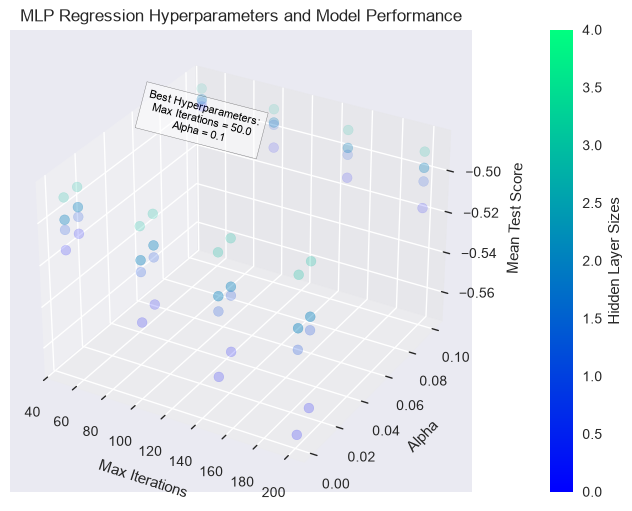

In [21]:
# Creating a 3D Scatter plot to visualise hyperparameters' performance
# for MLP Model 13 and corresponding Test Scores
# Creating a 3D figure
fig = plt.figure(figsize = (10, 6))
ax = fig.add_subplot(111, projection = '3d')
# From the grid search object, obtaining hyperparameters and corresponding scores
hidden_layer_sizes = grid_search_MLP_13.cv_results_['param_hidden_layer_sizes'].data
max_iter = grid_search_MLP_13.cv_results_['param_max_iter'].data.astype(float)
alpha = grid_search_MLP_13.cv_results_['param_alpha'].data.astype(float)
scores = grid_search_MLP_13.cv_results_['mean_test_score']
# Obtaining the best model's index
best_model_index = scores.argmax()
# Defining a colormap based on the 'hidden_layer_sizes' parameter
cmap = plt.get_cmap('winter')
norm = colors.Normalize(vmin = 0, vmax=len(set(hidden_layer_sizes)))
# Creating a colors list based on 'hidden_layer_sizes' parameter, where each color 
# correspond to the unique parameter's value (number of neurons in hidden layers)
point_colors = [cmap(norm(list(set(hidden_layer_sizes)).index(hls))) for hls in hidden_layer_sizes]
# Creating a scatter plot with the hyperparameters on the x (max_iter), y (alpha)
# and z (mean test score) axes, and the model performance as each point's size
ax.scatter(max_iter, alpha, scores, c = point_colors, alpha = 0.5, s = 50)
# Setting axes labels and title
ax.set_xlabel('Max Iterations', labelpad = 10)
ax.set_ylabel('Alpha', labelpad = 10)
ax.set_zlabel('Mean Test Score', labelpad = 10)
ax.set_title('MLP Regression Hyperparameters and Model Performance')
# Adding a colorbar for the 'hidden_layer_sizes' parameter
cb = fig.colorbar(cm.ScalarMappable(norm = norm, cmap = cmap), pad = 0.1, ax = ax)
cb.set_label('Hidden Layer Sizes')
# Adding text annotation for the best MLP model's hyperparameters
best_max_iter = max_iter[best_model_index]
best_alpha = alpha[best_model_index]
best_hidden_layer_sizes = hidden_layer_sizes[best_model_index]
ax.text(best_max_iter, best_alpha, scores[best_model_index],
        f"Best Hyperparameters:\nMax Iterations = {best_max_iter}\nAlpha = {best_alpha}",
        color = 'black', fontsize = 8, bbox = dict(facecolor = 'white', alpha = 0.5),
        zorder = 0, ha = 'center', va = 'top', zdir = 'x')
plt.show();

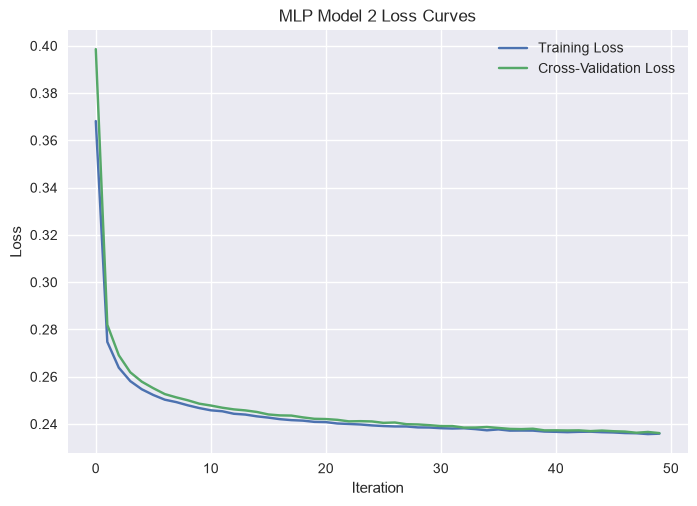

In [22]:
# Accessing the loss curve over all iterations for the training set
train_loss_curve = grid_search_MLP_13.best_estimator_.loss_curve_
# Accessing the loss curve over all iterations for the cv set
val_loss_curve = loss_curve_MLP_13
# Plotting the loss curves for training and cv sets
plt.plot(train_loss_curve, label = 'Training Loss')
plt.plot(val_loss_curve, label = 'Cross-Validation Loss')
# Adding labels, title, and legend
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model 2 Loss Curves')
plt.legend()
plt.show();

/var/folders/30/5ygxtbks68d9_2ftg_q1wr2m0000gn/T/ipykernel_48135/3391798326.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test_std.min(), y_test_std.max()],


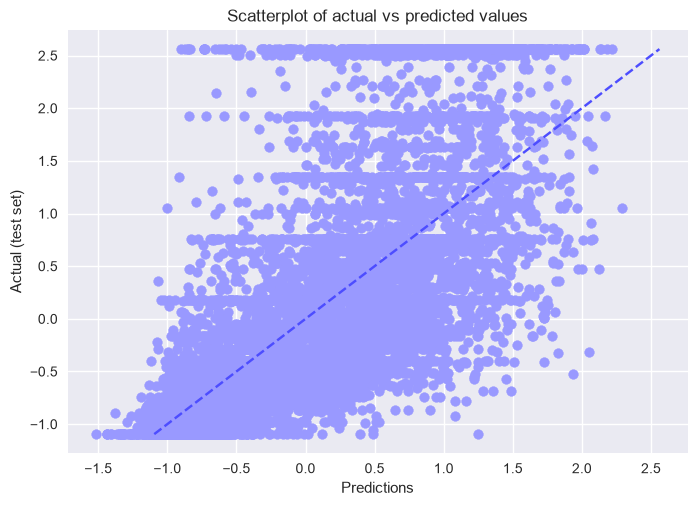

In [24]:
# plotting the scatter plot
#
plt.scatter(y_pred_MLP_13_test, y_test_std, color = '#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], 'k--', c = '#4d4dff')
#setting the axes labels and title
plt.xlabel('Predictions')
plt.ylabel('Actual (test set)')
plt.title('Scatterplot of actual vs predicted values')
plt.show();

# 5. Best Predictive Model

Overall, the fine-tuned XGBoost model (XGB_2) achieved the best test performance (R²=56.37%, MSE=0.44, MAE=0.46), narrowly ahead of the fine-tuned Random Forest (RF_3: R²=55.84%). Notably, RF_2 (cross-validated but without a full grid search) achieved nearly identical predictive performance (R²=55.13%) in under a third of RF_3's training time (6.76 vs. 17.70 minutes), suggesting limited marginal benefit from the additional grid search. Neural network models did not surpass the tree-based methods despite extensive tuning: MLP_13, tuned via grid search with cross-validation, required 413.92 minutes of training yet reached only R²=52.68%, still below every Random Forest and XGBoost variant, and barely ahead of the untuned MLP_3 (R²=51.12%, 0.29 minutes). This indicates that, for this dataset, tree-based ensemble methods offer a substantially better performance-to-cost trade-off than deep hyperparameter search over MLPs. Thus, going forward, Airbnb can adopt simpler tree-based models such as RF or XGBoost to obtain near-optimal results while saving considerable time and computational resources.

In [13]:
# Model performance: Iteration 2
#Ridge_2
print(f'R2 Ridge_2: {R2_Ridge_2_test * 100:.2f}%')
print(f'MSE Ridge_2: {MSE_Ridge_2_test:.2f}')
print(f'MAE Ridge_2: {MAE_Ridge_2_test:.2f}')
print(f'Total Training Time Ridge2: {total_training_time_Ridge_2/60:.2f} minutes\n')

R2 Ridge_2: 46.59%
MSE Ridge_2: 0.53
MAE Ridge_2: 0.53
Total Training Time Ridge2: 0.09 minutes



In [22]:
#RF_2
print(f'R2 RF_2: {R2_RF_2_test* 100:.2f}%')
print(f'MSE RF_2: {MSE_RF_2_test:.2f}')
print(f'MAE RF_2:  {MAE_RF_2_test:.2f}')
print(f'Training time RF_2: {total_training_time_RF_2/60:.2f} minutes\n')

R2 RF_2: 55.13%
MSE RF_2: 0.45
MAE RF_2:  0.47
Training time RF_2: 6.76 minutes



In [34]:
#RF_3
print(f'R2 RF_3: {R2_RF_3_test* 100:.2f}%')
print(f'MSE RF_3: {MSE_RF_3_test:.2f}')
print(f'MAE RF_3:  {MAE_RF_3_test:.2f}')
print(f'Training time RF_3: {total_training_time_RF_3/60:.2f} minutes\n')

R2 RF_3: 55.84%
MSE RF_3: 0.44
MAE RF_3:  0.47
Training time RF_3: 17.70 minutes



In [16]:
#XGB_2
print(f'R2 XGB_2: {R2_XGB_2_test * 100:.2f}%')
print(f'MSE XGB_2: {MSE_XGB_2_test:.2f}')
print(f'MAE XGB_2: {MAE_XGB_2_test:.2f}')
print(f'Training time XGB_2: {total_training_time_XGB_2/60:.2f} minutes\n')

R2 XGB_2: 56.37%
MSE XGB_2: 0.44
MAE XGB_2: 0.46
Training time XGB_2: 37.99 minutes



In [12]:
#MLP 9 Keras 
print(f'R2 MLP_9_Keras: {R2_MLP_Keras_9_test * 100:.2f}%')
print(f'MSE MLP_9_Keras: {MSE_MLP_Keras_9_test :.2f}')
print(f'MAE MLP_9_Keras: {MAE_MLP_Keras_9_test :.2f}')
print(f'Training time MLP_9_Keras: {elapsed_time_Keras_9/60:.2f} minutes\n')

R2 MLP_9_Keras: 42.30%
MSE MLP_9_Keras: 0.54
MAE MLP_9_Keras: 0.52
Training time MLP_9_Keras: 0.55 minutes



In [19]:
#MLP 10 Keras 
print(f'R2 MLP_10_Keras: {R2_MLP_Keras_10_test * 100:.2f}%')
print(f'MSE MLP_10_Keras: {MSE_MLP_Keras_10_test :.2f}')
print(f'MAE MLP_10_Keras: {MAE_MLP_Keras_10_test :.2f}')
print(f'Training time MLP_10_Keras: {elapsed_time_Keras_10/60:.2f} minutes\n')

R2 MLP_10_Keras: 46.96%
MSE MLP_10_Keras: 0.51
MAE MLP_10_Keras: 0.53
Training time MLP_10_Keras: 0.58 minutes



In [26]:
#MLP 11 Keras 
print(f'R2 MLP_11_Keras: {R2_MLP_keras_11_test * 100:.2f}%')
print(f'MSE MLP_11_Keras: {MSE_MLP_keras_11_test :.2f}')
print(f'MAE MLP_11_Keras: {MAE_MLP_keras_11_test :.2f}')
print(f'Training time MLP_11_Keras: {elapsed_time_keras_11/60:.2f} minutes\n')

R2 MLP_11_Keras: 49.18%
MSE MLP_11_Keras: 0.49
MAE MLP_11_Keras: 0.51
Training time MLP_11_Keras: 0.58 minutes



In [15]:
#MLP 12 Keras 
print(f'R2 MLP_12_Keras: {R2_MLP_keras_12_test * 100:.2f}%')
print(f'MSE MLP_12_Keras: {MSE_MLP_keras_12_test :.2f}')
print(f'MAE MLP_12_Keras: {MAE_MLP_keras_12_test :.2f}')
print(f'Training time MLP_12_Keras: {elapsed_time_keras_12/60:.2f} minutes\n')

R2 MLP_12_Keras: 49.68%
MSE MLP_12_Keras: 0.48
MAE MLP_12_Keras: 0.49
Training time MLP_12_Keras: 0.18 minutes



In [26]:
#MLP 13
print(f'R2 MLP_13: {R2_MLP_13_test * 100:.2f}%')
print(f'MSE MLP_13: {MSE_MLP_13_test:.2f}')
print(f'MAE MLP_13: {MAE_MLP_13_test:.2f}')
print(f'Training time MLP 13: {elapsed_time_MLP_13/60:.2f} minutes\n')

R2 MLP_13: 52.68%
MSE MLP_13: 0.47
MAE MLP_13: 0.49
Training time MLP 13: 413.92 minutes



# 6. References

Avanijaa, J. (2021). Prediction of house price using xgboost regression algorithm. Turkish https://www.businessofapps.com/data/airbnb-statistics/ (Accessed: March 1, 2026).

Goel, A.S. (2022).How does airbnb make money: Business model, How does Airbnb make

Li, Y. and Yang, T.(2018). Word embedding for understanding natural language: a survey. Guide

Pan, Q. and Wang, W. (2021). “Costly price adjustment and automated pricing: The case of airbnb,” SSRN Electronic Journal [Preprint]. Available at: https://doi.org/10.2139/ssrn.4077985.

optimisation of a multi-vector district energy system using artificial neural networks and a

and compression of deep neural networks. In ICASSP 2019-2019 IEEE International Conference

Segal, M.R. (2004). Machine learning benchmarks and random forest regression.

Srinivas, S. and Babu, R.V. (2015.) Data-free parameter pruning for deep neural networks. arXiv

Statista. (2022). Airbnb - statistics & facts. Statista. [online]. Available at: https://www.statista.com/topics/2273/airbnb/ (Accessed: March 19, 2026). Unpingco, J. (2016). Python for probability, statistics, and machine learning (Vol. 1). Springer

# 7. Appendix

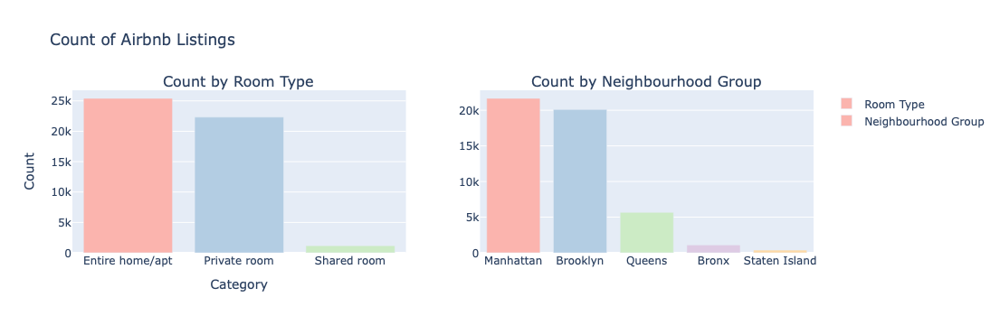

In [4]:
#Plotting the average price per room type and neighbourhood group using Plotly
import plotly.express as px
df = pd.read_csv('AB_NYC_2019.csv')
# Defining custom colors for each category
colors = px.colors.qualitative.Pastel1
# Calculating the count of each room type
room_type_counts = df['room_type'].value_counts()
# Calculating the count of each neighbourhood group
neighbourhood_group_counts = df['neighbourhood_group'].value_counts()
# Creating subplots
fig = make_subplots(rows = 1, cols = 2, subplot_titles = ("Count by Room Type", 
                                                    "Count by Neighbourhood Group"))
# Adding bar charts to subplots with custom colors
fig.add_trace(go.Bar(x = room_type_counts.index, y = room_type_counts.values, name = 'Room Type',
                     marker_color = colors), row = 1, col = 1)
fig.add_trace(go.Bar(x = neighbourhood_group_counts.index, 
                     y = neighbourhood_group_counts.values, name = 'Neighbourhood Group',
                     marker_color = colors), row = 1, col = 2)
# Setting title and labels for subplots
fig.update_layout(title = 'Count of Airbnb Listings', xaxis_title = 'Category',
                  yaxis_title = 'Count')
fig.show();

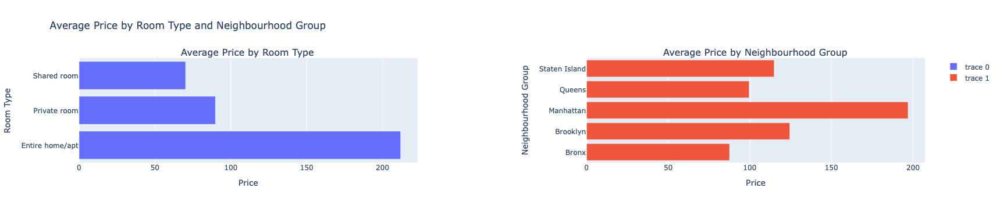

In [5]:
# Plotting the average price per neighbourhood group and room type in plotly
colors = px.colors.qualitative.Pastel1
# creating subplots with larger spacing
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=("Average Price by Room Type", "Average Price by Neighbourhood Group"),
                    horizontal_spacing=0.2)
# creating a horisontal bar chart for room types and mean prices
room_type_prices = df.groupby('room_type')['price'].mean()
fig.add_trace(go.Bar(x=room_type_prices.values, y=room_type_prices.index, orientation='h'), row=1, col=1)
fig.update_xaxes(title_text="Price", row=1, col=1)
fig.update_yaxes(title_text="Room Type", row=1, col=1)
# creating a horisontal bar chart for neighbourhood groups and mean prices
neighbourhood_prices = df.groupby('neighbourhood_group')['price'].mean()
fig.add_trace(go.Bar(x=neighbourhood_prices.values, y=neighbourhood_prices.index, orientation='h'), row=1, col=2)
fig.update_xaxes(title_text="Price", row=1, col=2)
fig.update_yaxes(title_text="Neighbourhood Group", row=1, col=2)
# setting the title for subplots
fig.update_layout(title='Average Price by Room Type and Neighbourhood Group', width=1000)
fig.show();

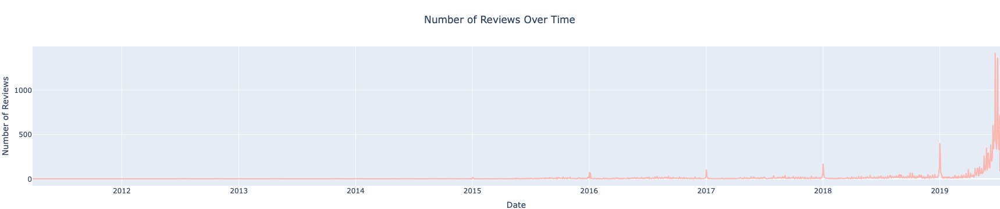

In [6]:
# number of reviews over time
# Converting the 'last_review' column to datetime format
# This will also be utilised later during the data transformation
df['last_review'] = pd.to_datetime(df['last_review'])
# Grouping the df by the 'last_review' column and counting # reviews
reviews_by_date = df.groupby('last_review').size().reset_index(name = 'num_reviews')
# Creating the time series plot using Plotly with a pastel color palette
fig = px.line(reviews_by_date, x='last_review', y='num_reviews',
              color_discrete_sequence=px.colors.qualitative.Pastel1)
fig.update_layout(title='Number of Reviews Over Time',
                  xaxis_title='Date',
                  yaxis_title='Number of Reviews',
                  title_x=0.5,
                  margin=dict(t=80, l=0, r=0, b=0))
# Showing the plot
fig.show();

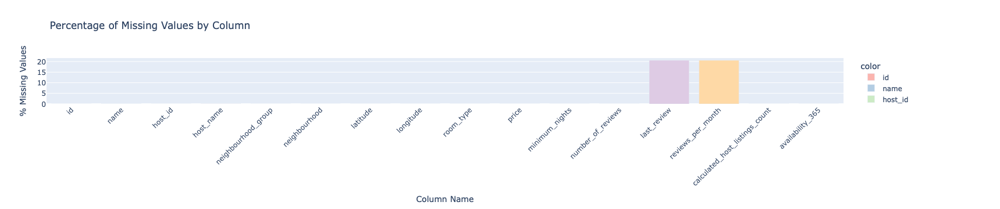

In [7]:
#Plotting Missing values using Plotly
#Calculating the percentage of missing values in each column
missing_vals = df.isnull().mean() * 100
#Creating a bar plot of missing values
fig = px.bar(
x=missing_vals.index,
y=missing_vals.values,
color=missing_vals.index,
color_discrete_sequence=px.colors.qualitative.Pastel1,
labels={'x':'Column Name', 'y':'% Missing Values'},
title='Percentage of Missing Values by Column'
)
#Setting x-axis labels to be angled for better readability
fig.update_xaxes(tickangle = -45)
#Showing the plot
fig.show();

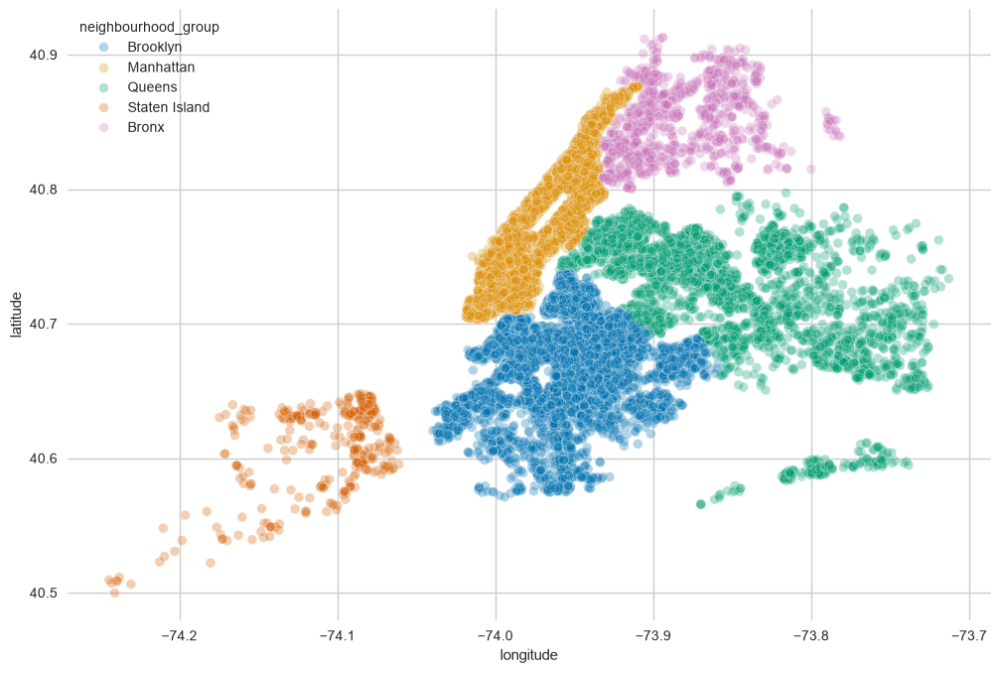

In [34]:
#plotting the neighbourhood groups by latitude and longitude
sns.set_style('whitegrid', {'axes.edgecolor': '0', 
                            'xtick.bottom': True, 
                            'ytick.left': True, 
                            'grid.color': '.8', 
                            'axes.facecolor': 'white'})
sns.set_palette('colorblind')
plt.figure(figsize = (12, 8))
sns.scatterplot(data = df, x = 'longitude', y = 'latitude',
                hue = df.neighbourhood_group, alpha = 0.3)
#turning the interactive mode off and showing the plot
plt.ioff();
plt.show();